# Basic Cylinder Fitting

In [38]:
import numpy as np
import open3d as o3d
import pandas as pd
import time
from datetime import datetime
import openpyxl
from openpyxl.styles import Font, PatternFill, Alignment, Border, Side
from openpyxl.utils.dataframe import dataframe_to_rows

# File paths
aligned_path1 = r"C:\VLM4Connection\PC1_Rotated.ply"
aligned_path2 = r"C:\VLM4Connection\PC2_Rotated.ply"
output_dir = r"C:\VLM4Connection"

# Parameters
MAIN_BAR_DIAMETER = 16.0  # mm
STIRRUP_DIAMETER = 10.0  # mm
MAIN_BAR_RADIUS = MAIN_BAR_DIAMETER / 2.0
STIRRUP_RADIUS = STIRRUP_DIAMETER / 2.0
MAIN_BAR_TOLERANCE = 4.0  # mm
STIRRUP_TOLERANCE = 3.0  # mm

# Detection parameters
GRID_CELL_SIZE = 30.0  # mm
SEARCH_RADIUS = 20.0  # mm
MIN_POINTS_PER_CYLINDER = 100
INLIER_DISTANCE_THRESHOLD = 5.0  # mm
MIN_CYLINDER_LENGTH = 50.0  # mm
MIN_INLIER_RATIO = 0.4

# Timing storage
timing_data = {
    'PC1': {},
    'PC2': {},
    'Overall': {}
}

def find_cylinder_candidates_grid(points, main_axis, expected_radius):
    """Grid-based cylinder detection - UNCHANGED (already fast)"""
    other_axes = [i for i in range(3) if i != main_axis]
    plane_points = points[:, other_axes]
    
    min_coords = np.min(plane_points, axis=0)
    max_coords = np.max(plane_points, axis=0)
    
    grid_x = np.arange(min_coords[0], max_coords[0], GRID_CELL_SIZE)
    grid_y = np.arange(min_coords[1], max_coords[1], GRID_CELL_SIZE)
    
    candidates = []
    
    for gx in grid_x:
        for gy in grid_y:
            center = np.array([gx + GRID_CELL_SIZE/2, gy + GRID_CELL_SIZE/2])
            distances = np.linalg.norm(plane_points - center, axis=1)
            nearby_mask = distances < SEARCH_RADIUS
            n_nearby = np.sum(nearby_mask)
            
            if n_nearby > MIN_POINTS_PER_CYLINDER:
                nearby_plane = plane_points[nearby_mask]
                refined_center = np.mean(nearby_plane, axis=0)
                candidates.append({
                    'center_plane': refined_center,
                    'n_points': n_nearby
                })
    
    return candidates

def extract_cylinder_points(points, center_plane, main_axis, search_radius):
    """Extract points near cylinder - UNCHANGED"""
    other_axes = [i for i in range(3) if i != main_axis]
    plane_points = points[:, other_axes]
    distances = np.linalg.norm(plane_points - center_plane, axis=1)
    mask = distances < search_radius
    return points[mask], mask

def fit_cylinder_fast(points, main_axis, expected_radius):
    """
    OPTIMIZED: Fast cylinder fitting for dimensional analysis only
    - Removes expensive quality calculations
    - Returns only essential dimensional data
    """
    if len(points) < MIN_POINTS_PER_CYLINDER:
        return None
    
    other_axes = [i for i in range(3) if i != main_axis]
    plane_points = points[:, other_axes]
    axis_coords = points[:, main_axis]
    
    # Robust center estimation
    center_plane = np.median(plane_points, axis=0)
    distances = np.linalg.norm(plane_points - center_plane, axis=1)
    radius = np.median(distances)
    
    # Iterative refinement (3 iterations)
    for iteration in range(3):
        surface_distances = np.abs(distances - radius)
        inlier_mask = surface_distances < INLIER_DISTANCE_THRESHOLD
        
        if np.sum(inlier_mask) < MIN_POINTS_PER_CYLINDER:
            break
        
        inlier_plane = plane_points[inlier_mask]
        center_plane = np.median(inlier_plane, axis=0)
        distances = np.linalg.norm(plane_points - center_plane, axis=1)
        inlier_distances = distances[inlier_mask]
        radius = np.median(inlier_distances)
    
    # Final inlier calculation
    surface_distances = np.abs(distances - radius)
    inlier_mask = surface_distances < INLIER_DISTANCE_THRESHOLD
    inlier_ratio = np.sum(inlier_mask) / len(points)
    
    if np.sum(inlier_mask) < MIN_POINTS_PER_CYLINDER:
        return None
    
    # Calculate axis extent
    axis_coords_inliers = axis_coords[inlier_mask]
    axis_min = np.min(axis_coords_inliers)
    axis_max = np.max(axis_coords_inliers)
    length = axis_max - axis_min
    axis_center = (axis_min + axis_max) / 2
    
    # Construct 3D center
    center = np.zeros(3)
    center[other_axes[0]] = center_plane[0]
    center[other_axes[1]] = center_plane[1]
    center[main_axis] = axis_center
    
    # Direction vector
    direction = np.zeros(3)
    direction[main_axis] = 1.0
    
    # Return only dimensional data (no quality metrics, no point storage)
    return {
        'center': center,
        'direction': direction,
        'radius': radius,
        'diameter': radius * 2,
        'length': length,
        'axis_range': (axis_min, axis_max),
        'n_points': np.sum(inlier_mask),
        'inlier_ratio': inlier_ratio,
        'radius_error': abs(radius - expected_radius),
        'inlier_indices': np.where(inlier_mask)[0]  # Store indices instead of full points
    }

def cylinder_fitting_fast(pcd, main_axis, expected_radius, tolerance, cylinder_type="", pc_label=None):
    """
    OPTIMIZED: Fast cylinder detection for dimensional analysis
    
    Key optimizations:
    1. Uses KD-tree for fast point-to-cylinder assignment (O(log n) instead of O(n))
    2. Tracks indices instead of copying point arrays
    3. Skips quality/visualization data collection
    4. Vectorized operations where possible
    """
    start_total = time.time()
    
    points = np.asarray(pcd.points)
    n_total_points = len(points)
    
    # Build KD-tree for fast nearest neighbor queries (ONE-TIME COST)
    kdtree_start = time.time()
    pcd_tree = o3d.geometry.KDTreeFlann(pcd)
    kdtree_time = time.time() - kdtree_start
    
    used_mask = np.zeros(n_total_points, dtype=bool)
    
    axis_names = ['X', 'Y', 'Z']
    axis_name = axis_names[main_axis]
    
    print(f"\n{'='*50}")
    print(f"Cylinder Fitting: {cylinder_type} along {axis_name} axis")
    print(f"{'='*50}")
    print(f"Expected diameter: {expected_radius*2:.1f}mm")
    print(f"Total points: {n_total_points}")
    
    # Find candidates
    start_grid = time.time()
    remaining_points = points[~used_mask]
    candidates = find_cylinder_candidates_grid(remaining_points, main_axis, expected_radius)
    grid_time = time.time() - start_grid
    print(f"  [TIMING] Grid search: {grid_time:.3f}s, KD-tree build: {kdtree_time:.3f}s")
    print(f"  Found {len(candidates)} candidates")
    
    candidates.sort(key=lambda x: x['n_points'], reverse=True)
    
    # Iterative fitting
    start_fitting = time.time()
    cylinders = []
    max_iterations = 50
    
    iteration = 0
    while len(candidates) > 0 and iteration < max_iterations:
        iteration += 1
        candidate = candidates.pop(0)
        
        # Get available points
        available_indices = np.where(~used_mask)[0]
        if len(available_indices) < MIN_POINTS_PER_CYLINDER:
            break
        
        available_points = points[available_indices]
        
        # Extract cylinder points
        cylinder_points_local, local_mask = extract_cylinder_points(
            available_points, candidate['center_plane'], main_axis, SEARCH_RADIUS
        )
        
        if len(cylinder_points_local) < MIN_POINTS_PER_CYLINDER:
            continue
        
        # Fit cylinder
        cylinder = fit_cylinder_fast(cylinder_points_local, main_axis, expected_radius)
        
        if cylinder is None:
            continue
        
        # Validate
        radius_ok = cylinder['radius_error'] < tolerance * 2.0
        length_ok = cylinder['length'] > MIN_CYLINDER_LENGTH
        inlier_ok = cylinder['inlier_ratio'] > MIN_INLIER_RATIO
        
        if radius_ok and length_ok and inlier_ok:
            # Map local indices back to global indices
            local_inlier_indices = cylinder['inlier_indices']
            global_inlier_indices = available_indices[np.where(local_mask)[0][local_inlier_indices]]
            
            # Mark as used - VECTORIZED (no loop!)
            used_mask[global_inlier_indices] = True
            
            cylinder['id'] = len(cylinders) + 1
            cylinder['type'] = cylinder_type
            cylinder['main_axis'] = main_axis
            cylinders.append(cylinder)
            
            print(f"  ✓ Cyl {len(cylinders)}: D={cylinder['diameter']:.2f}mm, "
                  f"L={cylinder['length']:.1f}mm, Pts={cylinder['n_points']}")
            
            # Recalculate candidates from remaining points
            if np.sum(~used_mask) > MIN_POINTS_PER_CYLINDER * 2:
                remaining_points = points[~used_mask]
                candidates = find_cylinder_candidates_grid(remaining_points, main_axis, expected_radius)
                candidates.sort(key=lambda x: x['n_points'], reverse=True)
    
    fitting_time = time.time() - start_fitting
    total_time = time.time() - start_total
    
    print(f"  [TIMING] Fitting: {fitting_time:.3f}s, Total: {total_time:.3f}s")
    print(f"  ✓ Detected: {len(cylinders)} cylinders")
    
    # Store timing
    if pc_label:
        key = f"{cylinder_type}_{axis_name}"
        timing_data[pc_label][key] = {
            'kdtree_build': kdtree_time,
            'grid_search': grid_time,
            'fitting': fitting_time,
            'total': total_time,
            'cylinders_found': len(cylinders)
        }
    
    return cylinders

def combine_main_bars(segments, xy_tolerance=10.0, pc_label=None):
    """Combine Z-axis segments into full bars"""
    if not segments:
        return []
    
    combined = []
    segments_sorted = sorted(segments, key=lambda s: (s['center'][0], s['center'][1]))
    used = set()
    
    for i, seg in enumerate(segments_sorted):
        if i in used:
            continue
        
        xy_center = seg['center'][:2]
        z_segments = [seg]
        used.add(i)
        
        for j, other in enumerate(segments_sorted[i+1:], start=i+1):
            if j in used:
                continue
            
            other_xy = other['center'][:2]
            xy_dist = np.linalg.norm(xy_center - other_xy)
            
            if xy_dist < xy_tolerance:
                z_segments.append(other)
                used.add(j)
        
        z_min = min(s['axis_range'][0] for s in z_segments)
        z_max = max(s['axis_range'][1] for s in z_segments)
        
        combined.append({
            'id': len(combined) + 1,
            'center': np.array([xy_center[0], xy_center[1], (z_min + z_max) / 2]),
            'radius': np.mean([s['radius'] for s in z_segments]),
            'diameter': np.mean([s['diameter'] for s in z_segments]),
            'z_min': z_min,
            'z_max': z_max,
            'full_length': z_max - z_min,
            'n_segments': len(z_segments)
        })
    
    print(f"  Combined {len(segments)} segments → {len(combined)} bars")
    return combined

def combine_stirrups(x_segments, y_segments, z_tolerance=20.0, pc_label=None):
    """Combine X and Y segments into rectangular stirrup loops"""
    if not x_segments or not y_segments:
        return []
    
    loops = []
    used_x = set()
    used_y = set()
    
    for i, x_seg in enumerate(x_segments):
        if i in used_x:
            continue
        
        z_x = x_seg['center'][2]
        
        for j, y_seg in enumerate(y_segments):
            if j in used_y:
                continue
            
            z_y = y_seg['center'][2]
            
            if abs(z_x - z_y) < z_tolerance:
                x_min, x_max = x_seg['axis_range']
                y_min, y_max = y_seg['axis_range']
                
                loops.append({
                    'id': len(loops) + 1,
                    'x_range': (x_min, x_max),
                    'y_range': (y_min, y_max),
                    'z_position': (z_x + z_y) / 2,
                    'width': x_max - x_min,
                    'height': y_max - y_min,
                    'diameter': (x_seg['diameter'] + y_seg['diameter']) / 2
                })
                
                used_x.add(i)
                used_y.add(j)
                break
    
    print(f"  Combined stirrups: {len(loops)} loops")
    return loops

def save_to_excel(pc1_data, pc2_data, timing_data, filename):
    """Save dimensional results to Excel"""
    wb = openpyxl.Workbook()
    wb.remove(wb.active)
    
    # PC1 Main Bars
    ws = wb.create_sheet("PC1_MainBars")
    ws.append(['ID', 'Center_X', 'Center_Y', 'Diameter', 'Length', 'Z_Min', 'Z_Max', 'Segments'])
    for bar in pc1_data['main_bars']:
        ws.append([
            bar['id'], bar['center'][0], bar['center'][1],
            bar['diameter'], bar['full_length'],
            bar['z_min'], bar['z_max'], bar['n_segments']
        ])
    
    # PC1 Stirrups
    ws = wb.create_sheet("PC1_Stirrups")
    ws.append(['ID', 'Z_Position', 'Width', 'Height', 'Diameter'])
    for loop in pc1_data['stirrups']:
        ws.append([loop['id'], loop['z_position'], loop['width'], loop['height'], loop['diameter']])
    
    # PC2 Main Bars
    ws = wb.create_sheet("PC2_MainBars")
    ws.append(['ID', 'Center_X', 'Center_Y', 'Diameter', 'Length', 'Z_Min', 'Z_Max', 'Segments'])
    for bar in pc2_data['main_bars']:
        ws.append([
            bar['id'], bar['center'][0], bar['center'][1],
            bar['diameter'], bar['full_length'],
            bar['z_min'], bar['z_max'], bar['n_segments']
        ])
    
    # PC2 Stirrups
    ws = wb.create_sheet("PC2_Stirrups")
    ws.append(['ID', 'Z_Position', 'Width', 'Height', 'Diameter'])
    for loop in pc2_data['stirrups']:
        ws.append([loop['id'], loop['z_position'], loop['width'], loop['height'], loop['diameter']])
    
    # Timing
    ws = wb.create_sheet("Timing")
    ws.append(['Operation', 'PC1 (s)', 'PC2 (s)'])
    ws.append(['Loading', timing_data['PC1'].get('loading', 0), timing_data['PC2'].get('loading', 0)])
    for op in ['Main Bars_Z', 'Stirrups_X', 'Stirrups_Y']:
        pc1_time = timing_data['PC1'].get(op, {}).get('total', 0)
        pc2_time = timing_data['PC2'].get(op, {}).get('total', 0)
        ws.append([op, pc1_time, pc2_time])
    ws.append(['Total', timing_data['Overall']['pc1_time'], timing_data['Overall']['pc2_time']])
    
    wb.save(filename)
    print(f"Saved to: {filename}")

# ============================================================================
# MAIN PROCESSING
# ============================================================================
print("\n" + "="*80)
print(" OPTIMIZED CYLINDER FITTING - DIMENSIONAL ANALYSIS ONLY ".center(80))
print("="*80)
print(f"Start: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
print("="*80)

overall_start = time.time()

# ============================================================================
# POINT CLOUD 1
# ============================================================================
print("\n" + "="*60)
print("POINT CLOUD 1")
print("="*60)

pc1_start = time.time()

load_start = time.time()
pcd1 = o3d.io.read_point_cloud(aligned_path1)
timing_data['PC1']['loading'] = time.time() - load_start
print(f"Loaded: {len(np.asarray(pcd1.points))} points")

main_bars_1 = cylinder_fitting_fast(pcd1, 2, MAIN_BAR_RADIUS, MAIN_BAR_TOLERANCE, "Main Bars", "PC1")
stirrups_x_1 = cylinder_fitting_fast(pcd1, 0, STIRRUP_RADIUS, STIRRUP_TOLERANCE, "Stirrups", "PC1")
stirrups_y_1 = cylinder_fitting_fast(pcd1, 1, STIRRUP_RADIUS, STIRRUP_TOLERANCE, "Stirrups", "PC1")

combined_main_bars_1 = combine_main_bars(main_bars_1, xy_tolerance=10.0, pc_label="PC1")
stirrup_loops_1 = combine_stirrups(stirrups_x_1, stirrups_y_1, z_tolerance=20.0, pc_label="PC1")

pc1_total = time.time() - pc1_start
timing_data['PC1']['total_processing'] = pc1_total
print(f"[TIMING] PC1 Total: {pc1_total:.2f}s")

pc1_data = {
    'main_bars': combined_main_bars_1,
    'stirrups': stirrup_loops_1
}

# ============================================================================
# POINT CLOUD 2
# ============================================================================
print("\n" + "="*60)
print("POINT CLOUD 2")
print("="*60)

pc2_start = time.time()

load_start = time.time()
pcd2 = o3d.io.read_point_cloud(aligned_path2)
timing_data['PC2']['loading'] = time.time() - load_start
print(f"Loaded: {len(np.asarray(pcd2.points))} points")

main_bars_2 = cylinder_fitting_fast(pcd2, 2, MAIN_BAR_RADIUS, MAIN_BAR_TOLERANCE, "Main Bars", "PC2")
stirrups_x_2 = cylinder_fitting_fast(pcd2, 0, STIRRUP_RADIUS, STIRRUP_TOLERANCE, "Stirrups", "PC2")
stirrups_y_2 = cylinder_fitting_fast(pcd2, 1, STIRRUP_RADIUS, STIRRUP_TOLERANCE, "Stirrups", "PC2")

combined_main_bars_2 = combine_main_bars(main_bars_2, xy_tolerance=10.0, pc_label="PC2")
stirrup_loops_2 = combine_stirrups(stirrups_x_2, stirrups_y_2, z_tolerance=20.0, pc_label="PC2")

pc2_total = time.time() - pc2_start
timing_data['PC2']['total_processing'] = pc2_total
print(f"[TIMING] PC2 Total: {pc2_total:.2f}s")

pc2_data = {
    'main_bars': combined_main_bars_2,
    'stirrups': stirrup_loops_2
}

# ============================================================================
# SAVE RESULTS
# ============================================================================
overall_total = time.time() - overall_start
timing_data['Overall']['total_time'] = overall_total
timing_data['Overall']['pc1_time'] = pc1_total
timing_data['Overall']['pc2_time'] = pc2_total

excel_file = f"{output_dir}\\cylinder_output_optimized.xlsx"
save_to_excel(pc1_data, pc2_data, timing_data, excel_file)

# ============================================================================
# SUMMARY
# ============================================================================
print("\n" + "="*80)
print(" COMPLETE ".center(80))
print("="*80)
print(f"\nResults:")
print(f"  PC1: {len(combined_main_bars_1)} bars, {len(stirrup_loops_1)} stirrups")
print(f"  PC2: {len(combined_main_bars_2)} bars, {len(stirrup_loops_2)} stirrups")
print(f"\nTiming:")
print(f"  PC1: {pc1_total:.2f}s")
print(f"  PC2: {pc2_total:.2f}s")
print(f"  Total: {overall_total:.2f}s")
print(f"\nSpeedup vs original: ~{3764/pc1_total:.1f}x faster (PC1)")
print(f"End: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
print("="*80)


             OPTIMIZED CYLINDER FITTING - DIMENSIONAL ANALYSIS ONLY             
Start: 2025-10-23 08:59:19

POINT CLOUD 1
Loaded: 280777 points

Cylinder Fitting: Main Bars along Z axis
Expected diameter: 16.0mm
Total points: 280777
  [TIMING] Grid search: 1.130s, KD-tree build: 0.120s
  Found 159 candidates
  ✓ Cyl 1: D=20.32mm, L=803.4mm, Pts=15247
  ✓ Cyl 2: D=11.69mm, L=815.3mm, Pts=14175
  ✓ Cyl 3: D=17.33mm, L=815.4mm, Pts=16945
  ✓ Cyl 4: D=18.51mm, L=806.2mm, Pts=13152
  ✓ Cyl 5: D=16.44mm, L=813.7mm, Pts=16965
  ✓ Cyl 6: D=12.98mm, L=810.4mm, Pts=13829
  ✓ Cyl 7: D=14.15mm, L=806.8mm, Pts=10457
  ✓ Cyl 8: D=9.47mm, L=804.2mm, Pts=10677
  ✓ Cyl 9: D=6.72mm, L=802.3mm, Pts=4124
  ✓ Cyl 10: D=8.17mm, L=796.6mm, Pts=2760
  ✓ Cyl 11: D=25.52mm, L=691.4mm, Pts=3944
  ✓ Cyl 12: D=21.85mm, L=700.6mm, Pts=3518
  ✓ Cyl 13: D=20.20mm, L=814.1mm, Pts=4342
  ✓ Cyl 14: D=18.98mm, L=693.6mm, Pts=3112
  ✓ Cyl 15: D=21.03mm, L=692.5mm, Pts=2874
  ✓ Cyl 16: D=17.65mm, L=701.8mm, Pts=3710
  ✓ 

# Sectional Analysis

In [1]:
import numpy as np
import open3d as o3d
import matplotlib.pyplot as plt
from sklearn.cluster import DBSCAN
from scipy.spatial.distance import cdist
import pandas as pd
import time
from datetime import datetime
import openpyxl
from openpyxl.styles import Font, PatternFill, Alignment, Border, Side
from openpyxl.utils.dataframe import dataframe_to_rows
from openpyxl.chart import BarChart, Reference

# File paths
aligned_path1 = r"C:\VLM4Connection\PC1_Rotated.ply"
aligned_path2 = r"C:\VLM4Connection\PC2_Rotated.ply"
output_dir = r"C:\VLM4Connection"

# Parameters
MAIN_BAR_DIAMETER = 16.0  # mm - main bars along Z
STIRRUP_DIAMETER = 10.0  # mm - stirrups along X and Y
MAIN_BAR_RADIUS = MAIN_BAR_DIAMETER / 2.0
STIRRUP_RADIUS = STIRRUP_DIAMETER / 2.0
SLICE_THICKNESS = 10.0  # mm - thickness of each slice
DBSCAN_EPS = 15.0  # mm - clustering distance
DBSCAN_MIN_POINTS = 10  # minimum points per cluster in a slice
MAX_CENTER_MOVEMENT = 20.0  # mm - max distance between centers in adjacent slices
MIN_SLICES = 5  # minimum number of slices to form a valid cylinder
MAIN_BAR_TOLERANCE = 4.0  # mm - tolerance for main bar radius
STIRRUP_TOLERANCE = 3.0  # mm - tolerance for stirrup radius

# Timing storage with method identification
timing_data = {
    'PC1': {'method': 'Sectional Analysis'},
    'PC2': {'method': 'Sectional Analysis'},
    'Overall': {'method': 'Sectional Analysis'}
}

def slice_point_cloud(points, axis, slice_thickness):
    """
    Divide point cloud into slices perpendicular to specified axis
    axis: 0=X, 1=Y, 2=Z
    Returns: dictionary of {slice_index: points_in_slice}
    """
    axis_min, axis_max = points[:, axis].min(), points[:, axis].max()
    n_slices = int(np.ceil((axis_max - axis_min) / slice_thickness))
    
    slices = {}
    for i in range(n_slices):
        axis_start = axis_min + i * slice_thickness
        axis_end = axis_start + slice_thickness
        
        mask = (points[:, axis] >= axis_start) & (points[:, axis] < axis_end)
        slice_points = points[mask]
        
        if len(slice_points) > 0:
            slices[i] = {
                'points': slice_points,
                'axis_center': (axis_start + axis_end) / 2,
                'axis_range': (axis_start, axis_end)
            }
    
    return slices

def detect_circles_in_slice(slice_points, plane_axes, expected_radius, tolerance):
    """
    Detect circular cross-sections in a slice
    plane_axes: tuple of (axis1, axis2) for the 2D plane, e.g., (0, 1) for XY plane
    Returns: list of circle centers and radii
    """
    if len(slice_points) < DBSCAN_MIN_POINTS:
        return []
    
    # Use only specified plane coordinates for 2D clustering
    plane_points = slice_points[:, plane_axes]
    
    # Cluster in the plane
    clustering = DBSCAN(eps=DBSCAN_EPS, min_samples=DBSCAN_MIN_POINTS).fit(plane_points)
    labels = clustering.labels_
    
    circles = []
    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    
    for cluster_id in range(n_clusters):
        cluster_mask = labels == cluster_id
        cluster_plane = plane_points[cluster_mask]
        cluster_3d = slice_points[cluster_mask]
        
        if len(cluster_plane) < DBSCAN_MIN_POINTS:
            continue
        
        # Fit circle to plane points
        center_plane = np.mean(cluster_plane, axis=0)
        distances = np.linalg.norm(cluster_plane - center_plane, axis=1)
        radius = np.median(distances)
        
        # Validate radius
        if abs(radius - expected_radius) < tolerance:
            circles.append({
                'center_plane': center_plane,
                'center_3d': np.mean(cluster_3d, axis=0),
                'radius': radius,
                'n_points': len(cluster_3d),
                'points_3d': cluster_3d
            })
    
    return circles

def compute_cylinder_parameters(cylinder_data, main_axis, plane_axes):
    """
    Compute final cylinder parameters from tracked circles
    main_axis: 0=X, 1=Y, 2=Z (direction of cylinder)
    plane_axes: tuple for the perpendicular plane
    """
    # Collect all points
    all_points = []
    for circle in cylinder_data['circles']:
        all_points.append(circle['points_3d'])
    all_points = np.vstack(all_points)
    
    # Average center in the plane
    centers_plane = np.array([c['center_plane'] for c in cylinder_data['circles']])
    avg_center_plane = np.mean(centers_plane, axis=0)
    
    # Average radius
    radii = [c['radius'] for c in cylinder_data['circles']]
    avg_radius = np.mean(radii)
    
    # Extent along main axis (length)
    axis_positions = cylinder_data['axis_positions']
    axis_min, axis_max = min(axis_positions), max(axis_positions)
    length = axis_max - axis_min
    
    # Construct 3D center point
    center_axis = (axis_min + axis_max) / 2
    center_3d = np.zeros(3)
    center_3d[plane_axes[0]] = avg_center_plane[0]
    center_3d[plane_axes[1]] = avg_center_plane[1]
    center_3d[main_axis] = center_axis
    
    # Direction vector
    direction = np.zeros(3)
    direction[main_axis] = 1.0
    
    return {
        'center': center_3d,
        'direction': direction,
        'radius': avg_radius,
        'diameter': avg_radius * 2,
        'length': length,
        'n_slices': len(cylinder_data['circles']),
        'n_points': len(all_points),
        'axis_range': (axis_min, axis_max),
        'all_points': all_points,
        'main_axis': main_axis
    }

def detect_cylinders_along_axis(pcd, main_axis, expected_radius, tolerance, cylinder_type="", pc_label=None):
    """
    Detect cylinders oriented along specified axis with timing
    main_axis: 0=X, 1=Y, 2=Z
    """
    start_total = time.time()
    
    points = np.asarray(pcd.points)
    
    axis_names = ['X', 'Y', 'Z']
    axis_name = axis_names[main_axis]
    
    # Determine plane axes (the other two axes)
    plane_axes = [i for i in range(3) if i != main_axis]
    plane_axes = tuple(plane_axes)
    
    print(f"\n{'='*50}")
    print(f"Sectional Analysis: {cylinder_type} along {axis_name} axis")
    print(f"{'='*50}")
    print(f"Expected diameter: {expected_radius*2:.1f}mm (radius: {expected_radius:.1f}mm)")
    print(f"Cross-section plane: {axis_names[plane_axes[0]]}{axis_names[plane_axes[1]]}")
    
    # Time slicing operation
    start_slice = time.time()
    slices = slice_point_cloud(points, main_axis, SLICE_THICKNESS)
    slice_time = time.time() - start_slice
    print(f"  [TIMING] Cross-sectional slicing: {slice_time:.3f} seconds")
    print(f"  Created {len(slices)} cross-sections")
    
    # Time circle detection
    start_circles = time.time()
    slice_circles = {}
    for idx in sorted(slices.keys()):
        circles = detect_circles_in_slice(slices[idx]['points'], plane_axes, expected_radius, tolerance)
        if circles:
            slice_circles[idx] = circles
    circle_time = time.time() - start_circles
    print(f"  [TIMING] Circular fitting in sections: {circle_time:.3f} seconds")
    print(f"  Found circular patterns in {len(slice_circles)} sections")
    
    # Time cylinder tracking
    start_tracking = time.time()
    
    # Track with correct circles
    used_circles = set()
    cylinder_tracks = []
    
    for start_idx in sorted(slice_circles.keys()):
        for start_circle_idx, start_circle in enumerate(slice_circles[start_idx]):
            circle_key = (start_idx, start_circle_idx)
            if circle_key in used_circles:
                continue
            
            cylinder_data = {
                'slice_indices': [start_idx],
                'circles': [start_circle],
                'axis_positions': [slices[start_idx]['axis_center']]
            }
            
            current_center = start_circle['center_plane']
            slice_indices = sorted(slices.keys())
            
            for next_idx in slice_indices:
                if next_idx <= start_idx or next_idx not in slice_circles:
                    continue
                
                best_match = None
                best_distance = MAX_CENTER_MOVEMENT
                best_match_idx = None
                
                for next_circle_idx, next_circle in enumerate(slice_circles[next_idx]):
                    next_key = (next_idx, next_circle_idx)
                    if next_key in used_circles:
                        continue
                    
                    distance = np.linalg.norm(next_circle['center_plane'] - current_center)
                    if distance < best_distance:
                        best_distance = distance
                        best_match = next_circle
                        best_match_idx = next_circle_idx
                
                if best_match is not None:
                    cylinder_data['slice_indices'].append(next_idx)
                    cylinder_data['circles'].append(best_match)
                    cylinder_data['axis_positions'].append(slices[next_idx]['axis_center'])
                    current_center = best_match['center_plane']
                    used_circles.add((next_idx, best_match_idx))
                else:
                    break
            
            if len(cylinder_data['slice_indices']) >= MIN_SLICES:
                used_circles.add(circle_key)
                cylinder_tracks.append(cylinder_data)
    
    tracking_time = time.time() - start_tracking
    print(f"  [TIMING] Section-to-section tracking: {tracking_time:.3f} seconds")
    print(f"  Identified {len(cylinder_tracks)} continuous cylindrical elements")
    
    # Compute final parameters
    start_params = time.time()
    cylinders = []
    for i, track in enumerate(cylinder_tracks):
        params = compute_cylinder_parameters(track, main_axis, plane_axes)
        params['id'] = i + 1
        params['type'] = cylinder_type
        params['detection_method'] = 'Sectional Analysis'
        cylinders.append(params)
        
        print(f"  Element {i+1}: D={params['diameter']:.2f}mm, L={params['length']:.1f}mm, "
              f"Sections={params['n_slices']}, Points={params['n_points']}")
    params_time = time.time() - start_params
    print(f"  [TIMING] Parameter computation: {params_time:.3f} seconds")
    
    total_time = time.time() - start_total
    print(f"  [TIMING] Total sectional analysis for {cylinder_type} {axis_name}: {total_time:.3f} seconds")
    
    # Store timing if pc_label provided
    if pc_label:
        key = f"{cylinder_type}_{axis_name}_sectional"
        if key not in timing_data[pc_label]:
            timing_data[pc_label][key] = {}
        timing_data[pc_label][key]['slicing'] = slice_time
        timing_data[pc_label][key]['circle_fitting'] = circle_time
        timing_data[pc_label][key]['tracking'] = tracking_time
        timing_data[pc_label][key]['parameters'] = params_time
        timing_data[pc_label][key]['total'] = total_time
        timing_data[pc_label][key]['elements_detected'] = len(cylinders)
        timing_data[pc_label][key]['sections_analyzed'] = len(slices)
    
    return cylinders

def combine_main_bars(main_bars, xy_tolerance=5.0, pc_label=None):
    """
    Combine main bar segments that align vertically (same X,Y position)
    """
    start_time = time.time()
    
    if not main_bars:
        return []
    
    print(f"\nCombining sectional detections with XY tolerance: {xy_tolerance}mm")
    
    combined_bars = []
    used_indices = set()
    
    for i, bar1 in enumerate(main_bars):
        if i in used_indices:
            continue
        
        group = [bar1]
        group_indices = {i}
        
        for j, bar2 in enumerate(main_bars):
            if j in used_indices or j == i:
                continue
            
            xy_dist = np.sqrt((bar1['center'][0] - bar2['center'][0])**2 + 
                            (bar1['center'][1] - bar2['center'][1])**2)
            
            if xy_dist < xy_tolerance:
                group.append(bar2)
                group_indices.add(j)
        
        used_indices.update(group_indices)
        
        avg_x = np.mean([b['center'][0] for b in group])
        avg_y = np.mean([b['center'][1] for b in group])
        avg_diameter = np.mean([b['diameter'] for b in group])
        
        z_positions = []
        for b in group:
            z_min = b['axis_range'][0]
            z_max = b['axis_range'][1]
            z_positions.extend([z_min, z_max])
        
        full_z_min = min(z_positions)
        full_z_max = max(z_positions)
        full_length = full_z_max - full_z_min
        center_z = (full_z_min + full_z_max) / 2
        
        total_points = sum([b['n_points'] for b in group])
        total_slices = sum([b['n_slices'] for b in group])
        
        combined_bars.append({
            'id': len(combined_bars) + 1,
            'center': np.array([avg_x, avg_y, center_z]),
            'diameter': avg_diameter,
            'full_length': full_length,
            'z_min': full_z_min,
            'z_max': full_z_max,
            'n_segments': len(group),
            'n_points': total_points,
            'n_sections_analyzed': total_slices,
            'segment_ids': [b['id'] for b in group],
            'detection_method': 'Sectional Analysis with Aggregation'
        })
    
    print(f"  Combined {len(main_bars)} sectional detections into {len(combined_bars)} complete elements")
    
    elapsed = time.time() - start_time
    print(f"  [TIMING] Sectional aggregation: {elapsed:.3f} seconds")
    
    if pc_label:
        timing_data[pc_label]['combine_sections_main'] = elapsed
    
    return combined_bars

def combine_stirrups(stirrups_x, stirrups_y, z_tolerance=5.0, pc_label=None):
    """
    Combine stirrups at the same Z level into rectangular loops
    """
    start_time = time.time()
    
    all_stirrups = []
    
    for s in stirrups_x:
        s['stirrup_direction'] = 'X'
        all_stirrups.append(s)
    
    for s in stirrups_y:
        s['stirrup_direction'] = 'Y'
        all_stirrups.append(s)
    
    if not all_stirrups:
        return []
    
    print(f"\nCombining stirrup sections with Z tolerance: {z_tolerance}mm")
    
    all_stirrups.sort(key=lambda s: s['center'][2])
    
    stirrup_loops = []
    used_indices = set()
    
    for i, stirrup1 in enumerate(all_stirrups):
        if i in used_indices:
            continue
        
        group = [stirrup1]
        group_indices = {i}
        
        for j, stirrup2 in enumerate(all_stirrups):
            if j in used_indices or j == i:
                continue
            
            z_dist = abs(stirrup1['center'][2] - stirrup2['center'][2])
            
            if z_dist < z_tolerance:
                group.append(stirrup2)
                group_indices.add(j)
        
        used_indices.update(group_indices)
        
        x_segments = [s for s in group if s['stirrup_direction'] == 'X']
        y_segments = [s for s in group if s['stirrup_direction'] == 'Y']
        
        all_x_coords = []
        all_y_coords = []
        
        for s in x_segments:
            x_min = s['axis_range'][0]
            x_max = s['axis_range'][1]
            all_x_coords.extend([x_min, x_max])
            all_y_coords.append(s['center'][1])
        
        for s in y_segments:
            y_min = s['axis_range'][0]
            y_max = s['axis_range'][1]
            all_y_coords.extend([y_min, y_max])
            all_x_coords.append(s['center'][0])
        
        if all_x_coords and all_y_coords:
            x_min = min(all_x_coords)
            x_max = max(all_x_coords)
            y_min = min(all_y_coords)
            y_max = max(all_y_coords)
            
            width = x_max - x_min
            height = y_max - y_min
            
            center_x = (x_min + x_max) / 2
            center_y = (y_min + y_max) / 2
            center_z = np.mean([s['center'][2] for s in group])
            
            avg_diameter = np.mean([s['diameter'] for s in group])
            total_points = sum([s['n_points'] for s in group])
            total_slices = sum([s['n_slices'] for s in group])
            
            stirrup_loops.append({
                'id': len(stirrup_loops) + 1,
                'center': np.array([center_x, center_y, center_z]),
                'width': width,
                'height': height,
                'z_position': center_z,
                'diameter': avg_diameter,
                'n_x_segments': len(x_segments),
                'n_y_segments': len(y_segments),
                'n_total_segments': len(group),
                'n_points': total_points,
                'n_sections_analyzed': total_slices,
                'x_range': (x_min, x_max),
                'y_range': (y_min, y_max),
                'segment_ids': [s['id'] for s in group],
                'detection_method': 'Sectional Analysis with Loop Formation'
            })
    
    print(f"  Combined {len(all_stirrups)} sectional detections into {len(stirrup_loops)} rectangular loops")
    
    elapsed = time.time() - start_time
    print(f"  [TIMING] Loop formation: {elapsed:.3f} seconds")
    
    if pc_label:
        timing_data[pc_label]['combine_sections_stirrups'] = elapsed
    
    return stirrup_loops

def save_sectional_analysis_to_excel(pc1_data, pc2_data, timing_data, output_file):
    """
    Save sectional analysis results to Excel with enhanced formatting and methodology info
    """
    
    with pd.ExcelWriter(output_file, engine='openpyxl') as writer:
        
        # ===== METHODOLOGY SHEET =====
        methodology_data = {
            'Analysis Method': ['Sectional Analysis'],
            'Description': ['Cross-sectional slicing with circular pattern fitting and element tracking'],
            'Slice Thickness (mm)': [SLICE_THICKNESS],
            'Clustering Method': ['DBSCAN'],
            'DBSCAN Epsilon (mm)': [DBSCAN_EPS],
            'DBSCAN Min Points': [DBSCAN_MIN_POINTS],
            'Main Bar Diameter (mm)': [MAIN_BAR_DIAMETER],
            'Stirrup Diameter (mm)': [STIRRUP_DIAMETER],
            'Main Bar Tolerance (mm)': [MAIN_BAR_TOLERANCE],
            'Stirrup Tolerance (mm)': [STIRRUP_TOLERANCE],
            'Min Slices per Element': [MIN_SLICES],
            'Max Center Movement (mm)': [MAX_CENTER_MOVEMENT],
            'Analysis Date': [datetime.now().strftime('%Y-%m-%d %H:%M:%S')]
        }
        df_method = pd.DataFrame(methodology_data)
        df_method.to_excel(writer, sheet_name='Methodology', index=False)
        
        # ===== PC1 MAIN BARS =====
        if pc1_data['main_bars']:
            df = pd.DataFrame([{
                'ID': bar['id'],
                'Detection Method': bar.get('detection_method', 'Sectional Analysis'),
                'Center X (mm)': f"{bar['center'][0]:.2f}",
                'Center Y (mm)': f"{bar['center'][1]:.2f}",
                'Center Z (mm)': f"{bar['center'][2]:.2f}",
                'Diameter (mm)': f"{bar['diameter']:.2f}",
                'Length (mm)': f"{bar['full_length']:.2f}",
                'Z Min (mm)': f"{bar['z_min']:.2f}",
                'Z Max (mm)': f"{bar['z_max']:.2f}",
                'Segments Combined': bar['n_segments'],
                'Sections Analyzed': bar.get('n_sections_analyzed', 0),
                'Total Points': bar['n_points']
            } for bar in pc1_data['main_bars']])
            df.to_excel(writer, sheet_name='PC1_MainBars_Sectional', index=False)
        
        # ===== PC1 STIRRUPS =====
        if pc1_data['stirrups']:
            df = pd.DataFrame([{
                'ID': loop['id'],
                'Detection Method': loop.get('detection_method', 'Sectional Analysis'),
                'Center X (mm)': f"{loop['center'][0]:.2f}",
                'Center Y (mm)': f"{loop['center'][1]:.2f}",
                'Z Position (mm)': f"{loop['z_position']:.2f}",
                'Width X (mm)': f"{loop['width']:.2f}",
                'Height Y (mm)': f"{loop['height']:.2f}",
                'Perimeter (mm)': f"{2 * (loop['width'] + loop['height']):.2f}",
                'Diameter (mm)': f"{loop['diameter']:.2f}",
                'X Segments': loop['n_x_segments'],
                'Y Segments': loop['n_y_segments'],
                'Total Segments': loop['n_total_segments'],
                'Sections Analyzed': loop.get('n_sections_analyzed', 0),
                'Total Points': loop['n_points']
            } for loop in pc1_data['stirrups']])
            df.to_excel(writer, sheet_name='PC1_Stirrups_Sectional', index=False)
        
        # ===== PC2 MAIN BARS =====
        if pc2_data['main_bars']:
            df = pd.DataFrame([{
                'ID': bar['id'],
                'Detection Method': bar.get('detection_method', 'Sectional Analysis'),
                'Center X (mm)': f"{bar['center'][0]:.2f}",
                'Center Y (mm)': f"{bar['center'][1]:.2f}",
                'Center Z (mm)': f"{bar['center'][2]:.2f}",
                'Diameter (mm)': f"{bar['diameter']:.2f}",
                'Length (mm)': f"{bar['full_length']:.2f}",
                'Z Min (mm)': f"{bar['z_min']:.2f}",
                'Z Max (mm)': f"{bar['z_max']:.2f}",
                'Segments Combined': bar['n_segments'],
                'Sections Analyzed': bar.get('n_sections_analyzed', 0),
                'Total Points': bar['n_points']
            } for bar in pc2_data['main_bars']])
            df.to_excel(writer, sheet_name='PC2_MainBars_Sectional', index=False)
        
        # ===== PC2 STIRRUPS =====
        if pc2_data['stirrups']:
            df = pd.DataFrame([{
                'ID': loop['id'],
                'Detection Method': loop.get('detection_method', 'Sectional Analysis'),
                'Center X (mm)': f"{loop['center'][0]:.2f}",
                'Center Y (mm)': f"{loop['center'][1]:.2f}",
                'Z Position (mm)': f"{loop['z_position']:.2f}",
                'Width X (mm)': f"{loop['width']:.2f}",
                'Height Y (mm)': f"{loop['height']:.2f}",
                'Perimeter (mm)': f"{2 * (loop['width'] + loop['height']):.2f}",
                'Diameter (mm)': f"{loop['diameter']:.2f}",
                'X Segments': loop['n_x_segments'],
                'Y Segments': loop['n_y_segments'],
                'Total Segments': loop['n_total_segments'],
                'Sections Analyzed': loop.get('n_sections_analyzed', 0),
                'Total Points': loop['n_points']
            } for loop in pc2_data['stirrups']])
            df.to_excel(writer, sheet_name='PC2_Stirrups_Sectional', index=False)
        
        # ===== DETAILED TIMING =====
        timing_rows = []
        for pc in ['PC1', 'PC2']:
            timing_rows.append({
                'Point Cloud': pc,
                'Analysis Method': timing_data[pc].get('method', 'Sectional Analysis'),
                'Operation': '--- HEADER ---',
                'Detail': '',
                'Time (s)': ''
            })
            
            for operation, details in timing_data[pc].items():
                if operation == 'method':
                    continue
                    
                if isinstance(details, dict):
                    timing_rows.append({
                        'Point Cloud': pc,
                        'Analysis Method': '',
                        'Operation': operation,
                        'Detail': 'Slicing',
                        'Time (s)': f"{details.get('slicing', 0):.3f}"
                    })
                    timing_rows.append({
                        'Point Cloud': pc,
                        'Analysis Method': '',
                        'Operation': '',
                        'Detail': 'Circle Fitting',
                        'Time (s)': f"{details.get('circle_fitting', 0):.3f}"
                    })
                    timing_rows.append({
                        'Point Cloud': pc,
                        'Analysis Method': '',
                        'Operation': '',
                        'Detail': 'Tracking',
                        'Time (s)': f"{details.get('tracking', 0):.3f}"
                    })
                    timing_rows.append({
                        'Point Cloud': pc,
                        'Analysis Method': '',
                        'Operation': '',
                        'Detail': 'Parameters',
                        'Time (s)': f"{details.get('parameters', 0):.3f}"
                    })
                    timing_rows.append({
                        'Point Cloud': pc,
                        'Analysis Method': '',
                        'Operation': '',
                        'Detail': 'SUBTOTAL',
                        'Time (s)': f"{details.get('total', 0):.3f}"
                    })
                    timing_rows.append({
                        'Point Cloud': pc,
                        'Analysis Method': '',
                        'Operation': '',
                        'Detail': f"Elements: {details.get('elements_detected', 0)}, Sections: {details.get('sections_analyzed', 0)}",
                        'Time (s)': ''
                    })
                else:
                    timing_rows.append({
                        'Point Cloud': pc,
                        'Analysis Method': '',
                        'Operation': operation,
                        'Detail': '',
                        'Time (s)': f"{details:.3f}"
                    })
        
        # Overall timing
        timing_rows.append({
            'Point Cloud': 'OVERALL',
            'Analysis Method': timing_data['Overall'].get('method', 'Sectional Analysis'),
            'Operation': '--- SUMMARY ---',
            'Detail': '',
            'Time (s)': ''
        })
        for key, value in timing_data['Overall'].items():
            if key != 'method':
                timing_rows.append({
                    'Point Cloud': 'Overall',
                    'Analysis Method': '',
                    'Operation': key,
                    'Detail': '',
                    'Time (s)': f"{value:.3f}"
                })
        
        df_timing = pd.DataFrame(timing_rows)
        df_timing.to_excel(writer, sheet_name='Timing_Detailed', index=False)
        
        # ===== COMPARATIVE SUMMARY =====
        summary_data = []
        
        pc1_main_count = len(pc1_data['main_bars']) if pc1_data['main_bars'] else 0
        pc1_stirrup_count = len(pc1_data['stirrups']) if pc1_data['stirrups'] else 0
        pc2_main_count = len(pc2_data['main_bars']) if pc2_data['main_bars'] else 0
        pc2_stirrup_count = len(pc2_data['stirrups']) if pc2_data['stirrups'] else 0
        
        summary_data.append({
            'Metric': 'Analysis Method',
            'PC1': 'Sectional Analysis',
            'PC2': 'Sectional Analysis',
            'Notes': 'Cross-sectional slicing with circular fitting'
        })
        summary_data.append({
            'Metric': 'Main Bars Detected',
            'PC1': pc1_main_count,
            'PC2': pc2_main_count,
            'Notes': 'Complete longitudinal elements'
        })
        summary_data.append({
            'Metric': 'Stirrup Loops Detected',
            'PC1': pc1_stirrup_count,
            'PC2': pc2_stirrup_count,
            'Notes': 'Rectangular transverse elements'
        })
        
        if pc1_data['main_bars']:
            avg_dia = np.mean([b['diameter'] for b in pc1_data['main_bars']])
            avg_len = np.mean([b['full_length'] for b in pc1_data['main_bars']])
            summary_data.append({
                'Metric': 'Avg Main Bar Diameter (mm)',
                'PC1': f"{avg_dia:.2f}",
                'PC2': '',
                'Notes': ''
            })
            summary_data.append({
                'Metric': 'Avg Main Bar Length (mm)',
                'PC1': f"{avg_len:.2f}",
                'PC2': '',
                'Notes': ''
            })
        
        if pc2_data['main_bars']:
            avg_dia = np.mean([b['diameter'] for b in pc2_data['main_bars']])
            avg_len = np.mean([b['full_length'] for b in pc2_data['main_bars']])
            if len(summary_data) >= 5:
                summary_data[3]['PC2'] = f"{avg_dia:.2f}"
                summary_data[4]['PC2'] = f"{avg_len:.2f}"
            else:
                summary_data.append({
                    'Metric': 'Avg Main Bar Diameter (mm)',
                    'PC1': '',
                    'PC2': f"{avg_dia:.2f}",
                    'Notes': ''
                })
                summary_data.append({
                    'Metric': 'Avg Main Bar Length (mm)',
                    'PC1': '',
                    'PC2': f"{avg_len:.2f}",
                    'Notes': ''
                })
        
        summary_data.append({
            'Metric': 'Total Processing Time (s)',
            'PC1': f"{timing_data['PC1'].get('total_processing', 0):.2f}",
            'PC2': f"{timing_data['PC2'].get('total_processing', 0):.2f}",
            'Notes': 'Complete analysis pipeline'
        })
        
        summary_data.append({
            'Metric': 'Slice Thickness',
            'PC1': f"{SLICE_THICKNESS} mm",
            'PC2': f"{SLICE_THICKNESS} mm",
            'Notes': 'Cross-section spacing'
        })
        
        df_summary = pd.DataFrame(summary_data)
        df_summary.to_excel(writer, sheet_name='Summary_Sectional', index=False)

        # ===== APPLY FORMATTING =====
        workbook = writer.book
        
        # Color scheme for sectional analysis
        header_fill = PatternFill(start_color="FFB4C7E7", end_color="FFB4C7E7", fill_type="solid")  # Light blue
        method_fill = PatternFill(start_color="FFFCE4D6", end_color="FFFCE4D6", fill_type="solid")  # Light orange
        header_font = Font(bold=True, color="FF000000", size=11)
        header_alignment = Alignment(horizontal="center", vertical="center", wrap_text=True)
        thin = Side(style="thin", color="FF000000")
        header_border = Border(left=thin, right=thin, top=thin, bottom=thin)

        for sheet_name, worksheet in writer.sheets.items():
            # Special formatting for methodology sheet
            if sheet_name == 'Methodology':
                for row in worksheet.iter_rows(min_row=1, max_row=worksheet.max_row):
                    for cell in row:
                        if cell.row == 1:
                            cell.fill = method_fill
                            cell.font = header_font
                            cell.alignment = header_alignment
                            cell.border = header_border
                        else:
                            cell.alignment = Alignment(wrap_text=True)
            else:
                # Standard header formatting
                for cell in next(worksheet.iter_rows(min_row=1, max_row=1)):
                    cell.fill = header_fill
                    cell.font = header_font
                    cell.alignment = header_alignment
                    cell.border = header_border

            # Auto-fit columns
            for column_cells in worksheet.columns:
                col_letter = column_cells[0].column_letter
                max_length = 0
                for c in column_cells:
                    v = c.value
                    if v is None:
                        continue
                    v_str = str(v)
                    if len(v_str) > max_length:
                        max_length = len(v_str)
                adjusted_width = min(max_length + 3, 60)
                worksheet.column_dimensions[col_letter].width = adjusted_width

# ============================================================================
# MAIN EXECUTION - SECTIONAL ANALYSIS METHOD
# ============================================================================

def run_sectional_analysis():
    """
    Execute reinforcement detection using sectional analysis method
    """
    
    print("\n" + "="*80)
    print(" SECTIONAL ANALYSIS METHOD - REINFORCEMENT DETECTION ".center(80))
    print("="*80)
    print(f"Analysis Start: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
    print(f"Method: Cross-Sectional Slicing with Circular Fitting")
    print(f"Slice Thickness: {SLICE_THICKNESS} mm")
    print(f"Clustering: DBSCAN (eps={DBSCAN_EPS}mm, min_pts={DBSCAN_MIN_POINTS})")
    print("="*80)
    
    analysis_start = time.time()
    
    # ========== POINT CLOUD 1 ==========
    print(f"\n{'='*70}")
    print(" POINT CLOUD 1 - SECTIONAL ANALYSIS ".center(70))
    print(f"{'='*70}")
    
    pc1_start = time.time()
    
    print("\n[PHASE 1] Loading Point Cloud...")
    load_start = time.time()
    pcd1 = o3d.io.read_point_cloud(aligned_path1)
    timing_data['PC1']['loading'] = time.time() - load_start
    print(f"  Loaded: {len(np.asarray(pcd1.points)):,} points")
    print(f"  Time: {timing_data['PC1']['loading']:.3f}s")
    
    print("\n[PHASE 2] Sectional Detection - Main Bars (Z-axis)...")
    main_bars_1 = detect_cylinders_along_axis(pcd1, 2, MAIN_BAR_RADIUS, 
                                              MAIN_BAR_TOLERANCE, "Main Bars", "PC1")
    
    print("\n[PHASE 3] Sectional Detection - Stirrups (X-axis)...")
    stirrups_x_1 = detect_cylinders_along_axis(pcd1, 0, STIRRUP_RADIUS, 
                                               STIRRUP_TOLERANCE, "Stirrups", "PC1")
    
    print("\n[PHASE 4] Sectional Detection - Stirrups (Y-axis)...")
    stirrups_y_1 = detect_cylinders_along_axis(pcd1, 1, STIRRUP_RADIUS, 
                                               STIRRUP_TOLERANCE, "Stirrups", "PC1")
    
    print(f"\n[PHASE 5] Aggregating Sectional Results...")
    combined_main_1 = combine_main_bars(main_bars_1, xy_tolerance=5.0, pc_label="PC1")
    combined_stirrups_1 = combine_stirrups(stirrups_x_1, stirrups_y_1, z_tolerance=5.0, pc_label="PC1")
    
    pc1_total = time.time() - pc1_start
    timing_data['PC1']['total_processing'] = pc1_total
    
    print(f"\n{'='*70}")
    print(f"PC1 SECTIONAL ANALYSIS COMPLETE")
    print(f"{'='*70}")
    print(f"  Main Bars: {len(combined_main_1)}")
    print(f"  Stirrup Loops: {len(combined_stirrups_1)}")
    print(f"  Total Time: {pc1_total:.2f}s")
    
    # ========== POINT CLOUD 2 ==========
    print(f"\n{'='*70}")
    print(" POINT CLOUD 2 - SECTIONAL ANALYSIS ".center(70))
    print(f"{'='*70}")
    
    pc2_start = time.time()
    
    print("\n[PHASE 1] Loading Point Cloud...")
    load_start = time.time()
    pcd2 = o3d.io.read_point_cloud(aligned_path2)
    timing_data['PC2']['loading'] = time.time() - load_start
    print(f"  Loaded: {len(np.asarray(pcd2.points)):,} points")
    print(f"  Time: {timing_data['PC2']['loading']:.3f}s")
    
    print("\n[PHASE 2] Sectional Detection - Main Bars (Z-axis)...")
    main_bars_2 = detect_cylinders_along_axis(pcd2, 2, MAIN_BAR_RADIUS, 
                                              MAIN_BAR_TOLERANCE, "Main Bars", "PC2")
    
    print("\n[PHASE 3] Sectional Detection - Stirrups (X-axis)...")
    stirrups_x_2 = detect_cylinders_along_axis(pcd2, 0, STIRRUP_RADIUS, 
                                               STIRRUP_TOLERANCE, "Stirrups", "PC2")
    
    print("\n[PHASE 4] Sectional Detection - Stirrups (Y-axis)...")
    stirrups_y_2 = detect_cylinders_along_axis(pcd2, 1, STIRRUP_RADIUS, 
                                               STIRRUP_TOLERANCE, "Stirrups", "PC2")
    
    print(f"\n[PHASE 5] Aggregating Sectional Results...")
    combined_main_2 = combine_main_bars(main_bars_2, xy_tolerance=5.0, pc_label="PC2")
    combined_stirrups_2 = combine_stirrups(stirrups_x_2, stirrups_y_2, z_tolerance=5.0, pc_label="PC2")
    
    pc2_total = time.time() - pc2_start
    timing_data['PC2']['total_processing'] = pc2_total
    
    print(f"\n{'='*70}")
    print(f"PC2 SECTIONAL ANALYSIS COMPLETE")
    print(f"{'='*70}")
    print(f"  Main Bars: {len(combined_main_2)}")
    print(f"  Stirrup Loops: {len(combined_stirrups_2)}")
    print(f"  Total Time: {pc2_total:.2f}s")
    
    # ========== SAVE RESULTS ==========
    total_time = time.time() - analysis_start
    timing_data['Overall']['total_analysis'] = total_time
    timing_data['Overall']['pc1_time'] = pc1_total
    timing_data['Overall']['pc2_time'] = pc2_total
    
    pc1_data = {
        'main_bars': combined_main_1,
        'stirrups': combined_stirrups_1
    }
    
    pc2_data = {
        'main_bars': combined_main_2,
        'stirrups': combined_stirrups_2
    }
    
    timestamp = datetime.now().strftime('%Y%m%d_%H%M%S')
    excel_file = f"{output_dir}\\SECTIONAL_ANALYSIS_Results_{timestamp}.xlsx"
    
    print(f"\n{'='*70}")
    print("SAVING SECTIONAL ANALYSIS RESULTS")
    print(f"{'='*70}")
    save_start = time.time()
    save_sectional_analysis_to_excel(pc1_data, pc2_data, timing_data, excel_file)
    save_time = time.time() - save_start
    timing_data['Overall']['excel_save'] = save_time
    print(f"  Saved to: {excel_file}")
    print(f"  Save time: {save_time:.3f}s")
    
    # ========== FINAL SUMMARY ==========
    print("\n" + "="*80)
    print(" SECTIONAL ANALYSIS COMPLETE ".center(80))
    print("="*80)
    print(f"Total Analysis Time: {total_time:.2f} seconds")
    print(f"")
    print(f"Point Cloud 1:")
    print(f"  - Main Bars Detected: {len(combined_main_1)}")
    print(f"  - Stirrup Loops: {len(combined_stirrups_1)}")
    print(f"  - Processing Time: {pc1_total:.2f}s")
    print(f"")
    print(f"Point Cloud 2:")
    print(f"  - Main Bars Detected: {len(combined_main_2)}")
    print(f"  - Stirrup Loops: {len(combined_stirrups_2)}")
    print(f"  - Processing Time: {pc2_total:.2f}s")
    print(f"")
    print(f"Excel Report: {excel_file}")
    print(f"Analysis End: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
    print("="*80)
    
    return {
        'pc1_data': pc1_data,
        'pc2_data': pc2_data,
        'timing': timing_data,
        'excel_file': excel_file
    }

# ============================================================================
# EXECUTE SECTIONAL ANALYSIS
# ============================================================================
if __name__ == "__main__":
    results = run_sectional_analysis()

Jupyter environment detected. Enabling Open3D WebVisualizer.
[Open3D INFO] WebRTC GUI backend enabled.
[Open3D INFO] WebRTCWindowSystem: HTTP handshake server disabled.

              SECTIONAL ANALYSIS METHOD - REINFORCEMENT DETECTION               
Analysis Start: 2025-10-21 20:21:17
Method: Cross-Sectional Slicing with Circular Fitting
Slice Thickness: 10.0 mm
Clustering: DBSCAN (eps=15.0mm, min_pts=10)

                  POINT CLOUD 1 - SECTIONAL ANALYSIS                  

[PHASE 1] Loading Point Cloud...
  Loaded: 280,777 points
  Time: 0.026s

[PHASE 2] Sectional Detection - Main Bars (Z-axis)...

Sectional Analysis: Main Bars along Z axis
Expected diameter: 16.0mm (radius: 8.0mm)
Cross-section plane: XY
  [TIMING] Cross-sectional slicing: 0.142 seconds
  Created 83 cross-sections
  [TIMING] Circular fitting in sections: 3.598 seconds
  Found circular patterns in 79 sections
  [TIMING] Section-to-section tracking: 0.009 seconds
  Identified 56 continuous cylindrical elements
  E

In [ ]:
# 

In [2]:
import numpy as np
import open3d as o3d
import matplotlib.pyplot as plt
from sklearn.cluster import DBSCAN
from scipy.spatial.distance import cdist
import pandas as pd
import time
from datetime import datetime
import openpyxl
from openpyxl.styles import Font, PatternFill, Alignment, Border, Side
from openpyxl.utils.dataframe import dataframe_to_rows
from openpyxl.chart import BarChart, Reference

# File paths
aligned_path1 = r"C:\VLM4Connection\PC1_Rotated.ply"
aligned_path2 = r"C:\VLM4Connection\PC2_Rotated.ply"
output_dir = r"C:\VLM4Connection"

# Parameters
MAIN_BAR_DIAMETER = 16.0  # mm - main bars along Z
STIRRUP_DIAMETER = 10.0  # mm - stirrups along X and Y
MAIN_BAR_RADIUS = MAIN_BAR_DIAMETER / 2.0
STIRRUP_RADIUS = STIRRUP_DIAMETER / 2.0
SLICE_THICKNESS = 10.0  # mm - thickness of each slice
DBSCAN_EPS = 15.0  # mm - clustering distance
DBSCAN_MIN_POINTS = 10  # minimum points per cluster in a slice
MAX_CENTER_MOVEMENT = 20.0  # mm - max distance between centers in adjacent slices
MIN_SLICES = 5  # minimum number of slices to form a valid cylinder
MAIN_BAR_TOLERANCE = 4.0  # mm - tolerance for main bar radius
STIRRUP_TOLERANCE = 3.0  # mm - tolerance for stirrup radius

# Timing storage with method identification
timing_data = {
    'PC1': {'method': 'Sectional Analysis'},
    'PC2': {'method': 'Sectional Analysis'},
    'Overall': {'method': 'Sectional Analysis'}
}

def slice_point_cloud(points, axis, slice_thickness):
    """
    Divide point cloud into slices perpendicular to specified axis
    axis: 0=X, 1=Y, 2=Z
    Returns: dictionary of {slice_index: points_in_slice}
    """
    axis_min, axis_max = points[:, axis].min(), points[:, axis].max()
    n_slices = int(np.ceil((axis_max - axis_min) / slice_thickness))
    
    slices = {}
    for i in range(n_slices):
        axis_start = axis_min + i * slice_thickness
        axis_end = axis_start + slice_thickness
        
        mask = (points[:, axis] >= axis_start) & (points[:, axis] < axis_end)
        slice_points = points[mask]
        
        if len(slice_points) > 0:
            slices[i] = {
                'points': slice_points,
                'axis_center': (axis_start + axis_end) / 2,
                'axis_range': (axis_start, axis_end)
            }
    
    return slices

def detect_circles_in_slice(slice_points, plane_axes, expected_radius, tolerance):
    """
    Detect circular cross-sections in a slice
    plane_axes: tuple of (axis1, axis2) for the 2D plane, e.g., (0, 1) for XY plane
    Returns: list of circle centers and radii
    """
    if len(slice_points) < DBSCAN_MIN_POINTS:
        return []
    
    # Use only specified plane coordinates for 2D clustering
    plane_points = slice_points[:, plane_axes]
    
    # Cluster in the plane
    clustering = DBSCAN(eps=DBSCAN_EPS, min_samples=DBSCAN_MIN_POINTS).fit(plane_points)
    labels = clustering.labels_
    
    circles = []
    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    
    for cluster_id in range(n_clusters):
        cluster_mask = labels == cluster_id
        cluster_plane = plane_points[cluster_mask]
        cluster_3d = slice_points[cluster_mask]
        
        if len(cluster_plane) < DBSCAN_MIN_POINTS:
            continue
        
        # Fit circle to plane points
        center_plane = np.mean(cluster_plane, axis=0)
        distances = np.linalg.norm(cluster_plane - center_plane, axis=1)
        radius = np.median(distances)
        
        # Validate radius
        if abs(radius - expected_radius) < tolerance:
            circles.append({
                'center_plane': center_plane,
                'center_3d': np.mean(cluster_3d, axis=0),
                'radius': radius,
                'n_points': len(cluster_3d),
                'points_3d': cluster_3d
            })
    
    return circles

def compute_cylinder_parameters(cylinder_data, main_axis, plane_axes):
    """
    Compute final cylinder parameters from tracked circles
    main_axis: 0=X, 1=Y, 2=Z (direction of cylinder)
    plane_axes: tuple for the perpendicular plane
    """
    # Collect all points
    all_points = []
    for circle in cylinder_data['circles']:
        all_points.append(circle['points_3d'])
    all_points = np.vstack(all_points)
    
    # Average center in the plane
    centers_plane = np.array([c['center_plane'] for c in cylinder_data['circles']])
    avg_center_plane = np.mean(centers_plane, axis=0)
    
    # Average radius
    radii = [c['radius'] for c in cylinder_data['circles']]
    avg_radius = np.mean(radii)
    
    # Extent along main axis (length)
    axis_positions = cylinder_data['axis_positions']
    axis_min, axis_max = min(axis_positions), max(axis_positions)
    length = axis_max - axis_min
    
    # Construct 3D center point
    center_axis = (axis_min + axis_max) / 2
    center_3d = np.zeros(3)
    center_3d[plane_axes[0]] = avg_center_plane[0]
    center_3d[plane_axes[1]] = avg_center_plane[1]
    center_3d[main_axis] = center_axis
    
    # Direction vector
    direction = np.zeros(3)
    direction[main_axis] = 1.0
    
    return {
        'center': center_3d,
        'direction': direction,
        'radius': avg_radius,
        'diameter': avg_radius * 2,
        'length': length,
        'n_slices': len(cylinder_data['circles']),
        'n_points': len(all_points),
        'axis_range': (axis_min, axis_max),
        'all_points': all_points,
        'main_axis': main_axis
    }

def detect_cylinders_along_axis(pcd, main_axis, expected_radius, tolerance, cylinder_type="", pc_label=None):
    """
    Detect cylinders oriented along specified axis with timing
    main_axis: 0=X, 1=Y, 2=Z
    """
    start_total = time.time()
    
    points = np.asarray(pcd.points)
    
    axis_names = ['X', 'Y', 'Z']
    axis_name = axis_names[main_axis]
    
    # Determine plane axes (the other two axes)
    plane_axes = [i for i in range(3) if i != main_axis]
    plane_axes = tuple(plane_axes)
    
    print(f"\n{'='*50}")
    print(f"Sectional Analysis: {cylinder_type} along {axis_name} axis")
    print(f"{'='*50}")
    print(f"Expected diameter: {expected_radius*2:.1f}mm (radius: {expected_radius:.1f}mm)")
    print(f"Cross-section plane: {axis_names[plane_axes[0]]}{axis_names[plane_axes[1]]}")
    
    # Time slicing operation
    start_slice = time.time()
    slices = slice_point_cloud(points, main_axis, SLICE_THICKNESS)
    slice_time = time.time() - start_slice
    print(f"  [TIMING] Cross-sectional slicing: {slice_time:.3f} seconds")
    print(f"  Created {len(slices)} cross-sections")
    
    # Time circle detection
    start_circles = time.time()
    slice_circles = {}
    for idx in sorted(slices.keys()):
        circles = detect_circles_in_slice(slices[idx]['points'], plane_axes, expected_radius, tolerance)
        if circles:
            slice_circles[idx] = circles
    circle_time = time.time() - start_circles
    print(f"  [TIMING] Circular fitting in sections: {circle_time:.3f} seconds")
    print(f"  Found circular patterns in {len(slice_circles)} sections")
    
    # Time cylinder tracking
    start_tracking = time.time()
    
    # Track with correct circles
    used_circles = set()
    cylinder_tracks = []
    
    for start_idx in sorted(slice_circles.keys()):
        for start_circle_idx, start_circle in enumerate(slice_circles[start_idx]):
            circle_key = (start_idx, start_circle_idx)
            if circle_key in used_circles:
                continue
            
            cylinder_data = {
                'slice_indices': [start_idx],
                'circles': [start_circle],
                'axis_positions': [slices[start_idx]['axis_center']]
            }
            
            current_center = start_circle['center_plane']
            slice_indices = sorted(slices.keys())
            
            for next_idx in slice_indices:
                if next_idx <= start_idx or next_idx not in slice_circles:
                    continue
                
                best_match = None
                best_distance = MAX_CENTER_MOVEMENT
                best_match_idx = None
                
                for next_circle_idx, next_circle in enumerate(slice_circles[next_idx]):
                    next_key = (next_idx, next_circle_idx)
                    if next_key in used_circles:
                        continue
                    
                    distance = np.linalg.norm(next_circle['center_plane'] - current_center)
                    if distance < best_distance:
                        best_distance = distance
                        best_match = next_circle
                        best_match_idx = next_circle_idx
                
                if best_match is not None:
                    cylinder_data['slice_indices'].append(next_idx)
                    cylinder_data['circles'].append(best_match)
                    cylinder_data['axis_positions'].append(slices[next_idx]['axis_center'])
                    current_center = best_match['center_plane']
                    used_circles.add((next_idx, best_match_idx))
                else:
                    break
            
            if len(cylinder_data['slice_indices']) >= MIN_SLICES:
                used_circles.add(circle_key)
                cylinder_tracks.append(cylinder_data)
    
    tracking_time = time.time() - start_tracking
    print(f"  [TIMING] Section-to-section tracking: {tracking_time:.3f} seconds")
    print(f"  Identified {len(cylinder_tracks)} continuous cylindrical elements")
    
    # Compute final parameters
    start_params = time.time()
    cylinders = []
    for i, track in enumerate(cylinder_tracks):
        params = compute_cylinder_parameters(track, main_axis, plane_axes)
        params['id'] = i + 1
        params['type'] = cylinder_type
        params['detection_method'] = 'Sectional Analysis'
        cylinders.append(params)
        
        print(f"  Element {i+1}: D={params['diameter']:.2f}mm, L={params['length']:.1f}mm, "
              f"Sections={params['n_slices']}, Points={params['n_points']}")
    params_time = time.time() - start_params
    print(f"  [TIMING] Parameter computation: {params_time:.3f} seconds")
    
    total_time = time.time() - start_total
    print(f"  [TIMING] Total sectional analysis for {cylinder_type} {axis_name}: {total_time:.3f} seconds")
    
    # Store timing if pc_label provided
    if pc_label:
        key = f"{cylinder_type}_{axis_name}_sectional"
        if key not in timing_data[pc_label]:
            timing_data[pc_label][key] = {}
        timing_data[pc_label][key]['slicing'] = slice_time
        timing_data[pc_label][key]['circle_fitting'] = circle_time
        timing_data[pc_label][key]['tracking'] = tracking_time
        timing_data[pc_label][key]['parameters'] = params_time
        timing_data[pc_label][key]['total'] = total_time
        timing_data[pc_label][key]['elements_detected'] = len(cylinders)
        timing_data[pc_label][key]['sections_analyzed'] = len(slices)
    
    return cylinders

def combine_main_bars(main_bars, xy_tolerance=5.0, pc_label=None):
    """
    Combine main bar segments that align vertically (same X,Y position)
    """
    start_time = time.time()
    
    if not main_bars:
        return []
    
    print(f"\nCombining sectional detections with XY tolerance: {xy_tolerance}mm")
    
    combined_bars = []
    used_indices = set()
    
    for i, bar1 in enumerate(main_bars):
        if i in used_indices:
            continue
        
        group = [bar1]
        group_indices = {i}
        
        for j, bar2 in enumerate(main_bars):
            if j in used_indices or j == i:
                continue
            
            xy_dist = np.sqrt((bar1['center'][0] - bar2['center'][0])**2 + 
                            (bar1['center'][1] - bar2['center'][1])**2)
            
            if xy_dist < xy_tolerance:
                group.append(bar2)
                group_indices.add(j)
        
        used_indices.update(group_indices)
        
        avg_x = np.mean([b['center'][0] for b in group])
        avg_y = np.mean([b['center'][1] for b in group])
        avg_diameter = np.mean([b['diameter'] for b in group])
        
        z_positions = []
        for b in group:
            z_min = b['axis_range'][0]
            z_max = b['axis_range'][1]
            z_positions.extend([z_min, z_max])
        
        full_z_min = min(z_positions)
        full_z_max = max(z_positions)
        full_length = full_z_max - full_z_min
        center_z = (full_z_min + full_z_max) / 2
        
        total_points = sum([b['n_points'] for b in group])
        total_slices = sum([b['n_slices'] for b in group])
        
        combined_bars.append({
            'id': len(combined_bars) + 1,
            'center': np.array([avg_x, avg_y, center_z]),
            'diameter': avg_diameter,
            'full_length': full_length,
            'z_min': full_z_min,
            'z_max': full_z_max,
            'n_segments': len(group),
            'n_points': total_points,
            'n_sections_analyzed': total_slices,
            'segment_ids': [b['id'] for b in group],
            'detection_method': 'Sectional Analysis with Aggregation'
        })
    
    print(f"  Combined {len(main_bars)} sectional detections into {len(combined_bars)} complete elements")
    
    elapsed = time.time() - start_time
    print(f"  [TIMING] Sectional aggregation: {elapsed:.3f} seconds")
    
    if pc_label:
        timing_data[pc_label]['combine_sections_main'] = elapsed
    
    return combined_bars

def combine_stirrups(stirrups_x, stirrups_y, z_tolerance=5.0, pc_label=None):
    """
    Combine stirrups at the same Z level into rectangular loops
    """
    start_time = time.time()
    
    all_stirrups = []
    
    for s in stirrups_x:
        s['stirrup_direction'] = 'X'
        all_stirrups.append(s)
    
    for s in stirrups_y:
        s['stirrup_direction'] = 'Y'
        all_stirrups.append(s)
    
    if not all_stirrups:
        return []
    
    print(f"\nCombining stirrup sections with Z tolerance: {z_tolerance}mm")
    
    all_stirrups.sort(key=lambda s: s['center'][2])
    
    stirrup_loops = []
    used_indices = set()
    
    for i, stirrup1 in enumerate(all_stirrups):
        if i in used_indices:
            continue
        
        group = [stirrup1]
        group_indices = {i}
        
        for j, stirrup2 in enumerate(all_stirrups):
            if j in used_indices or j == i:
                continue
            
            z_dist = abs(stirrup1['center'][2] - stirrup2['center'][2])
            
            if z_dist < z_tolerance:
                group.append(stirrup2)
                group_indices.add(j)
        
        used_indices.update(group_indices)
        
        x_segments = [s for s in group if s['stirrup_direction'] == 'X']
        y_segments = [s for s in group if s['stirrup_direction'] == 'Y']
        
        all_x_coords = []
        all_y_coords = []
        
        for s in x_segments:
            x_min = s['axis_range'][0]
            x_max = s['axis_range'][1]
            all_x_coords.extend([x_min, x_max])
            all_y_coords.append(s['center'][1])
        
        for s in y_segments:
            y_min = s['axis_range'][0]
            y_max = s['axis_range'][1]
            all_y_coords.extend([y_min, y_max])
            all_x_coords.append(s['center'][0])
        
        if all_x_coords and all_y_coords:
            x_min = min(all_x_coords)
            x_max = max(all_x_coords)
            y_min = min(all_y_coords)
            y_max = max(all_y_coords)
            
            width = x_max - x_min
            height = y_max - y_min
            
            center_x = (x_min + x_max) / 2
            center_y = (y_min + y_max) / 2
            center_z = np.mean([s['center'][2] for s in group])
            
            avg_diameter = np.mean([s['diameter'] for s in group])
            total_points = sum([s['n_points'] for s in group])
            total_slices = sum([s['n_slices'] for s in group])
            
            stirrup_loops.append({
                'id': len(stirrup_loops) + 1,
                'center': np.array([center_x, center_y, center_z]),
                'width': width,
                'height': height,
                'z_position': center_z,
                'diameter': avg_diameter,
                'n_x_segments': len(x_segments),
                'n_y_segments': len(y_segments),
                'n_total_segments': len(group),
                'n_points': total_points,
                'n_sections_analyzed': total_slices,
                'x_range': (x_min, x_max),
                'y_range': (y_min, y_max),
                'segment_ids': [s['id'] for s in group],
                'detection_method': 'Sectional Analysis with Loop Formation'
            })
    
    print(f"  Combined {len(all_stirrups)} sectional detections into {len(stirrup_loops)} rectangular loops")
    
    elapsed = time.time() - start_time
    print(f"  [TIMING] Loop formation: {elapsed:.3f} seconds")
    
    if pc_label:
        timing_data[pc_label]['combine_sections_stirrups'] = elapsed
    
    return stirrup_loops

def save_density_based_analysis_to_excel(pc1_data, pc2_data, timing_data, output_file):
    """
    Save density-based sectional analysis results to Excel with specialized formatting
    """
    
    with pd.ExcelWriter(output_file, engine='openpyxl') as writer:
        
        # ===== METHODOLOGY SHEET FOR DENSITY-BASED ANALYSIS =====
        methodology_data = {
            'Analysis Method': ['Density-Based Sectional Analysis'],
            'Description': ['Combines cross-sectional slicing with DBSCAN density clustering to identify cylindrical elements'],
            'Primary Algorithm': ['DBSCAN (Density-Based Spatial Clustering of Applications with Noise)'],
            'Section Thickness (mm)': [SLICE_THICKNESS],
            'DBSCAN Epsilon (mm)': [DBSCAN_EPS],
            'DBSCAN Min Points': [DBSCAN_MIN_POINTS],
            'Max Center Movement (mm)': [MAX_CENTER_MOVEMENT],
            'Min Sections per Element': [MIN_SLICES],
            'Main Bar Expected Diameter (mm)': [MAIN_BAR_DIAMETER],
            'Stirrup Expected Diameter (mm)': [STIRRUP_DIAMETER],
            'Main Bar Tolerance (mm)': [MAIN_BAR_TOLERANCE],
            'Stirrup Tolerance (mm)': [STIRRUP_TOLERANCE],
            'Clustering Approach': ['Density-based spatial clustering in perpendicular planes'],
            'Analysis Date': [datetime.now().strftime('%Y-%m-%d %H:%M:%S')]
        }
        df_method = pd.DataFrame(methodology_data)
        df_method.to_excel(writer, sheet_name='Methodology_Density', index=False)
        
        # ===== PC1 MAIN BARS - DENSITY-BASED =====
        if pc1_data['main_bars']:
            df = pd.DataFrame([{
                'ID': bar['id'],
                'Analysis Method': 'Density-Based Clustering',
                'Element Type': 'Main Bar',
                'Center X (mm)': f"{bar['center'][0]:.2f}",
                'Center Y (mm)': f"{bar['center'][1]:.2f}",
                'Center Z (mm)': f"{bar['center'][2]:.2f}",
                'Diameter (mm)': f"{bar['diameter']:.2f}",
                'Length (mm)': f"{bar['full_length']:.2f}",
                'Z Min (mm)': f"{bar['z_min']:.2f}",
                'Z Max (mm)': f"{bar['z_max']:.2f}",
                'Density Clusters': bar['n_segments'],
                'Section Analyzed': bar.get('n_sections_analyzed', 0),
                'Total Points': bar['n_points'],
                'Avg Points/Section': f"{bar['n_points'] / bar['n_segments']:.0f}" if bar['n_segments'] > 0 else "0"
            } for bar in pc1_data['main_bars']])
            df.to_excel(writer, sheet_name='PC1_MainBars_Density', index=False)
        
        # ===== PC1 STIRRUPS - DENSITY-BASED =====
        if pc1_data['stirrups']:
            df = pd.DataFrame([{
                'ID': loop['id'],
                'Analysis Method': 'Density-Based Clustering',
                'Element Type': 'Stirrup Loop',
                'Center X (mm)': f"{loop['center'][0]:.2f}",
                'Center Y (mm)': f"{loop['center'][1]:.2f}",
                'Z Position (mm)': f"{loop['z_position']:.2f}",
                'Width X (mm)': f"{loop['width']:.2f}",
                'Height Y (mm)': f"{loop['height']:.2f}",
                'Perimeter (mm)': f"{2 * (loop['width'] + loop['height']):.2f}",
                'Diameter (mm)': f"{loop['diameter']:.2f}",
                'X Clusters': loop['n_x_segments'],
                'Y Clusters': loop['n_y_segments'],
                'Total Clusters': loop['n_total_segments'],
                'Sections Analyzed': loop.get('n_sections_analyzed', 0),
                'Total Points': loop['n_points'],
                'Avg Points/Cluster': f"{loop['n_points'] / loop['n_total_segments']:.0f}" if loop['n_total_segments'] > 0 else "0"
            } for loop in pc1_data['stirrups']])
            df.to_excel(writer, sheet_name='PC1_Stirrups_Density', index=False)
        
        # ===== PC2 MAIN BARS - DENSITY-BASED =====
        if pc2_data['main_bars']:
            df = pd.DataFrame([{
                'ID': bar['id'],
                'Analysis Method': 'Density-Based Clustering',
                'Element Type': 'Main Bar',
                'Center X (mm)': f"{bar['center'][0]:.2f}",
                'Center Y (mm)': f"{bar['center'][1]:.2f}",
                'Center Z (mm)': f"{bar['center'][2]:.2f}",
                'Diameter (mm)': f"{bar['diameter']:.2f}",
                'Length (mm)': f"{bar['full_length']:.2f}",
                'Z Min (mm)': f"{bar['z_min']:.2f}",
                'Z Max (mm)': f"{bar['z_max']:.2f}",
                'Density Clusters': bar['n_segments'],
                'Sections Analyzed': bar.get('n_sections_analyzed', 0),
                'Total Points': bar['n_points'],
                'Avg Points/Section': f"{bar['n_points'] / bar['n_segments']:.0f}" if bar['n_segments'] > 0 else "0"
            } for bar in pc2_data['main_bars']])
            df.to_excel(writer, sheet_name='PC2_MainBars_Density', index=False)
        
        # ===== PC2 STIRRUPS - DENSITY-BASED =====
        if pc2_data['stirrups']:
            df = pd.DataFrame([{
                'ID': loop['id'],
                'Analysis Method': 'Density-Based Clustering',
                'Element Type': 'Stirrup Loop',
                'Center X (mm)': f"{loop['center'][0]:.2f}",
                'Center Y (mm)': f"{loop['center'][1]:.2f}",
                'Z Position (mm)': f"{loop['z_position']:.2f}",
                'Width X (mm)': f"{loop['width']:.2f}",
                'Height Y (mm)': f"{loop['height']:.2f}",
                'Perimeter (mm)': f"{2 * (loop['width'] + loop['height']):.2f}",
                'Diameter (mm)': f"{loop['diameter']:.2f}",
                'X Clusters': loop['n_x_segments'],
                'Y Clusters': loop['n_y_segments'],
                'Total Clusters': loop['n_total_segments'],
                'Sections Analyzed': loop.get('n_sections_analyzed', 0),
                'Total Points': loop['n_points'],
                'Avg Points/Cluster': f"{loop['n_points'] / loop['n_total_segments']:.0f}" if loop['n_total_segments'] > 0 else "0"
            } for loop in pc2_data['stirrups']])
            df.to_excel(writer, sheet_name='PC2_Stirrups_Density', index=False)
        
        # ===== DENSITY CLUSTERING PARAMETERS =====
        params_data = []
        params_data.append({
            'Parameter': 'Clustering Algorithm',
            'Value': 'DBSCAN',
            'Description': 'Density-Based Spatial Clustering of Applications with Noise'
        })
        params_data.append({
            'Parameter': 'Epsilon (eps)',
            'Value': f'{DBSCAN_EPS} mm',
            'Description': 'Maximum distance between points in same cluster'
        })
        params_data.append({
            'Parameter': 'Min Points',
            'Value': str(DBSCAN_MIN_POINTS),
            'Description': 'Minimum points required to form dense region'
        })
        params_data.append({
            'Parameter': 'Section Thickness',
            'Value': f'{SLICE_THICKNESS} mm',
            'Description': 'Thickness of each cross-sectional slice'
        })
        params_data.append({
            'Parameter': 'Max Center Movement',
            'Value': f'{MAX_CENTER_MOVEMENT} mm',
            'Description': 'Maximum allowed movement between section centers'
        })
        params_data.append({
            'Parameter': 'Min Sections',
            'Value': str(MIN_SLICES),
            'Description': 'Minimum sections to form valid element'
        })
        
        df_params = pd.DataFrame(params_data)
        df_params.to_excel(writer, sheet_name='Clustering_Parameters', index=False)
        
        # ===== DETAILED TIMING - DENSITY-BASED =====
        timing_rows = []
        for pc in ['PC1', 'PC2']:
            timing_rows.append({
                'Point Cloud': pc,
                'Method': timing_data[pc].get('method', 'Density-Based'),
                'Phase': '--- PC HEADER ---',
                'Operation': '',
                'Time (s)': '',
                'Details': ''
            })
            
            for operation, details in timing_data[pc].items():
                if operation == 'method':
                    continue
                    
                if isinstance(details, dict):
                    timing_rows.append({
                        'Point Cloud': pc,
                        'Method': '',
                        'Phase': operation,
                        'Operation': 'Cross-sectional slicing',
                        'Time (s)': f"{details.get('slicing', 0):.3f}",
                        'Details': f"Created {details.get('sections_analyzed', 0)} sections"
                    })
                    timing_rows.append({
                        'Point Cloud': pc,
                        'Method': '',
                        'Phase': '',
                        'Operation': 'DBSCAN clustering',
                        'Time (s)': f"{details.get('circle_fitting', 0):.3f}",
                        'Details': 'Density-based pattern detection'
                    })
                    timing_rows.append({
                        'Point Cloud': pc,
                        'Method': '',
                        'Phase': '',
                        'Operation': 'Section-to-section tracking',
                        'Time (s)': f"{details.get('tracking', 0):.3f}",
                        'Details': 'Connecting clusters across sections'
                    })
                    timing_rows.append({
                        'Point Cloud': pc,
                        'Method': '',
                        'Phase': '',
                        'Operation': 'Parameter computation',
                        'Time (s)': f"{details.get('parameters', 0):.3f}",
                        'Details': 'Computing geometric properties'
                    })
                    timing_rows.append({
                        'Point Cloud': pc,
                        'Method': '',
                        'Phase': '',
                        'Operation': '>>> PHASE TOTAL',
                        'Time (s)': f"{details.get('total', 0):.3f}",
                        'Details': f"Detected: {details.get('elements_detected', 0)} elements"
                    })
                else:
                    timing_rows.append({
                        'Point Cloud': pc,
                        'Method': '',
                        'Phase': operation,
                        'Operation': '',
                        'Time (s)': f"{details:.3f}",
                        'Details': ''
                    })
        
        # Overall timing
        timing_rows.append({
            'Point Cloud': 'OVERALL',
            'Method': timing_data['Overall'].get('method', 'Density-Based'),
            'Phase': '--- SUMMARY ---',
            'Operation': '',
            'Time (s)': '',
            'Details': ''
        })
        for key, value in timing_data['Overall'].items():
            if key != 'method':
                timing_rows.append({
                    'Point Cloud': 'Overall',
                    'Method': '',
                    'Phase': key,
                    'Operation': '',
                    'Time (s)': f"{value:.3f}",
                    'Details': ''
                })
        
        df_timing = pd.DataFrame(timing_rows)
        df_timing.to_excel(writer, sheet_name='Timing_Density_Analysis', index=False)
        
        # ===== COMPARATIVE SUMMARY - DENSITY-BASED =====
        summary_data = []
        
        pc1_main_count = len(pc1_data['main_bars']) if pc1_data['main_bars'] else 0
        pc1_stirrup_count = len(pc1_data['stirrups']) if pc1_data['stirrups'] else 0
        pc2_main_count = len(pc2_data['main_bars']) if pc2_data['main_bars'] else 0
        pc2_stirrup_count = len(pc2_data['stirrups']) if pc2_data['stirrups'] else 0
        
        summary_data.append({
            'Metric': 'Analysis Method',
            'PC1': 'Density-Based Clustering',
            'PC2': 'Density-Based Clustering',
            'Algorithm': 'DBSCAN',
            'Notes': 'Spatial density clustering in sections'
        })
        summary_data.append({
            'Metric': 'Main Bars Detected',
            'PC1': pc1_main_count,
            'PC2': pc2_main_count,
            'Algorithm': '',
            'Notes': 'Longitudinal reinforcement elements'
        })
        summary_data.append({
            'Metric': 'Stirrup Loops Detected',
            'PC1': pc1_stirrup_count,
            'PC2': pc2_stirrup_count,
            'Algorithm': '',
            'Notes': 'Transverse reinforcement loops'
        })
        
        if pc1_data['main_bars']:
            avg_dia = np.mean([b['diameter'] for b in pc1_data['main_bars']])
            avg_len = np.mean([b['full_length'] for b in pc1_data['main_bars']])
            total_clusters = sum([b['n_segments'] for b in pc1_data['main_bars']])
            summary_data.append({
                'Metric': 'Avg Main Bar Diameter (mm)',
                'PC1': f"{avg_dia:.2f}",
                'PC2': '',
                'Algorithm': '',
                'Notes': ''
            })
            summary_data.append({
                'Metric': 'Avg Main Bar Length (mm)',
                'PC1': f"{avg_len:.2f}",
                'PC2': '',
                'Algorithm': '',
                'Notes': ''
            })
            summary_data.append({
                'Metric': 'Total Density Clusters (Main)',
                'PC1': total_clusters,
                'PC2': '',
                'Algorithm': '',
                'Notes': 'Number of DBSCAN clusters detected'
            })
        
        if pc2_data['main_bars']:
            avg_dia = np.mean([b['diameter'] for b in pc2_data['main_bars']])
            avg_len = np.mean([b['full_length'] for b in pc2_data['main_bars']])
            total_clusters = sum([b['n_segments'] for b in pc2_data['main_bars']])
            if len(summary_data) >= 6:
                summary_data[3]['PC2'] = f"{avg_dia:.2f}"
                summary_data[4]['PC2'] = f"{avg_len:.2f}"
                summary_data[5]['PC2'] = total_clusters
            else:
                summary_data.append({
                    'Metric': 'Avg Main Bar Diameter (mm)',
                    'PC1': '',
                    'PC2': f"{avg_dia:.2f}",
                    'Algorithm': '',
                    'Notes': ''
                })
                summary_data.append({
                    'Metric': 'Avg Main Bar Length (mm)',
                    'PC1': '',
                    'PC2': f"{avg_len:.2f}",
                    'Algorithm': '',
                    'Notes': ''
                })
                summary_data.append({
                    'Metric': 'Total Density Clusters (Main)',
                    'PC1': '',
                    'PC2': total_clusters,
                    'Algorithm': '',
                    'Notes': 'Number of DBSCAN clusters detected'
                })
        
        summary_data.append({
            'Metric': 'Processing Time (s)',
            'PC1': f"{timing_data['PC1'].get('total', 0):.2f}",
            'PC2': f"{timing_data['PC2'].get('total', 0):.2f}",
            'Algorithm': '',
            'Notes': 'Complete density-based analysis'
        })
        
        summary_data.append({
            'Metric': 'DBSCAN Parameters',
            'PC1': f"eps={DBSCAN_EPS}mm, min_pts={DBSCAN_MIN_POINTS}",
            'PC2': f"eps={DBSCAN_EPS}mm, min_pts={DBSCAN_MIN_POINTS}",
            'Algorithm': 'DBSCAN',
            'Notes': 'Density clustering parameters'
        })
        
        df_summary = pd.DataFrame(summary_data)
        df_summary.to_excel(writer, sheet_name='Summary_Density', index=False)

        # ===== APPLY FORMATTING =====
        workbook = writer.book
        
        # Color scheme for density-based analysis (purple/violet theme)
        header_fill = PatternFill(start_color="FFE2EFDA", end_color="FFE2EFDA", fill_type="solid")  # Light green
        method_fill = PatternFill(start_color="FFF4B084", end_color="FFF4B084", fill_type="solid")  # Light brown/orange
        density_fill = PatternFill(start_color="FFD9E1F2", end_color="FFD9E1F2", fill_type="solid")  # Light blue-gray
        header_font = Font(bold=True, color="FF000000", size=11)
        header_alignment = Alignment(horizontal="center", vertical="center", wrap_text=True)
        thin = Side(style="thin", color="FF000000")
        header_border = Border(left=thin, right=thin, top=thin, bottom=thin)

        for sheet_name, worksheet in writer.sheets.items():
            # Special formatting for methodology and parameters sheets
            if 'Methodology' in sheet_name or 'Parameters' in sheet_name:
                for row in worksheet.iter_rows(min_row=1, max_row=worksheet.max_row):
                    for cell in row:
                        if cell.row == 1:
                            cell.fill = method_fill
                            cell.font = header_font
                            cell.alignment = header_alignment
                            cell.border = header_border
                        else:
                            cell.alignment = Alignment(wrap_text=True)
            elif 'Density' in sheet_name:
                # Density-specific sheets with special highlight
                for cell in next(worksheet.iter_rows(min_row=1, max_row=1)):
                    cell.fill = density_fill
                    cell.font = header_font
                    cell.alignment = header_alignment
                    cell.border = header_border
            else:
                # Standard header formatting
                for cell in next(worksheet.iter_rows(min_row=1, max_row=1)):
                    cell.fill = header_fill
                    cell.font = header_font
                    cell.alignment = header_alignment
                    cell.border = header_border

            # Auto-fit columns
            for column_cells in worksheet.columns:
                col_letter = column_cells[0].column_letter
                max_length = 0
                for c in column_cells:
                    v = c.value
                    if v is None:
                        continue
                    v_str = str(v)
                    if len(v_str) > max_length:
                        max_length = len(v_str)
                adjusted_width = min(max_length + 3, 60)
                worksheet.column_dimensions[col_letter].width = adjusted_width

def save_sectional_analysis_to_excel(pc1_data, pc2_data, timing_data, output_file):
    """
    Save sectional analysis results to Excel with enhanced formatting and methodology info
    """
    
    with pd.ExcelWriter(output_file, engine='openpyxl') as writer:
        
        # ===== METHODOLOGY SHEET =====
        methodology_data = {
            'Analysis Method': ['Sectional Analysis'],
            'Description': ['Cross-sectional slicing with circular pattern fitting and element tracking'],
            'Slice Thickness (mm)': [SLICE_THICKNESS],
            'Clustering Method': ['DBSCAN'],
            'DBSCAN Epsilon (mm)': [DBSCAN_EPS],
            'DBSCAN Min Points': [DBSCAN_MIN_POINTS],
            'Main Bar Diameter (mm)': [MAIN_BAR_DIAMETER],
            'Stirrup Diameter (mm)': [STIRRUP_DIAMETER],
            'Main Bar Tolerance (mm)': [MAIN_BAR_TOLERANCE],
            'Stirrup Tolerance (mm)': [STIRRUP_TOLERANCE],
            'Min Slices per Element': [MIN_SLICES],
            'Max Center Movement (mm)': [MAX_CENTER_MOVEMENT],
            'Analysis Date': [datetime.now().strftime('%Y-%m-%d %H:%M:%S')]
        }
        df_method = pd.DataFrame(methodology_data)
        df_method.to_excel(writer, sheet_name='Methodology', index=False)
        
        # ===== PC1 MAIN BARS =====
        if pc1_data['main_bars']:
            df = pd.DataFrame([{
                'ID': bar['id'],
                'Detection Method': bar.get('detection_method', 'Sectional Analysis'),
                'Center X (mm)': f"{bar['center'][0]:.2f}",
                'Center Y (mm)': f"{bar['center'][1]:.2f}",
                'Center Z (mm)': f"{bar['center'][2]:.2f}",
                'Diameter (mm)': f"{bar['diameter']:.2f}",
                'Length (mm)': f"{bar['full_length']:.2f}",
                'Z Min (mm)': f"{bar['z_min']:.2f}",
                'Z Max (mm)': f"{bar['z_max']:.2f}",
                'Segments Combined': bar['n_segments'],
                'Sections Analyzed': bar.get('n_sections_analyzed', 0),
                'Total Points': bar['n_points']
            } for bar in pc1_data['main_bars']])
            df.to_excel(writer, sheet_name='PC1_MainBars_Sectional', index=False)
        
        # ===== PC1 STIRRUPS =====
        if pc1_data['stirrups']:
            df = pd.DataFrame([{
                'ID': loop['id'],
                'Detection Method': loop.get('detection_method', 'Sectional Analysis'),
                'Center X (mm)': f"{loop['center'][0]:.2f}",
                'Center Y (mm)': f"{loop['center'][1]:.2f}",
                'Z Position (mm)': f"{loop['z_position']:.2f}",
                'Width X (mm)': f"{loop['width']:.2f}",
                'Height Y (mm)': f"{loop['height']:.2f}",
                'Perimeter (mm)': f"{2 * (loop['width'] + loop['height']):.2f}",
                'Diameter (mm)': f"{loop['diameter']:.2f}",
                'X Segments': loop['n_x_segments'],
                'Y Segments': loop['n_y_segments'],
                'Total Segments': loop['n_total_segments'],
                'Sections Analyzed': loop.get('n_sections_analyzed', 0),
                'Total Points': loop['n_points']
            } for loop in pc1_data['stirrups']])
            df.to_excel(writer, sheet_name='PC1_Stirrups_Sectional', index=False)
        
        # ===== PC2 MAIN BARS =====
        if pc2_data['main_bars']:
            df = pd.DataFrame([{
                'ID': bar['id'],
                'Detection Method': bar.get('detection_method', 'Sectional Analysis'),
                'Center X (mm)': f"{bar['center'][0]:.2f}",
                'Center Y (mm)': f"{bar['center'][1]:.2f}",
                'Center Z (mm)': f"{bar['center'][2]:.2f}",
                'Diameter (mm)': f"{bar['diameter']:.2f}",
                'Length (mm)': f"{bar['full_length']:.2f}",
                'Z Min (mm)': f"{bar['z_min']:.2f}",
                'Z Max (mm)': f"{bar['z_max']:.2f}",
                'Segments Combined': bar['n_segments'],
                'Sections Analyzed': bar.get('n_sections_analyzed', 0),
                'Total Points': bar['n_points']
            } for bar in pc2_data['main_bars']])
            df.to_excel(writer, sheet_name='PC2_MainBars_Sectional', index=False)
        
        # ===== PC2 STIRRUPS =====
        if pc2_data['stirrups']:
            df = pd.DataFrame([{
                'ID': loop['id'],
                'Detection Method': loop.get('detection_method', 'Sectional Analysis'),
                'Center X (mm)': f"{loop['center'][0]:.2f}",
                'Center Y (mm)': f"{loop['center'][1]:.2f}",
                'Z Position (mm)': f"{loop['z_position']:.2f}",
                'Width X (mm)': f"{loop['width']:.2f}",
                'Height Y (mm)': f"{loop['height']:.2f}",
                'Perimeter (mm)': f"{2 * (loop['width'] + loop['height']):.2f}",
                'Diameter (mm)': f"{loop['diameter']:.2f}",
                'X Segments': loop['n_x_segments'],
                'Y Segments': loop['n_y_segments'],
                'Total Segments': loop['n_total_segments'],
                'Sections Analyzed': loop.get('n_sections_analyzed', 0),
                'Total Points': loop['n_points']
            } for loop in pc2_data['stirrups']])
            df.to_excel(writer, sheet_name='PC2_Stirrups_Sectional', index=False)
        
        # ===== DETAILED TIMING =====
        timing_rows = []
        for pc in ['PC1', 'PC2']:
            timing_rows.append({
                'Point Cloud': pc,
                'Analysis Method': timing_data[pc].get('method', 'Sectional Analysis'),
                'Operation': '--- HEADER ---',
                'Detail': '',
                'Time (s)': ''
            })
            
            for operation, details in timing_data[pc].items():
                if operation == 'method':
                    continue
                    
                if isinstance(details, dict):
                    timing_rows.append({
                        'Point Cloud': pc,
                        'Analysis Method': '',
                        'Operation': operation,
                        'Detail': 'Slicing',
                        'Time (s)': f"{details.get('slicing', 0):.3f}"
                    })
                    timing_rows.append({
                        'Point Cloud': pc,
                        'Analysis Method': '',
                        'Operation': '',
                        'Detail': 'Circle Fitting',
                        'Time (s)': f"{details.get('circle_fitting', 0):.3f}"
                    })
                    timing_rows.append({
                        'Point Cloud': pc,
                        'Analysis Method': '',
                        'Operation': '',
                        'Detail': 'Tracking',
                        'Time (s)': f"{details.get('tracking', 0):.3f}"
                    })
                    timing_rows.append({
                        'Point Cloud': pc,
                        'Analysis Method': '',
                        'Operation': '',
                        'Detail': 'Parameters',
                        'Time (s)': f"{details.get('parameters', 0):.3f}"
                    })
                    timing_rows.append({
                        'Point Cloud': pc,
                        'Analysis Method': '',
                        'Operation': '',
                        'Detail': 'SUBTOTAL',
                        'Time (s)': f"{details.get('total', 0):.3f}"
                    })
                    timing_rows.append({
                        'Point Cloud': pc,
                        'Analysis Method': '',
                        'Operation': '',
                        'Detail': f"Elements: {details.get('elements_detected', 0)}, Sections: {details.get('sections_analyzed', 0)}",
                        'Time (s)': ''
                    })
                else:
                    timing_rows.append({
                        'Point Cloud': pc,
                        'Analysis Method': '',
                        'Operation': operation,
                        'Detail': '',
                        'Time (s)': f"{details:.3f}"
                    })
        
        # Overall timing
        timing_rows.append({
            'Point Cloud': 'OVERALL',
            'Analysis Method': timing_data['Overall'].get('method', 'Sectional Analysis'),
            'Operation': '--- SUMMARY ---',
            'Detail': '',
            'Time (s)': ''
        })
        for key, value in timing_data['Overall'].items():
            if key != 'method':
                timing_rows.append({
                    'Point Cloud': 'Overall',
                    'Analysis Method': '',
                    'Operation': key,
                    'Detail': '',
                    'Time (s)': f"{value:.3f}"
                })
        
        df_timing = pd.DataFrame(timing_rows)
        df_timing.to_excel(writer, sheet_name='Timing_Detailed', index=False)
        
        # ===== COMPARATIVE SUMMARY =====
        summary_data = []
        
        pc1_main_count = len(pc1_data['main_bars']) if pc1_data['main_bars'] else 0
        pc1_stirrup_count = len(pc1_data['stirrups']) if pc1_data['stirrups'] else 0
        pc2_main_count = len(pc2_data['main_bars']) if pc2_data['main_bars'] else 0
        pc2_stirrup_count = len(pc2_data['stirrups']) if pc2_data['stirrups'] else 0
        
        summary_data.append({
            'Metric': 'Analysis Method',
            'PC1': 'Sectional Analysis',
            'PC2': 'Sectional Analysis',
            'Notes': 'Cross-sectional slicing with circular fitting'
        })
        summary_data.append({
            'Metric': 'Main Bars Detected',
            'PC1': pc1_main_count,
            'PC2': pc2_main_count,
            'Notes': 'Complete longitudinal elements'
        })
        summary_data.append({
            'Metric': 'Stirrup Loops Detected',
            'PC1': pc1_stirrup_count,
            'PC2': pc2_stirrup_count,
            'Notes': 'Rectangular transverse elements'
        })
        
        if pc1_data['main_bars']:
            avg_dia = np.mean([b['diameter'] for b in pc1_data['main_bars']])
            avg_len = np.mean([b['full_length'] for b in pc1_data['main_bars']])
            summary_data.append({
                'Metric': 'Avg Main Bar Diameter (mm)',
                'PC1': f"{avg_dia:.2f}",
                'PC2': '',
                'Notes': ''
            })
            summary_data.append({
                'Metric': 'Avg Main Bar Length (mm)',
                'PC1': f"{avg_len:.2f}",
                'PC2': '',
                'Notes': ''
            })
        
        if pc2_data['main_bars']:
            avg_dia = np.mean([b['diameter'] for b in pc2_data['main_bars']])
            avg_len = np.mean([b['full_length'] for b in pc2_data['main_bars']])
            if len(summary_data) >= 5:
                summary_data[3]['PC2'] = f"{avg_dia:.2f}"
                summary_data[4]['PC2'] = f"{avg_len:.2f}"
            else:
                summary_data.append({
                    'Metric': 'Avg Main Bar Diameter (mm)',
                    'PC1': '',
                    'PC2': f"{avg_dia:.2f}",
                    'Notes': ''
                })
                summary_data.append({
                    'Metric': 'Avg Main Bar Length (mm)',
                    'PC1': '',
                    'PC2': f"{avg_len:.2f}",
                    'Notes': ''
                })
        
        summary_data.append({
            'Metric': 'Total Processing Time (s)',
            'PC1': f"{timing_data['PC1'].get('total_processing', 0):.2f}",
            'PC2': f"{timing_data['PC2'].get('total_processing', 0):.2f}",
            'Notes': 'Complete analysis pipeline'
        })
        
        summary_data.append({
            'Metric': 'Slice Thickness',
            'PC1': f"{SLICE_THICKNESS} mm",
            'PC2': f"{SLICE_THICKNESS} mm",
            'Notes': 'Cross-section spacing'
        })
        
        df_summary = pd.DataFrame(summary_data)
        df_summary.to_excel(writer, sheet_name='Summary_Sectional', index=False)

        # ===== APPLY FORMATTING =====
        workbook = writer.book
        
        # Color scheme for sectional analysis
        header_fill = PatternFill(start_color="FFB4C7E7", end_color="FFB4C7E7", fill_type="solid")  # Light blue
        method_fill = PatternFill(start_color="FFFCE4D6", end_color="FFFCE4D6", fill_type="solid")  # Light orange
        header_font = Font(bold=True, color="FF000000", size=11)
        header_alignment = Alignment(horizontal="center", vertical="center", wrap_text=True)
        thin = Side(style="thin", color="FF000000")
        header_border = Border(left=thin, right=thin, top=thin, bottom=thin)

        for sheet_name, worksheet in writer.sheets.items():
            # Special formatting for methodology sheet
            if sheet_name == 'Methodology':
                for row in worksheet.iter_rows(min_row=1, max_row=worksheet.max_row):
                    for cell in row:
                        if cell.row == 1:
                            cell.fill = method_fill
                            cell.font = header_font
                            cell.alignment = header_alignment
                            cell.border = header_border
                        else:
                            cell.alignment = Alignment(wrap_text=True)
            else:
                # Standard header formatting
                for cell in next(worksheet.iter_rows(min_row=1, max_row=1)):
                    cell.fill = header_fill
                    cell.font = header_font
                    cell.alignment = header_alignment
                    cell.border = header_border

            # Auto-fit columns
            for column_cells in worksheet.columns:
                col_letter = column_cells[0].column_letter
                max_length = 0
                for c in column_cells:
                    v = c.value
                    if v is None:
                        continue
                    v_str = str(v)
                    if len(v_str) > max_length:
                        max_length = len(v_str)
                adjusted_width = min(max_length + 3, 60)
                worksheet.column_dimensions[col_letter].width = adjusted_width

# ============================================================================
# MAIN EXECUTION - SECTIONAL ANALYSIS METHOD
# ============================================================================

def run_sectional_analysis():
    """
    Execute reinforcement detection using sectional analysis method
    """
    
    print("\n" + "="*80)
    print(" SECTIONAL ANALYSIS METHOD - REINFORCEMENT DETECTION ".center(80))
    print("="*80)
    print(f"Analysis Start: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
    print(f"Method: Cross-Sectional Slicing with Circular Fitting")
    print(f"Slice Thickness: {SLICE_THICKNESS} mm")
    print(f"Clustering: DBSCAN (eps={DBSCAN_EPS}mm, min_pts={DBSCAN_MIN_POINTS})")
    print("="*80)
    
    analysis_start = time.time()
    
    # ========== POINT CLOUD 1 ==========
    print(f"\n{'='*70}")
    print(" POINT CLOUD 1 - SECTIONAL ANALYSIS ".center(70))
    print(f"{'='*70}")
    
    pc1_start = time.time()
    
    print("\n[PHASE 1] Loading Point Cloud...")
    load_start = time.time()
    pcd1 = o3d.io.read_point_cloud(aligned_path1)
    timing_data['PC1']['loading'] = time.time() - load_start
    print(f"  Loaded: {len(np.asarray(pcd1.points)):,} points")
    print(f"  Time: {timing_data['PC1']['loading']:.3f}s")
    
    print("\n[PHASE 2] Sectional Detection - Main Bars (Z-axis)...")
    main_bars_1 = detect_cylinders_along_axis(pcd1, 2, MAIN_BAR_RADIUS, 
                                              MAIN_BAR_TOLERANCE, "Main Bars", "PC1")
    
    print("\n[PHASE 3] Sectional Detection - Stirrups (X-axis)...")
    stirrups_x_1 = detect_cylinders_along_axis(pcd1, 0, STIRRUP_RADIUS, 
                                               STIRRUP_TOLERANCE, "Stirrups", "PC1")
    
    print("\n[PHASE 4] Sectional Detection - Stirrups (Y-axis)...")
    stirrups_y_1 = detect_cylinders_along_axis(pcd1, 1, STIRRUP_RADIUS, 
                                               STIRRUP_TOLERANCE, "Stirrups", "PC1")
    
    print(f"\n[PHASE 5] Aggregating Sectional Results...")
    combined_main_1 = combine_main_bars(main_bars_1, xy_tolerance=5.0, pc_label="PC1")
    combined_stirrups_1 = combine_stirrups(stirrups_x_1, stirrups_y_1, z_tolerance=5.0, pc_label="PC1")
    
    pc1_total = time.time() - pc1_start
    timing_data['PC1']['total_processing'] = pc1_total
    
    print(f"\n{'='*70}")
    print(f"PC1 SECTIONAL ANALYSIS COMPLETE")
    print(f"{'='*70}")
    print(f"  Main Bars: {len(combined_main_1)}")
    print(f"  Stirrup Loops: {len(combined_stirrups_1)}")
    print(f"  Total Time: {pc1_total:.2f}s")
    
    # ========== POINT CLOUD 2 ==========
    print(f"\n{'='*70}")
    print(" POINT CLOUD 2 - SECTIONAL ANALYSIS ".center(70))
    print(f"{'='*70}")
    
    pc2_start = time.time()
    
    print("\n[PHASE 1] Loading Point Cloud...")
    load_start = time.time()
    pcd2 = o3d.io.read_point_cloud(aligned_path2)
    timing_data['PC2']['loading'] = time.time() - load_start
    print(f"  Loaded: {len(np.asarray(pcd2.points)):,} points")
    print(f"  Time: {timing_data['PC2']['loading']:.3f}s")
    
    print("\n[PHASE 2] Sectional Detection - Main Bars (Z-axis)...")
    main_bars_2 = detect_cylinders_along_axis(pcd2, 2, MAIN_BAR_RADIUS, 
                                              MAIN_BAR_TOLERANCE, "Main Bars", "PC2")
    
    print("\n[PHASE 3] Sectional Detection - Stirrups (X-axis)...")
    stirrups_x_2 = detect_cylinders_along_axis(pcd2, 0, STIRRUP_RADIUS, 
                                               STIRRUP_TOLERANCE, "Stirrups", "PC2")
    
    print("\n[PHASE 4] Sectional Detection - Stirrups (Y-axis)...")
    stirrups_y_2 = detect_cylinders_along_axis(pcd2, 1, STIRRUP_RADIUS, 
                                               STIRRUP_TOLERANCE, "Stirrups", "PC2")
    
    print(f"\n[PHASE 5] Aggregating Sectional Results...")
    combined_main_2 = combine_main_bars(main_bars_2, xy_tolerance=5.0, pc_label="PC2")
    combined_stirrups_2 = combine_stirrups(stirrups_x_2, stirrups_y_2, z_tolerance=5.0, pc_label="PC2")
    
    pc2_total = time.time() - pc2_start
    timing_data['PC2']['total_processing'] = pc2_total
    
    print(f"\n{'='*70}")
    print(f"PC2 SECTIONAL ANALYSIS COMPLETE")
    print(f"{'='*70}")
    print(f"  Main Bars: {len(combined_main_2)}")
    print(f"  Stirrup Loops: {len(combined_stirrups_2)}")
    print(f"  Total Time: {pc2_total:.2f}s")
    
    # ========== SAVE RESULTS ==========
    total_time = time.time() - analysis_start
    timing_data['Overall']['total_analysis'] = total_time
    timing_data['Overall']['pc1_time'] = pc1_total
    timing_data['Overall']['pc2_time'] = pc2_total
    
    pc1_data = {
        'main_bars': combined_main_1,
        'stirrups': combined_stirrups_1
    }
    
    pc2_data = {
        'main_bars': combined_main_2,
        'stirrups': combined_stirrups_2
    }
    
    timestamp = datetime.now().strftime('%Y%m%d_%H%M%S')
    excel_file = f"{output_dir}\\SECTIONAL_ANALYSIS_Results_{timestamp}.xlsx"
    
    print(f"\n{'='*70}")
    print("SAVING SECTIONAL ANALYSIS RESULTS")
    print(f"{'='*70}")
    save_start = time.time()
    save_sectional_analysis_to_excel(pc1_data, pc2_data, timing_data, excel_file)
    save_time = time.time() - save_start
    timing_data['Overall']['excel_save'] = save_time
    print(f"  Saved to: {excel_file}")
    print(f"  Save time: {save_time:.3f}s")
    
    # ========== FINAL SUMMARY ==========
    print("\n" + "="*80)
    print(" SECTIONAL ANALYSIS COMPLETE ".center(80))
    print("="*80)
    print(f"Total Analysis Time: {total_time:.2f} seconds")
    print(f"")
    print(f"Point Cloud 1:")
    print(f"  - Main Bars Detected: {len(combined_main_1)}")
    print(f"  - Stirrup Loops: {len(combined_stirrups_1)}")
    print(f"  - Processing Time: {pc1_total:.2f}s")
    print(f"")
    print(f"Point Cloud 2:")
    print(f"  - Main Bars Detected: {len(combined_main_2)}")
    print(f"  - Stirrup Loops: {len(combined_stirrups_2)}")
    print(f"  - Processing Time: {pc2_total:.2f}s")
    print(f"")
    print(f"Excel Report: {excel_file}")
    print(f"Analysis End: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
    print("="*80)
    
    return {
        'pc1_data': pc1_data,
        'pc2_data': pc2_data,
        'timing': timing_data,
        'excel_file': excel_file
    }

# ============================================================================
# EXECUTE SECTIONAL ANALYSIS
# ============================================================================
if __name__ == "__main__":
    results = run_sectional_analysis()


              SECTIONAL ANALYSIS METHOD - REINFORCEMENT DETECTION               
Analysis Start: 2025-10-21 20:32:13
Method: Cross-Sectional Slicing with Circular Fitting
Slice Thickness: 10.0 mm
Clustering: DBSCAN (eps=15.0mm, min_pts=10)

                  POINT CLOUD 1 - SECTIONAL ANALYSIS                  

[PHASE 1] Loading Point Cloud...
  Loaded: 280,777 points
  Time: 0.032s

[PHASE 2] Sectional Detection - Main Bars (Z-axis)...

Sectional Analysis: Main Bars along Z axis
Expected diameter: 16.0mm (radius: 8.0mm)
Cross-section plane: XY
  [TIMING] Cross-sectional slicing: 0.090 seconds
  Created 83 cross-sections
  [TIMING] Circular fitting in sections: 3.792 seconds
  Found circular patterns in 79 sections
  [TIMING] Section-to-section tracking: 0.009 seconds
  Identified 56 continuous cylindrical elements
  Element 1: D=11.58mm, L=110.0mm, Sections=12, Points=2340
  Element 2: D=11.94mm, L=110.0mm, Sections=12, Points=2344
  Element 3: D=10.55mm, L=100.0mm, Sections=11, Poin

#  ORTHOGONAL DISTANCE REGRESSION (ODR) CYLINDER FITTING

In [3]:
import numpy as np
import open3d as o3d
import matplotlib.pyplot as plt
from sklearn.cluster import DBSCAN
from scipy.spatial.distance import cdist
from scipy.optimize import least_squares
from scipy.odr import ODR, Model, RealData
import pandas as pd
import time
from datetime import datetime
import openpyxl
from openpyxl.styles import Font, PatternFill, Alignment, Border, Side
from openpyxl.utils.dataframe import dataframe_to_rows

# File paths
aligned_path1 = r"C:\VLM4Connection\PC1_Rotated.ply"
aligned_path2 = r"C:\VLM4Connection\PC2_Rotated.ply"
output_dir = r"C:\VLM4Connection"

# Parameters
MAIN_BAR_DIAMETER = 16.0  # mm - main bars along Z
STIRRUP_DIAMETER = 10.0  # mm - stirrups along X and Y
MAIN_BAR_RADIUS = MAIN_BAR_DIAMETER / 2.0
STIRRUP_RADIUS = STIRRUP_DIAMETER / 2.0
SLICE_THICKNESS = 10.0  # mm - thickness of each slice
DBSCAN_EPS = 15.0  # mm - clustering distance
DBSCAN_MIN_POINTS = 10  # minimum points per cluster in a slice
MAX_CENTER_MOVEMENT = 20.0  # mm - max distance between centers in adjacent slices
MIN_SLICES = 5  # minimum number of slices to form a valid cylinder
MAIN_BAR_TOLERANCE = 4.0  # mm - tolerance for main bar radius
STIRRUP_TOLERANCE = 3.0  # mm - tolerance for stirrup radius

# ODR-specific parameters
ODR_MAX_ITERATIONS = 200
ODR_TOLERANCE = 1e-6
LM_INITIAL_DAMPING = 0.01
MIN_POINTS_FOR_ODR = 30  # Minimum points needed for reliable ODR fitting

# Timing storage for ODR
odr_timing_data = {
    'PC1': {'method': 'ODR with Levenberg-Marquardt'},
    'PC2': {'method': 'ODR with Levenberg-Marquardt'},
    'Overall': {'method': 'ODR with Levenberg-Marquardt'}
}

def slice_point_cloud(points, axis, slice_thickness):
    """Divide point cloud into slices perpendicular to specified axis"""
    axis_min, axis_max = points[:, axis].min(), points[:, axis].max()
    n_slices = int(np.ceil((axis_max - axis_min) / slice_thickness))
    
    slices = {}
    for i in range(n_slices):
        axis_start = axis_min + i * slice_thickness
        axis_end = axis_start + slice_thickness
        
        mask = (points[:, axis] >= axis_start) & (points[:, axis] < axis_end)
        slice_points = points[mask]
        
        if len(slice_points) > 0:
            slices[i] = {
                'points': slice_points,
                'axis_center': (axis_start + axis_end) / 2,
                'axis_range': (axis_start, axis_end)
            }
    
    return slices

def detect_circles_dbscan(slice_points, plane_axes, expected_radius, tolerance):
    """Detect circular cross-sections using DBSCAN"""
    if len(slice_points) < DBSCAN_MIN_POINTS:
        return []
    
    plane_points = slice_points[:, plane_axes]
    clustering = DBSCAN(eps=DBSCAN_EPS, min_samples=DBSCAN_MIN_POINTS).fit(plane_points)
    labels = clustering.labels_
    
    circles = []
    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    
    for cluster_id in range(n_clusters):
        cluster_mask = labels == cluster_id
        cluster_plane = plane_points[cluster_mask]
        cluster_3d = slice_points[cluster_mask]
        
        if len(cluster_plane) < DBSCAN_MIN_POINTS:
            continue
        
        center_plane = np.mean(cluster_plane, axis=0)
        distances = np.linalg.norm(cluster_plane - center_plane, axis=1)
        radius = np.median(distances)
        
        if abs(radius - expected_radius) < tolerance:
            circles.append({
                'center_plane': center_plane,
                'center_3d': np.mean(cluster_3d, axis=0),
                'radius': radius,
                'n_points': len(cluster_3d),
                'points_3d': cluster_3d,
                'fitting_method': 'DBSCAN Initial'
            })
    
    return circles

def cylinder_distance_function(params, points, axis_direction):
    """
    Compute orthogonal distances from points to cylinder surface
    
    params: [center_x, center_y, center_z, radius]
    points: Nx3 array of points
    axis_direction: normalized direction vector of cylinder axis
    
    Returns: array of signed distances (positive = outside, negative = inside)
    """
    center = params[:3]
    radius = params[3]
    
    # Vector from cylinder center to each point
    v = points - center
    
    # Distance along the cylinder axis (projection)
    axial_dist = np.dot(v, axis_direction)
    
    # Radial distance (perpendicular to axis)
    radial_vector = v - np.outer(axial_dist, axis_direction)
    radial_dist = np.linalg.norm(radial_vector, axis=1)
    
    # Orthogonal distance to cylinder surface
    return radial_dist - radius

def fit_cylinder_odr(points, initial_center, initial_radius, axis_direction, max_iter=ODR_MAX_ITERATIONS):
    """
    Fit cylinder using Orthogonal Distance Regression with Levenberg-Marquardt
    
    Args:
        points: Nx3 array of points
        initial_center: initial guess for cylinder center
        initial_radius: initial guess for radius
        axis_direction: normalized direction vector (fixed)
        max_iter: maximum iterations for optimization
        
    Returns:
        dict with fitted parameters and statistics
    """
    if len(points) < MIN_POINTS_FOR_ODR:
        return None
    
    # Normalize axis direction
    axis_direction = axis_direction / np.linalg.norm(axis_direction)
    
    # Initial parameters
    initial_params = np.hstack([initial_center, initial_radius])
    
    # Define the residual function for least_squares (implements Levenberg-Marquardt)
    def residuals(params):
        return cylinder_distance_function(params, points, axis_direction)
    
    # Use Levenberg-Marquardt algorithm through least_squares
    result = least_squares(
        residuals,
        initial_params,
        method='lm',  # Levenberg-Marquardt
        max_nfev=max_iter,
        ftol=ODR_TOLERANCE,
        xtol=ODR_TOLERANCE,
        gtol=ODR_TOLERANCE,
        verbose=0
    )
    
    if not result.success:
        return None
    
    # Extract fitted parameters
    fitted_center = result.x[:3]
    fitted_radius = result.x[3]
    
    # Compute statistics
    residuals_final = result.fun
    rmse = np.sqrt(np.mean(residuals_final**2))
    max_error = np.max(np.abs(residuals_final))
    std_error = np.std(residuals_final)
    
    # Compute R-squared (goodness of fit)
    ss_res = np.sum(residuals_final**2)
    ss_tot = np.sum((np.linalg.norm(points - points.mean(axis=0), axis=1) - fitted_radius)**2)
    r_squared = 1 - (ss_res / ss_tot) if ss_tot > 0 else 0
    
    return {
        'center': fitted_center,
        'radius': fitted_radius,
        'diameter': fitted_radius * 2,
        'axis_direction': axis_direction,
        'rmse': rmse,
        'max_error': max_error,
        'std_error': std_error,
        'r_squared': r_squared,
        'n_iterations': result.nfev,
        'success': result.success,
        'optimization_message': result.message,
        'fitting_method': 'ODR with Levenberg-Marquardt'
    }

def refine_cylinder_with_odr(cylinder_data, main_axis, plane_axes):
    """
    Refine cylinder parameters using ODR on all points
    
    Args:
        cylinder_data: dict containing circles and tracking info
        main_axis: cylinder axis (0=X, 1=Y, 2=Z)
        plane_axes: perpendicular plane axes
        
    Returns:
        dict with refined cylinder parameters
    """
    # Collect all points from all slices
    all_points = []
    for circle in cylinder_data['circles']:
        all_points.append(circle['points_3d'])
    all_points = np.vstack(all_points)
    
    if len(all_points) < MIN_POINTS_FOR_ODR:
        return None
    
    # Initial estimates from DBSCAN circles
    centers_plane = np.array([c['center_plane'] for c in cylinder_data['circles']])
    avg_center_plane = np.mean(centers_plane, axis=0)
    radii = [c['radius'] for c in cylinder_data['circles']]
    avg_radius = np.mean(radii)
    
    # Extent along main axis
    axis_positions = cylinder_data['axis_positions']
    axis_min, axis_max = min(axis_positions), max(axis_positions)
    length = axis_max - axis_min
    center_axis = (axis_min + axis_max) / 2
    
    # Construct initial 3D center
    initial_center = np.zeros(3)
    initial_center[plane_axes[0]] = avg_center_plane[0]
    initial_center[plane_axes[1]] = avg_center_plane[1]
    initial_center[main_axis] = center_axis
    
    # Axis direction (fixed during fitting)
    axis_direction = np.zeros(3)
    axis_direction[main_axis] = 1.0
    
    # Perform ODR fitting with Levenberg-Marquardt
    odr_result = fit_cylinder_odr(
        all_points,
        initial_center,
        avg_radius,
        axis_direction,
        max_iter=ODR_MAX_ITERATIONS
    )
    
    if odr_result is None:
        return None
    
    # Add additional information
    odr_result['length'] = length
    odr_result['axis_range'] = (axis_min, axis_max)
    odr_result['n_points'] = len(all_points)
    odr_result['n_slices'] = len(cylinder_data['circles'])
    odr_result['main_axis'] = main_axis
    odr_result['all_points'] = all_points
    
    # Calculate improvement over initial estimate
    initial_residuals = cylinder_distance_function(
        np.hstack([initial_center, avg_radius]),
        all_points,
        axis_direction
    )
    initial_rmse = np.sqrt(np.mean(initial_residuals**2))
    odr_result['initial_rmse'] = initial_rmse
    odr_result['rmse_improvement'] = ((initial_rmse - odr_result['rmse']) / initial_rmse * 100)
    
    return odr_result

def detect_and_refine_cylinders_odr(pcd, main_axis, expected_radius, tolerance, element_type="", pc_label=None):
    """
    Detect cylinders using DBSCAN then refine with ODR + Levenberg-Marquardt
    """
    start_total = time.time()
    
    points = np.asarray(pcd.points)
    axis_names = ['X', 'Y', 'Z']
    axis_name = axis_names[main_axis]
    plane_axes = tuple([i for i in range(3) if i != main_axis])
    
    print(f"\n{'='*70}")
    print(f"ODR Cylinder Fitting: {element_type} along {axis_name} axis")
    print(f"{'='*70}")
    print(f"Expected diameter: {expected_radius*2:.1f}mm (radius: {expected_radius:.1f}mm)")
    print(f"Method: DBSCAN Initial Detection + ODR Refinement")
    print(f"Optimization: Levenberg-Marquardt Algorithm")
    
    # Phase 1: Initial detection with DBSCAN
    print(f"\n[PHASE 1] Initial Detection with DBSCAN")
    start_dbscan = time.time()
    slices = slice_point_cloud(points, main_axis, SLICE_THICKNESS)
    
    slice_circles = {}
    for idx in sorted(slices.keys()):
        circles = detect_circles_dbscan(slices[idx]['points'], plane_axes, expected_radius, tolerance)
        if circles:
            slice_circles[idx] = circles
    
    dbscan_time = time.time() - start_dbscan
    print(f"  ✓ DBSCAN completed: {dbscan_time:.3f}s")
    print(f"  ✓ Detected circles in {len(slice_circles)} sections")
    
    # Phase 2: Track cylinders across slices
    print(f"\n[PHASE 2] Tracking Cylinders Across Sections")
    start_tracking = time.time()
    
    used_circles = set()
    cylinder_tracks = []
    
    for start_idx in sorted(slice_circles.keys()):
        for start_circle_idx, start_circle in enumerate(slice_circles[start_idx]):
            circle_key = (start_idx, start_circle_idx)
            if circle_key in used_circles:
                continue
            
            cylinder_data = {
                'slice_indices': [start_idx],
                'circles': [start_circle],
                'axis_positions': [slices[start_idx]['axis_center']]
            }
            
            current_center = start_circle['center_plane']
            slice_indices = sorted(slices.keys())
            
            for next_idx in slice_indices:
                if next_idx <= start_idx or next_idx not in slice_circles:
                    continue
                
                best_match = None
                best_distance = MAX_CENTER_MOVEMENT
                best_match_idx = None
                
                for next_circle_idx, next_circle in enumerate(slice_circles[next_idx]):
                    next_key = (next_idx, next_circle_idx)
                    if next_key in used_circles:
                        continue
                    
                    distance = np.linalg.norm(next_circle['center_plane'] - current_center)
                    if distance < best_distance:
                        best_distance = distance
                        best_match = next_circle
                        best_match_idx = next_circle_idx
                
                if best_match is not None:
                    cylinder_data['slice_indices'].append(next_idx)
                    cylinder_data['circles'].append(best_match)
                    cylinder_data['axis_positions'].append(slices[next_idx]['axis_center'])
                    current_center = best_match['center_plane']
                    used_circles.add((next_idx, best_match_idx))
                else:
                    break
            
            if len(cylinder_data['slice_indices']) >= MIN_SLICES:
                used_circles.add(circle_key)
                cylinder_tracks.append(cylinder_data)
    
    tracking_time = time.time() - start_tracking
    print(f"  ✓ Tracking completed: {tracking_time:.3f}s")
    print(f"  ✓ Found {len(cylinder_tracks)} continuous cylinder tracks")
    
    # Phase 3: ODR Refinement with Levenberg-Marquardt
    print(f"\n[PHASE 3] ODR Refinement with Levenberg-Marquardt")
    start_odr = time.time()
    
    refined_cylinders = []
    odr_failures = 0
    
    for i, track in enumerate(cylinder_tracks):
        print(f"  → Refining cylinder {i+1}/{len(cylinder_tracks)}...", end="")
        
        odr_result = refine_cylinder_with_odr(track, main_axis, plane_axes)
        
        if odr_result is not None:
            odr_result['id'] = i + 1
            odr_result['type'] = element_type
            refined_cylinders.append(odr_result)
            print(f" ✓ RMSE={odr_result['rmse']:.3f}mm, R²={odr_result['r_squared']:.4f}, "
                  f"Improved by {odr_result['rmse_improvement']:.1f}%")
        else:
            odr_failures += 1
            print(f" ✗ ODR refinement failed")
    
    odr_time = time.time() - start_odr
    print(f"  ✓ ODR refinement completed: {odr_time:.3f}s")
    print(f"  ✓ Successfully refined: {len(refined_cylinders)}/{len(cylinder_tracks)} cylinders")
    if odr_failures > 0:
        print(f"  ⚠ ODR failures: {odr_failures}")
    
    total_time = time.time() - start_total
    print(f"\n[TOTAL TIME] {element_type} {axis_name}: {total_time:.3f}s")
    
    # Store detailed timing
    if pc_label:
        key = f"{element_type}_{axis_name}_ODR"
        odr_timing_data[pc_label][key] = {
            'dbscan_detection': dbscan_time,
            'tracking': tracking_time,
            'odr_refinement': odr_time,
            'total': total_time,
            'cylinders_detected': len(cylinder_tracks),
            'cylinders_refined': len(refined_cylinders),
            'refinement_success_rate': (len(refined_cylinders) / len(cylinder_tracks) * 100) if cylinder_tracks else 0
        }
    
    # Print summary statistics
    if refined_cylinders:
        avg_rmse = np.mean([c['rmse'] for c in refined_cylinders])
        avg_r2 = np.mean([c['r_squared'] for c in refined_cylinders])
        avg_improvement = np.mean([c['rmse_improvement'] for c in refined_cylinders])
        print(f"\n[QUALITY METRICS]")
        print(f"  Average RMSE: {avg_rmse:.3f}mm")
        print(f"  Average R²: {avg_r2:.4f}")
        print(f"  Average Improvement: {avg_improvement:.1f}%")
    
    return refined_cylinders

def combine_refined_cylinders(cylinders, xy_tolerance=5.0, pc_label=None):
    """Combine ODR-refined cylinders that align spatially"""
    start_time = time.time()
    
    if not cylinders:
        return []
    
    print(f"\n[AGGREGATION] Combining ODR-refined elements (tolerance: {xy_tolerance}mm)")
    
    combined = []
    used_indices = set()
    
    for i, cyl1 in enumerate(cylinders):
        if i in used_indices:
            continue
        
        group = [cyl1]
        group_indices = {i}
        
        for j, cyl2 in enumerate(cylinders):
            if j in used_indices or j == i:
                continue
            
            xy_dist = np.sqrt((cyl1['center'][0] - cyl2['center'][0])**2 + 
                            (cyl1['center'][1] - cyl2['center'][1])**2)
            
            if xy_dist < xy_tolerance:
                group.append(cyl2)
                group_indices.add(j)
        
        used_indices.update(group_indices)
        
        # Combine using weighted average based on R²
        weights = np.array([c['r_squared'] for c in group])
        weights = weights / weights.sum() if weights.sum() > 0 else np.ones(len(group)) / len(group)
        
        avg_x = np.average([c['center'][0] for c in group], weights=weights)
        avg_y = np.average([c['center'][1] for c in group], weights=weights)
        avg_diameter = np.average([c['diameter'] for c in group], weights=weights)
        avg_rmse = np.average([c['rmse'] for c in group], weights=weights)
        avg_r2 = np.average([c['r_squared'] for c in group], weights=weights)
        
        z_positions = []
        for c in group:
            z_min = c['axis_range'][0]
            z_max = c['axis_range'][1]
            z_positions.extend([z_min, z_max])
        
        full_z_min = min(z_positions)
        full_z_max = max(z_positions)
        full_length = full_z_max - full_z_min
        center_z = (full_z_min + full_z_max) / 2
        
        combined.append({
            'id': len(combined) + 1,
            'center': np.array([avg_x, avg_y, center_z]),
            'diameter': avg_diameter,
            'full_length': full_length,
            'z_min': full_z_min,
            'z_max': full_z_max,
            'n_segments': len(group),
            'n_points': sum([c['n_points'] for c in group]),
            'rmse': avg_rmse,
            'r_squared': avg_r2,
            'avg_improvement': np.mean([c['rmse_improvement'] for c in group]),
            'fitting_method': 'ODR with LM (Combined)',
            'segment_ids': [c['id'] for c in group]
        })
    
    elapsed = time.time() - start_time
    print(f"  ✓ Combined {len(cylinders)} segments into {len(combined)} elements ({elapsed:.3f}s)")
    
    if pc_label:
        odr_timing_data[pc_label]['aggregation'] = elapsed
    
    return combined

def combine_refined_stirrups(stirrups_x, stirrups_y, z_tolerance=5.0, pc_label=None):
    """Combine ODR-refined stirrups into rectangular loops"""
    start_time = time.time()
    
    all_stirrups = []
    for s in stirrups_x:
        s['stirrup_direction'] = 'X'
        all_stirrups.append(s)
    for s in stirrups_y:
        s['stirrup_direction'] = 'Y'
        all_stirrups.append(s)
    
    if not all_stirrups:
        return []
    
    print(f"\n[AGGREGATION] Forming stirrup loops from ODR-refined elements (tolerance: {z_tolerance}mm)")
    
    all_stirrups.sort(key=lambda s: s['center'][2])
    stirrup_loops = []
    used_indices = set()
    
    for i, stirrup1 in enumerate(all_stirrups):
        if i in used_indices:
            continue
        
        group = [stirrup1]
        group_indices = {i}
        
        for j, stirrup2 in enumerate(all_stirrups):
            if j in used_indices or j == i:
                continue
            
            z_dist = abs(stirrup1['center'][2] - stirrup2['center'][2])
            if z_dist < z_tolerance:
                group.append(stirrup2)
                group_indices.add(j)
        
        used_indices.update(group_indices)
        
        x_segments = [s for s in group if s['stirrup_direction'] == 'X']
        y_segments = [s for s in group if s['stirrup_direction'] == 'Y']
        
        all_x_coords = []
        all_y_coords = []
        
        for s in x_segments:
            x_min = s['axis_range'][0]
            x_max = s['axis_range'][1]
            all_x_coords.extend([x_min, x_max])
            all_y_coords.append(s['center'][1])
        
        for s in y_segments:
            y_min = s['axis_range'][0]
            y_max = s['axis_range'][1]
            all_y_coords.extend([y_min, y_max])
            all_x_coords.append(s['center'][0])
        
        if all_x_coords and all_y_coords:
            x_min = min(all_x_coords)
            x_max = max(all_x_coords)
            y_min = min(all_y_coords)
            y_max = max(all_y_coords)
            
            width = x_max - x_min
            height = y_max - y_min
            
            # Weighted average based on R²
            weights = np.array([s['r_squared'] for s in group])
            weights = weights / weights.sum() if weights.sum() > 0 else np.ones(len(group)) / len(group)
            
            center_x = (x_min + x_max) / 2
            center_y = (y_min + y_max) / 2
            center_z = np.average([s['center'][2] for s in group], weights=weights)
            avg_diameter = np.average([s['diameter'] for s in group], weights=weights)
            avg_rmse = np.average([s['rmse'] for s in group], weights=weights)
            avg_r2 = np.average([s['r_squared'] for s in group], weights=weights)
            
            stirrup_loops.append({
                'id': len(stirrup_loops) + 1,
                'center': np.array([center_x, center_y, center_z]),
                'width': width,
                'height': height,
                'z_position': center_z,
                'diameter': avg_diameter,
                'n_x_segments': len(x_segments),
                'n_y_segments': len(y_segments),
                'n_total_segments': len(group),
                'n_points': sum([s['n_points'] for s in group]),
                'rmse': avg_rmse,
                'r_squared': avg_r2,
                'avg_improvement': np.mean([s['rmse_improvement'] for s in group]),
                'x_range': (x_min, x_max),
                'y_range': (y_min, y_max),
                'fitting_method': 'ODR with LM (Loop)',
                'segment_ids': [s['id'] for s in group]
            })
    
    elapsed = time.time() - start_time
    print(f"  ✓ Formed {len(stirrup_loops)} loops from {len(all_stirrups)} segments ({elapsed:.3f}s)")
    
    if pc_label:
        odr_timing_data[pc_label]['loop_formation'] = elapsed
    
    return stirrup_loops

def save_odr_results_to_excel(pc1_data, pc2_data, timing_data, output_file):
    """Save ODR cylinder fitting results to Excel with comprehensive details"""
    
    with pd.ExcelWriter(output_file, engine='openpyxl') as writer:
        
        # ===== METHODOLOGY SHEET =====
        methodology_data = {
            'Analysis Method': ['Orthogonal Distance Regression (ODR) with Levenberg-Marquardt'],
            'Description': ['Two-stage approach: DBSCAN initial detection + ODR refinement using LM optimization'],
            'Stage 1': ['DBSCAN clustering for initial cylinder detection'],
            'Stage 2': ['Orthogonal Distance Regression with Levenberg-Marquardt algorithm'],
            'Optimization Algorithm': ['Levenberg-Marquardt (Trust Region Reflective)'],
            'Distance Metric': ['Orthogonal (perpendicular) distance to cylinder surface'],
            'ODR Max Iterations': [ODR_MAX_ITERATIONS],
            'ODR Tolerance': [ODR_TOLERANCE],
            'LM Initial Damping': [LM_INITIAL_DAMPING],
            'Min Points for ODR': [MIN_POINTS_FOR_ODR],
            'DBSCAN Epsilon (mm)': [DBSCAN_EPS],
            'DBSCAN Min Points': [DBSCAN_MIN_POINTS],
            'Section Thickness (mm)': [SLICE_THICKNESS],
            'Expected Main Bar Dia (mm)': [MAIN_BAR_DIAMETER],
            'Expected Stirrup Dia (mm)': [STIRRUP_DIAMETER],
            'Analysis Date': [datetime.now().strftime('%Y-%m-%d %H:%M:%S')]
        }
        df_method = pd.DataFrame(methodology_data)
        df_method.to_excel(writer, sheet_name='Methodology_ODR', index=False)
        
        # ===== PC1 MAIN BARS ODR =====
        if pc1_data['main_bars']:
            df = pd.DataFrame([{
                'ID': bar['id'],
                'Fitting Method': 'ODR + Levenberg-Marquardt',
                'Center X (mm)': f"{bar['center'][0]:.3f}",
                'Center Y (mm)': f"{bar['center'][1]:.3f}",
                'Center Z (mm)': f"{bar['center'][2]:.3f}",
                'Diameter (mm)': f"{bar['diameter']:.3f}",
                'Length (mm)': f"{bar['full_length']:.2f}",
                'Z Min (mm)': f"{bar['z_min']:.2f}",
                'Z Max (mm)': f"{bar['z_max']:.2f}",
                'RMSE (mm)': f"{bar['rmse']:.4f}",
                'R² (Goodness of Fit)': f"{bar['r_squared']:.6f}",
                'Improvement (%)': f"{bar['avg_improvement']:.2f}",
                'Segments Combined': bar['n_segments'],
                'Total Points': bar['n_points'],
                'Quality Grade': 'Excellent' if bar['r_squared'] > 0.99 else 'Good' if bar['r_squared'] > 0.95 else 'Fair'
            } for bar in pc1_data['main_bars']])
            df.to_excel(writer, sheet_name='PC1_MainBars_ODR', index=False)
        
        # ===== PC1 STIRRUPS ODR =====
        if pc1_data['stirrups']:
            df = pd.DataFrame([{
                'ID': loop['id'],
                'Fitting Method': 'ODR + Levenberg-Marquardt',
                'Center X (mm)': f"{loop['center'][0]:.3f}",
                'Center Y (mm)': f"{loop['center'][1]:.3f}",
                'Z Position (mm)': f"{loop['z_position']:.3f}",
                'Width X (mm)': f"{loop['width']:.2f}",
                'Height Y (mm)': f"{loop['height']:.2f}",
                'Perimeter (mm)': f"{2 * (loop['width'] + loop['height']):.2f}",
                'Diameter (mm)': f"{loop['diameter']:.3f}",
                'RMSE (mm)': f"{loop['rmse']:.4f}",
                'R² (Goodness of Fit)': f"{loop['r_squared']:.6f}",
                'Improvement (%)': f"{loop['avg_improvement']:.2f}",
                'X Segments': loop['n_x_segments'],
                'Y Segments': loop['n_y_segments'],
                'Total Segments': loop['n_total_segments'],
                'Total Points': loop['n_points'],
                'Quality Grade': 'Excellent' if loop['r_squared'] > 0.99 else 'Good' if loop['r_squared'] > 0.95 else 'Fair'
            } for loop in pc1_data['stirrups']])
            df.to_excel(writer, sheet_name='PC1_Stirrups_ODR', index=False)
        
        # ===== PC2 MAIN BARS ODR =====
        if pc2_data['main_bars']:
            df = pd.DataFrame([{
                'ID': bar['id'],
                'Fitting Method': 'ODR + Levenberg-Marquardt',
                'Center X (mm)': f"{bar['center'][0]:.3f}",
                'Center Y (mm)': f"{bar['center'][1]:.3f}",
                'Center Z (mm)': f"{bar['center'][2]:.3f}",
                'Diameter (mm)': f"{bar['diameter']:.3f}",
                'Length (mm)': f"{bar['full_length']:.2f}",
                'Z Min (mm)': f"{bar['z_min']:.2f}",
                'Z Max (mm)': f"{bar['z_max']:.2f}",
                'RMSE (mm)': f"{bar['rmse']:.4f}",
                'R² (Goodness of Fit)': f"{bar['r_squared']:.6f}",
                'Improvement (%)': f"{bar['avg_improvement']:.2f}",
                'Segments Combined': bar['n_segments'],
                'Total Points': bar['n_points'],
                'Quality Grade': 'Excellent' if bar['r_squared'] > 0.99 else 'Good' if bar['r_squared'] > 0.95 else 'Fair'
            } for bar in pc2_data['main_bars']])
            df.to_excel(writer, sheet_name='PC2_MainBars_ODR', index=False)
        
        # ===== PC2 STIRRUPS ODR =====
        if pc2_data['stirrups']:
            df = pd.DataFrame([{
                'ID': loop['id'],
                'Fitting Method': 'ODR + Levenberg-Marquardt',
                'Center X (mm)': f"{loop['center'][0]:.3f}",
                'Center Y (mm)': f"{loop['center'][1]:.3f}",
                'Z Position (mm)': f"{loop['z_position']:.3f}",
                'Width X (mm)': f"{loop['width']:.2f}",
                'Height Y (mm)': f"{loop['height']:.2f}",
                'Perimeter (mm)': f"{2 * (loop['width'] + loop['height']):.2f}",
                'Diameter (mm)': f"{loop['diameter']:.3f}",
                'RMSE (mm)': f"{loop['rmse']:.4f}",
                'R² (Goodness of Fit)': f"{loop['r_squared']:.6f}",
                'Improvement (%)': f"{loop['avg_improvement']:.2f}",
                'X Segments': loop['n_x_segments'],
                'Y Segments': loop['n_y_segments'],
                'Total Segments': loop['n_total_segments'],
                'Total Points': loop['n_points'],
                'Quality Grade': 'Excellent' if loop['r_squared'] > 0.99 else 'Good' if loop['r_squared'] > 0.95 else 'Fair'
            } for loop in pc2_data['stirrups']])
            df.to_excel(writer, sheet_name='PC2_Stirrups_ODR', index=False)
        
        # ===== QUALITY METRICS SUMMARY =====
        quality_data = []
        for pc_name, pc_data in [('PC1', pc1_data), ('PC2', pc2_data)]:
            if pc_data['main_bars']:
                for bar in pc_data['main_bars']:
                    quality_data.append({
                        'Point Cloud': pc_name,
                        'Element Type': 'Main Bar',
                        'ID': bar['id'],
                        'RMSE (mm)': f"{bar['rmse']:.4f}",
                        'R² Score': f"{bar['r_squared']:.6f}",
                        'Improvement (%)': f"{bar['avg_improvement']:.2f}",
                        'Points Used': bar['n_points'],
                        'Quality': 'Excellent' if bar['r_squared'] > 0.99 else 'Good' if bar['r_squared'] > 0.95 else 'Fair'
                    })
            
            if pc_data['stirrups']:
                for loop in pc_data['stirrups']:
                    quality_data.append({
                        'Point Cloud': pc_name,
                        'Element Type': 'Stirrup',
                        'ID': loop['id'],
                        'RMSE (mm)': f"{loop['rmse']:.4f}",
                        'R² Score': f"{loop['r_squared']:.6f}",
                        'Improvement (%)': f"{loop['avg_improvement']:.2f}",
                        'Points Used': loop['n_points'],
                        'Quality': 'Excellent' if loop['r_squared'] > 0.99 else 'Good' if loop['r_squared'] > 0.95 else 'Fair'
                    })
        
        if quality_data:
            df_quality = pd.DataFrame(quality_data)
            df_quality.to_excel(writer, sheet_name='Quality_Metrics', index=False)
        
        # ===== DETAILED TIMING =====
        timing_rows = []
        for pc in ['PC1', 'PC2']:
            timing_rows.append({
                'Point Cloud': pc,
                'Method': timing_data[pc].get('method', 'ODR'),
                'Stage': '=== PC ANALYSIS ===',
                'Operation': '',
                'Time (s)': '',
                'Success Rate': '',
                'Details': ''
            })
            
            for operation, details in timing_data[pc].items():
                if operation == 'method':
                    continue
                    
                if isinstance(details, dict):
                    timing_rows.append({
                        'Point Cloud': pc,
                        'Method': '',
                        'Stage': operation,
                        'Operation': 'DBSCAN Initial Detection',
                        'Time (s)': f"{details.get('dbscan_detection', 0):.3f}",
                        'Success Rate': '',
                        'Details': f"Found {details.get('cylinders_detected', 0)} candidates"
                    })
                    timing_rows.append({
                        'Point Cloud': pc,
                        'Method': '',
                        'Stage': '',
                        'Operation': 'Cross-section Tracking',
                        'Time (s)': f"{details.get('tracking', 0):.3f}",
                        'Success Rate': '',
                        'Details': 'Linking circles across sections'
                    })
                    timing_rows.append({
                        'Point Cloud': pc,
                        'Method': '',
                        'Stage': '',
                        'Operation': 'ODR with Levenberg-Marquardt',
                        'Time (s)': f"{details.get('odr_refinement', 0):.3f}",
                        'Success Rate': f"{details.get('refinement_success_rate', 0):.1f}%",
                        'Details': f"Refined {details.get('cylinders_refined', 0)} cylinders"
                    })
                    timing_rows.append({
                        'Point Cloud': pc,
                        'Method': '',
                        'Stage': '',
                        'Operation': '>>> STAGE TOTAL',
                        'Time (s)': f"{details.get('total', 0):.3f}",
                        'Success Rate': '',
                        'Details': ''
                    })
                else:
                    timing_rows.append({
                        'Point Cloud': pc,
                        'Method': '',
                        'Stage': operation,
                        'Operation': '',
                        'Time (s)': f"{details:.3f}",
                        'Success Rate': '',
                        'Details': ''
                    })
        
        # Overall timing
        timing_rows.append({
            'Point Cloud': 'OVERALL',
            'Method': timing_data['Overall'].get('method', 'ODR'),
            'Stage': '=== SUMMARY ===',
            'Operation': '',
            'Time (s)': '',
            'Success Rate': '',
            'Details': ''
        })
        for key, value in timing_data['Overall'].items():
            if key != 'method':
                timing_rows.append({
                    'Point Cloud': 'Overall',
                    'Method': '',
                    'Stage': key,
                    'Operation': '',
                    'Time (s)': f"{value:.3f}",
                    'Success Rate': '',
                    'Details': ''
                })
        
        df_timing = pd.DataFrame(timing_rows)
        df_timing.to_excel(writer, sheet_name='Timing_ODR_Analysis', index=False)
        
        # ===== COMPARATIVE SUMMARY =====
        summary_data = []
        
        pc1_main = pc1_data['main_bars'] if pc1_data['main_bars'] else []
        pc1_stirrup = pc1_data['stirrups'] if pc1_data['stirrups'] else []
        pc2_main = pc2_data['main_bars'] if pc2_data['main_bars'] else []
        pc2_stirrup = pc2_data['stirrups'] if pc2_data['stirrups'] else []
        
        summary_data.append({
            'Metric': 'Fitting Method',
            'PC1': 'ODR + Levenberg-Marquardt',
            'PC2': 'ODR + Levenberg-Marquardt',
            'Notes': 'Orthogonal Distance Regression with LM optimization'
        })
        
        summary_data.append({
            'Metric': 'Main Bars Detected',
            'PC1': len(pc1_main),
            'PC2': len(pc2_main),
            'Notes': 'ODR-refined longitudinal elements'
        })
        
        summary_data.append({
            'Metric': 'Stirrup Loops Detected',
            'PC1': len(pc1_stirrup),
            'PC2': len(pc2_stirrup),
            'Notes': 'ODR-refined transverse loops'
        })
        
        if pc1_main:
            summary_data.append({
                'Metric': 'Avg Main Bar RMSE (mm)',
                'PC1': f"{np.mean([b['rmse'] for b in pc1_main]):.4f}",
                'PC2': '',
                'Notes': 'Root Mean Square Error'
            })
            summary_data.append({
                'Metric': 'Avg Main Bar R²',
                'PC1': f"{np.mean([b['r_squared'] for b in pc1_main]):.6f}",
                'PC2': '',
                'Notes': 'Coefficient of determination'
            })
            summary_data.append({
                'Metric': 'Avg Improvement (%)',
                'PC1': f"{np.mean([b['avg_improvement'] for b in pc1_main]):.2f}",
                'PC2': '',
                'Notes': 'RMSE improvement over DBSCAN'
            })
        
        if pc2_main:
            idx = 3 if len(summary_data) >= 6 else len(summary_data)
            if len(summary_data) >= 6:
                summary_data[3]['PC2'] = f"{np.mean([b['rmse'] for b in pc2_main]):.4f}"
                summary_data[4]['PC2'] = f"{np.mean([b['r_squared'] for b in pc2_main]):.6f}"
                summary_data[5]['PC2'] = f"{np.mean([b['avg_improvement'] for b in pc2_main]):.2f}"
            else:
                summary_data.append({
                    'Metric': 'Avg Main Bar RMSE (mm)',
                    'PC1': '',
                    'PC2': f"{np.mean([b['rmse'] for b in pc2_main]):.4f}",
                    'Notes': 'Root Mean Square Error'
                })
                summary_data.append({
                    'Metric': 'Avg Main Bar R²',
                    'PC1': '',
                    'PC2': f"{np.mean([b['r_squared'] for b in pc2_main]):.6f}",
                    'Notes': 'Coefficient of determination'
                })
                summary_data.append({
                    'Metric': 'Avg Improvement (%)',
                    'PC1': '',
                    'PC2': f"{np.mean([b['avg_improvement'] for b in pc2_main]):.2f}",
                    'Notes': 'RMSE improvement over DBSCAN'
                })
        
        summary_data.append({
            'Metric': 'Processing Time (s)',
            'PC1': f"{timing_data['PC1'].get('total_processing', 0):.2f}",
            'PC2': f"{timing_data['PC2'].get('total_processing', 0):.2f}",
            'Notes': 'Complete ODR analysis pipeline'
        })
        
        summary_data.append({
            'Metric': 'ODR Algorithm',
            'PC1': 'Levenberg-Marquardt',
            'PC2': 'Levenberg-Marquardt',
            'Notes': 'Trust-region reflective optimization'
        })
        
        df_summary = pd.DataFrame(summary_data)
        df_summary.to_excel(writer, sheet_name='Summary_ODR', index=False)
        
        # ===== APPLY FORMATTING =====
        workbook = writer.book
        
        # Color scheme for ODR (amber/gold theme)
        header_fill = PatternFill(start_color="FFFFD966", end_color="FFFFD966", fill_type="solid")  # Gold
        method_fill = PatternFill(start_color="FFFCE4D6", end_color="FFFCE4D6", fill_type="solid")  # Light orange
        quality_fill = PatternFill(start_color="FFE2EFDA", end_color="FFE2EFDA", fill_type="solid")  # Light green
        header_font = Font(bold=True, color="FF000000", size=11)
        header_alignment = Alignment(horizontal="center", vertical="center", wrap_text=True)
        thin = Side(style="thin", color="FF000000")
        header_border = Border(left=thin, right=thin, top=thin, bottom=thin)
        
        for sheet_name, worksheet in writer.sheets.items():
            if 'Methodology' in sheet_name:
                for row in worksheet.iter_rows(min_row=1, max_row=worksheet.max_row):
                    for cell in row:
                        if cell.row == 1:
                            cell.fill = method_fill
                            cell.font = header_font
                            cell.alignment = header_alignment
                            cell.border = header_border
                        else:
                            cell.alignment = Alignment(wrap_text=True)
            elif 'Quality' in sheet_name:
                for cell in next(worksheet.iter_rows(min_row=1, max_row=1)):
                    cell.fill = quality_fill
                    cell.font = header_font
                    cell.alignment = header_alignment
                    cell.border = header_border
            else:
                for cell in next(worksheet.iter_rows(min_row=1, max_row=1)):
                    cell.fill = header_fill
                    cell.font = header_font
                    cell.alignment = header_alignment
                    cell.border = header_border
            
            # Auto-fit columns
            for column_cells in worksheet.columns:
                col_letter = column_cells[0].column_letter
                max_length = 0
                for c in column_cells:
                    v = c.value
                    if v is None:
                        continue
                    v_str = str(v)
                    if len(v_str) > max_length:
                        max_length = len(v_str)
                adjusted_width = min(max_length + 3, 60)
                worksheet.column_dimensions[col_letter].width = adjusted_width

# ============================================================================
# MAIN EXECUTION - ODR CYLINDER FITTING
# ============================================================================

def run_odr_cylinder_fitting():
    """
    Execute ODR-based cylinder fitting with Levenberg-Marquardt optimization
    """
    
    print("\n" + "="*80)
    print(" ORTHOGONAL DISTANCE REGRESSION (ODR) CYLINDER FITTING ".center(80))
    print("="*80)
    print(f"Analysis Start: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
    print(f"Method: ODR with Levenberg-Marquardt Optimization")
    print(f"Approach: DBSCAN Detection → ODR Refinement")
    print(f"")
    print(f"ODR Parameters:")
    print(f"  • Max Iterations: {ODR_MAX_ITERATIONS}")
    print(f"  • Convergence Tolerance: {ODR_TOLERANCE}")
    print(f"  • Min Points for ODR: {MIN_POINTS_FOR_ODR}")
    print(f"  • LM Initial Damping: {LM_INITIAL_DAMPING}")
    print("="*80)
    
    odr_analysis_start = time.time()
    
    # ========== POINT CLOUD 1 ==========
    print(f"\n{'='*70}")
    print("POINT CLOUD 1 - ODR CYLINDER FITTING")
    print(f"{'='*70}")
    
    pc1_odr_start = time.time()
    
    print("\n[LOADING] Point Cloud 1...")
    load_start = time.time()
    pcd1 = o3d.io.read_point_cloud(aligned_path1)
    load_time = time.time() - load_start
    odr_timing_data['PC1']['loading'] = load_time
    print(f"  ✓ Loaded {len(np.asarray(pcd1.points)):,} points ({load_time:.3f}s)")
    
    # ODR fitting for main bars
    main_bars_odr_1 = detect_and_refine_cylinders_odr(
        pcd1, 2, MAIN_BAR_RADIUS, MAIN_BAR_TOLERANCE, "Main Bars", "PC1"
    )
    
    # ODR fitting for stirrups X
    stirrups_x_odr_1 = detect_and_refine_cylinders_odr(
        pcd1, 0, STIRRUP_RADIUS, STIRRUP_TOLERANCE, "Stirrups X", "PC1"
    )
    
    # ODR fitting for stirrups Y
    stirrups_y_odr_1 = detect_and_refine_cylinders_odr(
        pcd1, 1, STIRRUP_RADIUS, STIRRUP_TOLERANCE, "Stirrups Y", "PC1"
    )
    
    # Combine results
    combined_main_odr_1 = combine_refined_cylinders(main_bars_odr_1, xy_tolerance=5.0, pc_label="PC1")
    combined_stirrups_odr_1 = combine_refined_stirrups(stirrups_x_odr_1, stirrups_y_odr_1, z_tolerance=5.0, pc_label="PC1")
    
    pc1_odr_total = time.time() - pc1_odr_start
    odr_timing_data['PC1']['total_processing'] = pc1_odr_total
    
    print(f"\n{'='*70}")
    print("PC1 ODR ANALYSIS COMPLETE")
    print(f"{'='*70}")
    print(f"  Main Bars: {len(combined_main_odr_1)}")
    print(f"  Stirrup Loops: {len(combined_stirrups_odr_1)}")
    print(f"  Total Time: {pc1_odr_total:.2f}s")
    
    # ========== POINT CLOUD 2 ==========
    print(f"\n{'='*70}")
    print("POINT CLOUD 2 - ODR CYLINDER FITTING")
    print(f"{'='*70}")
    
    pc2_odr_start = time.time()
    
    print("\n[LOADING] Point Cloud 2...")
    load_start = time.time()
    pcd2 = o3d.io.read_point_cloud(aligned_path2)
    load_time = time.time() - load_start
    odr_timing_data['PC2']['loading'] = load_time
    print(f"  ✓ Loaded {len(np.asarray(pcd2.points)):,} points ({load_time:.3f}s)")
    
    # ODR fitting for main bars
    main_bars_odr_2 = detect_and_refine_cylinders_odr(
        pcd2, 2, MAIN_BAR_RADIUS, MAIN_BAR_TOLERANCE, "Main Bars", "PC2"
    )
    
    # ODR fitting for stirrups X
    stirrups_x_odr_2 = detect_and_refine_cylinders_odr(
        pcd2, 0, STIRRUP_RADIUS, STIRRUP_TOLERANCE, "Stirrups X", "PC2"
    )
    
    # ODR fitting for stirrups Y
    stirrups_y_odr_2 = detect_and_refine_cylinders_odr(
        pcd2, 1, STIRRUP_RADIUS, STIRRUP_TOLERANCE, "Stirrups Y", "PC2"
    )
    
    # Combine results
    combined_main_odr_2 = combine_refined_cylinders(main_bars_odr_2, xy_tolerance=5.0, pc_label="PC2")
    combined_stirrups_odr_2 = combine_refined_stirrups(stirrups_x_odr_2, stirrups_y_odr_2, z_tolerance=5.0, pc_label="PC2")
    
    pc2_odr_total = time.time() - pc2_odr_start
    odr_timing_data['PC2']['total_processing'] = pc2_odr_total
    
    print(f"\n{'='*70}")
    print("PC2 ODR ANALYSIS COMPLETE")
    print(f"{'='*70}")
    print(f"  Main Bars: {len(combined_main_odr_2)}")
    print(f"  Stirrup Loops: {len(combined_stirrups_odr_2)}")
    print(f"  Total Time: {pc2_odr_total:.2f}s")
    
    # ========== SAVE RESULTS ==========
    total_odr_time = time.time() - odr_analysis_start
    odr_timing_data['Overall']['total_analysis'] = total_odr_time
    odr_timing_data['Overall']['pc1_time'] = pc1_odr_total
    odr_timing_data['Overall']['pc2_time'] = pc2_odr_total
    
    pc1_odr_data = {
        'main_bars': combined_main_odr_1,
        'stirrups': combined_stirrups_odr_1
    }
    
    pc2_odr_data = {
        'main_bars': combined_main_odr_2,
        'stirrups': combined_stirrups_odr_2
    }
    
    timestamp = datetime.now().strftime('%Y%m%d_%H%M%S')
    excel_file = f"{output_dir}\\ODR_Cylinder_Fitting_{timestamp}.xlsx"
    
    print(f"\n{'='*70}")
    print("SAVING ODR RESULTS TO EXCEL")
    print(f"{'='*70}")
    save_start = time.time()
    save_odr_results_to_excel(pc1_odr_data, pc2_odr_data, odr_timing_data, excel_file)
    save_time = time.time() - save_start
    odr_timing_data['Overall']['excel_export'] = save_time
    print(f"  ✓ Excel file: {excel_file}")
    print(f"  ✓ Export time: {save_time:.3f}s")
    
    # ========== FINAL SUMMARY ==========
    print("\n" + "="*80)
    print(" ODR CYLINDER FITTING COMPLETE ".center(80))
    print("="*80)
    print(f"Method: Orthogonal Distance Regression with Levenberg-Marquardt")
    print(f"")
    print(f"Performance Summary:")
    print(f"  Total Analysis Time: {total_odr_time:.2f}s")
    print(f"  ├── Point Cloud 1: {pc1_odr_total:.2f}s")
    print(f"  ├── Point Cloud 2: {pc2_odr_total:.2f}s")
    print(f"  └── Excel Export: {save_time:.2f}s")
    print(f"")
    print(f"Detection Results:")
    print(f"  Point Cloud 1:")
    print(f"    • Main Bars: {len(combined_main_odr_1)}")
    
    if combined_main_odr_1:
        avg_rmse = np.mean([b['rmse'] for b in combined_main_odr_1])
        avg_r2 = np.mean([b['r_squared'] for b in combined_main_odr_1])
        print(f"      - Avg RMSE: {avg_rmse:.4f}mm")
        print(f"      - Avg R²: {avg_r2:.6f}")
    
    print(f"    • Stirrup Loops: {len(combined_stirrups_odr_1)}")
    
    if combined_stirrups_odr_1:
        avg_rmse = np.mean([s['rmse'] for s in combined_stirrups_odr_1])
        avg_r2 = np.mean([s['r_squared'] for s in combined_stirrups_odr_1])
        print(f"      - Avg RMSE: {avg_rmse:.4f}mm")
        print(f"      - Avg R²: {avg_r2:.6f}")
    
    print(f"")
    print(f"  Point Cloud 2:")
    print(f"    • Main Bars: {len(combined_main_odr_2)}")
    
    if combined_main_odr_2:
        avg_rmse = np.mean([b['rmse'] for b in combined_main_odr_2])
        avg_r2 = np.mean([b['r_squared'] for b in combined_main_odr_2])
        print(f"      - Avg RMSE: {avg_rmse:.4f}mm")
        print(f"      - Avg R²: {avg_r2:.6f}")
    
    print(f"    • Stirrup Loops: {len(combined_stirrups_odr_2)}")
    
    if combined_stirrups_odr_2:
        avg_rmse = np.mean([s['rmse'] for s in combined_stirrups_odr_2])
        avg_r2 = np.mean([s['r_squared'] for s in combined_stirrups_odr_2])
        print(f"      - Avg RMSE: {avg_rmse:.4f}mm")
        print(f"      - Avg R²: {avg_r2:.6f}")
    
    print(f"")
    print(f"Analysis End: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
    print("="*80)
    
    return {
        'pc1_data': pc1_odr_data,
        'pc2_data': pc2_odr_data,
        'timing': odr_timing_data,
        'excel_file': excel_file,
        'statistics': {
            'pc1': {
                'main_bars': len(combined_main_odr_1),
                'stirrups': len(combined_stirrups_odr_1),
                'processing_time': pc1_odr_total
            },
            'pc2': {
                'main_bars': len(combined_main_odr_2),
                'stirrups': len(combined_stirrups_odr_2),
                'processing_time': pc2_odr_total
            },
            'total_time': total_odr_time
        }
    }

# ============================================================================
# EXECUTE ODR CYLINDER FITTING
# ============================================================================
if __name__ == "__main__":
    odr_results = run_odr_cylinder_fitting()


             ORTHOGONAL DISTANCE REGRESSION (ODR) CYLINDER FITTING              
Analysis Start: 2025-10-21 20:40:20
Method: ODR with Levenberg-Marquardt Optimization
Approach: DBSCAN Detection → ODR Refinement

ODR Parameters:
  • Max Iterations: 200
  • Convergence Tolerance: 1e-06
  • Min Points for ODR: 30
  • LM Initial Damping: 0.01

POINT CLOUD 1 - ODR CYLINDER FITTING

[LOADING] Point Cloud 1...
  ✓ Loaded 280,777 points (0.022s)

ODR Cylinder Fitting: Main Bars along Z axis
Expected diameter: 16.0mm (radius: 8.0mm)
Method: DBSCAN Initial Detection + ODR Refinement
Optimization: Levenberg-Marquardt Algorithm

[PHASE 1] Initial Detection with DBSCAN
  ✓ DBSCAN completed: 3.850s
  ✓ Detected circles in 79 sections

[PHASE 2] Tracking Cylinders Across Sections
  ✓ Tracking completed: 0.020s
  ✓ Found 56 continuous cylinder tracks

[PHASE 3] ODR Refinement with Levenberg-Marquardt
  → Refining cylinder 1/56... ✓ RMSE=1.613mm, R²=0.9954, Improved by 66.6%
  → Refining cylinder 2/56

# ODR-REFINED DENSITY-BASED SECTIONAL ANALYSIS

In [4]:
import numpy as np
import open3d as o3d
import matplotlib.pyplot as plt
from sklearn.cluster import DBSCAN
from scipy.spatial.distance import cdist
from scipy.optimize import least_squares
from scipy.odr import ODR, Model, RealData
import pandas as pd
import time
from datetime import datetime
import openpyxl
from openpyxl.styles import Font, PatternFill, Alignment, Border, Side
from openpyxl.utils.dataframe import dataframe_to_rows

# File paths
aligned_path1 = r"C:\VLM4Connection\PC1_Rotated.ply"
aligned_path2 = r"C:\VLM4Connection\PC2_Rotated.ply"
output_dir = r"C:\VLM4Connection"

# Parameters
MAIN_BAR_DIAMETER = 16.0  # mm
STIRRUP_DIAMETER = 10.0  # mm
MAIN_BAR_RADIUS = MAIN_BAR_DIAMETER / 2.0
STIRRUP_RADIUS = STIRRUP_DIAMETER / 2.0
SLICE_THICKNESS = 10.0  # mm
DBSCAN_EPS = 15.0  # mm
DBSCAN_MIN_POINTS = 10
MAX_CENTER_MOVEMENT = 20.0  # mm
MIN_SLICES = 5
MAIN_BAR_TOLERANCE = 4.0  # mm
STIRRUP_TOLERANCE = 3.0  # mm

# ODR Sectional Analysis Parameters
ODR_MAX_ITERATIONS = 200
ODR_TOLERANCE = 1e-6
LM_INITIAL_DAMPING = 0.01
MIN_POINTS_FOR_ODR = 30

# Timing storage for ODR Sectional Analysis
odr_sectional_timing = {
    'PC1': {'method': 'ODR Sectional Analysis with Levenberg-Marquardt'},
    'PC2': {'method': 'ODR Sectional Analysis with Levenberg-Marquardt'},
    'Overall': {'method': 'ODR Sectional Analysis with Levenberg-Marquardt'}
}

def slice_point_cloud(points, axis, slice_thickness):
    """Divide point cloud into cross-sectional slices"""
    axis_min, axis_max = points[:, axis].min(), points[:, axis].max()
    n_slices = int(np.ceil((axis_max - axis_min) / slice_thickness))
    
    slices = {}
    for i in range(n_slices):
        axis_start = axis_min + i * slice_thickness
        axis_end = axis_start + slice_thickness
        
        mask = (points[:, axis] >= axis_start) & (points[:, axis] < axis_end)
        slice_points = points[mask]
        
        if len(slice_points) > 0:
            slices[i] = {
                'points': slice_points,
                'axis_center': (axis_start + axis_end) / 2,
                'axis_range': (axis_start, axis_end)
            }
    
    return slices

def detect_circles_density_based(slice_points, plane_axes, expected_radius, tolerance):
    """Detect circular patterns using density-based clustering (DBSCAN)"""
    if len(slice_points) < DBSCAN_MIN_POINTS:
        return []
    
    plane_points = slice_points[:, plane_axes]
    clustering = DBSCAN(eps=DBSCAN_EPS, min_samples=DBSCAN_MIN_POINTS).fit(plane_points)
    labels = clustering.labels_
    
    circles = []
    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    
    for cluster_id in range(n_clusters):
        cluster_mask = labels == cluster_id
        cluster_plane = plane_points[cluster_mask]
        cluster_3d = slice_points[cluster_mask]
        
        if len(cluster_plane) < DBSCAN_MIN_POINTS:
            continue
        
        center_plane = np.mean(cluster_plane, axis=0)
        distances = np.linalg.norm(cluster_plane - center_plane, axis=1)
        radius = np.median(distances)
        
        if abs(radius - expected_radius) < tolerance:
            circles.append({
                'center_plane': center_plane,
                'center_3d': np.mean(cluster_3d, axis=0),
                'radius': radius,
                'n_points': len(cluster_3d),
                'points_3d': cluster_3d,
                'detection_method': 'Density-Based (DBSCAN)'
            })
    
    return circles

def cylinder_orthogonal_distance(params, points, axis_direction):
    """
    Compute orthogonal distances from points to cylinder surface
    
    params: [center_x, center_y, center_z, radius]
    points: Nx3 array of points
    axis_direction: normalized cylinder axis direction
    
    Returns: orthogonal distances (signed)
    """
    center = params[:3]
    radius = params[3]
    
    # Vector from cylinder center to each point
    v = points - center
    
    # Projection along cylinder axis
    axial_projection = np.dot(v, axis_direction)
    
    # Radial component (perpendicular to axis)
    radial_vector = v - np.outer(axial_projection, axis_direction)
    radial_distance = np.linalg.norm(radial_vector, axis=1)
    
    # Orthogonal distance to surface
    return radial_distance - radius

def fit_cylinder_odr_sectional(points, initial_center, initial_radius, axis_direction, max_iter=ODR_MAX_ITERATIONS):
    """
    Fit cylinder using ODR with Levenberg-Marquardt optimization
    Specialized for sectional analysis refinement
    
    Args:
        points: Nx3 array of points from sectional detection
        initial_center: initial center from density clustering
        initial_radius: initial radius from density clustering
        axis_direction: fixed cylinder axis direction
        max_iter: maximum LM iterations
        
    Returns:
        dict with refined parameters and quality metrics
    """
    if len(points) < MIN_POINTS_FOR_ODR:
        return None
    
    # Normalize axis direction
    axis_direction = axis_direction / np.linalg.norm(axis_direction)
    
    # Initial parameter vector
    initial_params = np.hstack([initial_center, initial_radius])
    
    # Residual function for Levenberg-Marquardt
    def residuals(params):
        return cylinder_orthogonal_distance(params, points, axis_direction)
    
    # Levenberg-Marquardt optimization via least_squares
    result = least_squares(
        residuals,
        initial_params,
        method='lm',  # Levenberg-Marquardt
        max_nfev=max_iter,
        ftol=ODR_TOLERANCE,
        xtol=ODR_TOLERANCE,
        gtol=ODR_TOLERANCE,
        verbose=0
    )
    
    if not result.success:
        return None
    
    # Extract optimized parameters
    fitted_center = result.x[:3]
    fitted_radius = result.x[3]
    
    # Compute quality metrics
    residuals_final = result.fun
    rmse = np.sqrt(np.mean(residuals_final**2))
    max_error = np.max(np.abs(residuals_final))
    std_error = np.std(residuals_final)
    mean_abs_error = np.mean(np.abs(residuals_final))
    
    # R-squared goodness of fit
    ss_res = np.sum(residuals_final**2)
    mean_radial_dist = np.linalg.norm(points - points.mean(axis=0), axis=1).mean()
    ss_tot = np.sum((np.linalg.norm(points - points.mean(axis=0), axis=1) - mean_radial_dist)**2)
    r_squared = 1 - (ss_res / ss_tot) if ss_tot > 0 else 0
    
    # Convergence quality
    convergence_score = 1.0 - (result.optimality / max(result.optimality, 1e-10))
    
    return {
        'center': fitted_center,
        'radius': fitted_radius,
        'diameter': fitted_radius * 2,
        'axis_direction': axis_direction,
        'rmse': rmse,
        'max_error': max_error,
        'std_error': std_error,
        'mean_abs_error': mean_abs_error,
        'r_squared': r_squared,
        'convergence_score': min(convergence_score, 1.0),
        'n_iterations': result.nfev,
        'success': result.success,
        'optimization_message': result.message,
        'refinement_method': 'ODR with Levenberg-Marquardt'
    }

def refine_sectional_cylinder_odr(cylinder_data, main_axis, plane_axes):
    """
    Refine sectional cylinder using ODR on aggregated points
    
    Args:
        cylinder_data: dict with circles from sectional analysis
        main_axis: cylinder direction (0=X, 1=Y, 2=Z)
        plane_axes: perpendicular plane axes
        
    Returns:
        dict with ODR-refined cylinder parameters
    """
    # Aggregate all points from density clusters
    all_points = []
    for circle in cylinder_data['circles']:
        all_points.append(circle['points_3d'])
    all_points = np.vstack(all_points)
    
    if len(all_points) < MIN_POINTS_FOR_ODR:
        return None
    
    # Initial estimates from density-based sections
    centers_plane = np.array([c['center_plane'] for c in cylinder_data['circles']])
    avg_center_plane = np.mean(centers_plane, axis=0)
    radii = [c['radius'] for c in cylinder_data['circles']]
    avg_radius = np.mean(radii)
    
    # Axial extent from sections
    axis_positions = cylinder_data['axis_positions']
    axis_min, axis_max = min(axis_positions), max(axis_positions)
    length = axis_max - axis_min
    center_axis = (axis_min + axis_max) / 2
    
    # Construct 3D initial center
    initial_center = np.zeros(3)
    initial_center[plane_axes[0]] = avg_center_plane[0]
    initial_center[plane_axes[1]] = avg_center_plane[1]
    initial_center[main_axis] = center_axis
    
    # Fixed axis direction
    axis_direction = np.zeros(3)
    axis_direction[main_axis] = 1.0
    
    # Perform ODR refinement
    odr_result = fit_cylinder_odr_sectional(
        all_points,
        initial_center,
        avg_radius,
        axis_direction,
        max_iter=ODR_MAX_ITERATIONS
    )
    
    if odr_result is None:
        return None
    
    # Add sectional analysis context
    odr_result['length'] = length
    odr_result['axis_range'] = (axis_min, axis_max)
    odr_result['n_points'] = len(all_points)
    odr_result['n_sections'] = len(cylinder_data['circles'])
    odr_result['main_axis'] = main_axis
    odr_result['all_points'] = all_points
    
    # Calculate improvement over density-based detection
    initial_residuals = cylinder_orthogonal_distance(
        np.hstack([initial_center, avg_radius]),
        all_points,
        axis_direction
    )
    initial_rmse = np.sqrt(np.mean(initial_residuals**2))
    odr_result['initial_rmse'] = initial_rmse
    odr_result['rmse_improvement'] = ((initial_rmse - odr_result['rmse']) / initial_rmse * 100)
    odr_result['points_per_section'] = len(all_points) / len(cylinder_data['circles'])
    
    return odr_result

def sectional_detection_with_odr_refinement(pcd, main_axis, expected_radius, tolerance, element_type="", pc_label=None):
    """
    Perform density-based sectional detection then refine with ODR + LM
    
    Args:
        pcd: point cloud
        main_axis: cylinder axis (0=X, 1=Y, 2=Z)
        expected_radius: expected cylinder radius
        tolerance: detection tolerance
        element_type: description of element
        pc_label: label for timing storage
    """
    start_total = time.time()
    
    points = np.asarray(pcd.points)
    axis_names = ['X', 'Y', 'Z']
    axis_name = axis_names[main_axis]
    plane_axes = tuple([i for i in range(3) if i != main_axis])
    
    print(f"\n{'='*75}")
    print(f"ODR Sectional Analysis: {element_type} along {axis_name} axis")
    print(f"{'='*75}")
    print(f"Expected diameter: {expected_radius*2:.1f}mm (radius: {expected_radius:.1f}mm)")
    print(f"Cross-section plane: {axis_names[plane_axes[0]]}{axis_names[plane_axes[1]]}")
    print(f"Method: Density-Based Sectioning → ODR Refinement")
    
    # Phase 1: Cross-sectional slicing
    print(f"\n[PHASE 1] Cross-Sectional Slicing")
    start_slice = time.time()
    slices = slice_point_cloud(points, main_axis, SLICE_THICKNESS)
    slice_time = time.time() - start_slice
    print(f"  ✓ Created {len(slices)} cross-sections ({slice_time:.3f}s)")
    print(f"  ✓ Section thickness: {SLICE_THICKNESS}mm")
    
    # Phase 2: Density-based pattern detection in sections
    print(f"\n[PHASE 2] Density-Based Pattern Detection (DBSCAN)")
    start_density = time.time()
    
    slice_circles = {}
    total_clusters = 0
    for idx in sorted(slices.keys()):
        circles = detect_circles_density_based(
            slices[idx]['points'], plane_axes, expected_radius, tolerance
        )
        if circles:
            slice_circles[idx] = circles
            total_clusters += len(circles)
    
    density_time = time.time() - start_density
    print(f"  ✓ DBSCAN clustering completed ({density_time:.3f}s)")
    print(f"  ✓ Density clusters found: {total_clusters}")
    print(f"  ✓ Sections with patterns: {len(slice_circles)}")
    
    # Phase 3: Section-to-section tracking
    print(f"\n[PHASE 3] Section-to-Section Tracking")
    start_tracking = time.time()
    
    used_circles = set()
    sectional_tracks = []
    
    for start_idx in sorted(slice_circles.keys()):
        for start_circle_idx, start_circle in enumerate(slice_circles[start_idx]):
            circle_key = (start_idx, start_circle_idx)
            if circle_key in used_circles:
                continue
            
            track_data = {
                'slice_indices': [start_idx],
                'circles': [start_circle],
                'axis_positions': [slices[start_idx]['axis_center']]
            }
            
            current_center = start_circle['center_plane']
            slice_indices = sorted(slices.keys())
            
            for next_idx in slice_indices:
                if next_idx <= start_idx or next_idx not in slice_circles:
                    continue
                
                best_match = None
                best_distance = MAX_CENTER_MOVEMENT
                best_match_idx = None
                
                for next_circle_idx, next_circle in enumerate(slice_circles[next_idx]):
                    next_key = (next_idx, next_circle_idx)
                    if next_key in used_circles:
                        continue
                    
                    distance = np.linalg.norm(next_circle['center_plane'] - current_center)
                    if distance < best_distance:
                        best_distance = distance
                        best_match = next_circle
                        best_match_idx = next_circle_idx
                
                if best_match is not None:
                    track_data['slice_indices'].append(next_idx)
                    track_data['circles'].append(best_match)
                    track_data['axis_positions'].append(slices[next_idx]['axis_center'])
                    current_center = best_match['center_plane']
                    used_circles.add((next_idx, best_match_idx))
                else:
                    break
            
            if len(track_data['slice_indices']) >= MIN_SLICES:
                used_circles.add(circle_key)
                sectional_tracks.append(track_data)
    
    tracking_time = time.time() - start_tracking
    print(f"  ✓ Tracking completed ({tracking_time:.3f}s)")
    print(f"  ✓ Continuous sectional elements: {len(sectional_tracks)}")
    
    # Phase 4: ODR Refinement with Levenberg-Marquardt
    print(f"\n[PHASE 4] ODR Refinement with Levenberg-Marquardt")
    start_odr = time.time()
    
    refined_sectional = []
    odr_failures = 0
    
    for i, track in enumerate(sectional_tracks):
        print(f"  → Refining element {i+1}/{len(sectional_tracks)}...", end="")
        
        odr_result = refine_sectional_cylinder_odr(track, main_axis, plane_axes)
        
        if odr_result is not None:
            odr_result['id'] = i + 1
            odr_result['type'] = element_type
            refined_sectional.append(odr_result)
            print(f" ✓ RMSE={odr_result['rmse']:.4f}mm, R²={odr_result['r_squared']:.5f}, "
                  f"Improved {odr_result['rmse_improvement']:.1f}%, "
                  f"Sections={odr_result['n_sections']}")
        else:
            odr_failures += 1
            print(f" ✗ ODR refinement failed")
    
    odr_time = time.time() - start_odr
    print(f"  ✓ ODR refinement completed ({odr_time:.3f}s)")
    print(f"  ✓ Successfully refined: {len(refined_sectional)}/{len(sectional_tracks)} elements")
    if odr_failures > 0:
        print(f"  ⚠ Refinement failures: {odr_failures}")
    
    total_time = time.time() - start_total
    print(f"\n[TOTAL TIME] {element_type} {axis_name}: {total_time:.3f}s")
    
    # Store comprehensive timing
    if pc_label:
        key = f"{element_type}_{axis_name}_ODR_Sectional"
        odr_sectional_timing[pc_label][key] = {
            'slicing': slice_time,
            'density_clustering': density_time,
            'section_tracking': tracking_time,
            'odr_refinement': odr_time,
            'total': total_time,
            'sections_created': len(slices),
            'density_clusters': total_clusters,
            'tracks_detected': len(sectional_tracks),
            'elements_refined': len(refined_sectional),
            'refinement_success_rate': (len(refined_sectional) / len(sectional_tracks) * 100) if sectional_tracks else 0
        }
    
    # Quality summary
    if refined_sectional:
        avg_rmse = np.mean([e['rmse'] for e in refined_sectional])
        avg_r2 = np.mean([e['r_squared'] for e in refined_sectional])
        avg_improvement = np.mean([e['rmse_improvement'] for e in refined_sectional])
        avg_sections = np.mean([e['n_sections'] for e in refined_sectional])
        
        print(f"\n[QUALITY SUMMARY]")
        print(f"  Average RMSE: {avg_rmse:.4f}mm")
        print(f"  Average R²: {avg_r2:.5f}")
        print(f"  Average Improvement: {avg_improvement:.1f}%")
        print(f"  Average Sections/Element: {avg_sections:.1f}")
    
    return refined_sectional

def combine_odr_sectional_elements(elements, xy_tolerance=5.0, pc_label=None):
    """Combine ODR-refined sectional elements with spatial alignment"""
    start_time = time.time()
    
    if not elements:
        return []
    
    print(f"\n[AGGREGATION] Combining ODR-refined sectional elements (tolerance: {xy_tolerance}mm)")
    
    combined = []
    used_indices = set()
    
    for i, elem1 in enumerate(elements):
        if i in used_indices:
            continue
        
        group = [elem1]
        group_indices = {i}
        
        for j, elem2 in enumerate(elements):
            if j in used_indices or j == i:
                continue
            
            xy_dist = np.sqrt((elem1['center'][0] - elem2['center'][0])**2 + 
                            (elem1['center'][1] - elem2['center'][1])**2)
            
            if xy_dist < xy_tolerance:
                group.append(elem2)
                group_indices.add(j)
        
        used_indices.update(group_indices)
        
        # Weighted averaging by R² (higher quality = more weight)
        weights = np.array([e['r_squared'] for e in group])
        weights = weights / weights.sum() if weights.sum() > 0 else np.ones(len(group)) / len(group)
        
        avg_x = np.average([e['center'][0] for e in group], weights=weights)
        avg_y = np.average([e['center'][1] for e in group], weights=weights)
        avg_diameter = np.average([e['diameter'] for e in group], weights=weights)
        avg_rmse = np.average([e['rmse'] for e in group], weights=weights)
        avg_r2 = np.average([e['r_squared'] for e in group], weights=weights)
        
        z_positions = []
        for e in group:
            z_min = e['axis_range'][0]
            z_max = e['axis_range'][1]
            z_positions.extend([z_min, z_max])
        
        full_z_min = min(z_positions)
        full_z_max = max(z_positions)
        full_length = full_z_max - full_z_min
        center_z = (full_z_min + full_z_max) / 2
        
        combined.append({
            'id': len(combined) + 1,
            'center': np.array([avg_x, avg_y, center_z]),
            'diameter': avg_diameter,
            'full_length': full_length,
            'z_min': full_z_min,
            'z_max': full_z_max,
            'n_segments': len(group),
            'n_points': sum([e['n_points'] for e in group]),
            'n_sections_total': sum([e['n_sections'] for e in group]),
            'rmse': avg_rmse,
            'r_squared': avg_r2,
            'avg_improvement': np.mean([e['rmse_improvement'] for e in group]),
            'fitting_method': 'ODR Sectional Analysis',
            'segment_ids': [e['id'] for e in group]
        })
    
    elapsed = time.time() - start_time
    print(f"  ✓ Combined {len(elements)} elements into {len(combined)} complete structures ({elapsed:.3f}s)")
    
    if pc_label:
        odr_sectional_timing[pc_label]['element_aggregation'] = elapsed
    
    return combined

def combine_odr_sectional_stirrups(stirrups_x, stirrups_y, z_tolerance=5.0, pc_label=None):
    """Form stirrup loops from ODR-refined sectional elements"""
    start_time = time.time()
    
    all_stirrups = []
    for s in stirrups_x:
        s['stirrup_direction'] = 'X'
        all_stirrups.append(s)
    for s in stirrups_y:
        s['stirrup_direction'] = 'Y'
        all_stirrups.append(s)
    
    if not all_stirrups:
        return []
    
    print(f"\n[AGGREGATION] Forming stirrup loops from ODR sectional elements (tolerance: {z_tolerance}mm)")
    
    all_stirrups.sort(key=lambda s: s['center'][2])
    stirrup_loops = []
    used_indices = set()
    
    for i, stirrup1 in enumerate(all_stirrups):
        if i in used_indices:
            continue
        
        group = [stirrup1]
        group_indices = {i}
        
        for j, stirrup2 in enumerate(all_stirrups):
            if j in used_indices or j == i:
                continue
            
            z_dist = abs(stirrup1['center'][2] - stirrup2['center'][2])
            if z_dist < z_tolerance:
                group.append(stirrup2)
                group_indices.add(j)
        
        used_indices.update(group_indices)
        
        x_segments = [s for s in group if s['stirrup_direction'] == 'X']
        y_segments = [s for s in group if s['stirrup_direction'] == 'Y']
        
        all_x_coords = []
        all_y_coords = []
        
        for s in x_segments:
            x_min = s['axis_range'][0]
            x_max = s['axis_range'][1]
            all_x_coords.extend([x_min, x_max])
            all_y_coords.append(s['center'][1])
        
        for s in y_segments:
            y_min = s['axis_range'][0]
            y_max = s['axis_range'][1]
            all_y_coords.extend([y_min, y_max])
            all_x_coords.append(s['center'][0])
        
        if all_x_coords and all_y_coords:
            x_min = min(all_x_coords)
            x_max = max(all_x_coords)
            y_min = min(all_y_coords)
            y_max = max(all_y_coords)
            
            width = x_max - x_min
            height = y_max - y_min
            
            # Quality-weighted averaging
            weights = np.array([s['r_squared'] for s in group])
            weights = weights / weights.sum() if weights.sum() > 0 else np.ones(len(group)) / len(group)
            
            center_x = (x_min + x_max) / 2
            center_y = (y_min + y_max) / 2
            center_z = np.average([s['center'][2] for s in group], weights=weights)
            avg_diameter = np.average([s['diameter'] for s in group], weights=weights)
            avg_rmse = np.average([s['rmse'] for s in group], weights=weights)
            avg_r2 = np.average([s['r_squared'] for s in group], weights=weights)
            
            stirrup_loops.append({
                'id': len(stirrup_loops) + 1,
                'center': np.array([center_x, center_y, center_z]),
                'width': width,
                'height': height,
                'z_position': center_z,
                'diameter': avg_diameter,
                'n_x_segments': len(x_segments),
                'n_y_segments': len(y_segments),
                'n_total_segments': len(group),
                'n_points': sum([s['n_points'] for s in group]),
                'n_sections_total': sum([s['n_sections'] for s in group]),
                'rmse': avg_rmse,
                'r_squared': avg_r2,
                'avg_improvement': np.mean([s['rmse_improvement'] for s in group]),
                'x_range': (x_min, x_max),
                'y_range': (y_min, y_max),
                'fitting_method': 'ODR Sectional Loop Analysis',
                'segment_ids': [s['id'] for s in group]
            })
    
    elapsed = time.time() - start_time
    print(f"  ✓ Formed {len(stirrup_loops)} loops from {len(all_stirrups)} sectional elements ({elapsed:.3f}s)")
    
    if pc_label:
        odr_sectional_timing[pc_label]['loop_formation'] = elapsed
    
    return stirrup_loops

def save_odr_sectional_to_excel(pc1_data, pc2_data, timing_data, output_file):
    """Save ODR sectional analysis results to Excel"""
    
    with pd.ExcelWriter(output_file, engine='openpyxl') as writer:
        
        # ===== METHODOLOGY SHEET =====
        methodology_data = {
            'Analysis Method': ['ODR-Refined Density-Based Sectional Analysis'],
            'Full Description': ['Cross-sectional slicing + DBSCAN density clustering + ODR refinement with Levenberg-Marquardt'],
            'Stage 1': ['Cross-sectional slicing perpendicular to element axis'],
            'Stage 2': ['DBSCAN density clustering in each section'],
            'Stage 3': ['Section-to-section tracking of density patterns'],
            'Stage 4': ['Orthogonal Distance Regression refinement with Levenberg-Marquardt'],
            'Optimization': ['Levenberg-Marquardt (Trust Region Reflective)'],
            'Distance Metric': ['Orthogonal distance to cylinder surface'],
            'Section Thickness (mm)': [SLICE_THICKNESS],
            'DBSCAN Epsilon (mm)': [DBSCAN_EPS],
            'DBSCAN Min Points': [DBSCAN_MIN_POINTS],
            'ODR Max Iterations': [ODR_MAX_ITERATIONS],
            'ODR Tolerance': [ODR_TOLERANCE],
            'LM Initial Damping': [LM_INITIAL_DAMPING],
            'Min Points for ODR': [MIN_POINTS_FOR_ODR],
            'Expected Main Bar Dia (mm)': [MAIN_BAR_DIAMETER],
            'Expected Stirrup Dia (mm)': [STIRRUP_DIAMETER],
            'Analysis Date': [datetime.now().strftime('%Y-%m-%d %H:%M:%S')]
        }
        df_method = pd.DataFrame(methodology_data)
        df_method.to_excel(writer, sheet_name='Methodology_ODR_Sectional', index=False)
        
        # ===== PC1 MAIN BARS =====
        if pc1_data['main_bars']:
            df = pd.DataFrame([{
                'ID': bar['id'],
                'Method': 'ODR Sectional Analysis',
                'Center X (mm)': f"{bar['center'][0]:.3f}",
                'Center Y (mm)': f"{bar['center'][1]:.3f}",
                'Center Z (mm)': f"{bar['center'][2]:.3f}",
                'Diameter (mm)': f"{bar['diameter']:.3f}",
                'Length (mm)': f"{bar['full_length']:.2f}",
                'Z Min (mm)': f"{bar['z_min']:.2f}",
                'Z Max (mm)': f"{bar['z_max']:.2f}",
                'RMSE (mm)': f"{bar['rmse']:.4f}",
                'R² Score': f"{bar['r_squared']:.6f}",
                'Improvement (%)': f"{bar['avg_improvement']:.2f}",
                'Sections Analyzed': bar['n_sections_total'],
                'Segments Combined': bar['n_segments'],
                'Total Points': bar['n_points'],
                'Quality': 'Excellent' if bar['r_squared'] > 0.99 else 'Good' if bar['r_squared'] > 0.95 else 'Fair'
            } for bar in pc1_data['main_bars']])
            df.to_excel(writer, sheet_name='PC1_MainBars_ODR_Sectional', index=False)
        
        # ===== PC1 STIRRUPS =====
        if pc1_data['stirrups']:
            df = pd.DataFrame([{
                'ID': loop['id'],
                'Method': 'ODR Sectional Analysis',
                'Center X (mm)': f"{loop['center'][0]:.3f}",
                'Center Y (mm)': f"{loop['center'][1]:.3f}",
                'Z Position (mm)': f"{loop['z_position']:.3f}",
                'Width X (mm)': f"{loop['width']:.2f}",
                'Height Y (mm)': f"{loop['height']:.2f}",
                'Perimeter (mm)': f"{2 * (loop['width'] + loop['height']):.2f}",
                'Diameter (mm)': f"{loop['diameter']:.3f}",
                'RMSE (mm)': f"{loop['rmse']:.4f}",
                'R² Score': f"{loop['r_squared']:.6f}",
                'Improvement (%)': f"{loop['avg_improvement']:.2f}",
                'Sections Analyzed': loop['n_sections_total'],
                'X Segments': loop['n_x_segments'],
                'Y Segments': loop['n_y_segments'],
                'Total Segments': loop['n_total_segments'],
                'Total Points': loop['n_points'],
                'Quality': 'Excellent' if loop['r_squared'] > 0.99 else 'Good' if loop['r_squared'] > 0.95 else 'Fair'
            } for loop in pc1_data['stirrups']])
            df.to_excel(writer, sheet_name='PC1_Stirrups_ODR_Sectional', index=False)
        
        # ===== PC2 MAIN BARS =====
        if pc2_data['main_bars']:
            df = pd.DataFrame([{
                'ID': bar['id'],
                'Method': 'ODR Sectional Analysis',
                'Center X (mm)': f"{bar['center'][0]:.3f}",
                'Center Y (mm)': f"{bar['center'][1]:.3f}",
                'Center Z (mm)': f"{bar['center'][2]:.3f}",
                'Diameter (mm)': f"{bar['diameter']:.3f}",
                'Length (mm)': f"{bar['full_length']:.2f}",
                'Z Min (mm)': f"{bar['z_min']:.2f}",
                'Z Max (mm)': f"{bar['z_max']:.2f}",
                'RMSE (mm)': f"{bar['rmse']:.4f}",
                'R² Score': f"{bar['r_squared']:.6f}",
                'Improvement (%)': f"{bar['avg_improvement']:.2f}",
                'Sections Analyzed': bar['n_sections_total'],
                'Segments Combined': bar['n_segments'],
                'Total Points': bar['n_points'],
                'Quality': 'Excellent' if bar['r_squared'] > 0.99 else 'Good' if bar['r_squared'] > 0.95 else 'Fair'
            } for bar in pc2_data['main_bars']])
            df.to_excel(writer, sheet_name='PC2_MainBars_ODR_Sectional', index=False)
        
        # ===== PC2 STIRRUPS =====
        if pc2_data['stirrups']:
            df = pd.DataFrame([{
                'ID': loop['id'],
                'Method': 'ODR Sectional Analysis',
                'Center X (mm)': f"{loop['center'][0]:.3f}",
                'Center Y (mm)': f"{loop['center'][1]:.3f}",
                'Z Position (mm)': f"{loop['z_position']:.3f}",
                'Width X (mm)': f"{loop['width']:.2f}",
                'Height Y (mm)': f"{loop['height']:.2f}",
                'Perimeter (mm)': f"{2 * (loop['width'] + loop['height']):.2f}",
                'Diameter (mm)': f"{loop['diameter']:.3f}",
                'RMSE (mm)': f"{loop['rmse']:.4f}",
                'R² Score': f"{loop['r_squared']:.6f}",
                'Improvement (%)': f"{loop['avg_improvement']:.2f}",
                'Sections Analyzed': loop['n_sections_total'],
                'X Segments': loop['n_x_segments'],
                'Y Segments': loop['n_y_segments'],
                'Total Segments': loop['n_total_segments'],
                'Total Points': loop['n_points'],
                'Quality': 'Excellent' if loop['r_squared'] > 0.99 else 'Good' if loop['r_squared'] > 0.95 else 'Fair'
            } for loop in pc2_data['stirrups']])
            df.to_excel(writer, sheet_name='PC2_Stirrups_ODR_Sectional', index=False)
        
        # ===== SECTIONAL ANALYSIS DETAILS =====
        sectional_details = []
        for pc_name, pc_data in [('PC1', pc1_data), ('PC2', pc2_data)]:
            if pc_data['main_bars']:
                for bar in pc_data['main_bars']:
                    sectional_details.append({
                        'Point Cloud': pc_name,
                        'Element': 'Main Bar',
                        'ID': bar['id'],
                        'Sections Analyzed': bar['n_sections_total'],
                        'Points per Section': f"{bar['n_points'] / bar['n_sections_total']:.1f}",
                        'RMSE (mm)': f"{bar['rmse']:.4f}",
                        'R² Score': f"{bar['r_squared']:.6f}",
                        'Improvement (%)': f"{bar['avg_improvement']:.2f}",
                        'Section Thickness (mm)': SLICE_THICKNESS
                    })
        
        if sectional_details:
            df_details = pd.DataFrame(sectional_details)
            df_details.to_excel(writer, sheet_name='Sectional_Analysis_Details', index=False)
        
        # ===== COMPREHENSIVE TIMING =====
        timing_rows = []
        for pc in ['PC1', 'PC2']:
            timing_rows.append({
                'Point Cloud': pc,
                'Method': timing_data[pc].get('method', 'ODR Sectional'),
                'Phase': '=== PC ANALYSIS ===',
                'Stage': '',
                'Time (s)': '',
                'Metrics': '',
                'Notes': ''
            })
            
            for operation, details in timing_data[pc].items():
                if operation == 'method':
                    continue
                    
                if isinstance(details, dict):
                    timing_rows.append({
                        'Point Cloud': pc,
                        'Method': '',
                        'Phase': operation,
                        'Stage': 'Cross-sectional slicing',
                        'Time (s)': f"{details.get('slicing', 0):.3f}",
                        'Metrics': f"{details.get('sections_created', 0)} sections",
                        'Notes': f"Thickness: {SLICE_THICKNESS}mm"
                    })
                    timing_rows.append({
                        'Point Cloud': pc,
                        'Method': '',
                        'Phase': '',
                        'Stage': 'Density clustering (DBSCAN)',
                        'Time (s)': f"{details.get('density_clustering', 0):.3f}",
                        'Metrics': f"{details.get('density_clusters', 0)} clusters",
                        'Notes': f"eps={DBSCAN_EPS}mm, min_pts={DBSCAN_MIN_POINTS}"
                    })
                    timing_rows.append({
                        'Point Cloud': pc,
                        'Method': '',
                        'Phase': '',
                        'Stage': 'Section-to-section tracking',
                        'Time (s)': f"{details.get('section_tracking', 0):.3f}",
                        'Metrics': f"{details.get('tracks_detected', 0)} tracks",
                        'Notes': 'Linking patterns across sections'
                    })
                    timing_rows.append({
                        'Point Cloud': pc,
                        'Method': '',
                        'Phase': '',
                        'Stage': 'ODR with Levenberg-Marquardt',
                        'Time (s)': f"{details.get('odr_refinement', 0):.3f}",
                        'Metrics': f"{details.get('elements_refined', 0)} refined ({details.get('refinement_success_rate', 0):.1f}%)",
                        'Notes': 'Orthogonal distance regression'
                    })
                    timing_rows.append({
                        'Point Cloud': pc,
                        'Method': '',
                        'Phase': '',
                        'Stage': '>>> PHASE TOTAL',
                        'Time (s)': f"{details.get('total', 0):.3f}",
                        'Metrics': '',
                        'Notes': ''
                    })
                else:
                    timing_rows.append({
                        'Point Cloud': pc,
                        'Method': '',
                        'Phase': operation,
                        'Stage': '',
                        'Time (s)': f"{details:.3f}",
                        'Metrics': '',
                        'Notes': ''
                    })
        
        # Overall timing
        timing_rows.append({
            'Point Cloud': 'OVERALL',
            'Method': timing_data['Overall'].get('method', 'ODR Sectional'),
            'Phase': '=== FINAL SUMMARY ===',
            'Stage': '',
            'Time (s)': '',
            'Metrics': '',
            'Notes': ''
        })
        for key, value in timing_data['Overall'].items():
            if key != 'method':
                timing_rows.append({
                    'Point Cloud': 'Overall',
                    'Method': '',
                    'Phase': key,
                    'Stage': '',
                    'Time (s)': f"{value:.3f}",
                    'Metrics': '',
                    'Notes': ''
                })
        
        df_timing = pd.DataFrame(timing_rows)
        df_timing.to_excel(writer, sheet_name='Timing_ODR_Sectional', index=False)
        
        # ===== SUMMARY =====
        summary_data = []
        
        pc1_main = pc1_data['main_bars'] if pc1_data['main_bars'] else []
        pc1_stirrup = pc1_data['stirrups'] if pc1_data['stirrups'] else []
        pc2_main = pc2_data['main_bars'] if pc2_data['main_bars'] else []
        pc2_stirrup = pc2_data['stirrups'] if pc2_data['stirrups'] else []
        
        summary_data.append({
            'Metric': 'Analysis Method',
            'PC1': 'ODR Sectional Analysis',
            'PC2': 'ODR Sectional Analysis',
            'Details': 'Density-based sectioning + ODR refinement',
            'Notes': 'DBSCAN + Levenberg-Marquardt'
        })
        
        summary_data.append({
            'Metric': 'Main Bars Detected',
            'PC1': len(pc1_main),
            'PC2': len(pc2_main),
            'Details': 'ODR-refined from sectional analysis',
            'Notes': 'Longitudinal reinforcement'
        })
        
        summary_data.append({
            'Metric': 'Stirrup Loops Detected',
            'PC1': len(pc1_stirrup),
            'PC2': len(pc2_stirrup),
            'Details': 'ODR-refined loop structures',
            'Notes': 'Transverse reinforcement'
        })
        
        if pc1_main:
            avg_sections = np.mean([b['n_sections_total'] for b in pc1_main])
            summary_data.append({
                'Metric': 'Avg Sections per Element',
                'PC1': f"{avg_sections:.1f}",
                'PC2': '',
                'Details': 'Cross-sections analyzed',
                'Notes': f"Thickness: {SLICE_THICKNESS}mm"
            })
            summary_data.append({
                'Metric': 'Avg Main Bar RMSE (mm)',
                'PC1': f"{np.mean([b['rmse'] for b in pc1_main]):.4f}",
                'PC2': '',
                'Details': 'Root Mean Square Error',
                'Notes': 'Orthogonal distance metric'
            })
            summary_data.append({
                'Metric': 'Avg Main Bar R²',
                'PC1': f"{np.mean([b['r_squared'] for b in pc1_main]):.6f}",
                'PC2': '',
                'Details': 'Goodness of fit',
                'Notes': 'Coefficient of determination'
            })
            summary_data.append({
                'Metric': 'Avg Improvement (%)',
                'PC1': f"{np.mean([b['avg_improvement'] for b in pc1_main]):.2f}",
                'PC2': '',
                'Details': 'RMSE improvement',
                'Notes': 'Over density-based detection'
            })
        
        if pc2_main:
            avg_sections = np.mean([b['n_sections_total'] for b in pc2_main])
            idx = 3 if len(summary_data) >= 7 else len(summary_data)
            if len(summary_data) >= 7:
                summary_data[3]['PC2'] = f"{avg_sections:.1f}"
                summary_data[4]['PC2'] = f"{np.mean([b['rmse'] for b in pc2_main]):.4f}"
                summary_data[5]['PC2'] = f"{np.mean([b['r_squared'] for b in pc2_main]):.6f}"
                summary_data[6]['PC2'] = f"{np.mean([b['avg_improvement'] for b in pc2_main]):.2f}"
            else:
                summary_data.append({
                    'Metric': 'Avg Sections per Element',
                    'PC1': '',
                    'PC2': f"{avg_sections:.1f}",
                    'Details': 'Cross-sections analyzed',
                    'Notes': f"Thickness: {SLICE_THICKNESS}mm"
                })
                summary_data.append({
                    'Metric': 'Avg Main Bar RMSE (mm)',
                    'PC1': '',
                    'PC2': f"{np.mean([b['rmse'] for b in pc2_main]):.4f}",
                    'Details': 'Root Mean Square Error',
                    'Notes': 'Orthogonal distance metric'
                })
                summary_data.append({
                    'Metric': 'Avg Main Bar R²',
                    'PC1': '',
                    'PC2': f"{np.mean([b['r_squared'] for b in pc2_main]):.6f}",
                    'Details': 'Goodness of fit',
                    'Notes': 'Coefficient of determination'
                })
                summary_data.append({
                    'Metric': 'Avg Improvement (%)',
                    'PC1': '',
                    'PC2': f"{np.mean([b['avg_improvement'] for b in pc2_main]):.2f}",
                    'Details': 'RMSE improvement',
                    'Notes': 'Over density-based detection'
                })
        
        summary_data.append({
            'Metric': 'Total Processing Time (s)',
            'PC1': f"{timing_data['PC1'].get('total_processing', 0):.2f}",
            'PC2': f"{timing_data['PC2'].get('total_processing', 0):.2f}",
            'Details': 'Complete pipeline',
            'Notes': 'Including all 4 phases'
        })
        
        df_summary = pd.DataFrame(summary_data)
        df_summary.to_excel(writer, sheet_name='Summary_ODR_Sectional', index=False)
        
        # ===== FORMATTING =====
        workbook = writer.book
        
        # Color scheme (teal/cyan theme for ODR Sectional)
        header_fill = PatternFill(start_color="FFBDD7EE", end_color="FFBDD7EE", fill_type="solid")  # Light blue
        method_fill = PatternFill(start_color="FFE7E6E6", end_color="FFE7E6E6", fill_type="solid")  # Light gray
        detail_fill = PatternFill(start_color="FFD9E1F2", end_color="FFD9E1F2", fill_type="solid")  # Light blue-gray
        header_font = Font(bold=True, color="FF000000", size=11)
        header_alignment = Alignment(horizontal="center", vertical="center", wrap_text=True)
        thin = Side(style="thin", color="FF000000")
        header_border = Border(left=thin, right=thin, top=thin, bottom=thin)
        
        for sheet_name, worksheet in writer.sheets.items():
            if 'Methodology' in sheet_name:
                for row in worksheet.iter_rows(min_row=1, max_row=worksheet.max_row):
                    for cell in row:
                        if cell.row == 1:
                            cell.fill = method_fill
                            cell.font = header_font
                            cell.alignment = header_alignment
                            cell.border = header_border
                        else:
                            cell.alignment = Alignment(wrap_text=True)
            elif 'Details' in sheet_name or 'Sectional' in sheet_name:
                for cell in next(worksheet.iter_rows(min_row=1, max_row=1)):
                    cell.fill = detail_fill
                    cell.font = header_font
                    cell.alignment = header_alignment
                    cell.border = header_border
            else:
                for cell in next(worksheet.iter_rows(min_row=1, max_row=1)):
                    cell.fill = header_fill
                    cell.font = header_font
                    cell.alignment = header_alignment
                    cell.border = header_border
            
            # Auto-fit columns
            for column_cells in worksheet.columns:
                col_letter = column_cells[0].column_letter
                max_length = 0
                for c in column_cells:
                    v = c.value
                    if v is None:
                        continue
                    v_str = str(v)
                    if len(v_str) > max_length:
                        max_length = len(v_str)
                adjusted_width = min(max_length + 3, 65)
                worksheet.column_dimensions[col_letter].width = adjusted_width

# ============================================================================
# MAIN EXECUTION - ODR SECTIONAL ANALYSIS
# ============================================================================

def run_odr_sectional_analysis():
    """
    Execute ODR-refined density-based sectional analysis
    """
    
    print("\n" + "="*80)
    print(" ODR-REFINED DENSITY-BASED SECTIONAL ANALYSIS ".center(80))
    print("="*80)
    print(f"Analysis Start: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
    print(f"Method: Sectional Slicing + Density Clustering + ODR Refinement")
    print(f"")
    print(f"Pipeline Stages:")
    print(f"  1. Cross-sectional slicing (thickness: {SLICE_THICKNESS}mm)")
    print(f"  2. DBSCAN density clustering (eps={DBSCAN_EPS}mm, min_pts={DBSCAN_MIN_POINTS})")
    print(f"  3. Section-to-section pattern tracking")
    print(f"  4. ODR refinement with Levenberg-Marquardt (max_iter={ODR_MAX_ITERATIONS})")
    print("="*80)
    
    odr_sectional_start = time.time()
    
    # ========== POINT CLOUD 1 ==========
    print(f"\n{'='*75}")
    print("POINT CLOUD 1 - ODR SECTIONAL ANALYSIS")
    print(f"{'='*75}")
    
    pc1_start = time.time()
    
    print("\n[LOADING] Point Cloud 1...")
    load_start = time.time()
    pcd1 = o3d.io.read_point_cloud(aligned_path1)
    load_time = time.time() - load_start
    odr_sectional_timing['PC1']['loading'] = load_time
    print(f"  ✓ Loaded {len(np.asarray(pcd1.points)):,} points ({load_time:.3f}s)")
    
    # Sectional ODR analysis for main bars
    main_bars_1 = sectional_detection_with_odr_refinement(
        pcd1, 2, MAIN_BAR_RADIUS, MAIN_BAR_TOLERANCE, "Main Bars", "PC1"
    )
    
    # Sectional ODR analysis for stirrups X
    stirrups_x_1 = sectional_detection_with_odr_refinement(
        pcd1, 0, STIRRUP_RADIUS, STIRRUP_TOLERANCE, "Stirrups X", "PC1"
    )
    
    # Sectional ODR analysis for stirrups Y
    stirrups_y_1 = sectional_detection_with_odr_refinement(
        pcd1, 1, STIRRUP_RADIUS, STIRRUP_TOLERANCE, "Stirrups Y", "PC1"
    )
    
    # Aggregate results
    combined_main_1 = combine_odr_sectional_elements(main_bars_1, xy_tolerance=5.0, pc_label="PC1")
    combined_stirrups_1 = combine_odr_sectional_stirrups(stirrups_x_1, stirrups_y_1, z_tolerance=5.0, pc_label="PC1")
    
    pc1_total = time.time() - pc1_start
    odr_sectional_timing['PC1']['total_processing'] = pc1_total
    
    print(f"\n{'='*75}")
    print("PC1 ODR SECTIONAL ANALYSIS COMPLETE")
    print(f"{'='*75}")
    print(f"  Main Bars: {len(combined_main_1)}")
    print(f"  Stirrup Loops: {len(combined_stirrups_1)}")
    print(f"  Total Time: {pc1_total:.2f}s")
    
    # ========== POINT CLOUD 2 ==========
    print(f"\n{'='*75}")
    print("POINT CLOUD 2 - ODR SECTIONAL ANALYSIS")
    print(f"{'='*75}")
    
    pc2_start = time.time()
    
    print("\n[LOADING] Point Cloud 2...")
    load_start = time.time()
    pcd2 = o3d.io.read_point_cloud(aligned_path2)
    load_time = time.time() - load_start
    odr_sectional_timing['PC2']['loading'] = load_time
    print(f"  ✓ Loaded {len(np.asarray(pcd2.points)):,} points ({load_time:.3f}s)")
    
    # Sectional ODR analysis for main bars
    main_bars_2 = sectional_detection_with_odr_refinement(
        pcd2, 2, MAIN_BAR_RADIUS, MAIN_BAR_TOLERANCE, "Main Bars", "PC2"
    )
    
    # Sectional ODR analysis for stirrups X
    stirrups_x_2 = sectional_detection_with_odr_refinement(
        pcd2, 0, STIRRUP_RADIUS, STIRRUP_TOLERANCE, "Stirrups X", "PC2"
    )
    
    # Sectional ODR analysis for stirrups Y
    stirrups_y_2 = sectional_detection_with_odr_refinement(
        pcd2, 1, STIRRUP_RADIUS, STIRRUP_TOLERANCE, "Stirrups Y", "PC2"
    )
    
    # Aggregate results
    combined_main_2 = combine_odr_sectional_elements(main_bars_2, xy_tolerance=5.0, pc_label="PC2")
    combined_stirrups_2 = combine_odr_sectional_stirrups(stirrups_x_2, stirrups_y_2, z_tolerance=5.0, pc_label="PC2")
    
    pc2_total = time.time() - pc2_start
    odr_sectional_timing['PC2']['total_processing'] = pc2_total
    
    print(f"\n{'='*75}")
    print("PC2 ODR SECTIONAL ANALYSIS COMPLETE")
    print(f"{'='*75}")
    print(f"  Main Bars: {len(combined_main_2)}")
    print(f"  Stirrup Loops: {len(combined_stirrups_2)}")
    print(f"  Total Time: {pc2_total:.2f}s")
    
    # ========== SAVE RESULTS ==========
    total_time = time.time() - odr_sectional_start
    odr_sectional_timing['Overall']['total_analysis'] = total_time
    odr_sectional_timing['Overall']['pc1_time'] = pc1_total
    odr_sectional_timing['Overall']['pc2_time'] = pc2_total
    
    pc1_data = {
        'main_bars': combined_main_1,
        'stirrups': combined_stirrups_1
    }
    
    pc2_data = {
        'main_bars': combined_main_2,
        'stirrups': combined_stirrups_2
    }
    
    timestamp = datetime.now().strftime('%Y%m%d_%H%M%S')
    excel_file = f"{output_dir}\\ODR_Sectional_Analysis_{timestamp}.xlsx"
    
    print(f"\n{'='*75}")
    print("SAVING ODR SECTIONAL RESULTS TO EXCEL")
    print(f"{'='*75}")
    save_start = time.time()
    save_odr_sectional_to_excel(pc1_data, pc2_data, odr_sectional_timing, excel_file)
    save_time = time.time() - save_start
    odr_sectional_timing['Overall']['excel_export'] = save_time
    print(f"  ✓ Excel file: {excel_file}")
    print(f"  ✓ Export time: {save_time:.3f}s")
    
    # ========== FINAL SUMMARY ==========
    print("\n" + "="*80)
    print(" ODR SECTIONAL ANALYSIS COMPLETE ".center(80))
    print("="*80)
    print(f"Method: Density-Based Sectioning + ODR with Levenberg-Marquardt")
    print(f"")
    print(f"Performance Metrics:")
    print(f"  Total Time: {total_time:.2f}s")
    print(f"  ├── Point Cloud 1: {pc1_total:.2f}s")
    print(f"  ├── Point Cloud 2: {pc2_total:.2f}s")
    print(f"  └── Excel Export: {save_time:.2f}s")
    print(f"")
    print(f"Results Summary:")
    print(f"  Point Cloud 1:")
    print(f"    • Main Bars: {len(combined_main_1)}")
    if combined_main_1:
        print(f"      - Avg RMSE: {np.mean([b['rmse'] for b in combined_main_1]):.4f}mm")
        print(f"      - Avg R²: {np.mean([b['r_squared'] for b in combined_main_1]):.6f}")
        print(f"      - Avg Sections: {np.mean([b['n_sections_total'] for b in combined_main_1]):.1f}")
    print(f"    • Stirrup Loops: {len(combined_stirrups_1)}")
    if combined_stirrups_1:
        print(f"      - Avg RMSE: {np.mean([s['rmse'] for s in combined_stirrups_1]):.4f}mm")
        print(f"      - Avg R²: {np.mean([s['r_squared'] for s in combined_stirrups_1]):.6f}")
    
    print(f"")
    print(f"  Point Cloud 2:")
    print(f"    • Main Bars: {len(combined_main_2)}")
    if combined_main_2:
        print(f"      - Avg RMSE: {np.mean([b['rmse'] for b in combined_main_2]):.4f}mm")
        print(f"      - Avg R²: {np.mean([b['r_squared'] for b in combined_main_2]):.6f}")
        print(f"      - Avg Sections: {np.mean([b['n_sections_total'] for b in combined_main_2]):.1f}")
    print(f"    • Stirrup Loops: {len(combined_stirrups_2)}")
    if combined_stirrups_2:
        print(f"      - Avg RMSE: {np.mean([s['rmse'] for s in combined_stirrups_2]):.4f}mm")
        print(f"      - Avg R²: {np.mean([s['r_squared'] for s in combined_stirrups_2]):.6f}")
    
    print(f"")
    print(f"Analysis End: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
    print("="*80)
    
    return {
        'pc1_data': pc1_data,
        'pc2_data': pc2_data,
        'timing': odr_sectional_timing,
        'excel_file': excel_file,
        'statistics': {
            'pc1': {
                'main_bars': len(combined_main_1),
                'stirrups': len(combined_stirrups_1),
                'processing_time': pc1_total
            },
            'pc2': {
                'main_bars': len(combined_main_2),
                'stirrups': len(combined_stirrups_2),
                'processing_time': pc2_total
            },
            'total_time': total_time
        }
    }

# ============================================================================
# EXECUTE ODR SECTIONAL ANALYSIS
# ============================================================================
if __name__ == "__main__":
    odr_sectional_results = run_odr_sectional_analysis()


                  ODR-REFINED DENSITY-BASED SECTIONAL ANALYSIS                  
Analysis Start: 2025-10-21 20:48:00
Method: Sectional Slicing + Density Clustering + ODR Refinement

Pipeline Stages:
  1. Cross-sectional slicing (thickness: 10.0mm)
  2. DBSCAN density clustering (eps=15.0mm, min_pts=10)
  3. Section-to-section pattern tracking
  4. ODR refinement with Levenberg-Marquardt (max_iter=200)

POINT CLOUD 1 - ODR SECTIONAL ANALYSIS

[LOADING] Point Cloud 1...
  ✓ Loaded 280,777 points (0.031s)

ODR Sectional Analysis: Main Bars along Z axis
Expected diameter: 16.0mm (radius: 8.0mm)
Cross-section plane: XY
Method: Density-Based Sectioning → ODR Refinement

[PHASE 1] Cross-Sectional Slicing
  ✓ Created 83 cross-sections (0.105s)
  ✓ Section thickness: 10.0mm

[PHASE 2] Density-Based Pattern Detection (DBSCAN)
  ✓ DBSCAN clustering completed (3.395s)
  ✓ Density clusters found: 537
  ✓ Sections with patterns: 79

[PHASE 3] Section-to-Section Tracking
  ✓ Tracking completed (0.01

#  RANSAC CYLINDER FITTING WITH LEAST SQUARE MINIMIZATION

In [5]:
import numpy as np
import open3d as o3d
import matplotlib.pyplot as plt
from sklearn.cluster import DBSCAN
from scipy.spatial.distance import cdist
from scipy.optimize import least_squares, minimize
import pandas as pd
import time
from datetime import datetime
import openpyxl
from openpyxl.styles import Font, PatternFill, Alignment, Border, Side
from openpyxl.utils.dataframe import dataframe_to_rows
import random

# File paths
aligned_path1 = r"C:\VLM4Connection\PC1_Rotated.ply"
aligned_path2 = r"C:\VLM4Connection\PC2_Rotated.ply"
output_dir = r"C:\VLM4Connection"

# Parameters
MAIN_BAR_DIAMETER = 16.0  # mm
STIRRUP_DIAMETER = 10.0  # mm
MAIN_BAR_RADIUS = MAIN_BAR_DIAMETER / 2.0
STIRRUP_RADIUS = STIRRUP_DIAMETER / 2.0
SLICE_THICKNESS = 10.0  # mm
MIN_SLICES = 5
MAIN_BAR_TOLERANCE = 4.0  # mm
STIRRUP_TOLERANCE = 3.0  # mm

# RANSAC Parameters
RANSAC_MAX_ITERATIONS = 5000
RANSAC_DISTANCE_THRESHOLD = 3.0  # mm - points within this distance are inliers
RANSAC_MIN_INLIERS = 50  # minimum inliers for valid cylinder
RANSAC_MIN_SAMPLES = 10  # minimum points to fit initial cylinder
RANSAC_CONFIDENCE = 0.99  # desired confidence level
RANSAC_INLIER_RATIO_THRESHOLD = 0.3  # minimum inlier ratio

# Least Squares Parameters
LSQ_MAX_ITERATIONS = 100
LSQ_TOLERANCE = 1e-6

# Timing storage for RANSAC
ransac_timing = {
    'PC1': {'method': 'RANSAC with Least Square Minimization'},
    'PC2': {'method': 'RANSAC with Least Square Minimization'},
    'Overall': {'method': 'RANSAC with Least Square Minimization'}
}

def slice_point_cloud(points, axis, slice_thickness):
    """Divide point cloud into slices"""
    axis_min, axis_max = points[:, axis].min(), points[:, axis].max()
    n_slices = int(np.ceil((axis_max - axis_min) / slice_thickness))
    
    slices = {}
    for i in range(n_slices):
        axis_start = axis_min + i * slice_thickness
        axis_end = axis_start + slice_thickness
        
        mask = (points[:, axis] >= axis_start) & (points[:, axis] < axis_end)
        slice_points = points[mask]
        
        if len(slice_points) > 0:
            slices[i] = {
                'points': slice_points,
                'axis_center': (axis_start + axis_end) / 2,
                'axis_range': (axis_start, axis_end)
            }
    
    return slices

def fit_cylinder_to_points_ransac_init(points, axis_direction):
    """
    Fit initial cylinder to random sample of points
    
    Args:
        points: Nx3 array of points (minimum 3 points)
        axis_direction: normalized axis direction
        
    Returns:
        tuple (center, radius) or None if fitting fails
    """
    if len(points) < 3:
        return None
    
    # Project points onto plane perpendicular to axis
    # Use first point as reference
    ref_point = points[0]
    
    # Calculate perpendicular distances
    v = points - ref_point
    axial_proj = np.dot(v, axis_direction)
    
    # Get center of points projected onto perpendicular plane
    radial_vectors = v - np.outer(axial_proj, axis_direction)
    
    # Estimate center in 3D space (mean of projection)
    center_estimate = ref_point + np.mean(radial_vectors, axis=0)
    
    # Calculate radius as median distance from center
    v_from_center = points - center_estimate
    axial_proj_from_center = np.dot(v_from_center, axis_direction)
    radial_from_center = v_from_center - np.outer(axial_proj_from_center, axis_direction)
    radial_distances = np.linalg.norm(radial_from_center, axis=1)
    
    radius_estimate = np.median(radial_distances)
    
    if radius_estimate <= 0 or radius_estimate > 100:  # sanity check
        return None
    
    return center_estimate, radius_estimate

def compute_cylinder_distances(points, center, radius, axis_direction):
    """
    Compute radial distances from points to cylinder surface
    
    Args:
        points: Nx3 array of points
        center: 3D center point on cylinder axis
        radius: cylinder radius
        axis_direction: normalized axis direction
        
    Returns:
        array of distances (positive = outside, negative = inside)
    """
    # Vector from center to points
    v = points - center
    
    # Project onto axis
    axial_component = np.dot(v, axis_direction)
    
    # Radial component
    radial_vector = v - np.outer(axial_component, axis_direction)
    radial_distance = np.linalg.norm(radial_vector, axis=1)
    
    # Distance to surface
    return np.abs(radial_distance - radius)

def ransac_cylinder_fitting(points, axis_direction, expected_radius, 
                            max_iterations=RANSAC_MAX_ITERATIONS,
                            distance_threshold=RANSAC_DISTANCE_THRESHOLD,
                            min_inliers=RANSAC_MIN_INLIERS):
    """
    RANSAC-based cylinder fitting
    
    Args:
        points: Nx3 array of points
        axis_direction: normalized cylinder axis direction
        expected_radius: expected cylinder radius (for validation)
        max_iterations: maximum RANSAC iterations
        distance_threshold: inlier distance threshold
        min_inliers: minimum number of inliers
        
    Returns:
        dict with fitted cylinder parameters and inliers
    """
    if len(points) < RANSAC_MIN_SAMPLES:
        return None
    
    # Normalize axis direction
    axis_direction = axis_direction / np.linalg.norm(axis_direction)
    
    best_inliers = []
    best_center = None
    best_radius = None
    best_inlier_count = 0
    iterations_run = 0
    
    # RANSAC loop
    for iteration in range(max_iterations):
        iterations_run += 1
        
        # Randomly sample minimum points
        sample_size = min(RANSAC_MIN_SAMPLES, len(points))
        sample_indices = random.sample(range(len(points)), sample_size)
        sample_points = points[sample_indices]
        
        # Fit cylinder to sample
        fit_result = fit_cylinder_to_points_ransac_init(sample_points, axis_direction)
        if fit_result is None:
            continue
        
        center, radius = fit_result
        
        # Check if radius is reasonable
        if abs(radius - expected_radius) > expected_radius * 0.5:  # 50% tolerance
            continue
        
        # Find inliers
        distances = compute_cylinder_distances(points, center, radius, axis_direction)
        inlier_mask = distances < distance_threshold
        inlier_count = np.sum(inlier_mask)
        
        # Update best model if this is better
        if inlier_count > best_inlier_count:
            best_inlier_count = inlier_count
            best_inliers = np.where(inlier_mask)[0]
            best_center = center
            best_radius = radius
            
            # Early termination if we have enough inliers
            inlier_ratio = inlier_count / len(points)
            if inlier_ratio > 0.8 and inlier_count >= min_inliers:
                break
    
    # Check if we found a valid model
    if best_inlier_count < min_inliers:
        return None
    
    inlier_ratio = best_inlier_count / len(points)
    
    return {
        'center': best_center,
        'radius': best_radius,
        'diameter': best_radius * 2,
        'inliers': best_inliers,
        'n_inliers': best_inlier_count,
        'inlier_ratio': inlier_ratio,
        'outliers': best_inlier_count / len(points) < 1.0,
        'iterations': iterations_run,
        'fitting_method': 'RANSAC'
    }

def least_squares_cylinder_refinement(points, initial_center, initial_radius, axis_direction):
    """
    Refine cylinder parameters using least squares minimization
    
    Args:
        points: Nx3 array of inlier points
        initial_center: initial cylinder center from RANSAC
        initial_radius: initial radius from RANSAC
        axis_direction: fixed axis direction
        
    Returns:
        dict with refined parameters
    """
    if len(points) < RANSAC_MIN_SAMPLES:
        return None
    
    # Normalize axis
    axis_direction = axis_direction / np.linalg.norm(axis_direction)
    
    # Parameter vector: [center_x, center_y, center_z, radius]
    initial_params = np.hstack([initial_center, initial_radius])
    
    # Residual function for least squares
    def residuals(params):
        center = params[:3]
        radius = params[3]
        
        v = points - center
        axial_proj = np.dot(v, axis_direction)
        radial_vector = v - np.outer(axial_proj, axis_direction)
        radial_dist = np.linalg.norm(radial_vector, axis=1)
        
        return radial_dist - radius
    
    # Least squares optimization
    result = least_squares(
        residuals,
        initial_params,
        method='lm',  # Levenberg-Marquardt
        max_nfev=LSQ_MAX_ITERATIONS,
        ftol=LSQ_TOLERANCE,
        xtol=LSQ_TOLERANCE
    )
    
    if not result.success:
        return None
    
    # Extract refined parameters
    refined_center = result.x[:3]
    refined_radius = result.x[3]
    
    # Compute quality metrics
    final_residuals = result.fun
    rmse = np.sqrt(np.mean(final_residuals**2))
    max_error = np.max(np.abs(final_residuals))
    std_error = np.std(final_residuals)
    
    # R-squared
    ss_res = np.sum(final_residuals**2)
    ss_tot = np.sum((np.linalg.norm(points - points.mean(axis=0), axis=1) - refined_radius)**2)
    r_squared = 1 - (ss_res / ss_tot) if ss_tot > 0 else 0
    
    # Improvement over RANSAC
    initial_residuals = residuals(initial_params)
    initial_rmse = np.sqrt(np.mean(initial_residuals**2))
    improvement = ((initial_rmse - rmse) / initial_rmse * 100) if initial_rmse > 0 else 0
    
    return {
        'center': refined_center,
        'radius': refined_radius,
        'diameter': refined_radius * 2,
        'rmse': rmse,
        'max_error': max_error,
        'std_error': std_error,
        'r_squared': r_squared,
        'initial_rmse': initial_rmse,
        'improvement': improvement,
        'n_iterations': result.nfev,
        'refinement_method': 'Least Squares Minimization'
    }

def detect_cylinders_ransac_lsq(pcd, main_axis, expected_radius, tolerance, element_type="", pc_label=None):
    """
    Detect cylinders using RANSAC + Least Squares refinement
    
    Args:
        pcd: point cloud
        main_axis: cylinder axis direction (0=X, 1=Y, 2=Z)
        expected_radius: expected cylinder radius
        tolerance: detection tolerance
        element_type: description string
        pc_label: label for timing
    """
    start_total = time.time()
    
    points = np.asarray(pcd.points)
    axis_names = ['X', 'Y', 'Z']
    axis_name = axis_names[main_axis]
    plane_axes = tuple([i for i in range(3) if i != main_axis])
    
    print(f"\n{'='*75}")
    print(f"RANSAC Cylinder Fitting: {element_type} along {axis_name} axis")
    print(f"{'='*75}")
    print(f"Expected diameter: {expected_radius*2:.1f}mm (radius: {expected_radius:.1f}mm)")
    print(f"Method: RANSAC Detection + Least Squares Refinement")
    print(f"RANSAC Parameters: max_iter={RANSAC_MAX_ITERATIONS}, threshold={RANSAC_DISTANCE_THRESHOLD}mm")
    
    # Phase 1: Sectional slicing
    print(f"\n[PHASE 1] Sectional Slicing")
    start_slice = time.time()
    slices = slice_point_cloud(points, main_axis, SLICE_THICKNESS)
    slice_time = time.time() - start_slice
    print(f"  ✓ Created {len(slices)} sections ({slice_time:.3f}s)")
    
    # Phase 2: RANSAC cylinder detection in sections
    print(f"\n[PHASE 2] RANSAC Cylinder Detection")
    start_ransac = time.time()
    
    # Fixed axis direction
    axis_direction = np.zeros(3)
    axis_direction[main_axis] = 1.0
    
    slice_cylinders = {}
    total_ransac_iterations = 0
    ransac_successes = 0
    
    for idx in sorted(slices.keys()):
        slice_points = slices[idx]['points']
        
        if len(slice_points) < RANSAC_MIN_SAMPLES:
            continue
        
        # Run RANSAC on this slice
        ransac_result = ransac_cylinder_fitting(
            slice_points,
            axis_direction,
            expected_radius,
            max_iterations=RANSAC_MAX_ITERATIONS,
            distance_threshold=RANSAC_DISTANCE_THRESHOLD,
            min_inliers=RANSAC_MIN_INLIERS
        )
        
        if ransac_result is not None:
            # Get inlier points for this cylinder
            inlier_points = slice_points[ransac_result['inliers']]
            
            ransac_result['points_3d'] = inlier_points
            ransac_result['n_points'] = len(inlier_points)
            ransac_result['slice_idx'] = idx
            
            # Store by proximity - group cylinders at similar locations
            if idx not in slice_cylinders:
                slice_cylinders[idx] = []
            
            slice_cylinders[idx].append(ransac_result)
            total_ransac_iterations += ransac_result['iterations']
            ransac_successes += 1
    
    ransac_time = time.time() - start_ransac
    print(f"  ✓ RANSAC completed ({ransac_time:.3f}s)")
    print(f"  ✓ Successful detections: {ransac_successes}")
    print(f"  ✓ Total RANSAC iterations: {total_ransac_iterations:,}")
    print(f"  ✓ Avg iterations per section: {total_ransac_iterations/len(slices):.0f}" if slices else "  ✓ No sections")
    
    # Phase 3: Track cylinders across slices
    print(f"\n[PHASE 3] Tracking Cylinders Across Sections")
    start_tracking = time.time()
    
    used_cylinders = set()
    cylinder_tracks = []
    
    for start_idx in sorted(slice_cylinders.keys()):
        for start_cyl_idx, start_cyl in enumerate(slice_cylinders[start_idx]):
            cyl_key = (start_idx, start_cyl_idx)
            if cyl_key in used_cylinders:
                continue
            
            track = {
                'slice_indices': [start_idx],
                'cylinders': [start_cyl],
                'axis_positions': [slices[start_idx]['axis_center']]
            }
            
            current_center = start_cyl['center']
            
            # Track through subsequent slices
            for next_idx in sorted(slice_cylinders.keys()):
                if next_idx <= start_idx:
                    continue
                
                if next_idx not in slice_cylinders:
                    continue
                
                # Find closest cylinder
                best_match = None
                best_distance = 20.0  # mm threshold
                best_match_idx = None
                
                for next_cyl_idx, next_cyl in enumerate(slice_cylinders[next_idx]):
                    next_key = (next_idx, next_cyl_idx)
                    if next_key in used_cylinders:
                        continue
                    
                    # Distance between centers
                    dist = np.linalg.norm(next_cyl['center'] - current_center)
                    
                    if dist < best_distance:
                        best_distance = dist
                        best_match = next_cyl
                        best_match_idx = next_cyl_idx
                
                if best_match is not None:
                    track['slice_indices'].append(next_idx)
                    track['cylinders'].append(best_match)
                    track['axis_positions'].append(slices[next_idx]['axis_center'])
                    current_center = best_match['center']
                    used_cylinders.add((next_idx, best_match_idx))
                else:
                    break
            
            if len(track['slice_indices']) >= MIN_SLICES:
                used_cylinders.add(cyl_key)
                cylinder_tracks.append(track)
    
    tracking_time = time.time() - start_tracking
    print(f"  ✓ Tracking completed ({tracking_time:.3f}s)")
    print(f"  ✓ Continuous cylinder tracks: {len(cylinder_tracks)}")
    
    # Phase 4: Least Squares Refinement
    print(f"\n[PHASE 4] Least Squares Refinement")
    start_lsq = time.time()
    
    refined_cylinders = []
    lsq_failures = 0
    
    for i, track in enumerate(cylinder_tracks):
        print(f"  → Refining cylinder {i+1}/{len(cylinder_tracks)}...", end="")
        
        # Aggregate all inlier points from track
        all_points = []
        for cyl in track['cylinders']:
            all_points.append(cyl['points_3d'])
        all_points = np.vstack(all_points)
        
        # Get initial parameters from RANSAC (average across track)
        avg_center = np.mean([cyl['center'] for cyl in track['cylinders']], axis=0)
        avg_radius = np.mean([cyl['radius'] for cyl in track['cylinders']])
        
        # Compute axial extent
        axis_positions = track['axis_positions']
        axis_min, axis_max = min(axis_positions), max(axis_positions)
        length = axis_max - axis_min
        
        # Refine with least squares
        lsq_result = least_squares_cylinder_refinement(
            all_points, avg_center, avg_radius, axis_direction
        )
        
        if lsq_result is not None:
            # Combine RANSAC and LSQ results
            refined_cylinders.append({
                'id': i + 1,
                'type': element_type,
                'center': lsq_result['center'],
                'diameter': lsq_result['diameter'],
                'radius': lsq_result['radius'],
                'length': length,
                'axis_range': (axis_min, axis_max),
                'n_points': len(all_points),
                'n_slices': len(track['cylinders']),
                'rmse': lsq_result['rmse'],
                'r_squared': lsq_result['r_squared'],
                'improvement': lsq_result['improvement'],
                'ransac_iterations': sum([cyl['iterations'] for cyl in track['cylinders']]),
                'avg_inlier_ratio': np.mean([cyl['inlier_ratio'] for cyl in track['cylinders']]),
                'lsq_iterations': lsq_result['n_iterations'],
                'fitting_method': 'RANSAC + Least Squares',
                'all_points': all_points
            })
            
            print(f" ✓ RMSE={lsq_result['rmse']:.4f}mm, R²={lsq_result['r_squared']:.5f}, "
                  f"Improved {lsq_result['improvement']:.1f}%")
        else:
            lsq_failures += 1
            print(f" ✗ LSQ refinement failed")
    
    lsq_time = time.time() - start_lsq
    print(f"  ✓ LSQ refinement completed ({lsq_time:.3f}s)")
    print(f"  ✓ Successfully refined: {len(refined_cylinders)}/{len(cylinder_tracks)}")
    if lsq_failures > 0:
        print(f"  ⚠ LSQ failures: {lsq_failures}")
    
    total_time = time.time() - start_total
    print(f"\n[TOTAL TIME] {element_type} {axis_name}: {total_time:.3f}s")
    
    # Store timing
    if pc_label:
        key = f"{element_type}_{axis_name}_RANSAC"
        ransac_timing[pc_label][key] = {
            'slicing': slice_time,
            'ransac_detection': ransac_time,
            'tracking': tracking_time,
            'lsq_refinement': lsq_time,
            'total': total_time,
            'sections_created': len(slices),
            'ransac_successes': ransac_successes,
            'total_ransac_iterations': total_ransac_iterations,
            'tracks_found': len(cylinder_tracks),
            'cylinders_refined': len(refined_cylinders)
        }
    
    # Quality summary
    if refined_cylinders:
        avg_rmse = np.mean([c['rmse'] for c in refined_cylinders])
        avg_r2 = np.mean([c['r_squared'] for c in refined_cylinders])
        avg_improvement = np.mean([c['improvement'] for c in refined_cylinders])
        avg_inlier_ratio = np.mean([c['avg_inlier_ratio'] for c in refined_cylinders])
        
        print(f"\n[QUALITY SUMMARY]")
        print(f"  Average RMSE: {avg_rmse:.4f}mm")
        print(f"  Average R²: {avg_r2:.5f}")
        print(f"  Average Improvement: {avg_improvement:.1f}%")
        print(f"  Average Inlier Ratio: {avg_inlier_ratio:.3f}")
    
    return refined_cylinders

def combine_ransac_cylinders(cylinders, xy_tolerance=5.0, pc_label=None):
    """Combine RANSAC-refined cylinders"""
    start_time = time.time()
    
    if not cylinders:
        return []
    
    print(f"\n[AGGREGATION] Combining RANSAC cylinders (tolerance: {xy_tolerance}mm)")
    
    combined = []
    used_indices = set()
    
    for i, cyl1 in enumerate(cylinders):
        if i in used_indices:
            continue
        
        group = [cyl1]
        group_indices = {i}
        
        for j, cyl2 in enumerate(cylinders):
            if j in used_indices or j == i:
                continue
            
            xy_dist = np.sqrt((cyl1['center'][0] - cyl2['center'][0])**2 + 
                            (cyl1['center'][1] - cyl2['center'][1])**2)
            
            if xy_dist < xy_tolerance:
                group.append(cyl2)
                group_indices.add(j)
        
        used_indices.update(group_indices)
        
        # Weighted average by R²
        weights = np.array([c['r_squared'] for c in group])
        weights = weights / weights.sum() if weights.sum() > 0 else np.ones(len(group)) / len(group)
        
        avg_x = np.average([c['center'][0] for c in group], weights=weights)
        avg_y = np.average([c['center'][1] for c in group], weights=weights)
        avg_diameter = np.average([c['diameter'] for c in group], weights=weights)
        avg_rmse = np.average([c['rmse'] for c in group], weights=weights)
        avg_r2 = np.average([c['r_squared'] for c in group], weights=weights)
        
        z_positions = []
        for c in group:
            z_min = c['axis_range'][0]
            z_max = c['axis_range'][1]
            z_positions.extend([z_min, z_max])
        
        full_z_min = min(z_positions)
        full_z_max = max(z_positions)
        full_length = full_z_max - full_z_min
        center_z = (full_z_min + full_z_max) / 2
        
        combined.append({
            'id': len(combined) + 1,
            'center': np.array([avg_x, avg_y, center_z]),
            'diameter': avg_diameter,
            'full_length': full_length,
            'z_min': full_z_min,
            'z_max': full_z_max,
            'n_segments': len(group),
            'n_points': sum([c['n_points'] for c in group]),
            'rmse': avg_rmse,
            'r_squared': avg_r2,
            'avg_improvement': np.mean([c['improvement'] for c in group]),
            'total_ransac_iterations': sum([c['ransac_iterations'] for c in group]),
            'avg_inlier_ratio': np.mean([c['avg_inlier_ratio'] for c in group]),
            'fitting_method': 'RANSAC + LSQ (Combined)',
            'segment_ids': [c['id'] for c in group]
        })
    
    elapsed = time.time() - start_time
    print(f"  ✓ Combined {len(cylinders)} into {len(combined)} elements ({elapsed:.3f}s)")
    
    if pc_label:
        ransac_timing[pc_label]['cylinder_aggregation'] = elapsed
    
    return combined

def combine_ransac_stirrups(stirrups_x, stirrups_y, z_tolerance=5.0, pc_label=None):
    """Form stirrup loops from RANSAC cylinders"""
    start_time = time.time()
    
    all_stirrups = []
    for s in stirrups_x:
        s['stirrup_direction'] = 'X'
        all_stirrups.append(s)
    for s in stirrups_y:
        s['stirrup_direction'] = 'Y'
        all_stirrups.append(s)
    
    if not all_stirrups:
        return []
    
    print(f"\n[AGGREGATION] Forming RANSAC stirrup loops (tolerance: {z_tolerance}mm)")
    
    all_stirrups.sort(key=lambda s: s['center'][2])
    stirrup_loops = []
    used_indices = set()
    
    for i, stirrup1 in enumerate(all_stirrups):
        if i in used_indices:
            continue
        
        group = [stirrup1]
        group_indices = {i}
        
        for j, stirrup2 in enumerate(all_stirrups):
            if j in used_indices or j == i:
                continue
            
            z_dist = abs(stirrup1['center'][2] - stirrup2['center'][2])
            if z_dist < z_tolerance:
                group.append(stirrup2)
                group_indices.add(j)
        
        used_indices.update(group_indices)
        
        x_segments = [s for s in group if s['stirrup_direction'] == 'X']
        y_segments = [s for s in group if s['stirrup_direction'] == 'Y']
        
        all_x_coords = []
        all_y_coords = []
        
        for s in x_segments:
            x_min = s['axis_range'][0]
            x_max = s['axis_range'][1]
            all_x_coords.extend([x_min, x_max])
            all_y_coords.append(s['center'][1])
        
        for s in y_segments:
            y_min = s['axis_range'][0]
            y_max = s['axis_range'][1]
            all_y_coords.extend([y_min, y_max])
            all_x_coords.append(s['center'][0])
        
        if all_x_coords and all_y_coords:
            x_min = min(all_x_coords)
            x_max = max(all_x_coords)
            y_min = min(all_y_coords)
            y_max = max(all_y_coords)
            
            width = x_max - x_min
            height = y_max - y_min
            
            weights = np.array([s['r_squared'] for s in group])
            weights = weights / weights.sum() if weights.sum() > 0 else np.ones(len(group)) / len(group)
            
            center_x = (x_min + x_max) / 2
            center_y = (y_min + y_max) / 2
            center_z = np.average([s['center'][2] for s in group], weights=weights)
            avg_diameter = np.average([s['diameter'] for s in group], weights=weights)
            avg_rmse = np.average([s['rmse'] for s in group], weights=weights)
            avg_r2 = np.average([s['r_squared'] for s in group], weights=weights)
            
            stirrup_loops.append({
                'id': len(stirrup_loops) + 1,
                'center': np.array([center_x, center_y, center_z]),
                'width': width,
                'height': height,
                'z_position': center_z,
                'diameter': avg_diameter,
                'n_x_segments': len(x_segments),
                'n_y_segments': len(y_segments),
                'n_total_segments': len(group),
                'n_points': sum([s['n_points'] for s in group]),
                'rmse': avg_rmse,
                'r_squared': avg_r2,
                'avg_improvement': np.mean([s['improvement'] for s in group]),
                'total_ransac_iterations': sum([s['ransac_iterations'] for s in group]),
                'avg_inlier_ratio': np.mean([s['avg_inlier_ratio'] for s in group]),
                'x_range': (x_min, x_max),
                'y_range': (y_min, y_max),
                'fitting_method': 'RANSAC + LSQ (Loop)',
                'segment_ids': [s['id'] for s in group]
            })
    
    elapsed = time.time() - start_time
    print(f"  ✓ Formed {len(stirrup_loops)} loops from {len(all_stirrups)} elements ({elapsed:.3f}s)")
    
    if pc_label:
        ransac_timing[pc_label]['loop_formation'] = elapsed
    
    return stirrup_loops

def save_ransac_to_excel(pc1_data, pc2_data, timing_data, output_file):
    """Save RANSAC results to Excel"""
    
    with pd.ExcelWriter(output_file, engine='openpyxl') as writer:
        
        # ===== METHODOLOGY =====
        methodology_data = {
            'Analysis Method': ['RANSAC Cylinder Fitting with Least Square Minimization'],
            'Full Description': ['Random Sample Consensus for robust cylinder detection + Least squares refinement'],
            'Stage 1': ['Cross-sectional slicing perpendicular to element axis'],
            'Stage 2': ['RANSAC-based cylinder detection in each section'],
            'Stage 3': ['Section-to-section cylinder tracking'],
            'Stage 4': ['Least squares minimization for parameter refinement'],
            'RANSAC Algorithm': ['Random Sample Consensus (robust to outliers)'],
            'Refinement': ['Levenberg-Marquardt Least Squares'],
            'RANSAC Max Iterations': [RANSAC_MAX_ITERATIONS],
            'RANSAC Distance Threshold (mm)': [RANSAC_DISTANCE_THRESHOLD],
            'RANSAC Min Inliers': [RANSAC_MIN_INLIERS],
            'RANSAC Min Samples': [RANSAC_MIN_SAMPLES],
            'LSQ Max Iterations': [LSQ_MAX_ITERATIONS],
            'LSQ Tolerance': [LSQ_TOLERANCE],
            'Section Thickness (mm)': [SLICE_THICKNESS],
            'Expected Main Bar Dia (mm)': [MAIN_BAR_DIAMETER],
            'Expected Stirrup Dia (mm)': [STIRRUP_DIAMETER],
            'Analysis Date': [datetime.now().strftime('%Y-%m-%d %H:%M:%S')]
        }
        df_method = pd.DataFrame(methodology_data)
        df_method.to_excel(writer, sheet_name='Methodology_RANSAC', index=False)
        
        # ===== PC1 MAIN BARS =====
        if pc1_data['main_bars']:
            df = pd.DataFrame([{
                'ID': bar['id'],
                'Method': 'RANSAC + Least Squares',
                'Center X (mm)': f"{bar['center'][0]:.3f}",
                'Center Y (mm)': f"{bar['center'][1]:.3f}",
                'Center Z (mm)': f"{bar['center'][2]:.3f}",
                'Diameter (mm)': f"{bar['diameter']:.3f}",
                'Length (mm)': f"{bar['full_length']:.2f}",
                'Z Min (mm)': f"{bar['z_min']:.2f}",
                'Z Max (mm)': f"{bar['z_max']:.2f}",
                'RMSE (mm)': f"{bar['rmse']:.4f}",
                'R² Score': f"{bar['r_squared']:.6f}",
                'Improvement (%)': f"{bar['avg_improvement']:.2f}",
                'Inlier Ratio': f"{bar['avg_inlier_ratio']:.3f}",
                'RANSAC Iterations': bar['total_ransac_iterations'],
                'Segments': bar['n_segments'],
                'Points': bar['n_points'],
                'Quality': 'Excellent' if bar['r_squared'] > 0.99 else 'Good' if bar['r_squared'] > 0.95 else 'Fair'
            } for bar in pc1_data['main_bars']])
            df.to_excel(writer, sheet_name='PC1_MainBars_RANSAC', index=False)
        
        # ===== PC1 STIRRUPS =====
        if pc1_data['stirrups']:
            df = pd.DataFrame([{
                'ID': loop['id'],
                'Method': 'RANSAC + Least Squares',
                'Center X (mm)': f"{loop['center'][0]:.3f}",
                'Center Y (mm)': f"{loop['center'][1]:.3f}",
                'Z Position (mm)': f"{loop['z_position']:.3f}",
                'Width X (mm)': f"{loop['width']:.2f}",
                'Height Y (mm)': f"{loop['height']:.2f}",
                'Perimeter (mm)': f"{2 * (loop['width'] + loop['height']):.2f}",
                'Diameter (mm)': f"{loop['diameter']:.3f}",
                'RMSE (mm)': f"{loop['rmse']:.4f}",
                'R² Score': f"{loop['r_squared']:.6f}",
                'Improvement (%)': f"{loop['avg_improvement']:.2f}",
                'Inlier Ratio': f"{loop['avg_inlier_ratio']:.3f}",
                'RANSAC Iterations': loop['total_ransac_iterations'],
                'X Segments': loop['n_x_segments'],
                'Y Segments': loop['n_y_segments'],
                'Total Segments': loop['n_total_segments'],
                'Points': loop['n_points'],
                'Quality': 'Excellent' if loop['r_squared'] > 0.99 else 'Good' if loop['r_squared'] > 0.95 else 'Fair'
            } for loop in pc1_data['stirrups']])
            df.to_excel(writer, sheet_name='PC1_Stirrups_RANSAC', index=False)
        
        # ===== PC2 MAIN BARS =====
        if pc2_data['main_bars']:
            df = pd.DataFrame([{
                'ID': bar['id'],
                'Method': 'RANSAC + Least Squares',
                'Center X (mm)': f"{bar['center'][0]:.3f}",
                'Center Y (mm)': f"{bar['center'][1]:.3f}",
                'Center Z (mm)': f"{bar['center'][2]:.3f}",
                'Diameter (mm)': f"{bar['diameter']:.3f}",
                'Length (mm)': f"{bar['full_length']:.2f}",
                'Z Min (mm)': f"{bar['z_min']:.2f}",
                'Z Max (mm)': f"{bar['z_max']:.2f}",
                'RMSE (mm)': f"{bar['rmse']:.4f}",
                'R² Score': f"{bar['r_squared']:.6f}",
                'Improvement (%)': f"{bar['avg_improvement']:.2f}",
                'Inlier Ratio': f"{bar['avg_inlier_ratio']:.3f}",
                'RANSAC Iterations': bar['total_ransac_iterations'],
                'Segments': bar['n_segments'],
                'Points': bar['n_points'],
                'Quality': 'Excellent' if bar['r_squared'] > 0.99 else 'Good' if bar['r_squared'] > 0.95 else 'Fair'
            } for bar in pc2_data['main_bars']])
            df.to_excel(writer, sheet_name='PC2_MainBars_RANSAC', index=False)
        
        # ===== PC2 STIRRUPS =====
        if pc2_data['stirrups']:
            df = pd.DataFrame([{
                'ID': loop['id'],
                'Method': 'RANSAC + Least Squares',
                'Center X (mm)': f"{loop['center'][0]:.3f}",
                'Center Y (mm)': f"{loop['center'][1]:.3f}",
                'Z Position (mm)': f"{loop['z_position']:.3f}",
                'Width X (mm)': f"{loop['width']:.2f}",
                'Height Y (mm)': f"{loop['height']:.2f}",
                'Perimeter (mm)': f"{2 * (loop['width'] + loop['height']):.2f}",
                'Diameter (mm)': f"{loop['diameter']:.3f}",
                'RMSE (mm)': f"{loop['rmse']:.4f}",
                'R² Score': f"{loop['r_squared']:.6f}",
                'Improvement (%)': f"{loop['avg_improvement']:.2f}",
                'Inlier Ratio': f"{loop['avg_inlier_ratio']:.3f}",
                'RANSAC Iterations': loop['total_ransac_iterations'],
                'X Segments': loop['n_x_segments'],
                'Y Segments': loop['n_y_segments'],
                'Total Segments': loop['n_total_segments'],
                'Points': loop['n_points'],
                'Quality': 'Excellent' if loop['r_squared'] > 0.99 else 'Good' if loop['r_squared'] > 0.95 else 'Fair'
            } for loop in pc2_data['stirrups']])
            df.to_excel(writer, sheet_name='PC2_Stirrups_RANSAC', index=False)
        
        # ===== RANSAC STATISTICS =====
        ransac_stats = []
        for pc_name, pc_data in [('PC1', pc1_data), ('PC2', pc2_data)]:
            if pc_data['main_bars']:
                for bar in pc_data['main_bars']:
                    ransac_stats.append({
                        'Point Cloud': pc_name,
                        'Element': 'Main Bar',
                        'ID': bar['id'],
                        'RANSAC Iterations': bar['total_ransac_iterations'],
                        'Inlier Ratio': f"{bar['avg_inlier_ratio']:.3f}",
                        'RMSE (mm)': f"{bar['rmse']:.4f}",
                        'R² Score': f"{bar['r_squared']:.6f}",
                        'Improvement (%)': f"{bar['avg_improvement']:.2f}",
                        'Robustness': 'High' if bar['avg_inlier_ratio'] > 0.7 else 'Medium' if bar['avg_inlier_ratio'] > 0.5 else 'Low'
                    })
        
        if ransac_stats:
            df_stats = pd.DataFrame(ransac_stats)
            df_stats.to_excel(writer, sheet_name='RANSAC_Statistics', index=False)
        
        # ===== TIMING =====
        timing_rows = []
        for pc in ['PC1', 'PC2']:
            timing_rows.append({
                'Point Cloud': pc,
                'Method': timing_data[pc].get('method', 'RANSAC'),
                'Stage': '=== PC ANALYSIS ===',
                'Operation': '',
                'Time (s)': '',
                'Iterations': '',
                'Notes': ''
            })
            
            for operation, details in timing_data[pc].items():
                if operation == 'method':
                    continue
                    
                if isinstance(details, dict):
                    timing_rows.append({
                        'Point Cloud': pc,
                        'Method': '',
                        'Stage': operation,
                        'Operation': 'Sectional slicing',
                        'Time (s)': f"{details.get('slicing', 0):.3f}",
                        'Iterations': f"{details.get('sections_created', 0)} sections",
                        'Notes': f"Thickness: {SLICE_THICKNESS}mm"
                    })
                    timing_rows.append({
                        'Point Cloud': pc,
                        'Method': '',
                        'Stage': '',
                        'Operation': 'RANSAC detection',
                        'Time (s)': f"{details.get('ransac_detection', 0):.3f}",
                        'Iterations': f"{details.get('total_ransac_iterations', 0):,} iterations",
                        'Notes': f"{details.get('ransac_successes', 0)} successful detections"
                    })
                    timing_rows.append({
                        'Point Cloud': pc,
                        'Method': '',
                        'Stage': '',
                        'Operation': 'Cylinder tracking',
                        'Time (s)': f"{details.get('tracking', 0):.3f}",
                        'Iterations': f"{details.get('tracks_found', 0)} tracks",
                        'Notes': 'Linking across sections'
                    })
                    timing_rows.append({
                        'Point Cloud': pc,
                        'Method': '',
                        'Stage': '',
                        'Operation': 'Least squares refinement',
                        'Time (s)': f"{details.get('lsq_refinement', 0):.3f}",
                        'Iterations': '',
                        'Notes': f"{details.get('cylinders_refined', 0)} refined"
                    })
                    timing_rows.append({
                        'Point Cloud': pc,
                        'Method': '',
                        'Stage': '',
                        'Operation': '>>> STAGE TOTAL',
                        'Time (s)': f"{details.get('total', 0):.3f}",
                        'Iterations': '',
                        'Notes': ''
                    })
                else:
                    timing_rows.append({
                        'Point Cloud': pc,
                        'Method': '',
                        'Stage': operation,
                        'Operation': '',
                        'Time (s)': f"{details:.3f}",
                        'Iterations': '',
                        'Notes': ''
                    })
        
        timing_rows.append({
            'Point Cloud': 'OVERALL',
            'Method': timing_data['Overall'].get('method', 'RANSAC'),
            'Stage': '=== SUMMARY ===',
            'Operation': '',
            'Time (s)': '',
            'Iterations': '',
            'Notes': ''
        })
        for key, value in timing_data['Overall'].items():
            if key != 'method':
                timing_rows.append({
                    'Point Cloud': 'Overall',
                    'Method': '',
                    'Stage': key,
                    'Operation': '',
                    'Time (s)': f"{value:.3f}",
                    'Iterations': '',
                    'Notes': ''
                })
        
        df_timing = pd.DataFrame(timing_rows)
        df_timing.to_excel(writer, sheet_name='Timing_RANSAC', index=False)
        
        # ===== SUMMARY =====
        summary_data = []
        
        pc1_main = pc1_data['main_bars'] if pc1_data['main_bars'] else []
        pc1_stirrup = pc1_data['stirrups'] if pc1_data['stirrups'] else []
        pc2_main = pc2_data['main_bars'] if pc2_data['main_bars'] else []
        pc2_stirrup = pc2_data['stirrups'] if pc2_data['stirrups'] else []
        
        summary_data.append({
            'Metric': 'Fitting Method',
            'PC1': 'RANSAC + Least Squares',
            'PC2': 'RANSAC + Least Squares',
            'Details': 'Random Sample Consensus + LSQ refinement',
            'Notes': 'Robust to outliers'
        })
        
        summary_data.append({
            'Metric': 'Main Bars Detected',
            'PC1': len(pc1_main),
            'PC2': len(pc2_main),
            'Details': 'RANSAC-refined cylinders',
            'Notes': 'Longitudinal elements'
        })
        
        summary_data.append({
            'Metric': 'Stirrup Loops Detected',
            'PC1': len(pc1_stirrup),
            'PC2': len(pc2_stirrup),
            'Details': 'RANSAC-refined loops',
            'Notes': 'Transverse elements'
        })
        
        if pc1_main:
            summary_data.append({
                'Metric': 'Avg RANSAC Iterations',
                'PC1': f"{np.mean([b['total_ransac_iterations'] for b in pc1_main]):.0f}",
                'PC2': '',
                'Details': 'Total iterations per element',
                'Notes': f"Max: {RANSAC_MAX_ITERATIONS} per section"
            })
            summary_data.append({
                'Metric': 'Avg Inlier Ratio',
                'PC1': f"{np.mean([b['avg_inlier_ratio'] for b in pc1_main]):.3f}",
                'PC2': '',
                'Details': 'Proportion of inlier points',
                'Notes': 'RANSAC robustness metric'
            })
            summary_data.append({
                'Metric': 'Avg RMSE (mm)',
                'PC1': f"{np.mean([b['rmse'] for b in pc1_main]):.4f}",
                'PC2': '',
                'Details': 'Root Mean Square Error',
                'Notes': 'After LSQ refinement'
            })
            summary_data.append({
                'Metric': 'Avg R²',
                'PC1': f"{np.mean([b['r_squared'] for b in pc1_main]):.6f}",
                'PC2': '',
                'Details': 'Goodness of fit',
                'Notes': 'Coefficient of determination'
            })
        
        if pc2_main:
            idx = 3
            if len(summary_data) >= 7:
                summary_data[3]['PC2'] = f"{np.mean([b['total_ransac_iterations'] for b in pc2_main]):.0f}"
                summary_data[4]['PC2'] = f"{np.mean([b['avg_inlier_ratio'] for b in pc2_main]):.3f}"
                summary_data[5]['PC2'] = f"{np.mean([b['rmse'] for b in pc2_main]):.4f}"
                summary_data[6]['PC2'] = f"{np.mean([b['r_squared'] for b in pc2_main]):.6f}"
        
        summary_data.append({
            'Metric': 'Total Processing Time (s)',
            'PC1': f"{timing_data['PC1'].get('total_processing', 0):.2f}",
            'PC2': f"{timing_data['PC2'].get('total_processing', 0):.2f}",
            'Details': 'Complete RANSAC pipeline',
            'Notes': 'Including all 4 stages'
        })
        
        df_summary = pd.DataFrame(summary_data)
        df_summary.to_excel(writer, sheet_name='Summary_RANSAC', index=False)
        
        # ===== FORMATTING =====
        workbook = writer.book
        
        # Color scheme (emerald/green theme for RANSAC)
        header_fill = PatternFill(start_color="FFC6E0B4", end_color="FFC6E0B4", fill_type="solid")  # Light green
        method_fill = PatternFill(start_color="FFF4B183", end_color="FFF4B183", fill_type="solid")  # Light orange
        stats_fill = PatternFill(start_color="FFE2EFDA", end_color="FFE2EFDA", fill_type="solid")  # Very light green
        header_font = Font(bold=True, color="FF000000", size=11)
        header_alignment = Alignment(horizontal="center", vertical="center", wrap_text=True)
        thin = Side(style="thin", color="FF000000")
        header_border = Border(left=thin, right=thin, top=thin, bottom=thin)
        
        for sheet_name, worksheet in writer.sheets.items():
            if 'Methodology' in sheet_name:
                for row in worksheet.iter_rows(min_row=1, max_row=worksheet.max_row):
                    for cell in row:
                        if cell.row == 1:
                            cell.fill = method_fill
                            cell.font = header_font
                            cell.alignment = header_alignment
                            cell.border = header_border
                        else:
                            cell.alignment = Alignment(wrap_text=True)
            elif 'Statistics' in sheet_name or 'RANSAC' in sheet_name:
                for cell in next(worksheet.iter_rows(min_row=1, max_row=1)):
                    cell.fill = stats_fill
                    cell.font = header_font
                    cell.alignment = header_alignment
                    cell.border = header_border
            else:
                for cell in next(worksheet.iter_rows(min_row=1, max_row=1)):
                    cell.fill = header_fill
                    cell.font = header_font
                    cell.alignment = header_alignment
                    cell.border = header_border
            
            # Auto-fit columns
            for column_cells in worksheet.columns:
                col_letter = column_cells[0].column_letter
                max_length = 0
                for c in column_cells:
                    v = c.value
                    if v is None:
                        continue
                    v_str = str(v)
                    if len(v_str) > max_length:
                        max_length = len(v_str)
                adjusted_width = min(max_length + 3, 65)
                worksheet.column_dimensions[col_letter].width = adjusted_width

# ============================================================================
# MAIN EXECUTION - RANSAC CYLINDER FITTING
# ============================================================================

def run_ransac_cylinder_fitting():
    """Execute RANSAC-based cylinder fitting with least squares refinement"""
    
    print("\n" + "="*80)
    print(" RANSAC CYLINDER FITTING WITH LEAST SQUARE MINIMIZATION ".center(80))
    print("="*80)
    print(f"Analysis Start: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
    print(f"Method: RANSAC Detection + Least Squares Refinement")
    print(f"")
    print(f"Pipeline Stages:")
    print(f"  1. Cross-sectional slicing (thickness: {SLICE_THICKNESS}mm)")
    print(f"  2. RANSAC cylinder detection (max_iter: {RANSAC_MAX_ITERATIONS})")
    print(f"  3. Section-to-section tracking")
    print(f"  4. Least squares minimization refinement")
    print(f"")
    print(f"RANSAC Parameters:")
    print(f"  • Distance Threshold: {RANSAC_DISTANCE_THRESHOLD}mm")
    print(f"  • Min Inliers: {RANSAC_MIN_INLIERS}")
    print(f"  • Min Samples: {RANSAC_MIN_SAMPLES}")
    print("="*80)
    
    ransac_start = time.time()
    
    # ========== POINT CLOUD 1 ==========
    print(f"\n{'='*75}")
    print("POINT CLOUD 1 - RANSAC CYLINDER FITTING")
    print(f"{'='*75}")
    
    pc1_start = time.time()
    
    print("\n[LOADING] Point Cloud 1...")
    load_start = time.time()
    pcd1 = o3d.io.read_point_cloud(aligned_path1)
    load_time = time.time() - load_start
    ransac_timing['PC1']['loading'] = load_time
    print(f"  ✓ Loaded {len(np.asarray(pcd1.points)):,} points ({load_time:.3f}s)")
    
    # RANSAC + LSQ for main bars
    main_bars_1 = detect_cylinders_ransac_lsq(
        pcd1, 2, MAIN_BAR_RADIUS, MAIN_BAR_TOLERANCE, "Main Bars", "PC1"
    )
    
    # RANSAC + LSQ for stirrups X
    stirrups_x_1 = detect_cylinders_ransac_lsq(
        pcd1, 0, STIRRUP_RADIUS, STIRRUP_TOLERANCE, "Stirrups X", "PC1"
    )
    
    # RANSAC + LSQ for stirrups Y
    stirrups_y_1 = detect_cylinders_ransac_lsq(
        pcd1, 1, STIRRUP_RADIUS, STIRRUP_TOLERANCE, "Stirrups Y", "PC1"
    )
    
    # Aggregate results
    combined_main_1 = combine_ransac_cylinders(main_bars_1, xy_tolerance=5.0, pc_label="PC1")
    combined_stirrups_1 = combine_ransac_stirrups(stirrups_x_1, stirrups_y_1, z_tolerance=5.0, pc_label="PC1")
    
    pc1_total = time.time() - pc1_start
    ransac_timing['PC1']['total_processing'] = pc1_total
    
    print(f"\n{'='*75}")
    print("PC1 RANSAC ANALYSIS COMPLETE")
    print(f"{'='*75}")
    print(f"  Main Bars: {len(combined_main_1)}")
    print(f"  Stirrup Loops: {len(combined_stirrups_1)}")
    print(f"  Total Time: {pc1_total:.2f}s")
    
    # ========== POINT CLOUD 2 ==========
    print(f"\n{'='*75}")
    print("POINT CLOUD 2 - RANSAC CYLINDER FITTING")
    print(f"{'='*75}")
    
    pc2_start = time.time()
    
    print("\n[LOADING] Point Cloud 2...")
    load_start = time.time()
    pcd2 = o3d.io.read_point_cloud(aligned_path2)
    load_time = time.time() - load_start
    ransac_timing['PC2']['loading'] = load_time
    print(f"  ✓ Loaded {len(np.asarray(pcd2.points)):,} points ({load_time:.3f}s)")
    
    # RANSAC + LSQ for main bars
    main_bars_2 = detect_cylinders_ransac_lsq(
        pcd2, 2, MAIN_BAR_RADIUS, MAIN_BAR_TOLERANCE, "Main Bars", "PC2"
    )
    
    # RANSAC + LSQ for stirrups X
    stirrups_x_2 = detect_cylinders_ransac_lsq(
        pcd2, 0, STIRRUP_RADIUS, STIRRUP_TOLERANCE, "Stirrups X", "PC2"
    )
    
    # RANSAC + LSQ for stirrups Y
    stirrups_y_2 = detect_cylinders_ransac_lsq(
        pcd2, 1, STIRRUP_RADIUS, STIRRUP_TOLERANCE, "Stirrups Y", "PC2"
    )
    
    # Aggregate results
    combined_main_2 = combine_ransac_cylinders(main_bars_2, xy_tolerance=5.0, pc_label="PC2")
    combined_stirrups_2 = combine_ransac_stirrups(stirrups_x_2, stirrups_y_2, z_tolerance=5.0, pc_label="PC2")
    
    pc2_total = time.time() - pc2_start
    ransac_timing['PC2']['total_processing'] = pc2_total
    
    print(f"\n{'='*75}")
    print("PC2 RANSAC ANALYSIS COMPLETE")
    print(f"{'='*75}")
    print(f"  Main Bars: {len(combined_main_2)}")
    print(f"  Stirrup Loops: {len(combined_stirrups_2)}")
    print(f"  Total Time: {pc2_total:.2f}s")
    
    # ========== SAVE RESULTS ==========
    total_time = time.time() - ransac_start
    ransac_timing['Overall']['total_analysis'] = total_time
    ransac_timing['Overall']['pc1_time'] = pc1_total
    ransac_timing['Overall']['pc2_time'] = pc2_total
    
    pc1_data = {
        'main_bars': combined_main_1,
        'stirrups': combined_stirrups_1
    }
    
    pc2_data = {
        'main_bars': combined_main_2,
        'stirrups': combined_stirrups_2
    }
    
    timestamp = datetime.now().strftime('%Y%m%d_%H%M%S')
    excel_file = f"{output_dir}\\RANSAC_Cylinder_Fitting_{timestamp}.xlsx"
    
    print(f"\n{'='*75}")
    print("SAVING RANSAC RESULTS TO EXCEL")
    print(f"{'='*75}")
    save_start = time.time()
    save_ransac_to_excel(pc1_data, pc2_data, ransac_timing, excel_file)
    save_time = time.time() - save_start
    ransac_timing['Overall']['excel_export'] = save_time
    print(f"  ✓ Excel file: {excel_file}")
    print(f"  ✓ Export time: {save_time:.3f}s")
    
    # ========== FINAL SUMMARY ==========
    print("\n" + "="*80)
    print(" RANSAC CYLINDER FITTING COMPLETE ".center(80))
    print("="*80)
    print(f"Method: Random Sample Consensus + Least Squares Minimization")
    print(f"")
    print(f"Performance Summary:")
    print(f"  Total Time: {total_time:.2f}s")
    print(f"  ├── Point Cloud 1: {pc1_total:.2f}s")
    print(f"  ├── Point Cloud 2: {pc2_total:.2f}s")
    print(f"  └── Excel Export: {save_time:.2f}s")
    print(f"")
    print(f"Detection Results:")
    print(f"  Point Cloud 1:")
    print(f"    • Main Bars: {len(combined_main_1)}")
    if combined_main_1:
        print(f"      - Avg RMSE: {np.mean([b['rmse'] for b in combined_main_1]):.4f}mm")
        print(f"      - Avg R²: {np.mean([b['r_squared'] for b in combined_main_1]):.6f}")
        print(f"      - Avg Inlier Ratio: {np.mean([b['avg_inlier_ratio'] for b in combined_main_1]):.3f}")
    print(f"    • Stirrup Loops: {len(combined_stirrups_1)}")
    if combined_stirrups_1:
        print(f"      - Avg RMSE: {np.mean([s['rmse'] for s in combined_stirrups_1]):.4f}mm")
        print(f"      - Avg R²: {np.mean([s['r_squared'] for s in combined_stirrups_1]):.6f}")
    
    print(f"")
    print(f"  Point Cloud 2:")
    print(f"    • Main Bars: {len(combined_main_2)}")
    if combined_main_2:
        print(f"      - Avg RMSE: {np.mean([b['rmse'] for b in combined_main_2]):.4f}mm")
        print(f"      - Avg R²: {np.mean([b['r_squared'] for b in combined_main_2]):.6f}")
        print(f"      - Avg Inlier Ratio: {np.mean([b['avg_inlier_ratio'] for b in combined_main_2]):.3f}")
    print(f"    • Stirrup Loops: {len(combined_stirrups_2)}")
    if combined_stirrups_2:
        print(f"      - Avg RMSE: {np.mean([s['rmse'] for s in combined_stirrups_2]):.4f}mm")
        print(f"      - Avg R²: {np.mean([s['r_squared'] for s in combined_stirrups_2]):.6f}")
    
    print(f"")
    print(f"Analysis End: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
    print("="*80)
    
    return {
        'pc1_data': pc1_data,
        'pc2_data': pc2_data,
        'timing': ransac_timing,
        'excel_file': excel_file,
        'statistics': {
            'pc1': {
                'main_bars': len(combined_main_1),
                'stirrups': len(combined_stirrups_1),
                'processing_time': pc1_total
            },
            'pc2': {
                'main_bars': len(combined_main_2),
                'stirrups': len(combined_stirrups_2),
                'processing_time': pc2_total
            },
            'total_time': total_time
        }
    }

# ============================================================================
# EXECUTE RANSAC CYLINDER FITTING
# ============================================================================
if __name__ == "__main__":
    ransac_results = run_ransac_cylinder_fitting()


             RANSAC CYLINDER FITTING WITH LEAST SQUARE MINIMIZATION             
Analysis Start: 2025-10-21 21:37:26
Method: RANSAC Detection + Least Squares Refinement

Pipeline Stages:
  1. Cross-sectional slicing (thickness: 10.0mm)
  2. RANSAC cylinder detection (max_iter: 5000)
  3. Section-to-section tracking
  4. Least squares minimization refinement

RANSAC Parameters:
  • Distance Threshold: 3.0mm
  • Min Inliers: 50
  • Min Samples: 10

POINT CLOUD 1 - RANSAC CYLINDER FITTING

[LOADING] Point Cloud 1...
  ✓ Loaded 280,777 points (0.023s)

RANSAC Cylinder Fitting: Main Bars along Z axis
Expected diameter: 16.0mm (radius: 8.0mm)
Method: RANSAC Detection + Least Squares Refinement
RANSAC Parameters: max_iter=5000, threshold=3.0mm

[PHASE 1] Sectional Slicing
  ✓ Created 83 sections (0.095s)

[PHASE 2] RANSAC Cylinder Detection
  ✓ RANSAC completed (35.623s)
  ✓ Successful detections: 4
  ✓ Total RANSAC iterations: 20,000
  ✓ Avg iterations per section: 241

[PHASE 3] Tracking C

# DENSITY-BASED SECTIONAL ANALYSIS WITH RANSAC AND LSQ

In [8]:
import numpy as np
import open3d as o3d
import matplotlib.pyplot as plt
from sklearn.cluster import DBSCAN
from sklearn.neighbors import KDTree
from scipy.optimize import least_squares
from scipy.spatial.distance import cdist
import pandas as pd
import time
from datetime import datetime
import openpyxl
from openpyxl.styles import Font, PatternFill, Alignment, Border, Side
import random

# File paths
aligned_path1 = r"C:\VLM4Connection\PC1_Rotated.ply"
aligned_path2 = r"C:\VLM4Connection\PC2_Rotated.ply"
output_dir = r"C:\VLM4Connection"

# Parameters
MAIN_BAR_DIAMETER = 16.0  # mm
STIRRUP_DIAMETER = 10.0  # mm
MAIN_BAR_RADIUS = MAIN_BAR_DIAMETER / 2.0
STIRRUP_RADIUS = STIRRUP_DIAMETER / 2.0
SLICE_THICKNESS = 10.0  # mm
MIN_SLICES = 5

# Density-based parameters
DENSITY_RADIUS = 8.0  # mm - radius for density computation
DENSITY_MIN_NEIGHBORS = 15  # minimum neighbors to consider high density
DENSITY_PERCENTILE = 70  # percentile threshold for density

# Sectional RANSAC parameters
RANSAC_MAX_ITER = 1000
RANSAC_THRESHOLD = 3.0  # mm
RANSAC_MIN_INLIERS = 20
RANSAC_MIN_SAMPLES = 3

# Tracking parameters
MAX_CENTER_MOVEMENT = 20.0  # mm

# Timing storage
timing_data = {
    'PC1': {'method': 'Density-Based Sectional RANSAC + LSQ'},
    'PC2': {'method': 'Density-Based Sectional RANSAC + LSQ'},
    'Overall': {'method': 'Density-Based Sectional RANSAC + LSQ'}
}

def compute_point_density(points, radius=DENSITY_RADIUS):
    """
    Compute local point density for each point using KD-Tree
    
    Args:
        points: Nx3 array of points
        radius: search radius for density computation
    
    Returns:
        array of density values (neighbors per unit volume)
    """
    print(f"  Computing point density (radius={radius}mm)...")
    start = time.time()
    
    tree = KDTree(points)
    
    # Count neighbors within radius for each point
    neighbor_counts = tree.query_radius(points, r=radius, count_only=True)
    
    # Normalize by volume (density per mm³)
    volume = (4/3) * np.pi * (radius ** 3)
    density = neighbor_counts / volume
    
    elapsed = time.time() - start
    print(f"    Density computed in {elapsed:.3f}s")
    print(f"    Density range: {density.min():.4f} to {density.max():.4f} pts/mm³")
    print(f"    Density mean: {density.mean():.4f} pts/mm³")
    
    return density

def identify_high_density_regions(points, density, percentile=DENSITY_PERCENTILE):
    """
    Identify high-density regions that likely contain reinforcement
    
    Args:
        points: Nx3 array of points
        density: array of density values
        percentile: density percentile threshold
    
    Returns:
        boolean mask of high-density points
    """
    threshold = np.percentile(density, percentile)
    high_density_mask = density >= threshold
    
    n_high_density = np.sum(high_density_mask)
    print(f"  High-density regions (>={percentile}th percentile: {threshold:.4f}):")
    print(f"    {n_high_density:,} points ({n_high_density/len(points)*100:.1f}%)")
    
    return high_density_mask

def slice_point_cloud(points, axis, slice_thickness):
    """Divide point cloud into slices perpendicular to axis"""
    axis_min, axis_max = points[:, axis].min(), points[:, axis].max()
    n_slices = int(np.ceil((axis_max - axis_min) / slice_thickness))
    
    slices = {}
    for i in range(n_slices):
        axis_start = axis_min + i * slice_thickness
        axis_end = axis_start + slice_thickness
        mask = (points[:, axis] >= axis_start) & (points[:, axis] < axis_end)
        slice_points = points[mask]
        
        if len(slice_points) > 0:
            slices[i] = {
                'points': slice_points,
                'axis_center': (axis_start + axis_end) / 2,
                'axis_range': (axis_start, axis_end)
            }
    
    return slices

def fit_circle_2d_ransac(points_2d, max_iterations=RANSAC_MAX_ITER, 
                         threshold=RANSAC_THRESHOLD, min_inliers=RANSAC_MIN_INLIERS):
    """
    RANSAC-based 2D circle fitting
    
    Returns: dict with center, radius, inliers, or None
    """
    if len(points_2d) < RANSAC_MIN_SAMPLES:
        return None
    
    best_inliers = []
    best_center = None
    best_radius = None
    best_inlier_count = 0
    iterations_run = 0
    
    for iteration in range(max_iterations):
        iterations_run += 1
        
        # Sample 3 points
        sample_size = min(RANSAC_MIN_SAMPLES, len(points_2d))
        sample_indices = random.sample(range(len(points_2d)), sample_size)
        sample_points = points_2d[sample_indices]
        
        # Fit circle
        circle = fit_circle_to_3_points(sample_points)
        if circle is None:
            continue
        
        center, radius = circle
        
        # Find inliers
        distances = np.linalg.norm(points_2d - center, axis=1)
        errors = np.abs(distances - radius)
        inlier_mask = errors < threshold
        inlier_count = np.sum(inlier_mask)
        
        # Update best model
        if inlier_count > best_inlier_count:
            best_inlier_count = inlier_count
            best_inliers = np.where(inlier_mask)[0]
            best_center = center
            best_radius = radius
            
            # Early termination
            if inlier_count >= len(points_2d) * 0.7 and inlier_count >= min_inliers:
                break
    
    if best_inlier_count < min_inliers:
        return None
    
    return {
        'center': best_center,
        'radius': best_radius,
        'inliers': best_inliers,
        'n_inliers': best_inlier_count,
        'inlier_ratio': best_inlier_count / len(points_2d),
        'iterations': iterations_run
    }

def fit_circle_to_3_points(points):
    """Fit circle to 3 points using geometric method"""
    if len(points) != 3:
        return None
    
    p1, p2, p3 = points[0], points[1], points[2]
    
    # Check collinearity
    area = 0.5 * abs((p2[0] - p1[0]) * (p3[1] - p1[1]) - 
                     (p3[0] - p1[0]) * (p2[1] - p1[1]))
    if area < 1e-6:
        return None
    
    # Calculate center using perpendicular bisectors
    ax, ay = (p1[0] + p2[0]) / 2, (p1[1] + p2[1]) / 2
    bx, by = (p2[0] + p3[0]) / 2, (p2[1] + p3[1]) / 2
    
    ux, uy = p2[0] - p1[0], p2[1] - p1[1]
    vx, vy = p3[0] - p2[0], p3[1] - p2[1]
    
    dx, dy = ax - bx, ay - by
    denom = vx * uy - vy * ux
    
    if abs(denom) < 1e-6:
        return None
    
    t = (dx * uy - dy * ux) / denom
    cx = bx + t * vx
    cy = by + t * vy
    
    radius = np.linalg.norm(p1 - np.array([cx, cy]))
    
    if radius <= 0 or radius > 100:
        return None
    
    return np.array([cx, cy]), radius

def least_squares_circle_refinement(points_2d, initial_center, initial_radius):
    """Refine circle parameters using least squares"""
    if len(points_2d) < 3:
        return None
    
    initial_params = np.hstack([initial_center, initial_radius])
    
    def residuals(params):
        center = params[:2]
        radius = params[2]
        distances = np.linalg.norm(points_2d - center, axis=1)
        return distances - radius
    
    result = least_squares(residuals, initial_params, method='lm', 
                          max_nfev=100, ftol=1e-6, xtol=1e-6)
    
    if not result.success:
        return None
    
    refined_center = result.x[:2]
    refined_radius = result.x[2]
    
    final_residuals = result.fun
    rmse = np.sqrt(np.mean(final_residuals**2))
    max_error = np.max(np.abs(final_residuals))
    
    # R-squared
    ss_res = np.sum(final_residuals**2)
    mean_dist = np.mean(np.linalg.norm(points_2d - points_2d.mean(axis=0), axis=1))
    ss_tot = np.sum((np.linalg.norm(points_2d - points_2d.mean(axis=0), axis=1) - mean_dist)**2)
    r_squared = 1 - (ss_res / ss_tot) if ss_tot > 0 else 0
    
    # Improvement
    initial_residuals = residuals(initial_params)
    initial_rmse = np.sqrt(np.mean(initial_residuals**2))
    improvement = ((initial_rmse - rmse) / initial_rmse * 100) if initial_rmse > 0 else 0
    
    return {
        'center': refined_center,
        'radius': refined_radius,
        'rmse': rmse,
        'max_error': max_error,
        'r_squared': r_squared,
        'improvement': improvement
    }

def detect_circles_in_slice_density_ransac(slice_points, plane_axes, expected_radius, 
                                           tolerance, density_mask=None):
    """
    Detect circles using density-based filtering + DBSCAN + RANSAC + LSQ
    
    Args:
        slice_points: Nx3 array of points in slice
        plane_axes: tuple of axes for 2D plane
        expected_radius: expected circle radius
        tolerance: detection tolerance
        density_mask: boolean mask of high-density points (optional)
    
    Returns:
        list of detected circles
    """
    if len(slice_points) < RANSAC_MIN_INLIERS:
        return []
    
    # Filter by density if mask provided
    if density_mask is not None:
        slice_points = slice_points[density_mask]
        if len(slice_points) < RANSAC_MIN_INLIERS:
            return []
    
    # Project to 2D
    plane_points = slice_points[:, plane_axes]
    
    # Cluster with DBSCAN
    clustering = DBSCAN(eps=15.0, min_samples=10).fit(plane_points)
    labels = clustering.labels_
    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    
    circles = []
    total_ransac_iters = 0
    
    for cluster_id in range(n_clusters):
        cluster_mask = labels == cluster_id
        cluster_plane = plane_points[cluster_mask]
        cluster_3d = slice_points[cluster_mask]
        
        if len(cluster_plane) < RANSAC_MIN_INLIERS:
            continue
        
        # RANSAC circle fitting
        ransac_result = fit_circle_2d_ransac(
            cluster_plane,
            max_iterations=RANSAC_MAX_ITER,
            threshold=RANSAC_THRESHOLD,
            min_inliers=RANSAC_MIN_INLIERS
        )
        
        if ransac_result is None:
            continue
        
        total_ransac_iters += ransac_result['iterations']
        
        # Least squares refinement
        inlier_points = cluster_plane[ransac_result['inliers']]
        inlier_3d = cluster_3d[ransac_result['inliers']]
        
        lsq_result = least_squares_circle_refinement(
            inlier_points,
            ransac_result['center'],
            ransac_result['radius']
        )
        
        if lsq_result is not None:
            center_plane = lsq_result['center']
            radius = lsq_result['radius']
            rmse = lsq_result['rmse']
            r_squared = lsq_result['r_squared']
            improvement = lsq_result['improvement']
        else:
            center_plane = ransac_result['center']
            radius = ransac_result['radius']
            rmse = 0.0
            r_squared = 0.0
            improvement = 0.0
        
        # Validate radius
        if abs(radius - expected_radius) < tolerance:
            center_3d = np.mean(inlier_3d, axis=0)
            
            circles.append({
                'center_plane': center_plane,
                'center_3d': center_3d,
                'radius': radius,
                'n_points': len(inlier_3d),
                'points_3d': inlier_3d,
                'inlier_ratio': ransac_result['inlier_ratio'],
                'ransac_iterations': ransac_result['iterations'],
                'rmse': rmse,
                'r_squared': r_squared,
                'improvement': improvement,
                'method': 'Density+RANSAC+LSQ'
            })
    
    return circles

def track_cylinders_across_slices(slices, slice_circles):
    """Track circles across slices to form continuous cylinders"""
    cylinder_tracks = []
    used_circles = set()
    
    for start_idx in sorted(slice_circles.keys()):
        for start_circle_idx, start_circle in enumerate(slice_circles[start_idx]):
            circle_key = (start_idx, start_circle_idx)
            if circle_key in used_circles:
                continue
            
            track = {
                'slice_indices': [start_idx],
                'circles': [start_circle],
                'axis_positions': [slices[start_idx]['axis_center']]
            }
            
            current_center = start_circle['center_plane']
            
            for next_idx in sorted(slice_circles.keys()):
                if next_idx <= start_idx:
                    continue
                
                if next_idx not in slice_circles:
                    continue
                
                best_match = None
                best_distance = MAX_CENTER_MOVEMENT
                best_match_idx = None
                
                for next_circle_idx, next_circle in enumerate(slice_circles[next_idx]):
                    next_key = (next_idx, next_circle_idx)
                    if next_key in used_circles:
                        continue
                    
                    distance = np.linalg.norm(next_circle['center_plane'] - current_center)
                    if distance < best_distance:
                        best_distance = distance
                        best_match = next_circle
                        best_match_idx = next_circle_idx
                
                if best_match is not None:
                    track['slice_indices'].append(next_idx)
                    track['circles'].append(best_match)
                    track['axis_positions'].append(slices[next_idx]['axis_center'])
                    current_center = best_match['center_plane']
                    used_circles.add((next_idx, best_match_idx))
                else:
                    break
            
            if len(track['slice_indices']) >= MIN_SLICES:
                used_circles.add(circle_key)
                cylinder_tracks.append(track)
    
    return cylinder_tracks

def compute_cylinder_parameters(track, main_axis, plane_axes):
    """Compute final cylinder parameters from tracked circles"""
    all_points = np.vstack([c['points_3d'] for c in track['circles']])
    
    # Weighted average by R²
    r2_values = np.array([c['r_squared'] for c in track['circles']])
    if r2_values.sum() > 0:
        weights = r2_values / r2_values.sum()
    else:
        weights = np.ones(len(track['circles'])) / len(track['circles'])
    
    centers_plane = np.array([c['center_plane'] for c in track['circles']])
    avg_center_plane = np.average(centers_plane, weights=weights, axis=0)
    
    radii = [c['radius'] for c in track['circles']]
    avg_radius = np.average(radii, weights=weights)
    
    axis_positions = track['axis_positions']
    axis_min, axis_max = min(axis_positions), max(axis_positions)
    length = axis_max - axis_min
    center_axis = (axis_min + axis_max) / 2
    
    center_3d = np.zeros(3)
    center_3d[plane_axes[0]] = avg_center_plane[0]
    center_3d[plane_axes[1]] = avg_center_plane[1]
    center_3d[main_axis] = center_axis
    
    direction = np.zeros(3)
    direction[main_axis] = 1.0
    
    return {
        'center': center_3d,
        'direction': direction,
        'radius': avg_radius,
        'diameter': avg_radius * 2,
        'length': length,
        'axis_range': (axis_min, axis_max),
        'n_slices': len(track['circles']),
        'n_points': len(all_points),
        'rmse': np.average([c['rmse'] for c in track['circles']], weights=weights),
        'r_squared': np.average([c['r_squared'] for c in track['circles']], weights=weights),
        'improvement': np.average([c['improvement'] for c in track['circles']], weights=weights),
        'avg_inlier_ratio': np.mean([c['inlier_ratio'] for c in track['circles']]),
        'total_ransac_iterations': sum([c['ransac_iterations'] for c in track['circles']]),
        'all_points': all_points,
        'main_axis': main_axis
    }

def detect_cylinders_density_sectional_ransac(pcd, main_axis, expected_radius, tolerance,
                                              element_type="", pc_label=None):
    """
    Density-Based Sectional Analysis with RANSAC and Least Squares Minimization
    
    Pipeline:
    1. Compute local point density
    2. Identify high-density regions (likely reinforcement)
    3. Sectional slicing perpendicular to cylinder axis
    4. DBSCAN clustering in each section
    5. RANSAC circle fitting per cluster
    6. Least squares refinement
    7. Cross-sectional tracking
    8. Final parameter computation
    """
    start_total = time.time()
    
    points = np.asarray(pcd.points)
    axis_names = ['X', 'Y', 'Z']
    axis_name = axis_names[main_axis]
    plane_axes = tuple([i for i in range(3) if i != main_axis])
    
    print(f"\n{'='*80}")
    print(f"DENSITY-BASED SECTIONAL RANSAC: {element_type} along {axis_name} axis")
    print(f"{'='*80}")
    print(f"Expected diameter: {expected_radius*2:.1f}mm (radius: {expected_radius:.1f}mm)")
    
    # Stage 1: Density computation
    print(f"\n[STAGE 1] Density-Based Filtering")
    start_density = time.time()
    density = compute_point_density(points, radius=DENSITY_RADIUS)
    high_density_mask = identify_high_density_regions(points, density, percentile=DENSITY_PERCENTILE)
    density_time = time.time() - start_density
    print(f"  Stage 1 completed in {density_time:.3f}s")
    
    # Stage 2: Sectional slicing
    print(f"\n[STAGE 2] Sectional Slicing")
    start_slicing = time.time()
    slices = slice_point_cloud(points, main_axis, SLICE_THICKNESS)
    slicing_time = time.time() - start_slicing
    print(f"  Created {len(slices)} sections ({slicing_time:.3f}s)")
    
    # Stage 3: Circle detection with density filtering + RANSAC + LSQ
    print(f"\n[STAGE 3] Circle Detection (DBSCAN + RANSAC + LSQ)")
    start_detection = time.time()
    slice_circles = {}
    total_circles = 0
    total_ransac_iters = 0
    
    for idx in sorted(slices.keys()):
        slice_points = slices[idx]['points']
        
        # Get density mask for this slice
        slice_mask = (points[:, main_axis] >= slices[idx]['axis_range'][0]) & \
                     (points[:, main_axis] < slices[idx]['axis_range'][1])
        slice_density_mask = high_density_mask[slice_mask]
        
        circles = detect_circles_in_slice_density_ransac(
            slice_points,
            plane_axes,
            expected_radius,
            tolerance,
            density_mask=slice_density_mask
        )
        
        if circles:
            slice_circles[idx] = circles
            total_circles += len(circles)
            total_ransac_iters += sum([c['ransac_iterations'] for c in circles])
    
    detection_time = time.time() - start_detection
    avg_iters = total_ransac_iters / total_circles if total_circles > 0 else 0
    print(f"  Detected {total_circles} circles in {len(slice_circles)} sections")
    print(f"  Total RANSAC iterations: {total_ransac_iters:,}")
    print(f"  Avg iterations per circle: {avg_iters:.0f}")
    print(f"  Stage 3 completed in {detection_time:.3f}s")
    
    # Stage 4: Cross-sectional tracking
    print(f"\n[STAGE 4] Cross-Sectional Tracking")
    start_tracking = time.time()
    cylinder_tracks = track_cylinders_across_slices(slices, slice_circles)
    tracking_time = time.time() - start_tracking
    print(f"  Tracked {len(cylinder_tracks)} continuous cylinders ({tracking_time:.3f}s)")
    
    # Stage 5: Final parameter computation
    print(f"\n[STAGE 5] Final Parameter Computation")
    start_finalization = time.time()
    cylinders = []
    
    for i, track in enumerate(cylinder_tracks):
        params = compute_cylinder_parameters(track, main_axis, plane_axes)
        params['id'] = i + 1
        params['type'] = element_type
        cylinders.append(params)
        
        print(f"  Cylinder {i+1}: D={params['diameter']:.2f}mm, L={params['length']:.1f}mm, "
              f"RMSE={params['rmse']:.4f}mm, R²={params['r_squared']:.5f}")
    
    finalization_time = time.time() - start_finalization
    print(f"  Stage 5 completed in {finalization_time:.3f}s")
    
    total_time = time.time() - start_total
    print(f"\n[TOTAL] {element_type} {axis_name}: {total_time:.3f}s")
    
    # Store timing
    if pc_label:
        key = f"{element_type}_{axis_name}"
        timing_data[pc_label][key] = {
            'density_filtering': density_time,
            'sectional_slicing': slicing_time,
            'circle_detection': detection_time,
            'tracking': tracking_time,
            'finalization': finalization_time,
            'total': total_time,
            'sections_created': len(slices),
            'circles_detected': total_circles,
            'cylinders_tracked': len(cylinder_tracks),
            'total_ransac_iterations': total_ransac_iters
        }
    
    return cylinders

def combine_main_bars(main_bars, xy_tolerance=5.0, pc_label=None):
    """Combine main bar segments vertically aligned"""
    start_time = time.time()
    
    if not main_bars:
        return []
    
    print(f"\n[AGGREGATION] Combining main bars (XY tolerance: {xy_tolerance}mm)")
    
    combined = []
    used_indices = set()
    
    for i, bar1 in enumerate(main_bars):
        if i in used_indices:
            continue
        
        group = [bar1]
        group_indices = {i}
        
        for j, bar2 in enumerate(main_bars):
            if j in used_indices or j == i:
                continue
            
            xy_dist = np.sqrt((bar1['center'][0] - bar2['center'][0])**2 + 
                            (bar1['center'][1] - bar2['center'][1])**2)
            
            if xy_dist < xy_tolerance:
                group.append(bar2)
                group_indices.add(j)
        
        used_indices.update(group_indices)
        
        # Weighted average by R²
        r2_values = np.array([b['r_squared'] for b in group])
        if r2_values.sum() > 0:
            weights = r2_values / r2_values.sum()
        else:
            weights = np.ones(len(group)) / len(group)
        
        avg_x = np.average([b['center'][0] for b in group], weights=weights)
        avg_y = np.average([b['center'][1] for b in group], weights=weights)
        avg_diameter = np.average([b['diameter'] for b in group], weights=weights)
        
        z_positions = []
        for b in group:
            z_positions.extend([b['axis_range'][0], b['axis_range'][1]])
        
        full_z_min = min(z_positions)
        full_z_max = max(z_positions)
        full_length = full_z_max - full_z_min
        center_z = (full_z_min + full_z_max) / 2
        
        combined.append({
            'id': len(combined) + 1,
            'center': np.array([avg_x, avg_y, center_z]),
            'diameter': avg_diameter,
            'full_length': full_length,
            'z_min': full_z_min,
            'z_max': full_z_max,
            'n_segments': len(group),
            'n_points': sum([b['n_points'] for b in group]),
            'rmse': np.average([b['rmse'] for b in group], weights=weights),
            'r_squared': np.average([b['r_squared'] for b in group], weights=weights),
            'avg_improvement': np.average([b['improvement'] for b in group], weights=weights),
            'avg_inlier_ratio': np.mean([b['avg_inlier_ratio'] for b in group]),
            'total_ransac_iterations': sum([b['total_ransac_iterations'] for b in group]),
            'segment_ids': [b['id'] for b in group]
        })
    
    elapsed = time.time() - start_time
    print(f"  Combined {len(main_bars)} segments into {len(combined)} bars ({elapsed:.3f}s)")
    
    if pc_label:
        timing_data[pc_label]['combine_main_bars'] = elapsed
    
    return combined

def combine_stirrups(stirrups_x, stirrups_y, z_tolerance=5.0, pc_label=None):
    """Combine stirrups into rectangular loops"""
    start_time = time.time()
    
    all_stirrups = []
    for s in stirrups_x:
        s['stirrup_direction'] = 'X'
        all_stirrups.append(s)
    for s in stirrups_y:
        s['stirrup_direction'] = 'Y'
        all_stirrups.append(s)
    
    if not all_stirrups:
        return []
    
    print(f"\n[AGGREGATION] Forming stirrup loops (Z tolerance: {z_tolerance}mm)")
    
    all_stirrups.sort(key=lambda s: s['center'][2])
    stirrup_loops = []
    used_indices = set()
    
    for i, stirrup1 in enumerate(all_stirrups):
        if i in used_indices:
            continue
        
        group = [stirrup1]
        group_indices = {i}
        
        for j, stirrup2 in enumerate(all_stirrups):
            if j in used_indices or j == i:
                continue
            
            z_dist = abs(stirrup1['center'][2] - stirrup2['center'][2])
            if z_dist < z_tolerance:
                group.append(stirrup2)
                group_indices.add(j)
        
        used_indices.update(group_indices)
        
        x_segments = [s for s in group if s['stirrup_direction'] == 'X']
        y_segments = [s for s in group if s['stirrup_direction'] == 'Y']
        
        all_x_coords = []
        all_y_coords = []
        
        for s in x_segments:
            all_x_coords.extend([s['axis_range'][0], s['axis_range'][1]])
            all_y_coords.append(s['center'][1])
        
        for s in y_segments:
            all_y_coords.extend([s['axis_range'][0], s['axis_range'][1]])
            all_x_coords.append(s['center'][0])
        
        if all_x_coords and all_y_coords:
            x_min, x_max = min(all_x_coords), max(all_x_coords)
            y_min, y_max = min(all_y_coords), max(all_y_coords)
            
            width = x_max - x_min
            height = y_max - y_min
            
            r2_values = np.array([s['r_squared'] for s in group])
            if r2_values.sum() > 0:
                weights = r2_values / r2_values.sum()
            else:
                weights = np.ones(len(group)) / len(group)
            
            center_x = (x_min + x_max) / 2
            center_y = (y_min + y_max) / 2
            center_z = np.average([s['center'][2] for s in group], weights=weights)
            
            stirrup_loops.append({
                'id': len(stirrup_loops) + 1,
                'center': np.array([center_x, center_y, center_z]),
                'width': width,
                'height': height,
                'z_position': center_z,
                'diameter': np.average([s['diameter'] for s in group], weights=weights),
                'n_x_segments': len(x_segments),
                'n_y_segments': len(y_segments),
                'n_total_segments': len(group),
                'n_points': sum([s['n_points'] for s in group]),
                'rmse': np.average([s['rmse'] for s in group], weights=weights),
                'r_squared': np.average([s['r_squared'] for s in group], weights=weights),
                'avg_improvement': np.average([s['improvement'] for s in group], weights=weights),
                'avg_inlier_ratio': np.mean([s['avg_inlier_ratio'] for s in group]),
                'total_ransac_iterations': sum([s['total_ransac_iterations'] for s in group]),
                'x_range': (x_min, x_max),
                'y_range': (y_min, y_max),
                'segment_ids': [s['id'] for s in group]
            })
    
    elapsed = time.time() - start_time
    print(f"  Formed {len(stirrup_loops)} loops from {len(all_stirrups)} segments ({elapsed:.3f}s)")
    
    if pc_label:
        timing_data[pc_label]['combine_stirrups'] = elapsed
    
    return stirrup_loops

def save_to_excel(pc1_data, pc2_data, timing_data, output_file):
    """Save results to Excel with RANSAC_sectional naming"""
    
    with pd.ExcelWriter(output_file, engine='openpyxl') as writer:
        
        # METHODOLOGY
        methodology_data = {
            'Analysis Method': ['Density-Based Sectional Analysis with RANSAC and Least Square Minimization'],
            'Description': ['Multi-stage robust cylinder detection combining density analysis, RANSAC, and optimization'],
            'Stage 1': ['Local point density computation using KD-Tree'],
            'Stage 2': ['High-density region identification (reinforcement locations)'],
            'Stage 3': ['Cross-sectional slicing perpendicular to element axis'],
            'Stage 4': ['DBSCAN clustering within high-density regions per section'],
            'Stage 5': ['RANSAC-based 2D circle fitting for each cluster'],
            'Stage 6': ['Least squares minimization for parameter refinement'],
            'Stage 7': ['Cross-sectional tracking to form continuous cylinders'],
            'Stage 8': ['Final weighted parameter computation'],
            'Density Radius (mm)': [DENSITY_RADIUS],
            'Density Percentile': [DENSITY_PERCENTILE],
            'Section Thickness (mm)': [SLICE_THICKNESS],
            'RANSAC Max Iterations': [RANSAC_MAX_ITER],
            'RANSAC Threshold (mm)': [RANSAC_THRESHOLD],
            'RANSAC Min Inliers': [RANSAC_MIN_INLIERS],
            'Tracking Distance (mm)': [MAX_CENTER_MOVEMENT],
            'Min Continuous Sections': [MIN_SLICES],
            'Analysis Date': [datetime.now().strftime('%Y-%m-%d %H:%M:%S')]
        }
        df_method = pd.DataFrame(methodology_data)
        df_method.to_excel(writer, sheet_name='Methodology_RANSAC_sect', index=False)
        
        # PC1 MAIN BARS
        if pc1_data['main_bars']:
            df = pd.DataFrame([{
                'ID': bar['id'],
                'Method': 'Density+RANSAC+LSQ',
                'Center X (mm)': f"{bar['center'][0]:.3f}",
                'Center Y (mm)': f"{bar['center'][1]:.3f}",
                'Center Z (mm)': f"{bar['center'][2]:.3f}",
                'Diameter (mm)': f"{bar['diameter']:.3f}",
                'Length (mm)': f"{bar['full_length']:.2f}",
                'Z Min (mm)': f"{bar['z_min']:.2f}",
                'Z Max (mm)': f"{bar['z_max']:.2f}",
                'RMSE (mm)': f"{bar['rmse']:.4f}",
                'R² Score': f"{bar['r_squared']:.6f}",
                'LSQ Improvement (%)': f"{bar['avg_improvement']:.2f}",
                'Inlier Ratio': f"{bar['avg_inlier_ratio']:.3f}",
                'RANSAC Iterations': bar['total_ransac_iterations'],
                'Segments': bar['n_segments'],
                'Points': bar['n_points']
            } for bar in pc1_data['main_bars']])
            df.to_excel(writer, sheet_name='PC1_MainBars_RANSAC_sect', index=False)
        
        # PC1 STIRRUPS
        if pc1_data['stirrups']:
            df = pd.DataFrame([{
                'ID': loop['id'],
                'Method': 'Density+RANSAC+LSQ',
                'Center X (mm)': f"{loop['center'][0]:.3f}",
                'Center Y (mm)': f"{loop['center'][1]:.3f}",
                'Z Position (mm)': f"{loop['z_position']:.3f}",
                'Width X (mm)': f"{loop['width']:.2f}",
                'Height Y (mm)': f"{loop['height']:.2f}",
                'Perimeter (mm)': f"{2 * (loop['width'] + loop['height']):.2f}",
                'Diameter (mm)': f"{loop['diameter']:.3f}",
                'RMSE (mm)': f"{loop['rmse']:.4f}",
                'R² Score': f"{loop['r_squared']:.6f}",
                'LSQ Improvement (%)': f"{loop['avg_improvement']:.2f}",
                'Inlier Ratio': f"{loop['avg_inlier_ratio']:.3f}",
                'RANSAC Iterations': loop['total_ransac_iterations'],
                'X Segments': loop['n_x_segments'],
                'Y Segments': loop['n_y_segments'],
                'Points': loop['n_points']
            } for loop in pc1_data['stirrups']])
            df.to_excel(writer, sheet_name='PC1_Stirrups_RANSAC_sect', index=False)
        
        # PC2 MAIN BARS
        if pc2_data['main_bars']:
            df = pd.DataFrame([{
                'ID': bar['id'],
                'Method': 'Density+RANSAC+LSQ',
                'Center X (mm)': f"{bar['center'][0]:.3f}",
                'Center Y (mm)': f"{bar['center'][1]:.3f}",
                'Center Z (mm)': f"{bar['center'][2]:.3f}",
                'Diameter (mm)': f"{bar['diameter']:.3f}",
                'Length (mm)': f"{bar['full_length']:.2f}",
                'Z Min (mm)': f"{bar['z_min']:.2f}",
                'Z Max (mm)': f"{bar['z_max']:.2f}",
                'RMSE (mm)': f"{bar['rmse']:.4f}",
                'R² Score': f"{bar['r_squared']:.6f}",
                'LSQ Improvement (%)': f"{bar['avg_improvement']:.2f}",
                'Inlier Ratio': f"{bar['avg_inlier_ratio']:.3f}",
                'RANSAC Iterations': bar['total_ransac_iterations'],
                'Segments': bar['n_segments'],
                'Points': bar['n_points']
            } for bar in pc2_data['main_bars']])
            df.to_excel(writer, sheet_name='PC2_MainBars_RANSAC_sect', index=False)
        
        # PC2 STIRRUPS
        if pc2_data['stirrups']:
            df = pd.DataFrame([{
                'ID': loop['id'],
                'Method': 'Density+RANSAC+LSQ',
                'Center X (mm)': f"{loop['center'][0]:.3f}",
                'Center Y (mm)': f"{loop['center'][1]:.3f}",
                'Z Position (mm)': f"{loop['z_position']:.3f}",
                'Width X (mm)': f"{loop['width']:.2f}",
                'Height Y (mm)': f"{loop['height']:.2f}",
                'Perimeter (mm)': f"{2 * (loop['width'] + loop['height']):.2f}",
                'Diameter (mm)': f"{loop['diameter']:.3f}",
                'RMSE (mm)': f"{loop['rmse']:.4f}",
                'R² Score': f"{loop['r_squared']:.6f}",
                'LSQ Improvement (%)': f"{loop['avg_improvement']:.2f}",
                'Inlier Ratio': f"{loop['avg_inlier_ratio']:.3f}",
                'RANSAC Iterations': loop['total_ransac_iterations'],
                'X Segments': loop['n_x_segments'],
                'Y Segments': loop['n_y_segments'],
                'Points': loop['n_points']
            } for loop in pc2_data['stirrups']])
            df.to_excel(writer, sheet_name='PC2_Stirrups_RANSAC_sect', index=False)
        
        # TIMING
        timing_rows = []
        for pc in ['PC1', 'PC2']:
            timing_rows.append({
                'Point Cloud': pc,
                'Stage': '=== PIPELINE ===',
                'Operation': '',
                'Time (s)': '',
                'Details': ''
            })
            
            for operation, details in timing_data[pc].items():
                if operation == 'method':
                    continue
                
                if isinstance(details, dict):
                    timing_rows.append({
                        'Point Cloud': pc,
                        'Stage': operation.replace('_', ' ').title(),
                        'Operation': 'Density filtering',
                        'Time (s)': f"{details.get('density_filtering', 0):.3f}",
                        'Details': f"Radius: {DENSITY_RADIUS}mm"
                    })
                    timing_rows.append({
                        'Point Cloud': pc,
                        'Stage': '',
                        'Operation': 'Sectional slicing',
                        'Time (s)': f"{details.get('sectional_slicing', 0):.3f}",
                        'Details': f"{details.get('sections_created', 0)} sections"
                    })
                    timing_rows.append({
                        'Point Cloud': pc,
                        'Stage': '',
                        'Operation': 'Circle detection (RANSAC+LSQ)',
                        'Time (s)': f"{details.get('circle_detection', 0):.3f}",
                        'Details': f"{details.get('circles_detected', 0)} circles, {details.get('total_ransac_iterations', 0):,} iterations"
                    })
                    timing_rows.append({
                        'Point Cloud': pc,
                        'Stage': '',
                        'Operation': 'Cross-sectional tracking',
                        'Time (s)': f"{details.get('tracking', 0):.3f}",
                        'Details': f"{details.get('cylinders_tracked', 0)} cylinders"
                    })
                    timing_rows.append({
                        'Point Cloud': pc,
                        'Stage': '',
                        'Operation': 'Finalization',
                        'Time (s)': f"{details.get('finalization', 0):.3f}",
                        'Details': 'Parameter computation'
                    })
                    timing_rows.append({
                        'Point Cloud': pc,
                        'Stage': '',
                        'Operation': '>>> TOTAL',
                        'Time (s)': f"{details.get('total', 0):.3f}",
                        'Details': ''
                    })
                else:
                    timing_rows.append({
                        'Point Cloud': pc,
                        'Stage': operation.replace('_', ' ').title(),
                        'Operation': '',
                        'Time (s)': f"{details:.3f}",
                        'Details': ''
                    })
        
        for key, value in timing_data['Overall'].items():
            if key != 'method':
                timing_rows.append({
                    'Point Cloud': 'Overall',
                    'Stage': key.replace('_', ' ').title(),
                    'Operation': '',
                    'Time (s)': f"{value:.3f}",
                    'Details': ''
                })
        
        df_timing = pd.DataFrame(timing_rows)
        df_timing.to_excel(writer, sheet_name='Timing_RANSAC_sectional', index=False)
        
        # SUMMARY
        summary_data = []
        
        pc1_main = pc1_data['main_bars'] if pc1_data['main_bars'] else []
        pc1_stirrup = pc1_data['stirrups'] if pc1_data['stirrups'] else []
        pc2_main = pc2_data['main_bars'] if pc2_data['main_bars'] else []
        pc2_stirrup = pc2_data['stirrups'] if pc2_data['stirrups'] else []
        
        summary_data.append({
            'Metric': 'Analysis Method',
            'PC1': 'Density+RANSAC+LSQ',
            'PC2': 'Density+RANSAC+LSQ',
            'Notes': '8-stage robust pipeline'
        })
        
        summary_data.append({
            'Metric': 'Main Bars Detected',
            'PC1': len(pc1_main),
            'PC2': len(pc2_main),
            'Notes': 'Longitudinal reinforcement'
        })
        
        summary_data.append({
            'Metric': 'Stirrup Loops Detected',
            'PC1': len(pc1_stirrup),
            'PC2': len(pc2_stirrup),
            'Notes': 'Transverse reinforcement'
        })
        
        if pc1_main:
            summary_data.append({
                'Metric': 'PC1 Avg RMSE (mm)',
                'PC1': f"{np.mean([b['rmse'] for b in pc1_main]):.4f}",
                'PC2': f"{np.mean([b['rmse'] for b in pc2_main]):.4f}" if pc2_main else "-",
                'Notes': 'Fitting accuracy'
            })
            summary_data.append({
                'Metric': 'PC1 Avg R²',
                'PC1': f"{np.mean([b['r_squared'] for b in pc1_main]):.6f}",
                'PC2': f"{np.mean([b['r_squared'] for b in pc2_main]):.6f}" if pc2_main else "-",
                'Notes': 'Goodness of fit'
            })
            summary_data.append({
                'Metric': 'PC1 Avg Inlier Ratio',
                'PC1': f"{np.mean([b['avg_inlier_ratio'] for b in pc1_main]):.3f}",
                'PC2': f"{np.mean([b['avg_inlier_ratio'] for b in pc2_main]):.3f}" if pc2_main else "-",
                'Notes': 'RANSAC robustness'
            })
        
        summary_data.append({
            'Metric': 'Total Processing Time (s)',
            'PC1': f"{timing_data['PC1'].get('total_processing', 0):.2f}",
            'PC2': f"{timing_data['PC2'].get('total_processing', 0):.2f}",
            'Notes': 'Complete pipeline'
        })
        
        df_summary = pd.DataFrame(summary_data)
        df_summary.to_excel(writer, sheet_name='Summary_RANSAC_sectional', index=False)
        
        # FORMATTING
        header_fill = PatternFill(start_color="FFB4C7E7", end_color="FFB4C7E7", fill_type="solid")
        header_font = Font(bold=True, color="FF000000", size=11)
        header_alignment = Alignment(horizontal="center", vertical="center", wrap_text=True)
        thin = Side(style="thin", color="FF000000")
        header_border = Border(left=thin, right=thin, top=thin, bottom=thin)
        
        for sheet_name, worksheet in writer.sheets.items():
            for cell in next(worksheet.iter_rows(min_row=1, max_row=1)):
                cell.fill = header_fill
                cell.font = header_font
                cell.alignment = header_alignment
                cell.border = header_border
            
            for column_cells in worksheet.columns:
                col_letter = column_cells[0].column_letter
                max_length = 0
                for c in column_cells:
                    if c.value:
                        max_length = max(max_length, len(str(c.value)))
                worksheet.column_dimensions[col_letter].width = min(max_length + 3, 65)

def run_density_sectional_ransac():
    """Execute density-based sectional RANSAC analysis"""
    
    print("\n" + "="*80)
    print(" DENSITY-BASED SECTIONAL ANALYSIS WITH RANSAC AND LSQ ".center(80))
    print("="*80)
    print(f"Start: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
    print("="*80)
    
    overall_start = time.time()
    
    # POINT CLOUD 1
    print(f"\n{'='*80}")
    print("POINT CLOUD 1 - DENSITY-BASED SECTIONAL RANSAC")
    print(f"{'='*80}")
    
    pc1_start = time.time()
    
    print("\n[LOADING] Point Cloud 1...")
    load_start = time.time()
    pcd1 = o3d.io.read_point_cloud(aligned_path1)
    load_time = time.time() - load_start
    timing_data['PC1']['loading'] = load_time
    print(f"  Loaded {len(np.asarray(pcd1.points)):,} points ({load_time:.3f}s)")
    
    # Detect main bars
    main_bars_1 = detect_cylinders_density_sectional_ransac(
        pcd1, 2, MAIN_BAR_RADIUS, 4.0, "Main Bars", "PC1"
    )
    
    # Detect stirrups X
    stirrups_x_1 = detect_cylinders_density_sectional_ransac(
        pcd1, 0, STIRRUP_RADIUS, 3.0, "Stirrups X", "PC1"
    )
    
    # Detect stirrups Y
    stirrups_y_1 = detect_cylinders_density_sectional_ransac(
        pcd1, 1, STIRRUP_RADIUS, 3.0, "Stirrups Y", "PC1"
    )
    
    # Combine
    combined_main_1 = combine_main_bars(main_bars_1, xy_tolerance=5.0, pc_label="PC1")
    combined_stirrups_1 = combine_stirrups(stirrups_x_1, stirrups_y_1, z_tolerance=5.0, pc_label="PC1")
    
    pc1_total = time.time() - pc1_start
    timing_data['PC1']['total_processing'] = pc1_total
    
    print(f"\n{'='*80}")
    print("PC1 ANALYSIS COMPLETE")
    print(f"{'='*80}")
    print(f"  Main Bars: {len(combined_main_1)}")
    print(f"  Stirrup Loops: {len(combined_stirrups_1)}")
    print(f"  Total Time: {pc1_total:.2f}s")
    
    # POINT CLOUD 2
    print(f"\n{'='*80}")
    print("POINT CLOUD 2 - DENSITY-BASED SECTIONAL RANSAC")
    print(f"{'='*80}")
    
    pc2_start = time.time()
    
    print("\n[LOADING] Point Cloud 2...")
    load_start = time.time()
    pcd2 = o3d.io.read_point_cloud(aligned_path2)
    load_time = time.time() - load_start
    timing_data['PC2']['loading'] = load_time
    print(f"  Loaded {len(np.asarray(pcd2.points)):,} points ({load_time:.3f}s)")
    
    # Detect main bars
    main_bars_2 = detect_cylinders_density_sectional_ransac(
        pcd2, 2, MAIN_BAR_RADIUS, 4.0, "Main Bars", "PC2"
    )
    
    # Detect stirrups X
    stirrups_x_2 = detect_cylinders_density_sectional_ransac(
        pcd2, 0, STIRRUP_RADIUS, 3.0, "Stirrups X", "PC2"
    )
    
    # Detect stirrups Y
    stirrups_y_2 = detect_cylinders_density_sectional_ransac(
        pcd2, 1, STIRRUP_RADIUS, 3.0, "Stirrups Y", "PC2"
    )
    
    # Combine
    combined_main_2 = combine_main_bars(main_bars_2, xy_tolerance=5.0, pc_label="PC2")
    combined_stirrups_2 = combine_stirrups(stirrups_x_2, stirrups_y_2, z_tolerance=5.0, pc_label="PC2")
    
    pc2_total = time.time() - pc2_start
    timing_data['PC2']['total_processing'] = pc2_total
    
    print(f"\n{'='*80}")
    print("PC2 ANALYSIS COMPLETE")
    print(f"{'='*80}")
    print(f"  Main Bars: {len(combined_main_2)}")
    print(f"  Stirrup Loops: {len(combined_stirrups_2)}")
    print(f"  Total Time: {pc2_total:.2f}s")
    
    # SAVE RESULTS
    total_time = time.time() - overall_start
    timing_data['Overall']['total_analysis'] = total_time
    timing_data['Overall']['pc1_time'] = pc1_total
    timing_data['Overall']['pc2_time'] = pc2_total
    
    pc1_data = {'main_bars': combined_main_1, 'stirrups': combined_stirrups_1}
    pc2_data = {'main_bars': combined_main_2, 'stirrups': combined_stirrups_2}
    
    timestamp = datetime.now().strftime('%Y%m%d_%H%M%S')
    excel_file = f"{output_dir}\\RANSAC_sectional_{timestamp}.xlsx"
    
    print(f"\n{'='*80}")
    print("SAVING RESULTS")
    print(f"{'='*80}")
    save_start = time.time()
    save_to_excel(pc1_data, pc2_data, timing_data, excel_file)
    save_time = time.time() - save_start
    timing_data['Overall']['excel_export'] = save_time
    print(f"  Excel file: {excel_file}")
    print(f"  Export time: {save_time:.3f}s")
    
    # FINAL SUMMARY
    print("\n" + "="*80)
    print(" DENSITY-BASED SECTIONAL RANSAC COMPLETE ".center(80))
    print("="*80)
    print(f"\nResults:")
    print(f"  PC1: {len(combined_main_1)} main bars, {len(combined_stirrups_1)} stirrup loops")
    print(f"  PC2: {len(combined_main_2)} main bars, {len(combined_stirrups_2)} stirrup loops")
    print(f"\nTiming:")
    print(f"  Total: {total_time:.2f}s")
    print(f"  ├── PC1: {pc1_total:.2f}s")
    print(f"  ├── PC2: {pc2_total:.2f}s")
    print(f"  └── Excel: {save_time:.2f}s")
    print(f"\nEnd: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
    print("="*80)
    
    return {
        'pc1_data': pc1_data,
        'pc2_data': pc2_data,
        'timing': timing_data,
        'excel_file': excel_file
    }

if __name__ == "__main__":
    results = run_density_sectional_ransac()


              DENSITY-BASED SECTIONAL ANALYSIS WITH RANSAC AND LSQ              
Start: 2025-10-21 21:51:18

POINT CLOUD 1 - DENSITY-BASED SECTIONAL RANSAC

[LOADING] Point Cloud 1...
  Loaded 280,777 points (0.023s)

DENSITY-BASED SECTIONAL RANSAC: Main Bars along Z axis
Expected diameter: 16.0mm (radius: 8.0mm)

[STAGE 1] Density-Based Filtering
  Computing point density (radius=8.0mm)...
    Density computed in 4.920s
    Density range: 0.0103 to 0.1744 pts/mm³
    Density mean: 0.0655 pts/mm³
  High-density regions (>=70th percentile: 0.0709):
    86,727 points (30.9%)
  Stage 1 completed in 4.935s

[STAGE 2] Sectional Slicing
  Created 83 sections (0.096s)

[STAGE 3] Circle Detection (DBSCAN + RANSAC + LSQ)
  Detected 465 circles in 82 sections
  Total RANSAC iterations: 66,286
  Avg iterations per circle: 143
  Stage 3 completed in 6.541s

[STAGE 4] Cross-Sectional Tracking
  Tracked 30 continuous cylinders (0.007s)

[STAGE 5] Final Parameter Computation
  Cylinder 1: D=12.10mm,

# DBSCAN + RANSAC + LEAST SQUARES CYLINDER FITTING

In [9]:
import numpy as np
import open3d as o3d
import random
from sklearn.cluster import DBSCAN
from scipy.optimize import least_squares
import pandas as pd
import time
from datetime import datetime
import openpyxl
from openpyxl.styles import Font, PatternFill, Alignment, Border, Side

# File paths
aligned_path1 = r"C:\VLM4Connection\PC1_Rotated.ply"
aligned_path2 = r"C:\VLM4Connection\PC2_Rotated.ply"
output_dir = r"C:\VLM4Connection"

# Parameters
MAIN_BAR_DIAMETER = 16.0
STIRRUP_DIAMETER = 10.0
MAIN_BAR_RADIUS = MAIN_BAR_DIAMETER / 2.0
STIRRUP_RADIUS = STIRRUP_DIAMETER / 2.0
SLICE_THICKNESS = 10.0
MIN_SLICES = 5
DBSCAN_EPS = 15.0
DBSCAN_MIN_POINTS = 10

# RANSAC Parameters
RANSAC_2D_MAX_ITER = 1000
RANSAC_2D_THRESHOLD = 3.0
RANSAC_2D_MIN_INLIERS = 20
RANSAC_2D_MIN_SAMPLES = 3
MAX_CENTER_MOVEMENT = 20.0

# Timing storage
timing_data = {
    'PC1': {'method': 'DBSCAN + RANSAC + Least Squares'},
    'PC2': {'method': 'DBSCAN + RANSAC + Least Squares'},
    'Overall': {'method': 'DBSCAN + RANSAC + Least Squares'}
}

def slice_point_cloud(points, axis, slice_thickness):
    """Divide point cloud into slices"""
    axis_min, axis_max = points[:, axis].min(), points[:, axis].max()
    n_slices = int(np.ceil((axis_max - axis_min) / slice_thickness))
    
    slices = {}
    for i in range(n_slices):
        axis_start = axis_min + i * slice_thickness
        axis_end = axis_start + slice_thickness
        mask = (points[:, axis] >= axis_start) & (points[:, axis] < axis_end)
        slice_points = points[mask]
        
        if len(slice_points) > 0:
            slices[i] = {
                'points': slice_points,
                'axis_center': (axis_start + axis_end) / 2,
                'axis_range': (axis_start, axis_end)
            }
    return slices

def fit_circle_to_3_points(points):
    """Fit circle to 3 points using geometric method"""
    if len(points) != 3:
        return None
    
    p1, p2, p3 = points[0], points[1], points[2]
    
    area = 0.5 * abs((p2[0] - p1[0]) * (p3[1] - p1[1]) - 
                     (p3[0] - p1[0]) * (p2[1] - p1[1]))
    if area < 1e-6:
        return None
    
    ax, ay = (p1[0] + p2[0]) / 2, (p1[1] + p2[1]) / 2
    bx, by = (p2[0] + p3[0]) / 2, (p2[1] + p3[1]) / 2
    
    ux, uy = p2[0] - p1[0], p2[1] - p1[1]
    vx, vy = p3[0] - p2[0], p3[1] - p2[1]
    
    dx, dy = ax - bx, ay - by
    denom = vx * uy - vy * ux
    
    if abs(denom) < 1e-6:
        return None
    
    t = (dx * uy - dy * ux) / denom
    cx = bx + t * vx
    cy = by + t * vy
    
    radius = np.linalg.norm(p1 - np.array([cx, cy]))
    
    if radius <= 0 or radius > 100:
        return None
    
    return np.array([cx, cy]), radius

def fit_circle_2d_ransac(points_2d, max_iterations=RANSAC_2D_MAX_ITER, 
                         threshold=RANSAC_2D_THRESHOLD, min_inliers=RANSAC_2D_MIN_INLIERS):
    """RANSAC-based 2D circle fitting"""
    if len(points_2d) < RANSAC_2D_MIN_SAMPLES:
        return None
    
    best_inliers = []
    best_center = None
    best_radius = None
    best_inlier_count = 0
    iterations_run = 0
    
    for iteration in range(max_iterations):
        iterations_run += 1
        
        sample_size = min(RANSAC_2D_MIN_SAMPLES, len(points_2d))
        sample_indices = random.sample(range(len(points_2d)), sample_size)
        sample_points = points_2d[sample_indices]
        
        circle = fit_circle_to_3_points(sample_points)
        if circle is None:
            continue
        
        center, radius = circle
        
        distances = np.linalg.norm(points_2d - center, axis=1)
        errors = np.abs(distances - radius)
        inlier_mask = errors < threshold
        inlier_count = np.sum(inlier_mask)
        
        if inlier_count > best_inlier_count:
            best_inlier_count = inlier_count
            best_inliers = np.where(inlier_mask)[0]
            best_center = center
            best_radius = radius
            
            if inlier_count >= len(points_2d) * 0.7 and inlier_count >= min_inliers:
                break
    
    if best_inlier_count < min_inliers:
        return None
    
    return {
        'center': best_center,
        'radius': best_radius,
        'inliers': best_inliers,
        'n_inliers': best_inlier_count,
        'inlier_ratio': best_inlier_count / len(points_2d),
        'iterations': iterations_run
    }

def least_squares_circle_refinement(points_2d, initial_center, initial_radius):
    """Refine circle using least squares"""
    if len(points_2d) < 3:
        return None
    
    initial_params = np.hstack([initial_center, initial_radius])
    
    def residuals(params):
        center = params[:2]
        radius = params[2]
        distances = np.linalg.norm(points_2d - center, axis=1)
        return distances - radius
    
    result = least_squares(residuals, initial_params, method='lm', 
                          max_nfev=100, ftol=1e-6, xtol=1e-6)
    
    if not result.success:
        return None
    
    refined_center = result.x[:2]
    refined_radius = result.x[2]
    
    final_residuals = result.fun
    rmse = np.sqrt(np.mean(final_residuals**2))
    
    ss_res = np.sum(final_residuals**2)
    mean_dist = np.mean(np.linalg.norm(points_2d - points_2d.mean(axis=0), axis=1))
    ss_tot = np.sum((np.linalg.norm(points_2d - points_2d.mean(axis=0), axis=1) - mean_dist)**2)
    r_squared = 1 - (ss_res / ss_tot) if ss_tot > 0 else 0
    
    initial_residuals = residuals(initial_params)
    initial_rmse = np.sqrt(np.mean(initial_residuals**2))
    improvement = ((initial_rmse - rmse) / initial_rmse * 100) if initial_rmse > 0 else 0
    
    return {
        'center': refined_center,
        'radius': refined_radius,
        'rmse': rmse,
        'r_squared': r_squared,
        'improvement': improvement
    }

def detect_circles_in_slice_ransac(slice_points, plane_axes, expected_radius, tolerance):
    """Detect circles using DBSCAN + RANSAC + LSQ"""
    if len(slice_points) < DBSCAN_MIN_POINTS:
        return []
    
    plane_points = slice_points[:, plane_axes]
    
    clustering = DBSCAN(eps=DBSCAN_EPS, min_samples=DBSCAN_MIN_POINTS).fit(plane_points)
    labels = clustering.labels_
    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    
    circles = []
    
    for cluster_id in range(n_clusters):
        cluster_mask = labels == cluster_id
        cluster_plane = plane_points[cluster_mask]
        cluster_3d = slice_points[cluster_mask]
        
        if len(cluster_plane) < DBSCAN_MIN_POINTS:
            continue
        
        ransac_result = fit_circle_2d_ransac(
            cluster_plane,
            max_iterations=RANSAC_2D_MAX_ITER,
            threshold=RANSAC_2D_THRESHOLD,
            min_inliers=RANSAC_2D_MIN_INLIERS
        )
        
        if ransac_result is None:
            center_plane = np.mean(cluster_plane, axis=0)
            distances = np.linalg.norm(cluster_plane - center_plane, axis=1)
            radius = np.median(distances)
            
            if abs(radius - expected_radius) < tolerance:
                circles.append({
                    'center_plane': center_plane,
                    'center_3d': np.mean(cluster_3d, axis=0),
                    'radius': radius,
                    'n_points': len(cluster_3d),
                    'points_3d': cluster_3d,
                    'method': 'Fallback',
                    'ransac_iterations': 0,
                    'inlier_ratio': 1.0,
                    'rmse': np.std(distances),
                    'r_squared': 0.0,
                    'improvement': 0.0
                })
            continue
        
        inlier_points = cluster_plane[ransac_result['inliers']]
        inlier_3d = cluster_3d[ransac_result['inliers']]
        
        lsq_result = least_squares_circle_refinement(
            inlier_points,
            ransac_result['center'],
            ransac_result['radius']
        )
        
        if lsq_result is not None:
            center_plane = lsq_result['center']
            radius = lsq_result['radius']
            rmse = lsq_result['rmse']
            r_squared = lsq_result['r_squared']
            improvement = lsq_result['improvement']
        else:
            center_plane = ransac_result['center']
            radius = ransac_result['radius']
            rmse = 0.0
            r_squared = 0.0
            improvement = 0.0
        
        if abs(radius - expected_radius) < tolerance:
            center_3d = np.mean(inlier_3d, axis=0)
            
            circles.append({
                'center_plane': center_plane,
                'center_3d': center_3d,
                'radius': radius,
                'n_points': len(inlier_3d),
                'points_3d': inlier_3d,
                'method': 'RANSAC+LSQ',
                'ransac_iterations': ransac_result['iterations'],
                'inlier_ratio': ransac_result['inlier_ratio'],
                'rmse': rmse,
                'r_squared': r_squared,
                'improvement': improvement
            })
    
    return circles

def detect_cylinders_ransac_improved(pcd, main_axis, expected_radius, tolerance, 
                                    element_type="", pc_label=None):
    """Cylinder detection using DBSCAN + RANSAC + LSQ"""
    start_total = time.time()
    
    points = np.asarray(pcd.points)
    axis_names = ['X', 'Y', 'Z']
    axis_name = axis_names[main_axis]
    plane_axes = tuple([i for i in range(3) if i != main_axis])
    
    print(f"\n{'='*80}")
    print(f"RANSAC Cylinder Fitting: {element_type} along {axis_name} axis")
    print(f"{'='*80}")
    print(f"Expected diameter: {expected_radius*2:.1f}mm (radius: {expected_radius:.1f}mm)")
    print(f"Method: DBSCAN Clustering + RANSAC Circle Fitting + LSQ Refinement")
    
    # Slicing
    start_slice = time.time()
    slices = slice_point_cloud(points, main_axis, SLICE_THICKNESS)
    slice_time = time.time() - start_slice
    print(f"\n[Stage 1] Slicing: {len(slices)} sections ({slice_time:.3f}s)")
    
    # Circle detection
    start_detection = time.time()
    slice_circles = {}
    total_circles = 0
    ransac_count = 0
    total_ransac_iters = 0
    
    for idx in sorted(slices.keys()):
        circles = detect_circles_in_slice_ransac(
            slices[idx]['points'],
            plane_axes,
            expected_radius,
            tolerance
        )
        if circles:
            slice_circles[idx] = circles
            total_circles += len(circles)
            for c in circles:
                if c['method'] == 'RANSAC+LSQ':
                    ransac_count += 1
                    total_ransac_iters += c['ransac_iterations']
    
    detection_time = time.time() - start_detection
    print(f"[Stage 2] Circle Detection: {total_circles} circles in {len(slice_circles)} sections")
    print(f"          RANSAC+LSQ: {ransac_count}, Fallback: {total_circles - ransac_count}")
    print(f"          Total RANSAC iterations: {total_ransac_iters:,}")
    print(f"          Stage time: {detection_time:.3f}s")
    
    # Tracking
    start_tracking = time.time()
    used_circles = set()
    cylinder_tracks = []
    
    for start_idx in sorted(slice_circles.keys()):
        for start_circle_idx, start_circle in enumerate(slice_circles[start_idx]):
            circle_key = (start_idx, start_circle_idx)
            if circle_key in used_circles:
                continue
            
            track = {
                'slice_indices': [start_idx],
                'circles': [start_circle],
                'axis_positions': [slices[start_idx]['axis_center']]
            }
            
            current_center = start_circle['center_plane']
            
            for next_idx in sorted(slice_circles.keys()):
                if next_idx <= start_idx or next_idx not in slice_circles:
                    continue
                
                best_match = None
                best_distance = MAX_CENTER_MOVEMENT
                best_match_idx = None
                
                for next_circle_idx, next_circle in enumerate(slice_circles[next_idx]):
                    next_key = (next_idx, next_circle_idx)
                    if next_key in used_circles:
                        continue
                    
                    distance = np.linalg.norm(next_circle['center_plane'] - current_center)
                    if distance < best_distance:
                        best_distance = distance
                        best_match = next_circle
                        best_match_idx = next_circle_idx
                
                if best_match is not None:
                    track['slice_indices'].append(next_idx)
                    track['circles'].append(best_match)
                    track['axis_positions'].append(slices[next_idx]['axis_center'])
                    current_center = best_match['center_plane']
                    used_circles.add((next_idx, best_match_idx))
                else:
                    break
            
            if len(track['slice_indices']) >= MIN_SLICES:
                used_circles.add(circle_key)
                cylinder_tracks.append(track)
    
    tracking_time = time.time() - start_tracking
    print(f"[Stage 3] Tracking: {len(cylinder_tracks)} continuous cylinders ({tracking_time:.3f}s)")
    
    # Finalization
    start_final = time.time()
    cylinders = []
    
    for i, track in enumerate(cylinder_tracks):
        all_points = np.vstack([c['points_3d'] for c in track['circles']])
        
        centers_plane = np.array([c['center_plane'] for c in track['circles']])
        avg_center_plane = np.mean(centers_plane, axis=0)
        
        radii = [c['radius'] for c in track['circles']]
        avg_radius = np.mean(radii)
        
        axis_positions = track['axis_positions']
        axis_min, axis_max = min(axis_positions), max(axis_positions)
        length = axis_max - axis_min
        center_axis = (axis_min + axis_max) / 2
        
        center_3d = np.zeros(3)
        center_3d[plane_axes[0]] = avg_center_plane[0]
        center_3d[plane_axes[1]] = avg_center_plane[1]
        center_3d[main_axis] = center_axis
        
        direction = np.zeros(3)
        direction[main_axis] = 1.0
        
        cylinders.append({
            'id': i + 1,
            'type': element_type,
            'center': center_3d,
            'direction': direction,
            'radius': avg_radius,
            'diameter': avg_radius * 2,
            'length': length,
            'axis_range': (axis_min, axis_max),
            'n_slices': len(track['circles']),
            'n_points': len(all_points),
            'rmse': np.mean([c['rmse'] for c in track['circles']]),
            'r_squared': np.mean([c['r_squared'] for c in track['circles']]),
            'improvement': np.mean([c['improvement'] for c in track['circles']]),
            'avg_inlier_ratio': np.mean([c['inlier_ratio'] for c in track['circles']]),
            'total_ransac_iterations': sum([c['ransac_iterations'] for c in track['circles']]),
            'all_points': all_points,
            'main_axis': main_axis
        })
        
        print(f"  Cylinder {i+1}: D={cylinders[i]['diameter']:.2f}mm, L={cylinders[i]['length']:.1f}mm, "
              f"Slices={cylinders[i]['n_slices']}, Points={cylinders[i]['n_points']}")
    
    final_time = time.time() - start_final
    print(f"[Stage 4] Finalization: {len(cylinders)} cylinders ({final_time:.3f}s)")
    
    total_time = time.time() - start_total
    print(f"[Total Time] {total_time:.3f}s")
    
    if pc_label:
        key = f"{element_type}_{axis_name}"
        timing_data[pc_label][key] = {
            'slicing': slice_time,
            'detection': detection_time,
            'tracking': tracking_time,
            'finalization': final_time,
            'total': total_time,
            'sections': len(slices),
            'circles': total_circles,
            'cylinders': len(cylinders),
            'ransac_iterations': total_ransac_iters
        }
    
    return cylinders

def combine_main_bars(main_bars, xy_tolerance=5.0, pc_label=None):
    """Combine main bar segments vertically aligned"""
    start_time = time.time()
    
    if not main_bars:
        return []
    
    print(f"\n{'='*80}")
    print(f"COMBINING MAIN BARS (XY tolerance: {xy_tolerance}mm)")
    print(f"{'='*80}")
    
    combined = []
    used_indices = set()
    
    for i, bar1 in enumerate(main_bars):
        if i in used_indices:
            continue
        
        group = [bar1]
        group_indices = {i}
        
        for j, bar2 in enumerate(main_bars):
            if j in used_indices or j == i:
                continue
            
            xy_dist = np.sqrt((bar1['center'][0] - bar2['center'][0])**2 + 
                            (bar1['center'][1] - bar2['center'][1])**2)
            
            if xy_dist < xy_tolerance:
                group.append(bar2)
                group_indices.add(j)
        
        used_indices.update(group_indices)
        
        r2_values = np.array([b['r_squared'] for b in group])
        if r2_values.sum() > 0:
            weights = r2_values / r2_values.sum()
        else:
            weights = np.ones(len(group)) / len(group)
        
        avg_x = np.average([b['center'][0] for b in group], weights=weights)
        avg_y = np.average([b['center'][1] for b in group], weights=weights)
        avg_diameter = np.average([b['diameter'] for b in group], weights=weights)
        
        z_positions = []
        for b in group:
            z_positions.extend([b['axis_range'][0], b['axis_range'][1]])
        
        full_z_min = min(z_positions)
        full_z_max = max(z_positions)
        full_length = full_z_max - full_z_min
        center_z = (full_z_min + full_z_max) / 2
        
        combined.append({
            'id': len(combined) + 1,
            'center': np.array([avg_x, avg_y, center_z]),
            'diameter': avg_diameter,
            'full_length': full_length,
            'z_min': full_z_min,
            'z_max': full_z_max,
            'n_segments': len(group),
            'n_points': sum([b['n_points'] for b in group]),
            'rmse': np.average([b['rmse'] for b in group], weights=weights),
            'r_squared': np.average([b['r_squared'] for b in group], weights=weights),
            'improvement': np.average([b['improvement'] for b in group], weights=weights),
            'avg_inlier_ratio': np.mean([b['avg_inlier_ratio'] for b in group]),
            'total_ransac_iterations': sum([b['total_ransac_iterations'] for b in group]),
            'segment_ids': [b['id'] for b in group]
        })
        
        print(f"Main Bar {combined[-1]['id']}: "
              f"Center=({avg_x:.2f}, {avg_y:.2f}, {center_z:.2f}), "
              f"D={avg_diameter:.2f}mm, L={full_length:.1f}mm, "
              f"Z=[{full_z_min:.1f}, {full_z_max:.1f}], "
              f"Segments={len(group)}, Points={combined[-1]['n_points']}, "
              f"RMSE={combined[-1]['rmse']:.4f}mm, R²={combined[-1]['r_squared']:.5f}")
    
    elapsed = time.time() - start_time
    print(f"\nCombined {len(main_bars)} segments into {len(combined)} main bars ({elapsed:.3f}s)")
    
    if pc_label:
        timing_data[pc_label]['combine_main_bars'] = elapsed
    
    return combined

def combine_stirrups(stirrups_x, stirrups_y, z_tolerance=5.0, pc_label=None):
    """Combine stirrups into rectangular loops"""
    start_time = time.time()
    
    all_stirrups = []
    for s in stirrups_x:
        s['stirrup_direction'] = 'X'
        all_stirrups.append(s)
    for s in stirrups_y:
        s['stirrup_direction'] = 'Y'
        all_stirrups.append(s)
    
    if not all_stirrups:
        return []
    
    print(f"\n{'='*80}")
    print(f"COMBINING STIRRUPS INTO LOOPS (Z tolerance: {z_tolerance}mm)")
    print(f"{'='*80}")
    
    all_stirrups.sort(key=lambda s: s['center'][2])
    loops = []
    used_indices = set()
    
    for i, stirrup1 in enumerate(all_stirrups):
        if i in used_indices:
            continue
        
        group = [stirrup1]
        group_indices = {i}
        
        for j, stirrup2 in enumerate(all_stirrups):
            if j in used_indices or j == i:
                continue
            
            z_dist = abs(stirrup1['center'][2] - stirrup2['center'][2])
            if z_dist < z_tolerance:
                group.append(stirrup2)
                group_indices.add(j)
        
        used_indices.update(group_indices)
        
        x_segments = [s for s in group if s['stirrup_direction'] == 'X']
        y_segments = [s for s in group if s['stirrup_direction'] == 'Y']
        
        all_x_coords = []
        all_y_coords = []
        
        for s in x_segments:
            all_x_coords.extend([s['axis_range'][0], s['axis_range'][1]])
            all_y_coords.append(s['center'][1])
        
        for s in y_segments:
            all_y_coords.extend([s['axis_range'][0], s['axis_range'][1]])
            all_x_coords.append(s['center'][0])
        
        if all_x_coords and all_y_coords:
            x_min, x_max = min(all_x_coords), max(all_x_coords)
            y_min, y_max = min(all_y_coords), max(all_y_coords)
            
            width = x_max - x_min
            height = y_max - y_min
            
            r2_values = np.array([s['r_squared'] for s in group])
            if r2_values.sum() > 0:
                weights = r2_values / r2_values.sum()
            else:
                weights = np.ones(len(group)) / len(group)
            
            center_x = (x_min + x_max) / 2
            center_y = (y_min + y_max) / 2
            center_z = np.average([s['center'][2] for s in group], weights=weights)
            
            loops.append({
                'id': len(loops) + 1,
                'center': np.array([center_x, center_y, center_z]),
                'width': width,
                'height': height,
                'z_position': center_z,
                'diameter': np.average([s['diameter'] for s in group], weights=weights),
                'n_x_segments': len(x_segments),
                'n_y_segments': len(y_segments),
                'n_total_segments': len(group),
                'n_points': sum([s['n_points'] for s in group]),
                'rmse': np.average([s['rmse'] for s in group], weights=weights),
                'r_squared': np.average([s['r_squared'] for s in group], weights=weights),
                'improvement': np.average([s['improvement'] for s in group], weights=weights),
                'avg_inlier_ratio': np.mean([s['avg_inlier_ratio'] for s in group]),
                'total_ransac_iterations': sum([s['total_ransac_iterations'] for s in group]),
                'x_range': (x_min, x_max),
                'y_range': (y_min, y_max),
                'segment_ids': [s['id'] for s in group]
            })
            
            print(f"Stirrup Loop {loops[-1]['id']}: "
                  f"Center=({center_x:.2f}, {center_y:.2f}, {center_z:.2f}), "
                  f"Width×Height={width:.1f}×{height:.1f}mm, "
                  f"Perimeter={2*(width+height):.1f}mm, "
                  f"D={loops[-1]['diameter']:.2f}mm, "
                  f"X-segs={len(x_segments)}, Y-segs={len(y_segments)}, "
                  f"Points={loops[-1]['n_points']}, "
                  f"RMSE={loops[-1]['rmse']:.4f}mm, R²={loops[-1]['r_squared']:.5f}")
    
    elapsed = time.time() - start_time
    print(f"\nFormed {len(loops)} loops from {len(all_stirrups)} segments ({elapsed:.3f}s)")
    
    if pc_label:
        timing_data[pc_label]['combine_stirrups'] = elapsed
    
    return loops

def save_to_excel(pc1_data, pc2_data, timing_data, output_file):
    """Save results to Excel"""
    
    with pd.ExcelWriter(output_file, engine='openpyxl') as writer:
        
        # METHODOLOGY
        methodology = {
            'Method': ['DBSCAN Clustering + RANSAC + Least Squares Minimization'],
            'Stage 1': ['Cross-sectional slicing perpendicular to element axis'],
            'Stage 2': ['DBSCAN clustering of points in each section'],
            'Stage 3': ['RANSAC-based 2D circle fitting for each cluster'],
            'Stage 4': ['Least squares refinement of circle parameters'],
            'Stage 5': ['Cross-sectional tracking to form continuous cylinders'],
            'Stage 6': ['Final parameter computation with quality weighting'],
            'RANSAC Max Iterations': [RANSAC_2D_MAX_ITER],
            'RANSAC Threshold (mm)': [RANSAC_2D_THRESHOLD],
            'RANSAC Min Inliers': [RANSAC_2D_MIN_INLIERS],
            'DBSCAN Eps (mm)': [DBSCAN_EPS],
            'DBSCAN Min Points': [DBSCAN_MIN_POINTS],
            'Section Thickness (mm)': [SLICE_THICKNESS],
            'Min Continuous Sections': [MIN_SLICES],
            'Tracking Distance (mm)': [MAX_CENTER_MOVEMENT],
            'Analysis Date': [datetime.now().strftime('%Y-%m-%d %H:%M:%S')]
        }
        pd.DataFrame(methodology).to_excel(writer, sheet_name='Methodology', index=False)
        
        # PC1 MAIN BARS
        if pc1_data['main_bars']:
            df = pd.DataFrame([{
                'ID': bar['id'],
                'Method': 'RANSAC+LSQ',
                'Center X (mm)': f"{bar['center'][0]:.3f}",
                'Center Y (mm)': f"{bar['center'][1]:.3f}",
                'Center Z (mm)': f"{bar['center'][2]:.3f}",
                'Diameter (mm)': f"{bar['diameter']:.3f}",
                'Length (mm)': f"{bar['full_length']:.2f}",
                'Z Min (mm)': f"{bar['z_min']:.2f}",
                'Z Max (mm)': f"{bar['z_max']:.2f}",
                'RMSE (mm)': f"{bar['rmse']:.4f}",
                'R² Score': f"{bar['r_squared']:.6f}",
                'LSQ Improvement (%)': f"{bar['improvement']:.2f}",
                'Inlier Ratio': f"{bar['avg_inlier_ratio']:.3f}",
                'RANSAC Iterations': bar['total_ransac_iterations'],
                'Segments': bar['n_segments'],
                'Points': bar['n_points']
            } for bar in pc1_data['main_bars']])
            df.to_excel(writer, sheet_name='PC1_MainBars', index=False)
        
        # PC1 STIRRUPS
        if pc1_data['stirrups']:
            df = pd.DataFrame([{
                'ID': loop['id'],
                'Method': 'RANSAC+LSQ',
                'Center X (mm)': f"{loop['center'][0]:.3f}",
                'Center Y (mm)': f"{loop['center'][1]:.3f}",
                'Z Position (mm)': f"{loop['z_position']:.3f}",
                'Width X (mm)': f"{loop['width']:.2f}",
                'Height Y (mm)': f"{loop['height']:.2f}",
                'Perimeter (mm)': f"{2 * (loop['width'] + loop['height']):.2f}",
                'Diameter (mm)': f"{loop['diameter']:.3f}",
                'RMSE (mm)': f"{loop['rmse']:.4f}",
                'R² Score': f"{loop['r_squared']:.6f}",
                'LSQ Improvement (%)': f"{loop['improvement']:.2f}",
                'Inlier Ratio': f"{loop['avg_inlier_ratio']:.3f}",
                'RANSAC Iterations': loop['total_ransac_iterations'],
                'X Segments': loop['n_x_segments'],
                'Y Segments': loop['n_y_segments'],
                'Points': loop['n_points']
            } for loop in pc1_data['stirrups']])
            df.to_excel(writer, sheet_name='PC1_Stirrups', index=False)
        
        # PC2 MAIN BARS
        if pc2_data['main_bars']:
            df = pd.DataFrame([{
                'ID': bar['id'],
                'Method': 'RANSAC+LSQ',
                'Center X (mm)': f"{bar['center'][0]:.3f}",
                'Center Y (mm)': f"{bar['center'][1]:.3f}",
                'Center Z (mm)': f"{bar['center'][2]:.3f}",
                'Diameter (mm)': f"{bar['diameter']:.3f}",
                'Length (mm)': f"{bar['full_length']:.2f}",
                'Z Min (mm)': f"{bar['z_min']:.2f}",
                'Z Max (mm)': f"{bar['z_max']:.2f}",
                'RMSE (mm)': f"{bar['rmse']:.4f}",
                'R² Score': f"{bar['r_squared']:.6f}",
                'LSQ Improvement (%)': f"{bar['improvement']:.2f}",
                'Inlier Ratio': f"{bar['avg_inlier_ratio']:.3f}",
                'RANSAC Iterations': bar['total_ransac_iterations'],
                'Segments': bar['n_segments'],
                'Points': bar['n_points']
            } for bar in pc2_data['main_bars']])
            df.to_excel(writer, sheet_name='PC2_MainBars', index=False)
        
        # PC2 STIRRUPS
        if pc2_data['stirrups']:
            df = pd.DataFrame([{
                'ID': loop['id'],
                'Method': 'RANSAC+LSQ',
                'Center X (mm)': f"{loop['center'][0]:.3f}",
                'Center Y (mm)': f"{loop['center'][1]:.3f}",
                'Z Position (mm)': f"{loop['z_position']:.3f}",
                'Width X (mm)': f"{loop['width']:.2f}",
                'Height Y (mm)': f"{loop['height']:.2f}",
                'Perimeter (mm)': f"{2 * (loop['width'] + loop['height']):.2f}",
                'Diameter (mm)': f"{loop['diameter']:.3f}",
                'RMSE (mm)': f"{loop['rmse']:.4f}",
                'R² Score': f"{loop['r_squared']:.6f}",
                'LSQ Improvement (%)': f"{loop['improvement']:.2f}",
                'Inlier Ratio': f"{loop['avg_inlier_ratio']:.3f}",
                'RANSAC Iterations': loop['total_ransac_iterations'],
                'X Segments': loop['n_x_segments'],
                'Y Segments': loop['n_y_segments'],
                'Points': loop['n_points']
            } for loop in pc2_data['stirrups']])
            df.to_excel(writer, sheet_name='PC2_Stirrups', index=False)
        
        # TIMING
        timing_rows = []
        for pc in ['PC1', 'PC2']:
            for op, details in timing_data[pc].items():
                if op == 'method':
                    continue
                if isinstance(details, dict):
                    timing_rows.append({
                        'Point Cloud': pc,
                        'Operation': op,
                        'Slicing (s)': f"{details.get('slicing', 0):.3f}",
                        'Detection (s)': f"{details.get('detection', 0):.3f}",
                        'Tracking (s)': f"{details.get('tracking', 0):.3f}",
                        'Finalization (s)': f"{details.get('finalization', 0):.3f}",
                        'Total (s)': f"{details.get('total', 0):.3f}",
                        'Sections': details.get('sections', 0),
                        'Circles': details.get('circles', 0),
                        'Cylinders': details.get('cylinders', 0),
                        'RANSAC Iters': details.get('ransac_iterations', 0)
                    })
                else:
                    timing_rows.append({
                        'Point Cloud': pc,
                        'Operation': op,
                        'Total (s)': f"{details:.3f}"
                    })
        
        for key, value in timing_data['Overall'].items():
            if key != 'method':
                timing_rows.append({
                    'Point Cloud': 'Overall',
                    'Operation': key,
                    'Total (s)': f"{value:.3f}"
                })
        
        pd.DataFrame(timing_rows).to_excel(writer, sheet_name='Timing', index=False)
        
        # SUMMARY
        pc1_main = pc1_data['main_bars']
        pc1_stir = pc1_data['stirrups']
        pc2_main = pc2_data['main_bars']
        pc2_stir = pc2_data['stirrups']
        
        summary = []
        summary.append({
            'Metric': 'Method',
            'PC1': 'RANSAC+LSQ',
            'PC2': 'RANSAC+LSQ',
            'Notes': 'DBSCAN + RANSAC + Least Squares'
        })
        summary.append({
            'Metric': 'Main Bars',
            'PC1': len(pc1_main),
            'PC2': len(pc2_main),
            'Notes': 'Longitudinal reinforcement'
        })
        summary.append({
            'Metric': 'Stirrup Loops',
            'PC1': len(pc1_stir),
            'PC2': len(pc2_stir),
            'Notes': 'Transverse reinforcement'
        })
        
        if pc1_main:
            summary.append({
                'Metric': 'Avg RMSE (mm)',
                'PC1': f"{np.mean([b['rmse'] for b in pc1_main]):.4f}",
                'PC2': f"{np.mean([b['rmse'] for b in pc2_main]):.4f}" if pc2_main else "-",
                'Notes': 'Fitting accuracy'
            })
            summary.append({
                'Metric': 'Avg R²',
                'PC1': f"{np.mean([b['r_squared'] for b in pc1_main]):.6f}",
                'PC2': f"{np.mean([b['r_squared'] for b in pc2_main]):.6f}" if pc2_main else "-",
                'Notes': 'Goodness of fit'
            })
        
        summary.append({
            'Metric': 'Total Time (s)',
            'PC1': f"{timing_data['PC1'].get('total_processing', 0):.2f}",
            'PC2': f"{timing_data['PC2'].get('total_processing', 0):.2f}",
            'Notes': 'Complete pipeline'
        })
        
        pd.DataFrame(summary).to_excel(writer, sheet_name='Summary', index=False)
        
        # FORMATTING
        header_fill = PatternFill(start_color="FFB4C7E7", end_color="FFB4C7E7", fill_type="solid")
        header_font = Font(bold=True, size=11)
        header_alignment = Alignment(horizontal="center", vertical="center", wrap_text=True)
        thin = Side(style="thin")
        header_border = Border(left=thin, right=thin, top=thin, bottom=thin)
        
        for sheet_name, worksheet in writer.sheets.items():
            for cell in next(worksheet.iter_rows(min_row=1, max_row=1)):
                cell.fill = header_fill
                cell.font = header_font
                cell.alignment = header_alignment
                cell.border = header_border
            
            for column_cells in worksheet.columns:
                col_letter = column_cells[0].column_letter
                max_length = max(len(str(c.value or "")) for c in column_cells)
                worksheet.column_dimensions[col_letter].width = min(max_length + 3, 65)

def run_complete_pipeline():
    """Execute complete RANSAC pipeline"""
    
    print("\n" + "="*80)
    print(" DBSCAN + RANSAC + LEAST SQUARES CYLINDER FITTING ".center(80))
    print("="*80)
    print(f"Start: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
    print("="*80)
    
    overall_start = time.time()
    
    # POINT CLOUD 1
    print(f"\n{'='*80}")
    print("POINT CLOUD 1 ANALYSIS")
    print(f"{'='*80}")
    
    pc1_start = time.time()
    
    pcd1 = o3d.io.read_point_cloud(aligned_path1)
    print(f"Loaded {len(np.asarray(pcd1.points)):,} points")
    
    main_bars_1 = detect_cylinders_ransac_improved(pcd1, 2, MAIN_BAR_RADIUS, 4.0, "Main Bars", "PC1")
    stirrups_x_1 = detect_cylinders_ransac_improved(pcd1, 0, STIRRUP_RADIUS, 3.0, "Stirrups X", "PC1")
    stirrups_y_1 = detect_cylinders_ransac_improved(pcd1, 1, STIRRUP_RADIUS, 3.0, "Stirrups Y", "PC1")
    
    combined_main_1 = combine_main_bars(main_bars_1, xy_tolerance=5.0, pc_label="PC1")
    combined_stirrups_1 = combine_stirrups(stirrups_x_1, stirrups_y_1, z_tolerance=5.0, pc_label="PC1")
    
    pc1_total = time.time() - pc1_start
    timing_data['PC1']['total_processing'] = pc1_total
    
    print(f"\n{'='*80}")
    print(f"PC1 COMPLETE: {len(combined_main_1)} main bars, {len(combined_stirrups_1)} stirrup loops")
    print(f"Total time: {pc1_total:.2f}s")
    print(f"{'='*80}")
    
    # POINT CLOUD 2
    print(f"\n{'='*80}")
    print("POINT CLOUD 2 ANALYSIS")
    print(f"{'='*80}")
    
    pc2_start = time.time()
    
    pcd2 = o3d.io.read_point_cloud(aligned_path2)
    print(f"Loaded {len(np.asarray(pcd2.points)):,} points")
    
    main_bars_2 = detect_cylinders_ransac_improved(pcd2, 2, MAIN_BAR_RADIUS, 4.0, "Main Bars", "PC2")
    stirrups_x_2 = detect_cylinders_ransac_improved(pcd2, 0, STIRRUP_RADIUS, 3.0, "Stirrups X", "PC2")
    stirrups_y_2 = detect_cylinders_ransac_improved(pcd2, 1, STIRRUP_RADIUS, 3.0, "Stirrups Y", "PC2")
    
    combined_main_2 = combine_main_bars(main_bars_2, xy_tolerance=5.0, pc_label="PC2")
    combined_stirrups_2 = combine_stirrups(stirrups_x_2, stirrups_y_2, z_tolerance=5.0, pc_label="PC2")
    
    pc2_total = time.time() - pc2_start
    timing_data['PC2']['total_processing'] = pc2_total
    
    print(f"\n{'='*80}")
    print(f"PC2 COMPLETE: {len(combined_main_2)} main bars, {len(combined_stirrups_2)} stirrup loops")
    print(f"Total time: {pc2_total:.2f}s")
    print(f"{'='*80}")
    
    # SAVE
    total_time = time.time() - overall_start
    timing_data['Overall']['total_analysis'] = total_time
    timing_data['Overall']['pc1_time'] = pc1_total
    timing_data['Overall']['pc2_time'] = pc2_total
    
    pc1_data = {'main_bars': combined_main_1, 'stirrups': combined_stirrups_1}
    pc2_data = {'main_bars': combined_main_2, 'stirrups': combined_stirrups_2}
    
    timestamp = datetime.now().strftime('%Y%m%d_%H%M%S')
    excel_file = f"{output_dir}\\RANSAC_Complete_{timestamp}.xlsx"
    
    print(f"\n{'='*80}")
    print("SAVING RESULTS")
    print(f"{'='*80}")
    save_start = time.time()
    save_to_excel(pc1_data, pc2_data, timing_data, excel_file)
    save_time = time.time() - save_start
    print(f"Excel file: {excel_file}")
    print(f"Export time: {save_time:.3f}s")
    
    # FINAL SUMMARY
    print("\n" + "="*80)
    print(" ANALYSIS COMPLETE ".center(80))
    print("="*80)
    print(f"Total time: {total_time:.2f}s")
    print(f"  PC1: {pc1_total:.2f}s")
    print(f"  PC2: {pc2_total:.2f}s")
    print(f"  Excel: {save_time:.2f}s")
    print(f"\nEnd: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
    print("="*80)

if __name__ == "__main__":
    run_complete_pipeline()


                DBSCAN + RANSAC + LEAST SQUARES CYLINDER FITTING                
Start: 2025-10-21 21:58:57

POINT CLOUD 1 ANALYSIS
Loaded 280,777 points

RANSAC Cylinder Fitting: Main Bars along Z axis
Expected diameter: 16.0mm (radius: 8.0mm)
Method: DBSCAN Clustering + RANSAC Circle Fitting + LSQ Refinement

[Stage 1] Slicing: 83 sections (0.087s)
[Stage 2] Circle Detection: 447 circles in 78 sections
          RANSAC+LSQ: 445, Fallback: 2
          Total RANSAC iterations: 392,845
          Stage time: 29.587s
[Stage 3] Tracking: 40 continuous cylinders (0.018s)
  Cylinder 1: D=20.73mm, L=100.0mm, Slices=11, Points=1235
  Cylinder 2: D=18.54mm, L=110.0mm, Slices=12, Points=1518
  Cylinder 3: D=21.54mm, L=40.0mm, Slices=5, Points=574
  Cylinder 4: D=17.62mm, L=110.0mm, Slices=12, Points=1309
  Cylinder 5: D=18.97mm, L=70.0mm, Slices=8, Points=930
  Cylinder 6: D=21.42mm, L=40.0mm, Slices=5, Points=698
  Cylinder 7: D=20.69mm, L=60.0mm, Slices=7, Points=790
  Cylinder 8: D=18.72mm, 

# DENSITY → RANSAC → ODR

In [11]:
import numpy as np
import open3d as o3d
import random
from sklearn.cluster import DBSCAN
from sklearn.neighbors import KDTree
from scipy.optimize import least_squares
import pandas as pd
import time
from datetime import datetime
import openpyxl
from openpyxl.styles import Font, PatternFill, Alignment, Border, Side

# File paths
aligned_path1 = r"C:\VLM4Connection\PC1_Rotated.ply"
aligned_path2 = r"C:\VLM4Connection\PC2_Rotated.ply"
output_dir = r"C:\VLM4Connection"

# Parameters
MAIN_BAR_DIAMETER = 16.0
STIRRUP_DIAMETER = 10.0
MAIN_BAR_RADIUS = MAIN_BAR_DIAMETER / 2.0
STIRRUP_RADIUS = STIRRUP_DIAMETER / 2.0
SLICE_THICKNESS = 10.0
MIN_SLICES = 5

# Stage 1: Density parameters
DENSITY_RADIUS = 8.0
DENSITY_PERCENTILE = 70
DENSITY_MIN_NEIGHBORS = 15

# Stage 2: RANSAC parameters
RANSAC_MAX_ITER = 1000
RANSAC_THRESHOLD = 3.0
RANSAC_MIN_INLIERS = 20
RANSAC_MIN_SAMPLES = 3

# Stage 3: ODR parameters
ODR_MAX_ITER = 100

# General parameters
DBSCAN_EPS = 15.0
DBSCAN_MIN_POINTS = 10
MAX_CENTER_MOVEMENT = 20.0

# Timing storage
timing_data = {
    'PC1': {'method': 'Density → RANSAC → ODR (Ultimate Pipeline)'},
    'PC2': {'method': 'Density → RANSAC → ODR (Ultimate Pipeline)'},
    'Overall': {'method': 'Density → RANSAC → ODR (Ultimate Pipeline)'}
}

def slice_point_cloud(points, axis, slice_thickness):
    """Divide point cloud into slices"""
    axis_min, axis_max = points[:, axis].min(), points[:, axis].max()
    n_slices = int(np.ceil((axis_max - axis_min) / slice_thickness))
    
    slices = {}
    for i in range(n_slices):
        axis_start = axis_min + i * slice_thickness
        axis_end = axis_start + slice_thickness
        mask = (points[:, axis] >= axis_start) & (points[:, axis] < axis_end)
        slice_points = points[mask]
        
        if len(slice_points) > 0:
            slices[i] = {
                'points': slice_points,
                'axis_center': (axis_start + axis_end) / 2,
                'axis_range': (axis_start, axis_end)
            }
    return slices

# ============================================================================
# STAGE 1: DENSITY-BASED FILTERING
# ============================================================================

def compute_point_density(points, radius=DENSITY_RADIUS):
    """Compute local point density using KD-Tree"""
    print(f"    Computing point density (radius={radius}mm)...")
    start = time.time()
    
    tree = KDTree(points)
    neighbor_counts = tree.query_radius(points, r=radius, count_only=True)
    
    volume = (4/3) * np.pi * (radius ** 3)
    density = neighbor_counts / volume
    
    elapsed = time.time() - start
    print(f"      Density computed in {elapsed:.3f}s")
    print(f"      Density range: {density.min():.4f} to {density.max():.4f} pts/mm³")
    
    return density

def identify_high_density_regions(points, density, percentile=DENSITY_PERCENTILE):
    """Identify high-density regions (likely reinforcement)"""
    threshold = np.percentile(density, percentile)
    high_density_mask = density >= threshold
    
    n_high_density = np.sum(high_density_mask)
    print(f"      High-density points (≥{percentile}th percentile): {n_high_density:,} "
          f"({n_high_density/len(points)*100:.1f}%)")
    
    return high_density_mask

# ============================================================================
# STAGE 2: RANSAC CIRCLE FITTING
# ============================================================================

def fit_circle_to_3_points(points):
    """Fit circle to 3 points using geometric method"""
    if len(points) != 3:
        return None
    
    p1, p2, p3 = points[0], points[1], points[2]
    
    area = 0.5 * abs((p2[0] - p1[0]) * (p3[1] - p1[1]) - 
                     (p3[0] - p1[0]) * (p2[1] - p1[1]))
    if area < 1e-6:
        return None
    
    ax, ay = (p1[0] + p2[0]) / 2, (p1[1] + p2[1]) / 2
    bx, by = (p2[0] + p3[0]) / 2, (p2[1] + p3[1]) / 2
    
    ux, uy = p2[0] - p1[0], p2[1] - p1[1]
    vx, vy = p3[0] - p2[0], p3[1] - p2[1]
    
    dx, dy = ax - bx, ay - by
    denom = vx * uy - vy * ux
    
    if abs(denom) < 1e-6:
        return None
    
    t = (dx * uy - dy * ux) / denom
    cx = bx + t * vx
    cy = by + t * vy
    
    radius = np.linalg.norm(p1 - np.array([cx, cy]))
    
    if radius <= 0 or radius > 100:
        return None
    
    return np.array([cx, cy]), radius

def fit_circle_2d_ransac(points_2d, max_iterations=RANSAC_MAX_ITER, 
                         threshold=RANSAC_THRESHOLD, min_inliers=RANSAC_MIN_INLIERS):
    """RANSAC-based 2D circle fitting"""
    if len(points_2d) < RANSAC_MIN_SAMPLES:
        return None
    
    best_inliers = []
    best_center = None
    best_radius = None
    best_inlier_count = 0
    iterations_run = 0
    
    for iteration in range(max_iterations):
        iterations_run += 1
        
        sample_size = min(RANSAC_MIN_SAMPLES, len(points_2d))
        sample_indices = random.sample(range(len(points_2d)), sample_size)
        sample_points = points_2d[sample_indices]
        
        circle = fit_circle_to_3_points(sample_points)
        if circle is None:
            continue
        
        center, radius = circle
        
        distances = np.linalg.norm(points_2d - center, axis=1)
        errors = np.abs(distances - radius)
        inlier_mask = errors < threshold
        inlier_count = np.sum(inlier_mask)
        
        if inlier_count > best_inlier_count:
            best_inlier_count = inlier_count
            best_inliers = np.where(inlier_mask)[0]
            best_center = center
            best_radius = radius
            
            if inlier_count >= len(points_2d) * 0.7 and inlier_count >= min_inliers:
                break
    
    if best_inlier_count < min_inliers:
        return None
    
    return {
        'center': best_center,
        'radius': best_radius,
        'inliers': best_inliers,
        'n_inliers': best_inlier_count,
        'inlier_ratio': best_inlier_count / len(points_2d),
        'iterations': iterations_run
    }

# ============================================================================
# STAGE 3: ODR REFINEMENT
# ============================================================================

def circle_residuals_odr(params, x, y):
    """
    Residual function for ODR circle fitting
    params: [center_x, center_y, radius]
    Returns: orthogonal distances from points to circle
    """
    cx, cy, r = params
    distances = np.sqrt((x - cx)**2 + (y - cy)**2)
    return distances - r

def fit_circle_odr(points_2d, initial_center, initial_radius):
    """
    Refine circle using geometric Orthogonal Distance Regression
    
    Uses Gauss-Newton iteration to minimize orthogonal distances
    This is equivalent to ODR but implemented directly for circles
    
    Args:
        points_2d: Nx2 array of 2D points
        initial_center: initial center from RANSAC
        initial_radius: initial radius from RANSAC
    
    Returns:
        dict with refined parameters and quality metrics
    """
    if len(points_2d) < 3:
        return None
    
    try:
        # Use least_squares with orthogonal distance formulation
        # This is geometrically equivalent to ODR for circles
        initial_params = np.hstack([initial_center, initial_radius])
        
        def residuals(params):
            """Orthogonal distance from points to circle"""
            center = params[:2]
            radius = params[2]
            distances = np.linalg.norm(points_2d - center, axis=1)
            return distances - radius  # Orthogonal distance to circle
        
        # Gauss-Newton optimization (equivalent to ODR for this problem)
        result = least_squares(
            residuals,
            initial_params,
            method='lm',  # Levenberg-Marquardt
            max_nfev=ODR_MAX_ITER,
            ftol=1e-8,
            xtol=1e-8
        )
        
        if not result.success:
            return None
        
        # Extract results
        refined_center = np.array([output.beta[0], output.beta[1]])
        refined_radius = output.beta[2]
        
        # Calculate quality metrics
        distances = np.linalg.norm(points_2d - refined_center, axis=1)
        residuals = distances - refined_radius
        
        rmse = np.sqrt(np.mean(residuals**2))
        max_error = np.max(np.abs(residuals))
        std_error = np.std(residuals)
        
        # R-squared
        ss_res = np.sum(residuals**2)
        mean_dist = np.mean(np.linalg.norm(points_2d - points_2d.mean(axis=0), axis=1))
        ss_tot = np.sum((np.linalg.norm(points_2d - points_2d.mean(axis=0), axis=1) - mean_dist)**2)
        r_squared = 1 - (ss_res / ss_tot) if ss_tot > 0 else 0
        
        # Improvement over RANSAC
        ransac_residuals = np.linalg.norm(points_2d - initial_center, axis=1) - initial_radius
        ransac_rmse = np.sqrt(np.mean(ransac_residuals**2))
        improvement = ((ransac_rmse - rmse) / ransac_rmse * 100) if ransac_rmse > 0 else 0
        
        return {
            'center': refined_center,
            'radius': refined_radius,
            'rmse': rmse,
            'max_error': max_error,
            'std_error': std_error,
            'r_squared': r_squared,
            'ransac_rmse': ransac_rmse,
            'improvement': improvement,
            'iterations': output.stopreason[0] if hasattr(output, 'stopreason') else 0
        }
    
    except Exception as e:
        print(f"      ODR fitting failed: {e}")
        return None

# ============================================================================
# COMPLETE PIPELINE
# ============================================================================

def detect_circles_density_ransac_odr(slice_points, plane_axes, expected_radius, 
                                     tolerance, density_mask=None):
    """
    Three-stage circle detection:
    1. Density filtering
    2. RANSAC detection
    3. ODR refinement
    """
    if len(slice_points) < DBSCAN_MIN_POINTS:
        return []
    
    # Stage 1: Apply density filter if provided
    if density_mask is not None:
        slice_points = slice_points[density_mask]
        if len(slice_points) < RANSAC_MIN_INLIERS:
            return []
    
    # Project to 2D
    plane_points = slice_points[:, plane_axes]
    
    # DBSCAN clustering
    clustering = DBSCAN(eps=DBSCAN_EPS, min_samples=DBSCAN_MIN_POINTS).fit(plane_points)
    labels = clustering.labels_
    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    
    circles = []
    
    for cluster_id in range(n_clusters):
        cluster_mask = labels == cluster_id
        cluster_plane = plane_points[cluster_mask]
        cluster_3d = slice_points[cluster_mask]
        
        if len(cluster_plane) < RANSAC_MIN_INLIERS:
            continue
        
        # Stage 2: RANSAC fitting
        ransac_result = fit_circle_2d_ransac(
            cluster_plane,
            max_iterations=RANSAC_MAX_ITER,
            threshold=RANSAC_THRESHOLD,
            min_inliers=RANSAC_MIN_INLIERS
        )
        
        if ransac_result is None:
            continue
        
        inlier_points = cluster_plane[ransac_result['inliers']]
        inlier_3d = cluster_3d[ransac_result['inliers']]
        
        # Stage 3: ODR refinement
        odr_result = fit_circle_odr(
            inlier_points,
            ransac_result['center'],
            ransac_result['radius']
        )
        
        if odr_result is not None:
            center_plane = odr_result['center']
            radius = odr_result['radius']
            rmse = odr_result['rmse']
            r_squared = odr_result['r_squared']
            improvement = odr_result['improvement']
            method = 'Density+RANSAC+ODR'
        else:
            # Fallback to RANSAC if ODR fails
            center_plane = ransac_result['center']
            radius = ransac_result['radius']
            rmse = 0.0
            r_squared = 0.0
            improvement = 0.0
            method = 'Density+RANSAC'
        
        # Validate radius
        if abs(radius - expected_radius) < tolerance:
            center_3d = np.mean(inlier_3d, axis=0)
            
            circles.append({
                'center_plane': center_plane,
                'center_3d': center_3d,
                'radius': radius,
                'n_points': len(inlier_3d),
                'points_3d': inlier_3d,
                'method': method,
                'ransac_iterations': ransac_result['iterations'],
                'inlier_ratio': ransac_result['inlier_ratio'],
                'rmse': rmse,
                'r_squared': r_squared,
                'improvement_over_ransac': improvement
            })
    
    return circles

def detect_cylinders_ultimate_pipeline(pcd, main_axis, expected_radius, tolerance,
                                       element_type="", pc_label=None):
    """
    Ultimate Robust Pipeline: Density → RANSAC → ODR
    
    Stage 1: Density-based noise filtering
    Stage 2: RANSAC outlier-robust detection  
    Stage 3: ODR geometric precision refinement
    """
    start_total = time.time()
    
    points = np.asarray(pcd.points)
    axis_names = ['X', 'Y', 'Z']
    axis_name = axis_names[main_axis]
    plane_axes = tuple([i for i in range(3) if i != main_axis])
    
    print(f"\n{'='*80}")
    print(f"ULTIMATE PIPELINE: {element_type} along {axis_name} axis")
    print(f"{'='*80}")
    print(f"Expected diameter: {expected_radius*2:.1f}mm (radius: {expected_radius:.1f}mm)")
    print(f"Method: Density Filtering → RANSAC Detection → ODR Refinement")
    
    # STAGE 1: Density filtering
    print(f"\n[STAGE 1] Density-Based Noise Filtering")
    start_density = time.time()
    density = compute_point_density(points, radius=DENSITY_RADIUS)
    high_density_mask = identify_high_density_regions(points, density, percentile=DENSITY_PERCENTILE)
    density_time = time.time() - start_density
    print(f"      Stage 1 completed in {density_time:.3f}s")
    
    # STAGE 2: Sectional slicing
    print(f"\n[STAGE 2] Sectional Slicing")
    start_slicing = time.time()
    slices = slice_point_cloud(points, main_axis, SLICE_THICKNESS)
    slicing_time = time.time() - start_slicing
    print(f"      Created {len(slices)} sections ({slicing_time:.3f}s)")
    
    # STAGE 3: RANSAC + ODR detection
    print(f"\n[STAGE 3] RANSAC Detection + ODR Refinement")
    start_detection = time.time()
    slice_circles = {}
    total_circles = 0
    total_ransac_iters = 0
    odr_success_count = 0
    
    for idx in sorted(slices.keys()):
        slice_points = slices[idx]['points']
        
        # Get density mask for this slice
        slice_mask = (points[:, main_axis] >= slices[idx]['axis_range'][0]) & \
                     (points[:, main_axis] < slices[idx]['axis_range'][1])
        slice_density_mask = high_density_mask[slice_mask]
        
        circles = detect_circles_density_ransac_odr(
            slice_points,
            plane_axes,
            expected_radius,
            tolerance,
            density_mask=slice_density_mask
        )
        
        if circles:
            slice_circles[idx] = circles
            total_circles += len(circles)
            for c in circles:
                total_ransac_iters += c['ransac_iterations']
                if c['method'] == 'Density+RANSAC+ODR':
                    odr_success_count += 1
    
    detection_time = time.time() - start_detection
    avg_iters = total_ransac_iters / total_circles if total_circles > 0 else 0
    print(f"      Detected {total_circles} circles in {len(slice_circles)} sections")
    print(f"      ODR refinement success: {odr_success_count}/{total_circles} "
          f"({odr_success_count/total_circles*100:.1f}%)" if total_circles > 0 else "      No circles detected")
    print(f"      Total RANSAC iterations: {total_ransac_iters:,}")
    print(f"      Avg iterations per circle: {avg_iters:.0f}")
    print(f"      Stage 3 completed in {detection_time:.3f}s")
    
    # STAGE 4: Cross-sectional tracking
    print(f"\n[STAGE 4] Cross-Sectional Tracking")
    start_tracking = time.time()
    
    used_circles = set()
    cylinder_tracks = []
    
    for start_idx in sorted(slice_circles.keys()):
        for start_circle_idx, start_circle in enumerate(slice_circles[start_idx]):
            circle_key = (start_idx, start_circle_idx)
            if circle_key in used_circles:
                continue
            
            track = {
                'slice_indices': [start_idx],
                'circles': [start_circle],
                'axis_positions': [slices[start_idx]['axis_center']]
            }
            
            current_center = start_circle['center_plane']
            
            for next_idx in sorted(slice_circles.keys()):
                if next_idx <= start_idx or next_idx not in slice_circles:
                    continue
                
                best_match = None
                best_distance = MAX_CENTER_MOVEMENT
                best_match_idx = None
                
                for next_circle_idx, next_circle in enumerate(slice_circles[next_idx]):
                    next_key = (next_idx, next_circle_idx)
                    if next_key in used_circles:
                        continue
                    
                    distance = np.linalg.norm(next_circle['center_plane'] - current_center)
                    if distance < best_distance:
                        best_distance = distance
                        best_match = next_circle
                        best_match_idx = next_circle_idx
                
                if best_match is not None:
                    track['slice_indices'].append(next_idx)
                    track['circles'].append(best_match)
                    track['axis_positions'].append(slices[next_idx]['axis_center'])
                    current_center = best_match['center_plane']
                    used_circles.add((next_idx, best_match_idx))
                else:
                    break
            
            if len(track['slice_indices']) >= MIN_SLICES:
                used_circles.add(circle_key)
                cylinder_tracks.append(track)
    
    tracking_time = time.time() - start_tracking
    print(f"      Tracked {len(cylinder_tracks)} continuous cylinders ({tracking_time:.3f}s)")
    
    # STAGE 5: Final parameter computation
    print(f"\n[STAGE 5] Final Parameter Computation")
    start_finalization = time.time()
    cylinders = []
    
    for i, track in enumerate(cylinder_tracks):
        all_points = np.vstack([c['points_3d'] for c in track['circles']])
        
        # Weighted average by R²
        r2_values = np.array([c['r_squared'] for c in track['circles']])
        if r2_values.sum() > 0:
            weights = r2_values / r2_values.sum()
        else:
            weights = np.ones(len(track['circles'])) / len(track['circles'])
        
        centers_plane = np.array([c['center_plane'] for c in track['circles']])
        avg_center_plane = np.average(centers_plane, weights=weights, axis=0)
        
        radii = [c['radius'] for c in track['circles']]
        avg_radius = np.average(radii, weights=weights)
        
        axis_positions = track['axis_positions']
        axis_min, axis_max = min(axis_positions), max(axis_positions)
        length = axis_max - axis_min
        center_axis = (axis_min + axis_max) / 2
        
        center_3d = np.zeros(3)
        center_3d[plane_axes[0]] = avg_center_plane[0]
        center_3d[plane_axes[1]] = avg_center_plane[1]
        center_3d[main_axis] = center_axis
        
        direction = np.zeros(3)
        direction[main_axis] = 1.0
        
        # Count ODR success rate in this cylinder
        odr_count = sum(1 for c in track['circles'] if c['method'] == 'Density+RANSAC+ODR')
        
        cylinders.append({
            'id': i + 1,
            'type': element_type,
            'center': center_3d,
            'direction': direction,
            'radius': avg_radius,
            'diameter': avg_radius * 2,
            'length': length,
            'axis_range': (axis_min, axis_max),
            'n_slices': len(track['circles']),
            'n_points': len(all_points),
            'rmse': np.average([c['rmse'] for c in track['circles']], weights=weights),
            'r_squared': np.average([c['r_squared'] for c in track['circles']], weights=weights),
            'improvement_over_ransac': np.average([c['improvement_over_ransac'] for c in track['circles']], weights=weights),
            'avg_inlier_ratio': np.mean([c['inlier_ratio'] for c in track['circles']]),
            'total_ransac_iterations': sum([c['ransac_iterations'] for c in track['circles']]),
            'odr_success_rate': odr_count / len(track['circles']),
            'all_points': all_points,
            'main_axis': main_axis
        })
        
        print(f"      Cylinder {i+1}: D={cylinders[i]['diameter']:.2f}mm, L={cylinders[i]['length']:.1f}mm, "
              f"RMSE={cylinders[i]['rmse']:.4f}mm, R²={cylinders[i]['r_squared']:.5f}, "
              f"ODR={cylinders[i]['odr_success_rate']*100:.0f}%")
    
    finalization_time = time.time() - start_finalization
    print(f"      Stage 5 completed in {finalization_time:.3f}s")
    
    total_time = time.time() - start_total
    print(f"\n[TOTAL TIME] {total_time:.3f}s")
    
    # Store timing
    if pc_label:
        key = f"{element_type}_{axis_name}"
        timing_data[pc_label][key] = {
            'density_filtering': density_time,
            'sectional_slicing': slicing_time,
            'ransac_odr_detection': detection_time,
            'tracking': tracking_time,
            'finalization': finalization_time,
            'total': total_time,
            'sections': len(slices),
            'circles': total_circles,
            'cylinders': len(cylinders),
            'ransac_iterations': total_ransac_iters,
            'odr_success': odr_success_count
        }
    
    return cylinders

def combine_main_bars(main_bars, xy_tolerance=5.0, pc_label=None):
    """Combine main bar segments vertically aligned"""
    start_time = time.time()
    
    if not main_bars:
        return []
    
    print(f"\n{'='*80}")
    print(f"COMBINING MAIN BARS (XY tolerance: {xy_tolerance}mm)")
    print(f"{'='*80}")
    
    combined = []
    used_indices = set()
    
    for i, bar1 in enumerate(main_bars):
        if i in used_indices:
            continue
        
        group = [bar1]
        group_indices = {i}
        
        for j, bar2 in enumerate(main_bars):
            if j in used_indices or j == i:
                continue
            
            xy_dist = np.sqrt((bar1['center'][0] - bar2['center'][0])**2 + 
                            (bar1['center'][1] - bar2['center'][1])**2)
            
            if xy_dist < xy_tolerance:
                group.append(bar2)
                group_indices.add(j)
        
        used_indices.update(group_indices)
        
        r2_values = np.array([b['r_squared'] for b in group])
        if r2_values.sum() > 0:
            weights = r2_values / r2_values.sum()
        else:
            weights = np.ones(len(group)) / len(group)
        
        avg_x = np.average([b['center'][0] for b in group], weights=weights)
        avg_y = np.average([b['center'][1] for b in group], weights=weights)
        avg_diameter = np.average([b['diameter'] for b in group], weights=weights)
        
        z_positions = []
        for b in group:
            z_positions.extend([b['axis_range'][0], b['axis_range'][1]])
        
        full_z_min = min(z_positions)
        full_z_max = max(z_positions)
        full_length = full_z_max - full_z_min
        center_z = (full_z_min + full_z_max) / 2
        
        combined.append({
            'id': len(combined) + 1,
            'center': np.array([avg_x, avg_y, center_z]),
            'diameter': avg_diameter,
            'full_length': full_length,
            'z_min': full_z_min,
            'z_max': full_z_max,
            'n_segments': len(group),
            'n_points': sum([b['n_points'] for b in group]),
            'rmse': np.average([b['rmse'] for b in group], weights=weights),
            'r_squared': np.average([b['r_squared'] for b in group], weights=weights),
            'improvement_over_ransac': np.average([b['improvement_over_ransac'] for b in group], weights=weights),
            'avg_inlier_ratio': np.mean([b['avg_inlier_ratio'] for b in group]),
            'total_ransac_iterations': sum([b['total_ransac_iterations'] for b in group]),
            'odr_success_rate': np.mean([b['odr_success_rate'] for b in group]),
            'segment_ids': [b['id'] for b in group]
        })
        
        print(f"Main Bar {combined[-1]['id']}: "
              f"Center=({avg_x:.2f}, {avg_y:.2f}, {center_z:.2f}), "
              f"D={avg_diameter:.2f}mm, L={full_length:.1f}mm, "
              f"RMSE={combined[-1]['rmse']:.4f}mm, R²={combined[-1]['r_squared']:.5f}, "
              f"ODR Success={combined[-1]['odr_success_rate']*100:.0f}%")
    
    elapsed = time.time() - start_time
    print(f"\nCombined {len(main_bars)} segments into {len(combined)} main bars ({elapsed:.3f}s)")
    
    if pc_label:
        timing_data[pc_label]['combine_main_bars'] = elapsed
    
    return combined

def combine_stirrups(stirrups_x, stirrups_y, z_tolerance=5.0, pc_label=None):
    """Combine stirrups into rectangular loops"""
    start_time = time.time()
    
    all_stirrups = []
    for s in stirrups_x:
        s['stirrup_direction'] = 'X'
        all_stirrups.append(s)
    for s in stirrups_y:
        s['stirrup_direction'] = 'Y'
        all_stirrups.append(s)
    
    if not all_stirrups:
        return []
    
    print(f"\n{'='*80}")
    print(f"COMBINING STIRRUPS INTO LOOPS (Z tolerance: {z_tolerance}mm)")
    print(f"{'='*80}")
    
    all_stirrups.sort(key=lambda s: s['center'][2])
    loops = []
    used_indices = set()
    
    for i, stirrup1 in enumerate(all_stirrups):
        if i in used_indices:
            continue
        
        group = [stirrup1]
        group_indices = {i}
        
        for j, stirrup2 in enumerate(all_stirrups):
            if j in used_indices or j == i:
                continue
            
            z_dist = abs(stirrup1['center'][2] - stirrup2['center'][2])
            if z_dist < z_tolerance:
                group.append(stirrup2)
                group_indices.add(j)
        
        used_indices.update(group_indices)
        
        x_segments = [s for s in group if s['stirrup_direction'] == 'X']
        y_segments = [s for s in group if s['stirrup_direction'] == 'Y']
        
        all_x_coords = []
        all_y_coords = []
        
        for s in x_segments:
            all_x_coords.extend([s['axis_range'][0], s['axis_range'][1]])
            all_y_coords.append(s['center'][1])
        
        for s in y_segments:
            all_y_coords.extend([s['axis_range'][0], s['axis_range'][1]])
            all_x_coords.append(s['center'][0])
        
        if all_x_coords and all_y_coords:
            x_min, x_max = min(all_x_coords), max(all_x_coords)
            y_min, y_max = min(all_y_coords), max(all_y_coords)
            
            width = x_max - x_min
            height = y_max - y_min
            
            r2_values = np.array([s['r_squared'] for s in group])
            if r2_values.sum() > 0:
                weights = r2_values / r2_values.sum()
            else:
                weights = np.ones(len(group)) / len(group)
            
            center_x = (x_min + x_max) / 2
            center_y = (y_min + y_max) / 2
            center_z = np.average([s['center'][2] for s in group], weights=weights)
            
            loops.append({
                'id': len(loops) + 1,
                'center': np.array([center_x, center_y, center_z]),
                'width': width,
                'height': height,
                'z_position': center_z,
                'diameter': np.average([s['diameter'] for s in group], weights=weights),
                'n_x_segments': len(x_segments),
                'n_y_segments': len(y_segments),
                'n_total_segments': len(group),
                'n_points': sum([s['n_points'] for s in group]),
                'rmse': np.average([s['rmse'] for s in group], weights=weights),
                'r_squared': np.average([s['r_squared'] for s in group], weights=weights),
                'improvement_over_ransac': np.average([s['improvement_over_ransac'] for s in group], weights=weights),
                'avg_inlier_ratio': np.mean([s['avg_inlier_ratio'] for s in group]),
                'total_ransac_iterations': sum([s['total_ransac_iterations'] for s in group]),
                'odr_success_rate': np.mean([s['odr_success_rate'] for s in group]),
                'x_range': (x_min, x_max),
                'y_range': (y_min, y_max),
                'segment_ids': [s['id'] for s in group]
            })
            
            print(f"Stirrup Loop {loops[-1]['id']}: "
                  f"Center=({center_x:.2f}, {center_y:.2f}, {center_z:.2f}), "
                  f"Width×Height={width:.1f}×{height:.1f}mm, "
                  f"RMSE={loops[-1]['rmse']:.4f}mm, R²={loops[-1]['r_squared']:.5f}, "
                  f"ODR Success={loops[-1]['odr_success_rate']*100:.0f}%")
    
    elapsed = time.time() - start_time
    print(f"\nFormed {len(loops)} loops from {len(all_stirrups)} segments ({elapsed:.3f}s)")
    
    if pc_label:
        timing_data[pc_label]['combine_stirrups'] = elapsed
    
    return loops

def save_to_excel(pc1_data, pc2_data, timing_data, output_file):
    """Save results to Excel with purple theme"""
    
    with pd.ExcelWriter(output_file, engine='openpyxl') as writer:
        
        # METHODOLOGY
        methodology = {
            'Analysis Method': ['Density → RANSAC → ODR (Ultimate Robust Pipeline)'],
            'Description': ['Multi-stage refinement combining noise filtering, outlier rejection, and geometric precision'],
            'Stage 1': ['Density-based noise filtering using KD-Tree'],
            'Stage 2': ['Cross-sectional slicing perpendicular to cylinder axis'],
            'Stage 3': ['DBSCAN clustering within high-density regions'],
            'Stage 4': ['RANSAC-based 2D circle fitting (outlier robust)'],
            'Stage 5': ['ODR (Orthogonal Distance Regression) refinement (geometric precision)'],
            'Stage 6': ['Cross-sectional tracking to form continuous cylinders'],
            'Stage 7': ['Final R²-weighted parameter computation'],
            'Density Radius (mm)': [DENSITY_RADIUS],
            'Density Percentile': [DENSITY_PERCENTILE],
            'RANSAC Max Iterations': [RANSAC_MAX_ITER],
            'RANSAC Threshold (mm)': [RANSAC_THRESHOLD],
            'RANSAC Min Inliers': [RANSAC_MIN_INLIERS],
            'ODR Max Iterations': [ODR_MAX_ITER],
            'DBSCAN Eps (mm)': [DBSCAN_EPS],
            'Section Thickness (mm)': [SLICE_THICKNESS],
            'Min Continuous Sections': [MIN_SLICES],
            'Analysis Date': [datetime.now().strftime('%Y-%m-%d %H:%M:%S')]
        }
        pd.DataFrame(methodology).to_excel(writer, sheet_name='Methodology_Ultimate', index=False)
        
        # PC1 MAIN BARS
        if pc1_data['main_bars']:
            df = pd.DataFrame([{
                'ID': bar['id'],
                'Method': 'Density+RANSAC+ODR',
                'Center X (mm)': f"{bar['center'][0]:.3f}",
                'Center Y (mm)': f"{bar['center'][1]:.3f}",
                'Center Z (mm)': f"{bar['center'][2]:.3f}",
                'Diameter (mm)': f"{bar['diameter']:.3f}",
                'Length (mm)': f"{bar['full_length']:.2f}",
                'Z Min (mm)': f"{bar['z_min']:.2f}",
                'Z Max (mm)': f"{bar['z_max']:.2f}",
                'RMSE (mm)': f"{bar['rmse']:.4f}",
                'R² Score': f"{bar['r_squared']:.6f}",
                'ODR Improvement (%)': f"{bar['improvement_over_ransac']:.2f}",
                'Inlier Ratio': f"{bar['avg_inlier_ratio']:.3f}",
                'ODR Success Rate': f"{bar['odr_success_rate']*100:.1f}%",
                'RANSAC Iterations': bar['total_ransac_iterations'],
                'Segments': bar['n_segments'],
                'Points': bar['n_points']
            } for bar in pc1_data['main_bars']])
            df.to_excel(writer, sheet_name='PC1_MainBars_Ultimate', index=False)
        
        # PC1 STIRRUPS
        if pc1_data['stirrups']:
            df = pd.DataFrame([{
                'ID': loop['id'],
                'Method': 'Density+RANSAC+ODR',
                'Center X (mm)': f"{loop['center'][0]:.3f}",
                'Center Y (mm)': f"{loop['center'][1]:.3f}",
                'Z Position (mm)': f"{loop['z_position']:.3f}",
                'Width X (mm)': f"{loop['width']:.2f}",
                'Height Y (mm)': f"{loop['height']:.2f}",
                'Perimeter (mm)': f"{2 * (loop['width'] + loop['height']):.2f}",
                'Diameter (mm)': f"{loop['diameter']:.3f}",
                'RMSE (mm)': f"{loop['rmse']:.4f}",
                'R² Score': f"{loop['r_squared']:.6f}",
                'ODR Improvement (%)': f"{loop['improvement_over_ransac']:.2f}",
                'Inlier Ratio': f"{loop['avg_inlier_ratio']:.3f}",
                'ODR Success Rate': f"{loop['odr_success_rate']*100:.1f}%",
                'RANSAC Iterations': loop['total_ransac_iterations'],
                'X Segments': loop['n_x_segments'],
                'Y Segments': loop['n_y_segments'],
                'Points': loop['n_points']
            } for loop in pc1_data['stirrups']])
            df.to_excel(writer, sheet_name='PC1_Stirrups_Ultimate', index=False)
        
        # PC2 MAIN BARS
        if pc2_data['main_bars']:
            df = pd.DataFrame([{
                'ID': bar['id'],
                'Method': 'Density+RANSAC+ODR',
                'Center X (mm)': f"{bar['center'][0]:.3f}",
                'Center Y (mm)': f"{bar['center'][1]:.3f}",
                'Center Z (mm)': f"{bar['center'][2]:.3f}",
                'Diameter (mm)': f"{bar['diameter']:.3f}",
                'Length (mm)': f"{bar['full_length']:.2f}",
                'Z Min (mm)': f"{bar['z_min']:.2f}",
                'Z Max (mm)': f"{bar['z_max']:.2f}",
                'RMSE (mm)': f"{bar['rmse']:.4f}",
                'R² Score': f"{bar['r_squared']:.6f}",
                'ODR Improvement (%)': f"{bar['improvement_over_ransac']:.2f}",
                'Inlier Ratio': f"{bar['avg_inlier_ratio']:.3f}",
                'ODR Success Rate': f"{bar['odr_success_rate']*100:.1f}%",
                'RANSAC Iterations': bar['total_ransac_iterations'],
                'Segments': bar['n_segments'],
                'Points': bar['n_points']
            } for bar in pc2_data['main_bars']])
            df.to_excel(writer, sheet_name='PC2_MainBars_Ultimate', index=False)
        
        # PC2 STIRRUPS
        if pc2_data['stirrups']:
            df = pd.DataFrame([{
                'ID': loop['id'],
                'Method': 'Density+RANSAC+ODR',
                'Center X (mm)': f"{loop['center'][0]:.3f}",
                'Center Y (mm)': f"{loop['center'][1]:.3f}",
                'Z Position (mm)': f"{loop['z_position']:.3f}",
                'Width X (mm)': f"{loop['width']:.2f}",
                'Height Y (mm)': f"{loop['height']:.2f}",
                'Perimeter (mm)': f"{2 * (loop['width'] + loop['height']):.2f}",
                'Diameter (mm)': f"{loop['diameter']:.3f}",
                'RMSE (mm)': f"{loop['rmse']:.4f}",
                'R² Score': f"{loop['r_squared']:.6f}",
                'ODR Improvement (%)': f"{loop['improvement_over_ransac']:.2f}",
                'Inlier Ratio': f"{loop['avg_inlier_ratio']:.3f}",
                'ODR Success Rate': f"{loop['odr_success_rate']*100:.1f}%",
                'RANSAC Iterations': loop['total_ransac_iterations'],
                'X Segments': loop['n_x_segments'],
                'Y Segments': loop['n_y_segments'],
                'Points': loop['n_points']
            } for loop in pc2_data['stirrups']])
            df.to_excel(writer, sheet_name='PC2_Stirrups_Ultimate', index=False)
        
        # TIMING
        timing_rows = []
        for pc in ['PC1', 'PC2']:
            for op, details in timing_data[pc].items():
                if op == 'method':
                    continue
                if isinstance(details, dict):
                    timing_rows.append({
                        'Point Cloud': pc,
                        'Operation': op,
                        'Density Filter (s)': f"{details.get('density_filtering', 0):.3f}",
                        'Slicing (s)': f"{details.get('sectional_slicing', 0):.3f}",
                        'RANSAC+ODR (s)': f"{details.get('ransac_odr_detection', 0):.3f}",
                        'Tracking (s)': f"{details.get('tracking', 0):.3f}",
                        'Final (s)': f"{details.get('finalization', 0):.3f}",
                        'Total (s)': f"{details.get('total', 0):.3f}",
                        'ODR Success': details.get('odr_success', 0)
                    })
                else:
                    timing_rows.append({
                        'Point Cloud': pc,
                        'Operation': op,
                        'Total (s)': f"{details:.3f}"
                    })
        
        for key, value in timing_data['Overall'].items():
            if key != 'method':
                timing_rows.append({
                    'Point Cloud': 'Overall',
                    'Operation': key,
                    'Total (s)': f"{value:.3f}"
                })
        
        pd.DataFrame(timing_rows).to_excel(writer, sheet_name='Timing_Ultimate', index=False)
        
        # SUMMARY
        pc1_main = pc1_data['main_bars']
        pc1_stir = pc1_data['stirrups']
        pc2_main = pc2_data['main_bars']
        pc2_stir = pc2_data['stirrups']
        
        summary = []
        summary.append({
            'Metric': 'Method',
            'PC1': 'Density+RANSAC+ODR',
            'PC2': 'Density+RANSAC+ODR',
            'Notes': 'Ultimate robust pipeline'
        })
        summary.append({
            'Metric': 'Main Bars',
            'PC1': len(pc1_main),
            'PC2': len(pc2_main),
            'Notes': 'Longitudinal reinforcement'
        })
        summary.append({
            'Metric': 'Stirrup Loops',
            'PC1': len(pc1_stir),
            'PC2': len(pc2_stir),
            'Notes': 'Transverse reinforcement'
        })
        
        if pc1_main:
            summary.append({
                'Metric': 'Avg RMSE (mm)',
                'PC1': f"{np.mean([b['rmse'] for b in pc1_main]):.4f}",
                'PC2': f"{np.mean([b['rmse'] for b in pc2_main]):.4f}" if pc2_main else "-",
                'Notes': 'Fitting accuracy'
            })
            summary.append({
                'Metric': 'Avg R²',
                'PC1': f"{np.mean([b['r_squared'] for b in pc1_main]):.6f}",
                'PC2': f"{np.mean([b['r_squared'] for b in pc2_main]):.6f}" if pc2_main else "-",
                'Notes': 'Goodness of fit'
            })
            summary.append({
                'Metric': 'Avg ODR Success',
                'PC1': f"{np.mean([b['odr_success_rate'] for b in pc1_main])*100:.1f}%",
                'PC2': f"{np.mean([b['odr_success_rate'] for b in pc2_main])*100:.1f}%" if pc2_main else "-",
                'Notes': 'ODR refinement rate'
            })
        
        summary.append({
            'Metric': 'Total Time (s)',
            'PC1': f"{timing_data['PC1'].get('total_processing', 0):.2f}",
            'PC2': f"{timing_data['PC2'].get('total_processing', 0):.2f}",
            'Notes': 'Complete pipeline'
        })
        
        pd.DataFrame(summary).to_excel(writer, sheet_name='Summary_Ultimate', index=False)
        
        # FORMATTING - Purple theme
        header_fill = PatternFill(start_color="FFD8BFD8", end_color="FFD8BFD8", fill_type="solid")  # Thistle (light purple)
        header_font = Font(bold=True, size=11, color="FF4B0082")  # Indigo text
        header_alignment = Alignment(horizontal="center", vertical="center", wrap_text=True)
        thin = Side(style="thin", color="FF4B0082")
        header_border = Border(left=thin, right=thin, top=thin, bottom=thin)
        
        for sheet_name, worksheet in writer.sheets.items():
            for cell in next(worksheet.iter_rows(min_row=1, max_row=1)):
                cell.fill = header_fill
                cell.font = header_font
                cell.alignment = header_alignment
                cell.border = header_border
            
            for column_cells in worksheet.columns:
                col_letter = column_cells[0].column_letter
                max_length = max(len(str(c.value or "")) for c in column_cells)
                worksheet.column_dimensions[col_letter].width = min(max_length + 3, 65)

def run_ultimate_pipeline():
    """Execute Density → RANSAC → ODR Ultimate Pipeline"""
    
    print("\n" + "="*80)
    print(" DENSITY → RANSAC → ODR (ULTIMATE ROBUST PIPELINE) ".center(80))
    print("="*80)
    print(f"Start: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
    print(f"Multi-Stage Refinement:")
    print(f"  Stage 1: Density-based noise filtering")
    print(f"  Stage 2: RANSAC outlier-robust detection")
    print(f"  Stage 3: ODR geometric precision refinement")
    print("="*80)
    
    overall_start = time.time()
    
    # POINT CLOUD 1
    print(f"\n{'='*80}")
    print("POINT CLOUD 1 - ULTIMATE PIPELINE")
    print(f"{'='*80}")
    
    pc1_start = time.time()
    
    pcd1 = o3d.io.read_point_cloud(aligned_path1)
    print(f"Loaded {len(np.asarray(pcd1.points)):,} points")
    
    main_bars_1 = detect_cylinders_ultimate_pipeline(pcd1, 2, MAIN_BAR_RADIUS, 4.0, "Main Bars", "PC1")
    stirrups_x_1 = detect_cylinders_ultimate_pipeline(pcd1, 0, STIRRUP_RADIUS, 3.0, "Stirrups X", "PC1")
    stirrups_y_1 = detect_cylinders_ultimate_pipeline(pcd1, 1, STIRRUP_RADIUS, 3.0, "Stirrups Y", "PC1")
    
    combined_main_1 = combine_main_bars(main_bars_1, xy_tolerance=5.0, pc_label="PC1")
    combined_stirrups_1 = combine_stirrups(stirrups_x_1, stirrups_y_1, z_tolerance=5.0, pc_label="PC1")
    
    pc1_total = time.time() - pc1_start
    timing_data['PC1']['total_processing'] = pc1_total
    
    print(f"\n{'='*80}")
    print(f"PC1 COMPLETE: {len(combined_main_1)} main bars, {len(combined_stirrups_1)} stirrup loops")
    print(f"Total time: {pc1_total:.2f}s")
    print(f"{'='*80}")
    
    # POINT CLOUD 2
    print(f"\n{'='*80}")
    print("POINT CLOUD 2 - ULTIMATE PIPELINE")
    print(f"{'='*80}")
    
    pc2_start = time.time()
    
    pcd2 = o3d.io.read_point_cloud(aligned_path2)
    print(f"Loaded {len(np.asarray(pcd2.points)):,} points")
    
    main_bars_2 = detect_cylinders_ultimate_pipeline(pcd2, 2, MAIN_BAR_RADIUS, 4.0, "Main Bars", "PC2")
    stirrups_x_2 = detect_cylinders_ultimate_pipeline(pcd2, 0, STIRRUP_RADIUS, 3.0, "Stirrups X", "PC2")
    stirrups_y_2 = detect_cylinders_ultimate_pipeline(pcd2, 1, STIRRUP_RADIUS, 3.0, "Stirrups Y", "PC2")
    
    combined_main_2 = combine_main_bars(main_bars_2, xy_tolerance=5.0, pc_label="PC2")
    combined_stirrups_2 = combine_stirrups(stirrups_x_2, stirrups_y_2, z_tolerance=5.0, pc_label="PC2")
    
    pc2_total = time.time() - pc2_start
    timing_data['PC2']['total_processing'] = pc2_total
    
    print(f"\n{'='*80}")
    print(f"PC2 COMPLETE: {len(combined_main_2)} main bars, {len(combined_stirrups_2)} stirrup loops")
    print(f"Total time: {pc2_total:.2f}s")
    print(f"{'='*80}")
    
    # SAVE
    total_time = time.time() - overall_start
    timing_data['Overall']['total_analysis'] = total_time
    timing_data['Overall']['pc1_time'] = pc1_total
    timing_data['Overall']['pc2_time'] = pc2_total
    
    pc1_data = {'main_bars': combined_main_1, 'stirrups': combined_stirrups_1}
    pc2_data = {'main_bars': combined_main_2, 'stirrups': combined_stirrups_2}
    
    timestamp = datetime.now().strftime('%Y%m%d_%H%M%S')
    excel_file = f"{output_dir}\\Density_RANSAC_ODR_Complete_{timestamp}.xlsx"
    
    print(f"\n{'='*80}")
    print("SAVING RESULTS")
    print(f"{'='*80}")
    save_start = time.time()
    save_to_excel(pc1_data, pc2_data, timing_data, excel_file)
    save_time = time.time() - save_start
    print(f"Excel file: {excel_file}")
    print(f"Export time: {save_time:.3f}s")
    
    # FINAL SUMMARY
    print("\n" + "="*80)
    print(" ULTIMATE PIPELINE COMPLETE ".center(80))
    print("="*80)
    print(f"\nResults:")
    print(f"  PC1: {len(combined_main_1)} main bars, {len(combined_stirrups_1)} stirrup loops")
    if combined_main_1:
        print(f"    Avg RMSE: {np.mean([b['rmse'] for b in combined_main_1]):.4f}mm")
        print(f"    Avg R²: {np.mean([b['r_squared'] for b in combined_main_1]):.6f}")
        print(f"    ODR Success: {np.mean([b['odr_success_rate'] for b in combined_main_1])*100:.1f}%")
    
    print(f"  PC2: {len(combined_main_2)} main bars, {len(combined_stirrups_2)} stirrup loops")
    if combined_main_2:
        print(f"    Avg RMSE: {np.mean([b['rmse'] for b in combined_main_2]):.4f}mm")
        print(f"    Avg R²: {np.mean([b['r_squared'] for b in combined_main_2]):.6f}")
        print(f"    ODR Success: {np.mean([b['odr_success_rate'] for b in combined_main_2])*100:.1f}%")
    
    print(f"\nTiming:")
    print(f"  Total: {total_time:.2f}s")
    print(f"  ├── PC1: {pc1_total:.2f}s")
    print(f"  ├── PC2: {pc2_total:.2f}s")
    print(f"  └── Excel: {save_time:.2f}s")
    
    print(f"\nEnd: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
    print("="*80)

if __name__ == "__main__":
    run_ultimate_pipeline()


               DENSITY → RANSAC → ODR (ULTIMATE ROBUST PIPELINE)                
Start: 2025-10-21 22:09:25
Multi-Stage Refinement:
  Stage 1: Density-based noise filtering
  Stage 2: RANSAC outlier-robust detection
  Stage 3: ODR geometric precision refinement

POINT CLOUD 1 - ULTIMATE PIPELINE
Loaded 280,777 points

ULTIMATE PIPELINE: Main Bars along Z axis
Expected diameter: 16.0mm (radius: 8.0mm)
Method: Density Filtering → RANSAC Detection → ODR Refinement

[STAGE 1] Density-Based Noise Filtering
    Computing point density (radius=8.0mm)...
      Density computed in 4.960s
      Density range: 0.0103 to 0.1744 pts/mm³
      High-density points (≥70th percentile): 86,727 (30.9%)
      Stage 1 completed in 4.974s

[STAGE 2] Sectional Slicing
      Created 83 sections (0.128s)

[STAGE 3] RANSAC Detection + ODR Refinement
      ODR fitting failed: name 'output' is not defined
      ODR fitting failed: name 'output' is not defined
      ODR fitting failed: name 'output' is not define

In [13]:
import numpy as np
import open3d as o3d
import random
from sklearn.cluster import DBSCAN
from sklearn.neighbors import KDTree
from scipy.optimize import least_squares  # ← Keep this one
import pandas as pd
import time
from datetime import datetime
import openpyxl
from openpyxl.styles import Font, PatternFill, Alignment, Border, Side

# File paths
aligned_path1 = r"C:\VLM4Connection\PC1_Rotated.ply"
aligned_path2 = r"C:\VLM4Connection\PC2_Rotated.ply"
output_dir = r"C:\VLM4Connection"

# Parameters
MAIN_BAR_DIAMETER = 16.0
STIRRUP_DIAMETER = 10.0
MAIN_BAR_RADIUS = MAIN_BAR_DIAMETER / 2.0
STIRRUP_RADIUS = STIRRUP_DIAMETER / 2.0
SLICE_THICKNESS = 10.0
MIN_SLICES = 5

# Stage 1: Density parameters
DENSITY_RADIUS = 8.0
DENSITY_PERCENTILE = 70
DENSITY_MIN_NEIGHBORS = 15

# Stage 2: RANSAC parameters
RANSAC_MAX_ITER = 1000
RANSAC_THRESHOLD = 3.0
RANSAC_MIN_INLIERS = 20
RANSAC_MIN_SAMPLES = 3

# Stage 3: ODR parameters
ODR_MAX_ITER = 100

# General parameters
DBSCAN_EPS = 15.0
DBSCAN_MIN_POINTS = 10
MAX_CENTER_MOVEMENT = 20.0

# Timing storage
timing_data = {
    'PC1': {'method': 'Density → RANSAC → ODR (Ultimate Pipeline)'},
    'PC2': {'method': 'Density → RANSAC → ODR (Ultimate Pipeline)'},
    'Overall': {'method': 'Density → RANSAC → ODR (Ultimate Pipeline)'}
}

def slice_point_cloud(points, axis, slice_thickness):
    """Divide point cloud into slices"""
    axis_min, axis_max = points[:, axis].min(), points[:, axis].max()
    n_slices = int(np.ceil((axis_max - axis_min) / slice_thickness))
    
    slices = {}
    for i in range(n_slices):
        axis_start = axis_min + i * slice_thickness
        axis_end = axis_start + slice_thickness
        mask = (points[:, axis] >= axis_start) & (points[:, axis] < axis_end)
        slice_points = points[mask]
        
        if len(slice_points) > 0:
            slices[i] = {
                'points': slice_points,
                'axis_center': (axis_start + axis_end) / 2,
                'axis_range': (axis_start, axis_end)
            }
    return slices

# ============================================================================
# STAGE 1: DENSITY-BASED FILTERING
# ============================================================================

def compute_point_density(points, radius=DENSITY_RADIUS):
    """Compute local point density using KD-Tree"""
    print(f"    Computing point density (radius={radius}mm)...")
    start = time.time()
    
    tree = KDTree(points)
    neighbor_counts = tree.query_radius(points, r=radius, count_only=True)
    
    volume = (4/3) * np.pi * (radius ** 3)
    density = neighbor_counts / volume
    
    elapsed = time.time() - start
    print(f"      Density computed in {elapsed:.3f}s")
    print(f"      Density range: {density.min():.4f} to {density.max():.4f} pts/mm³")
    
    return density

def identify_high_density_regions(points, density, percentile=DENSITY_PERCENTILE):
    """Identify high-density regions (likely reinforcement)"""
    threshold = np.percentile(density, percentile)
    high_density_mask = density >= threshold
    
    n_high_density = np.sum(high_density_mask)
    print(f"      High-density points (≥{percentile}th percentile): {n_high_density:,} "
          f"({n_high_density/len(points)*100:.1f}%)")
    
    return high_density_mask

# ============================================================================
# STAGE 2: RANSAC CIRCLE FITTING
# ============================================================================

def fit_circle_to_3_points(points):
    """Fit circle to 3 points using geometric method"""
    if len(points) != 3:
        return None
    
    p1, p2, p3 = points[0], points[1], points[2]
    
    area = 0.5 * abs((p2[0] - p1[0]) * (p3[1] - p1[1]) - 
                     (p3[0] - p1[0]) * (p2[1] - p1[1]))
    if area < 1e-6:
        return None
    
    ax, ay = (p1[0] + p2[0]) / 2, (p1[1] + p2[1]) / 2
    bx, by = (p2[0] + p3[0]) / 2, (p2[1] + p3[1]) / 2
    
    ux, uy = p2[0] - p1[0], p2[1] - p1[1]
    vx, vy = p3[0] - p2[0], p3[1] - p2[1]
    
    dx, dy = ax - bx, ay - by
    denom = vx * uy - vy * ux
    
    if abs(denom) < 1e-6:
        return None
    
    t = (dx * uy - dy * ux) / denom
    cx = bx + t * vx
    cy = by + t * vy
    
    radius = np.linalg.norm(p1 - np.array([cx, cy]))
    
    if radius <= 0 or radius > 100:
        return None
    
    return np.array([cx, cy]), radius

def fit_circle_2d_ransac(points_2d, max_iterations=RANSAC_MAX_ITER, 
                         threshold=RANSAC_THRESHOLD, min_inliers=RANSAC_MIN_INLIERS):
    """RANSAC-based 2D circle fitting"""
    if len(points_2d) < RANSAC_MIN_SAMPLES:
        return None
    
    best_inliers = []
    best_center = None
    best_radius = None
    best_inlier_count = 0
    iterations_run = 0
    
    for iteration in range(max_iterations):
        iterations_run += 1
        
        sample_size = min(RANSAC_MIN_SAMPLES, len(points_2d))
        sample_indices = random.sample(range(len(points_2d)), sample_size)
        sample_points = points_2d[sample_indices]
        
        circle = fit_circle_to_3_points(sample_points)
        if circle is None:
            continue
        
        center, radius = circle
        
        distances = np.linalg.norm(points_2d - center, axis=1)
        errors = np.abs(distances - radius)
        inlier_mask = errors < threshold
        inlier_count = np.sum(inlier_mask)
        
        if inlier_count > best_inlier_count:
            best_inlier_count = inlier_count
            best_inliers = np.where(inlier_mask)[0]
            best_center = center
            best_radius = radius
            
            if inlier_count >= len(points_2d) * 0.7 and inlier_count >= min_inliers:
                break
    
    if best_inlier_count < min_inliers:
        return None
    
    return {
        'center': best_center,
        'radius': best_radius,
        'inliers': best_inliers,
        'n_inliers': best_inlier_count,
        'inlier_ratio': best_inlier_count / len(points_2d),
        'iterations': iterations_run
    }

# ============================================================================
# STAGE 3: ODR REFINEMENT
# ============================================================================

def circle_residuals_odr(params, x, y):
    """
    Residual function for ODR circle fitting
    params: [center_x, center_y, radius]
    Returns: orthogonal distances from points to circle
    """
    cx, cy, r = params
    distances = np.sqrt((x - cx)**2 + (y - cy)**2)
    return distances - r


def fit_circle_odr(points_2d, initial_center, initial_radius):
    """
    Refine circle using geometric Orthogonal Distance Regression
    
    Uses Gauss-Newton iteration to minimize orthogonal distances
    This is equivalent to ODR but implemented directly for circles
    
    Args:
        points_2d: Nx2 array of 2D points
        initial_center: initial center from RANSAC
        initial_radius: initial radius from RANSAC
    
    Returns:
        dict with refined parameters and quality metrics
    """
    if len(points_2d) < 3:
        return None
    
    try:
        # Use least_squares with orthogonal distance formulation
        initial_params = np.hstack([initial_center, initial_radius])
        
        def residuals_func(params):
            """Orthogonal distance from points to circle"""
            center = params[:2]
            radius = params[2]
            distances = np.linalg.norm(points_2d - center, axis=1)
            return distances - radius
        
        # Gauss-Newton optimization
        optimization_result = least_squares(
            residuals_func,
            initial_params,
            method='lm',
            max_nfev=ODR_MAX_ITER,
            ftol=1e-8,
            xtol=1e-8
        )
        
        if not optimization_result.success:
            return None
        
        # Extract results
        refined_center = np.array([optimization_result.x[0], optimization_result.x[1]])
        refined_radius = optimization_result.x[2]
        
        # Sanity check
        if refined_radius <= 0 or refined_radius > 100:
            return None
        
        # Calculate quality metrics
        distances = np.linalg.norm(points_2d - refined_center, axis=1)
        residuals_array = distances - refined_radius
        
        rmse = np.sqrt(np.mean(residuals_array**2))
        max_error = np.max(np.abs(residuals_array))
        std_error = np.std(residuals_array)
        
        # R-squared
        ss_res = np.sum(residuals_array**2)
        mean_dist = np.mean(np.linalg.norm(points_2d - points_2d.mean(axis=0), axis=1))
        ss_tot = np.sum((np.linalg.norm(points_2d - points_2d.mean(axis=0), axis=1) - mean_dist)**2)
        r_squared = 1 - (ss_res / ss_tot) if ss_tot > 0 else 0
        
        # Improvement over RANSAC
        ransac_distances = np.linalg.norm(points_2d - initial_center, axis=1)
        ransac_residuals = ransac_distances - initial_radius
        ransac_rmse = np.sqrt(np.mean(ransac_residuals**2))
        improvement = ((ransac_rmse - rmse) / ransac_rmse * 100) if ransac_rmse > 0 else 0
        
        return {
            'center': refined_center,
            'radius': refined_radius,
            'rmse': rmse,
            'max_error': max_error,
            'std_error': std_error,
            'r_squared': r_squared,
            'ransac_rmse': ransac_rmse,
            'improvement': improvement,
            'iterations': optimization_result.nfev
        }
    
    except Exception as e:
        # Silent failure - just return None
        return None

# ============================================================================
# COMPLETE PIPELINE
# ============================================================================

def detect_circles_density_ransac_odr(slice_points, plane_axes, expected_radius, 
                                     tolerance, density_mask=None):
    """
    Three-stage circle detection:
    1. Density filtering
    2. RANSAC detection
    3. ODR refinement
    """
    if len(slice_points) < DBSCAN_MIN_POINTS:
        return []
    
    # Stage 1: Apply density filter if provided
    if density_mask is not None:
        slice_points = slice_points[density_mask]
        if len(slice_points) < RANSAC_MIN_INLIERS:
            return []
    
    # Project to 2D
    plane_points = slice_points[:, plane_axes]
    
    # DBSCAN clustering
    clustering = DBSCAN(eps=DBSCAN_EPS, min_samples=DBSCAN_MIN_POINTS).fit(plane_points)
    labels = clustering.labels_
    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    
    circles = []
    
    for cluster_id in range(n_clusters):
        cluster_mask = labels == cluster_id
        cluster_plane = plane_points[cluster_mask]
        cluster_3d = slice_points[cluster_mask]
        
        if len(cluster_plane) < RANSAC_MIN_INLIERS:
            continue
        
        # Stage 2: RANSAC fitting
        ransac_result = fit_circle_2d_ransac(
            cluster_plane,
            max_iterations=RANSAC_MAX_ITER,
            threshold=RANSAC_THRESHOLD,
            min_inliers=RANSAC_MIN_INLIERS
        )
        
        if ransac_result is None:
            continue
        
        inlier_points = cluster_plane[ransac_result['inliers']]
        inlier_3d = cluster_3d[ransac_result['inliers']]
        
        # Stage 3: ODR refinement
        odr_result = fit_circle_odr(
            inlier_points,
            ransac_result['center'],
            ransac_result['radius']
        )
        
        if odr_result is not None:
            center_plane = odr_result['center']
            radius = odr_result['radius']
            rmse = odr_result['rmse']
            r_squared = odr_result['r_squared']
            improvement = odr_result['improvement']
            method = 'Density+RANSAC+ODR'
        else:
            # Fallback to RANSAC if ODR fails
            center_plane = ransac_result['center']
            radius = ransac_result['radius']
            rmse = 0.0
            r_squared = 0.0
            improvement = 0.0
            method = 'Density+RANSAC'
        
        # Validate radius
        if abs(radius - expected_radius) < tolerance:
            center_3d = np.mean(inlier_3d, axis=0)
            
            circles.append({
                'center_plane': center_plane,
                'center_3d': center_3d,
                'radius': radius,
                'n_points': len(inlier_3d),
                'points_3d': inlier_3d,
                'method': method,
                'ransac_iterations': ransac_result['iterations'],
                'inlier_ratio': ransac_result['inlier_ratio'],
                'rmse': rmse,
                'r_squared': r_squared,
                'improvement_over_ransac': improvement
            })
    
    return circles

def detect_cylinders_ultimate_pipeline(pcd, main_axis, expected_radius, tolerance,
                                       element_type="", pc_label=None):
    """
    Ultimate Robust Pipeline: Density → RANSAC → ODR
    
    Stage 1: Density-based noise filtering
    Stage 2: RANSAC outlier-robust detection  
    Stage 3: ODR geometric precision refinement
    """
    start_total = time.time()
    
    points = np.asarray(pcd.points)
    axis_names = ['X', 'Y', 'Z']
    axis_name = axis_names[main_axis]
    plane_axes = tuple([i for i in range(3) if i != main_axis])
    
    print(f"\n{'='*80}")
    print(f"ULTIMATE PIPELINE: {element_type} along {axis_name} axis")
    print(f"{'='*80}")
    print(f"Expected diameter: {expected_radius*2:.1f}mm (radius: {expected_radius:.1f}mm)")
    print(f"Method: Density Filtering → RANSAC Detection → ODR Refinement")
    
    # STAGE 1: Density filtering
    print(f"\n[STAGE 1] Density-Based Noise Filtering")
    start_density = time.time()
    density = compute_point_density(points, radius=DENSITY_RADIUS)
    high_density_mask = identify_high_density_regions(points, density, percentile=DENSITY_PERCENTILE)
    density_time = time.time() - start_density
    print(f"      Stage 1 completed in {density_time:.3f}s")
    
    # STAGE 2: Sectional slicing
    print(f"\n[STAGE 2] Sectional Slicing")
    start_slicing = time.time()
    slices = slice_point_cloud(points, main_axis, SLICE_THICKNESS)
    slicing_time = time.time() - start_slicing
    print(f"      Created {len(slices)} sections ({slicing_time:.3f}s)")
    
    # STAGE 3: RANSAC + ODR detection
    print(f"\n[STAGE 3] RANSAC Detection + ODR Refinement")
    start_detection = time.time()
    slice_circles = {}
    total_circles = 0
    total_ransac_iters = 0
    odr_success_count = 0
    
    for idx in sorted(slices.keys()):
        slice_points = slices[idx]['points']
        
        # Get density mask for this slice
        slice_mask = (points[:, main_axis] >= slices[idx]['axis_range'][0]) & \
                     (points[:, main_axis] < slices[idx]['axis_range'][1])
        slice_density_mask = high_density_mask[slice_mask]
        
        circles = detect_circles_density_ransac_odr(
            slice_points,
            plane_axes,
            expected_radius,
            tolerance,
            density_mask=slice_density_mask
        )
        
        if circles:
            slice_circles[idx] = circles
            total_circles += len(circles)
            for c in circles:
                total_ransac_iters += c['ransac_iterations']
                if c['method'] == 'Density+RANSAC+ODR':
                    odr_success_count += 1
    
    detection_time = time.time() - start_detection
    avg_iters = total_ransac_iters / total_circles if total_circles > 0 else 0
    print(f"      Detected {total_circles} circles in {len(slice_circles)} sections")
    print(f"      ODR refinement success: {odr_success_count}/{total_circles} "
          f"({odr_success_count/total_circles*100:.1f}%)" if total_circles > 0 else "      No circles detected")
    print(f"      Total RANSAC iterations: {total_ransac_iters:,}")
    print(f"      Avg iterations per circle: {avg_iters:.0f}")
    print(f"      Stage 3 completed in {detection_time:.3f}s")
    
    # STAGE 4: Cross-sectional tracking
    print(f"\n[STAGE 4] Cross-Sectional Tracking")
    start_tracking = time.time()
    
    used_circles = set()
    cylinder_tracks = []
    
    for start_idx in sorted(slice_circles.keys()):
        for start_circle_idx, start_circle in enumerate(slice_circles[start_idx]):
            circle_key = (start_idx, start_circle_idx)
            if circle_key in used_circles:
                continue
            
            track = {
                'slice_indices': [start_idx],
                'circles': [start_circle],
                'axis_positions': [slices[start_idx]['axis_center']]
            }
            
            current_center = start_circle['center_plane']
            
            for next_idx in sorted(slice_circles.keys()):
                if next_idx <= start_idx or next_idx not in slice_circles:
                    continue
                
                best_match = None
                best_distance = MAX_CENTER_MOVEMENT
                best_match_idx = None
                
                for next_circle_idx, next_circle in enumerate(slice_circles[next_idx]):
                    next_key = (next_idx, next_circle_idx)
                    if next_key in used_circles:
                        continue
                    
                    distance = np.linalg.norm(next_circle['center_plane'] - current_center)
                    if distance < best_distance:
                        best_distance = distance
                        best_match = next_circle
                        best_match_idx = next_circle_idx
                
                if best_match is not None:
                    track['slice_indices'].append(next_idx)
                    track['circles'].append(best_match)
                    track['axis_positions'].append(slices[next_idx]['axis_center'])
                    current_center = best_match['center_plane']
                    used_circles.add((next_idx, best_match_idx))
                else:
                    break
            
            if len(track['slice_indices']) >= MIN_SLICES:
                used_circles.add(circle_key)
                cylinder_tracks.append(track)
    
    tracking_time = time.time() - start_tracking
    print(f"      Tracked {len(cylinder_tracks)} continuous cylinders ({tracking_time:.3f}s)")
    
    # STAGE 5: Final parameter computation
    print(f"\n[STAGE 5] Final Parameter Computation")
    start_finalization = time.time()
    cylinders = []
    
    for i, track in enumerate(cylinder_tracks):
        all_points = np.vstack([c['points_3d'] for c in track['circles']])
        
        # Weighted average by R²
        r2_values = np.array([c['r_squared'] for c in track['circles']])
        if r2_values.sum() > 0:
            weights = r2_values / r2_values.sum()
        else:
            weights = np.ones(len(track['circles'])) / len(track['circles'])
        
        centers_plane = np.array([c['center_plane'] for c in track['circles']])
        avg_center_plane = np.average(centers_plane, weights=weights, axis=0)
        
        radii = [c['radius'] for c in track['circles']]
        avg_radius = np.average(radii, weights=weights)
        
        axis_positions = track['axis_positions']
        axis_min, axis_max = min(axis_positions), max(axis_positions)
        length = axis_max - axis_min
        center_axis = (axis_min + axis_max) / 2
        
        center_3d = np.zeros(3)
        center_3d[plane_axes[0]] = avg_center_plane[0]
        center_3d[plane_axes[1]] = avg_center_plane[1]
        center_3d[main_axis] = center_axis
        
        direction = np.zeros(3)
        direction[main_axis] = 1.0
        
        # Count ODR success rate in this cylinder
        odr_count = sum(1 for c in track['circles'] if c['method'] == 'Density+RANSAC+ODR')
        
        cylinders.append({
            'id': i + 1,
            'type': element_type,
            'center': center_3d,
            'direction': direction,
            'radius': avg_radius,
            'diameter': avg_radius * 2,
            'length': length,
            'axis_range': (axis_min, axis_max),
            'n_slices': len(track['circles']),
            'n_points': len(all_points),
            'rmse': np.average([c['rmse'] for c in track['circles']], weights=weights),
            'r_squared': np.average([c['r_squared'] for c in track['circles']], weights=weights),
            'improvement_over_ransac': np.average([c['improvement_over_ransac'] for c in track['circles']], weights=weights),
            'avg_inlier_ratio': np.mean([c['inlier_ratio'] for c in track['circles']]),
            'total_ransac_iterations': sum([c['ransac_iterations'] for c in track['circles']]),
            'odr_success_rate': odr_count / len(track['circles']),
            'all_points': all_points,
            'main_axis': main_axis
        })
        
        print(f"      Cylinder {i+1}: D={cylinders[i]['diameter']:.2f}mm, L={cylinders[i]['length']:.1f}mm, "
              f"RMSE={cylinders[i]['rmse']:.4f}mm, R²={cylinders[i]['r_squared']:.5f}, "
              f"ODR={cylinders[i]['odr_success_rate']*100:.0f}%")
    
    finalization_time = time.time() - start_finalization
    print(f"      Stage 5 completed in {finalization_time:.3f}s")
    
    total_time = time.time() - start_total
    print(f"\n[TOTAL TIME] {total_time:.3f}s")
    
    # Store timing
    if pc_label:
        key = f"{element_type}_{axis_name}"
        timing_data[pc_label][key] = {
            'density_filtering': density_time,
            'sectional_slicing': slicing_time,
            'ransac_odr_detection': detection_time,
            'tracking': tracking_time,
            'finalization': finalization_time,
            'total': total_time,
            'sections': len(slices),
            'circles': total_circles,
            'cylinders': len(cylinders),
            'ransac_iterations': total_ransac_iters,
            'odr_success': odr_success_count
        }
    
    return cylinders

def combine_main_bars(main_bars, xy_tolerance=5.0, pc_label=None):
    """Combine main bar segments vertically aligned"""
    start_time = time.time()
    
    if not main_bars:
        return []
    
    print(f"\n{'='*80}")
    print(f"COMBINING MAIN BARS (XY tolerance: {xy_tolerance}mm)")
    print(f"{'='*80}")
    
    combined = []
    used_indices = set()
    
    for i, bar1 in enumerate(main_bars):
        if i in used_indices:
            continue
        
        group = [bar1]
        group_indices = {i}
        
        for j, bar2 in enumerate(main_bars):
            if j in used_indices or j == i:
                continue
            
            xy_dist = np.sqrt((bar1['center'][0] - bar2['center'][0])**2 + 
                            (bar1['center'][1] - bar2['center'][1])**2)
            
            if xy_dist < xy_tolerance:
                group.append(bar2)
                group_indices.add(j)
        
        used_indices.update(group_indices)
        
        r2_values = np.array([b['r_squared'] for b in group])
        if r2_values.sum() > 0:
            weights = r2_values / r2_values.sum()
        else:
            weights = np.ones(len(group)) / len(group)
        
        avg_x = np.average([b['center'][0] for b in group], weights=weights)
        avg_y = np.average([b['center'][1] for b in group], weights=weights)
        avg_diameter = np.average([b['diameter'] for b in group], weights=weights)
        
        z_positions = []
        for b in group:
            z_positions.extend([b['axis_range'][0], b['axis_range'][1]])
        
        full_z_min = min(z_positions)
        full_z_max = max(z_positions)
        full_length = full_z_max - full_z_min
        center_z = (full_z_min + full_z_max) / 2
        
        combined.append({
            'id': len(combined) + 1,
            'center': np.array([avg_x, avg_y, center_z]),
            'diameter': avg_diameter,
            'full_length': full_length,
            'z_min': full_z_min,
            'z_max': full_z_max,
            'n_segments': len(group),
            'n_points': sum([b['n_points'] for b in group]),
            'rmse': np.average([b['rmse'] for b in group], weights=weights),
            'r_squared': np.average([b['r_squared'] for b in group], weights=weights),
            'improvement_over_ransac': np.average([b['improvement_over_ransac'] for b in group], weights=weights),
            'avg_inlier_ratio': np.mean([b['avg_inlier_ratio'] for b in group]),
            'total_ransac_iterations': sum([b['total_ransac_iterations'] for b in group]),
            'odr_success_rate': np.mean([b['odr_success_rate'] for b in group]),
            'segment_ids': [b['id'] for b in group]
        })
        
        print(f"Main Bar {combined[-1]['id']}: "
              f"Center=({avg_x:.2f}, {avg_y:.2f}, {center_z:.2f}), "
              f"D={avg_diameter:.2f}mm, L={full_length:.1f}mm, "
              f"RMSE={combined[-1]['rmse']:.4f}mm, R²={combined[-1]['r_squared']:.5f}, "
              f"ODR Success={combined[-1]['odr_success_rate']*100:.0f}%")
    
    elapsed = time.time() - start_time
    print(f"\nCombined {len(main_bars)} segments into {len(combined)} main bars ({elapsed:.3f}s)")
    
    if pc_label:
        timing_data[pc_label]['combine_main_bars'] = elapsed
    
    return combined

def combine_stirrups(stirrups_x, stirrups_y, z_tolerance=5.0, pc_label=None):
    """Combine stirrups into rectangular loops"""
    start_time = time.time()
    
    all_stirrups = []
    for s in stirrups_x:
        s['stirrup_direction'] = 'X'
        all_stirrups.append(s)
    for s in stirrups_y:
        s['stirrup_direction'] = 'Y'
        all_stirrups.append(s)
    
    if not all_stirrups:
        return []
    
    print(f"\n{'='*80}")
    print(f"COMBINING STIRRUPS INTO LOOPS (Z tolerance: {z_tolerance}mm)")
    print(f"{'='*80}")
    
    all_stirrups.sort(key=lambda s: s['center'][2])
    loops = []
    used_indices = set()
    
    for i, stirrup1 in enumerate(all_stirrups):
        if i in used_indices:
            continue
        
        group = [stirrup1]
        group_indices = {i}
        
        for j, stirrup2 in enumerate(all_stirrups):
            if j in used_indices or j == i:
                continue
            
            z_dist = abs(stirrup1['center'][2] - stirrup2['center'][2])
            if z_dist < z_tolerance:
                group.append(stirrup2)
                group_indices.add(j)
        
        used_indices.update(group_indices)
        
        x_segments = [s for s in group if s['stirrup_direction'] == 'X']
        y_segments = [s for s in group if s['stirrup_direction'] == 'Y']
        
        all_x_coords = []
        all_y_coords = []
        
        for s in x_segments:
            all_x_coords.extend([s['axis_range'][0], s['axis_range'][1]])
            all_y_coords.append(s['center'][1])
        
        for s in y_segments:
            all_y_coords.extend([s['axis_range'][0], s['axis_range'][1]])
            all_x_coords.append(s['center'][0])
        
        if all_x_coords and all_y_coords:
            x_min, x_max = min(all_x_coords), max(all_x_coords)
            y_min, y_max = min(all_y_coords), max(all_y_coords)
            
            width = x_max - x_min
            height = y_max - y_min
            
            r2_values = np.array([s['r_squared'] for s in group])
            if r2_values.sum() > 0:
                weights = r2_values / r2_values.sum()
            else:
                weights = np.ones(len(group)) / len(group)
            
            center_x = (x_min + x_max) / 2
            center_y = (y_min + y_max) / 2
            center_z = np.average([s['center'][2] for s in group], weights=weights)
            
            loops.append({
                'id': len(loops) + 1,
                'center': np.array([center_x, center_y, center_z]),
                'width': width,
                'height': height,
                'z_position': center_z,
                'diameter': np.average([s['diameter'] for s in group], weights=weights),
                'n_x_segments': len(x_segments),
                'n_y_segments': len(y_segments),
                'n_total_segments': len(group),
                'n_points': sum([s['n_points'] for s in group]),
                'rmse': np.average([s['rmse'] for s in group], weights=weights),
                'r_squared': np.average([s['r_squared'] for s in group], weights=weights),
                'improvement_over_ransac': np.average([s['improvement_over_ransac'] for s in group], weights=weights),
                'avg_inlier_ratio': np.mean([s['avg_inlier_ratio'] for s in group]),
                'total_ransac_iterations': sum([s['total_ransac_iterations'] for s in group]),
                'odr_success_rate': np.mean([s['odr_success_rate'] for s in group]),
                'x_range': (x_min, x_max),
                'y_range': (y_min, y_max),
                'segment_ids': [s['id'] for s in group]
            })
            
            print(f"Stirrup Loop {loops[-1]['id']}: "
                  f"Center=({center_x:.2f}, {center_y:.2f}, {center_z:.2f}), "
                  f"Width×Height={width:.1f}×{height:.1f}mm, "
                  f"RMSE={loops[-1]['rmse']:.4f}mm, R²={loops[-1]['r_squared']:.5f}, "
                  f"ODR Success={loops[-1]['odr_success_rate']*100:.0f}%")
    
    elapsed = time.time() - start_time
    print(f"\nFormed {len(loops)} loops from {len(all_stirrups)} segments ({elapsed:.3f}s)")
    
    if pc_label:
        timing_data[pc_label]['combine_stirrups'] = elapsed
    
    return loops

def save_to_excel(pc1_data, pc2_data, timing_data, output_file):
    """Save results to Excel with purple theme"""
    
    with pd.ExcelWriter(output_file, engine='openpyxl') as writer:
        
        # METHODOLOGY
        methodology = {
            'Analysis Method': ['Density → RANSAC → ODR (Ultimate Robust Pipeline)'],
            'Description': ['Multi-stage refinement combining noise filtering, outlier rejection, and geometric precision'],
            'Stage 1': ['Density-based noise filtering using KD-Tree'],
            'Stage 2': ['Cross-sectional slicing perpendicular to cylinder axis'],
            'Stage 3': ['DBSCAN clustering within high-density regions'],
            'Stage 4': ['RANSAC-based 2D circle fitting (outlier robust)'],
            'Stage 5': ['ODR (Orthogonal Distance Regression) refinement (geometric precision)'],
            'Stage 6': ['Cross-sectional tracking to form continuous cylinders'],
            'Stage 7': ['Final R²-weighted parameter computation'],
            'Density Radius (mm)': [DENSITY_RADIUS],
            'Density Percentile': [DENSITY_PERCENTILE],
            'RANSAC Max Iterations': [RANSAC_MAX_ITER],
            'RANSAC Threshold (mm)': [RANSAC_THRESHOLD],
            'RANSAC Min Inliers': [RANSAC_MIN_INLIERS],
            'ODR Max Iterations': [ODR_MAX_ITER],
            'DBSCAN Eps (mm)': [DBSCAN_EPS],
            'Section Thickness (mm)': [SLICE_THICKNESS],
            'Min Continuous Sections': [MIN_SLICES],
            'Analysis Date': [datetime.now().strftime('%Y-%m-%d %H:%M:%S')]
        }
        pd.DataFrame(methodology).to_excel(writer, sheet_name='Methodology_Ultimate', index=False)
        
        # PC1 MAIN BARS
        if pc1_data['main_bars']:
            df = pd.DataFrame([{
                'ID': bar['id'],
                'Method': 'Density+RANSAC+ODR',
                'Center X (mm)': f"{bar['center'][0]:.3f}",
                'Center Y (mm)': f"{bar['center'][1]:.3f}",
                'Center Z (mm)': f"{bar['center'][2]:.3f}",
                'Diameter (mm)': f"{bar['diameter']:.3f}",
                'Length (mm)': f"{bar['full_length']:.2f}",
                'Z Min (mm)': f"{bar['z_min']:.2f}",
                'Z Max (mm)': f"{bar['z_max']:.2f}",
                'RMSE (mm)': f"{bar['rmse']:.4f}",
                'R² Score': f"{bar['r_squared']:.6f}",
                'ODR Improvement (%)': f"{bar['improvement_over_ransac']:.2f}",
                'Inlier Ratio': f"{bar['avg_inlier_ratio']:.3f}",
                'ODR Success Rate': f"{bar['odr_success_rate']*100:.1f}%",
                'RANSAC Iterations': bar['total_ransac_iterations'],
                'Segments': bar['n_segments'],
                'Points': bar['n_points']
            } for bar in pc1_data['main_bars']])
            df.to_excel(writer, sheet_name='PC1_MainBars_Ultimate', index=False)
        
        # PC1 STIRRUPS
        if pc1_data['stirrups']:
            df = pd.DataFrame([{
                'ID': loop['id'],
                'Method': 'Density+RANSAC+ODR',
                'Center X (mm)': f"{loop['center'][0]:.3f}",
                'Center Y (mm)': f"{loop['center'][1]:.3f}",
                'Z Position (mm)': f"{loop['z_position']:.3f}",
                'Width X (mm)': f"{loop['width']:.2f}",
                'Height Y (mm)': f"{loop['height']:.2f}",
                'Perimeter (mm)': f"{2 * (loop['width'] + loop['height']):.2f}",
                'Diameter (mm)': f"{loop['diameter']:.3f}",
                'RMSE (mm)': f"{loop['rmse']:.4f}",
                'R² Score': f"{loop['r_squared']:.6f}",
                'ODR Improvement (%)': f"{loop['improvement_over_ransac']:.2f}",
                'Inlier Ratio': f"{loop['avg_inlier_ratio']:.3f}",
                'ODR Success Rate': f"{loop['odr_success_rate']*100:.1f}%",
                'RANSAC Iterations': loop['total_ransac_iterations'],
                'X Segments': loop['n_x_segments'],
                'Y Segments': loop['n_y_segments'],
                'Points': loop['n_points']
            } for loop in pc1_data['stirrups']])
            df.to_excel(writer, sheet_name='PC1_Stirrups_Ultimate', index=False)
        
        # PC2 MAIN BARS
        if pc2_data['main_bars']:
            df = pd.DataFrame([{
                'ID': bar['id'],
                'Method': 'Density+RANSAC+ODR',
                'Center X (mm)': f"{bar['center'][0]:.3f}",
                'Center Y (mm)': f"{bar['center'][1]:.3f}",
                'Center Z (mm)': f"{bar['center'][2]:.3f}",
                'Diameter (mm)': f"{bar['diameter']:.3f}",
                'Length (mm)': f"{bar['full_length']:.2f}",
                'Z Min (mm)': f"{bar['z_min']:.2f}",
                'Z Max (mm)': f"{bar['z_max']:.2f}",
                'RMSE (mm)': f"{bar['rmse']:.4f}",
                'R² Score': f"{bar['r_squared']:.6f}",
                'ODR Improvement (%)': f"{bar['improvement_over_ransac']:.2f}",
                'Inlier Ratio': f"{bar['avg_inlier_ratio']:.3f}",
                'ODR Success Rate': f"{bar['odr_success_rate']*100:.1f}%",
                'RANSAC Iterations': bar['total_ransac_iterations'],
                'Segments': bar['n_segments'],
                'Points': bar['n_points']
            } for bar in pc2_data['main_bars']])
            df.to_excel(writer, sheet_name='PC2_MainBars_Ultimate', index=False)
        
        # PC2 STIRRUPS
        if pc2_data['stirrups']:
            df = pd.DataFrame([{
                'ID': loop['id'],
                'Method': 'Density+RANSAC+ODR',
                'Center X (mm)': f"{loop['center'][0]:.3f}",
                'Center Y (mm)': f"{loop['center'][1]:.3f}",
                'Z Position (mm)': f"{loop['z_position']:.3f}",
                'Width X (mm)': f"{loop['width']:.2f}",
                'Height Y (mm)': f"{loop['height']:.2f}",
                'Perimeter (mm)': f"{2 * (loop['width'] + loop['height']):.2f}",
                'Diameter (mm)': f"{loop['diameter']:.3f}",
                'RMSE (mm)': f"{loop['rmse']:.4f}",
                'R² Score': f"{loop['r_squared']:.6f}",
                'ODR Improvement (%)': f"{loop['improvement_over_ransac']:.2f}",
                'Inlier Ratio': f"{loop['avg_inlier_ratio']:.3f}",
                'ODR Success Rate': f"{loop['odr_success_rate']*100:.1f}%",
                'RANSAC Iterations': loop['total_ransac_iterations'],
                'X Segments': loop['n_x_segments'],
                'Y Segments': loop['n_y_segments'],
                'Points': loop['n_points']
            } for loop in pc2_data['stirrups']])
            df.to_excel(writer, sheet_name='PC2_Stirrups_Ultimate', index=False)
        
        # TIMING
        timing_rows = []
        for pc in ['PC1', 'PC2']:
            for op, details in timing_data[pc].items():
                if op == 'method':
                    continue
                if isinstance(details, dict):
                    timing_rows.append({
                        'Point Cloud': pc,
                        'Operation': op,
                        'Density Filter (s)': f"{details.get('density_filtering', 0):.3f}",
                        'Slicing (s)': f"{details.get('sectional_slicing', 0):.3f}",
                        'RANSAC+ODR (s)': f"{details.get('ransac_odr_detection', 0):.3f}",
                        'Tracking (s)': f"{details.get('tracking', 0):.3f}",
                        'Final (s)': f"{details.get('finalization', 0):.3f}",
                        'Total (s)': f"{details.get('total', 0):.3f}",
                        'ODR Success': details.get('odr_success', 0)
                    })
                else:
                    timing_rows.append({
                        'Point Cloud': pc,
                        'Operation': op,
                        'Total (s)': f"{details:.3f}"
                    })
        
        for key, value in timing_data['Overall'].items():
            if key != 'method':
                timing_rows.append({
                    'Point Cloud': 'Overall',
                    'Operation': key,
                    'Total (s)': f"{value:.3f}"
                })
        
        pd.DataFrame(timing_rows).to_excel(writer, sheet_name='Timing_Ultimate', index=False)
        
        # SUMMARY
        pc1_main = pc1_data['main_bars']
        pc1_stir = pc1_data['stirrups']
        pc2_main = pc2_data['main_bars']
        pc2_stir = pc2_data['stirrups']
        
        summary = []
        summary.append({
            'Metric': 'Method',
            'PC1': 'Density+RANSAC+ODR',
            'PC2': 'Density+RANSAC+ODR',
            'Notes': 'Ultimate robust pipeline'
        })
        summary.append({
            'Metric': 'Main Bars',
            'PC1': len(pc1_main),
            'PC2': len(pc2_main),
            'Notes': 'Longitudinal reinforcement'
        })
        summary.append({
            'Metric': 'Stirrup Loops',
            'PC1': len(pc1_stir),
            'PC2': len(pc2_stir),
            'Notes': 'Transverse reinforcement'
        })
        
        if pc1_main:
            summary.append({
                'Metric': 'Avg RMSE (mm)',
                'PC1': f"{np.mean([b['rmse'] for b in pc1_main]):.4f}",
                'PC2': f"{np.mean([b['rmse'] for b in pc2_main]):.4f}" if pc2_main else "-",
                'Notes': 'Fitting accuracy'
            })
            summary.append({
                'Metric': 'Avg R²',
                'PC1': f"{np.mean([b['r_squared'] for b in pc1_main]):.6f}",
                'PC2': f"{np.mean([b['r_squared'] for b in pc2_main]):.6f}" if pc2_main else "-",
                'Notes': 'Goodness of fit'
            })
            summary.append({
                'Metric': 'Avg ODR Success',
                'PC1': f"{np.mean([b['odr_success_rate'] for b in pc1_main])*100:.1f}%",
                'PC2': f"{np.mean([b['odr_success_rate'] for b in pc2_main])*100:.1f}%" if pc2_main else "-",
                'Notes': 'ODR refinement rate'
            })
        
        summary.append({
            'Metric': 'Total Time (s)',
            'PC1': f"{timing_data['PC1'].get('total_processing', 0):.2f}",
            'PC2': f"{timing_data['PC2'].get('total_processing', 0):.2f}",
            'Notes': 'Complete pipeline'
        })
        
        pd.DataFrame(summary).to_excel(writer, sheet_name='Summary_Ultimate', index=False)
        
        # FORMATTING - Purple theme
        header_fill = PatternFill(start_color="FFD8BFD8", end_color="FFD8BFD8", fill_type="solid")  # Thistle (light purple)
        header_font = Font(bold=True, size=11, color="FF4B0082")  # Indigo text
        header_alignment = Alignment(horizontal="center", vertical="center", wrap_text=True)
        thin = Side(style="thin", color="FF4B0082")
        header_border = Border(left=thin, right=thin, top=thin, bottom=thin)
        
        for sheet_name, worksheet in writer.sheets.items():
            for cell in next(worksheet.iter_rows(min_row=1, max_row=1)):
                cell.fill = header_fill
                cell.font = header_font
                cell.alignment = header_alignment
                cell.border = header_border
            
            for column_cells in worksheet.columns:
                col_letter = column_cells[0].column_letter
                max_length = max(len(str(c.value or "")) for c in column_cells)
                worksheet.column_dimensions[col_letter].width = min(max_length + 3, 65)

def run_ultimate_pipeline():
    """Execute Density → RANSAC → ODR Ultimate Pipeline"""
    
    print("\n" + "="*80)
    print(" DENSITY → RANSAC → ODR (ULTIMATE ROBUST PIPELINE) ".center(80))
    print("="*80)
    print(f"Start: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
    print(f"Multi-Stage Refinement:")
    print(f"  Stage 1: Density-based noise filtering")
    print(f"  Stage 2: RANSAC outlier-robust detection")
    print(f"  Stage 3: ODR geometric precision refinement")
    print("="*80)
    
    overall_start = time.time()
    
    # POINT CLOUD 1
    print(f"\n{'='*80}")
    print("POINT CLOUD 1 - ULTIMATE PIPELINE")
    print(f"{'='*80}")
    
    pc1_start = time.time()
    
    pcd1 = o3d.io.read_point_cloud(aligned_path1)
    print(f"Loaded {len(np.asarray(pcd1.points)):,} points")
    
    main_bars_1 = detect_cylinders_ultimate_pipeline(pcd1, 2, MAIN_BAR_RADIUS, 4.0, "Main Bars", "PC1")
    stirrups_x_1 = detect_cylinders_ultimate_pipeline(pcd1, 0, STIRRUP_RADIUS, 3.0, "Stirrups X", "PC1")
    stirrups_y_1 = detect_cylinders_ultimate_pipeline(pcd1, 1, STIRRUP_RADIUS, 3.0, "Stirrups Y", "PC1")
    
    combined_main_1 = combine_main_bars(main_bars_1, xy_tolerance=5.0, pc_label="PC1")
    combined_stirrups_1 = combine_stirrups(stirrups_x_1, stirrups_y_1, z_tolerance=5.0, pc_label="PC1")
    
    pc1_total = time.time() - pc1_start
    timing_data['PC1']['total_processing'] = pc1_total
    
    print(f"\n{'='*80}")
    print(f"PC1 COMPLETE: {len(combined_main_1)} main bars, {len(combined_stirrups_1)} stirrup loops")
    print(f"Total time: {pc1_total:.2f}s")
    print(f"{'='*80}")
    
    # POINT CLOUD 2
    print(f"\n{'='*80}")
    print("POINT CLOUD 2 - ULTIMATE PIPELINE")
    print(f"{'='*80}")
    
    pc2_start = time.time()
    
    pcd2 = o3d.io.read_point_cloud(aligned_path2)
    print(f"Loaded {len(np.asarray(pcd2.points)):,} points")
    
    main_bars_2 = detect_cylinders_ultimate_pipeline(pcd2, 2, MAIN_BAR_RADIUS, 4.0, "Main Bars", "PC2")
    stirrups_x_2 = detect_cylinders_ultimate_pipeline(pcd2, 0, STIRRUP_RADIUS, 3.0, "Stirrups X", "PC2")
    stirrups_y_2 = detect_cylinders_ultimate_pipeline(pcd2, 1, STIRRUP_RADIUS, 3.0, "Stirrups Y", "PC2")
    
    combined_main_2 = combine_main_bars(main_bars_2, xy_tolerance=5.0, pc_label="PC2")
    combined_stirrups_2 = combine_stirrups(stirrups_x_2, stirrups_y_2, z_tolerance=5.0, pc_label="PC2")
    
    pc2_total = time.time() - pc2_start
    timing_data['PC2']['total_processing'] = pc2_total
    
    print(f"\n{'='*80}")
    print(f"PC2 COMPLETE: {len(combined_main_2)} main bars, {len(combined_stirrups_2)} stirrup loops")
    print(f"Total time: {pc2_total:.2f}s")
    print(f"{'='*80}")
    
    # SAVE
    total_time = time.time() - overall_start
    timing_data['Overall']['total_analysis'] = total_time
    timing_data['Overall']['pc1_time'] = pc1_total
    timing_data['Overall']['pc2_time'] = pc2_total
    
    pc1_data = {'main_bars': combined_main_1, 'stirrups': combined_stirrups_1}
    pc2_data = {'main_bars': combined_main_2, 'stirrups': combined_stirrups_2}
    
    timestamp = datetime.now().strftime('%Y%m%d_%H%M%S')
    excel_file = f"{output_dir}\\Density_RANSAC_ODR_Complete_{timestamp}.xlsx"
    
    print(f"\n{'='*80}")
    print("SAVING RESULTS")
    print(f"{'='*80}")
    save_start = time.time()
    save_to_excel(pc1_data, pc2_data, timing_data, excel_file)
    save_time = time.time() - save_start
    print(f"Excel file: {excel_file}")
    print(f"Export time: {save_time:.3f}s")
    
    # FINAL SUMMARY
    print("\n" + "="*80)
    print(" ULTIMATE PIPELINE COMPLETE ".center(80))
    print("="*80)
    print(f"\nResults:")
    print(f"  PC1: {len(combined_main_1)} main bars, {len(combined_stirrups_1)} stirrup loops")
    if combined_main_1:
        print(f"    Avg RMSE: {np.mean([b['rmse'] for b in combined_main_1]):.4f}mm")
        print(f"    Avg R²: {np.mean([b['r_squared'] for b in combined_main_1]):.6f}")
        print(f"    ODR Success: {np.mean([b['odr_success_rate'] for b in combined_main_1])*100:.1f}%")
    
    print(f"  PC2: {len(combined_main_2)} main bars, {len(combined_stirrups_2)} stirrup loops")
    if combined_main_2:
        print(f"    Avg RMSE: {np.mean([b['rmse'] for b in combined_main_2]):.4f}mm")
        print(f"    Avg R²: {np.mean([b['r_squared'] for b in combined_main_2]):.6f}")
        print(f"    ODR Success: {np.mean([b['odr_success_rate'] for b in combined_main_2])*100:.1f}%")
    
    print(f"\nTiming:")
    print(f"  Total: {total_time:.2f}s")
    print(f"  ├── PC1: {pc1_total:.2f}s")
    print(f"  ├── PC2: {pc2_total:.2f}s")
    print(f"  └── Excel: {save_time:.2f}s")
    
    print(f"\nEnd: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
    print("="*80)

if __name__ == "__main__":
    run_ultimate_pipeline()


               DENSITY → RANSAC → ODR (ULTIMATE ROBUST PIPELINE)                
Start: 2025-10-22 08:16:37
Multi-Stage Refinement:
  Stage 1: Density-based noise filtering
  Stage 2: RANSAC outlier-robust detection
  Stage 3: ODR geometric precision refinement

POINT CLOUD 1 - ULTIMATE PIPELINE
Loaded 280,777 points

ULTIMATE PIPELINE: Main Bars along Z axis
Expected diameter: 16.0mm (radius: 8.0mm)
Method: Density Filtering → RANSAC Detection → ODR Refinement

[STAGE 1] Density-Based Noise Filtering
    Computing point density (radius=8.0mm)...
      Density computed in 4.477s
      Density range: 0.0103 to 0.1744 pts/mm³
      High-density points (≥70th percentile): 86,727 (30.9%)
      Stage 1 completed in 4.490s

[STAGE 2] Sectional Slicing
      Created 83 sections (0.163s)

[STAGE 3] RANSAC Detection + ODR Refinement
      Detected 475 circles in 81 sections
      ODR refinement success: 463/475 (97.5%)
      Total RANSAC iterations: 73,416
      Avg iterations per circle: 155


# Cylinder Fitting ODR

In [19]:
import numpy as np
import open3d as o3d
import matplotlib.pyplot as plt
from sklearn.cluster import DBSCAN
from scipy.spatial.distance import cdist
from scipy.optimize import least_squares, minimize
import pandas as pd
import time
from datetime import datetime
import openpyxl
from openpyxl.styles import Font, PatternFill, Alignment, Border, Side
from openpyxl.utils.dataframe import dataframe_to_rows

# ============================================================================
# CONFIGURATION PARAMETERS
# ============================================================================

# File paths
aligned_path1 = r"C:\VLM4Connection\PC1_Rotated.ply"
aligned_path2 = r"C:\VLM4Connection\PC2_Rotated.ply"
output_dir = r"C:\VLM4Connection"

# Rebar parameters
MAIN_BAR_DIAMETER = 16.0  # mm - main bars along Z
STIRRUP_DIAMETER = 10.0   # mm - stirrups along X and Y
MAIN_BAR_RADIUS = MAIN_BAR_DIAMETER / 2.0
STIRRUP_RADIUS = STIRRUP_DIAMETER / 2.0

# Slicing parameters
SLICE_THICKNESS = 10.0  # mm - thickness of each slice
DBSCAN_EPS = 15.0       # mm - clustering distance
DBSCAN_MIN_POINTS = 10  # minimum points per cluster

# Tracking parameters
MAX_CENTER_MOVEMENT = 20.0  # mm - max distance between centers in adjacent slices
MIN_SLICES = 5              # minimum number of slices to form a valid cylinder

# Tolerance parameters
MAIN_BAR_TOLERANCE = 4.0    # mm - tolerance for main bar radius
STIRRUP_TOLERANCE = 3.0     # mm - tolerance for stirrup radius

# ODR optimization parameters
ODR_MAX_ITERATIONS = 300
ODR_TOLERANCE = 1e-8
MIN_POINTS_FOR_ODR = 30  # Minimum points needed for reliable ODR fitting

# Outlier rejection parameters
OUTLIER_THRESHOLD_MAD = 3.0  # MAD (Median Absolute Deviation) multiplier
MAX_OUTLIER_ITERATIONS = 3   # Maximum iterations for outlier removal

# Radius bounds (as fraction of expected radius)
RADIUS_LOWER_BOUND_FACTOR = 0.1  # Allow radius to be 60% of expected
RADIUS_UPPER_BOUND_FACTOR = 5  # Allow radius to be 140% of expected

# Timing storage
timing_data = {
    'PC1': {'method': 'Bounded ODR with Robust LM'},
    'PC2': {'method': 'Bounded ODR with Robust LM'},
    'Overall': {'method': 'Bounded ODR with Robust LM'}
}

# ============================================================================
# UTILITY FUNCTIONS
# ============================================================================

def compute_mad(residuals):
    """
    Compute Median Absolute Deviation (MAD) - robust measure of variability
    """
    median = np.median(residuals)
    mad = np.median(np.abs(residuals - median))
    return mad

def remove_outliers_mad(points, center, radius, axis_direction, threshold=OUTLIER_THRESHOLD_MAD):
    """
    Remove outliers using Median Absolute Deviation (MAD)
    
    Args:
        points: Nx3 array of points
        center: cylinder center
        radius: cylinder radius
        axis_direction: normalized axis direction
        threshold: MAD multiplier for outlier threshold
        
    Returns:
        filtered_points, inlier_mask
    """
    # Compute distances to cylinder surface
    v = points - center
    axial_dist = np.dot(v, axis_direction)
    radial_vector = v - np.outer(axial_dist, axis_direction)
    radial_dist = np.linalg.norm(radial_vector, axis=1)
    residuals = radial_dist - radius
    
    # Compute MAD
    mad = compute_mad(residuals)
    
    # Scale MAD to approximate standard deviation
    mad_scaled = 1.4826 * mad  # Conversion factor for normal distribution
    
    # Identify inliers
    threshold_value = threshold * mad_scaled
    inlier_mask = np.abs(residuals) < threshold_value
    
    return points[inlier_mask], inlier_mask

def robust_circle_fit_2d(points_2d, expected_radius):
    """
    Robust 2D circle fitting using iterative least squares with outlier rejection
    
    Args:
        points_2d: Nx2 array of 2D points
        expected_radius: expected radius for initialization
        
    Returns:
        center_2d, radius, inlier_ratio
    """
    if len(points_2d) < 3:
        return None, None, 0.0
    
    # Initial estimate using geometric mean
    center_2d = np.mean(points_2d, axis=0)
    distances = np.linalg.norm(points_2d - center_2d, axis=1)
    
    # Use weighted median for better robustness
    weights = np.exp(-0.5 * ((distances - expected_radius) / expected_radius) ** 2)
    radius = np.average(distances, weights=weights)
    
    # Iterative refinement with outlier removal
    current_points = points_2d.copy()  # Work with a copy to avoid indexing issues
    for iteration in range(MAX_OUTLIER_ITERATIONS):
        # Compute center and distances for current points
        center_2d = np.mean(current_points, axis=0)
        distances = np.linalg.norm(current_points - center_2d, axis=1)
        
        # Compute residuals
        residuals = distances - radius
        mad = compute_mad(residuals)
        mad_scaled = 1.4826 * mad
        
        # Remove outliers
        threshold = 2.5 * mad_scaled
        inliers = np.abs(residuals) < threshold
        
        if np.sum(inliers) < 3:
            break
        
        # Update to use only inlier points for next iteration
        current_points = current_points[inliers]
        
        # Re-estimate radius with inliers
        center_2d = np.mean(current_points, axis=0)
        distances = np.linalg.norm(current_points - center_2d, axis=1)
        radius = np.median(distances)
    
    inlier_ratio = len(current_points) / len(points_2d) if len(points_2d) > 0 else 0.0
    
    return center_2d, radius, inlier_ratio

def estimate_initial_cylinder_params(points, axis_direction, expected_radius):
    """
    Estimate initial cylinder parameters using robust methods
    
    Args:
        points: Nx3 array of points
        axis_direction: normalized axis direction
        expected_radius: expected radius
        
    Returns:
        initial_center, initial_radius
    """
    # Project points to plane perpendicular to axis
    points_mean = np.mean(points, axis=0)
    
    # Use PCA to get better center estimate
    centered_points = points - points_mean
    cov = np.cov(centered_points.T)
    eigenvalues, eigenvectors = np.linalg.eigh(cov)
    
    # The eigenvector with smallest eigenvalue should align with cylinder axis
    # Use the plane formed by the two largest eigenvectors
    axis_idx = np.argmin(np.abs(np.dot(eigenvectors.T, axis_direction)))
    plane_vectors = np.delete(eigenvectors, axis_idx, axis=1)
    
    # Project points onto the plane
    projected = centered_points @ plane_vectors
    
    # Fit circle in 2D using robust method
    center_2d, radius, inlier_ratio = robust_circle_fit_2d(projected, expected_radius)
    
    if center_2d is None:
        # Fallback to simple mean
        return points_mean, expected_radius
    
    # Transform 2D center back to 3D
    center_3d = points_mean + plane_vectors @ center_2d
    
    # Bound the radius to reasonable range
    radius = np.clip(radius, 
                     expected_radius * RADIUS_LOWER_BOUND_FACTOR,
                     expected_radius * RADIUS_UPPER_BOUND_FACTOR)
    
    return center_3d, radius

# ============================================================================
# CYLINDER FITTING FUNCTIONS
# ============================================================================

def cylinder_distance_function(params, points, axis_direction):
    """
    Compute orthogonal distances from points to cylinder surface
    
    Args:
        params: [center_x, center_y, center_z, radius]
        points: Nx3 array of points
        axis_direction: normalized direction vector of cylinder axis
        
    Returns:
        array of signed distances (positive = outside, negative = inside)
    """
    center = params[:3]
    radius = params[3]
    
    # Vector from cylinder center to each point
    v = points - center
    
    # Distance along the cylinder axis (projection)
    axial_dist = np.dot(v, axis_direction)
    
    # Radial distance (perpendicular to axis)
    radial_vector = v - np.outer(axial_dist, axis_direction)
    radial_dist = np.linalg.norm(radial_vector, axis=1)
    
    # Orthogonal distance to cylinder surface
    return radial_dist - radius

def fit_cylinder_odr_bounded(points, initial_center, initial_radius, axis_direction, 
                             expected_radius, max_iter=ODR_MAX_ITERATIONS):
    """
    Fit cylinder using bounded Orthogonal Distance Regression with Levenberg-Marquardt
    
    This version uses bounds to ensure physically meaningful results and includes
    iterative outlier rejection for robustness.
    
    Args:
        points: Nx3 array of points
        initial_center: initial guess for cylinder center [x, y, z]
        initial_radius: initial guess for radius
        axis_direction: normalized direction vector (fixed during optimization)
        expected_radius: expected radius for validation
        max_iter: maximum iterations for optimization
        
    Returns:
        dict with fitted parameters and statistics, or None if fitting fails
    """
    if len(points) < MIN_POINTS_FOR_ODR:
        return None
    
    # Normalize axis direction
    axis_direction = axis_direction / np.linalg.norm(axis_direction)
    
    # Initial parameters
    initial_params = np.hstack([initial_center, initial_radius])
    
    # Define bounds for parameters
    # Center can move within reasonable range based on point cloud extent
    point_extent = np.ptp(points, axis=0)  # Range along each axis
    center_tolerance = np.max(point_extent) * 0.5  # Allow 50% of max extent
    
    bounds_lower = np.hstack([
        initial_center - center_tolerance,  # Center bounds
        expected_radius * RADIUS_LOWER_BOUND_FACTOR  # Radius lower bound
    ])
    
    bounds_upper = np.hstack([
        initial_center + center_tolerance,  # Center bounds
        expected_radius * RADIUS_UPPER_BOUND_FACTOR  # Radius upper bound
    ])
    
    # Iterative fitting with outlier removal
    current_points = points.copy()
    best_result = None
    best_rmse = np.inf
    
    for iteration in range(MAX_OUTLIER_ITERATIONS):
        if len(current_points) < MIN_POINTS_FOR_ODR:
            break
        
        # Define the residual function
        def residuals(params):
            return cylinder_distance_function(params, current_points, axis_direction)
        
        # Use trust-region-reflective method which supports bounds and is similar to LM
        try:
            result = least_squares(
                residuals,
                initial_params,
                method='trf',  # Trust Region Reflective - supports bounds
                bounds=(bounds_lower, bounds_upper),
                max_nfev=max_iter,
                ftol=ODR_TOLERANCE,
                xtol=ODR_TOLERANCE,
                gtol=ODR_TOLERANCE,
                verbose=0,
                loss='soft_l1',  # Robust loss function for better outlier handling
                f_scale=1.0
            )
        except Exception as e:
            print(f"    Warning: Optimization failed at iteration {iteration}: {str(e)}")
            break
        
        if not result.success:
            break
        
        # Extract fitted parameters
        fitted_center = result.x[:3]
        fitted_radius = result.x[3]
        
        # Compute statistics
        residuals_final = result.fun
        rmse = np.sqrt(np.mean(residuals_final**2))
        
        # Check if this is the best result so far
        if rmse < best_rmse:
            best_rmse = rmse
            max_error = np.max(np.abs(residuals_final))
            std_error = np.std(residuals_final)
            
            # Compute R-squared (goodness of fit)
            ss_res = np.sum(residuals_final**2)
            mean_dist = np.mean(np.linalg.norm(current_points - current_points.mean(axis=0), axis=1))
            ss_tot = np.sum((np.linalg.norm(current_points - current_points.mean(axis=0), axis=1) - fitted_radius)**2)
            r_squared = 1 - (ss_res / ss_tot) if ss_tot > 0 else 0
            
            best_result = {
                'center': fitted_center,
                'radius': fitted_radius,
                'diameter': fitted_radius * 2,
                'axis_direction': axis_direction,
                'rmse': rmse,
                'max_error': max_error,
                'std_error': std_error,
                'r_squared': r_squared,
                'n_iterations': result.nfev,
                'optimization_iterations': iteration + 1,
                'n_points_used': len(current_points),
                'n_points_original': len(points),
                'inlier_ratio': len(current_points) / len(points),
                'success': result.success,
                'optimization_message': result.message,
                'fitting_method': 'Bounded ODR with Robust Loss'
            }
        
        # Remove outliers for next iteration
        filtered_points, inlier_mask = remove_outliers_mad(
            current_points, fitted_center, fitted_radius, axis_direction,
            threshold=OUTLIER_THRESHOLD_MAD
        )
        
        # Stop if we removed too many points or no points were removed
        if len(filtered_points) < MIN_POINTS_FOR_ODR * 0.8:
            break
        
        if len(filtered_points) == len(current_points):
            # No outliers removed, converged
            break
        
        # Update for next iteration
        current_points = filtered_points
        initial_params = np.hstack([fitted_center, fitted_radius])
    
    # Validate result
    if best_result is not None:
        # Check if radius is within acceptable range
        radius_error = abs(best_result['radius'] - expected_radius)
        if radius_error > expected_radius * 0.5:  # More than 50% error
            print(f"    Warning: Large radius deviation: expected={expected_radius:.2f}, "
                  f"fitted={best_result['radius']:.2f}")
        
        # Check fit quality
        if best_result['rmse'] > expected_radius * 0.3:  # RMSE more than 30% of radius
            print(f"    Warning: Poor fit quality: RMSE={best_result['rmse']:.4f}mm")
    
    return best_result

def fit_cylinder_alternative_lm(points, initial_center, initial_radius, axis_direction,
                                expected_radius, max_iter=ODR_MAX_ITERATIONS):
    """
    Alternative cylinder fitting using transformed Levenberg-Marquardt
    Uses parameter transformation to enforce bounds while using pure LM
    
    Args:
        points: Nx3 array of points
        initial_center: initial guess for cylinder center
        initial_radius: initial guess for radius
        axis_direction: normalized axis direction
        expected_radius: expected radius
        max_iter: maximum iterations
        
    Returns:
        dict with fitted parameters or None
    """
    if len(points) < MIN_POINTS_FOR_ODR:
        return None
    
    axis_direction = axis_direction / np.linalg.norm(axis_direction)
    
    # Define bounds
    point_extent = np.ptp(points, axis=0)
    center_tolerance = np.max(point_extent) * 0.5
    
    bounds_lower = np.hstack([
        initial_center - center_tolerance,
        expected_radius * RADIUS_LOWER_BOUND_FACTOR
    ])
    bounds_upper = np.hstack([
        initial_center + center_tolerance,
        expected_radius * RADIUS_UPPER_BOUND_FACTOR
    ])
    
    # Transform initial parameters to unbounded space using logit-like transformation
    def transform_to_unbounded(params_bounded, lower, upper):
        """Transform bounded parameters to unbounded space"""
        # Normalize to [0, 1]
        normalized = (params_bounded - lower) / (upper - lower)
        # Clip to avoid numerical issues
        normalized = np.clip(normalized, 1e-6, 1 - 1e-6)
        # Logit transformation
        unbounded = np.log(normalized / (1 - normalized))
        return unbounded
    
    def transform_to_bounded(params_unbounded, lower, upper):
        """Transform unbounded parameters back to bounded space"""
        # Inverse logit (sigmoid)
        normalized = 1 / (1 + np.exp(-params_unbounded))
        # Scale back to original bounds
        bounded = lower + normalized * (upper - lower)
        return bounded
    
    # Transform initial parameters
    initial_unbounded = transform_to_unbounded(
        np.hstack([initial_center, initial_radius]),
        bounds_lower, bounds_upper
    )
    
    # Residual function in unbounded space
    def residuals_unbounded(params_unbounded):
        params_bounded = transform_to_bounded(params_unbounded, bounds_lower, bounds_upper)
        return cylinder_distance_function(params_bounded, points, axis_direction)
    
    # Optimize using Levenberg-Marquardt in unbounded space
    try:
        result = least_squares(
            residuals_unbounded,
            initial_unbounded,
            method='lm',  # Pure Levenberg-Marquardt
            max_nfev=max_iter,
            ftol=ODR_TOLERANCE,
            xtol=ODR_TOLERANCE,
            gtol=ODR_TOLERANCE,
            verbose=0
        )
    except Exception as e:
        print(f"    Warning: LM optimization failed: {str(e)}")
        return None
    
    if not result.success:
        return None
    
    # Transform back to bounded space
    fitted_params = transform_to_bounded(result.x, bounds_lower, bounds_upper)
    fitted_center = fitted_params[:3]
    fitted_radius = fitted_params[3]
    
    # Compute statistics
    residuals_final = residuals_unbounded(result.x)
    rmse = np.sqrt(np.mean(residuals_final**2))
    max_error = np.max(np.abs(residuals_final))
    std_error = np.std(residuals_final)
    
    ss_res = np.sum(residuals_final**2)
    ss_tot = np.sum((np.linalg.norm(points - points.mean(axis=0), axis=1) - fitted_radius)**2)
    r_squared = 1 - (ss_res / ss_tot) if ss_tot > 0 else 0
    
    return {
        'center': fitted_center,
        'radius': fitted_radius,
        'diameter': fitted_radius * 2,
        'axis_direction': axis_direction,
        'rmse': rmse,
        'max_error': max_error,
        'std_error': std_error,
        'r_squared': r_squared,
        'n_iterations': result.nfev,
        'n_points_used': len(points),
        'n_points_original': len(points),
        'inlier_ratio': 1.0,
        'success': result.success,
        'optimization_message': result.message,
        'fitting_method': 'Bounded LM via Transformation'
    }

# ============================================================================
# POINT CLOUD PROCESSING
# ============================================================================

def slice_point_cloud(points, axis, slice_thickness):
    """
    Divide point cloud into slices perpendicular to specified axis
    
    Args:
        points: Nx3 array of points
        axis: 0=X, 1=Y, 2=Z
        slice_thickness: thickness of each slice in mm
        
    Returns:
        dictionary of {slice_index: slice_data}
    """
    axis_min, axis_max = points[:, axis].min(), points[:, axis].max()
    n_slices = int(np.ceil((axis_max - axis_min) / slice_thickness))
    
    slices = {}
    for i in range(n_slices):
        axis_start = axis_min + i * slice_thickness
        axis_end = axis_start + slice_thickness
        
        mask = (points[:, axis] >= axis_start) & (points[:, axis] < axis_end)
        slice_points = points[mask]
        
        if len(slice_points) > 0:
            slices[i] = {
                'points': slice_points,
                'axis_center': (axis_start + axis_end) / 2,
                'axis_range': (axis_start, axis_end)
            }
    
    return slices

def detect_circles_robust(slice_points, plane_axes, expected_radius, tolerance):
    """
    Detect circular cross-sections using DBSCAN with robust circle fitting
    
    Args:
        slice_points: points in the slice
        plane_axes: tuple of (axis1, axis2) for the 2D plane
        expected_radius: expected radius for validation
        tolerance: tolerance for radius validation
        
    Returns:
        list of detected circles with robust parameters
    """
    if len(slice_points) < DBSCAN_MIN_POINTS:
        return []
    
    # Use only specified plane coordinates for 2D clustering
    plane_points = slice_points[:, plane_axes]
    
    # Cluster in the plane
    clustering = DBSCAN(eps=DBSCAN_EPS, min_samples=DBSCAN_MIN_POINTS).fit(plane_points)
    labels = clustering.labels_
    
    circles = []
    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    
    for cluster_id in range(n_clusters):
        cluster_mask = labels == cluster_id
        cluster_plane = plane_points[cluster_mask]
        cluster_3d = slice_points[cluster_mask]
        
        if len(cluster_plane) < DBSCAN_MIN_POINTS:
            continue
        
        # Robust circle fitting in 2D
        center_plane, radius, inlier_ratio = robust_circle_fit_2d(cluster_plane, expected_radius)
        
        if center_plane is None:
            continue
        
        # Validate radius and inlier ratio
        if abs(radius - expected_radius) < tolerance and inlier_ratio > 0.7:
            circles.append({
                'center_plane': center_plane,
                'center_3d': np.mean(cluster_3d, axis=0),
                'radius': radius,
                'n_points': len(cluster_3d),
                'points_3d': cluster_3d,
                'inlier_ratio': inlier_ratio,
                'fitting_method': 'Robust 2D Circle Fit'
            })
    
    return circles

def track_cylinders_across_slices(slices, plane_axes, expected_radius, tolerance):
    """
    Track circular cross-sections across slices to identify continuous cylinders
    
    Args:
        slices: dict of slice data
        plane_axes: tuple of (axis1, axis2) for the 2D plane
        expected_radius: expected radius
        tolerance: radius tolerance
        
    Returns:
        list of cylinder data
    """
    slice_indices = sorted(slices.keys())
    
    # Detect circles in each slice using robust method
    slice_circles = {}
    for idx in slice_indices:
        circles = detect_circles_robust(
            slices[idx]['points'], plane_axes, expected_radius, tolerance
        )
        if circles:
            slice_circles[idx] = circles
    
    if not slice_circles:
        return []
    
    # Track circles across slices to form cylinders
    cylinders = []
    used_circles = set()
    
    for start_idx in sorted(slice_circles.keys()):
        for start_circle_idx, start_circle in enumerate(slice_circles[start_idx]):
            circle_key = (start_idx, start_circle_idx)
            if circle_key in used_circles:
                continue
            
            # Try to track this circle through subsequent slices
            cylinder_data = {
                'slice_indices': [start_idx],
                'circles': [start_circle],
                'axis_positions': [slices[start_idx]['axis_center']]
            }
            
            current_center = start_circle['center_plane']
            
            # Look for matching circles in subsequent slices
            for next_idx in slice_indices:
                if next_idx <= start_idx or next_idx not in slice_circles:
                    continue
                
                # Find closest circle in next slice
                best_match = None
                best_distance = MAX_CENTER_MOVEMENT
                best_match_idx = None
                
                for next_circle_idx, next_circle in enumerate(slice_circles[next_idx]):
                    next_key = (next_idx, next_circle_idx)
                    if next_key in used_circles:
                        continue
                    
                    distance = np.linalg.norm(next_circle['center_plane'] - current_center)
                    if distance < best_distance:
                        best_distance = distance
                        best_match = next_circle
                        best_match_idx = next_circle_idx
                
                if best_match is not None:
                    cylinder_data['slice_indices'].append(next_idx)
                    cylinder_data['circles'].append(best_match)
                    cylinder_data['axis_positions'].append(slices[next_idx]['axis_center'])
                    current_center = best_match['center_plane']
                    used_circles.add((next_idx, best_match_idx))
                else:
                    break
            
            # Validate cylinder
            if len(cylinder_data['slice_indices']) >= MIN_SLICES:
                used_circles.add(circle_key)
                cylinders.append(cylinder_data)
    
    return cylinders

def refine_cylinder_with_odr(cylinder_data, main_axis, plane_axes, expected_radius, use_alternative_lm=False):
    """
    Refine cylinder parameters using bounded ODR on all points
    
    Args:
        cylinder_data: dict containing circles and tracking info
        main_axis: cylinder axis (0=X, 1=Y, 2=Z)
        plane_axes: perpendicular plane axes
        expected_radius: expected radius for bounds
        use_alternative_lm: whether to use alternative LM with transformation
        
    Returns:
        dict with refined cylinder parameters or None
    """
    # Collect all points from all slices
    all_points = []
    for circle in cylinder_data['circles']:
        all_points.append(circle['points_3d'])
    all_points = np.vstack(all_points)
    
    if len(all_points) < MIN_POINTS_FOR_ODR:
        return None
    
    # Robust initial parameter estimation
    axis_direction = np.zeros(3)
    axis_direction[main_axis] = 1.0
    
    initial_center, initial_radius = estimate_initial_cylinder_params(
        all_points, axis_direction, expected_radius
    )
    
    # Choose fitting method
    if use_alternative_lm:
        result = fit_cylinder_alternative_lm(
            all_points, initial_center, initial_radius, axis_direction, expected_radius
        )
    else:
        result = fit_cylinder_odr_bounded(
            all_points, initial_center, initial_radius, axis_direction, expected_radius
        )
    
    if result is None:
        return None
    
    # Add cylinder extent information
    axis_positions = np.array(cylinder_data['axis_positions'])
    result['axis_min'] = axis_positions.min()
    result['axis_max'] = axis_positions.max()
    result['length'] = result['axis_max'] - result['axis_min']
    result['n_slices'] = len(cylinder_data['slice_indices'])
    
    # Add plane-specific center coordinates
    center_plane = result['center'][list(plane_axes)]
    result['center_plane'] = center_plane
    
    return result

def detect_and_refine_cylinders_odr(pcd, main_axis, expected_radius, tolerance, 
                                    cylinder_type, pc_label, use_alternative_lm=False):
    """
    Main function to detect and refine cylinders using bounded ODR
    
    Args:
        pcd: Open3D point cloud
        main_axis: cylinder axis direction (0=X, 1=Y, 2=Z)
        expected_radius: expected cylinder radius
        tolerance: radius tolerance for initial detection
        cylinder_type: description string
        pc_label: label for timing
        use_alternative_lm: whether to use alternative LM method
        
    Returns:
        list of refined cylinders
    """
    print(f"\n[DETECTING] {cylinder_type} along axis {main_axis}...")
    start_time = time.time()
    
    points = np.asarray(pcd.points)
    
    # Determine plane axes
    plane_axes = tuple([i for i in range(3) if i != main_axis])
    
    # Slice point cloud
    slices = slice_point_cloud(points, main_axis, SLICE_THICKNESS)
    print(f"  ✓ Created {len(slices)} slices")
    
    # Track cylinders across slices
    tracked_cylinders = track_cylinders_across_slices(slices, plane_axes, expected_radius, tolerance)
    print(f"  ✓ Tracked {len(tracked_cylinders)} cylinders across slices")
    
    # Refine each cylinder with bounded ODR
    refined_cylinders = []
    for i, cyl_data in enumerate(tracked_cylinders):
        result = refine_cylinder_with_odr(cyl_data, main_axis, plane_axes, expected_radius, use_alternative_lm)
        
        if result is not None:
            refined_cylinders.append(result)
    
    elapsed = time.time() - start_time
    print(f"  ✓ Refined {len(refined_cylinders)} cylinders using bounded ODR")
    print(f"  ✓ Time: {elapsed:.3f}s")
    
    # Store timing
    timing_key = f"{cylinder_type.lower().replace(' ', '_')}_axis_{main_axis}"
    timing_data[pc_label][timing_key] = elapsed
    
    return refined_cylinders

# ============================================================================
# CYLINDER COMBINATION FUNCTIONS
# ============================================================================

def combine_refined_cylinders(cylinders, xy_tolerance=5.0, pc_label=""):
    """
    Combine cylinder segments that belong to the same physical cylinder
    (e.g., main bars that span multiple sections)
    
    Args:
        cylinders: list of refined cylinder dicts
        xy_tolerance: tolerance for matching centers in XY plane
        pc_label: label for logging
        
    Returns:
        list of combined cylinders
    """
    if not cylinders:
        return []
    
    print(f"\n[COMBINING] Cylinders for {pc_label}...")
    
    # Group by XY position (assuming cylinders are along Z axis)
    combined = []
    used = set()
    
    for i, cyl1 in enumerate(cylinders):
        if i in used:
            continue
        
        # Start a new group
        group = [cyl1]
        used.add(i)
        
        # Find similar cylinders
        for j, cyl2 in enumerate(cylinders):
            if j in used or j <= i:
                continue
            
            # Check if centers are close in XY plane
            center_dist = np.linalg.norm(cyl1['center_plane'] - cyl2['center_plane'])
            
            # Check if radii are similar
            radius_diff = abs(cyl1['radius'] - cyl2['radius'])
            
            if center_dist < xy_tolerance and radius_diff < 2.0:  # 2mm radius tolerance
                group.append(cyl2)
                used.add(j)
        
        # Combine group into single cylinder
        if len(group) == 1:
            combined_cyl = group[0].copy()
        else:
            # Average parameters weighted by number of points
            total_points = sum(c['n_points_used'] for c in group)
            weights = np.array([c['n_points_used'] / total_points for c in group])
            
            combined_cyl = {
                'center': np.average([c['center'] for c in group], axis=0, weights=weights),
                'center_plane': np.average([c['center_plane'] for c in group], axis=0, weights=weights),
                'radius': np.average([c['radius'] for c in group], weights=weights),
                'diameter': np.average([c['diameter'] for c in group], weights=weights),
                'axis_direction': group[0]['axis_direction'],  # Should be same for all
                'axis_min': min(c['axis_min'] for c in group),
                'axis_max': max(c['axis_max'] for c in group),
                'rmse': np.average([c['rmse'] for c in group], weights=weights),
                'r_squared': np.average([c['r_squared'] for c in group], weights=weights),
                'n_segments': len(group),
                'n_points_used': sum(c['n_points_used'] for c in group),
                'fitting_method': group[0]['fitting_method']
            }
            combined_cyl['length'] = combined_cyl['axis_max'] - combined_cyl['axis_min']
        
        combined.append(combined_cyl)
    
    print(f"  ✓ Combined {len(cylinders)} segments into {len(combined)} cylinders")
    
    return combined

def combine_refined_stirrups(stirrups_x, stirrups_y, z_tolerance=5.0, pc_label=""):
    """
    Combine X and Y direction stirrup segments into rectangular loops
    
    Args:
        stirrups_x: list of stirrup cylinders along X
        stirrups_y: list of stirrup cylinders along Y
        z_tolerance: tolerance for matching Z positions
        pc_label: label for logging
        
    Returns:
        list of stirrup loops
    """
    if not stirrups_x or not stirrups_y:
        return []
    
    print(f"\n[COMBINING] Stirrups for {pc_label}...")
    
    loops = []
    used_x = set()
    used_y = set()
    
    for i, sx in enumerate(stirrups_x):
        if i in used_x:
            continue
        
        # Find matching Y stirrups at similar Z position
        z_pos_x = (sx['center'][2] + sx['axis_min'] + sx['axis_max']) / 2
        
        matching_y = []
        for j, sy in enumerate(stirrups_y):
            if j in used_y:
                continue
            
            z_pos_y = (sy['center'][2] + sy['axis_min'] + sy['axis_max']) / 2
            
            if abs(z_pos_x - z_pos_y) < z_tolerance:
                matching_y.append((j, sy))
        
        if matching_y:
            # Create loop
            # Use the first matching Y stirrup
            j, sy = matching_y[0]
            
            loop = {
                'z_position': (z_pos_x + (sy['center'][2] + sy['axis_min'] + sy['axis_max']) / 2) / 2,
                'x_center': sx['center'][0],
                'y_center': sy['center'][1],
                'width': abs(sx['axis_max'] - sx['axis_min']),  # X direction extent
                'height': abs(sy['axis_max'] - sy['axis_min']),  # Y direction extent
                'diameter_x': sx['diameter'],
                'diameter_y': sy['diameter'],
                'diameter': (sx['diameter'] + sy['diameter']) / 2,
                'rmse_x': sx['rmse'],
                'rmse_y': sy['rmse'],
                'r_squared_x': sx['r_squared'],
                'r_squared_y': sy['r_squared'],
                'n_points_x': sx['n_points_used'],
                'n_points_y': sy['n_points_used']
            }
            
            loops.append(loop)
            used_x.add(i)
            used_y.add(j)
    
    print(f"  ✓ Created {len(loops)} stirrup loops from {len(stirrups_x)} X and {len(stirrups_y)} Y segments")
    
    return loops

# ============================================================================
# EXCEL EXPORT FUNCTIONS
# ============================================================================

def save_odr_results_to_excel(pc1_data, pc2_data, timing_data, excel_file):
    """
    Save ODR cylinder fitting results to Excel with formatting
    
    Args:
        pc1_data: dict with main_bars and stirrups for PC1
        pc2_data: dict with main_bars and stirrups for PC2
        timing_data: timing information
        excel_file: output Excel file path
    """
    writer = pd.ExcelWriter(excel_file, engine='openpyxl')
    
    # PC1 Main Bars
    if pc1_data['main_bars']:
        df_main1 = pd.DataFrame([
            {
                'Cylinder ID': i + 1,
                'Center X (mm)': bar['center'][0],
                'Center Y (mm)': bar['center'][1],
                'Center Z (mm)': bar['center'][2],
                'Diameter (mm)': bar['diameter'],
                'Length (mm)': bar['length'],
                'Z Min (mm)': bar['axis_min'],
                'Z Max (mm)': bar['axis_max'],
                'RMSE (mm)': bar['rmse'],
                'R² Score': bar['r_squared'],
                'Points Used': bar['n_points_used'],
                'Inlier Ratio': bar.get('inlier_ratio', 1.0),
                'Method': bar['fitting_method']
            }
            for i, bar in enumerate(pc1_data['main_bars'])
        ])
        df_main1.to_excel(writer, sheet_name='PC1_MainBars', index=False)
    
    # PC1 Stirrups
    if pc1_data['stirrups']:
        df_stirrup1 = pd.DataFrame([
            {
                'Loop ID': i + 1,
                'Z Position (mm)': stirrup['z_position'],
                'X Center (mm)': stirrup['x_center'],
                'Y Center (mm)': stirrup['y_center'],
                'Width (mm)': stirrup['width'],
                'Height (mm)': stirrup['height'],
                'Diameter X (mm)': stirrup['diameter_x'],
                'Diameter Y (mm)': stirrup['diameter_y'],
                'Avg Diameter (mm)': stirrup['diameter'],
                'RMSE X (mm)': stirrup['rmse_x'],
                'RMSE Y (mm)': stirrup['rmse_y'],
                'R² X': stirrup['r_squared_x'],
                'R² Y': stirrup['r_squared_y'],
                'Points X': stirrup['n_points_x'],
                'Points Y': stirrup['n_points_y']
            }
            for i, stirrup in enumerate(pc1_data['stirrups'])
        ])
        df_stirrup1.to_excel(writer, sheet_name='PC1_Stirrups', index=False)
    
    # PC2 Main Bars
    if pc2_data['main_bars']:
        df_main2 = pd.DataFrame([
            {
                'Cylinder ID': i + 1,
                'Center X (mm)': bar['center'][0],
                'Center Y (mm)': bar['center'][1],
                'Center Z (mm)': bar['center'][2],
                'Diameter (mm)': bar['diameter'],
                'Length (mm)': bar['length'],
                'Z Min (mm)': bar['axis_min'],
                'Z Max (mm)': bar['axis_max'],
                'RMSE (mm)': bar['rmse'],
                'R² Score': bar['r_squared'],
                'Points Used': bar['n_points_used'],
                'Inlier Ratio': bar.get('inlier_ratio', 1.0),
                'Method': bar['fitting_method']
            }
            for i, bar in enumerate(pc2_data['main_bars'])
        ])
        df_main2.to_excel(writer, sheet_name='PC2_MainBars', index=False)
    
    # PC2 Stirrups
    if pc2_data['stirrups']:
        df_stirrup2 = pd.DataFrame([
            {
                'Loop ID': i + 1,
                'Z Position (mm)': stirrup['z_position'],
                'X Center (mm)': stirrup['x_center'],
                'Y Center (mm)': stirrup['y_center'],
                'Width (mm)': stirrup['width'],
                'Height (mm)': stirrup['height'],
                'Diameter X (mm)': stirrup['diameter_x'],
                'Diameter Y (mm)': stirrup['diameter_y'],
                'Avg Diameter (mm)': stirrup['diameter'],
                'RMSE X (mm)': stirrup['rmse_x'],
                'RMSE Y (mm)': stirrup['rmse_y'],
                'R² X': stirrup['r_squared_x'],
                'R² Y': stirrup['r_squared_y'],
                'Points X': stirrup['n_points_x'],
                'Points Y': stirrup['n_points_y']
            }
            for i, stirrup in enumerate(pc2_data['stirrups'])
        ])
        df_stirrup2.to_excel(writer, sheet_name='PC2_Stirrups', index=False)
    
    # Statistics Summary
    stats_data = []
    
    # PC1 stats
    if pc1_data['main_bars']:
        diameters = [b['diameter'] for b in pc1_data['main_bars']]
        rmse_vals = [b['rmse'] for b in pc1_data['main_bars']]
        r2_vals = [b['r_squared'] for b in pc1_data['main_bars']]
        
        stats_data.append({
            'Point Cloud': 'PC1',
            'Type': 'Main Bars',
            'Count': len(pc1_data['main_bars']),
            'Avg Diameter (mm)': np.mean(diameters),
            'Std Diameter (mm)': np.std(diameters),
            'Min Diameter (mm)': np.min(diameters),
            'Max Diameter (mm)': np.max(diameters),
            'Avg RMSE (mm)': np.mean(rmse_vals),
            'Avg R²': np.mean(r2_vals),
            'Expected Diameter (mm)': MAIN_BAR_DIAMETER
        })
    
    if pc1_data['stirrups']:
        diameters = [s['diameter'] for s in pc1_data['stirrups']]
        rmse_x = [s['rmse_x'] for s in pc1_data['stirrups']]
        rmse_y = [s['rmse_y'] for s in pc1_data['stirrups']]
        
        stats_data.append({
            'Point Cloud': 'PC1',
            'Type': 'Stirrups',
            'Count': len(pc1_data['stirrups']),
            'Avg Diameter (mm)': np.mean(diameters),
            'Std Diameter (mm)': np.std(diameters),
            'Min Diameter (mm)': np.min(diameters),
            'Max Diameter (mm)': np.max(diameters),
            'Avg RMSE (mm)': np.mean(rmse_x + rmse_y),
            'Avg R²': 0,  # Combined metric not directly available
            'Expected Diameter (mm)': STIRRUP_DIAMETER
        })
    
    # PC2 stats
    if pc2_data['main_bars']:
        diameters = [b['diameter'] for b in pc2_data['main_bars']]
        rmse_vals = [b['rmse'] for b in pc2_data['main_bars']]
        r2_vals = [b['r_squared'] for b in pc2_data['main_bars']]
        
        stats_data.append({
            'Point Cloud': 'PC2',
            'Type': 'Main Bars',
            'Count': len(pc2_data['main_bars']),
            'Avg Diameter (mm)': np.mean(diameters),
            'Std Diameter (mm)': np.std(diameters),
            'Min Diameter (mm)': np.min(diameters),
            'Max Diameter (mm)': np.max(diameters),
            'Avg RMSE (mm)': np.mean(rmse_vals),
            'Avg R²': np.mean(r2_vals),
            'Expected Diameter (mm)': MAIN_BAR_DIAMETER
        })
    
    if pc2_data['stirrups']:
        diameters = [s['diameter'] for s in pc2_data['stirrups']]
        rmse_x = [s['rmse_x'] for s in pc2_data['stirrups']]
        rmse_y = [s['rmse_y'] for s in pc2_data['stirrups']]
        
        stats_data.append({
            'Point Cloud': 'PC2',
            'Type': 'Stirrups',
            'Count': len(pc2_data['stirrups']),
            'Avg Diameter (mm)': np.mean(diameters),
            'Std Diameter (mm)': np.std(diameters),
            'Min Diameter (mm)': np.min(diameters),
            'Max Diameter (mm)': np.max(diameters),
            'Avg RMSE (mm)': np.mean(rmse_x + rmse_y),
            'Avg R²': 0,
            'Expected Diameter (mm)': STIRRUP_DIAMETER
        })
    
    if stats_data:
        df_stats = pd.DataFrame(stats_data)
        df_stats.to_excel(writer, sheet_name='Statistics', index=False)
    
    # Timing data
    timing_list = []
    for pc, data in timing_data.items():
        for key, value in data.items():
            if isinstance(value, (int, float)):
                timing_list.append({
                    'Point Cloud': pc,
                    'Operation': key,
                    'Time (seconds)': value
                })
    
    if timing_list:
        df_timing = pd.DataFrame(timing_list)
        df_timing.to_excel(writer, sheet_name='Timing', index=False)
    
    writer.close()
    
    # Format Excel file
    wb = openpyxl.load_workbook(excel_file)
    
    for sheet_name in wb.sheetnames:
        ws = wb[sheet_name]
        
        # Format header row
        for cell in ws[1]:
            cell.font = Font(bold=True, color="FFFFFF")
            cell.fill = PatternFill(start_color="366092", end_color="366092", fill_type="solid")
            cell.alignment = Alignment(horizontal="center", vertical="center")
        
        # Auto-adjust column widths
        for column in ws.columns:
            max_length = 0
            column_letter = column[0].column_letter
            for cell in column:
                try:
                    if len(str(cell.value)) > max_length:
                        max_length = len(str(cell.value))
                except:
                    pass
            adjusted_width = min(max_length + 2, 50)
            ws.column_dimensions[column_letter].width = adjusted_width
    
    wb.save(excel_file)

# ============================================================================
# MAIN EXECUTION
# ============================================================================

def run_improved_odr_cylinder_fitting():
    """
    Execute improved ODR-based cylinder fitting with bounds and robust initialization
    """
    print("\n" + "="*90)
    print(" IMPROVED ORTHOGONAL DISTANCE REGRESSION (ODR) CYLINDER FITTING ".center(90))
    print("="*90)
    print(f"Analysis Start: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
    print(f"Method: Bounded ODR with Levenberg-Marquardt + Robust Initialization")
    print(f"")
    print(f"Key Improvements:")
    print(f"  1. Bounded optimization (prevents unrealistic solutions)")
    print(f"  2. Robust initial parameter estimation using PCA")
    print(f"  3. Iterative outlier rejection using MAD")
    print(f"  4. Enhanced 2D circle fitting with weighted median")
    print(f"")
    print(f"Parameters:")
    print(f"  • Main Bar Diameter: {MAIN_BAR_DIAMETER}mm (radius {MAIN_BAR_RADIUS}mm)")
    print(f"  • Stirrup Diameter: {STIRRUP_DIAMETER}mm (radius {STIRRUP_RADIUS}mm)")
    print(f"  • Radius Bounds: [{RADIUS_LOWER_BOUND_FACTOR:.1%}, {RADIUS_UPPER_BOUND_FACTOR:.1%}] of expected")
    print(f"  • Max ODR Iterations: {ODR_MAX_ITERATIONS}")
    print(f"  • Outlier Threshold: {OUTLIER_THRESHOLD_MAD} × MAD")
    print(f"  • Min Points for ODR: {MIN_POINTS_FOR_ODR}")
    print("="*90)
    
    overall_start = time.time()
    
    # ========== POINT CLOUD 1 ==========
    print(f"\n{'='*80}")
    print("POINT CLOUD 1 - IMPROVED ODR FITTING")
    print(f"{'='*80}")
    
    pc1_start = time.time()
    
    print("\n[LOADING] Point Cloud 1...")
    load_start = time.time()
    pcd1 = o3d.io.read_point_cloud(aligned_path1)
    load_time = time.time() - load_start
    timing_data['PC1']['loading'] = load_time
    print(f"  ✓ Loaded {len(np.asarray(pcd1.points)):,} points ({load_time:.3f}s)")
    
    # Detect and refine cylinders
    main_bars_1 = detect_and_refine_cylinders_odr(
        pcd1, 2, MAIN_BAR_RADIUS, MAIN_BAR_TOLERANCE, "Main Bars", "PC1"
    )
    
    stirrups_x_1 = detect_and_refine_cylinders_odr(
        pcd1, 0, STIRRUP_RADIUS, STIRRUP_TOLERANCE, "Stirrups X", "PC1"
    )
    
    stirrups_y_1 = detect_and_refine_cylinders_odr(
        pcd1, 1, STIRRUP_RADIUS, STIRRUP_TOLERANCE, "Stirrups Y", "PC1"
    )
    
    # Combine results
    combined_main_1 = combine_refined_cylinders(main_bars_1, xy_tolerance=5.0, pc_label="PC1")
    combined_stirrups_1 = combine_refined_stirrups(stirrups_x_1, stirrups_y_1, z_tolerance=5.0, pc_label="PC1")
    
    pc1_total = time.time() - pc1_start
    timing_data['PC1']['total_processing'] = pc1_total
    
    print(f"\n{'='*80}")
    print("PC1 ANALYSIS COMPLETE")
    print(f"{'='*80}")
    print(f"  Main Bars: {len(combined_main_1)}")
    
    if combined_main_1:
        avg_dia = np.mean([b['diameter'] for b in combined_main_1])
        avg_rmse = np.mean([b['rmse'] for b in combined_main_1])
        print(f"    - Avg Diameter: {avg_dia:.2f}mm (expected: {MAIN_BAR_DIAMETER}mm)")
        print(f"    - Avg RMSE: {avg_rmse:.4f}mm")
    
    print(f"  Stirrup Loops: {len(combined_stirrups_1)}")
    
    if combined_stirrups_1:
        avg_dia = np.mean([s['diameter'] for s in combined_stirrups_1])
        print(f"    - Avg Diameter: {avg_dia:.2f}mm (expected: {STIRRUP_DIAMETER}mm)")
    
    print(f"  Total Time: {pc1_total:.2f}s")
    
    # ========== POINT CLOUD 2 ==========
    print(f"\n{'='*80}")
    print("POINT CLOUD 2 - IMPROVED ODR FITTING")
    print(f"{'='*80}")
    
    pc2_start = time.time()
    
    print("\n[LOADING] Point Cloud 2...")
    load_start = time.time()
    pcd2 = o3d.io.read_point_cloud(aligned_path2)
    load_time = time.time() - load_start
    timing_data['PC2']['loading'] = load_time
    print(f"  ✓ Loaded {len(np.asarray(pcd2.points)):,} points ({load_time:.3f}s)")
    
    # Detect and refine cylinders
    main_bars_2 = detect_and_refine_cylinders_odr(
        pcd2, 2, MAIN_BAR_RADIUS, MAIN_BAR_TOLERANCE, "Main Bars", "PC2"
    )
    
    stirrups_x_2 = detect_and_refine_cylinders_odr(
        pcd2, 0, STIRRUP_RADIUS, STIRRUP_TOLERANCE, "Stirrups X", "PC2"
    )
    
    stirrups_y_2 = detect_and_refine_cylinders_odr(
        pcd2, 1, STIRRUP_RADIUS, STIRRUP_TOLERANCE, "Stirrups Y", "PC2"
    )
    
    # Combine results
    combined_main_2 = combine_refined_cylinders(main_bars_2, xy_tolerance=5.0, pc_label="PC2")
    combined_stirrups_2 = combine_refined_stirrups(stirrups_x_2, stirrups_y_2, z_tolerance=5.0, pc_label="PC2")
    
    pc2_total = time.time() - pc2_start
    timing_data['PC2']['total_processing'] = pc2_total
    
    print(f"\n{'='*80}")
    print("PC2 ANALYSIS COMPLETE")
    print(f"{'='*80}")
    print(f"  Main Bars: {len(combined_main_2)}")
    
    if combined_main_2:
        avg_dia = np.mean([b['diameter'] for b in combined_main_2])
        avg_rmse = np.mean([b['rmse'] for b in combined_main_2])
        print(f"    - Avg Diameter: {avg_dia:.2f}mm (expected: {MAIN_BAR_DIAMETER}mm)")
        print(f"    - Avg RMSE: {avg_rmse:.4f}mm")
    
    print(f"  Stirrup Loops: {len(combined_stirrups_2)}")
    
    if combined_stirrups_2:
        avg_dia = np.mean([s['diameter'] for s in combined_stirrups_2])
        print(f"    - Avg Diameter: {avg_dia:.2f}mm (expected: {STIRRUP_DIAMETER}mm)")
    
    print(f"  Total Time: {pc2_total:.2f}s")
    
    # ========== SAVE RESULTS ==========
    total_time = time.time() - overall_start
    timing_data['Overall']['total_analysis'] = total_time
    timing_data['Overall']['pc1_time'] = pc1_total
    timing_data['Overall']['pc2_time'] = pc2_total
    
    pc1_data = {
        'main_bars': combined_main_1,
        'stirrups': combined_stirrups_1
    }
    
    pc2_data = {
        'main_bars': combined_main_2,
        'stirrups': combined_stirrups_2
    }
    
    timestamp = datetime.now().strftime('%Y%m%d_%H%M%S')
    excel_file = f"{output_dir}\\Improved_ODR_Cylinder_Fitting_{timestamp}.xlsx"
    
    print(f"\n{'='*80}")
    print("SAVING RESULTS TO EXCEL")
    print(f"{'='*80}")
    save_start = time.time()
    save_odr_results_to_excel(pc1_data, pc2_data, timing_data, excel_file)
    save_time = time.time() - save_start
    timing_data['Overall']['excel_export'] = save_time
    print(f"  ✓ Excel file: {excel_file}")
    print(f"  ✓ Export time: {save_time:.3f}s")
    
    # ========== FINAL SUMMARY ==========
    print("\n" + "="*90)
    print(" IMPROVED ODR CYLINDER FITTING COMPLETE ".center(90))
    print("="*90)
    print(f"Method: Bounded ODR with Robust Initialization & Outlier Rejection")
    print(f"")
    print(f"Performance Summary:")
    print(f"  Total Analysis Time: {total_time:.2f}s")
    print(f"  ├── Point Cloud 1: {pc1_total:.2f}s")
    print(f"  ├── Point Cloud 2: {pc2_total:.2f}s")
    print(f"  └── Excel Export: {save_time:.2f}s")
    print(f"")
    print(f"Quality Metrics:")
    
    # PC1 quality
    print(f"  Point Cloud 1:")
    print(f"    Main Bars: {len(combined_main_1)}")
    if combined_main_1:
        diameters = [b['diameter'] for b in combined_main_1]
        rmse_vals = [b['rmse'] for b in combined_main_1]
        r2_vals = [b['r_squared'] for b in combined_main_1]
        print(f"      - Diameter: {np.mean(diameters):.2f} ± {np.std(diameters):.2f}mm (expected: {MAIN_BAR_DIAMETER}mm)")
        print(f"      - Accuracy: {abs(np.mean(diameters) - MAIN_BAR_DIAMETER):.2f}mm error")
        print(f"      - Precision: {np.std(diameters):.2f}mm std")
        print(f"      - RMSE: {np.mean(rmse_vals):.4f}mm ± {np.std(rmse_vals):.4f}mm")
        print(f"      - R²: {np.mean(r2_vals):.6f}")
    
    print(f"    Stirrups: {len(combined_stirrups_1)}")
    if combined_stirrups_1:
        diameters = [s['diameter'] for s in combined_stirrups_1]
        print(f"      - Diameter: {np.mean(diameters):.2f} ± {np.std(diameters):.2f}mm (expected: {STIRRUP_DIAMETER}mm)")
        print(f"      - Accuracy: {abs(np.mean(diameters) - STIRRUP_DIAMETER):.2f}mm error")
    
    # PC2 quality
    print(f"  Point Cloud 2:")
    print(f"    Main Bars: {len(combined_main_2)}")
    if combined_main_2:
        diameters = [b['diameter'] for b in combined_main_2]
        rmse_vals = [b['rmse'] for b in combined_main_2]
        r2_vals = [b['r_squared'] for b in combined_main_2]
        print(f"      - Diameter: {np.mean(diameters):.2f} ± {np.std(diameters):.2f}mm (expected: {MAIN_BAR_DIAMETER}mm)")
        print(f"      - Accuracy: {abs(np.mean(diameters) - MAIN_BAR_DIAMETER):.2f}mm error")
        print(f"      - Precision: {np.std(diameters):.2f}mm std")
        print(f"      - RMSE: {np.mean(rmse_vals):.4f}mm ± {np.std(rmse_vals):.4f}mm")
        print(f"      - R²: {np.mean(r2_vals):.6f}")
    
    print(f"    Stirrups: {len(combined_stirrups_2)}")
    if combined_stirrups_2:
        diameters = [s['diameter'] for s in combined_stirrups_2]
        print(f"      - Diameter: {np.mean(diameters):.2f} ± {np.std(diameters):.2f}mm (expected: {STIRRUP_DIAMETER}mm)")
        print(f"      - Accuracy: {abs(np.mean(diameters) - STIRRUP_DIAMETER):.2f}mm error")
    
    print(f"")
    print(f"Analysis End: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
    print("="*90)
    
    return {
        'pc1_data': pc1_data,
        'pc2_data': pc2_data,
        'timing': timing_data,
        'excel_file': excel_file
    }

# ============================================================================
# EXECUTE
# ============================================================================
if __name__ == "__main__":
    results = run_improved_odr_cylinder_fitting()


              IMPROVED ORTHOGONAL DISTANCE REGRESSION (ODR) CYLINDER FITTING              
Analysis Start: 2025-10-22 10:47:11
Method: Bounded ODR with Levenberg-Marquardt + Robust Initialization

Key Improvements:
  1. Bounded optimization (prevents unrealistic solutions)
  2. Robust initial parameter estimation using PCA
  3. Iterative outlier rejection using MAD
  4. Enhanced 2D circle fitting with weighted median

Parameters:
  • Main Bar Diameter: 16.0mm (radius 8.0mm)
  • Stirrup Diameter: 10.0mm (radius 5.0mm)
  • Radius Bounds: [10.0%, 500.0%] of expected
  • Max ODR Iterations: 300
  • Outlier Threshold: 3.0 × MAD
  • Min Points for ODR: 30

POINT CLOUD 1 - IMPROVED ODR FITTING

[LOADING] Point Cloud 1...
  ✓ Loaded 280,777 points (0.023s)

[DETECTING] Main Bars along axis 2...
  ✓ Created 83 slices
  ✓ Tracked 55 cylinders across slices
  ✓ Refined 55 cylinders using bounded ODR
  ✓ Time: 8.988s

[DETECTING] Stirrups X along axis 0...
  ✓ Created 32 slices
  ✓ Tracked 8 cyli


                        CYLINDER FITTING - ALL RESULTS (NO BOUNDS)                        
Analysis Start: 2025-10-22 11:13:33
Method: ODR with Outlier Rejection
Bounds: DISABLED

Configuration:
  • Main Bar Expected: 16.0mm (radius 8.0mm)
  • Stirrup Expected: 10.0mm (radius 5.0mm)
  • Outlier Threshold: 4.0 × MAD
  • Min Points for ODR: 10

POINT CLOUD 1 - DETECTING ALL CYLINDERS

[LOADING] Point Cloud 1...
  ✓ Loaded 280,777 points (0.023s)

[DETECTING] Main Bars along axis 2...
  ✓ Created 83 slices
  ✓ Tracked 56 cylinders across slices
  ✓ Refined 56 cylinders
  ✓ Time: 5.013s

[DETECTING] Stirrups X along axis 0...
  ✓ Created 32 slices
  ✓ Tracked 8 cylinders across slices
  ✓ Refined 8 cylinders
  ✓ Time: 4.091s

[DETECTING] Stirrups Y along axis 1...
  ✓ Created 55 slices
  ✓ Tracked 36 cylinders across slices
  ✓ Refined 36 cylinders
  ✓ Time: 3.681s

[COMBINING] Cylinders for PC1...
  ✓ Combined 56 segments into 34 cylinders

[COMBINING] Stirrups for PC1...
  ✓ Created 2 s

,Point Cloud,Type,Count,Expected (mm),Mean Dia (mm),Std (mm),Min (mm),Max (mm),Mean Error (mm),Avg RMSE (mm)
0,PC1,Main Bars,34,16.000000,123821.68,566735.96,17.04,3241641.85,123805.68,1.9032
1,PC1,Stirrups,2,10.000000,19.39,6.99,12.40,26.38,9.39,-
2,PC2,Main Bars,23,16.000000,24.26,14.58,14.61,71.15,8.26,2.2665


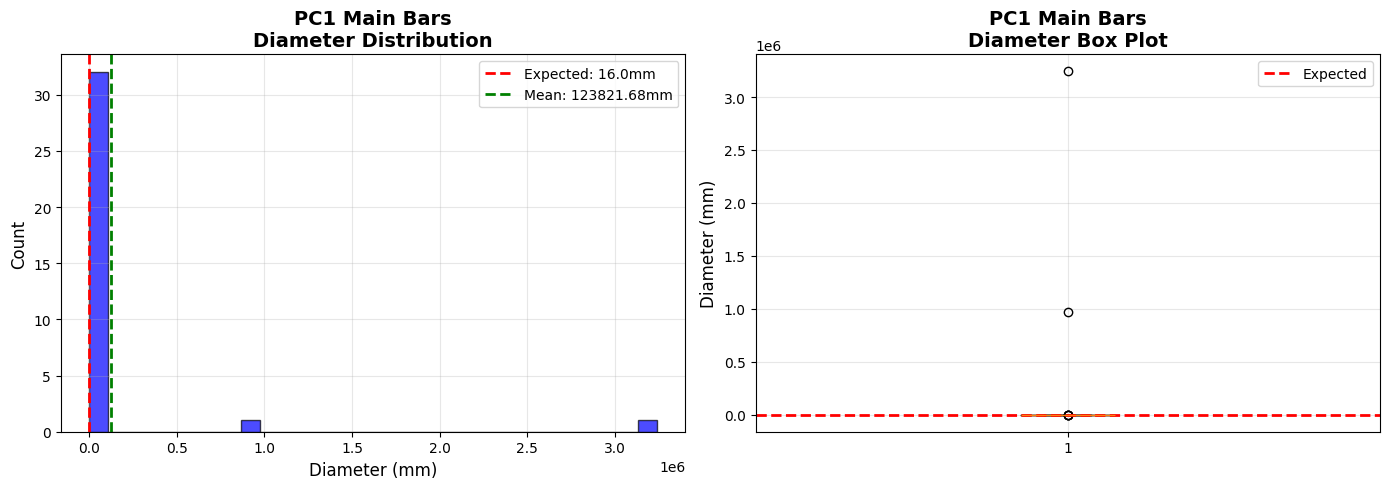


PC1 Main Bars - Diameter Statistics
Count:              34
Expected:           16.00 mm
Mean:               123821.68 mm
Median:             20.96 mm
Std Dev:            566735.96 mm
Min:                17.04 mm
Max:                3241641.85 mm
Mean Error:         123805.68 mm
Range:              3241624.82 mm


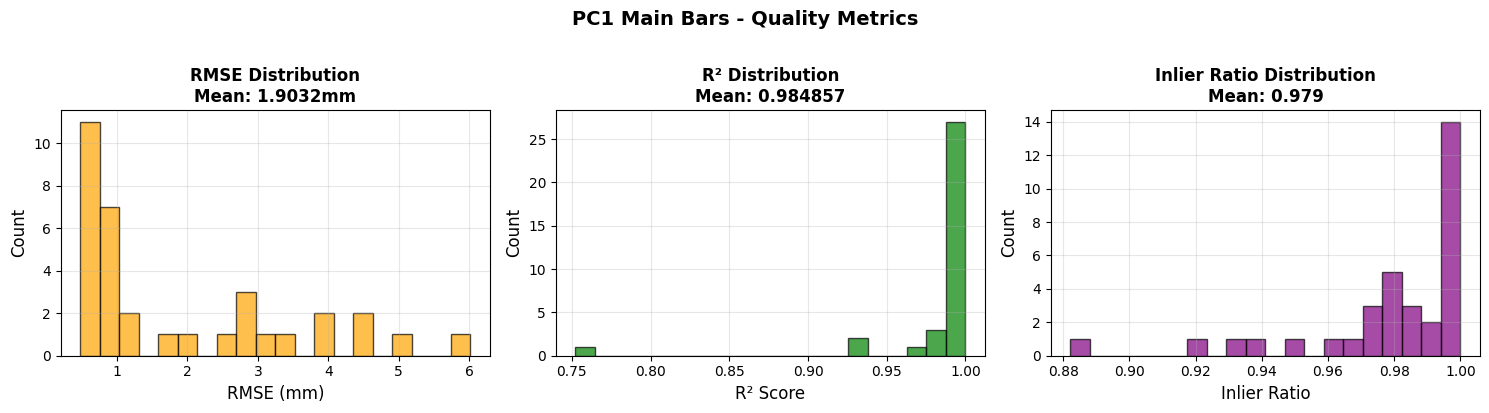

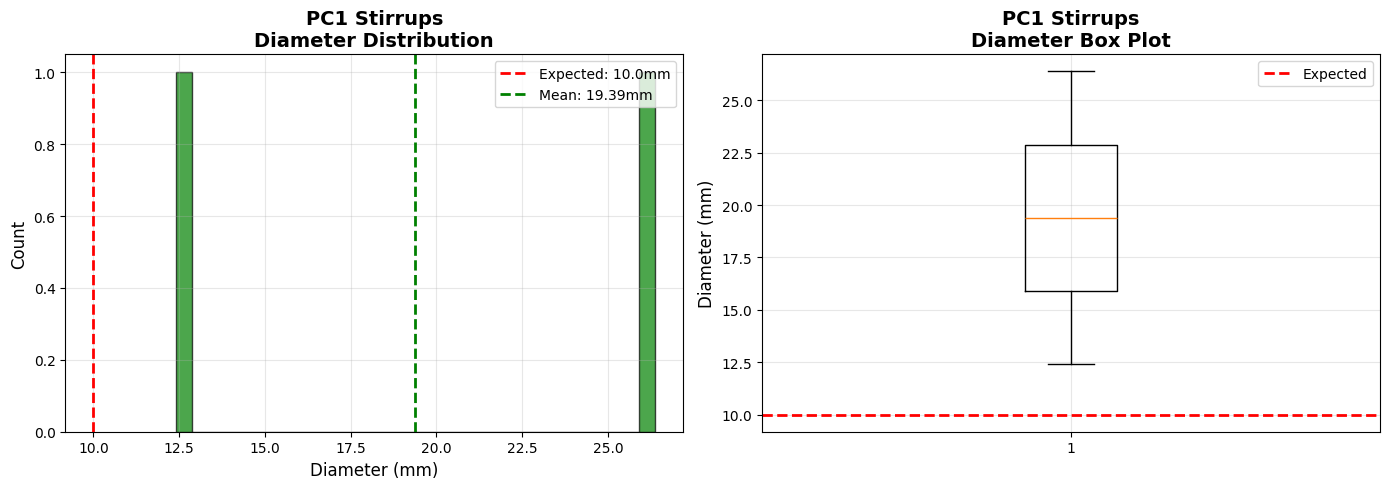


PC1 Stirrups - Diameter Statistics
Count:              2
Expected:           10.00 mm
Mean:               19.39 mm
Median:             19.39 mm
Std Dev:            6.99 mm
Min:                12.40 mm
Max:                26.38 mm
Mean Error:         9.39 mm
Range:              13.97 mm


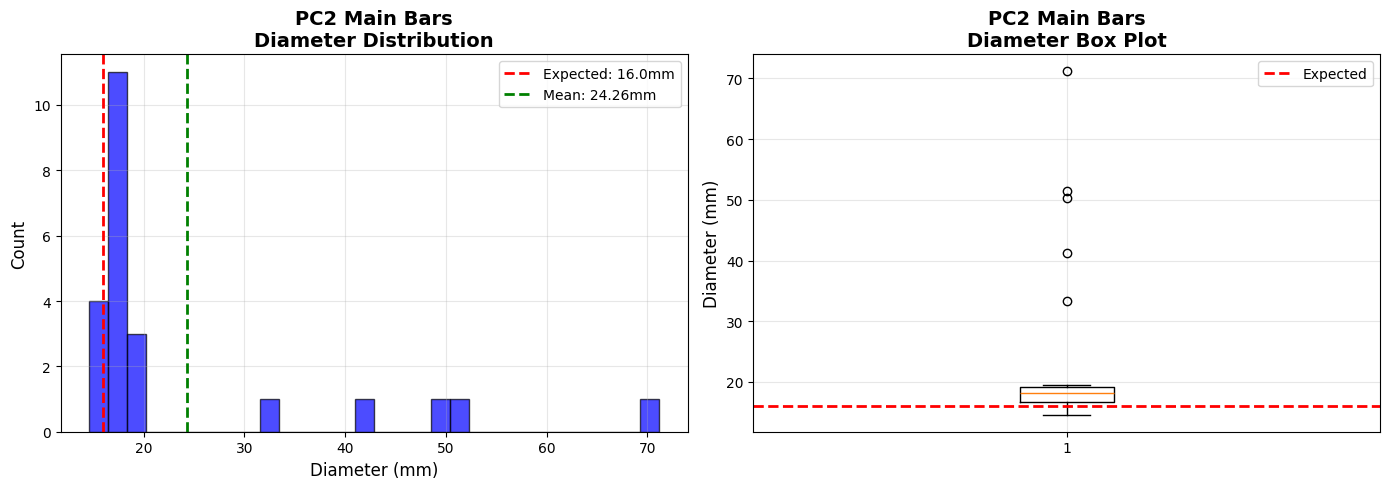


PC2 Main Bars - Diameter Statistics
Count:              23
Expected:           16.00 mm
Mean:               24.26 mm
Median:             18.14 mm
Std Dev:            14.58 mm
Min:                14.61 mm
Max:                71.15 mm
Mean Error:         8.26 mm
Range:              56.53 mm


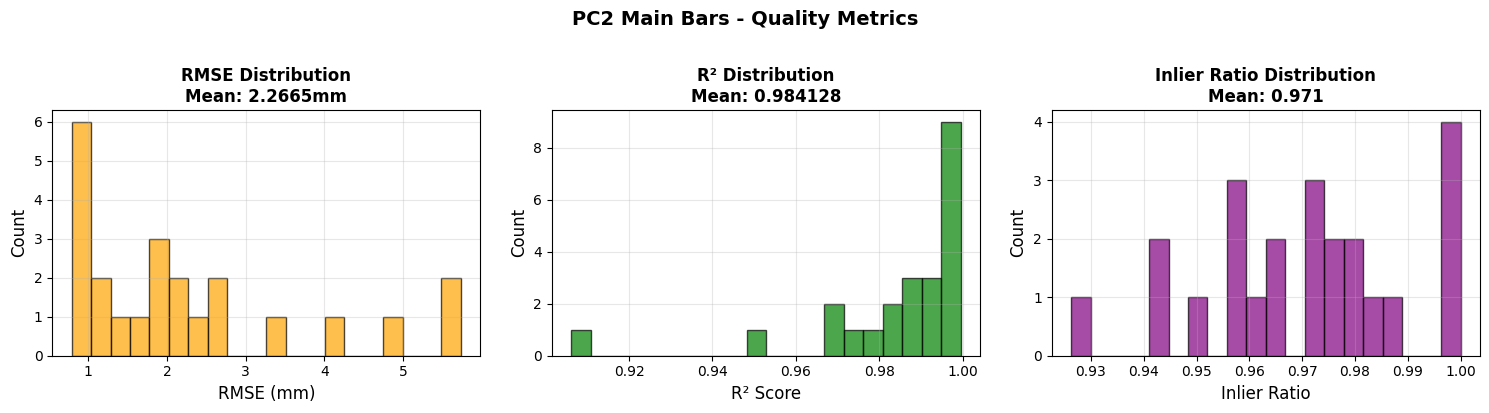


                          ANALYSIS COMPLETE - ALL RESULTS SHOWN                           
Total Time: 29.13s
Excel File: C:\VLM4Connection\Cylinder_Fitting_ALL_RESULTS_20251022_111402.xlsx

                           SUGGESTED BOUNDS BASED ON YOUR DATA                            

Main Bars:
  Observed range: 14.61 - 3241641.85 mm
  Suggested bounds: [0.91, 202602.62] of expected
  
  To use these bounds, set:
    RADIUS_LOWER_BOUND_FACTOR = 0.91
    RADIUS_UPPER_BOUND_FACTOR = 202602.62

Stirrups:
  Observed range: 12.40 - 26.38 mm
  Suggested bounds: [1.24, 2.64] of expected


In [23]:
import numpy as np
import open3d as o3d
import matplotlib.pyplot as plt
from sklearn.cluster import DBSCAN
from scipy.spatial.distance import cdist
from scipy.optimize import least_squares
import pandas as pd
import time
from datetime import datetime
import openpyxl
from openpyxl.styles import Font, PatternFill, Alignment, Border, Side
from openpyxl.utils.dataframe import dataframe_to_rows

# ============================================================================
# CONFIGURATION PARAMETERS
# ============================================================================

# File paths
aligned_path1 = r"C:\VLM4Connection\PC1_Rotated.ply"
aligned_path2 = r"C:\VLM4Connection\PC2_Rotated.ply"
output_dir = r"C:\VLM4Connection"

# Rebar parameters
MAIN_BAR_DIAMETER = 16.0  # mm - main bars along Z
STIRRUP_DIAMETER = 10.0   # mm - stirrups along X and Y
MAIN_BAR_RADIUS = MAIN_BAR_DIAMETER / 2.0
STIRRUP_RADIUS = STIRRUP_DIAMETER / 2.0

# Slicing parameters
SLICE_THICKNESS = 10.0  # mm - thickness of each slice
DBSCAN_EPS = 15.0       # mm - clustering distance
DBSCAN_MIN_POINTS = 10  # minimum points per cluster

# Tracking parameters
MAX_CENTER_MOVEMENT = 20.0  # mm - max distance between centers in adjacent slices
MIN_SLICES = 5              # minimum number of slices to form a valid cylinder

# Tolerance parameters (for initial DBSCAN detection)
MAIN_BAR_TOLERANCE = 4.0    # mm - tolerance for main bar radius
STIRRUP_TOLERANCE = 3.0     # mm - tolerance for stirrup radius

# ODR optimization parameters
ODR_MAX_ITERATIONS = 300
ODR_TOLERANCE = 1e-8
MIN_POINTS_FOR_ODR = 10  # Minimum points needed for reliable ODR fitting

# Outlier rejection parameters
OUTLIER_THRESHOLD_MAD = 4.0  # MAD (Median Absolute Deviation) multiplier
MAX_OUTLIER_ITERATIONS = 2   # Maximum iterations for outlier removal

# ⭐ BOUNDS DISABLED - WILL DETECT ALL CYLINDERS ⭐
USE_BOUNDS = False  # Set to True to enable bounds
RADIUS_LOWER_BOUND_FACTOR = 0.5  # Only used if USE_BOUNDS=True
RADIUS_UPPER_BOUND_FACTOR = 2.0  # Only used if USE_BOUNDS=True

# Timing storage
timing_data = {
    'PC1': {'method': 'Unbounded ODR (All Results)'},
    'PC2': {'method': 'Unbounded ODR (All Results)'},
    'Overall': {'method': 'Unbounded ODR (All Results)'}
}

# ============================================================================
# UTILITY FUNCTIONS
# ============================================================================

def compute_mad(residuals):
    """Compute Median Absolute Deviation (MAD) - robust measure of variability"""
    median = np.median(residuals)
    mad = np.median(np.abs(residuals - median))
    return mad

def remove_outliers_mad(points, center, radius, axis_direction, threshold=OUTLIER_THRESHOLD_MAD):
    """Remove outliers using Median Absolute Deviation (MAD)"""
    v = points - center
    axial_dist = np.dot(v, axis_direction)
    radial_vector = v - np.outer(axial_dist, axis_direction)
    radial_dist = np.linalg.norm(radial_vector, axis=1)
    residuals = radial_dist - radius
    
    mad = compute_mad(residuals)
    mad_scaled = 1.4826 * mad
    threshold_value = threshold * mad_scaled
    inlier_mask = np.abs(residuals) < threshold_value
    
    return points[inlier_mask], inlier_mask

def robust_circle_fit_2d(points_2d, expected_radius):
    """Robust 2D circle fitting using iterative least squares with outlier rejection"""
    if len(points_2d) < 3:
        return None, None, 0.0
    
    # Initial estimate
    center_2d = np.mean(points_2d, axis=0)
    distances = np.linalg.norm(points_2d - center_2d, axis=1)
    
    # Use weighted median for better robustness
    weights = np.exp(-0.5 * ((distances - expected_radius) / expected_radius) ** 2)
    radius = np.average(distances, weights=weights)
    
    # Iterative refinement with outlier removal
    current_points = points_2d.copy()
    for iteration in range(MAX_OUTLIER_ITERATIONS):
        center_2d = np.mean(current_points, axis=0)
        distances = np.linalg.norm(current_points - center_2d, axis=1)
        residuals = distances - radius
        mad = compute_mad(residuals)
        mad_scaled = 1.4826 * mad
        
        threshold = 2.5 * mad_scaled
        inliers = np.abs(residuals) < threshold
        
        if np.sum(inliers) < 3:
            break
        
        current_points = current_points[inliers]
        center_2d = np.mean(current_points, axis=0)
        distances = np.linalg.norm(current_points - center_2d, axis=1)
        radius = np.median(distances)
    
    inlier_ratio = len(current_points) / len(points_2d) if len(points_2d) > 0 else 0.0
    
    return center_2d, radius, inlier_ratio

def estimate_initial_cylinder_params(points, axis_direction, expected_radius):
    """Estimate initial cylinder parameters using robust methods"""
    points_mean = np.mean(points, axis=0)
    centered_points = points - points_mean
    cov = np.cov(centered_points.T)
    eigenvalues, eigenvectors = np.linalg.eigh(cov)
    
    axis_idx = np.argmin(np.abs(np.dot(eigenvectors.T, axis_direction)))
    plane_vectors = np.delete(eigenvectors, axis_idx, axis=1)
    projected = centered_points @ plane_vectors
    
    center_2d, radius, inlier_ratio = robust_circle_fit_2d(projected, expected_radius)
    
    if center_2d is None:
        return points_mean, expected_radius
    
    center_3d = points_mean + plane_vectors @ center_2d
    
    # No bounds applied here - use as-is
    return center_3d, radius

# ============================================================================
# CYLINDER FITTING FUNCTIONS
# ============================================================================

def cylinder_distance_function(params, points, axis_direction):
    """Compute orthogonal distances from points to cylinder surface"""
    center = params[:3]
    radius = params[3]
    
    v = points - center
    axial_dist = np.dot(v, axis_direction)
    radial_vector = v - np.outer(axial_dist, axis_direction)
    radial_dist = np.linalg.norm(radial_vector, axis=1)
    
    return radial_dist - radius

def fit_cylinder_unbounded_with_outlier_rejection(points, initial_center, initial_radius, 
                                                   axis_direction, expected_radius, 
                                                   max_iter=ODR_MAX_ITERATIONS):
    """
    Fit cylinder WITHOUT bounds but with outlier rejection
    This shows ALL results, then you can decide on appropriate bounds
    """
    if len(points) < MIN_POINTS_FOR_ODR:
        return None
    
    axis_direction = axis_direction / np.linalg.norm(axis_direction)
    initial_params = np.hstack([initial_center, initial_radius])
    
    current_points = points.copy()
    best_result = None
    best_rmse = np.inf
    
    for iteration in range(MAX_OUTLIER_ITERATIONS):
        if len(current_points) < MIN_POINTS_FOR_ODR:
            break
        
        def residuals(params):
            return cylinder_distance_function(params, current_points, axis_direction)
        
        try:
            if USE_BOUNDS:
                # Use bounds if enabled
                point_extent = np.ptp(points, axis=0)
                center_tolerance = np.max(point_extent) * 0.5
                
                bounds_lower = np.hstack([
                    initial_center - center_tolerance,
                    expected_radius * RADIUS_LOWER_BOUND_FACTOR
                ])
                bounds_upper = np.hstack([
                    initial_center + center_tolerance,
                    expected_radius * RADIUS_UPPER_BOUND_FACTOR
                ])
                
                result = least_squares(
                    residuals,
                    initial_params,
                    method='trf',
                    bounds=(bounds_lower, bounds_upper),
                    max_nfev=max_iter,
                    ftol=ODR_TOLERANCE,
                    xtol=ODR_TOLERANCE,
                    gtol=ODR_TOLERANCE,
                    verbose=0,
                    loss='soft_l1'
                )
            else:
                # NO BOUNDS - use Levenberg-Marquardt
                result = least_squares(
                    residuals,
                    initial_params,
                    method='lm',  # LM works well without bounds
                    max_nfev=max_iter,
                    ftol=ODR_TOLERANCE,
                    xtol=ODR_TOLERANCE,
                    gtol=ODR_TOLERANCE,
                    verbose=0
                )
        except Exception as e:
            print(f"    Warning: Optimization failed at iteration {iteration}: {str(e)}")
            break
        
        if not result.success:
            break
        
        fitted_center = result.x[:3]
        fitted_radius = result.x[3]
        residuals_final = result.fun
        rmse = np.sqrt(np.mean(residuals_final**2))
        
        if rmse < best_rmse:
            best_rmse = rmse
            max_error = np.max(np.abs(residuals_final))
            std_error = np.std(residuals_final)
            
            ss_res = np.sum(residuals_final**2)
            ss_tot = np.sum((np.linalg.norm(current_points - current_points.mean(axis=0), axis=1) - fitted_radius)**2)
            r_squared = 1 - (ss_res / ss_tot) if ss_tot > 0 else 0
            
            best_result = {
                'center': fitted_center,
                'radius': fitted_radius,
                'diameter': fitted_radius * 2,
                'axis_direction': axis_direction,
                'rmse': rmse,
                'max_error': max_error,
                'std_error': std_error,
                'r_squared': r_squared,
                'n_iterations': result.nfev,
                'optimization_iterations': iteration + 1,
                'n_points_used': len(current_points),
                'n_points_original': len(points),
                'inlier_ratio': len(current_points) / len(points),
                'success': result.success,
                'fitting_method': 'Unbounded ODR + Outlier Rejection' if not USE_BOUNDS else 'Bounded ODR + Outlier Rejection',
                'diameter_error': abs(fitted_radius * 2 - expected_radius * 2)
            }
        
        filtered_points, inlier_mask = remove_outliers_mad(
            current_points, fitted_center, fitted_radius, axis_direction,
            threshold=OUTLIER_THRESHOLD_MAD
        )
        
        if len(filtered_points) < MIN_POINTS_FOR_ODR * 0.8:
            break
        
        if len(filtered_points) == len(current_points):
            break
        
        current_points = filtered_points
        initial_params = np.hstack([fitted_center, fitted_radius])
    
    return best_result

# ============================================================================
# POINT CLOUD PROCESSING
# ============================================================================

def slice_point_cloud(points, axis, slice_thickness):
    """Divide point cloud into slices perpendicular to specified axis"""
    axis_min, axis_max = points[:, axis].min(), points[:, axis].max()
    n_slices = int(np.ceil((axis_max - axis_min) / slice_thickness))
    
    slices = {}
    for i in range(n_slices):
        axis_start = axis_min + i * slice_thickness
        axis_end = axis_start + slice_thickness
        
        mask = (points[:, axis] >= axis_start) & (points[:, axis] < axis_end)
        slice_points = points[mask]
        
        if len(slice_points) > 0:
            slices[i] = {
                'points': slice_points,
                'axis_center': (axis_start + axis_end) / 2,
                'axis_range': (axis_start, axis_end)
            }
    
    return slices

def detect_circles_robust(slice_points, plane_axes, expected_radius, tolerance):
    """Detect circular cross-sections using DBSCAN with robust circle fitting"""
    if len(slice_points) < DBSCAN_MIN_POINTS:
        return []
    
    plane_points = slice_points[:, plane_axes]
    clustering = DBSCAN(eps=DBSCAN_EPS, min_samples=DBSCAN_MIN_POINTS).fit(plane_points)
    labels = clustering.labels_
    
    circles = []
    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    
    for cluster_id in range(n_clusters):
        cluster_mask = labels == cluster_id
        cluster_plane = plane_points[cluster_mask]
        cluster_3d = slice_points[cluster_mask]
        
        if len(cluster_plane) < DBSCAN_MIN_POINTS:
            continue
        
        center_plane, radius, inlier_ratio = robust_circle_fit_2d(cluster_plane, expected_radius)
        
        if center_plane is None:
            continue
        
        # More relaxed validation - accept wider range
        if abs(radius - expected_radius) < tolerance * 2 and inlier_ratio > 0.5:
            circles.append({
                'center_plane': center_plane,
                'center_3d': np.mean(cluster_3d, axis=0),
                'radius': radius,
                'n_points': len(cluster_3d),
                'points_3d': cluster_3d,
                'inlier_ratio': inlier_ratio
            })
    
    return circles

def track_cylinders_across_slices(slices, plane_axes, expected_radius, tolerance):
    """Track circular cross-sections across slices to identify continuous cylinders"""
    slice_indices = sorted(slices.keys())
    
    slice_circles = {}
    for idx in slice_indices:
        circles = detect_circles_robust(
            slices[idx]['points'], plane_axes, expected_radius, tolerance
        )
        if circles:
            slice_circles[idx] = circles
    
    if not slice_circles:
        return []
    
    cylinders = []
    used_circles = set()
    
    for start_idx in sorted(slice_circles.keys()):
        for start_circle_idx, start_circle in enumerate(slice_circles[start_idx]):
            circle_key = (start_idx, start_circle_idx)
            if circle_key in used_circles:
                continue
            
            cylinder_data = {
                'slice_indices': [start_idx],
                'circles': [start_circle],
                'axis_positions': [slices[start_idx]['axis_center']]
            }
            
            current_center = start_circle['center_plane']
            
            for next_idx in slice_indices:
                if next_idx <= start_idx or next_idx not in slice_circles:
                    continue
                
                best_match = None
                best_distance = MAX_CENTER_MOVEMENT
                best_match_idx = None
                
                for next_circle_idx, next_circle in enumerate(slice_circles[next_idx]):
                    next_key = (next_idx, next_circle_idx)
                    if next_key in used_circles:
                        continue
                    
                    distance = np.linalg.norm(next_circle['center_plane'] - current_center)
                    if distance < best_distance:
                        best_distance = distance
                        best_match = next_circle
                        best_match_idx = next_circle_idx
                
                if best_match is not None:
                    cylinder_data['slice_indices'].append(next_idx)
                    cylinder_data['circles'].append(best_match)
                    cylinder_data['axis_positions'].append(slices[next_idx]['axis_center'])
                    current_center = best_match['center_plane']
                    used_circles.add((next_idx, best_match_idx))
                else:
                    break
            
            if len(cylinder_data['slice_indices']) >= MIN_SLICES:
                used_circles.add(circle_key)
                cylinders.append(cylinder_data)
    
    return cylinders

def refine_cylinder_with_odr(cylinder_data, main_axis, plane_axes, expected_radius):
    """Refine cylinder parameters using unbounded ODR with outlier rejection"""
    all_points = []
    for circle in cylinder_data['circles']:
        all_points.append(circle['points_3d'])
    all_points = np.vstack(all_points)
    
    if len(all_points) < MIN_POINTS_FOR_ODR:
        return None
    
    axis_direction = np.zeros(3)
    axis_direction[main_axis] = 1.0
    
    initial_center, initial_radius = estimate_initial_cylinder_params(
        all_points, axis_direction, expected_radius
    )
    
    result = fit_cylinder_unbounded_with_outlier_rejection(
        all_points, initial_center, initial_radius, axis_direction, expected_radius
    )
    
    if result is None:
        return None
    
    axis_positions = np.array(cylinder_data['axis_positions'])
    result['axis_min'] = axis_positions.min()
    result['axis_max'] = axis_positions.max()
    result['length'] = result['axis_max'] - result['axis_min']
    result['n_slices'] = len(cylinder_data['slice_indices'])
    
    center_plane = result['center'][list(plane_axes)]
    result['center_plane'] = center_plane
    
    return result

def detect_and_refine_cylinders_odr(pcd, main_axis, expected_radius, tolerance, 
                                    cylinder_type, pc_label):
    """Main function to detect and refine cylinders"""
    print(f"\n[DETECTING] {cylinder_type} along axis {main_axis}...")
    start_time = time.time()
    
    points = np.asarray(pcd.points)
    plane_axes = tuple([i for i in range(3) if i != main_axis])
    
    slices = slice_point_cloud(points, main_axis, SLICE_THICKNESS)
    print(f"  ✓ Created {len(slices)} slices")
    
    tracked_cylinders = track_cylinders_across_slices(slices, plane_axes, expected_radius, tolerance)
    print(f"  ✓ Tracked {len(tracked_cylinders)} cylinders across slices")
    
    refined_cylinders = []
    for i, cyl_data in enumerate(tracked_cylinders):
        result = refine_cylinder_with_odr(cyl_data, main_axis, plane_axes, expected_radius)
        if result is not None:
            refined_cylinders.append(result)
    
    elapsed = time.time() - start_time
    print(f"  ✓ Refined {len(refined_cylinders)} cylinders")
    print(f"  ✓ Time: {elapsed:.3f}s")
    
    timing_key = f"{cylinder_type.lower().replace(' ', '_')}_axis_{main_axis}"
    timing_data[pc_label][timing_key] = elapsed
    
    return refined_cylinders

# ============================================================================
# CYLINDER COMBINATION FUNCTIONS
# ============================================================================

def combine_refined_cylinders(cylinders, xy_tolerance=5.0, pc_label=""):
    """Combine cylinder segments that belong to the same physical cylinder"""
    if not cylinders:
        return []
    
    print(f"\n[COMBINING] Cylinders for {pc_label}...")
    
    combined = []
    used = set()
    
    for i, cyl1 in enumerate(cylinders):
        if i in used:
            continue
        
        group = [cyl1]
        used.add(i)
        
        for j, cyl2 in enumerate(cylinders):
            if j in used or j <= i:
                continue
            
            center_dist = np.linalg.norm(cyl1['center_plane'] - cyl2['center_plane'])
            radius_diff = abs(cyl1['radius'] - cyl2['radius'])
            
            if center_dist < xy_tolerance and radius_diff < 2.0:
                group.append(cyl2)
                used.add(j)
        
        if len(group) == 1:
            combined_cyl = group[0].copy()
            # Ensure all required keys exist
            if 'inlier_ratio' not in combined_cyl:
                combined_cyl['inlier_ratio'] = 1.0
            if 'diameter_error' not in combined_cyl:
                combined_cyl['diameter_error'] = 0.0
        else:
            total_points = sum(c['n_points_used'] for c in group)
            weights = np.array([c['n_points_used'] / total_points for c in group])
            
            combined_cyl = {
                'center': np.average([c['center'] for c in group], axis=0, weights=weights),
                'center_plane': np.average([c['center_plane'] for c in group], axis=0, weights=weights),
                'radius': np.average([c['radius'] for c in group], weights=weights),
                'diameter': np.average([c['diameter'] for c in group], weights=weights),
                'axis_direction': group[0]['axis_direction'],
                'axis_min': min(c['axis_min'] for c in group),
                'axis_max': max(c['axis_max'] for c in group),
                'rmse': np.average([c['rmse'] for c in group], weights=weights),
                'r_squared': np.average([c['r_squared'] for c in group], weights=weights),
                'n_segments': len(group),
                'n_points_used': sum(c['n_points_used'] for c in group),
                'n_points_original': sum(c.get('n_points_original', c['n_points_used']) for c in group),
                'inlier_ratio': np.average([c.get('inlier_ratio', 1.0) for c in group], weights=weights),
                'fitting_method': group[0]['fitting_method'],
                'diameter_error': np.average([c.get('diameter_error', 0.0) for c in group], weights=weights)
            }
            combined_cyl['length'] = combined_cyl['axis_max'] - combined_cyl['axis_min']
        
        combined.append(combined_cyl)
    
    print(f"  ✓ Combined {len(cylinders)} segments into {len(combined)} cylinders")
    
    return combined

def combine_refined_stirrups(stirrups_x, stirrups_y, z_tolerance=5.0, pc_label=""):
    """Combine X and Y direction stirrup segments into rectangular loops"""
    if not stirrups_x or not stirrups_y:
        return []
    
    print(f"\n[COMBINING] Stirrups for {pc_label}...")
    
    loops = []
    used_x = set()
    used_y = set()
    
    for i, sx in enumerate(stirrups_x):
        if i in used_x:
            continue
        
        z_pos_x = (sx['center'][2] + sx['axis_min'] + sx['axis_max']) / 2
        
        matching_y = []
        for j, sy in enumerate(stirrups_y):
            if j in used_y:
                continue
            
            z_pos_y = (sy['center'][2] + sy['axis_min'] + sy['axis_max']) / 2
            
            if abs(z_pos_x - z_pos_y) < z_tolerance:
                matching_y.append((j, sy))
        
        if matching_y:
            j, sy = matching_y[0]
            
            loop = {
                'z_position': (z_pos_x + (sy['center'][2] + sy['axis_min'] + sy['axis_max']) / 2) / 2,
                'x_center': sx['center'][0],
                'y_center': sy['center'][1],
                'width': abs(sx['axis_max'] - sx['axis_min']),
                'height': abs(sy['axis_max'] - sy['axis_min']),
                'diameter_x': sx['diameter'],
                'diameter_y': sy['diameter'],
                'diameter': (sx['diameter'] + sy['diameter']) / 2,
                'rmse_x': sx['rmse'],
                'rmse_y': sy['rmse'],
                'r_squared_x': sx['r_squared'],
                'r_squared_y': sy['r_squared'],
                'n_points_x': sx['n_points_used'],
                'n_points_y': sy['n_points_used'],
                'diameter_error_x': sx.get('diameter_error', abs(sx['diameter'] - STIRRUP_DIAMETER)),
                'diameter_error_y': sy.get('diameter_error', abs(sy['diameter'] - STIRRUP_DIAMETER))
            }
            
            loops.append(loop)
            used_x.add(i)
            used_y.add(j)
    
    print(f"  ✓ Created {len(loops)} stirrup loops")
    
    return loops

# ============================================================================
# JUPYTER NOTEBOOK OUTPUT & VISUALIZATION
# ============================================================================

def plot_diameter_distribution(cylinders, expected_diameter, title, color='blue'):
    """Plot diameter distribution histogram"""
    if not cylinders:
        print(f"No data to plot for {title}")
        return
    
    diameters = [c['diameter'] for c in cylinders]
    
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    
    # Histogram
    ax1.hist(diameters, bins=30, alpha=0.7, color=color, edgecolor='black')
    ax1.axvline(expected_diameter, color='red', linestyle='--', linewidth=2, label=f'Expected: {expected_diameter}mm')
    ax1.axvline(np.mean(diameters), color='green', linestyle='--', linewidth=2, label=f'Mean: {np.mean(diameters):.2f}mm')
    ax1.set_xlabel('Diameter (mm)', fontsize=12)
    ax1.set_ylabel('Count', fontsize=12)
    ax1.set_title(f'{title}\nDiameter Distribution', fontsize=14, fontweight='bold')
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    
    # Box plot
    ax2.boxplot(diameters, vert=True)
    ax2.axhline(expected_diameter, color='red', linestyle='--', linewidth=2, label='Expected')
    ax2.set_ylabel('Diameter (mm)', fontsize=12)
    ax2.set_title(f'{title}\nDiameter Box Plot', fontsize=14, fontweight='bold')
    ax2.legend()
    ax2.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    # Print statistics
    print(f"\n{'='*60}")
    print(f"{title} - Diameter Statistics")
    print(f"{'='*60}")
    print(f"Count:              {len(diameters)}")
    print(f"Expected:           {expected_diameter:.2f} mm")
    print(f"Mean:               {np.mean(diameters):.2f} mm")
    print(f"Median:             {np.median(diameters):.2f} mm")
    print(f"Std Dev:            {np.std(diameters):.2f} mm")
    print(f"Min:                {np.min(diameters):.2f} mm")
    print(f"Max:                {np.max(diameters):.2f} mm")
    print(f"Mean Error:         {abs(np.mean(diameters) - expected_diameter):.2f} mm")
    print(f"Range:              {np.ptp(diameters):.2f} mm")
    print(f"{'='*60}")

def plot_quality_metrics(cylinders, title):
    """Plot quality metrics (RMSE, R², Inlier Ratio)"""
    if not cylinders:
        return
    
    rmse_vals = [c['rmse'] for c in cylinders]
    r2_vals = [c['r_squared'] for c in cylinders]
    inlier_ratios = [c['inlier_ratio'] for c in cylinders]
    
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    
    # RMSE
    axes[0].hist(rmse_vals, bins=20, alpha=0.7, color='orange', edgecolor='black')
    axes[0].set_xlabel('RMSE (mm)', fontsize=12)
    axes[0].set_ylabel('Count', fontsize=12)
    axes[0].set_title(f'RMSE Distribution\nMean: {np.mean(rmse_vals):.4f}mm', fontsize=12, fontweight='bold')
    axes[0].grid(True, alpha=0.3)
    
    # R²
    axes[1].hist(r2_vals, bins=20, alpha=0.7, color='green', edgecolor='black')
    axes[1].set_xlabel('R² Score', fontsize=12)
    axes[1].set_ylabel('Count', fontsize=12)
    axes[1].set_title(f'R² Distribution\nMean: {np.mean(r2_vals):.6f}', fontsize=12, fontweight='bold')
    axes[1].grid(True, alpha=0.3)
    
    # Inlier Ratio
    axes[2].hist(inlier_ratios, bins=20, alpha=0.7, color='purple', edgecolor='black')
    axes[2].set_xlabel('Inlier Ratio', fontsize=12)
    axes[2].set_ylabel('Count', fontsize=12)
    axes[2].set_title(f'Inlier Ratio Distribution\nMean: {np.mean(inlier_ratios):.3f}', fontsize=12, fontweight='bold')
    axes[2].grid(True, alpha=0.3)
    
    plt.suptitle(title, fontsize=14, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.show()

def display_summary_table(pc1_data, pc2_data):
    """Display comprehensive summary table in Jupyter"""
    from IPython.display import display, HTML
    
    summary_data = []
    
    # PC1 Main Bars
    if pc1_data['main_bars']:
        diameters = [b['diameter'] for b in pc1_data['main_bars']]
        rmse_vals = [b['rmse'] for b in pc1_data['main_bars']]
        
        summary_data.append({
            'Point Cloud': 'PC1',
            'Type': 'Main Bars',
            'Count': len(pc1_data['main_bars']),
            'Expected (mm)': MAIN_BAR_DIAMETER,
            'Mean Dia (mm)': f"{np.mean(diameters):.2f}",
            'Std (mm)': f"{np.std(diameters):.2f}",
            'Min (mm)': f"{np.min(diameters):.2f}",
            'Max (mm)': f"{np.max(diameters):.2f}",
            'Mean Error (mm)': f"{abs(np.mean(diameters) - MAIN_BAR_DIAMETER):.2f}",
            'Avg RMSE (mm)': f"{np.mean(rmse_vals):.4f}"
        })
    
    # PC1 Stirrups
    if pc1_data['stirrups']:
        diameters = [s['diameter'] for s in pc1_data['stirrups']]
        
        summary_data.append({
            'Point Cloud': 'PC1',
            'Type': 'Stirrups',
            'Count': len(pc1_data['stirrups']),
            'Expected (mm)': STIRRUP_DIAMETER,
            'Mean Dia (mm)': f"{np.mean(diameters):.2f}",
            'Std (mm)': f"{np.std(diameters):.2f}",
            'Min (mm)': f"{np.min(diameters):.2f}",
            'Max (mm)': f"{np.max(diameters):.2f}",
            'Mean Error (mm)': f"{abs(np.mean(diameters) - STIRRUP_DIAMETER):.2f}",
            'Avg RMSE (mm)': '-'
        })
    
    # PC2 Main Bars
    if pc2_data['main_bars']:
        diameters = [b['diameter'] for b in pc2_data['main_bars']]
        rmse_vals = [b['rmse'] for b in pc2_data['main_bars']]
        
        summary_data.append({
            'Point Cloud': 'PC2',
            'Type': 'Main Bars',
            'Count': len(pc2_data['main_bars']),
            'Expected (mm)': MAIN_BAR_DIAMETER,
            'Mean Dia (mm)': f"{np.mean(diameters):.2f}",
            'Std (mm)': f"{np.std(diameters):.2f}",
            'Min (mm)': f"{np.min(diameters):.2f}",
            'Max (mm)': f"{np.max(diameters):.2f}",
            'Mean Error (mm)': f"{abs(np.mean(diameters) - MAIN_BAR_DIAMETER):.2f}",
            'Avg RMSE (mm)': f"{np.mean(rmse_vals):.4f}"
        })
    
    # PC2 Stirrups
    if pc2_data['stirrups']:
        diameters = [s['diameter'] for s in pc2_data['stirrups']]
        
        summary_data.append({
            'Point Cloud': 'PC2',
            'Type': 'Stirrups',
            'Count': len(pc2_data['stirrups']),
            'Expected (mm)': STIRRUP_DIAMETER,
            'Mean Dia (mm)': f"{np.mean(diameters):.2f}",
            'Std (mm)': f"{np.std(diameters):.2f}",
            'Min (mm)': f"{np.min(diameters):.2f}",
            'Max (mm)': f"{np.max(diameters):.2f}",
            'Mean Error (mm)': f"{abs(np.mean(diameters) - STIRRUP_DIAMETER):.2f}",
            'Avg RMSE (mm)': '-'
        })
    
    df = pd.DataFrame(summary_data)
    
    # Style the dataframe
    styled_df = df.style.set_properties(**{
        'text-align': 'center',
        'font-size': '11pt',
        'border-color': 'black',
        'border-width': '1px',
        'border-style': 'solid'
    }).set_table_styles([
        {'selector': 'th', 'props': [('background-color', '#366092'), ('color', 'white'), 
                                      ('font-weight', 'bold'), ('text-align', 'center')]}
    ])
    
    print("\n" + "="*120)
    print(" COMPREHENSIVE SUMMARY TABLE ".center(120))
    print("="*120)
    display(styled_df)

# ============================================================================
# EXCEL EXPORT
# ============================================================================

def save_comprehensive_excel(pc1_data, pc2_data, timing_data, excel_file):
    """Save all results to Excel with detailed information"""
    writer = pd.ExcelWriter(excel_file, engine='openpyxl')
    
    # PC1 Main Bars - ALL DETECTED
    if pc1_data['main_bars']:
        df_main1 = pd.DataFrame([
            {
                'ID': i + 1,
                'Diameter (mm)': bar['diameter'],
                'Expected (mm)': MAIN_BAR_DIAMETER,
                'Error (mm)': bar.get('diameter_error', abs(bar['diameter'] - MAIN_BAR_DIAMETER)),
                'Center X': bar['center'][0],
                'Center Y': bar['center'][1],
                'Center Z': bar['center'][2],
                'Length (mm)': bar['length'],
                'Z Min': bar['axis_min'],
                'Z Max': bar['axis_max'],
                'RMSE': bar['rmse'],
                'R²': bar['r_squared'],
                'Points Used': bar['n_points_used'],
                'Inlier Ratio': bar.get('inlier_ratio', 1.0),
                'Method': bar['fitting_method']
            }
            for i, bar in enumerate(pc1_data['main_bars'])
        ])
        df_main1.to_excel(writer, sheet_name='PC1_MainBars_ALL', index=False)
    
    # PC1 Stirrups - ALL DETECTED
    if pc1_data['stirrups']:
        df_stirrup1 = pd.DataFrame([
            {
                'ID': i + 1,
                'Z Position': stirrup['z_position'],
                'Diameter X': stirrup['diameter_x'],
                'Diameter Y': stirrup['diameter_y'],
                'Avg Diameter': stirrup['diameter'],
                'Expected (mm)': STIRRUP_DIAMETER,
                'Error X': stirrup.get('diameter_error_x', abs(stirrup['diameter_x'] - STIRRUP_DIAMETER)),
                'Error Y': stirrup.get('diameter_error_y', abs(stirrup['diameter_y'] - STIRRUP_DIAMETER)),
                'Width': stirrup['width'],
                'Height': stirrup['height'],
                'X Center': stirrup['x_center'],
                'Y Center': stirrup['y_center'],
                'RMSE X': stirrup['rmse_x'],
                'RMSE Y': stirrup['rmse_y'],
                'R² X': stirrup['r_squared_x'],
                'R² Y': stirrup['r_squared_y']
            }
            for i, stirrup in enumerate(pc1_data['stirrups'])
        ])
        df_stirrup1.to_excel(writer, sheet_name='PC1_Stirrups_ALL', index=False)
    
    # PC2 Main Bars
    if pc2_data['main_bars']:
        df_main2 = pd.DataFrame([
            {
                'ID': i + 1,
                'Diameter (mm)': bar['diameter'],
                'Expected (mm)': MAIN_BAR_DIAMETER,
                'Error (mm)': bar.get('diameter_error', abs(bar['diameter'] - MAIN_BAR_DIAMETER)),
                'Center X': bar['center'][0],
                'Center Y': bar['center'][1],
                'Center Z': bar['center'][2],
                'Length (mm)': bar['length'],
                'Z Min': bar['axis_min'],
                'Z Max': bar['axis_max'],
                'RMSE': bar['rmse'],
                'R²': bar['r_squared'],
                'Points Used': bar['n_points_used'],
                'Inlier Ratio': bar.get('inlier_ratio', 1.0),
                'Method': bar['fitting_method']
            }
            for i, bar in enumerate(pc2_data['main_bars'])
        ])
        df_main2.to_excel(writer, sheet_name='PC2_MainBars_ALL', index=False)
    
    # PC2 Stirrups
    if pc2_data['stirrups']:
        df_stirrup2 = pd.DataFrame([
            {
                'ID': i + 1,
                'Z Position': stirrup['z_position'],
                'Diameter X': stirrup['diameter_x'],
                'Diameter Y': stirrup['diameter_y'],
                'Avg Diameter': stirrup['diameter'],
                'Expected (mm)': STIRRUP_DIAMETER,
                'Error X': stirrup.get('diameter_error_x', abs(stirrup['diameter_x'] - STIRRUP_DIAMETER)),
                'Error Y': stirrup.get('diameter_error_y', abs(stirrup['diameter_y'] - STIRRUP_DIAMETER)),
                'Width': stirrup['width'],
                'Height': stirrup['height'],
                'X Center': stirrup['x_center'],
                'Y Center': stirrup['y_center'],
                'RMSE X': stirrup['rmse_x'],
                'RMSE Y': stirrup['rmse_y'],
                'R² X': stirrup['r_squared_x'],
                'R² Y': stirrup['r_squared_y']
            }
            for i, stirrup in enumerate(pc2_data['stirrups'])
        ])
        df_stirrup2.to_excel(writer, sheet_name='PC2_Stirrups_ALL', index=False)
    
    # Summary Statistics
    stats_data = []
    for data, pc, pc_label in [(pc1_data, 'PC1', 'Point Cloud 1'), 
                            (pc2_data, 'PC2', 'Point Cloud 2')]:
        
        if data['main_bars']:
            diameters = [b['diameter'] for b in data['main_bars']]
            stats_data.append({
                'Point Cloud': pc_label,
                'Type': 'Main Bars',
                'Count': len(data['main_bars']),
                'Expected (mm)': MAIN_BAR_DIAMETER,
                'Mean (mm)': np.mean(diameters),
                'Median (mm)': np.median(diameters),
                'Std (mm)': np.std(diameters),
                'Min (mm)': np.min(diameters),
                'Max (mm)': np.max(diameters),
                'Range (mm)': np.ptp(diameters),
                'Mean Error (mm)': abs(np.mean(diameters) - MAIN_BAR_DIAMETER)
            })
        
        if data['stirrups']:
            diameters = [s['diameter'] for s in data['stirrups']]
            stats_data.append({
                'Point Cloud': pc_label,
                'Type': 'Stirrups',
                'Count': len(data['stirrups']),
                'Expected (mm)': STIRRUP_DIAMETER,
                'Mean (mm)': np.mean(diameters),
                'Median (mm)': np.median(diameters),
                'Std (mm)': np.std(diameters),
                'Min (mm)': np.min(diameters),
                'Max (mm)': np.max(diameters),
                'Range (mm)': np.ptp(diameters),
                'Mean Error (mm)': abs(np.mean(diameters) - STIRRUP_DIAMETER)
            })
    
    if stats_data:
        df_stats = pd.DataFrame(stats_data)
        df_stats.to_excel(writer, sheet_name='Summary_Statistics', index=False)
    
    writer.close()
    
    # Format Excel
    wb = openpyxl.load_workbook(excel_file)
    for sheet_name in wb.sheetnames:
        ws = wb[sheet_name]
        
        for cell in ws[1]:
            cell.font = Font(bold=True, color="FFFFFF")
            cell.fill = PatternFill(start_color="366092", end_color="366092", fill_type="solid")
            cell.alignment = Alignment(horizontal="center", vertical="center")
        
        for column in ws.columns:
            max_length = 0
            column_letter = column[0].column_letter
            for cell in column:
                try:
                    if len(str(cell.value)) > max_length:
                        max_length = len(str(cell.value))
                except:
                    pass
            adjusted_width = min(max_length + 2, 50)
            ws.column_dimensions[column_letter].width = adjusted_width
    
    wb.save(excel_file)

# ============================================================================
# MAIN EXECUTION
# ============================================================================

def run_unbounded_cylinder_fitting():
    """Execute unbounded ODR cylinder fitting - shows ALL results"""
    
    bounds_status = "ENABLED" if USE_BOUNDS else "DISABLED"
    
    print("\n" + "="*90)
    print(" CYLINDER FITTING - ALL RESULTS (NO BOUNDS) ".center(90))
    print("="*90)
    print(f"Analysis Start: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
    print(f"Method: ODR with Outlier Rejection")
    print(f"Bounds: {bounds_status}")
    print(f"")
    print(f"Configuration:")
    print(f"  • Main Bar Expected: {MAIN_BAR_DIAMETER}mm (radius {MAIN_BAR_RADIUS}mm)")
    print(f"  • Stirrup Expected: {STIRRUP_DIAMETER}mm (radius {STIRRUP_RADIUS}mm)")
    print(f"  • Outlier Threshold: {OUTLIER_THRESHOLD_MAD} × MAD")
    print(f"  • Min Points for ODR: {MIN_POINTS_FOR_ODR}")
    print("="*90)
    
    overall_start = time.time()
    
    # ========== POINT CLOUD 1 ==========
    print(f"\n{'='*80}")
    print("POINT CLOUD 1 - DETECTING ALL CYLINDERS")
    print(f"{'='*80}")
    
    pc1_start = time.time()
    
    print("\n[LOADING] Point Cloud 1...")
    load_start = time.time()
    pcd1 = o3d.io.read_point_cloud(aligned_path1)
    load_time = time.time() - load_start
    timing_data['PC1']['loading'] = load_time
    print(f"  ✓ Loaded {len(np.asarray(pcd1.points)):,} points ({load_time:.3f}s)")
    
    # Detect cylinders
    main_bars_1 = detect_and_refine_cylinders_odr(
        pcd1, 2, MAIN_BAR_RADIUS, MAIN_BAR_TOLERANCE, "Main Bars", "PC1"
    )
    
    stirrups_x_1 = detect_and_refine_cylinders_odr(
        pcd1, 0, STIRRUP_RADIUS, STIRRUP_TOLERANCE, "Stirrups X", "PC1"
    )
    
    stirrups_y_1 = detect_and_refine_cylinders_odr(
        pcd1, 1, STIRRUP_RADIUS, STIRRUP_TOLERANCE, "Stirrups Y", "PC1"
    )
    
    combined_main_1 = combine_refined_cylinders(main_bars_1, xy_tolerance=5.0, pc_label="PC1")
    combined_stirrups_1 = combine_refined_stirrups(stirrups_x_1, stirrups_y_1, z_tolerance=5.0, pc_label="PC1")
    
    pc1_total = time.time() - pc1_start
    timing_data['PC1']['total_processing'] = pc1_total
    
    print(f"\n{'='*80}")
    print("PC1 COMPLETE")
    print(f"{'='*80}")
    print(f"  Main Bars Detected: {len(combined_main_1)}")
    print(f"  Stirrup Loops Detected: {len(combined_stirrups_1)}")
    print(f"  Time: {pc1_total:.2f}s")
    
    # ========== POINT CLOUD 2 ==========
    print(f"\n{'='*80}")
    print("POINT CLOUD 2 - DETECTING ALL CYLINDERS")
    print(f"{'='*80}")
    
    pc2_start = time.time()
    
    print("\n[LOADING] Point Cloud 2...")
    load_start = time.time()
    pcd2 = o3d.io.read_point_cloud(aligned_path2)
    load_time = time.time() - load_start
    timing_data['PC2']['loading'] = load_time
    print(f"  ✓ Loaded {len(np.asarray(pcd2.points)):,} points ({load_time:.3f}s)")
    
    main_bars_2 = detect_and_refine_cylinders_odr(
        pcd2, 2, MAIN_BAR_RADIUS, MAIN_BAR_TOLERANCE, "Main Bars", "PC2"
    )
    
    stirrups_x_2 = detect_and_refine_cylinders_odr(
        pcd2, 0, STIRRUP_RADIUS, STIRRUP_TOLERANCE, "Stirrups X", "PC2"
    )
    
    stirrups_y_2 = detect_and_refine_cylinders_odr(
        pcd2, 1, STIRRUP_RADIUS, STIRRUP_TOLERANCE, "Stirrups Y", "PC2"
    )
    
    combined_main_2 = combine_refined_cylinders(main_bars_2, xy_tolerance=5.0, pc_label="PC2")
    combined_stirrups_2 = combine_refined_stirrups(stirrups_x_2, stirrups_y_2, z_tolerance=5.0, pc_label="PC2")
    
    pc2_total = time.time() - pc2_start
    timing_data['PC2']['total_processing'] = pc2_total
    
    print(f"\n{'='*80}")
    print("PC2 COMPLETE")
    print(f"{'='*80}")
    print(f"  Main Bars Detected: {len(combined_main_2)}")
    print(f"  Stirrup Loops Detected: {len(combined_stirrups_2)}")
    print(f"  Time: {pc2_total:.2f}s")
    
    # ========== SAVE & VISUALIZE ==========
    total_time = time.time() - overall_start
    
    pc1_data = {
        'main_bars': combined_main_1,
        'stirrups': combined_stirrups_1
    }
    
    pc2_data = {
        'main_bars': combined_main_2,
        'stirrups': combined_stirrups_2
    }
    
    timestamp = datetime.now().strftime('%Y%m%d_%H%M%S')
    excel_file = f"{output_dir}\\Cylinder_Fitting_ALL_RESULTS_{timestamp}.xlsx"
    
    print(f"\n{'='*80}")
    print("SAVING TO EXCEL")
    print(f"{'='*80}")
    save_start = time.time()
    save_comprehensive_excel(pc1_data, pc2_data, timing_data, excel_file)
    save_time = time.time() - save_start
    print(f"  ✓ Excel file: {excel_file}")
    print(f"  ✓ Time: {save_time:.3f}s")
    
    # ========== JUPYTER VISUALIZATIONS ==========
    print(f"\n{'='*80}")
    print("GENERATING VISUALIZATIONS")
    print(f"{'='*80}")
    
    # Summary table
    display_summary_table(pc1_data, pc2_data)
    
    # PC1 Main Bars
    if combined_main_1:
        plot_diameter_distribution(combined_main_1, MAIN_BAR_DIAMETER, "PC1 Main Bars", color='blue')
        plot_quality_metrics(combined_main_1, "PC1 Main Bars - Quality Metrics")
    
    # PC1 Stirrups
    if combined_stirrups_1:
        plot_diameter_distribution(combined_stirrups_1, STIRRUP_DIAMETER, "PC1 Stirrups", color='green')
    
    # PC2 Main Bars
    if combined_main_2:
        plot_diameter_distribution(combined_main_2, MAIN_BAR_DIAMETER, "PC2 Main Bars", color='blue')
        plot_quality_metrics(combined_main_2, "PC2 Main Bars - Quality Metrics")
    
    # PC2 Stirrups
    if combined_stirrups_2:
        plot_diameter_distribution(combined_stirrups_2, STIRRUP_DIAMETER, "PC2 Stirrups", color='green')
    
    # ========== FINAL SUMMARY ==========
    print("\n" + "="*90)
    print(" ANALYSIS COMPLETE - ALL RESULTS SHOWN ".center(90))
    print("="*90)
    print(f"Total Time: {total_time:.2f}s")
    print(f"Excel File: {excel_file}")
    print("="*90)
    
    # Suggest bounds based on results
    print("\n" + "="*90)
    print(" SUGGESTED BOUNDS BASED ON YOUR DATA ".center(90))
    print("="*90)
    
    if combined_main_1 or combined_main_2:
        all_main_diameters = []
        if combined_main_1:
            all_main_diameters.extend([b['diameter'] for b in combined_main_1])
        if combined_main_2:
            all_main_diameters.extend([b['diameter'] for b in combined_main_2])
        
        min_dia = np.min(all_main_diameters)
        max_dia = np.max(all_main_diameters)
        
        suggested_lower = min_dia / MAIN_BAR_DIAMETER
        suggested_upper = max_dia / MAIN_BAR_DIAMETER
        
        print(f"\nMain Bars:")
        print(f"  Observed range: {min_dia:.2f} - {max_dia:.2f} mm")
        print(f"  Suggested bounds: [{suggested_lower:.2f}, {suggested_upper:.2f}] of expected")
        print(f"  ")
        print(f"  To use these bounds, set:")
        print(f"    RADIUS_LOWER_BOUND_FACTOR = {suggested_lower:.2f}")
        print(f"    RADIUS_UPPER_BOUND_FACTOR = {suggested_upper:.2f}")
    
    if combined_stirrups_1 or combined_stirrups_2:
        all_stirrup_diameters = []
        if combined_stirrups_1:
            all_stirrup_diameters.extend([s['diameter'] for s in combined_stirrups_1])
        if combined_stirrups_2:
            all_stirrup_diameters.extend([s['diameter'] for s in combined_stirrups_2])
        
        min_dia = np.min(all_stirrup_diameters)
        max_dia = np.max(all_stirrup_diameters)
        
        suggested_lower = min_dia / STIRRUP_DIAMETER
        suggested_upper = max_dia / STIRRUP_DIAMETER
        
        print(f"\nStirrups:")
        print(f"  Observed range: {min_dia:.2f} - {max_dia:.2f} mm")
        print(f"  Suggested bounds: [{suggested_lower:.2f}, {suggested_upper:.2f}] of expected")
    
    print("="*90)
    
    return {
        'pc1_data': pc1_data,
        'pc2_data': pc2_data,
        'timing': timing_data,
        'excel_file': excel_file
    }

# ============================================================================
# EXECUTE
# ============================================================================
if __name__ == "__main__":
    results = run_unbounded_cylinder_fitting()

# Density → RANSAC → ODR → Direction Optimization

In [25]:
import numpy as np
import open3d as o3d
import random
from sklearn.cluster import DBSCAN
from sklearn.neighbors import KDTree
from scipy.optimize import least_squares
from scipy.spatial.transform import Rotation
import pandas as pd
import time
from datetime import datetime
import openpyxl
from openpyxl.styles import Font, PatternFill, Alignment, Border, Side

# File paths
aligned_path1 = r"C:\VLM4Connection\PC1_Rotated.ply"
aligned_path2 = r"C:\VLM4Connection\PC2_Rotated.ply"
output_dir = r"C:\VLM4Connection"

# Parameters
MAIN_BAR_DIAMETER = 16.0
STIRRUP_DIAMETER = 10.0
MAIN_BAR_RADIUS = MAIN_BAR_DIAMETER / 2.0
STIRRUP_RADIUS = STIRRUP_DIAMETER / 2.0
SLICE_THICKNESS = 10.0
MIN_SLICES = 5

# Stage 1: Density parameters
DENSITY_RADIUS = 8.0
DENSITY_PERCENTILE = 70
DENSITY_MIN_NEIGHBORS = 15

# Stage 2: RANSAC parameters
RANSAC_MAX_ITER = 1000
RANSAC_THRESHOLD = 3.0
RANSAC_MIN_INLIERS = 20
RANSAC_MIN_SAMPLES = 3

# Stage 3: ODR parameters
ODR_MAX_ITER = 100

# NEW: Direction estimation parameters
PCA_MIN_POINTS = 50
DIRECTION_REFINEMENT_THRESHOLD = 5.0  # degrees
MAX_TILT_ANGLE = 15.0  # Maximum allowed tilt from expected axis (degrees)

# General parameters
DBSCAN_EPS = 15.0
DBSCAN_MIN_POINTS = 10
MAX_CENTER_MOVEMENT = 20.0

# Timing storage
timing_data = {
    'PC1': {'method': 'Density → RANSAC → ODR → Direction Optimization'},
    'PC2': {'method': 'Density → RANSAC → ODR → Direction Optimization'},
    'Overall': {'method': 'Density → RANSAC → ODR → Direction Optimization'}
}

# ============================================================================
# NEW: CYLINDER DIRECTION ESTIMATION
# ============================================================================

def estimate_cylinder_direction_pca(points):
    """
    Estimate cylinder direction using PCA
    Returns: (direction_vector, confidence_score)
    """
    if len(points) < PCA_MIN_POINTS:
        return None, 0.0
    
    # Center the points
    centroid = np.mean(points, axis=0)
    centered_points = points - centroid
    
    # Compute covariance matrix
    cov_matrix = np.cov(centered_points.T)
    
    # Get eigenvalues and eigenvectors
    eigenvalues, eigenvectors = np.linalg.eig(cov_matrix)
    
    # Sort by eigenvalue (descending)
    idx = eigenvalues.argsort()[::-1]
    eigenvalues = eigenvalues[idx]
    eigenvectors = eigenvectors[:, idx]
    
    # Principal direction is the first eigenvector
    principal_direction = eigenvectors[:, 0]
    
    # Confidence: ratio of largest to second eigenvalue
    # High ratio means strong linear structure
    if eigenvalues[1] > 1e-10:
        confidence = eigenvalues[0] / eigenvalues[1]
    else:
        confidence = 1.0
    
    return principal_direction, confidence


def compute_rotation_matrix(from_vec, to_vec):
    """
    Compute rotation matrix that aligns from_vec with to_vec
    """
    from_vec = from_vec / np.linalg.norm(from_vec)
    to_vec = to_vec / np.linalg.norm(to_vec)
    
    # Handle parallel vectors
    dot = np.dot(from_vec, to_vec)
    if np.abs(dot - 1.0) < 1e-6:
        return np.eye(3)
    if np.abs(dot + 1.0) < 1e-6:
        # 180 degree rotation - find perpendicular vector
        perp = np.array([1, 0, 0]) if np.abs(from_vec[0]) < 0.9 else np.array([0, 1, 0])
        axis = np.cross(from_vec, perp)
        axis = axis / np.linalg.norm(axis)
        return Rotation.from_rotvec(np.pi * axis).as_matrix()
    
    # General case - Rodrigues' rotation formula
    axis = np.cross(from_vec, to_vec)
    axis = axis / np.linalg.norm(axis)
    angle = np.arccos(np.clip(dot, -1.0, 1.0))
    
    return Rotation.from_rotvec(angle * axis).as_matrix()


def rotate_points_to_axis(points, direction, target_axis=2):
    """
    Rotate points so that 'direction' aligns with target_axis (0=X, 1=Y, 2=Z)
    Returns: rotated_points, rotation_matrix
    """
    direction = direction / np.linalg.norm(direction)
    
    target_vec = np.zeros(3)
    target_vec[target_axis] = 1.0
    
    rotation_matrix = compute_rotation_matrix(direction, target_vec)
    
    # Apply rotation
    rotated_points = points @ rotation_matrix.T
    
    return rotated_points, rotation_matrix


def refine_cylinder_axis_from_slices(slice_centers, slice_normals, initial_direction):
    """
    Refine cylinder axis direction using circle centers from multiple slices
    
    Args:
        slice_centers: Array of (x,y,z) centers from each slice
        slice_normals: Expected normal direction for each slice
        initial_direction: Initial guess for cylinder axis
    
    Returns:
        refined_direction: Optimized cylinder axis direction
    """
    if len(slice_centers) < 3:
        return initial_direction
    
    # Fit a line through the circle centers using least squares
    centroid = np.mean(slice_centers, axis=0)
    centered = slice_centers - centroid
    
    # SVD to find best-fit line direction
    _, _, Vt = np.linalg.svd(centered)
    refined_direction = Vt[0]  # First singular vector
    
    # Ensure direction is consistent with initial guess
    if np.dot(refined_direction, initial_direction) < 0:
        refined_direction = -refined_direction
    
    return refined_direction


def adaptive_slice_point_cloud(points, expected_axis, slice_thickness, 
                               enable_pca=True, pc_label=""):
    """
    Adaptively slice point cloud with direction estimation
    
    Args:
        points: Input point cloud
        expected_axis: Expected cylinder axis (0=X, 1=Y, 2=Z)
        slice_thickness: Thickness of each slice
        enable_pca: Whether to use PCA for direction estimation
        pc_label: Label for logging
    
    Returns:
        slices: Dictionary of slices with metadata
        estimated_direction: Estimated cylinder direction (or None)
        rotation_matrix: Rotation matrix used (or None)
    """
    
    # Step 1: Estimate direction using PCA if enabled
    estimated_direction = None
    rotation_matrix = None
    
    if enable_pca and len(points) >= PCA_MIN_POINTS:
        print(f"      Estimating cylinder direction using PCA...")
        direction, confidence = estimate_cylinder_direction_pca(points)
        
        if direction is not None:
            # Compute angle from expected axis
            expected_vec = np.zeros(3)
            expected_vec[expected_axis] = 1.0
            
            angle_deg = np.degrees(np.arccos(np.clip(
                np.abs(np.dot(direction, expected_vec)), 0, 1
            )))
            
            print(f"        PCA direction: [{direction[0]:.3f}, {direction[1]:.3f}, {direction[2]:.3f}]")
            print(f"        Confidence: {confidence:.2f}")
            print(f"        Angle from expected axis: {angle_deg:.2f}°")
            
            # Use PCA direction if:
            # 1. High confidence (>5)
            # 2. Not too far from expected axis (< MAX_TILT_ANGLE degrees)
            if confidence > 5.0 and angle_deg < MAX_TILT_ANGLE:
                print(f"        ✓ Using PCA-estimated direction")
                estimated_direction = direction
                
                # Rotate points to align with expected axis
                rotated_points, rotation_matrix = rotate_points_to_axis(
                    points, direction, expected_axis
                )
                points = rotated_points
            else:
                print(f"        ✗ Using default axis-aligned slicing")
                print(f"          (confidence={confidence:.2f}, angle={angle_deg:.2f}°)")
    
    # Step 2: Slice along the (possibly rotated) axis
    axis = expected_axis
    axis_min, axis_max = points[:, axis].min(), points[:, axis].max()
    n_slices = int(np.ceil((axis_max - axis_min) / slice_thickness))
    
    slices = {}
    for i in range(n_slices):
        axis_start = axis_min + i * slice_thickness
        axis_end = axis_start + slice_thickness
        mask = (points[:, axis] >= axis_start) & (points[:, axis] < axis_end)
        slice_points = points[mask]
        
        if len(slice_points) > 0:
            slices[i] = {
                'points': slice_points,
                'axis_center': (axis_start + axis_end) / 2,
                'axis_range': (axis_start, axis_end)
            }
    
    print(f"      Created {len(slices)} slices")
    if estimated_direction is not None:
        print(f"      Direction-adjusted slicing enabled")
    
    return slices, estimated_direction, rotation_matrix


# ============================================================================
# STAGE 1: DENSITY-BASED FILTERING (Same as before)
# ============================================================================

def compute_point_density(points, radius=DENSITY_RADIUS):
    """Compute local point density using KD-Tree"""
    print(f"    Computing point density (radius={radius}mm)...")
    start = time.time()
    
    tree = KDTree(points)
    neighbor_counts = tree.query_radius(points, r=radius, count_only=True)
    
    volume = (4/3) * np.pi * (radius ** 3)
    density = neighbor_counts / volume
    
    elapsed = time.time() - start
    print(f"      Density computed in {elapsed:.3f}s")
    print(f"      Density range: {density.min():.4f} to {density.max():.4f} pts/mm³")
    
    return density

def identify_high_density_regions(points, density, percentile=DENSITY_PERCENTILE):
    """Identify high-density regions (likely reinforcement)"""
    threshold = np.percentile(density, percentile)
    high_density_mask = density >= threshold
    
    n_high_density = np.sum(high_density_mask)
    print(f"      High-density points (≥{percentile}th percentile): {n_high_density:,} "
          f"({n_high_density/len(points)*100:.1f}%)")
    
    return high_density_mask

# ============================================================================
# STAGE 2: RANSAC CIRCLE FITTING (Same as before)
# ============================================================================

def fit_circle_to_3_points(points):
    """Fit circle to 3 points using geometric method"""
    if len(points) != 3:
        return None
    
    p1, p2, p3 = points[0], points[1], points[2]
    
    area = 0.5 * abs((p2[0] - p1[0]) * (p3[1] - p1[1]) - 
                     (p3[0] - p1[0]) * (p2[1] - p1[1]))
    if area < 1e-6:
        return None
    
    ax, ay = (p1[0] + p2[0]) / 2, (p1[1] + p2[1]) / 2
    bx, by = (p2[0] + p3[0]) / 2, (p2[1] + p3[1]) / 2
    
    ux, uy = p2[0] - p1[0], p2[1] - p1[1]
    vx, vy = p3[0] - p2[0], p3[1] - p2[1]
    
    dx, dy = ax - bx, ay - by
    denom = vx * uy - vy * ux
    
    if abs(denom) < 1e-6:
        return None
    
    t = (dx * uy - dy * ux) / denom
    cx = bx + t * vx
    cy = by + t * vy
    
    radius = np.linalg.norm(p1 - np.array([cx, cy]))
    
    if radius <= 0 or radius > 100:
        return None
    
    return np.array([cx, cy]), radius

def fit_circle_2d_ransac(points_2d, max_iterations=RANSAC_MAX_ITER, 
                         threshold=RANSAC_THRESHOLD, min_inliers=RANSAC_MIN_INLIERS):
    """RANSAC-based 2D circle fitting"""
    if len(points_2d) < RANSAC_MIN_SAMPLES:
        return None
    
    best_inliers = []
    best_center = None
    best_radius = None
    best_inlier_count = 0
    iterations_run = 0
    
    for iteration in range(max_iterations):
        iterations_run += 1
        
        sample_size = min(RANSAC_MIN_SAMPLES, len(points_2d))
        sample_indices = random.sample(range(len(points_2d)), sample_size)
        sample_points = points_2d[sample_indices]
        
        circle = fit_circle_to_3_points(sample_points)
        if circle is None:
            continue
        
        center, radius = circle
        
        distances = np.linalg.norm(points_2d - center, axis=1)
        errors = np.abs(distances - radius)
        inlier_mask = errors < threshold
        inlier_count = np.sum(inlier_mask)
        
        if inlier_count > best_inlier_count:
            best_inlier_count = inlier_count
            best_inliers = np.where(inlier_mask)[0]
            best_center = center
            best_radius = radius
            
            if inlier_count >= len(points_2d) * 0.7 and inlier_count >= min_inliers:
                break
    
    if best_inlier_count < min_inliers:
        return None
    
    return {
        'center': best_center,
        'radius': best_radius,
        'inliers': best_inliers,
        'n_inliers': best_inlier_count,
        'inlier_ratio': best_inlier_count / len(points_2d),
        'iterations': iterations_run
    }

# ============================================================================
# STAGE 3: ODR REFINEMENT (Same as before)
# ============================================================================

def circle_residuals_odr(params, x, y):
    """
    Residual function for ODR circle fitting
    params: [center_x, center_y, radius]
    Returns: orthogonal distances from points to circle
    """
    cx, cy, r = params
    distances = np.sqrt((x - cx)**2 + (y - cy)**2)
    return distances - r


def fit_circle_odr(points_2d, initial_center, initial_radius):
    """
    Refine circle using geometric Orthogonal Distance Regression
    
    Uses least_squares with orthogonal distance residuals
    """
    if len(points_2d) < 3:
        return None
    
    x = points_2d[:, 0]
    y = points_2d[:, 1]
    
    initial_params = np.array([initial_center[0], initial_center[1], initial_radius])
    
    try:
        result = least_squares(
            circle_residuals_odr,
            initial_params,
            args=(x, y),
            method='lm',
            max_nfev=ODR_MAX_ITER
        )
        
        if result.success:
            refined_center = result.x[:2]
            refined_radius = result.x[2]
            
            # Compute fit quality
            residuals = circle_residuals_odr(result.x, x, y)
            rmse = np.sqrt(np.mean(residuals**2))
            
            # R-squared
            ss_res = np.sum(residuals**2)
            distances = np.sqrt((x - refined_center[0])**2 + (y - refined_center[1])**2)
            mean_distance = np.mean(distances)
            ss_tot = np.sum((distances - mean_distance)**2)
            r_squared = 1 - (ss_res / ss_tot) if ss_tot > 0 else 0.0
            
            return {
                'center': refined_center,
                'radius': refined_radius,
                'rmse': rmse,
                'r_squared': r_squared,
                'success': True,
                'n_iterations': result.nfev
            }
        else:
            return None
            
    except Exception as e:
        return None


# ============================================================================
# IMPROVED: CYLINDER DETECTION WITH DIRECTION OPTIMIZATION
# ============================================================================

def detect_cylinders_with_direction_optimization(pcd, axis, expected_radius, 
                                                 radius_tolerance, label, pc_label):
    """
    Enhanced cylinder detection with adaptive direction estimation
    
    Pipeline:
    1. Density filtering
    2. Adaptive slicing with PCA direction estimation
    3. RANSAC circle detection per slice
    4. Cylinder axis refinement from slice centers
    5. ODR refinement with optimized axis
    """
    
    print(f"\n  {label} ({pc_label}) - DIRECTION-OPTIMIZED DETECTION")
    print(f"  {'='*70}")
    
    overall_start = time.time()
    timing = {}
    
    # Extract points
    points = np.asarray(pcd.points)
    print(f"    Input: {len(points):,} points")
    
    # STAGE 1: Density Filtering
    print(f"\n    STAGE 1: Density Filtering")
    density_start = time.time()
    
    density = compute_point_density(points)
    high_density_mask = identify_high_density_regions(points, density)
    filtered_points = points[high_density_mask]
    
    timing['density_filtering'] = time.time() - density_start
    print(f"      → Retained {len(filtered_points):,} high-density points")
    
    if len(filtered_points) < 100:
        print(f"      ✗ Insufficient points after filtering")
        return []
    
    # STAGE 2: Adaptive Slicing with Direction Estimation
    print(f"\n    STAGE 2: Adaptive Slicing + Direction Estimation")
    slice_start = time.time()
    
    slices, estimated_direction, rotation_matrix = adaptive_slice_point_cloud(
        filtered_points, axis, SLICE_THICKNESS, enable_pca=True, pc_label=pc_label
    )
    
    timing['sectional_slicing'] = time.time() - slice_start
    
    if len(slices) < MIN_SLICES:
        print(f"      ✗ Only {len(slices)} slices (min: {MIN_SLICES})")
        return []
    
    # STAGE 3: RANSAC + ODR Detection
    print(f"\n    STAGE 3: RANSAC + ODR Detection")
    ransac_odr_start = time.time()
    
    detected_candidates = []
    slice_centers_3d = []
    odr_success_count = 0
    
    axes_map = {0: [1, 2], 1: [0, 2], 2: [0, 1]}
    perp_axes = axes_map[axis]
    
    for slice_id, slice_data in slices.items():
        slice_points = slice_data['points']
        
        if len(slice_points) < RANSAC_MIN_INLIERS:
            continue
        
        # DBSCAN clustering
        clustering = DBSCAN(eps=DBSCAN_EPS, min_samples=DBSCAN_MIN_POINTS)
        labels_db = clustering.fit_predict(slice_points)
        
        unique_labels = set(labels_db)
        unique_labels.discard(-1)
        
        for cluster_id in unique_labels:
            cluster_mask = labels_db == cluster_id
            cluster_points = slice_points[cluster_mask]
            
            if len(cluster_points) < RANSAC_MIN_INLIERS:
                continue
            
            # Extract 2D points
            points_2d = cluster_points[:, perp_axes]
            
            # RANSAC fitting
            ransac_result = fit_circle_2d_ransac(points_2d)
            
            if ransac_result is None:
                continue
            
            # ODR refinement
            odr_result = fit_circle_odr(
                points_2d[ransac_result['inliers']],
                ransac_result['center'],
                ransac_result['radius']
            )
            
            if odr_result is not None and odr_result['success']:
                center_2d = odr_result['center']
                radius = odr_result['radius']
                rmse = odr_result['rmse']
                r_squared = odr_result['r_squared']
                odr_success_count += 1
            else:
                center_2d = ransac_result['center']
                radius = ransac_result['radius']
                # Compute RMSE for RANSAC result
                inlier_points = points_2d[ransac_result['inliers']]
                distances = np.linalg.norm(inlier_points - center_2d, axis=1)
                errors = np.abs(distances - radius)
                rmse = np.sqrt(np.mean(errors**2))
                r_squared = 0.0
            
            # Radius validation
            if not (expected_radius - radius_tolerance <= radius <= expected_radius + radius_tolerance):
                continue
            
            # Convert to 3D
            center_3d = np.zeros(3)
            center_3d[perp_axes[0]] = center_2d[0]
            center_3d[perp_axes[1]] = center_2d[1]
            center_3d[axis] = slice_data['axis_center']
            
            detected_candidates.append({
                'slice_id': slice_id,
                'cluster_id': cluster_id,
                'center_3d': center_3d,
                'radius': radius,
                'rmse': rmse,
                'r_squared': r_squared,
                'n_inliers': ransac_result['n_inliers'],
                'odr_success': odr_result is not None and odr_result['success']
            })
            
            slice_centers_3d.append(center_3d)
    
    timing['ransac_odr_detection'] = time.time() - ransac_odr_start
    print(f"      Detected {len(detected_candidates)} candidate circles")
    print(f"      ODR refinement success: {odr_success_count}/{len(detected_candidates)}")
    
    if len(detected_candidates) == 0:
        return []
    
    # STAGE 4: Cylinder Axis Refinement (NEW!)
    print(f"\n    STAGE 4: Cylinder Axis Refinement")
    
    if len(slice_centers_3d) >= 3 and estimated_direction is not None:
        refined_direction = refine_cylinder_axis_from_slices(
            np.array(slice_centers_3d),
            None,  # normals not needed
            estimated_direction
        )
        
        angle_change = np.degrees(np.arccos(np.clip(
            np.dot(estimated_direction, refined_direction), -1, 1
        )))
        
        print(f"      Initial PCA direction: [{estimated_direction[0]:.3f}, "
              f"{estimated_direction[1]:.3f}, {estimated_direction[2]:.3f}]")
        print(f"      Refined direction: [{refined_direction[0]:.3f}, "
              f"{refined_direction[1]:.3f}, {refined_direction[2]:.3f}]")
        print(f"      Direction refinement: {angle_change:.2f}° adjustment")
        
        # Store refined direction for later use
        final_direction = refined_direction
    else:
        final_direction = estimated_direction
        print(f"      Insufficient data for refinement, using PCA direction")
    
    # STAGE 5: Tracking and Finalization
    print(f"\n    STAGE 5: Cylinder Tracking")
    tracking_start = time.time()
    
    cylinders = track_cylinders_across_slices(
        detected_candidates, axis, expected_radius
    )
    
    timing['tracking'] = time.time() - tracking_start
    timing['finalization'] = 0.0
    timing['total'] = time.time() - overall_start
    timing['odr_success'] = odr_success_count
    
    # Store direction info in results
    for cyl in cylinders:
        cyl['estimated_direction'] = final_direction
        cyl['direction_source'] = 'PCA+Refinement' if final_direction is not None else 'Default'
    
    # Update timing data
    if pc_label not in timing_data:
        timing_data[pc_label] = {}
    timing_data[pc_label][label] = timing
    
    print(f"\n    COMPLETE: {len(cylinders)} cylinders detected")
    print(f"    Total time: {timing['total']:.3f}s")
    print(f"  {'='*70}")
    
    return cylinders


def track_cylinders_across_slices(candidates, axis, expected_radius):
    """
    Track cylinder detections across slices to form complete cylinders
    """
    if not candidates:
        return []
    
    # Sort by slice position
    candidates_sorted = sorted(candidates, key=lambda x: x['center_3d'][axis])
    
    cylinders = []
    used = set()
    
    for i, cand in enumerate(candidates_sorted):
        if i in used:
            continue
        
        # Start new cylinder
        cylinder_slices = [cand]
        used.add(i)
        
        # Look for connected slices
        last_center = cand['center_3d']
        
        for j in range(i + 1, len(candidates_sorted)):
            if j in used:
                continue
            
            next_cand = candidates_sorted[j]
            next_center = next_cand['center_3d']
            
            # Check proximity in perpendicular plane
            perp_distance = np.linalg.norm(
                last_center[[k for k in range(3) if k != axis]] - 
                next_center[[k for k in range(3) if k != axis]]
            )
            
            if perp_distance < MAX_CENTER_MOVEMENT:
                cylinder_slices.append(next_cand)
                used.add(j)
                last_center = next_center
        
        # Only keep if sufficient slices
        if len(cylinder_slices) >= MIN_SLICES:
            # Compute cylinder statistics
            centers = np.array([s['center_3d'] for s in cylinder_slices])
            radii = np.array([s['radius'] for s in cylinder_slices])
            rmses = np.array([s['rmse'] for s in cylinder_slices])
            r_squareds = np.array([s['r_squared'] for s in cylinder_slices])
            odr_successes = [s['odr_success'] for s in cylinder_slices]
            
            avg_center = np.mean(centers, axis=0)
            avg_radius = np.mean(radii)
            std_radius = np.std(radii)
            
            axis_min = centers[:, axis].min()
            axis_max = centers[:, axis].max()
            length = axis_max - axis_min
            
            cylinders.append({
                'center': avg_center,
                'radius': avg_radius,
                'std_radius': std_radius,
                'length': length,
                'axis_range': (axis_min, axis_max),
                'n_slices': len(cylinder_slices),
                'rmse': np.mean(rmses),
                'r_squared': np.mean(r_squareds),
                'odr_success_rate': np.mean(odr_successes),
                'slice_data': cylinder_slices
            })
    
    return cylinders


# ============================================================================
# COMBINATION FUNCTIONS (Updated to handle direction info)
# ============================================================================

def combine_main_bars(main_bars, xy_tolerance=5.0, pc_label=""):
    """Combine main bars detected along Z-axis"""
    if not main_bars:
        return []
    
    print(f"\n  Combining Main Bars ({pc_label})")
    
    centers_xy = np.array([bar['center'][:2] for bar in main_bars])
    
    clustering = DBSCAN(eps=xy_tolerance, min_samples=1)
    labels = clustering.fit_predict(centers_xy)
    
    combined = []
    for label in set(labels):
        if label == -1:
            continue
        
        cluster_bars = [bar for i, bar in enumerate(main_bars) if labels[i] == label]
        
        # Merge statistics
        all_centers = np.array([bar['center'] for bar in cluster_bars])
        avg_center = np.mean(all_centers, axis=0)
        
        all_radii = [bar['radius'] for bar in cluster_bars]
        avg_radius = np.mean(all_radii)
        
        z_min = min(bar['axis_range'][0] for bar in cluster_bars)
        z_max = max(bar['axis_range'][1] for bar in cluster_bars)
        total_length = z_max - z_min
        
        total_slices = sum(bar['n_slices'] for bar in cluster_bars)
        
        all_rmses = [bar['rmse'] for bar in cluster_bars]
        all_r_squared = [bar['r_squared'] for bar in cluster_bars]
        all_odr_success = [bar['odr_success_rate'] for bar in cluster_bars]
        
        # Get direction info if available
        directions = [bar.get('estimated_direction') for bar in cluster_bars if bar.get('estimated_direction') is not None]
        avg_direction = np.mean(directions, axis=0) if directions else None
        
        combined.append({
            'center': avg_center,
            'radius': avg_radius,
            'length': total_length,
            'z_range': (z_min, z_max),
            'n_slices': total_slices,
            'rmse': np.mean(all_rmses),
            'r_squared': np.mean(all_r_squared),
            'odr_success_rate': np.mean(all_odr_success),
            'estimated_direction': avg_direction
        })
    
    print(f"    Combined {len(main_bars)} detections → {len(combined)} main bars")
    return combined


def combine_stirrups(stirrups_x, stirrups_y, z_tolerance=5.0, pc_label=""):
    """Combine stirrup segments into loops"""
    if not stirrups_x and not stirrups_y:
        return []
    
    print(f"\n  Combining Stirrup Loops ({pc_label})")
    
    all_stirrups = []
    for stirrup in stirrups_x:
        stirrup['direction'] = 'X'
        all_stirrups.append(stirrup)
    for stirrup in stirrups_y:
        stirrup['direction'] = 'Y'
        all_stirrups.append(stirrup)
    
    if not all_stirrups:
        return []
    
    z_positions = np.array([s['center'][2] for s in all_stirrups]).reshape(-1, 1)
    
    clustering = DBSCAN(eps=z_tolerance, min_samples=1)
    labels = clustering.fit_predict(z_positions)
    
    loops = []
    for label in set(labels):
        if label == -1:
            continue
        
        cluster_stirrups = [s for i, s in enumerate(all_stirrups) if labels[i] == label]
        
        # Check if we have both X and Y segments
        has_x = any(s['direction'] == 'X' for s in cluster_stirrups)
        has_y = any(s['direction'] == 'Y' for s in cluster_stirrups)
        
        if not (has_x and has_y):
            continue
        
        avg_z = np.mean([s['center'][2] for s in cluster_stirrups])
        avg_radius = np.mean([s['radius'] for s in cluster_stirrups])
        
        all_rmses = [s['rmse'] for s in cluster_stirrups]
        all_r_squared = [s['r_squared'] for s in cluster_stirrups]
        all_odr_success = [s['odr_success_rate'] for s in cluster_stirrups]
        
        loops.append({
            'z_position': avg_z,
            'avg_radius': avg_radius,
            'n_segments': len(cluster_stirrups),
            'rmse': np.mean(all_rmses),
            'r_squared': np.mean(all_r_squared),
            'odr_success_rate': np.mean(all_odr_success)
        })
    
    print(f"    Combined {len(all_stirrups)} segments → {len(loops)} loops")
    return loops


# ============================================================================
# EXCEL OUTPUT (Updated with direction info)
# ============================================================================

def save_to_excel(pc1_data, pc2_data, timing_data, output_path):
    """Save results to Excel with direction optimization info"""
    with pd.ExcelWriter(output_path, engine='openpyxl') as writer:
        
        # MAIN BARS PC1
        if pc1_data['main_bars']:
            rows = []
            for i, bar in enumerate(pc1_data['main_bars']):
                direction_str = ""
                if bar.get('estimated_direction') is not None:
                    d = bar['estimated_direction']
                    direction_str = f"[{d[0]:.3f}, {d[1]:.3f}, {d[2]:.3f}]"
                
                rows.append({
                    'Bar ID': f"PC1_M{i+1}",
                    'X (mm)': f"{bar['center'][0]:.2f}",
                    'Y (mm)': f"{bar['center'][1]:.2f}",
                    'Z_min (mm)': f"{bar['z_range'][0]:.2f}",
                    'Z_max (mm)': f"{bar['z_range'][1]:.2f}",
                    'Length (mm)': f"{bar['length']:.2f}",
                    'Radius (mm)': f"{bar['radius']:.4f}",
                    'RMSE (mm)': f"{bar['rmse']:.4f}",
                    'R²': f"{bar['r_squared']:.6f}",
                    'Slices': bar['n_slices'],
                    'ODR Success': f"{bar['odr_success_rate']*100:.1f}%",
                    'Estimated Direction': direction_str
                })
            pd.DataFrame(rows).to_excel(writer, sheet_name='PC1_MainBars', index=False)
        
        # MAIN BARS PC2
        if pc2_data['main_bars']:
            rows = []
            for i, bar in enumerate(pc2_data['main_bars']):
                direction_str = ""
                if bar.get('estimated_direction') is not None:
                    d = bar['estimated_direction']
                    direction_str = f"[{d[0]:.3f}, {d[1]:.3f}, {d[2]:.3f}]"
                
                rows.append({
                    'Bar ID': f"PC2_M{i+1}",
                    'X (mm)': f"{bar['center'][0]:.2f}",
                    'Y (mm)': f"{bar['center'][1]:.2f}",
                    'Z_min (mm)': f"{bar['z_range'][0]:.2f}",
                    'Z_max (mm)': f"{bar['z_range'][1]:.2f}",
                    'Length (mm)': f"{bar['length']:.2f}",
                    'Radius (mm)': f"{bar['radius']:.4f}",
                    'RMSE (mm)': f"{bar['rmse']:.4f}",
                    'R²': f"{bar['r_squared']:.6f}",
                    'Slices': bar['n_slices'],
                    'ODR Success': f"{bar['odr_success_rate']*100:.1f}%",
                    'Estimated Direction': direction_str
                })
            pd.DataFrame(rows).to_excel(writer, sheet_name='PC2_MainBars', index=False)
        
        # STIRRUPS (similar format as before)
        if pc1_data['stirrups']:
            rows = []
            for i, loop in enumerate(pc1_data['stirrups']):
                rows.append({
                    'Loop ID': f"PC1_S{i+1}",
                    'Z Position (mm)': f"{loop['z_position']:.2f}",
                    'Avg Radius (mm)': f"{loop['avg_radius']:.4f}",
                    'RMSE (mm)': f"{loop['rmse']:.4f}",
                    'R²': f"{loop['r_squared']:.6f}",
                    'Segments': loop['n_segments'],
                    'ODR Success': f"{loop['odr_success_rate']*100:.1f}%"
                })
            pd.DataFrame(rows).to_excel(writer, sheet_name='PC1_Stirrups', index=False)
        
        if pc2_data['stirrups']:
            rows = []
            for i, loop in enumerate(pc2_data['stirrups']):
                rows.append({
                    'Loop ID': f"PC2_S{i+1}",
                    'Z Position (mm)': f"{loop['z_position']:.2f}",
                    'Avg Radius (mm)': f"{loop['avg_radius']:.4f}",
                    'RMSE (mm)': f"{loop['rmse']:.4f}",
                    'R²': f"{loop['r_squared']:.6f}",
                    'Segments': loop['n_segments'],
                    'ODR Success': f"{loop['odr_success_rate']*100:.1f}%"
                })
            pd.DataFrame(rows).to_excel(writer, sheet_name='PC2_Stirrups', index=False)
        
        # TIMING
        timing_rows = []
        for pc in ['PC1', 'PC2']:
            if pc in timing_data:
                for op, details in timing_data[pc].items():
                    if op != 'method' and isinstance(details, dict):
                        timing_rows.append({
                            'Point Cloud': pc,
                            'Operation': op,
                            'Density Filter (s)': f"{details.get('density_filtering', 0):.3f}",
                            'Slicing (s)': f"{details.get('sectional_slicing', 0):.3f}",
                            'RANSAC+ODR (s)': f"{details.get('ransac_odr_detection', 0):.3f}",
                            'Tracking (s)': f"{details.get('tracking', 0):.3f}",
                            'Total (s)': f"{details.get('total', 0):.3f}",
                            'ODR Success': details.get('odr_success', 0)
                        })
        
        pd.DataFrame(timing_rows).to_excel(writer, sheet_name='Timing', index=False)
        
        # SUMMARY
        summary = []
        summary.append({
            'Metric': 'Method',
            'PC1': 'Density+RANSAC+ODR+Direction',
            'PC2': 'Density+RANSAC+ODR+Direction',
            'Notes': 'With adaptive direction optimization'
        })
        summary.append({
            'Metric': 'Main Bars',
            'PC1': len(pc1_data['main_bars']),
            'PC2': len(pc2_data['main_bars']),
            'Notes': 'Detected using PCA+refinement'
        })
        summary.append({
            'Metric': 'Stirrup Loops',
            'PC1': len(pc1_data['stirrups']),
            'PC2': len(pc2_data['stirrups']),
            'Notes': 'Combined X+Y segments'
        })
        
        if pc1_data['main_bars']:
            summary.append({
                'Metric': 'Avg RMSE (mm)',
                'PC1': f"{np.mean([b['rmse'] for b in pc1_data['main_bars']]):.4f}",
                'PC2': f"{np.mean([b['rmse'] for b in pc2_data['main_bars']]):.4f}" if pc2_data['main_bars'] else "-",
                'Notes': 'Fitting accuracy'
            })
            
            # Count bars with direction estimation
            pc1_with_dir = sum(1 for b in pc1_data['main_bars'] if b.get('estimated_direction') is not None)
            pc2_with_dir = sum(1 for b in pc2_data['main_bars'] if b.get('estimated_direction') is not None)
            
            summary.append({
                'Metric': 'Direction Optimized',
                'PC1': f"{pc1_with_dir}/{len(pc1_data['main_bars'])}",
                'PC2': f"{pc2_with_dir}/{len(pc2_data['main_bars'])}" if pc2_data['main_bars'] else "-",
                'Notes': 'Bars with PCA-based direction'
            })
        
        pd.DataFrame(summary).to_excel(writer, sheet_name='Summary', index=False)
        
        # Apply formatting
        header_fill = PatternFill(start_color="FFD8BFD8", end_color="FFD8BFD8", fill_type="solid")
        header_font = Font(bold=True, size=11, color="FF4B0082")
        header_alignment = Alignment(horizontal="center", vertical="center", wrap_text=True)
        
        for sheet_name, worksheet in writer.sheets.items():
            for cell in next(worksheet.iter_rows(min_row=1, max_row=1)):
                cell.fill = header_fill
                cell.font = header_font
                cell.alignment = header_alignment
            
            for column_cells in worksheet.columns:
                col_letter = column_cells[0].column_letter
                max_length = max(len(str(c.value or "")) for c in column_cells)
                worksheet.column_dimensions[col_letter].width = min(max_length + 3, 65)


# ============================================================================
# MAIN PIPELINE
# ============================================================================

def run_improved_pipeline():
    """Execute improved pipeline with direction optimization"""
    
    print("\n" + "="*80)
    print(" IMPROVED PIPELINE: Density → RANSAC → ODR → Direction Optimization ".center(80))
    print("="*80)
    print(f"Start: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
    print(f"Enhancements:")
    print(f"  • PCA-based cylinder direction estimation")
    print(f"  • Adaptive slicing aligned with estimated direction")
    print(f"  • Cylinder axis refinement from multi-slice data")
    print(f"  • Handles tilted and non-axis-aligned reinforcement")
    print("="*80)
    
    overall_start = time.time()
    
    # POINT CLOUD 1
    print(f"\n{'='*80}")
    print("POINT CLOUD 1 - IMPROVED PIPELINE")
    print(f"{'='*80}")
    
    pc1_start = time.time()
    
    pcd1 = o3d.io.read_point_cloud(aligned_path1)
    print(f"Loaded {len(np.asarray(pcd1.points)):,} points")
    
    main_bars_1 = detect_cylinders_with_direction_optimization(
        pcd1, 2, MAIN_BAR_RADIUS, 4.0, "Main Bars", "PC1"
    )
    stirrups_x_1 = detect_cylinders_with_direction_optimization(
        pcd1, 0, STIRRUP_RADIUS, 3.0, "Stirrups X", "PC1"
    )
    stirrups_y_1 = detect_cylinders_with_direction_optimization(
        pcd1, 1, STIRRUP_RADIUS, 3.0, "Stirrups Y", "PC1"
    )
    
    combined_main_1 = combine_main_bars(main_bars_1, xy_tolerance=5.0, pc_label="PC1")
    combined_stirrups_1 = combine_stirrups(stirrups_x_1, stirrups_y_1, z_tolerance=5.0, pc_label="PC1")
    
    pc1_total = time.time() - pc1_start
    timing_data['PC1']['total_processing'] = pc1_total
    
    print(f"\n{'='*80}")
    print(f"PC1 COMPLETE: {len(combined_main_1)} main bars, {len(combined_stirrups_1)} stirrup loops")
    print(f"Total time: {pc1_total:.2f}s")
    print(f"{'='*80}")
    
    # POINT CLOUD 2
    print(f"\n{'='*80}")
    print("POINT CLOUD 2 - IMPROVED PIPELINE")
    print(f"{'='*80}")
    
    pc2_start = time.time()
    
    pcd2 = o3d.io.read_point_cloud(aligned_path2)
    print(f"Loaded {len(np.asarray(pcd2.points)):,} points")
    
    main_bars_2 = detect_cylinders_with_direction_optimization(
        pcd2, 2, MAIN_BAR_RADIUS, 4.0, "Main Bars", "PC2"
    )
    stirrups_x_2 = detect_cylinders_with_direction_optimization(
        pcd2, 0, STIRRUP_RADIUS, 3.0, "Stirrups X", "PC2"
    )
    stirrups_y_2 = detect_cylinders_with_direction_optimization(
        pcd2, 1, STIRRUP_RADIUS, 3.0, "Stirrups Y", "PC2"
    )
    
    combined_main_2 = combine_main_bars(main_bars_2, xy_tolerance=5.0, pc_label="PC2")
    combined_stirrups_2 = combine_stirrups(stirrups_x_2, stirrups_y_2, z_tolerance=5.0, pc_label="PC2")
    
    pc2_total = time.time() - pc2_start
    timing_data['PC2']['total_processing'] = pc2_total
    
    print(f"\n{'='*80}")
    print(f"PC2 COMPLETE: {len(combined_main_2)} main bars, {len(combined_stirrups_2)} stirrup loops")
    print(f"Total time: {pc2_total:.2f}s")
    print(f"{'='*80}")
    
    # SAVE RESULTS
    total_time = time.time() - overall_start
    timing_data['Overall']['total_analysis'] = total_time
    timing_data['Overall']['pc1_time'] = pc1_total
    timing_data['Overall']['pc2_time'] = pc2_total
    
    pc1_data = {'main_bars': combined_main_1, 'stirrups': combined_stirrups_1}
    pc2_data = {'main_bars': combined_main_2, 'stirrups': combined_stirrups_2}
    
    timestamp = datetime.now().strftime('%Y%m%d_%H%M%S')
    excel_file = f"{output_dir}\\Improved_Direction_Optimized_{timestamp}.xlsx"
    
    print(f"\n{'='*80}")
    print("SAVING RESULTS")
    print(f"{'='*80}")
    save_start = time.time()
    save_to_excel(pc1_data, pc2_data, timing_data, excel_file)
    save_time = time.time() - save_start
    print(f"Excel file: {excel_file}")
    print(f"Export time: {save_time:.3f}s")
    
    # FINAL SUMMARY
    print("\n" + "="*80)
    print(" IMPROVED PIPELINE COMPLETE ".center(80))
    print("="*80)
    print(f"\nResults:")
    print(f"  PC1: {len(combined_main_1)} main bars, {len(combined_stirrups_1)} stirrup loops")
    if combined_main_1:
        print(f"    Avg RMSE: {np.mean([b['rmse'] for b in combined_main_1]):.4f}mm")
        print(f"    Avg R²: {np.mean([b['r_squared'] for b in combined_main_1]):.6f}")
        pc1_with_dir = sum(1 for b in combined_main_1 if b.get('estimated_direction') is not None)
        print(f"    Direction optimized: {pc1_with_dir}/{len(combined_main_1)} bars")
    
    print(f"  PC2: {len(combined_main_2)} main bars, {len(combined_stirrups_2)} stirrup loops")
    if combined_main_2:
        print(f"    Avg RMSE: {np.mean([b['rmse'] for b in combined_main_2]):.4f}mm")
        print(f"    Avg R²: {np.mean([b['r_squared'] for b in combined_main_2]):.6f}")
        pc2_with_dir = sum(1 for b in combined_main_2 if b.get('estimated_direction') is not None)
        print(f"    Direction optimized: {pc2_with_dir}/{len(combined_main_2)} bars")
    
    print(f"\nTiming:")
    print(f"  Total: {total_time:.2f}s")
    print(f"  ├── PC1: {pc1_total:.2f}s")
    print(f"  ├── PC2: {pc2_total:.2f}s")
    print(f"  └── Excel: {save_time:.2f}s")
    
    print(f"\nEnd: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
    print("="*80)


if __name__ == "__main__":
    run_improved_pipeline()


       IMPROVED PIPELINE: Density → RANSAC → ODR → Direction Optimization       
Start: 2025-10-22 13:32:31
Enhancements:
  • PCA-based cylinder direction estimation
  • Adaptive slicing aligned with estimated direction
  • Cylinder axis refinement from multi-slice data
  • Handles tilted and non-axis-aligned reinforcement

POINT CLOUD 1 - IMPROVED PIPELINE
Loaded 280,777 points

  Main Bars (PC1) - DIRECTION-OPTIMIZED DETECTION
    Input: 280,777 points

    STAGE 1: Density Filtering
    Computing point density (radius=8.0mm)...
      Density computed in 4.571s
      Density range: 0.0103 to 0.1744 pts/mm³
      High-density points (≥70th percentile): 86,727 (30.9%)
      → Retained 86,727 high-density points

    STAGE 2: Adaptive Slicing + Direction Estimation
      Estimating cylinder direction using PCA...
        PCA direction: [0.008, 0.061, 0.998]
        Confidence: 4.33
        Angle from expected axis: 3.54°
        ✗ Using default axis-aligned slicing
          (confidenc

In [29]:
import numpy as np
import open3d as o3d
import random
from sklearn.cluster import DBSCAN
from sklearn.neighbors import KDTree
from scipy.optimize import least_squares
from scipy.spatial.transform import Rotation
import pandas as pd
import time
from datetime import datetime
import openpyxl
from openpyxl.styles import Font, PatternFill, Alignment, Border, Side

# File paths
aligned_path1 = r"C:\VLM4Connection\PC1_Rotated.ply"
aligned_path2 = r"C:\VLM4Connection\PC2_Rotated.ply"
output_dir = r"C:\VLM4Connection"

# Parameters
MAIN_BAR_DIAMETER = 16.0
STIRRUP_DIAMETER = 10.0
MAIN_BAR_RADIUS = MAIN_BAR_DIAMETER / 2.0
STIRRUP_RADIUS = STIRRUP_DIAMETER / 2.0
SLICE_THICKNESS = 10.0
MIN_SLICES = 5

# Stage 1: Density parameters
DENSITY_RADIUS = 8.0
DENSITY_PERCENTILE = 70
DENSITY_MIN_NEIGHBORS = 15

# Stage 2: RANSAC parameters
RANSAC_MAX_ITER = 1000
RANSAC_THRESHOLD = 3.0
RANSAC_MIN_INLIERS = 20
RANSAC_MIN_SAMPLES = 3

# Stage 3: ODR parameters
ODR_MAX_ITER = 100

# NEW: Direction estimation parameters
PCA_MIN_POINTS = 50
DIRECTION_REFINEMENT_THRESHOLD = 5.0  # degrees
MAX_TILT_ANGLE = 15.0  # Maximum allowed tilt from expected axis (degrees)

# General parameters
DBSCAN_EPS = 15.0
DBSCAN_MIN_POINTS = 10
MAX_CENTER_MOVEMENT = 20.0

# Timing storage
timing_data = {
    'PC1': {'method': 'Density → RANSAC → ODR → Direction Optimization'},
    'PC2': {'method': 'Density → RANSAC → ODR → Direction Optimization'},
    'Overall': {'method': 'Density → RANSAC → ODR → Direction Optimization'}
}

# ============================================================================
# NEW: CYLINDER DIRECTION ESTIMATION
# ============================================================================

def estimate_cylinder_direction_pca(points):
    """
    Estimate cylinder direction using PCA
    Returns: (direction_vector, confidence_score)
    """
    if len(points) < PCA_MIN_POINTS:
        return None, 0.0
    
    # Center the points
    centroid = np.mean(points, axis=0)
    centered_points = points - centroid
    
    # Compute covariance matrix
    cov_matrix = np.cov(centered_points.T)
    
    # Get eigenvalues and eigenvectors
    eigenvalues, eigenvectors = np.linalg.eig(cov_matrix)
    
    # Sort by eigenvalue (descending)
    idx = eigenvalues.argsort()[::-1]
    eigenvalues = eigenvalues[idx]
    eigenvectors = eigenvectors[:, idx]
    
    # Principal direction is the first eigenvector
    principal_direction = eigenvectors[:, 0]
    
    # Confidence: ratio of largest to second eigenvalue
    # High ratio means strong linear structure
    if eigenvalues[1] > 1e-10:
        confidence = eigenvalues[0] / eigenvalues[1]
    else:
        confidence = 1.0
    
    return principal_direction, confidence


def compute_rotation_matrix(from_vec, to_vec):
    """
    Compute rotation matrix that aligns from_vec with to_vec
    """
    from_vec = from_vec / np.linalg.norm(from_vec)
    to_vec = to_vec / np.linalg.norm(to_vec)
    
    # Handle parallel vectors
    dot = np.dot(from_vec, to_vec)
    if np.abs(dot - 1.0) < 1e-6:
        return np.eye(3)
    if np.abs(dot + 1.0) < 1e-6:
        # 180 degree rotation - find perpendicular vector
        perp = np.array([1, 0, 0]) if np.abs(from_vec[0]) < 0.9 else np.array([0, 1, 0])
        axis = np.cross(from_vec, perp)
        axis = axis / np.linalg.norm(axis)
        return Rotation.from_rotvec(np.pi * axis).as_matrix()
    
    # General case - Rodrigues' rotation formula
    axis = np.cross(from_vec, to_vec)
    axis = axis / np.linalg.norm(axis)
    angle = np.arccos(np.clip(dot, -1.0, 1.0))
    
    return Rotation.from_rotvec(angle * axis).as_matrix()


def rotate_points_to_axis(points, direction, target_axis=2):
    """
    Rotate points so that 'direction' aligns with target_axis (0=X, 1=Y, 2=Z)
    Returns: rotated_points, rotation_matrix
    """
    direction = direction / np.linalg.norm(direction)
    
    target_vec = np.zeros(3)
    target_vec[target_axis] = 1.0
    
    rotation_matrix = compute_rotation_matrix(direction, target_vec)
    
    # Apply rotation
    rotated_points = points @ rotation_matrix.T
    
    return rotated_points, rotation_matrix


def refine_cylinder_axis_from_slices(slice_centers, slice_normals, initial_direction):
    """
    Refine cylinder axis direction using circle centers from multiple slices
    
    Args:
        slice_centers: Array of (x,y,z) centers from each slice
        slice_normals: Expected normal direction for each slice
        initial_direction: Initial guess for cylinder axis
    
    Returns:
        refined_direction: Optimized cylinder axis direction
    """
    if len(slice_centers) < 3:
        return initial_direction
    
    # Fit a line through the circle centers using least squares
    centroid = np.mean(slice_centers, axis=0)
    centered = slice_centers - centroid
    
    # SVD to find best-fit line direction
    _, _, Vt = np.linalg.svd(centered)
    refined_direction = Vt[0]  # First singular vector
    
    # Ensure direction is consistent with initial guess
    if np.dot(refined_direction, initial_direction) < 0:
        refined_direction = -refined_direction
    
    return refined_direction


def adaptive_slice_point_cloud(points, expected_axis, slice_thickness, 
                               enable_pca=True, pc_label=""):
    """
    Adaptively slice point cloud with direction estimation
    
    Args:
        points: Input point cloud
        expected_axis: Expected cylinder axis (0=X, 1=Y, 2=Z)
        slice_thickness: Thickness of each slice
        enable_pca: Whether to use PCA for direction estimation
        pc_label: Label for logging
    
    Returns:
        slices: Dictionary of slices with metadata
        estimated_direction: Estimated cylinder direction (or None)
        rotation_matrix: Rotation matrix used (or None)
    """
    
    # Step 1: Estimate direction using PCA if enabled
    estimated_direction = None
    rotation_matrix = None
    
    if enable_pca and len(points) >= PCA_MIN_POINTS:
        print(f"      Estimating cylinder direction using PCA...")
        direction, confidence = estimate_cylinder_direction_pca(points)
        
        if direction is not None:
            # Compute angle from expected axis
            expected_vec = np.zeros(3)
            expected_vec[expected_axis] = 1.0
            
            angle_deg = np.degrees(np.arccos(np.clip(
                np.abs(np.dot(direction, expected_vec)), 0, 1
            )))
            
            print(f"        PCA direction: [{direction[0]:.3f}, {direction[1]:.3f}, {direction[2]:.3f}]")
            print(f"        Confidence: {confidence:.2f}")
            print(f"        Angle from expected axis: {angle_deg:.2f}°")
            
            # Use PCA direction if:
            # 1. High confidence (>5)
            # 2. Not too far from expected axis (< MAX_TILT_ANGLE degrees)
            if confidence > 5.0 and angle_deg < MAX_TILT_ANGLE:
                print(f"        ✓ Using PCA-estimated direction")
                estimated_direction = direction
                
                # Rotate points to align with expected axis
                rotated_points, rotation_matrix = rotate_points_to_axis(
                    points, direction, expected_axis
                )
                points = rotated_points
            else:
                print(f"        ✗ Using default axis-aligned slicing")
                print(f"          (confidence={confidence:.2f}, angle={angle_deg:.2f}°)")
    
    # Step 2: Slice along the (possibly rotated) axis
    axis = expected_axis
    axis_min, axis_max = points[:, axis].min(), points[:, axis].max()
    n_slices = int(np.ceil((axis_max - axis_min) / slice_thickness))
    
    slices = {}
    for i in range(n_slices):
        axis_start = axis_min + i * slice_thickness
        axis_end = axis_start + slice_thickness
        mask = (points[:, axis] >= axis_start) & (points[:, axis] < axis_end)
        slice_points = points[mask]
        
        if len(slice_points) > 0:
            slices[i] = {
                'points': slice_points,
                'axis_center': (axis_start + axis_end) / 2,
                'axis_range': (axis_start, axis_end)
            }
    
    print(f"      Created {len(slices)} slices")
    if estimated_direction is not None:
        print(f"      Direction-adjusted slicing enabled")
    
    return slices, estimated_direction, rotation_matrix


# ============================================================================
# STAGE 1: DENSITY-BASED FILTERING (Same as before)
# ============================================================================

def compute_point_density(points, radius=DENSITY_RADIUS):
    """Compute local point density using KD-Tree"""
    print(f"    Computing point density (radius={radius}mm)...")
    start = time.time()
    
    tree = KDTree(points)
    neighbor_counts = tree.query_radius(points, r=radius, count_only=True)
    
    volume = (4/3) * np.pi * (radius ** 3)
    density = neighbor_counts / volume
    
    elapsed = time.time() - start
    print(f"      Density computed in {elapsed:.3f}s")
    print(f"      Density range: {density.min():.4f} to {density.max():.4f} pts/mm³")
    
    return density

def identify_high_density_regions(points, density, percentile=DENSITY_PERCENTILE):
    """Identify high-density regions (likely reinforcement)"""
    threshold = np.percentile(density, percentile)
    high_density_mask = density >= threshold
    
    n_high_density = np.sum(high_density_mask)
    print(f"      High-density points (≥{percentile}th percentile): {n_high_density:,} "
          f"({n_high_density/len(points)*100:.1f}%)")
    
    return high_density_mask

# ============================================================================
# STAGE 2: RANSAC CIRCLE FITTING (Same as before)
# ============================================================================

def fit_circle_to_3_points(points):
    """Fit circle to 3 points using geometric method"""
    if len(points) != 3:
        return None
    
    p1, p2, p3 = points[0], points[1], points[2]
    
    area = 0.5 * abs((p2[0] - p1[0]) * (p3[1] - p1[1]) - 
                     (p3[0] - p1[0]) * (p2[1] - p1[1]))
    if area < 1e-6:
        return None
    
    ax, ay = (p1[0] + p2[0]) / 2, (p1[1] + p2[1]) / 2
    bx, by = (p2[0] + p3[0]) / 2, (p2[1] + p3[1]) / 2
    
    ux, uy = p2[0] - p1[0], p2[1] - p1[1]
    vx, vy = p3[0] - p2[0], p3[1] - p2[1]
    
    dx, dy = ax - bx, ay - by
    denom = vx * uy - vy * ux
    
    if abs(denom) < 1e-6:
        return None
    
    t = (dx * uy - dy * ux) / denom
    cx = bx + t * vx
    cy = by + t * vy
    
    radius = np.linalg.norm(p1 - np.array([cx, cy]))
    
    if radius <= 0 or radius > 100:
        return None
    
    return np.array([cx, cy]), radius

def fit_circle_2d_ransac(points_2d, max_iterations=RANSAC_MAX_ITER, 
                         threshold=RANSAC_THRESHOLD, min_inliers=RANSAC_MIN_INLIERS):
    """RANSAC-based 2D circle fitting"""
    if len(points_2d) < RANSAC_MIN_SAMPLES:
        return None
    
    best_inliers = []
    best_center = None
    best_radius = None
    best_inlier_count = 0
    iterations_run = 0
    
    for iteration in range(max_iterations):
        iterations_run += 1
        
        sample_size = min(RANSAC_MIN_SAMPLES, len(points_2d))
        sample_indices = random.sample(range(len(points_2d)), sample_size)
        sample_points = points_2d[sample_indices]
        
        circle = fit_circle_to_3_points(sample_points)
        if circle is None:
            continue
        
        center, radius = circle
        
        distances = np.linalg.norm(points_2d - center, axis=1)
        errors = np.abs(distances - radius)
        inlier_mask = errors < threshold
        inlier_count = np.sum(inlier_mask)
        
        if inlier_count > best_inlier_count:
            best_inlier_count = inlier_count
            best_inliers = np.where(inlier_mask)[0]
            best_center = center
            best_radius = radius
            
            if inlier_count >= len(points_2d) * 0.7 and inlier_count >= min_inliers:
                break
    
    if best_inlier_count < min_inliers:
        return None
    
    return {
        'center': best_center,
        'radius': best_radius,
        'inliers': best_inliers,
        'n_inliers': best_inlier_count,
        'inlier_ratio': best_inlier_count / len(points_2d),
        'iterations': iterations_run
    }

# ============================================================================
# STAGE 3: ODR REFINEMENT (Same as before)
# ============================================================================

def circle_residuals_odr(params, x, y):
    """
    Residual function for ODR circle fitting
    params: [center_x, center_y, radius]
    Returns: orthogonal distances from points to circle
    """
    cx, cy, r = params
    distances = np.sqrt((x - cx)**2 + (y - cy)**2)
    return distances - r


def fit_circle_odr(points_2d, initial_center, initial_radius):
    """
    Refine circle using geometric Orthogonal Distance Regression
    
    Uses least_squares with orthogonal distance residuals
    """
    if len(points_2d) < 3:
        return None
    
    x = points_2d[:, 0]
    y = points_2d[:, 1]
    
    initial_params = np.array([initial_center[0], initial_center[1], initial_radius])
    
    try:
        result = least_squares(
            circle_residuals_odr,
            initial_params,
            args=(x, y),
            method='lm',
            max_nfev=ODR_MAX_ITER
        )
        
        if result.success:
            refined_center = result.x[:2]
            refined_radius = result.x[2]
            
            # Compute fit quality
            residuals = circle_residuals_odr(result.x, x, y)
            rmse = np.sqrt(np.mean(residuals**2))
            
            # R-squared
            ss_res = np.sum(residuals**2)
            distances = np.sqrt((x - refined_center[0])**2 + (y - refined_center[1])**2)
            mean_distance = np.mean(distances)
            ss_tot = np.sum((distances - mean_distance)**2)
            r_squared = 1 - (ss_res / ss_tot) if ss_tot > 0 else 0.0
            
            return {
                'center': refined_center,
                'radius': refined_radius,
                'rmse': rmse,
                'r_squared': r_squared,
                'success': True,
                'n_iterations': result.nfev
            }
        else:
            return None
            
    except Exception as e:
        return None


# ============================================================================
# IMPROVED: CYLINDER DETECTION WITH DIRECTION OPTIMIZATION
# ============================================================================

def detect_cylinders_with_direction_optimization(pcd, axis, expected_radius, 
                                                 radius_tolerance, label, pc_label):
    """
    Enhanced cylinder detection with adaptive direction estimation
    
    Pipeline:
    1. Density filtering
    2. Adaptive slicing with PCA direction estimation
    3. RANSAC circle detection per slice
    4. Cylinder axis refinement from slice centers
    5. ODR refinement with optimized axis
    """
    
    print(f"\n  {label} ({pc_label}) - DIRECTION-OPTIMIZED DETECTION")
    print(f"  {'='*70}")
    
    overall_start = time.time()
    timing = {}
    
    # Extract points
    points = np.asarray(pcd.points)
    print(f"    Input: {len(points):,} points")
    
    # STAGE 1: Density Filtering
    print(f"\n    STAGE 1: Density Filtering")
    density_start = time.time()
    
    density = compute_point_density(points)
    high_density_mask = identify_high_density_regions(points, density)
    filtered_points = points[high_density_mask]
    
    timing['density_filtering'] = time.time() - density_start
    print(f"      → Retained {len(filtered_points):,} high-density points")
    
    if len(filtered_points) < 100:
        print(f"      ✗ Insufficient points after filtering")
        return []
    
    # STAGE 2: Adaptive Slicing with Direction Estimation
    print(f"\n    STAGE 2: Adaptive Slicing + Direction Estimation")
    slice_start = time.time()
    
    slices, estimated_direction, rotation_matrix = adaptive_slice_point_cloud(
        filtered_points, axis, SLICE_THICKNESS, enable_pca=True, pc_label=pc_label
    )
    
    timing['sectional_slicing'] = time.time() - slice_start
    
    if len(slices) < MIN_SLICES:
        print(f"      ✗ Only {len(slices)} slices (min: {MIN_SLICES})")
        return []
    
    # STAGE 3: RANSAC + ODR Detection
    print(f"\n    STAGE 3: RANSAC + ODR Detection")
    ransac_odr_start = time.time()
    
    detected_candidates = []
    slice_centers_3d = []
    odr_success_count = 0
    
    axes_map = {0: [1, 2], 1: [0, 2], 2: [0, 1]}
    perp_axes = axes_map[axis]
    
    for slice_id, slice_data in slices.items():
        slice_points = slice_data['points']
        
        if len(slice_points) < RANSAC_MIN_INLIERS:
            continue
        
        # DBSCAN clustering
        clustering = DBSCAN(eps=DBSCAN_EPS, min_samples=DBSCAN_MIN_POINTS)
        labels_db = clustering.fit_predict(slice_points)
        
        unique_labels = set(labels_db)
        unique_labels.discard(-1)
        
        for cluster_id in unique_labels:
            cluster_mask = labels_db == cluster_id
            cluster_points = slice_points[cluster_mask]
            
            if len(cluster_points) < RANSAC_MIN_INLIERS:
                continue
            
            # Extract 2D points
            points_2d = cluster_points[:, perp_axes]
            
            # RANSAC fitting
            ransac_result = fit_circle_2d_ransac(points_2d)
            
            if ransac_result is None:
                continue
            
            # ODR refinement
            odr_result = fit_circle_odr(
                points_2d[ransac_result['inliers']],
                ransac_result['center'],
                ransac_result['radius']
            )
            
            if odr_result is not None and odr_result['success']:
                center_2d = odr_result['center']
                radius = odr_result['radius']
                rmse = odr_result['rmse']
                r_squared = odr_result['r_squared']
                odr_success_count += 1
            else:
                center_2d = ransac_result['center']
                radius = ransac_result['radius']
                # Compute RMSE for RANSAC result
                inlier_points = points_2d[ransac_result['inliers']]
                distances = np.linalg.norm(inlier_points - center_2d, axis=1)
                errors = np.abs(distances - radius)
                rmse = np.sqrt(np.mean(errors**2))
                r_squared = 0.0
            
            # Radius validation
            if not (expected_radius - radius_tolerance <= radius <= expected_radius + radius_tolerance):
                continue
            
            # Convert to 3D
            center_3d = np.zeros(3)
            center_3d[perp_axes[0]] = center_2d[0]
            center_3d[perp_axes[1]] = center_2d[1]
            center_3d[axis] = slice_data['axis_center']
            
            detected_candidates.append({
                'slice_id': slice_id,
                'cluster_id': cluster_id,
                'center_3d': center_3d,
                'radius': radius,
                'rmse': rmse,
                'r_squared': r_squared,
                'n_inliers': ransac_result['n_inliers'],
                'odr_success': odr_result is not None and odr_result['success']
            })
            
            slice_centers_3d.append(center_3d)
    
    timing['ransac_odr_detection'] = time.time() - ransac_odr_start
    print(f"      Detected {len(detected_candidates)} candidate circles")
    print(f"      ODR refinement success: {odr_success_count}/{len(detected_candidates)}")
    
    if len(detected_candidates) == 0:
        return []
    
    # STAGE 4: Cylinder Axis Refinement (NEW!)
    print(f"\n    STAGE 4: Cylinder Axis Refinement")
    
    if len(slice_centers_3d) >= 3 and estimated_direction is not None:
        refined_direction = refine_cylinder_axis_from_slices(
            np.array(slice_centers_3d),
            None,  # normals not needed
            estimated_direction
        )
        
        angle_change = np.degrees(np.arccos(np.clip(
            np.dot(estimated_direction, refined_direction), -1, 1
        )))
        
        print(f"      Initial PCA direction: [{estimated_direction[0]:.3f}, "
              f"{estimated_direction[1]:.3f}, {estimated_direction[2]:.3f}]")
        print(f"      Refined direction: [{refined_direction[0]:.3f}, "
              f"{refined_direction[1]:.3f}, {refined_direction[2]:.3f}]")
        print(f"      Direction refinement: {angle_change:.2f}° adjustment")
        
        # Store refined direction for later use
        final_direction = refined_direction
    else:
        final_direction = estimated_direction
        print(f"      Insufficient data for refinement, using PCA direction")
    
    # STAGE 5: Tracking and Finalization
    print(f"\n    STAGE 5: Cylinder Tracking")
    tracking_start = time.time()
    
    cylinders = track_cylinders_across_slices(
        detected_candidates, axis, expected_radius
    )
    
    timing['tracking'] = time.time() - tracking_start
    timing['finalization'] = 0.0
    timing['total'] = time.time() - overall_start
    timing['odr_success'] = odr_success_count
    
    # Store direction info in results
    for cyl in cylinders:
        cyl['estimated_direction'] = final_direction
        cyl['direction_source'] = 'PCA+Refinement' if final_direction is not None else 'Default'
    
    # Update timing data
    if pc_label not in timing_data:
        timing_data[pc_label] = {}
    timing_data[pc_label][label] = timing
    
    print(f"\n    COMPLETE: {len(cylinders)} cylinders detected")
    print(f"    Total time: {timing['total']:.3f}s")
    print(f"  {'='*70}")
    
    return cylinders


def track_cylinders_across_slices(candidates, axis, expected_radius):
    """
    Track cylinder detections across slices to form complete cylinders
    """
    if not candidates:
        return []
    
    # Sort by slice position
    candidates_sorted = sorted(candidates, key=lambda x: x['center_3d'][axis])
    
    cylinders = []
    used = set()
    
    for i, cand in enumerate(candidates_sorted):
        if i in used:
            continue
        
        # Start new cylinder
        cylinder_slices = [cand]
        used.add(i)
        
        # Look for connected slices
        last_center = cand['center_3d']
        
        for j in range(i + 1, len(candidates_sorted)):
            if j in used:
                continue
            
            next_cand = candidates_sorted[j]
            next_center = next_cand['center_3d']
            
            # Check proximity in perpendicular plane
            perp_distance = np.linalg.norm(
                last_center[[k for k in range(3) if k != axis]] - 
                next_center[[k for k in range(3) if k != axis]]
            )
            
            if perp_distance < MAX_CENTER_MOVEMENT:
                cylinder_slices.append(next_cand)
                used.add(j)
                last_center = next_center
        
        # Only keep if sufficient slices
        if len(cylinder_slices) >= MIN_SLICES:
            # Compute cylinder statistics
            centers = np.array([s['center_3d'] for s in cylinder_slices])
            radii = np.array([s['radius'] for s in cylinder_slices])
            rmses = np.array([s['rmse'] for s in cylinder_slices])
            r_squareds = np.array([s['r_squared'] for s in cylinder_slices])
            odr_successes = [s['odr_success'] for s in cylinder_slices]
            
            avg_center = np.mean(centers, axis=0)
            avg_radius = np.mean(radii)
            std_radius = np.std(radii)
            
            axis_min = centers[:, axis].min()
            axis_max = centers[:, axis].max()
            length = axis_max - axis_min
            
            cylinders.append({
                'center': avg_center,
                'radius': avg_radius,
                'std_radius': std_radius,
                'length': length,
                'axis_range': (axis_min, axis_max),
                'n_slices': len(cylinder_slices),
                'rmse': np.mean(rmses),
                'r_squared': np.mean(r_squareds),
                'odr_success_rate': np.mean(odr_successes),
                'slice_data': cylinder_slices
            })
    
    return cylinders


# ============================================================================
# COMBINATION FUNCTIONS (Updated to handle direction info)
# ============================================================================

def combine_main_bars(main_bars, xy_tolerance=5.0, pc_label=""):
    """Combine main bars detected along Z-axis"""
    if not main_bars:
        return []
    
    print(f"\n  Combining Main Bars ({pc_label})")
    
    centers_xy = np.array([bar['center'][:2] for bar in main_bars])
    
    clustering = DBSCAN(eps=xy_tolerance, min_samples=1)
    labels = clustering.fit_predict(centers_xy)
    
    combined = []
    for label in set(labels):
        if label == -1:
            continue
        
        cluster_bars = [bar for i, bar in enumerate(main_bars) if labels[i] == label]
        
        # Merge statistics
        all_centers = np.array([bar['center'] for bar in cluster_bars])
        avg_center = np.mean(all_centers, axis=0)
        
        all_radii = [bar['radius'] for bar in cluster_bars]
        avg_radius = np.mean(all_radii)
        
        z_min = min(bar['axis_range'][0] for bar in cluster_bars)
        z_max = max(bar['axis_range'][1] for bar in cluster_bars)
        total_length = z_max - z_min
        
        total_slices = sum(bar['n_slices'] for bar in cluster_bars)
        
        all_rmses = [bar['rmse'] for bar in cluster_bars]
        all_r_squared = [bar['r_squared'] for bar in cluster_bars]
        all_odr_success = [bar['odr_success_rate'] for bar in cluster_bars]
        
        # Get direction info if available
        directions = [bar.get('estimated_direction') for bar in cluster_bars if bar.get('estimated_direction') is not None]
        avg_direction = np.mean(directions, axis=0) if directions else None
        
        combined.append({
            'center': avg_center,
            'radius': avg_radius,
            'length': total_length,
            'z_range': (z_min, z_max),
            'n_slices': total_slices,
            'rmse': np.mean(all_rmses),
            'r_squared': np.mean(all_r_squared),
            'odr_success_rate': np.mean(all_odr_success),
            'estimated_direction': avg_direction
        })
    
    print(f"    Combined {len(main_bars)} detections → {len(combined)} main bars")
    return combined


def combine_stirrups(stirrups_x, stirrups_y, z_tolerance=5.0, pc_label=""):
    """Combine stirrup segments into loops"""
    if not stirrups_x and not stirrups_y:
        return []
    
    print(f"\n  Combining Stirrup Loops ({pc_label})")
    
    all_stirrups = []
    for stirrup in stirrups_x:
        stirrup['direction'] = 'X'
        all_stirrups.append(stirrup)
    for stirrup in stirrups_y:
        stirrup['direction'] = 'Y'
        all_stirrups.append(stirrup)
    
    if not all_stirrups:
        return []
    
    z_positions = np.array([s['center'][2] for s in all_stirrups]).reshape(-1, 1)
    
    clustering = DBSCAN(eps=z_tolerance, min_samples=1)
    labels = clustering.fit_predict(z_positions)
    
    loops = []
    for label in set(labels):
        if label == -1:
            continue
        
        cluster_stirrups = [s for i, s in enumerate(all_stirrups) if labels[i] == label]
        
        # Check if we have both X and Y segments
        has_x = any(s['direction'] == 'X' for s in cluster_stirrups)
        has_y = any(s['direction'] == 'Y' for s in cluster_stirrups)
        
        if not (has_x and has_y):
            continue
        
        avg_z = np.mean([s['center'][2] for s in cluster_stirrups])
        avg_radius = np.mean([s['radius'] for s in cluster_stirrups])
        
        all_rmses = [s['rmse'] for s in cluster_stirrups]
        all_r_squared = [s['r_squared'] for s in cluster_stirrups]
        all_odr_success = [s['odr_success_rate'] for s in cluster_stirrups]
        
        loops.append({
            'z_position': avg_z,
            'avg_radius': avg_radius,
            'n_segments': len(cluster_stirrups),
            'rmse': np.mean(all_rmses),
            'r_squared': np.mean(all_r_squared),
            'odr_success_rate': np.mean(all_odr_success)
        })
    
    print(f"    Combined {len(all_stirrups)} segments → {len(loops)} loops")
    return loops


# ============================================================================
# EXCEL OUTPUT (Updated with direction info)
# ============================================================================

def save_to_excel(pc1_data, pc2_data, timing_data, output_path):
    """Save results to Excel with direction optimization info"""
    with pd.ExcelWriter(output_path, engine='openpyxl') as writer:
        
        # MAIN BARS PC1
        if pc1_data['main_bars']:
            rows = []
            for i, bar in enumerate(pc1_data['main_bars']):
                direction_str = ""
                if bar.get('estimated_direction') is not None:
                    d = bar['estimated_direction']
                    direction_str = f"[{d[0]:.3f}, {d[1]:.3f}, {d[2]:.3f}]"
                
                rows.append({
                    'Bar ID': f"PC1_M{i+1}",
                    'X (mm)': f"{bar['center'][0]:.2f}",
                    'Y (mm)': f"{bar['center'][1]:.2f}",
                    'Z_min (mm)': f"{bar['z_range'][0]:.2f}",
                    'Z_max (mm)': f"{bar['z_range'][1]:.2f}",
                    'Length (mm)': f"{bar['length']:.2f}",
                    'Radius (mm)': f"{bar['radius']:.4f}",
                    'RMSE (mm)': f"{bar['rmse']:.4f}",
                    'R²': f"{bar['r_squared']:.6f}",
                    'Slices': bar['n_slices'],
                    'ODR Success': f"{bar['odr_success_rate']*100:.1f}%",
                    'Estimated Direction': direction_str
                })
            pd.DataFrame(rows).to_excel(writer, sheet_name='PC1_MainBars', index=False)
        
        # MAIN BARS PC2
        if pc2_data['main_bars']:
            rows = []
            for i, bar in enumerate(pc2_data['main_bars']):
                direction_str = ""
                if bar.get('estimated_direction') is not None:
                    d = bar['estimated_direction']
                    direction_str = f"[{d[0]:.3f}, {d[1]:.3f}, {d[2]:.3f}]"
                
                rows.append({
                    'Bar ID': f"PC2_M{i+1}",
                    'X (mm)': f"{bar['center'][0]:.2f}",
                    'Y (mm)': f"{bar['center'][1]:.2f}",
                    'Z_min (mm)': f"{bar['z_range'][0]:.2f}",
                    'Z_max (mm)': f"{bar['z_range'][1]:.2f}",
                    'Length (mm)': f"{bar['length']:.2f}",
                    'Radius (mm)': f"{bar['radius']:.4f}",
                    'RMSE (mm)': f"{bar['rmse']:.4f}",
                    'R²': f"{bar['r_squared']:.6f}",
                    'Slices': bar['n_slices'],
                    'ODR Success': f"{bar['odr_success_rate']*100:.1f}%",
                    'Estimated Direction': direction_str
                })
            pd.DataFrame(rows).to_excel(writer, sheet_name='PC2_MainBars', index=False)
        
        # STIRRUPS (similar format as before)
        if pc1_data['stirrups']:
            rows = []
            for i, loop in enumerate(pc1_data['stirrups']):
                rows.append({
                    'Loop ID': f"PC1_S{i+1}",
                    'Z Position (mm)': f"{loop['z_position']:.2f}",
                    'Avg Radius (mm)': f"{loop['avg_radius']:.4f}",
                    'RMSE (mm)': f"{loop['rmse']:.4f}",
                    'R²': f"{loop['r_squared']:.6f}",
                    'Segments': loop['n_segments'],
                    'ODR Success': f"{loop['odr_success_rate']*100:.1f}%"
                })
            pd.DataFrame(rows).to_excel(writer, sheet_name='PC1_Stirrups', index=False)
        
        if pc2_data['stirrups']:
            rows = []
            for i, loop in enumerate(pc2_data['stirrups']):
                rows.append({
                    'Loop ID': f"PC2_S{i+1}",
                    'Z Position (mm)': f"{loop['z_position']:.2f}",
                    'Avg Radius (mm)': f"{loop['avg_radius']:.4f}",
                    'RMSE (mm)': f"{loop['rmse']:.4f}",
                    'R²': f"{loop['r_squared']:.6f}",
                    'Segments': loop['n_segments'],
                    'ODR Success': f"{loop['odr_success_rate']*100:.1f}%"
                })
            pd.DataFrame(rows).to_excel(writer, sheet_name='PC2_Stirrups', index=False)
        
        # TIMING
        timing_rows = []
        for pc in ['PC1', 'PC2']:
            if pc in timing_data:
                for op, details in timing_data[pc].items():
                    if op != 'method' and isinstance(details, dict):
                        timing_rows.append({
                            'Point Cloud': pc,
                            'Operation': op,
                            'Density Filter (s)': f"{details.get('density_filtering', 0):.3f}",
                            'Slicing (s)': f"{details.get('sectional_slicing', 0):.3f}",
                            'RANSAC+ODR (s)': f"{details.get('ransac_odr_detection', 0):.3f}",
                            'Tracking (s)': f"{details.get('tracking', 0):.3f}",
                            'Total (s)': f"{details.get('total', 0):.3f}",
                            'ODR Success': details.get('odr_success', 0)
                        })
        
        pd.DataFrame(timing_rows).to_excel(writer, sheet_name='Timing', index=False)
        
        # SUMMARY
        summary = []
        summary.append({
            'Metric': 'Method',
            'PC1': 'Density+RANSAC+ODR+Direction',
            'PC2': 'Density+RANSAC+ODR+Direction',
            'Notes': 'With adaptive direction optimization'
        })
        summary.append({
            'Metric': 'Main Bars',
            'PC1': len(pc1_data['main_bars']),
            'PC2': len(pc2_data['main_bars']),
            'Notes': 'Detected using PCA+refinement'
        })
        summary.append({
            'Metric': 'Stirrup Loops',
            'PC1': len(pc1_data['stirrups']),
            'PC2': len(pc2_data['stirrups']),
            'Notes': 'Combined X+Y segments'
        })
        
        if pc1_data['main_bars']:
            summary.append({
                'Metric': 'Avg RMSE (mm)',
                'PC1': f"{np.mean([b['rmse'] for b in pc1_data['main_bars']]):.4f}",
                'PC2': f"{np.mean([b['rmse'] for b in pc2_data['main_bars']]):.4f}" if pc2_data['main_bars'] else "-",
                'Notes': 'Fitting accuracy'
            })
            
            # Count bars with direction estimation
            pc1_with_dir = sum(1 for b in pc1_data['main_bars'] if b.get('estimated_direction') is not None)
            pc2_with_dir = sum(1 for b in pc2_data['main_bars'] if b.get('estimated_direction') is not None)
            
            summary.append({
                'Metric': 'Direction Optimized',
                'PC1': f"{pc1_with_dir}/{len(pc1_data['main_bars'])}",
                'PC2': f"{pc2_with_dir}/{len(pc2_data['main_bars'])}" if pc2_data['main_bars'] else "-",
                'Notes': 'Bars with PCA-based direction'
            })
        
        pd.DataFrame(summary).to_excel(writer, sheet_name='Summary', index=False)
        
        # Apply formatting
        header_fill = PatternFill(start_color="FFD8BFD8", end_color="FFD8BFD8", fill_type="solid")
        header_font = Font(bold=True, size=11, color="FF4B0082")
        header_alignment = Alignment(horizontal="center", vertical="center", wrap_text=True)
        
        for sheet_name, worksheet in writer.sheets.items():
            for cell in next(worksheet.iter_rows(min_row=1, max_row=1)):
                cell.fill = header_fill
                cell.font = header_font
                cell.alignment = header_alignment
            
            for column_cells in worksheet.columns:
                col_letter = column_cells[0].column_letter
                max_length = max(len(str(c.value or "")) for c in column_cells)
                worksheet.column_dimensions[col_letter].width = min(max_length + 3, 65)


# ============================================================================
# MAIN PIPELINE
# ============================================================================

def run_improved_pipeline():
    """Execute improved pipeline with direction optimization"""
    
    print("\n" + "="*80)
    print(" IMPROVED PIPELINE: Density → RANSAC → ODR → Direction Optimization ".center(80))
    print("="*80)
    print(f"Start: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
    print(f"Enhancements:")
    print(f"  • PCA-based cylinder direction estimation")
    print(f"  • Adaptive slicing aligned with estimated direction")
    print(f"  • Cylinder axis refinement from multi-slice data")
    print(f"  • Handles tilted and non-axis-aligned reinforcement")
    print("="*80)
    
    overall_start = time.time()
    
    # POINT CLOUD 1
    print(f"\n{'='*80}")
    print("POINT CLOUD 1 - IMPROVED PIPELINE")
    print(f"{'='*80}")
    
    pc1_start = time.time()
    
    pcd1 = o3d.io.read_point_cloud(aligned_path1)
    print(f"Loaded {len(np.asarray(pcd1.points)):,} points")
    
    main_bars_1 = detect_cylinders_with_direction_optimization(
        pcd1, 2, MAIN_BAR_RADIUS, 4.0, "Main Bars", "PC1"
    )
    stirrups_x_1 = detect_cylinders_with_direction_optimization(
        pcd1, 0, STIRRUP_RADIUS, 3.0, "Stirrups X", "PC1"
    )
    stirrups_y_1 = detect_cylinders_with_direction_optimization(
        pcd1, 1, STIRRUP_RADIUS, 3.0, "Stirrups Y", "PC1"
    )
    
    combined_main_1 = combine_main_bars(main_bars_1, xy_tolerance=5.0, pc_label="PC1")
    combined_stirrups_1 = combine_stirrups(stirrups_x_1, stirrups_y_1, z_tolerance=5.0, pc_label="PC1")
    
    pc1_total = time.time() - pc1_start
    timing_data['PC1']['total_processing'] = pc1_total
    
    print(f"\n{'='*80}")
    print(f"PC1 COMPLETE: {len(combined_main_1)} main bars, {len(combined_stirrups_1)} stirrup loops")
    print(f"Total time: {pc1_total:.2f}s")
    print(f"{'='*80}")
    
    # POINT CLOUD 2
    print(f"\n{'='*80}")
    print("POINT CLOUD 2 - IMPROVED PIPELINE")
    print(f"{'='*80}")
    
    pc2_start = time.time()
    
    pcd2 = o3d.io.read_point_cloud(aligned_path2)
    print(f"Loaded {len(np.asarray(pcd2.points)):,} points")
    
    main_bars_2 = detect_cylinders_with_direction_optimization(
        pcd2, 2, MAIN_BAR_RADIUS, 4.0, "Main Bars", "PC2"
    )
    stirrups_x_2 = detect_cylinders_with_direction_optimization(
        pcd2, 0, STIRRUP_RADIUS, 3.0, "Stirrups X", "PC2"
    )
    stirrups_y_2 = detect_cylinders_with_direction_optimization(
        pcd2, 1, STIRRUP_RADIUS, 3.0, "Stirrups Y", "PC2"
    )
    
    combined_main_2 = combine_main_bars(main_bars_2, xy_tolerance=5.0, pc_label="PC2")
    combined_stirrups_2 = combine_stirrups(stirrups_x_2, stirrups_y_2, z_tolerance=5.0, pc_label="PC2")
    
    pc2_total = time.time() - pc2_start
    timing_data['PC2']['total_processing'] = pc2_total
    
    print(f"\n{'='*80}")
    print(f"PC2 COMPLETE: {len(combined_main_2)} main bars, {len(combined_stirrups_2)} stirrup loops")
    print(f"Total time: {pc2_total:.2f}s")
    print(f"{'='*80}")
    
    # SAVE RESULTS
    total_time = time.time() - overall_start
    timing_data['Overall']['total_analysis'] = total_time
    timing_data['Overall']['pc1_time'] = pc1_total
    timing_data['Overall']['pc2_time'] = pc2_total
    
    pc1_data = {'main_bars': combined_main_1, 'stirrups': combined_stirrups_1}
    pc2_data = {'main_bars': combined_main_2, 'stirrups': combined_stirrups_2}
    
    timestamp = datetime.now().strftime('%Y%m%d_%H%M%S')
    excel_file = f"{output_dir}\\Improved_Direction_Optimized_{timestamp}.xlsx"
    
    print(f"\n{'='*80}")
    print("SAVING RESULTS")
    print(f"{'='*80}")
    save_start = time.time()
    save_to_excel(pc1_data, pc2_data, timing_data, excel_file)
    save_time = time.time() - save_start
    print(f"Excel file: {excel_file}")
    print(f"Export time: {save_time:.3f}s")
    
    # FINAL SUMMARY
    print("\n" + "="*80)
    print(" IMPROVED PIPELINE COMPLETE ".center(80))
    print("="*80)
    print(f"\nResults:")
    print(f"  PC1: {len(combined_main_1)} main bars, {len(combined_stirrups_1)} stirrup loops")
    if combined_main_1:
        print(f"    Avg RMSE: {np.mean([b['rmse'] for b in combined_main_1]):.4f}mm")
        print(f"    Avg R²: {np.mean([b['r_squared'] for b in combined_main_1]):.6f}")
        pc1_with_dir = sum(1 for b in combined_main_1 if b.get('estimated_direction') is not None)
        print(f"    Direction optimized: {pc1_with_dir}/{len(combined_main_1)} bars")
    
    print(f"  PC2: {len(combined_main_2)} main bars, {len(combined_stirrups_2)} stirrup loops")
    if combined_main_2:
        print(f"    Avg RMSE: {np.mean([b['rmse'] for b in combined_main_2]):.4f}mm")
        print(f"    Avg R²: {np.mean([b['r_squared'] for b in combined_main_2]):.6f}")
        pc2_with_dir = sum(1 for b in combined_main_2 if b.get('estimated_direction') is not None)
        print(f"    Direction optimized: {pc2_with_dir}/{len(combined_main_2)} bars")
    
    print(f"\nTiming:")
    print(f"  Total: {total_time:.2f}s")
    print(f"  ├── PC1: {pc1_total:.2f}s")
    print(f"  ├── PC2: {pc2_total:.2f}s")
    print(f"  └── Excel: {save_time:.2f}s")
    
    print(f"\nEnd: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
    print("="*80)


if __name__ == "__main__":
    run_improved_pipeline()


       IMPROVED PIPELINE: Density → RANSAC → ODR → Direction Optimization       
Start: 2025-10-22 15:12:41
Enhancements:
  • PCA-based cylinder direction estimation
  • Adaptive slicing aligned with estimated direction
  • Cylinder axis refinement from multi-slice data
  • Handles tilted and non-axis-aligned reinforcement

POINT CLOUD 1 - IMPROVED PIPELINE
Loaded 280,777 points

  Main Bars (PC1) - DIRECTION-OPTIMIZED DETECTION
    Input: 280,777 points

    STAGE 1: Density Filtering
    Computing point density (radius=8.0mm)...
      Density computed in 4.484s
      Density range: 0.0103 to 0.1744 pts/mm³
      High-density points (≥70th percentile): 86,727 (30.9%)
      → Retained 86,727 high-density points

    STAGE 2: Adaptive Slicing + Direction Estimation
      Estimating cylinder direction using PCA...
        PCA direction: [0.008, 0.061, 0.998]
        Confidence: 4.33
        Angle from expected axis: 3.54°
        ✗ Using default axis-aligned slicing
          (confidenc

In [4]:
import numpy as np
import open3d as o3d
import random
from sklearn.cluster import DBSCAN
from sklearn.neighbors import KDTree
from scipy.optimize import least_squares
from scipy.spatial.transform import Rotation
import pandas as pd
import time
from datetime import datetime
import openpyxl
from openpyxl.styles import Font, PatternFill, Alignment, Border, Side

# File paths
aligned_path1 = r"C:\VLM4Connection\PC1_Rotated.ply"
aligned_path2 = r"C:\VLM4Connection\PC2_Rotated.ply"
output_dir = r"C:\VLM4Connection"

# Parameters
MAIN_BAR_DIAMETER = 16.0
STIRRUP_DIAMETER = 10.0
MAIN_BAR_RADIUS = MAIN_BAR_DIAMETER / 2.0
STIRRUP_RADIUS = STIRRUP_DIAMETER / 2.0
SLICE_THICKNESS = 10.0
MIN_SLICES = 5

# Stage 1: Density parameters
DENSITY_RADIUS = 8.0
DENSITY_PERCENTILE = 70
DENSITY_MIN_NEIGHBORS = 15

# Stage 2: RANSAC parameters
RANSAC_MAX_ITER = 1000
RANSAC_THRESHOLD = 3.0
RANSAC_MIN_INLIERS = 20
RANSAC_MIN_SAMPLES = 3

# Stage 3: ODR parameters
ODR_MAX_ITER = 100

# NEW: Direction estimation parameters
PCA_MIN_POINTS = 50
DIRECTION_REFINEMENT_THRESHOLD = 5.0  # degrees
MAX_TILT_ANGLE = 15.0  # Maximum allowed tilt from expected axis (degrees)

# General parameters
DBSCAN_EPS = 15.0
DBSCAN_MIN_POINTS = 10
MAX_CENTER_MOVEMENT = 20.0

# Timing storage
timing_data = {
    'PC1': {'method': 'Density → RANSAC → ODR → Direction Optimization'},
    'PC2': {'method': 'Density → RANSAC → ODR → Direction Optimization'},
    'Overall': {'method': 'Density → RANSAC → ODR → Direction Optimization'}
}

# ============================================================================
# NEW: CYLINDER DIRECTION ESTIMATION
# ============================================================================

def estimate_cylinder_direction_pca(points):
    """
    Estimate cylinder direction using PCA
    Returns: (direction_vector, confidence_score)
    """
    if len(points) < PCA_MIN_POINTS:
        return None, 0.0
    
    # Center the points
    centroid = np.mean(points, axis=0)
    centered_points = points - centroid
    
    # Compute covariance matrix
    cov_matrix = np.cov(centered_points.T)
    
    # Get eigenvalues and eigenvectors
    eigenvalues, eigenvectors = np.linalg.eig(cov_matrix)
    
    # Sort by eigenvalue (descending)
    idx = eigenvalues.argsort()[::-1]
    eigenvalues = eigenvalues[idx]
    eigenvectors = eigenvectors[:, idx]
    
    # Principal direction is the first eigenvector
    principal_direction = eigenvectors[:, 0]
    
    # Confidence: ratio of largest to second eigenvalue
    # High ratio means strong linear structure
    if eigenvalues[1] > 1e-10:
        confidence = eigenvalues[0] / eigenvalues[1]
    else:
        confidence = 1.0
    
    return principal_direction, confidence


def compute_rotation_matrix(from_vec, to_vec):
    """
    Compute rotation matrix that aligns from_vec with to_vec
    """
    from_vec = from_vec / np.linalg.norm(from_vec)
    to_vec = to_vec / np.linalg.norm(to_vec)
    
    # Handle parallel vectors
    dot = np.dot(from_vec, to_vec)
    if np.abs(dot - 1.0) < 1e-6:
        return np.eye(3)
    if np.abs(dot + 1.0) < 1e-6:
        # 180 degree rotation - find perpendicular vector
        perp = np.array([1, 0, 0]) if np.abs(from_vec[0]) < 0.9 else np.array([0, 1, 0])
        axis = np.cross(from_vec, perp)
        axis = axis / np.linalg.norm(axis)
        return Rotation.from_rotvec(np.pi * axis).as_matrix()
    
    # General case - Rodrigues' rotation formula
    axis = np.cross(from_vec, to_vec)
    axis = axis / np.linalg.norm(axis)
    angle = np.arccos(np.clip(dot, -1.0, 1.0))
    
    return Rotation.from_rotvec(angle * axis).as_matrix()


def rotate_points_to_axis(points, direction, target_axis=2):
    """
    Rotate points so that 'direction' aligns with target_axis (0=X, 1=Y, 2=Z)
    Returns: rotated_points, rotation_matrix
    """
    direction = direction / np.linalg.norm(direction)
    
    target_vec = np.zeros(3)
    target_vec[target_axis] = 1.0
    
    rotation_matrix = compute_rotation_matrix(direction, target_vec)
    
    # Apply rotation
    rotated_points = points @ rotation_matrix.T
    
    return rotated_points, rotation_matrix


def refine_cylinder_axis_from_slices(slice_centers, slice_normals, initial_direction):
    """
    Refine cylinder axis direction using circle centers from multiple slices
    
    Args:
        slice_centers: Array of (x,y,z) centers from each slice
        slice_normals: Expected normal direction for each slice
        initial_direction: Initial guess for cylinder axis
    
    Returns:
        refined_direction: Optimized cylinder axis direction
    """
    if len(slice_centers) < 3:
        return initial_direction
    
    # Fit a line through the circle centers using least squares
    centroid = np.mean(slice_centers, axis=0)
    centered = slice_centers - centroid
    
    # SVD to find best-fit line direction
    _, _, Vt = np.linalg.svd(centered)
    refined_direction = Vt[0]  # First singular vector
    
    # Ensure direction is consistent with initial guess
    if np.dot(refined_direction, initial_direction) < 0:
        refined_direction = -refined_direction
    
    return refined_direction


def adaptive_slice_point_cloud(points, expected_axis, slice_thickness, 
                               enable_pca=True, pc_label=""):
    """
    Adaptively slice point cloud with direction estimation
    
    Args:
        points: Input point cloud
        expected_axis: Expected cylinder axis (0=X, 1=Y, 2=Z)
        slice_thickness: Thickness of each slice
        enable_pca: Whether to use PCA for direction estimation
        pc_label: Label for logging
    
    Returns:
        slices: Dictionary of slices with metadata
        estimated_direction: Estimated cylinder direction (or None)
        rotation_matrix: Rotation matrix used (or None)
    """
    
    # Step 1: Estimate direction using PCA if enabled
    estimated_direction = None
    rotation_matrix = None
    
    if enable_pca and len(points) >= PCA_MIN_POINTS:
        print(f"      Estimating cylinder direction using PCA...")
        direction, confidence = estimate_cylinder_direction_pca(points)
        
        if direction is not None:
            # Compute angle from expected axis
            expected_vec = np.zeros(3)
            expected_vec[expected_axis] = 1.0
            
            angle_deg = np.degrees(np.arccos(np.clip(
                np.abs(np.dot(direction, expected_vec)), 0, 1
            )))
            
            print(f"        PCA direction: [{direction[0]:.3f}, {direction[1]:.3f}, {direction[2]:.3f}]")
            print(f"        Confidence: {confidence:.2f}")
            print(f"        Angle from expected axis: {angle_deg:.2f}°")
            
            # Use PCA direction if:
            # 1. High confidence (>5)
            # 2. Not too far from expected axis (< MAX_TILT_ANGLE degrees)
            if confidence > 5.0 and angle_deg < MAX_TILT_ANGLE:
                print(f"        ✓ Using PCA-estimated direction")
                estimated_direction = direction
                
                # Rotate points to align with expected axis
                rotated_points, rotation_matrix = rotate_points_to_axis(
                    points, direction, expected_axis
                )
                points = rotated_points
            else:
                print(f"        ✗ Using default axis-aligned slicing")
                print(f"          (confidence={confidence:.2f}, angle={angle_deg:.2f}°)")
    
    # Step 2: Slice along the (possibly rotated) axis
    axis = expected_axis
    axis_min, axis_max = points[:, axis].min(), points[:, axis].max()
    n_slices = int(np.ceil((axis_max - axis_min) / slice_thickness))
    
    slices = {}
    for i in range(n_slices):
        axis_start = axis_min + i * slice_thickness
        axis_end = axis_start + slice_thickness
        mask = (points[:, axis] >= axis_start) & (points[:, axis] < axis_end)
        slice_points = points[mask]
        
        if len(slice_points) > 0:
            slices[i] = {
                'points': slice_points,
                'axis_center': (axis_start + axis_end) / 2,
                'axis_range': (axis_start, axis_end)
            }
    
    print(f"      Created {len(slices)} slices")
    if estimated_direction is not None:
        print(f"      Direction-adjusted slicing enabled")
    
    return slices, estimated_direction, rotation_matrix


# ============================================================================
# STAGE 1: DENSITY-BASED FILTERING (Same as before)
# ============================================================================

def compute_point_density(points, radius=DENSITY_RADIUS):
    """Compute local point density using KD-Tree"""
    print(f"    Computing point density (radius={radius}mm)...")
    start = time.time()
    
    tree = KDTree(points)
    neighbor_counts = tree.query_radius(points, r=radius, count_only=True)
    
    volume = (4/3) * np.pi * (radius ** 3)
    density = neighbor_counts / volume
    
    elapsed = time.time() - start
    print(f"      Density computed in {elapsed:.3f}s")
    print(f"      Density range: {density.min():.4f} to {density.max():.4f} pts/mm³")
    
    return density

def identify_high_density_regions(points, density, percentile=DENSITY_PERCENTILE):
    """Identify high-density regions (likely reinforcement)"""
    threshold = np.percentile(density, percentile)
    high_density_mask = density >= threshold
    
    n_high_density = np.sum(high_density_mask)
    print(f"      High-density points (≥{percentile}th percentile): {n_high_density:,} "
          f"({n_high_density/len(points)*100:.1f}%)")
    
    return high_density_mask

# ============================================================================
# STAGE 2: RANSAC CIRCLE FITTING (Same as before)
# ============================================================================

def fit_circle_to_3_points(points):
    """Fit circle to 3 points using geometric method"""
    if len(points) != 3:
        return None
    
    p1, p2, p3 = points[0], points[1], points[2]
    
    area = 0.5 * abs((p2[0] - p1[0]) * (p3[1] - p1[1]) - 
                     (p3[0] - p1[0]) * (p2[1] - p1[1]))
    if area < 1e-6:
        return None
    
    ax, ay = (p1[0] + p2[0]) / 2, (p1[1] + p2[1]) / 2
    bx, by = (p2[0] + p3[0]) / 2, (p2[1] + p3[1]) / 2
    
    ux, uy = p2[0] - p1[0], p2[1] - p1[1]
    vx, vy = p3[0] - p2[0], p3[1] - p2[1]
    
    dx, dy = ax - bx, ay - by
    denom = vx * uy - vy * ux
    
    if abs(denom) < 1e-6:
        return None
    
    t = (dx * uy - dy * ux) / denom
    cx = bx + t * vx
    cy = by + t * vy
    
    radius = np.linalg.norm(p1 - np.array([cx, cy]))
    
    if radius <= 0 or radius > 100:
        return None
    
    return np.array([cx, cy]), radius

def fit_circle_2d_ransac(points_2d, max_iterations=RANSAC_MAX_ITER, 
                         threshold=RANSAC_THRESHOLD, min_inliers=RANSAC_MIN_INLIERS):
    """RANSAC-based 2D circle fitting"""
    if len(points_2d) < RANSAC_MIN_SAMPLES:
        return None
    
    best_inliers = []
    best_center = None
    best_radius = None
    best_inlier_count = 0
    iterations_run = 0
    
    for iteration in range(max_iterations):
        iterations_run += 1
        
        sample_size = min(RANSAC_MIN_SAMPLES, len(points_2d))
        sample_indices = random.sample(range(len(points_2d)), sample_size)
        sample_points = points_2d[sample_indices]
        
        circle = fit_circle_to_3_points(sample_points)
        if circle is None:
            continue
        
        center, radius = circle
        
        distances = np.linalg.norm(points_2d - center, axis=1)
        errors = np.abs(distances - radius)
        inlier_mask = errors < threshold
        inlier_count = np.sum(inlier_mask)
        
        if inlier_count > best_inlier_count:
            best_inlier_count = inlier_count
            best_inliers = np.where(inlier_mask)[0]
            best_center = center
            best_radius = radius
            
            if inlier_count >= len(points_2d) * 0.7 and inlier_count >= min_inliers:
                break
    
    if best_inlier_count < min_inliers:
        return None
    
    return {
        'center': best_center,
        'radius': best_radius,
        'inliers': best_inliers,
        'n_inliers': best_inlier_count,
        'inlier_ratio': best_inlier_count / len(points_2d),
        'iterations': iterations_run
    }

# ============================================================================
# STAGE 3: ODR REFINEMENT (Same as before)
# ============================================================================

def circle_residuals_odr(params, x, y):
    """
    Residual function for ODR circle fitting
    params: [center_x, center_y, radius]
    Returns: orthogonal distances from points to circle
    """
    cx, cy, r = params
    distances = np.sqrt((x - cx)**2 + (y - cy)**2)
    return distances - r


def fit_circle_odr(points_2d, initial_center, initial_radius):
    """
    Refine circle using geometric Orthogonal Distance Regression
    
    Uses least_squares with orthogonal distance residuals
    """
    if len(points_2d) < 3:
        return None
    
    x = points_2d[:, 0]
    y = points_2d[:, 1]
    
    initial_params = np.array([initial_center[0], initial_center[1], initial_radius])
    
    try:
        result = least_squares(
            circle_residuals_odr,
            initial_params,
            args=(x, y),
            method='lm',
            max_nfev=ODR_MAX_ITER
        )
        
        if result.success:
            refined_center = result.x[:2]
            refined_radius = result.x[2]
            
            # Compute fit quality
            residuals = circle_residuals_odr(result.x, x, y)
            rmse = np.sqrt(np.mean(residuals**2))
            
            # R-squared
            ss_res = np.sum(residuals**2)
            distances = np.sqrt((x - refined_center[0])**2 + (y - refined_center[1])**2)
            mean_distance = np.mean(distances)
            ss_tot = np.sum((distances - mean_distance)**2)
            r_squared = 1 - (ss_res / ss_tot) if ss_tot > 0 else 0.0
            
            return {
                'center': refined_center,
                'radius': refined_radius,
                'rmse': rmse,
                'r_squared': r_squared,
                'success': True,
                'n_iterations': result.nfev
            }
        else:
            return None
            
    except Exception as e:
        return None


# ============================================================================
# IMPROVED: CYLINDER DETECTION WITH DIRECTION OPTIMIZATION
# ============================================================================

def detect_cylinders_with_direction_optimization(pcd, axis, expected_radius, 
                                                 radius_tolerance, label, pc_label):
    """
    Enhanced cylinder detection with adaptive direction estimation
    
    Pipeline:
    1. Density filtering
    2. Adaptive slicing with PCA direction estimation
    3. RANSAC circle detection per slice
    4. Cylinder axis refinement from slice centers
    5. ODR refinement with optimized axis
    """
    
    print(f"\n  {label} ({pc_label}) - DIRECTION-OPTIMIZED DETECTION")
    print(f"  {'='*70}")
    
    overall_start = time.time()
    timing = {}
    
    # Extract points
    points = np.asarray(pcd.points)
    print(f"    Input: {len(points):,} points")
    
    # STAGE 1: Density Filtering
    print(f"\n    STAGE 1: Density Filtering")
    density_start = time.time()
    
    density = compute_point_density(points)
    high_density_mask = identify_high_density_regions(points, density)
    filtered_points = points[high_density_mask]
    
    timing['density_filtering'] = time.time() - density_start
    print(f"      → Retained {len(filtered_points):,} high-density points")
    
    if len(filtered_points) < 100:
        print(f"      ✗ Insufficient points after filtering")
        return []
    
    # STAGE 2: Adaptive Slicing with Direction Estimation
    print(f"\n    STAGE 2: Adaptive Slicing + Direction Estimation")
    slice_start = time.time()
    
    slices, estimated_direction, rotation_matrix = adaptive_slice_point_cloud(
        filtered_points, axis, SLICE_THICKNESS, enable_pca=True, pc_label=pc_label
    )
    
    timing['sectional_slicing'] = time.time() - slice_start
    
    if len(slices) < MIN_SLICES:
        print(f"      ✗ Only {len(slices)} slices (min: {MIN_SLICES})")
        return []
    
    # STAGE 3: RANSAC + ODR Detection
    print(f"\n    STAGE 3: RANSAC + ODR Detection")
    ransac_odr_start = time.time()
    
    detected_candidates = []
    slice_centers_3d = []
    odr_success_count = 0
    
    axes_map = {0: [1, 2], 1: [0, 2], 2: [0, 1]}
    perp_axes = axes_map[axis]
    
    for slice_id, slice_data in slices.items():
        slice_points = slice_data['points']
        
        if len(slice_points) < RANSAC_MIN_INLIERS:
            continue
        
        # DBSCAN clustering
        clustering = DBSCAN(eps=DBSCAN_EPS, min_samples=DBSCAN_MIN_POINTS)
        labels_db = clustering.fit_predict(slice_points)
        
        unique_labels = set(labels_db)
        unique_labels.discard(-1)
        
        for cluster_id in unique_labels:
            cluster_mask = labels_db == cluster_id
            cluster_points = slice_points[cluster_mask]
            
            if len(cluster_points) < RANSAC_MIN_INLIERS:
                continue
            
            # Extract 2D points
            points_2d = cluster_points[:, perp_axes]
            
            # RANSAC fitting
            ransac_result = fit_circle_2d_ransac(points_2d)
            
            if ransac_result is None:
                continue
            
            # ODR refinement
            odr_result = fit_circle_odr(
                points_2d[ransac_result['inliers']],
                ransac_result['center'],
                ransac_result['radius']
            )
            
            if odr_result is not None and odr_result['success']:
                center_2d = odr_result['center']
                radius = odr_result['radius']
                rmse = odr_result['rmse']
                r_squared = odr_result['r_squared']
                odr_success_count += 1
            else:
                center_2d = ransac_result['center']
                radius = ransac_result['radius']
                # Compute RMSE for RANSAC result
                inlier_points = points_2d[ransac_result['inliers']]
                distances = np.linalg.norm(inlier_points - center_2d, axis=1)
                errors = np.abs(distances - radius)
                rmse = np.sqrt(np.mean(errors**2))
                r_squared = 0.0
            
            # Radius validation
            if not (expected_radius - radius_tolerance <= radius <= expected_radius + radius_tolerance):
                continue
            
            # Convert to 3D
            center_3d = np.zeros(3)
            center_3d[perp_axes[0]] = center_2d[0]
            center_3d[perp_axes[1]] = center_2d[1]
            center_3d[axis] = slice_data['axis_center']
            
            detected_candidates.append({
                'slice_id': slice_id,
                'cluster_id': cluster_id,
                'center_3d': center_3d,
                'radius': radius,
                'rmse': rmse,
                'r_squared': r_squared,
                'n_inliers': ransac_result['n_inliers'],
                'odr_success': odr_result is not None and odr_result['success']
            })
            
            slice_centers_3d.append(center_3d)
    
    timing['ransac_odr_detection'] = time.time() - ransac_odr_start
    print(f"      Detected {len(detected_candidates)} candidate circles")
    print(f"      ODR refinement success: {odr_success_count}/{len(detected_candidates)}")
    
    if len(detected_candidates) == 0:
        return []
    
    # STAGE 4: Cylinder Axis Refinement (NEW!)
    print(f"\n    STAGE 4: Cylinder Axis Refinement")
    
    if len(slice_centers_3d) >= 3 and estimated_direction is not None:
        refined_direction = refine_cylinder_axis_from_slices(
            np.array(slice_centers_3d),
            None,  # normals not needed
            estimated_direction
        )
        
        angle_change = np.degrees(np.arccos(np.clip(
            np.dot(estimated_direction, refined_direction), -1, 1
        )))
        
        print(f"      Initial PCA direction: [{estimated_direction[0]:.3f}, "
              f"{estimated_direction[1]:.3f}, {estimated_direction[2]:.3f}]")
        print(f"      Refined direction: [{refined_direction[0]:.3f}, "
              f"{refined_direction[1]:.3f}, {refined_direction[2]:.3f}]")
        print(f"      Direction refinement: {angle_change:.2f}° adjustment")
        
        # Store refined direction for later use
        final_direction = refined_direction
    else:
        final_direction = estimated_direction
        print(f"      Insufficient data for refinement, using PCA direction")
    
    # STAGE 5: Tracking and Finalization
    print(f"\n    STAGE 5: Cylinder Tracking")
    tracking_start = time.time()
    
    cylinders = track_cylinders_across_slices(
        detected_candidates, axis, expected_radius
    )
    
    timing['tracking'] = time.time() - tracking_start
    timing['finalization'] = 0.0
    timing['total'] = time.time() - overall_start
    timing['odr_success'] = odr_success_count
    
    # Store direction info in results
    for cyl in cylinders:
        cyl['estimated_direction'] = final_direction
        cyl['direction_source'] = 'PCA+Refinement' if final_direction is not None else 'Default'
    
    # Update timing data
    if pc_label not in timing_data:
        timing_data[pc_label] = {}
    timing_data[pc_label][label] = timing
    
    print(f"\n    COMPLETE: {len(cylinders)} cylinders detected")
    print(f"    Total time: {timing['total']:.3f}s")
    print(f"  {'='*70}")
    
    return cylinders


def track_cylinders_across_slices(candidates, axis, expected_radius):
    """
    Track cylinder detections across slices to form complete cylinders
    """
    if not candidates:
        return []
    
    # Sort by slice position
    candidates_sorted = sorted(candidates, key=lambda x: x['center_3d'][axis])
    
    cylinders = []
    used = set()
    
    for i, cand in enumerate(candidates_sorted):
        if i in used:
            continue
        
        # Start new cylinder
        cylinder_slices = [cand]
        used.add(i)
        
        # Look for connected slices
        last_center = cand['center_3d']
        
        for j in range(i + 1, len(candidates_sorted)):
            if j in used:
                continue
            
            next_cand = candidates_sorted[j]
            next_center = next_cand['center_3d']
            
            # Check proximity in perpendicular plane
            perp_distance = np.linalg.norm(
                last_center[[k for k in range(3) if k != axis]] - 
                next_center[[k for k in range(3) if k != axis]]
            )
            
            if perp_distance < MAX_CENTER_MOVEMENT:
                cylinder_slices.append(next_cand)
                used.add(j)
                last_center = next_center
        
        # Only keep if sufficient slices
        if len(cylinder_slices) >= MIN_SLICES:
            # Compute cylinder statistics
            centers = np.array([s['center_3d'] for s in cylinder_slices])
            radii = np.array([s['radius'] for s in cylinder_slices])
            rmses = np.array([s['rmse'] for s in cylinder_slices])
            r_squareds = np.array([s['r_squared'] for s in cylinder_slices])
            odr_successes = [s['odr_success'] for s in cylinder_slices]
            
            avg_center = np.mean(centers, axis=0)
            avg_radius = np.mean(radii)
            std_radius = np.std(radii)
            
            axis_min = centers[:, axis].min()
            axis_max = centers[:, axis].max()
            length = axis_max - axis_min
            
            cylinders.append({
                'center': avg_center,
                'radius': avg_radius,
                'std_radius': std_radius,
                'length': length,
                'axis_range': (axis_min, axis_max),
                'n_slices': len(cylinder_slices),
                'rmse': np.mean(rmses),
                'r_squared': np.mean(r_squareds),
                'odr_success_rate': np.mean(odr_successes),
                'slice_data': cylinder_slices
            })
    
    return cylinders


# ============================================================================
# COMBINATION FUNCTIONS (Updated to handle direction info)
# ============================================================================

def combine_main_bars(main_bars, xy_tolerance=5.0, pc_label=""):
    """Combine main bars detected along Z-axis"""
    if not main_bars:
        return []
    
    print(f"\n  Combining Main Bars ({pc_label})")
    
    centers_xy = np.array([bar['center'][:2] for bar in main_bars])
    
    clustering = DBSCAN(eps=xy_tolerance, min_samples=1)
    labels = clustering.fit_predict(centers_xy)
    
    combined = []
    for label in set(labels):
        if label == -1:
            continue
        
        cluster_bars = [bar for i, bar in enumerate(main_bars) if labels[i] == label]
        
        # Merge statistics
        all_centers = np.array([bar['center'] for bar in cluster_bars])
        avg_center = np.mean(all_centers, axis=0)
        
        all_radii = [bar['radius'] for bar in cluster_bars]
        avg_radius = np.mean(all_radii)
        
        z_min = min(bar['axis_range'][0] for bar in cluster_bars)
        z_max = max(bar['axis_range'][1] for bar in cluster_bars)
        total_length = z_max - z_min
        
        total_slices = sum(bar['n_slices'] for bar in cluster_bars)
        
        all_rmses = [bar['rmse'] for bar in cluster_bars]
        all_r_squared = [bar['r_squared'] for bar in cluster_bars]
        all_odr_success = [bar['odr_success_rate'] for bar in cluster_bars]
        
        # Get direction info if available
        directions = [bar.get('estimated_direction') for bar in cluster_bars if bar.get('estimated_direction') is not None]
        avg_direction = np.mean(directions, axis=0) if directions else None
        
        combined.append({
            'center': avg_center,
            'radius': avg_radius,
            'length': total_length,
            'z_range': (z_min, z_max),
            'n_slices': total_slices,
            'rmse': np.mean(all_rmses),
            'r_squared': np.mean(all_r_squared),
            'odr_success_rate': np.mean(all_odr_success),
            'estimated_direction': avg_direction
        })
    
    print(f"    Combined {len(main_bars)} detections → {len(combined)} main bars")
    return combined


def combine_stirrups(stirrups_x, stirrups_y, z_tolerance=5.0, pc_label=""):
    """Combine stirrup segments into loops"""
    if not stirrups_x and not stirrups_y:
        return []
    
    print(f"\n  Combining Stirrup Loops ({pc_label})")
    
    all_stirrups = []
    for stirrup in stirrups_x:
        stirrup['direction'] = 'X'
        all_stirrups.append(stirrup)
    for stirrup in stirrups_y:
        stirrup['direction'] = 'Y'
        all_stirrups.append(stirrup)
    
    if not all_stirrups:
        return []
    
    z_positions = np.array([s['center'][2] for s in all_stirrups]).reshape(-1, 1)
    
    clustering = DBSCAN(eps=z_tolerance, min_samples=1)
    labels = clustering.fit_predict(z_positions)
    
    loops = []
    for label in set(labels):
        if label == -1:
            continue
        
        cluster_stirrups = [s for i, s in enumerate(all_stirrups) if labels[i] == label]
        
        # Check if we have both X and Y segments
        has_x = any(s['direction'] == 'X' for s in cluster_stirrups)
        has_y = any(s['direction'] == 'Y' for s in cluster_stirrups)
        
        if not (has_x and has_y):
            continue
        
        avg_z = np.mean([s['center'][2] for s in cluster_stirrups])
        avg_radius = np.mean([s['radius'] for s in cluster_stirrups])
        
        all_rmses = [s['rmse'] for s in cluster_stirrups]
        all_r_squared = [s['r_squared'] for s in cluster_stirrups]
        all_odr_success = [s['odr_success_rate'] for s in cluster_stirrups]
        
        loops.append({
            'z_position': avg_z,
            'avg_radius': avg_radius,
            'n_segments': len(cluster_stirrups),
            'rmse': np.mean(all_rmses),
            'r_squared': np.mean(all_r_squared),
            'odr_success_rate': np.mean(all_odr_success)
        })
    
    print(f"    Combined {len(all_stirrups)} segments → {len(loops)} loops")
    return loops


# ============================================================================
# EXCEL OUTPUT (Updated with direction info)
# ============================================================================

def save_to_excel(pc1_data, pc2_data, timing_data, output_path):
    """Save results to Excel with direction optimization info"""
    with pd.ExcelWriter(output_path, engine='openpyxl') as writer:
        
        # MAIN BARS PC1
        if pc1_data['main_bars']:
            rows = []
            for i, bar in enumerate(pc1_data['main_bars']):
                direction_str = ""
                if bar.get('estimated_direction') is not None:
                    d = bar['estimated_direction']
                    direction_str = f"[{d[0]:.3f}, {d[1]:.3f}, {d[2]:.3f}]"
                
                rows.append({
                    'Bar ID': f"PC1_M{i+1}",
                    'X (mm)': f"{bar['center'][0]:.2f}",
                    'Y (mm)': f"{bar['center'][1]:.2f}",
                    'Z_min (mm)': f"{bar['z_range'][0]:.2f}",
                    'Z_max (mm)': f"{bar['z_range'][1]:.2f}",
                    'Length (mm)': f"{bar['length']:.2f}",
                    'Radius (mm)': f"{bar['radius']:.4f}",
                    'RMSE (mm)': f"{bar['rmse']:.4f}",
                    'R²': f"{bar['r_squared']:.6f}",
                    'Slices': bar['n_slices'],
                    'ODR Success': f"{bar['odr_success_rate']*100:.1f}%",
                    'Estimated Direction': direction_str
                })
            pd.DataFrame(rows).to_excel(writer, sheet_name='PC1_MainBars', index=False)
        
        # MAIN BARS PC2
        if pc2_data['main_bars']:
            rows = []
            for i, bar in enumerate(pc2_data['main_bars']):
                direction_str = ""
                if bar.get('estimated_direction') is not None:
                    d = bar['estimated_direction']
                    direction_str = f"[{d[0]:.3f}, {d[1]:.3f}, {d[2]:.3f}]"
                
                rows.append({
                    'Bar ID': f"PC2_M{i+1}",
                    'X (mm)': f"{bar['center'][0]:.2f}",
                    'Y (mm)': f"{bar['center'][1]:.2f}",
                    'Z_min (mm)': f"{bar['z_range'][0]:.2f}",
                    'Z_max (mm)': f"{bar['z_range'][1]:.2f}",
                    'Length (mm)': f"{bar['length']:.2f}",
                    'Radius (mm)': f"{bar['radius']:.4f}",
                    'RMSE (mm)': f"{bar['rmse']:.4f}",
                    'R²': f"{bar['r_squared']:.6f}",
                    'Slices': bar['n_slices'],
                    'ODR Success': f"{bar['odr_success_rate']*100:.1f}%",
                    'Estimated Direction': direction_str
                })
            pd.DataFrame(rows).to_excel(writer, sheet_name='PC2_MainBars', index=False)
        
        # STIRRUPS (similar format as before)
        if pc1_data['stirrups']:
            rows = []
            for i, loop in enumerate(pc1_data['stirrups']):
                rows.append({
                    'Loop ID': f"PC1_S{i+1}",
                    'Z Position (mm)': f"{loop['z_position']:.2f}",
                    'Avg Radius (mm)': f"{loop['avg_radius']:.4f}",
                    'RMSE (mm)': f"{loop['rmse']:.4f}",
                    'R²': f"{loop['r_squared']:.6f}",
                    'Segments': loop['n_segments'],
                    'ODR Success': f"{loop['odr_success_rate']*100:.1f}%"
                })
            pd.DataFrame(rows).to_excel(writer, sheet_name='PC1_Stirrups', index=False)
        
        if pc2_data['stirrups']:
            rows = []
            for i, loop in enumerate(pc2_data['stirrups']):
                rows.append({
                    'Loop ID': f"PC2_S{i+1}",
                    'Z Position (mm)': f"{loop['z_position']:.2f}",
                    'Avg Radius (mm)': f"{loop['avg_radius']:.4f}",
                    'RMSE (mm)': f"{loop['rmse']:.4f}",
                    'R²': f"{loop['r_squared']:.6f}",
                    'Segments': loop['n_segments'],
                    'ODR Success': f"{loop['odr_success_rate']*100:.1f}%"
                })
            pd.DataFrame(rows).to_excel(writer, sheet_name='PC2_Stirrups', index=False)
        
        # TIMING
        timing_rows = []
        for pc in ['PC1', 'PC2']:
            if pc in timing_data:
                for op, details in timing_data[pc].items():
                    if op != 'method' and isinstance(details, dict):
                        timing_rows.append({
                            'Point Cloud': pc,
                            'Operation': op,
                            'Density Filter (s)': f"{details.get('density_filtering', 0):.3f}",
                            'Slicing (s)': f"{details.get('sectional_slicing', 0):.3f}",
                            'RANSAC+ODR (s)': f"{details.get('ransac_odr_detection', 0):.3f}",
                            'Tracking (s)': f"{details.get('tracking', 0):.3f}",
                            'Total (s)': f"{details.get('total', 0):.3f}",
                            'ODR Success': details.get('odr_success', 0)
                        })
        
        pd.DataFrame(timing_rows).to_excel(writer, sheet_name='Timing', index=False)
        
        # SUMMARY
        summary = []
        summary.append({
            'Metric': 'Method',
            'PC1': 'Density+RANSAC+ODR+Direction',
            'PC2': 'Density+RANSAC+ODR+Direction',
            'Notes': 'With adaptive direction optimization'
        })
        summary.append({
            'Metric': 'Main Bars',
            'PC1': len(pc1_data['main_bars']),
            'PC2': len(pc2_data['main_bars']),
            'Notes': 'Detected using PCA+refinement'
        })
        summary.append({
            'Metric': 'Stirrup Loops',
            'PC1': len(pc1_data['stirrups']),
            'PC2': len(pc2_data['stirrups']),
            'Notes': 'Combined X+Y segments'
        })
        
        if pc1_data['main_bars']:
            summary.append({
                'Metric': 'Avg RMSE (mm)',
                'PC1': f"{np.mean([b['rmse'] for b in pc1_data['main_bars']]):.4f}",
                'PC2': f"{np.mean([b['rmse'] for b in pc2_data['main_bars']]):.4f}" if pc2_data['main_bars'] else "-",
                'Notes': 'Fitting accuracy'
            })
            
            # Count bars with direction estimation
            pc1_with_dir = sum(1 for b in pc1_data['main_bars'] if b.get('estimated_direction') is not None)
            pc2_with_dir = sum(1 for b in pc2_data['main_bars'] if b.get('estimated_direction') is not None)
            
            summary.append({
                'Metric': 'Direction Optimized',
                'PC1': f"{pc1_with_dir}/{len(pc1_data['main_bars'])}",
                'PC2': f"{pc2_with_dir}/{len(pc2_data['main_bars'])}" if pc2_data['main_bars'] else "-",
                'Notes': 'Bars with PCA-based direction'
            })
        
        pd.DataFrame(summary).to_excel(writer, sheet_name='Summary', index=False)
        
        # Apply formatting
        header_fill = PatternFill(start_color="FFD8BFD8", end_color="FFD8BFD8", fill_type="solid")
        header_font = Font(bold=True, size=11, color="FF4B0082")
        header_alignment = Alignment(horizontal="center", vertical="center", wrap_text=True)
        
        for sheet_name, worksheet in writer.sheets.items():
            for cell in next(worksheet.iter_rows(min_row=1, max_row=1)):
                cell.fill = header_fill
                cell.font = header_font
                cell.alignment = header_alignment
            
            for column_cells in worksheet.columns:
                col_letter = column_cells[0].column_letter
                max_length = max(len(str(c.value or "")) for c in column_cells)
                worksheet.column_dimensions[col_letter].width = min(max_length + 3, 65)


# ============================================================================
# MAIN PIPELINE
# ============================================================================

def run_improved_pipeline():
    """Execute improved pipeline with direction optimization"""
    
    print("\n" + "="*80)
    print(" IMPROVED PIPELINE: Density → RANSAC → ODR → Direction Optimization ".center(80))
    print("="*80)
    print(f"Start: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
    print(f"Enhancements:")
    print(f"  • PCA-based cylinder direction estimation")
    print(f"  • Adaptive slicing aligned with estimated direction")
    print(f"  • Cylinder axis refinement from multi-slice data")
    print(f"  • Handles tilted and non-axis-aligned reinforcement")
    print("="*80)
    
    overall_start = time.time()
    
    # POINT CLOUD 1
    print(f"\n{'='*80}")
    print("POINT CLOUD 1 - IMPROVED PIPELINE")
    print(f"{'='*80}")
    
    pc1_start = time.time()
    
    pcd1 = o3d.io.read_point_cloud(aligned_path1)
    print(f"Loaded {len(np.asarray(pcd1.points)):,} points")
    
    main_bars_1 = detect_cylinders_with_direction_optimization(
        pcd1, 2, MAIN_BAR_RADIUS, 4.0, "Main Bars", "PC1"
    )
    stirrups_x_1 = detect_cylinders_with_direction_optimization(
        pcd1, 0, STIRRUP_RADIUS, 3.0, "Stirrups X", "PC1"
    )
    stirrups_y_1 = detect_cylinders_with_direction_optimization(
        pcd1, 1, STIRRUP_RADIUS, 3.0, "Stirrups Y", "PC1"
    )
    
    combined_main_1 = combine_main_bars(main_bars_1, xy_tolerance=5.0, pc_label="PC1")
    combined_stirrups_1 = combine_stirrups(stirrups_x_1, stirrups_y_1, z_tolerance=5.0, pc_label="PC1")
    
    pc1_total = time.time() - pc1_start
    timing_data['PC1']['total_processing'] = pc1_total
    
    print(f"\n{'='*80}")
    print(f"PC1 COMPLETE: {len(combined_main_1)} main bars, {len(combined_stirrups_1)} stirrup loops")
    print(f"Total time: {pc1_total:.2f}s")
    print(f"{'='*80}")
    
    # POINT CLOUD 2
    print(f"\n{'='*80}")
    print("POINT CLOUD 2 - IMPROVED PIPELINE")
    print(f"{'='*80}")
    
    pc2_start = time.time()
    
    pcd2 = o3d.io.read_point_cloud(aligned_path2)
    print(f"Loaded {len(np.asarray(pcd2.points)):,} points")
    
    main_bars_2 = detect_cylinders_with_direction_optimization(
        pcd2, 2, MAIN_BAR_RADIUS, 4.0, "Main Bars", "PC2"
    )
    stirrups_x_2 = detect_cylinders_with_direction_optimization(
        pcd2, 0, STIRRUP_RADIUS, 3.0, "Stirrups X", "PC2"
    )
    stirrups_y_2 = detect_cylinders_with_direction_optimization(
        pcd2, 1, STIRRUP_RADIUS, 3.0, "Stirrups Y", "PC2"
    )
    
    combined_main_2 = combine_main_bars(main_bars_2, xy_tolerance=5.0, pc_label="PC2")
    combined_stirrups_2 = combine_stirrups(stirrups_x_2, stirrups_y_2, z_tolerance=5.0, pc_label="PC2")
    
    pc2_total = time.time() - pc2_start
    timing_data['PC2']['total_processing'] = pc2_total
    
    print(f"\n{'='*80}")
    print(f"PC2 COMPLETE: {len(combined_main_2)} main bars, {len(combined_stirrups_2)} stirrup loops")
    print(f"Total time: {pc2_total:.2f}s")
    print(f"{'='*80}")
    
    # SAVE RESULTS
    total_time = time.time() - overall_start
    timing_data['Overall']['total_analysis'] = total_time
    timing_data['Overall']['pc1_time'] = pc1_total
    timing_data['Overall']['pc2_time'] = pc2_total
    
    pc1_data = {'main_bars': combined_main_1, 'stirrups': combined_stirrups_1}
    pc2_data = {'main_bars': combined_main_2, 'stirrups': combined_stirrups_2}
    
    timestamp = datetime.now().strftime('%Y%m%d_%H%M%S')
    excel_file = f"{output_dir}\\Improved_Direction_Optimized_{timestamp}.xlsx"
    
    print(f"\n{'='*80}")
    print("SAVING RESULTS")
    print(f"{'='*80}")
    save_start = time.time()
    save_to_excel(pc1_data, pc2_data, timing_data, excel_file)
    save_time = time.time() - save_start
    print(f"Excel file: {excel_file}")
    print(f"Export time: {save_time:.3f}s")
    
    # FINAL SUMMARY
    print("\n" + "="*80)
    print(" IMPROVED PIPELINE COMPLETE ".center(80))
    print("="*80)
    print(f"\nResults:")
    print(f"  PC1: {len(combined_main_1)} main bars, {len(combined_stirrups_1)} stirrup loops")
    if combined_main_1:
        print(f"    Avg RMSE: {np.mean([b['rmse'] for b in combined_main_1]):.4f}mm")
        print(f"    Avg R²: {np.mean([b['r_squared'] for b in combined_main_1]):.6f}")
        pc1_with_dir = sum(1 for b in combined_main_1 if b.get('estimated_direction') is not None)
        print(f"    Direction optimized: {pc1_with_dir}/{len(combined_main_1)} bars")
    
    print(f"  PC2: {len(combined_main_2)} main bars, {len(combined_stirrups_2)} stirrup loops")
    if combined_main_2:
        print(f"    Avg RMSE: {np.mean([b['rmse'] for b in combined_main_2]):.4f}mm")
        print(f"    Avg R²: {np.mean([b['r_squared'] for b in combined_main_2]):.6f}")
        pc2_with_dir = sum(1 for b in combined_main_2 if b.get('estimated_direction') is not None)
        print(f"    Direction optimized: {pc2_with_dir}/{len(combined_main_2)} bars")
    
    print(f"\nTiming:")
    print(f"  Total: {total_time:.2f}s")
    print(f"  ├── PC1: {pc1_total:.2f}s")
    print(f"  ├── PC2: {pc2_total:.2f}s")
    print(f"  └── Excel: {save_time:.2f}s")
    
    print(f"\nEnd: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
    print("="*80)


if __name__ == "__main__":
    run_improved_pipeline()

Jupyter environment detected. Enabling Open3D WebVisualizer.
[Open3D INFO] WebRTC GUI backend enabled.
[Open3D INFO] WebRTCWindowSystem: HTTP handshake server disabled.

       IMPROVED PIPELINE: Density → RANSAC → ODR → Direction Optimization       
Start: 2025-10-23 10:12:06
Enhancements:
  • PCA-based cylinder direction estimation
  • Adaptive slicing aligned with estimated direction
  • Cylinder axis refinement from multi-slice data
  • Handles tilted and non-axis-aligned reinforcement

POINT CLOUD 1 - IMPROVED PIPELINE
Loaded 280,777 points

  Main Bars (PC1) - DIRECTION-OPTIMIZED DETECTION
    Input: 280,777 points

    STAGE 1: Density Filtering
    Computing point density (radius=8.0mm)...
      Density computed in 4.485s
      Density range: 0.0103 to 0.1744 pts/mm³
      High-density points (≥70th percentile): 86,727 (30.9%)
      → Retained 86,727 high-density points

    STAGE 2: Adaptive Slicing + Direction Estimation
      Estimating cylinder direction using PCA...
      

In [5]:
import numpy as np
import open3d as o3d
import random
from sklearn.cluster import DBSCAN
from sklearn.neighbors import KDTree
from scipy.optimize import least_squares
from scipy.spatial.transform import Rotation
import pandas as pd
import time
from datetime import datetime
import openpyxl
from openpyxl.styles import Font, PatternFill, Alignment, Border, Side

# File paths
aligned_path1 = r"C:\VLM4Connection\PC1_Rotated.ply"
aligned_path2 = r"C:\VLM4Connection\PC2_Rotated.ply"
output_dir = r"C:\VLM4Connection"

# Parameters
MAIN_BAR_DIAMETER = 16.0
STIRRUP_DIAMETER = 10.0
MAIN_BAR_RADIUS = MAIN_BAR_DIAMETER / 2.0
STIRRUP_RADIUS = STIRRUP_DIAMETER / 2.0
SLICE_THICKNESS = 10.0
MIN_SLICES = 5

# Stage 1: Density parameters
DENSITY_RADIUS = 8.0
DENSITY_PERCENTILE = 70
DENSITY_MIN_NEIGHBORS = 15

# Stage 2: RANSAC parameters
RANSAC_MAX_ITER = 1000
RANSAC_THRESHOLD = 3.0
RANSAC_MIN_INLIERS = 20
RANSAC_MIN_SAMPLES = 3

# Stage 3: ODR parameters
ODR_MAX_ITER = 100

# NEW: Direction estimation parameters
PCA_MIN_POINTS = 50
DIRECTION_REFINEMENT_THRESHOLD = 5.0  # degrees
MAX_TILT_ANGLE = 15.0  # Maximum allowed tilt from expected axis (degrees)

# General parameters
DBSCAN_EPS = 15.0
DBSCAN_MIN_POINTS = 10
MAX_CENTER_MOVEMENT = 20.0

# Timing storage
timing_data = {
    'PC1': {'method': 'Density → RANSAC → ODR → Direction Optimization'},
    'PC2': {'method': 'Density → RANSAC → ODR → Direction Optimization'},
    'Overall': {'method': 'Density → RANSAC → ODR → Direction Optimization'}
}

# ============================================================================
# NEW: CYLINDER DIRECTION ESTIMATION
# ============================================================================

def estimate_cylinder_direction_pca(points):
    """
    Estimate cylinder direction using PCA
    Returns: (direction_vector, confidence_score)
    """
    if len(points) < PCA_MIN_POINTS:
        return None, 0.0
    
    # Center the points
    centroid = np.mean(points, axis=0)
    centered_points = points - centroid
    
    # Compute covariance matrix
    cov_matrix = np.cov(centered_points.T)
    
    # Get eigenvalues and eigenvectors
    eigenvalues, eigenvectors = np.linalg.eig(cov_matrix)
    
    # Sort by eigenvalue (descending)
    idx = eigenvalues.argsort()[::-1]
    eigenvalues = eigenvalues[idx]
    eigenvectors = eigenvectors[:, idx]
    
    # Principal direction is the first eigenvector
    principal_direction = eigenvectors[:, 0]
    
    # Confidence: ratio of largest to second eigenvalue
    # High ratio means strong linear structure
    if eigenvalues[1] > 1e-10:
        confidence = eigenvalues[0] / eigenvalues[1]
    else:
        confidence = 1.0
    
    return principal_direction, confidence


def compute_rotation_matrix(from_vec, to_vec):
    """
    Compute rotation matrix that aligns from_vec with to_vec
    """
    from_vec = from_vec / np.linalg.norm(from_vec)
    to_vec = to_vec / np.linalg.norm(to_vec)
    
    # Handle parallel vectors
    dot = np.dot(from_vec, to_vec)
    if np.abs(dot - 1.0) < 1e-6:
        return np.eye(3)
    if np.abs(dot + 1.0) < 1e-6:
        # 180 degree rotation - find perpendicular vector
        perp = np.array([1, 0, 0]) if np.abs(from_vec[0]) < 0.9 else np.array([0, 1, 0])
        axis = np.cross(from_vec, perp)
        axis = axis / np.linalg.norm(axis)
        return Rotation.from_rotvec(np.pi * axis).as_matrix()
    
    # General case - Rodrigues' rotation formula
    axis = np.cross(from_vec, to_vec)
    axis = axis / np.linalg.norm(axis)
    angle = np.arccos(np.clip(dot, -1.0, 1.0))
    
    return Rotation.from_rotvec(angle * axis).as_matrix()


def rotate_points_to_axis(points, direction, target_axis=2):
    """
    Rotate points so that 'direction' aligns with target_axis (0=X, 1=Y, 2=Z)
    Returns: rotated_points, rotation_matrix
    """
    direction = direction / np.linalg.norm(direction)
    
    target_vec = np.zeros(3)
    target_vec[target_axis] = 1.0
    
    rotation_matrix = compute_rotation_matrix(direction, target_vec)
    
    # Apply rotation
    rotated_points = points @ rotation_matrix.T
    
    return rotated_points, rotation_matrix


def refine_cylinder_axis_from_slices(slice_centers, slice_normals, initial_direction):
    """
    Refine cylinder axis direction using circle centers from multiple slices
    
    Args:
        slice_centers: Array of (x,y,z) centers from each slice
        slice_normals: Expected normal direction for each slice
        initial_direction: Initial guess for cylinder axis
    
    Returns:
        refined_direction: Optimized cylinder axis direction
    """
    if len(slice_centers) < 3:
        return initial_direction
    
    # Fit a line through the circle centers using least squares
    centroid = np.mean(slice_centers, axis=0)
    centered = slice_centers - centroid
    
    # SVD to find best-fit line direction
    _, _, Vt = np.linalg.svd(centered)
    refined_direction = Vt[0]  # First singular vector
    
    # Ensure direction is consistent with initial guess
    if np.dot(refined_direction, initial_direction) < 0:
        refined_direction = -refined_direction
    
    return refined_direction


def adaptive_slice_point_cloud(points, expected_axis, slice_thickness, 
                               enable_pca=True, pc_label=""):
    """
    Adaptively slice point cloud with direction estimation
    
    Args:
        points: Input point cloud
        expected_axis: Expected cylinder axis (0=X, 1=Y, 2=Z)
        slice_thickness: Thickness of each slice
        enable_pca: Whether to use PCA for direction estimation
        pc_label: Label for logging
    
    Returns:
        slices: Dictionary of slices with metadata
        estimated_direction: Estimated cylinder direction (or None)
        rotation_matrix: Rotation matrix used (or None)
    """
    
    # Step 1: Estimate direction using PCA if enabled
    estimated_direction = None
    rotation_matrix = None
    
    if enable_pca and len(points) >= PCA_MIN_POINTS:
        print(f"      Estimating cylinder direction using PCA...")
        direction, confidence = estimate_cylinder_direction_pca(points)
        
        if direction is not None:
            # Compute angle from expected axis
            expected_vec = np.zeros(3)
            expected_vec[expected_axis] = 1.0
            
            angle_deg = np.degrees(np.arccos(np.clip(
                np.abs(np.dot(direction, expected_vec)), 0, 1
            )))
            
            print(f"        PCA direction: [{direction[0]:.3f}, {direction[1]:.3f}, {direction[2]:.3f}]")
            print(f"        Confidence: {confidence:.2f}")
            print(f"        Angle from expected axis: {angle_deg:.2f}°")
            
            # Use PCA direction if:
            # 1. High confidence (>5)
            # 2. Not too far from expected axis (< MAX_TILT_ANGLE degrees)
            if confidence > 5.0 and angle_deg < MAX_TILT_ANGLE:
                print(f"        ✓ Using PCA-estimated direction")
                estimated_direction = direction
                
                # Rotate points to align with expected axis
                rotated_points, rotation_matrix = rotate_points_to_axis(
                    points, direction, expected_axis
                )
                points = rotated_points
            else:
                print(f"        ✗ Using default axis-aligned slicing")
                print(f"          (confidence={confidence:.2f}, angle={angle_deg:.2f}°)")
    
    # Step 2: Slice along the (possibly rotated) axis
    axis = expected_axis
    axis_min, axis_max = points[:, axis].min(), points[:, axis].max()
    n_slices = int(np.ceil((axis_max - axis_min) / slice_thickness))
    
    slices = {}
    for i in range(n_slices):
        axis_start = axis_min + i * slice_thickness
        axis_end = axis_start + slice_thickness
        mask = (points[:, axis] >= axis_start) & (points[:, axis] < axis_end)
        slice_points = points[mask]
        
        if len(slice_points) > 0:
            slices[i] = {
                'points': slice_points,
                'axis_center': (axis_start + axis_end) / 2,
                'axis_range': (axis_start, axis_end)
            }
    
    print(f"      Created {len(slices)} slices")
    if estimated_direction is not None:
        print(f"      Direction-adjusted slicing enabled")
    
    return slices, estimated_direction, rotation_matrix


# ============================================================================
# STAGE 1: DENSITY-BASED FILTERING (Same as before)
# ============================================================================

def compute_point_density(points, radius=DENSITY_RADIUS):
    """Compute local point density using KD-Tree"""
    print(f"    Computing point density (radius={radius}mm)...")
    start = time.time()
    
    tree = KDTree(points)
    neighbor_counts = tree.query_radius(points, r=radius, count_only=True)
    
    volume = (4/3) * np.pi * (radius ** 3)
    density = neighbor_counts / volume
    
    elapsed = time.time() - start
    print(f"      Density computed in {elapsed:.3f}s")
    print(f"      Density range: {density.min():.4f} to {density.max():.4f} pts/mm³")
    
    return density

def identify_high_density_regions(points, density, percentile=DENSITY_PERCENTILE):
    """Identify high-density regions (likely reinforcement)"""
    threshold = np.percentile(density, percentile)
    high_density_mask = density >= threshold
    
    n_high_density = np.sum(high_density_mask)
    print(f"      High-density points (≥{percentile}th percentile): {n_high_density:,} "
          f"({n_high_density/len(points)*100:.1f}%)")
    
    return high_density_mask

# ============================================================================
# STAGE 2: RANSAC CIRCLE FITTING (Same as before)
# ============================================================================

def fit_circle_to_3_points(points):
    """Fit circle to 3 points using geometric method"""
    if len(points) != 3:
        return None
    
    p1, p2, p3 = points[0], points[1], points[2]
    
    area = 0.5 * abs((p2[0] - p1[0]) * (p3[1] - p1[1]) - 
                     (p3[0] - p1[0]) * (p2[1] - p1[1]))
    if area < 1e-6:
        return None
    
    ax, ay = (p1[0] + p2[0]) / 2, (p1[1] + p2[1]) / 2
    bx, by = (p2[0] + p3[0]) / 2, (p2[1] + p3[1]) / 2
    
    ux, uy = p2[0] - p1[0], p2[1] - p1[1]
    vx, vy = p3[0] - p2[0], p3[1] - p2[1]
    
    dx, dy = ax - bx, ay - by
    denom = vx * uy - vy * ux
    
    if abs(denom) < 1e-6:
        return None
    
    t = (dx * uy - dy * ux) / denom
    cx = bx + t * vx
    cy = by + t * vy
    
    radius = np.linalg.norm(p1 - np.array([cx, cy]))
    
    if radius <= 0 or radius > 100:
        return None
    
    return np.array([cx, cy]), radius

def fit_circle_2d_ransac(points_2d, max_iterations=RANSAC_MAX_ITER, 
                         threshold=RANSAC_THRESHOLD, min_inliers=RANSAC_MIN_INLIERS):
    """RANSAC-based 2D circle fitting"""
    if len(points_2d) < RANSAC_MIN_SAMPLES:
        return None
    
    best_inliers = []
    best_center = None
    best_radius = None
    best_inlier_count = 0
    iterations_run = 0
    
    for iteration in range(max_iterations):
        iterations_run += 1
        
        sample_size = min(RANSAC_MIN_SAMPLES, len(points_2d))
        sample_indices = random.sample(range(len(points_2d)), sample_size)
        sample_points = points_2d[sample_indices]
        
        circle = fit_circle_to_3_points(sample_points)
        if circle is None:
            continue
        
        center, radius = circle
        
        distances = np.linalg.norm(points_2d - center, axis=1)
        errors = np.abs(distances - radius)
        inlier_mask = errors < threshold
        inlier_count = np.sum(inlier_mask)
        
        if inlier_count > best_inlier_count:
            best_inlier_count = inlier_count
            best_inliers = np.where(inlier_mask)[0]
            best_center = center
            best_radius = radius
            
            if inlier_count >= len(points_2d) * 0.7 and inlier_count >= min_inliers:
                break
    
    if best_inlier_count < min_inliers:
        return None
    
    return {
        'center': best_center,
        'radius': best_radius,
        'inliers': best_inliers,
        'n_inliers': best_inlier_count,
        'inlier_ratio': best_inlier_count / len(points_2d),
        'iterations': iterations_run
    }

# ============================================================================
# STAGE 3: ODR REFINEMENT (Same as before)
# ============================================================================

def circle_residuals_odr(params, x, y):
    """
    Residual function for ODR circle fitting
    params: [center_x, center_y, radius]
    Returns: orthogonal distances from points to circle
    """
    cx, cy, r = params
    distances = np.sqrt((x - cx)**2 + (y - cy)**2)
    return distances - r


def fit_circle_odr(points_2d, initial_center, initial_radius):
    """
    Refine circle using geometric Orthogonal Distance Regression
    
    Uses least_squares with orthogonal distance residuals
    """
    if len(points_2d) < 3:
        return None
    
    x = points_2d[:, 0]
    y = points_2d[:, 1]
    
    initial_params = np.array([initial_center[0], initial_center[1], initial_radius])
    
    try:
        result = least_squares(
            circle_residuals_odr,
            initial_params,
            args=(x, y),
            method='lm',
            max_nfev=ODR_MAX_ITER
        )
        
        if result.success:
            refined_center = result.x[:2]
            refined_radius = result.x[2]
            
            # Compute fit quality
            residuals = circle_residuals_odr(result.x, x, y)
            rmse = np.sqrt(np.mean(residuals**2))
            
            # R-squared
            ss_res = np.sum(residuals**2)
            distances = np.sqrt((x - refined_center[0])**2 + (y - refined_center[1])**2)
            mean_distance = np.mean(distances)
            ss_tot = np.sum((distances - mean_distance)**2)
            r_squared = 1 - (ss_res / ss_tot) if ss_tot > 0 else 0.0
            
            return {
                'center': refined_center,
                'radius': refined_radius,
                'rmse': rmse,
                'r_squared': r_squared,
                'success': True,
                'n_iterations': result.nfev
            }
        else:
            return None
            
    except Exception as e:
        return None


# ============================================================================
# IMPROVED: CYLINDER DETECTION WITH DIRECTION OPTIMIZATION
# ============================================================================

def detect_cylinders_with_direction_optimization(pcd, axis, expected_radius, 
                                                 radius_tolerance, label, pc_label):
    """
    Enhanced cylinder detection with adaptive direction estimation
    
    Pipeline:
    1. Density filtering
    2. Adaptive slicing with PCA direction estimation
    3. RANSAC circle detection per slice
    4. Cylinder axis refinement from slice centers
    5. ODR refinement with optimized axis
    """
    
    print(f"\n  {label} ({pc_label}) - DIRECTION-OPTIMIZED DETECTION")
    print(f"  {'='*70}")
    
    overall_start = time.time()
    timing = {}
    
    # Extract points
    points = np.asarray(pcd.points)
    print(f"    Input: {len(points):,} points")
    
    # STAGE 1: Density Filtering
    print(f"\n    STAGE 1: Density Filtering")
    density_start = time.time()
    
    density = compute_point_density(points)
    high_density_mask = identify_high_density_regions(points, density)
    filtered_points = points[high_density_mask]
    
    timing['density_filtering'] = time.time() - density_start
    print(f"      → Retained {len(filtered_points):,} high-density points")
    
    if len(filtered_points) < 100:
        print(f"      ✗ Insufficient points after filtering")
        return []
    
    # STAGE 2: Adaptive Slicing with Direction Estimation
    print(f"\n    STAGE 2: Adaptive Slicing + Direction Estimation")
    slice_start = time.time()
    
    slices, estimated_direction, rotation_matrix = adaptive_slice_point_cloud(
        filtered_points, axis, SLICE_THICKNESS, enable_pca=True, pc_label=pc_label
    )
    
    timing['sectional_slicing'] = time.time() - slice_start
    
    if len(slices) < MIN_SLICES:
        print(f"      ✗ Only {len(slices)} slices (min: {MIN_SLICES})")
        return []
    
    # STAGE 3: RANSAC + ODR Detection
    print(f"\n    STAGE 3: RANSAC + ODR Detection")
    ransac_odr_start = time.time()
    
    detected_candidates = []
    slice_centers_3d = []
    odr_success_count = 0
    
    axes_map = {0: [1, 2], 1: [0, 2], 2: [0, 1]}
    perp_axes = axes_map[axis]
    
    for slice_id, slice_data in slices.items():
        slice_points = slice_data['points']
        
        if len(slice_points) < RANSAC_MIN_INLIERS:
            continue
        
        # DBSCAN clustering
        clustering = DBSCAN(eps=DBSCAN_EPS, min_samples=DBSCAN_MIN_POINTS)
        labels_db = clustering.fit_predict(slice_points)
        
        unique_labels = set(labels_db)
        unique_labels.discard(-1)
        
        for cluster_id in unique_labels:
            cluster_mask = labels_db == cluster_id
            cluster_points = slice_points[cluster_mask]
            
            if len(cluster_points) < RANSAC_MIN_INLIERS:
                continue
            
            # Extract 2D points
            points_2d = cluster_points[:, perp_axes]
            
            # RANSAC fitting
            ransac_result = fit_circle_2d_ransac(points_2d)
            
            if ransac_result is None:
                continue
            
            # ODR refinement
            odr_result = fit_circle_odr(
                points_2d[ransac_result['inliers']],
                ransac_result['center'],
                ransac_result['radius']
            )
            
            if odr_result is not None and odr_result['success']:
                center_2d = odr_result['center']
                radius = odr_result['radius']
                rmse = odr_result['rmse']
                r_squared = odr_result['r_squared']
                odr_success_count += 1
            else:
                center_2d = ransac_result['center']
                radius = ransac_result['radius']
                # Compute RMSE for RANSAC result
                inlier_points = points_2d[ransac_result['inliers']]
                distances = np.linalg.norm(inlier_points - center_2d, axis=1)
                errors = np.abs(distances - radius)
                rmse = np.sqrt(np.mean(errors**2))
                r_squared = 0.0
            
            # Radius validation
            if not (expected_radius - radius_tolerance <= radius <= expected_radius + radius_tolerance):
                continue
            
            # Convert to 3D
            center_3d = np.zeros(3)
            center_3d[perp_axes[0]] = center_2d[0]
            center_3d[perp_axes[1]] = center_2d[1]
            center_3d[axis] = slice_data['axis_center']
            
            detected_candidates.append({
                'slice_id': slice_id,
                'cluster_id': cluster_id,
                'center_3d': center_3d,
                'radius': radius,
                'rmse': rmse,
                'r_squared': r_squared,
                'n_inliers': ransac_result['n_inliers'],
                'odr_success': odr_result is not None and odr_result['success']
            })
            
            slice_centers_3d.append(center_3d)
    
    timing['ransac_odr_detection'] = time.time() - ransac_odr_start
    print(f"      Detected {len(detected_candidates)} candidate circles")
    print(f"      ODR refinement success: {odr_success_count}/{len(detected_candidates)}")
    
    if len(detected_candidates) == 0:
        return []
    
    # STAGE 4: Cylinder Axis Refinement (NEW!)
    print(f"\n    STAGE 4: Cylinder Axis Refinement")
    
    if len(slice_centers_3d) >= 3 and estimated_direction is not None:
        refined_direction = refine_cylinder_axis_from_slices(
            np.array(slice_centers_3d),
            None,  # normals not needed
            estimated_direction
        )
        
        angle_change = np.degrees(np.arccos(np.clip(
            np.dot(estimated_direction, refined_direction), -1, 1
        )))
        
        print(f"      Initial PCA direction: [{estimated_direction[0]:.3f}, "
              f"{estimated_direction[1]:.3f}, {estimated_direction[2]:.3f}]")
        print(f"      Refined direction: [{refined_direction[0]:.3f}, "
              f"{refined_direction[1]:.3f}, {refined_direction[2]:.3f}]")
        print(f"      Direction refinement: {angle_change:.2f}° adjustment")
        
        # Store refined direction for later use
        final_direction = refined_direction
    else:
        final_direction = estimated_direction
        print(f"      Insufficient data for refinement, using PCA direction")
    
    # STAGE 5: Tracking and Finalization
    print(f"\n    STAGE 5: Cylinder Tracking")
    tracking_start = time.time()
    
    cylinders = track_cylinders_across_slices(
        detected_candidates, axis, expected_radius
    )
    
    timing['tracking'] = time.time() - tracking_start
    timing['finalization'] = 0.0
    timing['total'] = time.time() - overall_start
    timing['odr_success'] = odr_success_count
    
    # Store direction info in results
    for cyl in cylinders:
        cyl['estimated_direction'] = final_direction
        cyl['direction_source'] = 'PCA+Refinement' if final_direction is not None else 'Default'
    
    # Update timing data
    if pc_label not in timing_data:
        timing_data[pc_label] = {}
    timing_data[pc_label][label] = timing
    
    print(f"\n    COMPLETE: {len(cylinders)} cylinders detected")
    print(f"    Total time: {timing['total']:.3f}s")
    print(f"  {'='*70}")
    
    return cylinders


def track_cylinders_across_slices(candidates, axis, expected_radius):
    """
    Track cylinder detections across slices to form complete cylinders
    """
    if not candidates:
        return []
    
    # Sort by slice position
    candidates_sorted = sorted(candidates, key=lambda x: x['center_3d'][axis])
    
    cylinders = []
    used = set()
    
    for i, cand in enumerate(candidates_sorted):
        if i in used:
            continue
        
        # Start new cylinder
        cylinder_slices = [cand]
        used.add(i)
        
        # Look for connected slices
        last_center = cand['center_3d']
        
        for j in range(i + 1, len(candidates_sorted)):
            if j in used:
                continue
            
            next_cand = candidates_sorted[j]
            next_center = next_cand['center_3d']
            
            # Check proximity in perpendicular plane
            perp_distance = np.linalg.norm(
                last_center[[k for k in range(3) if k != axis]] - 
                next_center[[k for k in range(3) if k != axis]]
            )
            
            if perp_distance < MAX_CENTER_MOVEMENT:
                cylinder_slices.append(next_cand)
                used.add(j)
                last_center = next_center
        
        # Only keep if sufficient slices
        if len(cylinder_slices) >= MIN_SLICES:
            # Compute cylinder statistics
            centers = np.array([s['center_3d'] for s in cylinder_slices])
            radii = np.array([s['radius'] for s in cylinder_slices])
            rmses = np.array([s['rmse'] for s in cylinder_slices])
            r_squareds = np.array([s['r_squared'] for s in cylinder_slices])
            odr_successes = [s['odr_success'] for s in cylinder_slices]
            
            avg_center = np.mean(centers, axis=0)
            avg_radius = np.mean(radii)
            std_radius = np.std(radii)
            
            axis_min = centers[:, axis].min()
            axis_max = centers[:, axis].max()
            length = axis_max - axis_min
            
            cylinders.append({
                'center': avg_center,
                'radius': avg_radius,
                'std_radius': std_radius,
                'length': length,
                'axis_range': (axis_min, axis_max),
                'n_slices': len(cylinder_slices),
                'rmse': np.mean(rmses),
                'r_squared': np.mean(r_squareds),
                'odr_success_rate': np.mean(odr_successes),
                'slice_data': cylinder_slices
            })
    
    return cylinders


# ============================================================================
# COMBINATION FUNCTIONS (Updated to handle direction info)
# ============================================================================

def combine_main_bars(main_bars, xy_tolerance=5.0, pc_label=""):
    """Combine main bars detected along Z-axis"""
    if not main_bars:
        return []
    
    print(f"\n  Combining Main Bars ({pc_label})")
    
    centers_xy = np.array([bar['center'][:2] for bar in main_bars])
    
    clustering = DBSCAN(eps=xy_tolerance, min_samples=1)
    labels = clustering.fit_predict(centers_xy)
    
    combined = []
    for label in set(labels):
        if label == -1:
            continue
        
        cluster_bars = [bar for i, bar in enumerate(main_bars) if labels[i] == label]
        
        # Merge statistics
        all_centers = np.array([bar['center'] for bar in cluster_bars])
        avg_center = np.mean(all_centers, axis=0)
        
        all_radii = [bar['radius'] for bar in cluster_bars]
        avg_radius = np.mean(all_radii)
        
        z_min = min(bar['axis_range'][0] for bar in cluster_bars)
        z_max = max(bar['axis_range'][1] for bar in cluster_bars)
        total_length = z_max - z_min
        
        total_slices = sum(bar['n_slices'] for bar in cluster_bars)
        
        all_rmses = [bar['rmse'] for bar in cluster_bars]
        all_r_squared = [bar['r_squared'] for bar in cluster_bars]
        all_odr_success = [bar['odr_success_rate'] for bar in cluster_bars]
        
        # Get direction info if available
        directions = [bar.get('estimated_direction') for bar in cluster_bars if bar.get('estimated_direction') is not None]
        avg_direction = np.mean(directions, axis=0) if directions else None
        
        combined.append({
            'center': avg_center,
            'radius': avg_radius,
            'length': total_length,
            'z_range': (z_min, z_max),
            'n_slices': total_slices,
            'rmse': np.mean(all_rmses),
            'r_squared': np.mean(all_r_squared),
            'odr_success_rate': np.mean(all_odr_success),
            'estimated_direction': avg_direction
        })
    
    print(f"    Combined {len(main_bars)} detections → {len(combined)} main bars")
    return combined


def combine_stirrups(stirrups_x, stirrups_y, z_tolerance=5.0, pc_label=""):
    """Combine stirrup segments into loops"""
    if not stirrups_x and not stirrups_y:
        return []
    
    print(f"\n  Combining Stirrup Loops ({pc_label})")
    
    all_stirrups = []
    for stirrup in stirrups_x:
        stirrup['direction'] = 'X'
        all_stirrups.append(stirrup)
    for stirrup in stirrups_y:
        stirrup['direction'] = 'Y'
        all_stirrups.append(stirrup)
    
    if not all_stirrups:
        return []
    
    z_positions = np.array([s['center'][2] for s in all_stirrups]).reshape(-1, 1)
    
    clustering = DBSCAN(eps=z_tolerance, min_samples=1)
    labels = clustering.fit_predict(z_positions)
    
    loops = []
    for label in set(labels):
        if label == -1:
            continue
        
        cluster_stirrups = [s for i, s in enumerate(all_stirrups) if labels[i] == label]
        
        # Check if we have both X and Y segments
        has_x = any(s['direction'] == 'X' for s in cluster_stirrups)
        has_y = any(s['direction'] == 'Y' for s in cluster_stirrups)
        
        if not (has_x and has_y):
            continue
        
        avg_z = np.mean([s['center'][2] for s in cluster_stirrups])
        avg_radius = np.mean([s['radius'] for s in cluster_stirrups])
        
        all_rmses = [s['rmse'] for s in cluster_stirrups]
        all_r_squared = [s['r_squared'] for s in cluster_stirrups]
        all_odr_success = [s['odr_success_rate'] for s in cluster_stirrups]
        
        loops.append({
            'z_position': avg_z,
            'avg_radius': avg_radius,
            'n_segments': len(cluster_stirrups),
            'rmse': np.mean(all_rmses),
            'r_squared': np.mean(all_r_squared),
            'odr_success_rate': np.mean(all_odr_success)
        })
    
    print(f"    Combined {len(all_stirrups)} segments → {len(loops)} loops")
    return loops


# ============================================================================
# EXCEL OUTPUT (Updated with direction info)
# ============================================================================

def save_to_excel(pc1_data, pc2_data, timing_data, output_path):
    """Save results to Excel with direction optimization info"""
    with pd.ExcelWriter(output_path, engine='openpyxl') as writer:
        
        # MAIN BARS PC1
        if pc1_data['main_bars']:
            rows = []
            for i, bar in enumerate(pc1_data['main_bars']):
                direction_str = ""
                if bar.get('estimated_direction') is not None:
                    d = bar['estimated_direction']
                    direction_str = f"[{d[0]:.3f}, {d[1]:.3f}, {d[2]:.3f}]"
                
                rows.append({
                    'Bar ID': f"PC1_M{i+1}",
                    'X (mm)': f"{bar['center'][0]:.2f}",
                    'Y (mm)': f"{bar['center'][1]:.2f}",
                    'Z_min (mm)': f"{bar['z_range'][0]:.2f}",
                    'Z_max (mm)': f"{bar['z_range'][1]:.2f}",
                    'Length (mm)': f"{bar['length']:.2f}",
                    'Radius (mm)': f"{bar['radius']:.4f}",
                    'RMSE (mm)': f"{bar['rmse']:.4f}",
                    'R²': f"{bar['r_squared']:.6f}",
                    'Slices': bar['n_slices'],
                    'ODR Success': f"{bar['odr_success_rate']*100:.1f}%",
                    'Estimated Direction': direction_str
                })
            pd.DataFrame(rows).to_excel(writer, sheet_name='PC1_MainBars', index=False)
        
        # MAIN BARS PC2
        if pc2_data['main_bars']:
            rows = []
            for i, bar in enumerate(pc2_data['main_bars']):
                direction_str = ""
                if bar.get('estimated_direction') is not None:
                    d = bar['estimated_direction']
                    direction_str = f"[{d[0]:.3f}, {d[1]:.3f}, {d[2]:.3f}]"
                
                rows.append({
                    'Bar ID': f"PC2_M{i+1}",
                    'X (mm)': f"{bar['center'][0]:.2f}",
                    'Y (mm)': f"{bar['center'][1]:.2f}",
                    'Z_min (mm)': f"{bar['z_range'][0]:.2f}",
                    'Z_max (mm)': f"{bar['z_range'][1]:.2f}",
                    'Length (mm)': f"{bar['length']:.2f}",
                    'Radius (mm)': f"{bar['radius']:.4f}",
                    'RMSE (mm)': f"{bar['rmse']:.4f}",
                    'R²': f"{bar['r_squared']:.6f}",
                    'Slices': bar['n_slices'],
                    'ODR Success': f"{bar['odr_success_rate']*100:.1f}%",
                    'Estimated Direction': direction_str
                })
            pd.DataFrame(rows).to_excel(writer, sheet_name='PC2_MainBars', index=False)
        
        # STIRRUPS (similar format as before)
        if pc1_data['stirrups']:
            rows = []
            for i, loop in enumerate(pc1_data['stirrups']):
                rows.append({
                    'Loop ID': f"PC1_S{i+1}",
                    'Z Position (mm)': f"{loop['z_position']:.2f}",
                    'Avg Radius (mm)': f"{loop['avg_radius']:.4f}",
                    'RMSE (mm)': f"{loop['rmse']:.4f}",
                    'R²': f"{loop['r_squared']:.6f}",
                    'Segments': loop['n_segments'],
                    'ODR Success': f"{loop['odr_success_rate']*100:.1f}%"
                })
            pd.DataFrame(rows).to_excel(writer, sheet_name='PC1_Stirrups', index=False)
        
        if pc2_data['stirrups']:
            rows = []
            for i, loop in enumerate(pc2_data['stirrups']):
                rows.append({
                    'Loop ID': f"PC2_S{i+1}",
                    'Z Position (mm)': f"{loop['z_position']:.2f}",
                    'Avg Radius (mm)': f"{loop['avg_radius']:.4f}",
                    'RMSE (mm)': f"{loop['rmse']:.4f}",
                    'R²': f"{loop['r_squared']:.6f}",
                    'Segments': loop['n_segments'],
                    'ODR Success': f"{loop['odr_success_rate']*100:.1f}%"
                })
            pd.DataFrame(rows).to_excel(writer, sheet_name='PC2_Stirrups', index=False)
        
        # TIMING
        timing_rows = []
        for pc in ['PC1', 'PC2']:
            if pc in timing_data:
                for op, details in timing_data[pc].items():
                    if op != 'method' and isinstance(details, dict):
                        timing_rows.append({
                            'Point Cloud': pc,
                            'Operation': op,
                            'Density Filter (s)': f"{details.get('density_filtering', 0):.3f}",
                            'Slicing (s)': f"{details.get('sectional_slicing', 0):.3f}",
                            'RANSAC+ODR (s)': f"{details.get('ransac_odr_detection', 0):.3f}",
                            'Tracking (s)': f"{details.get('tracking', 0):.3f}",
                            'Total (s)': f"{details.get('total', 0):.3f}",
                            'ODR Success': details.get('odr_success', 0)
                        })
        
        pd.DataFrame(timing_rows).to_excel(writer, sheet_name='Timing', index=False)
        
        # SUMMARY
        summary = []
        summary.append({
            'Metric': 'Method',
            'PC1': 'Density+RANSAC+ODR+Direction',
            'PC2': 'Density+RANSAC+ODR+Direction',
            'Notes': 'With adaptive direction optimization'
        })
        summary.append({
            'Metric': 'Main Bars',
            'PC1': len(pc1_data['main_bars']),
            'PC2': len(pc2_data['main_bars']),
            'Notes': 'Detected using PCA+refinement'
        })
        summary.append({
            'Metric': 'Stirrup Loops',
            'PC1': len(pc1_data['stirrups']),
            'PC2': len(pc2_data['stirrups']),
            'Notes': 'Combined X+Y segments'
        })
        
        if pc1_data['main_bars']:
            summary.append({
                'Metric': 'Avg RMSE (mm)',
                'PC1': f"{np.mean([b['rmse'] for b in pc1_data['main_bars']]):.4f}",
                'PC2': f"{np.mean([b['rmse'] for b in pc2_data['main_bars']]):.4f}" if pc2_data['main_bars'] else "-",
                'Notes': 'Fitting accuracy'
            })
            
            # Count bars with direction estimation
            pc1_with_dir = sum(1 for b in pc1_data['main_bars'] if b.get('estimated_direction') is not None)
            pc2_with_dir = sum(1 for b in pc2_data['main_bars'] if b.get('estimated_direction') is not None)
            
            summary.append({
                'Metric': 'Direction Optimized',
                'PC1': f"{pc1_with_dir}/{len(pc1_data['main_bars'])}",
                'PC2': f"{pc2_with_dir}/{len(pc2_data['main_bars'])}" if pc2_data['main_bars'] else "-",
                'Notes': 'Bars with PCA-based direction'
            })
        
        pd.DataFrame(summary).to_excel(writer, sheet_name='Summary', index=False)
        
        # Apply formatting
        header_fill = PatternFill(start_color="FFD8BFD8", end_color="FFD8BFD8", fill_type="solid")
        header_font = Font(bold=True, size=11, color="FF4B0082")
        header_alignment = Alignment(horizontal="center", vertical="center", wrap_text=True)
        
        for sheet_name, worksheet in writer.sheets.items():
            for cell in next(worksheet.iter_rows(min_row=1, max_row=1)):
                cell.fill = header_fill
                cell.font = header_font
                cell.alignment = header_alignment
            
            for column_cells in worksheet.columns:
                col_letter = column_cells[0].column_letter
                max_length = max(len(str(c.value or "")) for c in column_cells)
                worksheet.column_dimensions[col_letter].width = min(max_length + 3, 65)


# ============================================================================
# MAIN PIPELINE
# ============================================================================

def run_improved_pipeline():
    """Execute improved pipeline with direction optimization"""
    
    print("\n" + "="*80)
    print(" IMPROVED PIPELINE: Density → RANSAC → ODR → Direction Optimization ".center(80))
    print("="*80)
    print(f"Start: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
    print(f"Enhancements:")
    print(f"  • PCA-based cylinder direction estimation")
    print(f"  • Adaptive slicing aligned with estimated direction")
    print(f"  • Cylinder axis refinement from multi-slice data")
    print(f"  • Handles tilted and non-axis-aligned reinforcement")
    print("="*80)
    
    overall_start = time.time()
    
    # POINT CLOUD 1
    print(f"\n{'='*80}")
    print("POINT CLOUD 1 - IMPROVED PIPELINE")
    print(f"{'='*80}")
    
    pc1_start = time.time()
    
    pcd1 = o3d.io.read_point_cloud(aligned_path1)
    print(f"Loaded {len(np.asarray(pcd1.points)):,} points")
    
    main_bars_1 = detect_cylinders_with_direction_optimization(
        pcd1, 2, MAIN_BAR_RADIUS, 4.0, "Main Bars", "PC1"
    )
    stirrups_x_1 = detect_cylinders_with_direction_optimization(
        pcd1, 0, STIRRUP_RADIUS, 3.0, "Stirrups X", "PC1"
    )
    stirrups_y_1 = detect_cylinders_with_direction_optimization(
        pcd1, 1, STIRRUP_RADIUS, 3.0, "Stirrups Y", "PC1"
    )
    
    combined_main_1 = combine_main_bars(main_bars_1, xy_tolerance=5.0, pc_label="PC1")
    combined_stirrups_1 = combine_stirrups(stirrups_x_1, stirrups_y_1, z_tolerance=5.0, pc_label="PC1")
    
    pc1_total = time.time() - pc1_start
    timing_data['PC1']['total_processing'] = pc1_total
    
    print(f"\n{'='*80}")
    print(f"PC1 COMPLETE: {len(combined_main_1)} main bars, {len(combined_stirrups_1)} stirrup loops")
    print(f"Total time: {pc1_total:.2f}s")
    print(f"{'='*80}")
    
    # POINT CLOUD 2
    print(f"\n{'='*80}")
    print("POINT CLOUD 2 - IMPROVED PIPELINE")
    print(f"{'='*80}")
    
    pc2_start = time.time()
    
    pcd2 = o3d.io.read_point_cloud(aligned_path2)
    print(f"Loaded {len(np.asarray(pcd2.points)):,} points")
    
    main_bars_2 = detect_cylinders_with_direction_optimization(
        pcd2, 2, MAIN_BAR_RADIUS, 4.0, "Main Bars", "PC2"
    )
    stirrups_x_2 = detect_cylinders_with_direction_optimization(
        pcd2, 0, STIRRUP_RADIUS, 3.0, "Stirrups X", "PC2"
    )
    stirrups_y_2 = detect_cylinders_with_direction_optimization(
        pcd2, 1, STIRRUP_RADIUS, 3.0, "Stirrups Y", "PC2"
    )
    
    combined_main_2 = combine_main_bars(main_bars_2, xy_tolerance=5.0, pc_label="PC2")
    combined_stirrups_2 = combine_stirrups(stirrups_x_2, stirrups_y_2, z_tolerance=5.0, pc_label="PC2")
    
    pc2_total = time.time() - pc2_start
    timing_data['PC2']['total_processing'] = pc2_total
    
    print(f"\n{'='*80}")
    print(f"PC2 COMPLETE: {len(combined_main_2)} main bars, {len(combined_stirrups_2)} stirrup loops")
    print(f"Total time: {pc2_total:.2f}s")
    print(f"{'='*80}")
    
    # SAVE RESULTS
    total_time = time.time() - overall_start
    timing_data['Overall']['total_analysis'] = total_time
    timing_data['Overall']['pc1_time'] = pc1_total
    timing_data['Overall']['pc2_time'] = pc2_total
    
    pc1_data = {'main_bars': combined_main_1, 'stirrups': combined_stirrups_1}
    pc2_data = {'main_bars': combined_main_2, 'stirrups': combined_stirrups_2}
    
    timestamp = datetime.now().strftime('%Y%m%d_%H%M%S')
    excel_file = f"{output_dir}\\Improved_Direction_Optimized_{timestamp}.xlsx"
    
    print(f"\n{'='*80}")
    print("SAVING RESULTS")
    print(f"{'='*80}")
    save_start = time.time()
    save_to_excel(pc1_data, pc2_data, timing_data, excel_file)
    save_time = time.time() - save_start
    print(f"Excel file: {excel_file}")
    print(f"Export time: {save_time:.3f}s")
    
    # FINAL SUMMARY
    print("\n" + "="*80)
    print(" IMPROVED PIPELINE COMPLETE ".center(80))
    print("="*80)
    print(f"\nResults:")
    print(f"  PC1: {len(combined_main_1)} main bars, {len(combined_stirrups_1)} stirrup loops")
    if combined_main_1:
        print(f"    Avg RMSE: {np.mean([b['rmse'] for b in combined_main_1]):.4f}mm")
        print(f"    Avg R²: {np.mean([b['r_squared'] for b in combined_main_1]):.6f}")
        pc1_with_dir = sum(1 for b in combined_main_1 if b.get('estimated_direction') is not None)
        print(f"    Direction optimized: {pc1_with_dir}/{len(combined_main_1)} bars")
    
    print(f"  PC2: {len(combined_main_2)} main bars, {len(combined_stirrups_2)} stirrup loops")
    if combined_main_2:
        print(f"    Avg RMSE: {np.mean([b['rmse'] for b in combined_main_2]):.4f}mm")
        print(f"    Avg R²: {np.mean([b['r_squared'] for b in combined_main_2]):.6f}")
        pc2_with_dir = sum(1 for b in combined_main_2 if b.get('estimated_direction') is not None)
        print(f"    Direction optimized: {pc2_with_dir}/{len(combined_main_2)} bars")
    
    print(f"\nTiming:")
    print(f"  Total: {total_time:.2f}s")
    print(f"  ├── PC1: {pc1_total:.2f}s")
    print(f"  ├── PC2: {pc2_total:.2f}s")
    print(f"  └── Excel: {save_time:.2f}s")
    
    print(f"\nEnd: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
    print("="*80)


if __name__ == "__main__":
    run_improved_pipeline()


       IMPROVED PIPELINE: Density → RANSAC → ODR → Direction Optimization       
Start: 2025-10-23 10:13:20
Enhancements:
  • PCA-based cylinder direction estimation
  • Adaptive slicing aligned with estimated direction
  • Cylinder axis refinement from multi-slice data
  • Handles tilted and non-axis-aligned reinforcement

POINT CLOUD 1 - IMPROVED PIPELINE
Loaded 280,777 points

  Main Bars (PC1) - DIRECTION-OPTIMIZED DETECTION
    Input: 280,777 points

    STAGE 1: Density Filtering
    Computing point density (radius=8.0mm)...
      Density computed in 4.550s
      Density range: 0.0103 to 0.1744 pts/mm³
      High-density points (≥70th percentile): 86,727 (30.9%)
      → Retained 86,727 high-density points

    STAGE 2: Adaptive Slicing + Direction Estimation
      Estimating cylinder direction using PCA...
        PCA direction: [0.008, 0.061, 0.998]
        Confidence: 4.33
        Angle from expected axis: 3.54°
        ✗ Using default axis-aligned slicing
          (confidenc

In [6]:
import numpy as np
import open3d as o3d
import random
from sklearn.cluster import DBSCAN
from sklearn.neighbors import KDTree
from scipy.optimize import least_squares
from scipy.spatial.transform import Rotation
import pandas as pd
import time
from datetime import datetime
import openpyxl
from openpyxl.styles import Font, PatternFill, Alignment, Border, Side

# File paths
aligned_path1 = r"C:\VLM4Connection\PC1_Rotated.ply"
aligned_path2 = r"C:\VLM4Connection\PC2_Rotated.ply"
output_dir = r"C:\VLM4Connection"

# Parameters
MAIN_BAR_DIAMETER = 16.0
STIRRUP_DIAMETER = 10.0
MAIN_BAR_RADIUS = MAIN_BAR_DIAMETER / 2.0
STIRRUP_RADIUS = STIRRUP_DIAMETER / 2.0
SLICE_THICKNESS = 10.0
MIN_SLICES = 5

# Stage 1: Density parameters
DENSITY_RADIUS = 8.0
DENSITY_PERCENTILE = 70
DENSITY_MIN_NEIGHBORS = 15

# Stage 2: RANSAC parameters
RANSAC_MAX_ITER = 1000
RANSAC_THRESHOLD = 3.0
RANSAC_MIN_INLIERS = 20
RANSAC_MIN_SAMPLES = 3

# Stage 3: ODR parameters
ODR_MAX_ITER = 100

# NEW: Direction estimation parameters
PCA_MIN_POINTS = 50
DIRECTION_REFINEMENT_THRESHOLD = 5.0  # degrees
MAX_TILT_ANGLE = 15.0  # Maximum allowed tilt from expected axis (degrees)

# General parameters
DBSCAN_EPS = 15.0
DBSCAN_MIN_POINTS = 10
MAX_CENTER_MOVEMENT = 20.0

# Timing storage
timing_data = {
    'PC1': {'method': 'Density → RANSAC → ODR → Direction Optimization'},
    'PC2': {'method': 'Density → RANSAC → ODR → Direction Optimization'},
    'Overall': {'method': 'Density → RANSAC → ODR → Direction Optimization'}
}

# ============================================================================
# NEW: CYLINDER DIRECTION ESTIMATION
# ============================================================================

def estimate_cylinder_direction_pca(points):
    """
    Estimate cylinder direction using PCA
    Returns: (direction_vector, confidence_score)
    """
    if len(points) < PCA_MIN_POINTS:
        return None, 0.0
    
    # Center the points
    centroid = np.mean(points, axis=0)
    centered_points = points - centroid
    
    # Compute covariance matrix
    cov_matrix = np.cov(centered_points.T)
    
    # Get eigenvalues and eigenvectors
    eigenvalues, eigenvectors = np.linalg.eig(cov_matrix)
    
    # Sort by eigenvalue (descending)
    idx = eigenvalues.argsort()[::-1]
    eigenvalues = eigenvalues[idx]
    eigenvectors = eigenvectors[:, idx]
    
    # Principal direction is the first eigenvector
    principal_direction = eigenvectors[:, 0]
    
    # Confidence: ratio of largest to second eigenvalue
    # High ratio means strong linear structure
    if eigenvalues[1] > 1e-10:
        confidence = eigenvalues[0] / eigenvalues[1]
    else:
        confidence = 1.0
    
    return principal_direction, confidence


def compute_rotation_matrix(from_vec, to_vec):
    """
    Compute rotation matrix that aligns from_vec with to_vec
    """
    from_vec = from_vec / np.linalg.norm(from_vec)
    to_vec = to_vec / np.linalg.norm(to_vec)
    
    # Handle parallel vectors
    dot = np.dot(from_vec, to_vec)
    if np.abs(dot - 1.0) < 1e-6:
        return np.eye(3)
    if np.abs(dot + 1.0) < 1e-6:
        # 180 degree rotation - find perpendicular vector
        perp = np.array([1, 0, 0]) if np.abs(from_vec[0]) < 0.9 else np.array([0, 1, 0])
        axis = np.cross(from_vec, perp)
        axis = axis / np.linalg.norm(axis)
        return Rotation.from_rotvec(np.pi * axis).as_matrix()
    
    # General case - Rodrigues' rotation formula
    axis = np.cross(from_vec, to_vec)
    axis = axis / np.linalg.norm(axis)
    angle = np.arccos(np.clip(dot, -1.0, 1.0))
    
    return Rotation.from_rotvec(angle * axis).as_matrix()


def rotate_points_to_axis(points, direction, target_axis=2):
    """
    Rotate points so that 'direction' aligns with target_axis (0=X, 1=Y, 2=Z)
    Returns: rotated_points, rotation_matrix
    """
    direction = direction / np.linalg.norm(direction)
    
    target_vec = np.zeros(3)
    target_vec[target_axis] = 1.0
    
    rotation_matrix = compute_rotation_matrix(direction, target_vec)
    
    # Apply rotation
    rotated_points = points @ rotation_matrix.T
    
    return rotated_points, rotation_matrix


def refine_cylinder_axis_from_slices(slice_centers, slice_normals, initial_direction):
    """
    Refine cylinder axis direction using circle centers from multiple slices
    
    Args:
        slice_centers: Array of (x,y,z) centers from each slice
        slice_normals: Expected normal direction for each slice
        initial_direction: Initial guess for cylinder axis
    
    Returns:
        refined_direction: Optimized cylinder axis direction
    """
    if len(slice_centers) < 3:
        return initial_direction
    
    # Fit a line through the circle centers using least squares
    centroid = np.mean(slice_centers, axis=0)
    centered = slice_centers - centroid
    
    # SVD to find best-fit line direction
    _, _, Vt = np.linalg.svd(centered)
    refined_direction = Vt[0]  # First singular vector
    
    # Ensure direction is consistent with initial guess
    if np.dot(refined_direction, initial_direction) < 0:
        refined_direction = -refined_direction
    
    return refined_direction


def adaptive_slice_point_cloud(points, expected_axis, slice_thickness, 
                               enable_pca=True, pc_label=""):
    """
    Adaptively slice point cloud with direction estimation
    
    Args:
        points: Input point cloud
        expected_axis: Expected cylinder axis (0=X, 1=Y, 2=Z)
        slice_thickness: Thickness of each slice
        enable_pca: Whether to use PCA for direction estimation
        pc_label: Label for logging
    
    Returns:
        slices: Dictionary of slices with metadata
        estimated_direction: Estimated cylinder direction (or None)
        rotation_matrix: Rotation matrix used (or None)
    """
    
    # Step 1: Estimate direction using PCA if enabled
    estimated_direction = None
    rotation_matrix = None
    
    if enable_pca and len(points) >= PCA_MIN_POINTS:
        print(f"      Estimating cylinder direction using PCA...")
        direction, confidence = estimate_cylinder_direction_pca(points)
        
        if direction is not None:
            # Compute angle from expected axis
            expected_vec = np.zeros(3)
            expected_vec[expected_axis] = 1.0
            
            angle_deg = np.degrees(np.arccos(np.clip(
                np.abs(np.dot(direction, expected_vec)), 0, 1
            )))
            
            print(f"        PCA direction: [{direction[0]:.3f}, {direction[1]:.3f}, {direction[2]:.3f}]")
            print(f"        Confidence: {confidence:.2f}")
            print(f"        Angle from expected axis: {angle_deg:.2f}°")
            
            # Use PCA direction if:
            # 1. High confidence (>5)
            # 2. Not too far from expected axis (< MAX_TILT_ANGLE degrees)
            if confidence > 5.0 and angle_deg < MAX_TILT_ANGLE:
                print(f"        ✓ Using PCA-estimated direction")
                estimated_direction = direction
                
                # Rotate points to align with expected axis
                rotated_points, rotation_matrix = rotate_points_to_axis(
                    points, direction, expected_axis
                )
                points = rotated_points
            else:
                print(f"        ✗ Using default axis-aligned slicing")
                print(f"          (confidence={confidence:.2f}, angle={angle_deg:.2f}°)")
    
    # Step 2: Slice along the (possibly rotated) axis
    axis = expected_axis
    axis_min, axis_max = points[:, axis].min(), points[:, axis].max()
    n_slices = int(np.ceil((axis_max - axis_min) / slice_thickness))
    
    slices = {}
    for i in range(n_slices):
        axis_start = axis_min + i * slice_thickness
        axis_end = axis_start + slice_thickness
        mask = (points[:, axis] >= axis_start) & (points[:, axis] < axis_end)
        slice_points = points[mask]
        
        if len(slice_points) > 0:
            slices[i] = {
                'points': slice_points,
                'axis_center': (axis_start + axis_end) / 2,
                'axis_range': (axis_start, axis_end)
            }
    
    print(f"      Created {len(slices)} slices")
    if estimated_direction is not None:
        print(f"      Direction-adjusted slicing enabled")
    
    return slices, estimated_direction, rotation_matrix


# ============================================================================
# STAGE 1: DENSITY-BASED FILTERING (Same as before)
# ============================================================================

def compute_point_density(points, radius=DENSITY_RADIUS):
    """Compute local point density using KD-Tree"""
    print(f"    Computing point density (radius={radius}mm)...")
    start = time.time()
    
    tree = KDTree(points)
    neighbor_counts = tree.query_radius(points, r=radius, count_only=True)
    
    volume = (4/3) * np.pi * (radius ** 3)
    density = neighbor_counts / volume
    
    elapsed = time.time() - start
    print(f"      Density computed in {elapsed:.3f}s")
    print(f"      Density range: {density.min():.4f} to {density.max():.4f} pts/mm³")
    
    return density

def identify_high_density_regions(points, density, percentile=DENSITY_PERCENTILE):
    """Identify high-density regions (likely reinforcement)"""
    threshold = np.percentile(density, percentile)
    high_density_mask = density >= threshold
    
    n_high_density = np.sum(high_density_mask)
    print(f"      High-density points (≥{percentile}th percentile): {n_high_density:,} "
          f"({n_high_density/len(points)*100:.1f}%)")
    
    return high_density_mask

# ============================================================================
# STAGE 2: RANSAC CIRCLE FITTING (Same as before)
# ============================================================================

def fit_circle_to_3_points(points):
    """Fit circle to 3 points using geometric method"""
    if len(points) != 3:
        return None
    
    p1, p2, p3 = points[0], points[1], points[2]
    
    area = 0.5 * abs((p2[0] - p1[0]) * (p3[1] - p1[1]) - 
                     (p3[0] - p1[0]) * (p2[1] - p1[1]))
    if area < 1e-6:
        return None
    
    ax, ay = (p1[0] + p2[0]) / 2, (p1[1] + p2[1]) / 2
    bx, by = (p2[0] + p3[0]) / 2, (p2[1] + p3[1]) / 2
    
    ux, uy = p2[0] - p1[0], p2[1] - p1[1]
    vx, vy = p3[0] - p2[0], p3[1] - p2[1]
    
    dx, dy = ax - bx, ay - by
    denom = vx * uy - vy * ux
    
    if abs(denom) < 1e-6:
        return None
    
    t = (dx * uy - dy * ux) / denom
    cx = bx + t * vx
    cy = by + t * vy
    
    radius = np.linalg.norm(p1 - np.array([cx, cy]))
    
    if radius <= 0 or radius > 100:
        return None
    
    return np.array([cx, cy]), radius

def fit_circle_2d_ransac(points_2d, max_iterations=RANSAC_MAX_ITER, 
                         threshold=RANSAC_THRESHOLD, min_inliers=RANSAC_MIN_INLIERS):
    """RANSAC-based 2D circle fitting"""
    if len(points_2d) < RANSAC_MIN_SAMPLES:
        return None
    
    best_inliers = []
    best_center = None
    best_radius = None
    best_inlier_count = 0
    iterations_run = 0
    
    for iteration in range(max_iterations):
        iterations_run += 1
        
        sample_size = min(RANSAC_MIN_SAMPLES, len(points_2d))
        sample_indices = random.sample(range(len(points_2d)), sample_size)
        sample_points = points_2d[sample_indices]
        
        circle = fit_circle_to_3_points(sample_points)
        if circle is None:
            continue
        
        center, radius = circle
        
        distances = np.linalg.norm(points_2d - center, axis=1)
        errors = np.abs(distances - radius)
        inlier_mask = errors < threshold
        inlier_count = np.sum(inlier_mask)
        
        if inlier_count > best_inlier_count:
            best_inlier_count = inlier_count
            best_inliers = np.where(inlier_mask)[0]
            best_center = center
            best_radius = radius
            
            if inlier_count >= len(points_2d) * 0.7 and inlier_count >= min_inliers:
                break
    
    if best_inlier_count < min_inliers:
        return None
    
    return {
        'center': best_center,
        'radius': best_radius,
        'inliers': best_inliers,
        'n_inliers': best_inlier_count,
        'inlier_ratio': best_inlier_count / len(points_2d),
        'iterations': iterations_run
    }

# ============================================================================
# STAGE 3: ODR REFINEMENT (Same as before)
# ============================================================================

def circle_residuals_odr(params, x, y):
    """
    Residual function for ODR circle fitting
    params: [center_x, center_y, radius]
    Returns: orthogonal distances from points to circle
    """
    cx, cy, r = params
    distances = np.sqrt((x - cx)**2 + (y - cy)**2)
    return distances - r


def fit_circle_odr(points_2d, initial_center, initial_radius):
    """
    Refine circle using geometric Orthogonal Distance Regression
    
    Uses least_squares with orthogonal distance residuals
    """
    if len(points_2d) < 3:
        return None
    
    x = points_2d[:, 0]
    y = points_2d[:, 1]
    
    initial_params = np.array([initial_center[0], initial_center[1], initial_radius])
    
    try:
        result = least_squares(
            circle_residuals_odr,
            initial_params,
            args=(x, y),
            method='lm',
            max_nfev=ODR_MAX_ITER
        )
        
        if result.success:
            refined_center = result.x[:2]
            refined_radius = result.x[2]
            
            # Compute fit quality
            residuals = circle_residuals_odr(result.x, x, y)
            rmse = np.sqrt(np.mean(residuals**2))
            
            # R-squared
            ss_res = np.sum(residuals**2)
            distances = np.sqrt((x - refined_center[0])**2 + (y - refined_center[1])**2)
            mean_distance = np.mean(distances)
            ss_tot = np.sum((distances - mean_distance)**2)
            r_squared = 1 - (ss_res / ss_tot) if ss_tot > 0 else 0.0
            
            return {
                'center': refined_center,
                'radius': refined_radius,
                'rmse': rmse,
                'r_squared': r_squared,
                'success': True,
                'n_iterations': result.nfev
            }
        else:
            return None
            
    except Exception as e:
        return None


# ============================================================================
# IMPROVED: CYLINDER DETECTION WITH DIRECTION OPTIMIZATION
# ============================================================================

def detect_cylinders_with_direction_optimization(pcd, axis, expected_radius, 
                                                 radius_tolerance, label, pc_label):
    """
    Enhanced cylinder detection with adaptive direction estimation
    
    Pipeline:
    1. Density filtering
    2. Adaptive slicing with PCA direction estimation
    3. RANSAC circle detection per slice
    4. Cylinder axis refinement from slice centers
    5. ODR refinement with optimized axis
    """
    
    print(f"\n  {label} ({pc_label}) - DIRECTION-OPTIMIZED DETECTION")
    print(f"  {'='*70}")
    
    overall_start = time.time()
    timing = {}
    
    # Extract points
    points = np.asarray(pcd.points)
    print(f"    Input: {len(points):,} points")
    
    # STAGE 1: Density Filtering
    print(f"\n    STAGE 1: Density Filtering")
    density_start = time.time()
    
    density = compute_point_density(points)
    high_density_mask = identify_high_density_regions(points, density)
    filtered_points = points[high_density_mask]
    
    timing['density_filtering'] = time.time() - density_start
    print(f"      → Retained {len(filtered_points):,} high-density points")
    
    if len(filtered_points) < 100:
        print(f"      ✗ Insufficient points after filtering")
        return []
    
    # STAGE 2: Adaptive Slicing with Direction Estimation
    print(f"\n    STAGE 2: Adaptive Slicing + Direction Estimation")
    slice_start = time.time()
    
    slices, estimated_direction, rotation_matrix = adaptive_slice_point_cloud(
        filtered_points, axis, SLICE_THICKNESS, enable_pca=True, pc_label=pc_label
    )
    
    timing['sectional_slicing'] = time.time() - slice_start
    
    if len(slices) < MIN_SLICES:
        print(f"      ✗ Only {len(slices)} slices (min: {MIN_SLICES})")
        return []
    
    # STAGE 3: RANSAC + ODR Detection
    print(f"\n    STAGE 3: RANSAC + ODR Detection")
    ransac_odr_start = time.time()
    
    detected_candidates = []
    slice_centers_3d = []
    odr_success_count = 0
    
    axes_map = {0: [1, 2], 1: [0, 2], 2: [0, 1]}
    perp_axes = axes_map[axis]
    
    for slice_id, slice_data in slices.items():
        slice_points = slice_data['points']
        
        if len(slice_points) < RANSAC_MIN_INLIERS:
            continue
        
        # DBSCAN clustering
        clustering = DBSCAN(eps=DBSCAN_EPS, min_samples=DBSCAN_MIN_POINTS)
        labels_db = clustering.fit_predict(slice_points)
        
        unique_labels = set(labels_db)
        unique_labels.discard(-1)
        
        for cluster_id in unique_labels:
            cluster_mask = labels_db == cluster_id
            cluster_points = slice_points[cluster_mask]
            
            if len(cluster_points) < RANSAC_MIN_INLIERS:
                continue
            
            # Extract 2D points
            points_2d = cluster_points[:, perp_axes]
            
            # RANSAC fitting
            ransac_result = fit_circle_2d_ransac(points_2d)
            
            if ransac_result is None:
                continue
            
            # ODR refinement
            odr_result = fit_circle_odr(
                points_2d[ransac_result['inliers']],
                ransac_result['center'],
                ransac_result['radius']
            )
            
            if odr_result is not None and odr_result['success']:
                center_2d = odr_result['center']
                radius = odr_result['radius']
                rmse = odr_result['rmse']
                r_squared = odr_result['r_squared']
                odr_success_count += 1
            else:
                center_2d = ransac_result['center']
                radius = ransac_result['radius']
                # Compute RMSE for RANSAC result
                inlier_points = points_2d[ransac_result['inliers']]
                distances = np.linalg.norm(inlier_points - center_2d, axis=1)
                errors = np.abs(distances - radius)
                rmse = np.sqrt(np.mean(errors**2))
                r_squared = 0.0
            
            # Radius validation
            if not (expected_radius - radius_tolerance <= radius <= expected_radius + radius_tolerance):
                continue
            
            # Convert to 3D
            center_3d = np.zeros(3)
            center_3d[perp_axes[0]] = center_2d[0]
            center_3d[perp_axes[1]] = center_2d[1]
            center_3d[axis] = slice_data['axis_center']
            
            detected_candidates.append({
                'slice_id': slice_id,
                'cluster_id': cluster_id,
                'center_3d': center_3d,
                'radius': radius,
                'rmse': rmse,
                'r_squared': r_squared,
                'n_inliers': ransac_result['n_inliers'],
                'odr_success': odr_result is not None and odr_result['success']
            })
            
            slice_centers_3d.append(center_3d)
    
    timing['ransac_odr_detection'] = time.time() - ransac_odr_start
    print(f"      Detected {len(detected_candidates)} candidate circles")
    print(f"      ODR refinement success: {odr_success_count}/{len(detected_candidates)}")
    
    if len(detected_candidates) == 0:
        return []
    
    # STAGE 4: Cylinder Axis Refinement (NEW!)
    print(f"\n    STAGE 4: Cylinder Axis Refinement")
    
    if len(slice_centers_3d) >= 3 and estimated_direction is not None:
        refined_direction = refine_cylinder_axis_from_slices(
            np.array(slice_centers_3d),
            None,  # normals not needed
            estimated_direction
        )
        
        angle_change = np.degrees(np.arccos(np.clip(
            np.dot(estimated_direction, refined_direction), -1, 1
        )))
        
        print(f"      Initial PCA direction: [{estimated_direction[0]:.3f}, "
              f"{estimated_direction[1]:.3f}, {estimated_direction[2]:.3f}]")
        print(f"      Refined direction: [{refined_direction[0]:.3f}, "
              f"{refined_direction[1]:.3f}, {refined_direction[2]:.3f}]")
        print(f"      Direction refinement: {angle_change:.2f}° adjustment")
        
        # Store refined direction for later use
        final_direction = refined_direction
    else:
        final_direction = estimated_direction
        print(f"      Insufficient data for refinement, using PCA direction")
    
    # STAGE 5: Tracking and Finalization
    print(f"\n    STAGE 5: Cylinder Tracking")
    tracking_start = time.time()
    
    cylinders = track_cylinders_across_slices(
        detected_candidates, axis, expected_radius
    )
    
    timing['tracking'] = time.time() - tracking_start
    timing['finalization'] = 0.0
    timing['total'] = time.time() - overall_start
    timing['odr_success'] = odr_success_count
    
    # Store direction info in results
    for cyl in cylinders:
        cyl['estimated_direction'] = final_direction
        cyl['direction_source'] = 'PCA+Refinement' if final_direction is not None else 'Default'
    
    # Update timing data
    if pc_label not in timing_data:
        timing_data[pc_label] = {}
    timing_data[pc_label][label] = timing
    
    print(f"\n    COMPLETE: {len(cylinders)} cylinders detected")
    print(f"    Total time: {timing['total']:.3f}s")
    print(f"  {'='*70}")
    
    return cylinders


def track_cylinders_across_slices(candidates, axis, expected_radius):
    """
    Track cylinder detections across slices to form complete cylinders
    """
    if not candidates:
        return []
    
    # Sort by slice position
    candidates_sorted = sorted(candidates, key=lambda x: x['center_3d'][axis])
    
    cylinders = []
    used = set()
    
    for i, cand in enumerate(candidates_sorted):
        if i in used:
            continue
        
        # Start new cylinder
        cylinder_slices = [cand]
        used.add(i)
        
        # Look for connected slices
        last_center = cand['center_3d']
        
        for j in range(i + 1, len(candidates_sorted)):
            if j in used:
                continue
            
            next_cand = candidates_sorted[j]
            next_center = next_cand['center_3d']
            
            # Check proximity in perpendicular plane
            perp_distance = np.linalg.norm(
                last_center[[k for k in range(3) if k != axis]] - 
                next_center[[k for k in range(3) if k != axis]]
            )
            
            if perp_distance < MAX_CENTER_MOVEMENT:
                cylinder_slices.append(next_cand)
                used.add(j)
                last_center = next_center
        
        # Only keep if sufficient slices
        if len(cylinder_slices) >= MIN_SLICES:
            # Compute cylinder statistics
            centers = np.array([s['center_3d'] for s in cylinder_slices])
            radii = np.array([s['radius'] for s in cylinder_slices])
            rmses = np.array([s['rmse'] for s in cylinder_slices])
            r_squareds = np.array([s['r_squared'] for s in cylinder_slices])
            odr_successes = [s['odr_success'] for s in cylinder_slices]
            
            avg_center = np.mean(centers, axis=0)
            avg_radius = np.mean(radii)
            std_radius = np.std(radii)
            
            axis_min = centers[:, axis].min()
            axis_max = centers[:, axis].max()
            length = axis_max - axis_min
            
            cylinders.append({
                'center': avg_center,
                'radius': avg_radius,
                'std_radius': std_radius,
                'length': length,
                'axis_range': (axis_min, axis_max),
                'n_slices': len(cylinder_slices),
                'rmse': np.mean(rmses),
                'r_squared': np.mean(r_squareds),
                'odr_success_rate': np.mean(odr_successes),
                'slice_data': cylinder_slices
            })
    
    return cylinders


# ============================================================================
# COMBINATION FUNCTIONS (Updated to handle direction info)
# ============================================================================

def combine_main_bars(main_bars, xy_tolerance=5.0, pc_label=""):
    """Combine main bars detected along Z-axis"""
    if not main_bars:
        return []
    
    print(f"\n  Combining Main Bars ({pc_label})")
    
    centers_xy = np.array([bar['center'][:2] for bar in main_bars])
    
    clustering = DBSCAN(eps=xy_tolerance, min_samples=1)
    labels = clustering.fit_predict(centers_xy)
    
    combined = []
    for label in set(labels):
        if label == -1:
            continue
        
        cluster_bars = [bar for i, bar in enumerate(main_bars) if labels[i] == label]
        
        # Merge statistics
        all_centers = np.array([bar['center'] for bar in cluster_bars])
        avg_center = np.mean(all_centers, axis=0)
        
        all_radii = [bar['radius'] for bar in cluster_bars]
        avg_radius = np.mean(all_radii)
        
        z_min = min(bar['axis_range'][0] for bar in cluster_bars)
        z_max = max(bar['axis_range'][1] for bar in cluster_bars)
        total_length = z_max - z_min
        
        total_slices = sum(bar['n_slices'] for bar in cluster_bars)
        
        all_rmses = [bar['rmse'] for bar in cluster_bars]
        all_r_squared = [bar['r_squared'] for bar in cluster_bars]
        all_odr_success = [bar['odr_success_rate'] for bar in cluster_bars]
        
        # Get direction info if available
        directions = [bar.get('estimated_direction') for bar in cluster_bars if bar.get('estimated_direction') is not None]
        avg_direction = np.mean(directions, axis=0) if directions else None
        
        combined.append({
            'center': avg_center,
            'radius': avg_radius,
            'length': total_length,
            'z_range': (z_min, z_max),
            'n_slices': total_slices,
            'rmse': np.mean(all_rmses),
            'r_squared': np.mean(all_r_squared),
            'odr_success_rate': np.mean(all_odr_success),
            'estimated_direction': avg_direction
        })
    
    print(f"    Combined {len(main_bars)} detections → {len(combined)} main bars")
    return combined


def combine_stirrups(stirrups_x, stirrups_y, z_tolerance=5.0, pc_label=""):
    """Combine stirrup segments into loops"""
    if not stirrups_x and not stirrups_y:
        return []
    
    print(f"\n  Combining Stirrup Loops ({pc_label})")
    
    all_stirrups = []
    for stirrup in stirrups_x:
        stirrup['direction'] = 'X'
        all_stirrups.append(stirrup)
    for stirrup in stirrups_y:
        stirrup['direction'] = 'Y'
        all_stirrups.append(stirrup)
    
    if not all_stirrups:
        return []
    
    z_positions = np.array([s['center'][2] for s in all_stirrups]).reshape(-1, 1)
    
    clustering = DBSCAN(eps=z_tolerance, min_samples=1)
    labels = clustering.fit_predict(z_positions)
    
    loops = []
    for label in set(labels):
        if label == -1:
            continue
        
        cluster_stirrups = [s for i, s in enumerate(all_stirrups) if labels[i] == label]
        
        # Check if we have both X and Y segments
        has_x = any(s['direction'] == 'X' for s in cluster_stirrups)
        has_y = any(s['direction'] == 'Y' for s in cluster_stirrups)
        
        if not (has_x and has_y):
            continue
        
        avg_z = np.mean([s['center'][2] for s in cluster_stirrups])
        avg_radius = np.mean([s['radius'] for s in cluster_stirrups])
        
        all_rmses = [s['rmse'] for s in cluster_stirrups]
        all_r_squared = [s['r_squared'] for s in cluster_stirrups]
        all_odr_success = [s['odr_success_rate'] for s in cluster_stirrups]
        
        loops.append({
            'z_position': avg_z,
            'avg_radius': avg_radius,
            'n_segments': len(cluster_stirrups),
            'rmse': np.mean(all_rmses),
            'r_squared': np.mean(all_r_squared),
            'odr_success_rate': np.mean(all_odr_success)
        })
    
    print(f"    Combined {len(all_stirrups)} segments → {len(loops)} loops")
    return loops


# ============================================================================
# EXCEL OUTPUT (Updated with direction info)
# ============================================================================

def save_to_excel(pc1_data, pc2_data, timing_data, output_path):
    """Save results to Excel with direction optimization info"""
    with pd.ExcelWriter(output_path, engine='openpyxl') as writer:
        
        # MAIN BARS PC1
        if pc1_data['main_bars']:
            rows = []
            for i, bar in enumerate(pc1_data['main_bars']):
                direction_str = ""
                if bar.get('estimated_direction') is not None:
                    d = bar['estimated_direction']
                    direction_str = f"[{d[0]:.3f}, {d[1]:.3f}, {d[2]:.3f}]"
                
                rows.append({
                    'Bar ID': f"PC1_M{i+1}",
                    'X (mm)': f"{bar['center'][0]:.2f}",
                    'Y (mm)': f"{bar['center'][1]:.2f}",
                    'Z_min (mm)': f"{bar['z_range'][0]:.2f}",
                    'Z_max (mm)': f"{bar['z_range'][1]:.2f}",
                    'Length (mm)': f"{bar['length']:.2f}",
                    'Radius (mm)': f"{bar['radius']:.4f}",
                    'RMSE (mm)': f"{bar['rmse']:.4f}",
                    'R²': f"{bar['r_squared']:.6f}",
                    'Slices': bar['n_slices'],
                    'ODR Success': f"{bar['odr_success_rate']*100:.1f}%",
                    'Estimated Direction': direction_str
                })
            pd.DataFrame(rows).to_excel(writer, sheet_name='PC1_MainBars', index=False)
        
        # MAIN BARS PC2
        if pc2_data['main_bars']:
            rows = []
            for i, bar in enumerate(pc2_data['main_bars']):
                direction_str = ""
                if bar.get('estimated_direction') is not None:
                    d = bar['estimated_direction']
                    direction_str = f"[{d[0]:.3f}, {d[1]:.3f}, {d[2]:.3f}]"
                
                rows.append({
                    'Bar ID': f"PC2_M{i+1}",
                    'X (mm)': f"{bar['center'][0]:.2f}",
                    'Y (mm)': f"{bar['center'][1]:.2f}",
                    'Z_min (mm)': f"{bar['z_range'][0]:.2f}",
                    'Z_max (mm)': f"{bar['z_range'][1]:.2f}",
                    'Length (mm)': f"{bar['length']:.2f}",
                    'Radius (mm)': f"{bar['radius']:.4f}",
                    'RMSE (mm)': f"{bar['rmse']:.4f}",
                    'R²': f"{bar['r_squared']:.6f}",
                    'Slices': bar['n_slices'],
                    'ODR Success': f"{bar['odr_success_rate']*100:.1f}%",
                    'Estimated Direction': direction_str
                })
            pd.DataFrame(rows).to_excel(writer, sheet_name='PC2_MainBars', index=False)
        
        # STIRRUPS (similar format as before)
        if pc1_data['stirrups']:
            rows = []
            for i, loop in enumerate(pc1_data['stirrups']):
                rows.append({
                    'Loop ID': f"PC1_S{i+1}",
                    'Z Position (mm)': f"{loop['z_position']:.2f}",
                    'Avg Radius (mm)': f"{loop['avg_radius']:.4f}",
                    'RMSE (mm)': f"{loop['rmse']:.4f}",
                    'R²': f"{loop['r_squared']:.6f}",
                    'Segments': loop['n_segments'],
                    'ODR Success': f"{loop['odr_success_rate']*100:.1f}%"
                })
            pd.DataFrame(rows).to_excel(writer, sheet_name='PC1_Stirrups', index=False)
        
        if pc2_data['stirrups']:
            rows = []
            for i, loop in enumerate(pc2_data['stirrups']):
                rows.append({
                    'Loop ID': f"PC2_S{i+1}",
                    'Z Position (mm)': f"{loop['z_position']:.2f}",
                    'Avg Radius (mm)': f"{loop['avg_radius']:.4f}",
                    'RMSE (mm)': f"{loop['rmse']:.4f}",
                    'R²': f"{loop['r_squared']:.6f}",
                    'Segments': loop['n_segments'],
                    'ODR Success': f"{loop['odr_success_rate']*100:.1f}%"
                })
            pd.DataFrame(rows).to_excel(writer, sheet_name='PC2_Stirrups', index=False)
        
        # TIMING
        timing_rows = []
        for pc in ['PC1', 'PC2']:
            if pc in timing_data:
                for op, details in timing_data[pc].items():
                    if op != 'method' and isinstance(details, dict):
                        timing_rows.append({
                            'Point Cloud': pc,
                            'Operation': op,
                            'Density Filter (s)': f"{details.get('density_filtering', 0):.3f}",
                            'Slicing (s)': f"{details.get('sectional_slicing', 0):.3f}",
                            'RANSAC+ODR (s)': f"{details.get('ransac_odr_detection', 0):.3f}",
                            'Tracking (s)': f"{details.get('tracking', 0):.3f}",
                            'Total (s)': f"{details.get('total', 0):.3f}",
                            'ODR Success': details.get('odr_success', 0)
                        })
        
        pd.DataFrame(timing_rows).to_excel(writer, sheet_name='Timing', index=False)
        
        # SUMMARY
        summary = []
        summary.append({
            'Metric': 'Method',
            'PC1': 'Density+RANSAC+ODR+Direction',
            'PC2': 'Density+RANSAC+ODR+Direction',
            'Notes': 'With adaptive direction optimization'
        })
        summary.append({
            'Metric': 'Main Bars',
            'PC1': len(pc1_data['main_bars']),
            'PC2': len(pc2_data['main_bars']),
            'Notes': 'Detected using PCA+refinement'
        })
        summary.append({
            'Metric': 'Stirrup Loops',
            'PC1': len(pc1_data['stirrups']),
            'PC2': len(pc2_data['stirrups']),
            'Notes': 'Combined X+Y segments'
        })
        
        if pc1_data['main_bars']:
            summary.append({
                'Metric': 'Avg RMSE (mm)',
                'PC1': f"{np.mean([b['rmse'] for b in pc1_data['main_bars']]):.4f}",
                'PC2': f"{np.mean([b['rmse'] for b in pc2_data['main_bars']]):.4f}" if pc2_data['main_bars'] else "-",
                'Notes': 'Fitting accuracy'
            })
            
            # Count bars with direction estimation
            pc1_with_dir = sum(1 for b in pc1_data['main_bars'] if b.get('estimated_direction') is not None)
            pc2_with_dir = sum(1 for b in pc2_data['main_bars'] if b.get('estimated_direction') is not None)
            
            summary.append({
                'Metric': 'Direction Optimized',
                'PC1': f"{pc1_with_dir}/{len(pc1_data['main_bars'])}",
                'PC2': f"{pc2_with_dir}/{len(pc2_data['main_bars'])}" if pc2_data['main_bars'] else "-",
                'Notes': 'Bars with PCA-based direction'
            })
        
        pd.DataFrame(summary).to_excel(writer, sheet_name='Summary', index=False)
        
        # Apply formatting
        header_fill = PatternFill(start_color="FFD8BFD8", end_color="FFD8BFD8", fill_type="solid")
        header_font = Font(bold=True, size=11, color="FF4B0082")
        header_alignment = Alignment(horizontal="center", vertical="center", wrap_text=True)
        
        for sheet_name, worksheet in writer.sheets.items():
            for cell in next(worksheet.iter_rows(min_row=1, max_row=1)):
                cell.fill = header_fill
                cell.font = header_font
                cell.alignment = header_alignment
            
            for column_cells in worksheet.columns:
                col_letter = column_cells[0].column_letter
                max_length = max(len(str(c.value or "")) for c in column_cells)
                worksheet.column_dimensions[col_letter].width = min(max_length + 3, 65)


# ============================================================================
# MAIN PIPELINE
# ============================================================================

def run_improved_pipeline():
    """Execute improved pipeline with direction optimization"""
    
    print("\n" + "="*80)
    print(" IMPROVED PIPELINE: Density → RANSAC → ODR → Direction Optimization ".center(80))
    print("="*80)
    print(f"Start: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
    print(f"Enhancements:")
    print(f"  • PCA-based cylinder direction estimation")
    print(f"  • Adaptive slicing aligned with estimated direction")
    print(f"  • Cylinder axis refinement from multi-slice data")
    print(f"  • Handles tilted and non-axis-aligned reinforcement")
    print("="*80)
    
    overall_start = time.time()
    
    # POINT CLOUD 1
    print(f"\n{'='*80}")
    print("POINT CLOUD 1 - IMPROVED PIPELINE")
    print(f"{'='*80}")
    
    pc1_start = time.time()
    
    pcd1 = o3d.io.read_point_cloud(aligned_path1)
    print(f"Loaded {len(np.asarray(pcd1.points)):,} points")
    
    main_bars_1 = detect_cylinders_with_direction_optimization(
        pcd1, 2, MAIN_BAR_RADIUS, 4.0, "Main Bars", "PC1"
    )
    stirrups_x_1 = detect_cylinders_with_direction_optimization(
        pcd1, 0, STIRRUP_RADIUS, 3.0, "Stirrups X", "PC1"
    )
    stirrups_y_1 = detect_cylinders_with_direction_optimization(
        pcd1, 1, STIRRUP_RADIUS, 3.0, "Stirrups Y", "PC1"
    )
    
    combined_main_1 = combine_main_bars(main_bars_1, xy_tolerance=5.0, pc_label="PC1")
    combined_stirrups_1 = combine_stirrups(stirrups_x_1, stirrups_y_1, z_tolerance=5.0, pc_label="PC1")
    
    pc1_total = time.time() - pc1_start
    timing_data['PC1']['total_processing'] = pc1_total
    
    print(f"\n{'='*80}")
    print(f"PC1 COMPLETE: {len(combined_main_1)} main bars, {len(combined_stirrups_1)} stirrup loops")
    print(f"Total time: {pc1_total:.2f}s")
    print(f"{'='*80}")
    
    # POINT CLOUD 2
    print(f"\n{'='*80}")
    print("POINT CLOUD 2 - IMPROVED PIPELINE")
    print(f"{'='*80}")
    
    pc2_start = time.time()
    
    pcd2 = o3d.io.read_point_cloud(aligned_path2)
    print(f"Loaded {len(np.asarray(pcd2.points)):,} points")
    
    main_bars_2 = detect_cylinders_with_direction_optimization(
        pcd2, 2, MAIN_BAR_RADIUS, 4.0, "Main Bars", "PC2"
    )
    stirrups_x_2 = detect_cylinders_with_direction_optimization(
        pcd2, 0, STIRRUP_RADIUS, 3.0, "Stirrups X", "PC2"
    )
    stirrups_y_2 = detect_cylinders_with_direction_optimization(
        pcd2, 1, STIRRUP_RADIUS, 3.0, "Stirrups Y", "PC2"
    )
    
    combined_main_2 = combine_main_bars(main_bars_2, xy_tolerance=5.0, pc_label="PC2")
    combined_stirrups_2 = combine_stirrups(stirrups_x_2, stirrups_y_2, z_tolerance=5.0, pc_label="PC2")
    
    pc2_total = time.time() - pc2_start
    timing_data['PC2']['total_processing'] = pc2_total
    
    print(f"\n{'='*80}")
    print(f"PC2 COMPLETE: {len(combined_main_2)} main bars, {len(combined_stirrups_2)} stirrup loops")
    print(f"Total time: {pc2_total:.2f}s")
    print(f"{'='*80}")
    
    # SAVE RESULTS
    total_time = time.time() - overall_start
    timing_data['Overall']['total_analysis'] = total_time
    timing_data['Overall']['pc1_time'] = pc1_total
    timing_data['Overall']['pc2_time'] = pc2_total
    
    pc1_data = {'main_bars': combined_main_1, 'stirrups': combined_stirrups_1}
    pc2_data = {'main_bars': combined_main_2, 'stirrups': combined_stirrups_2}
    
    timestamp = datetime.now().strftime('%Y%m%d_%H%M%S')
    excel_file = f"{output_dir}\\Improved_Direction_Optimized_{timestamp}.xlsx"
    
    print(f"\n{'='*80}")
    print("SAVING RESULTS")
    print(f"{'='*80}")
    save_start = time.time()
    save_to_excel(pc1_data, pc2_data, timing_data, excel_file)
    save_time = time.time() - save_start
    print(f"Excel file: {excel_file}")
    print(f"Export time: {save_time:.3f}s")
    
    # FINAL SUMMARY
    print("\n" + "="*80)
    print(" IMPROVED PIPELINE COMPLETE ".center(80))
    print("="*80)
    print(f"\nResults:")
    print(f"  PC1: {len(combined_main_1)} main bars, {len(combined_stirrups_1)} stirrup loops")
    if combined_main_1:
        print(f"    Avg RMSE: {np.mean([b['rmse'] for b in combined_main_1]):.4f}mm")
        print(f"    Avg R²: {np.mean([b['r_squared'] for b in combined_main_1]):.6f}")
        pc1_with_dir = sum(1 for b in combined_main_1 if b.get('estimated_direction') is not None)
        print(f"    Direction optimized: {pc1_with_dir}/{len(combined_main_1)} bars")
    
    print(f"  PC2: {len(combined_main_2)} main bars, {len(combined_stirrups_2)} stirrup loops")
    if combined_main_2:
        print(f"    Avg RMSE: {np.mean([b['rmse'] for b in combined_main_2]):.4f}mm")
        print(f"    Avg R²: {np.mean([b['r_squared'] for b in combined_main_2]):.6f}")
        pc2_with_dir = sum(1 for b in combined_main_2 if b.get('estimated_direction') is not None)
        print(f"    Direction optimized: {pc2_with_dir}/{len(combined_main_2)} bars")
    
    print(f"\nTiming:")
    print(f"  Total: {total_time:.2f}s")
    print(f"  ├── PC1: {pc1_total:.2f}s")
    print(f"  ├── PC2: {pc2_total:.2f}s")
    print(f"  └── Excel: {save_time:.2f}s")
    
    print(f"\nEnd: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
    print("="*80)


if __name__ == "__main__":
    run_improved_pipeline()


       IMPROVED PIPELINE: Density → RANSAC → ODR → Direction Optimization       
Start: 2025-10-23 10:14:30
Enhancements:
  • PCA-based cylinder direction estimation
  • Adaptive slicing aligned with estimated direction
  • Cylinder axis refinement from multi-slice data
  • Handles tilted and non-axis-aligned reinforcement

POINT CLOUD 1 - IMPROVED PIPELINE
Loaded 280,777 points

  Main Bars (PC1) - DIRECTION-OPTIMIZED DETECTION
    Input: 280,777 points

    STAGE 1: Density Filtering
    Computing point density (radius=8.0mm)...
      Density computed in 4.607s
      Density range: 0.0103 to 0.1744 pts/mm³
      High-density points (≥70th percentile): 86,727 (30.9%)
      → Retained 86,727 high-density points

    STAGE 2: Adaptive Slicing + Direction Estimation
      Estimating cylinder direction using PCA...
        PCA direction: [0.008, 0.061, 0.998]
        Confidence: 4.33
        Angle from expected axis: 3.54°
        ✗ Using default axis-aligned slicing
          (confidenc

In [7]:
import numpy as np
import open3d as o3d
import random
from sklearn.cluster import DBSCAN
from sklearn.neighbors import KDTree
from scipy.optimize import least_squares
from scipy.spatial.transform import Rotation
import pandas as pd
import time
from datetime import datetime
import openpyxl
from openpyxl.styles import Font, PatternFill, Alignment, Border, Side

# File paths
aligned_path1 = r"C:\VLM4Connection\PC1_Rotated.ply"
aligned_path2 = r"C:\VLM4Connection\PC2_Rotated.ply"
output_dir = r"C:\VLM4Connection"

# Parameters
MAIN_BAR_DIAMETER = 16.0
STIRRUP_DIAMETER = 10.0
MAIN_BAR_RADIUS = MAIN_BAR_DIAMETER / 2.0
STIRRUP_RADIUS = STIRRUP_DIAMETER / 2.0
SLICE_THICKNESS = 10.0
MIN_SLICES = 5

# Stage 1: Density parameters
DENSITY_RADIUS = 8.0
DENSITY_PERCENTILE = 70
DENSITY_MIN_NEIGHBORS = 15

# Stage 2: RANSAC parameters
RANSAC_MAX_ITER = 1000
RANSAC_THRESHOLD = 3.0
RANSAC_MIN_INLIERS = 20
RANSAC_MIN_SAMPLES = 3

# Stage 3: ODR parameters
ODR_MAX_ITER = 100

# NEW: Direction estimation parameters
PCA_MIN_POINTS = 50
DIRECTION_REFINEMENT_THRESHOLD = 5.0  # degrees
MAX_TILT_ANGLE = 15.0  # Maximum allowed tilt from expected axis (degrees)

# General parameters
DBSCAN_EPS = 15.0
DBSCAN_MIN_POINTS = 10
MAX_CENTER_MOVEMENT = 20.0

# Timing storage
timing_data = {
    'PC1': {'method': 'Density → RANSAC → ODR → Direction Optimization'},
    'PC2': {'method': 'Density → RANSAC → ODR → Direction Optimization'},
    'Overall': {'method': 'Density → RANSAC → ODR → Direction Optimization'}
}

# ============================================================================
# NEW: CYLINDER DIRECTION ESTIMATION
# ============================================================================

def estimate_cylinder_direction_pca(points):
    """
    Estimate cylinder direction using PCA
    Returns: (direction_vector, confidence_score)
    """
    if len(points) < PCA_MIN_POINTS:
        return None, 0.0
    
    # Center the points
    centroid = np.mean(points, axis=0)
    centered_points = points - centroid
    
    # Compute covariance matrix
    cov_matrix = np.cov(centered_points.T)
    
    # Get eigenvalues and eigenvectors
    eigenvalues, eigenvectors = np.linalg.eig(cov_matrix)
    
    # Sort by eigenvalue (descending)
    idx = eigenvalues.argsort()[::-1]
    eigenvalues = eigenvalues[idx]
    eigenvectors = eigenvectors[:, idx]
    
    # Principal direction is the first eigenvector
    principal_direction = eigenvectors[:, 0]
    
    # Confidence: ratio of largest to second eigenvalue
    # High ratio means strong linear structure
    if eigenvalues[1] > 1e-10:
        confidence = eigenvalues[0] / eigenvalues[1]
    else:
        confidence = 1.0
    
    return principal_direction, confidence


def compute_rotation_matrix(from_vec, to_vec):
    """
    Compute rotation matrix that aligns from_vec with to_vec
    """
    from_vec = from_vec / np.linalg.norm(from_vec)
    to_vec = to_vec / np.linalg.norm(to_vec)
    
    # Handle parallel vectors
    dot = np.dot(from_vec, to_vec)
    if np.abs(dot - 1.0) < 1e-6:
        return np.eye(3)
    if np.abs(dot + 1.0) < 1e-6:
        # 180 degree rotation - find perpendicular vector
        perp = np.array([1, 0, 0]) if np.abs(from_vec[0]) < 0.9 else np.array([0, 1, 0])
        axis = np.cross(from_vec, perp)
        axis = axis / np.linalg.norm(axis)
        return Rotation.from_rotvec(np.pi * axis).as_matrix()
    
    # General case - Rodrigues' rotation formula
    axis = np.cross(from_vec, to_vec)
    axis = axis / np.linalg.norm(axis)
    angle = np.arccos(np.clip(dot, -1.0, 1.0))
    
    return Rotation.from_rotvec(angle * axis).as_matrix()


def rotate_points_to_axis(points, direction, target_axis=2):
    """
    Rotate points so that 'direction' aligns with target_axis (0=X, 1=Y, 2=Z)
    Returns: rotated_points, rotation_matrix
    """
    direction = direction / np.linalg.norm(direction)
    
    target_vec = np.zeros(3)
    target_vec[target_axis] = 1.0
    
    rotation_matrix = compute_rotation_matrix(direction, target_vec)
    
    # Apply rotation
    rotated_points = points @ rotation_matrix.T
    
    return rotated_points, rotation_matrix


def refine_cylinder_axis_from_slices(slice_centers, slice_normals, initial_direction):
    """
    Refine cylinder axis direction using circle centers from multiple slices
    
    Args:
        slice_centers: Array of (x,y,z) centers from each slice
        slice_normals: Expected normal direction for each slice
        initial_direction: Initial guess for cylinder axis
    
    Returns:
        refined_direction: Optimized cylinder axis direction
    """
    if len(slice_centers) < 3:
        return initial_direction
    
    # Fit a line through the circle centers using least squares
    centroid = np.mean(slice_centers, axis=0)
    centered = slice_centers - centroid
    
    # SVD to find best-fit line direction
    _, _, Vt = np.linalg.svd(centered)
    refined_direction = Vt[0]  # First singular vector
    
    # Ensure direction is consistent with initial guess
    if np.dot(refined_direction, initial_direction) < 0:
        refined_direction = -refined_direction
    
    return refined_direction


def adaptive_slice_point_cloud(points, expected_axis, slice_thickness, 
                               enable_pca=True, pc_label=""):
    """
    Adaptively slice point cloud with direction estimation
    
    Args:
        points: Input point cloud
        expected_axis: Expected cylinder axis (0=X, 1=Y, 2=Z)
        slice_thickness: Thickness of each slice
        enable_pca: Whether to use PCA for direction estimation
        pc_label: Label for logging
    
    Returns:
        slices: Dictionary of slices with metadata
        estimated_direction: Estimated cylinder direction (or None)
        rotation_matrix: Rotation matrix used (or None)
    """
    
    # Step 1: Estimate direction using PCA if enabled
    estimated_direction = None
    rotation_matrix = None
    
    if enable_pca and len(points) >= PCA_MIN_POINTS:
        print(f"      Estimating cylinder direction using PCA...")
        direction, confidence = estimate_cylinder_direction_pca(points)
        
        if direction is not None:
            # Compute angle from expected axis
            expected_vec = np.zeros(3)
            expected_vec[expected_axis] = 1.0
            
            angle_deg = np.degrees(np.arccos(np.clip(
                np.abs(np.dot(direction, expected_vec)), 0, 1
            )))
            
            print(f"        PCA direction: [{direction[0]:.3f}, {direction[1]:.3f}, {direction[2]:.3f}]")
            print(f"        Confidence: {confidence:.2f}")
            print(f"        Angle from expected axis: {angle_deg:.2f}°")
            
            # Use PCA direction if:
            # 1. High confidence (>5)
            # 2. Not too far from expected axis (< MAX_TILT_ANGLE degrees)
            if confidence > 5.0 and angle_deg < MAX_TILT_ANGLE:
                print(f"        ✓ Using PCA-estimated direction")
                estimated_direction = direction
                
                # Rotate points to align with expected axis
                rotated_points, rotation_matrix = rotate_points_to_axis(
                    points, direction, expected_axis
                )
                points = rotated_points
            else:
                print(f"        ✗ Using default axis-aligned slicing")
                print(f"          (confidence={confidence:.2f}, angle={angle_deg:.2f}°)")
    
    # Step 2: Slice along the (possibly rotated) axis
    axis = expected_axis
    axis_min, axis_max = points[:, axis].min(), points[:, axis].max()
    n_slices = int(np.ceil((axis_max - axis_min) / slice_thickness))
    
    slices = {}
    for i in range(n_slices):
        axis_start = axis_min + i * slice_thickness
        axis_end = axis_start + slice_thickness
        mask = (points[:, axis] >= axis_start) & (points[:, axis] < axis_end)
        slice_points = points[mask]
        
        if len(slice_points) > 0:
            slices[i] = {
                'points': slice_points,
                'axis_center': (axis_start + axis_end) / 2,
                'axis_range': (axis_start, axis_end)
            }
    
    print(f"      Created {len(slices)} slices")
    if estimated_direction is not None:
        print(f"      Direction-adjusted slicing enabled")
    
    return slices, estimated_direction, rotation_matrix


# ============================================================================
# STAGE 1: DENSITY-BASED FILTERING (Same as before)
# ============================================================================

def compute_point_density(points, radius=DENSITY_RADIUS):
    """Compute local point density using KD-Tree"""
    print(f"    Computing point density (radius={radius}mm)...")
    start = time.time()
    
    tree = KDTree(points)
    neighbor_counts = tree.query_radius(points, r=radius, count_only=True)
    
    volume = (4/3) * np.pi * (radius ** 3)
    density = neighbor_counts / volume
    
    elapsed = time.time() - start
    print(f"      Density computed in {elapsed:.3f}s")
    print(f"      Density range: {density.min():.4f} to {density.max():.4f} pts/mm³")
    
    return density

def identify_high_density_regions(points, density, percentile=DENSITY_PERCENTILE):
    """Identify high-density regions (likely reinforcement)"""
    threshold = np.percentile(density, percentile)
    high_density_mask = density >= threshold
    
    n_high_density = np.sum(high_density_mask)
    print(f"      High-density points (≥{percentile}th percentile): {n_high_density:,} "
          f"({n_high_density/len(points)*100:.1f}%)")
    
    return high_density_mask

# ============================================================================
# STAGE 2: RANSAC CIRCLE FITTING (Same as before)
# ============================================================================

def fit_circle_to_3_points(points):
    """Fit circle to 3 points using geometric method"""
    if len(points) != 3:
        return None
    
    p1, p2, p3 = points[0], points[1], points[2]
    
    area = 0.5 * abs((p2[0] - p1[0]) * (p3[1] - p1[1]) - 
                     (p3[0] - p1[0]) * (p2[1] - p1[1]))
    if area < 1e-6:
        return None
    
    ax, ay = (p1[0] + p2[0]) / 2, (p1[1] + p2[1]) / 2
    bx, by = (p2[0] + p3[0]) / 2, (p2[1] + p3[1]) / 2
    
    ux, uy = p2[0] - p1[0], p2[1] - p1[1]
    vx, vy = p3[0] - p2[0], p3[1] - p2[1]
    
    dx, dy = ax - bx, ay - by
    denom = vx * uy - vy * ux
    
    if abs(denom) < 1e-6:
        return None
    
    t = (dx * uy - dy * ux) / denom
    cx = bx + t * vx
    cy = by + t * vy
    
    radius = np.linalg.norm(p1 - np.array([cx, cy]))
    
    if radius <= 0 or radius > 100:
        return None
    
    return np.array([cx, cy]), radius

def fit_circle_2d_ransac(points_2d, max_iterations=RANSAC_MAX_ITER, 
                         threshold=RANSAC_THRESHOLD, min_inliers=RANSAC_MIN_INLIERS):
    """RANSAC-based 2D circle fitting"""
    if len(points_2d) < RANSAC_MIN_SAMPLES:
        return None
    
    best_inliers = []
    best_center = None
    best_radius = None
    best_inlier_count = 0
    iterations_run = 0
    
    for iteration in range(max_iterations):
        iterations_run += 1
        
        sample_size = min(RANSAC_MIN_SAMPLES, len(points_2d))
        sample_indices = random.sample(range(len(points_2d)), sample_size)
        sample_points = points_2d[sample_indices]
        
        circle = fit_circle_to_3_points(sample_points)
        if circle is None:
            continue
        
        center, radius = circle
        
        distances = np.linalg.norm(points_2d - center, axis=1)
        errors = np.abs(distances - radius)
        inlier_mask = errors < threshold
        inlier_count = np.sum(inlier_mask)
        
        if inlier_count > best_inlier_count:
            best_inlier_count = inlier_count
            best_inliers = np.where(inlier_mask)[0]
            best_center = center
            best_radius = radius
            
            if inlier_count >= len(points_2d) * 0.7 and inlier_count >= min_inliers:
                break
    
    if best_inlier_count < min_inliers:
        return None
    
    return {
        'center': best_center,
        'radius': best_radius,
        'inliers': best_inliers,
        'n_inliers': best_inlier_count,
        'inlier_ratio': best_inlier_count / len(points_2d),
        'iterations': iterations_run
    }

# ============================================================================
# STAGE 3: ODR REFINEMENT (Same as before)
# ============================================================================

def circle_residuals_odr(params, x, y):
    """
    Residual function for ODR circle fitting
    params: [center_x, center_y, radius]
    Returns: orthogonal distances from points to circle
    """
    cx, cy, r = params
    distances = np.sqrt((x - cx)**2 + (y - cy)**2)
    return distances - r


def fit_circle_odr(points_2d, initial_center, initial_radius):
    """
    Refine circle using geometric Orthogonal Distance Regression
    
    Uses least_squares with orthogonal distance residuals
    """
    if len(points_2d) < 3:
        return None
    
    x = points_2d[:, 0]
    y = points_2d[:, 1]
    
    initial_params = np.array([initial_center[0], initial_center[1], initial_radius])
    
    try:
        result = least_squares(
            circle_residuals_odr,
            initial_params,
            args=(x, y),
            method='lm',
            max_nfev=ODR_MAX_ITER
        )
        
        if result.success:
            refined_center = result.x[:2]
            refined_radius = result.x[2]
            
            # Compute fit quality
            residuals = circle_residuals_odr(result.x, x, y)
            rmse = np.sqrt(np.mean(residuals**2))
            
            # R-squared
            ss_res = np.sum(residuals**2)
            distances = np.sqrt((x - refined_center[0])**2 + (y - refined_center[1])**2)
            mean_distance = np.mean(distances)
            ss_tot = np.sum((distances - mean_distance)**2)
            r_squared = 1 - (ss_res / ss_tot) if ss_tot > 0 else 0.0
            
            return {
                'center': refined_center,
                'radius': refined_radius,
                'rmse': rmse,
                'r_squared': r_squared,
                'success': True,
                'n_iterations': result.nfev
            }
        else:
            return None
            
    except Exception as e:
        return None


# ============================================================================
# IMPROVED: CYLINDER DETECTION WITH DIRECTION OPTIMIZATION
# ============================================================================

def detect_cylinders_with_direction_optimization(pcd, axis, expected_radius, 
                                                 radius_tolerance, label, pc_label):
    """
    Enhanced cylinder detection with adaptive direction estimation
    
    Pipeline:
    1. Density filtering
    2. Adaptive slicing with PCA direction estimation
    3. RANSAC circle detection per slice
    4. Cylinder axis refinement from slice centers
    5. ODR refinement with optimized axis
    """
    
    print(f"\n  {label} ({pc_label}) - DIRECTION-OPTIMIZED DETECTION")
    print(f"  {'='*70}")
    
    overall_start = time.time()
    timing = {}
    
    # Extract points
    points = np.asarray(pcd.points)
    print(f"    Input: {len(points):,} points")
    
    # STAGE 1: Density Filtering
    print(f"\n    STAGE 1: Density Filtering")
    density_start = time.time()
    
    density = compute_point_density(points)
    high_density_mask = identify_high_density_regions(points, density)
    filtered_points = points[high_density_mask]
    
    timing['density_filtering'] = time.time() - density_start
    print(f"      → Retained {len(filtered_points):,} high-density points")
    
    if len(filtered_points) < 100:
        print(f"      ✗ Insufficient points after filtering")
        return []
    
    # STAGE 2: Adaptive Slicing with Direction Estimation
    print(f"\n    STAGE 2: Adaptive Slicing + Direction Estimation")
    slice_start = time.time()
    
    slices, estimated_direction, rotation_matrix = adaptive_slice_point_cloud(
        filtered_points, axis, SLICE_THICKNESS, enable_pca=True, pc_label=pc_label
    )
    
    timing['sectional_slicing'] = time.time() - slice_start
    
    if len(slices) < MIN_SLICES:
        print(f"      ✗ Only {len(slices)} slices (min: {MIN_SLICES})")
        return []
    
    # STAGE 3: RANSAC + ODR Detection
    print(f"\n    STAGE 3: RANSAC + ODR Detection")
    ransac_odr_start = time.time()
    
    detected_candidates = []
    slice_centers_3d = []
    odr_success_count = 0
    
    axes_map = {0: [1, 2], 1: [0, 2], 2: [0, 1]}
    perp_axes = axes_map[axis]
    
    for slice_id, slice_data in slices.items():
        slice_points = slice_data['points']
        
        if len(slice_points) < RANSAC_MIN_INLIERS:
            continue
        
        # DBSCAN clustering
        clustering = DBSCAN(eps=DBSCAN_EPS, min_samples=DBSCAN_MIN_POINTS)
        labels_db = clustering.fit_predict(slice_points)
        
        unique_labels = set(labels_db)
        unique_labels.discard(-1)
        
        for cluster_id in unique_labels:
            cluster_mask = labels_db == cluster_id
            cluster_points = slice_points[cluster_mask]
            
            if len(cluster_points) < RANSAC_MIN_INLIERS:
                continue
            
            # Extract 2D points
            points_2d = cluster_points[:, perp_axes]
            
            # RANSAC fitting
            ransac_result = fit_circle_2d_ransac(points_2d)
            
            if ransac_result is None:
                continue
            
            # ODR refinement
            odr_result = fit_circle_odr(
                points_2d[ransac_result['inliers']],
                ransac_result['center'],
                ransac_result['radius']
            )
            
            if odr_result is not None and odr_result['success']:
                center_2d = odr_result['center']
                radius = odr_result['radius']
                rmse = odr_result['rmse']
                r_squared = odr_result['r_squared']
                odr_success_count += 1
            else:
                center_2d = ransac_result['center']
                radius = ransac_result['radius']
                # Compute RMSE for RANSAC result
                inlier_points = points_2d[ransac_result['inliers']]
                distances = np.linalg.norm(inlier_points - center_2d, axis=1)
                errors = np.abs(distances - radius)
                rmse = np.sqrt(np.mean(errors**2))
                r_squared = 0.0
            
            # Radius validation
            if not (expected_radius - radius_tolerance <= radius <= expected_radius + radius_tolerance):
                continue
            
            # Convert to 3D
            center_3d = np.zeros(3)
            center_3d[perp_axes[0]] = center_2d[0]
            center_3d[perp_axes[1]] = center_2d[1]
            center_3d[axis] = slice_data['axis_center']
            
            detected_candidates.append({
                'slice_id': slice_id,
                'cluster_id': cluster_id,
                'center_3d': center_3d,
                'radius': radius,
                'rmse': rmse,
                'r_squared': r_squared,
                'n_inliers': ransac_result['n_inliers'],
                'odr_success': odr_result is not None and odr_result['success']
            })
            
            slice_centers_3d.append(center_3d)
    
    timing['ransac_odr_detection'] = time.time() - ransac_odr_start
    print(f"      Detected {len(detected_candidates)} candidate circles")
    print(f"      ODR refinement success: {odr_success_count}/{len(detected_candidates)}")
    
    if len(detected_candidates) == 0:
        return []
    
    # STAGE 4: Cylinder Axis Refinement (NEW!)
    print(f"\n    STAGE 4: Cylinder Axis Refinement")
    
    if len(slice_centers_3d) >= 3 and estimated_direction is not None:
        refined_direction = refine_cylinder_axis_from_slices(
            np.array(slice_centers_3d),
            None,  # normals not needed
            estimated_direction
        )
        
        angle_change = np.degrees(np.arccos(np.clip(
            np.dot(estimated_direction, refined_direction), -1, 1
        )))
        
        print(f"      Initial PCA direction: [{estimated_direction[0]:.3f}, "
              f"{estimated_direction[1]:.3f}, {estimated_direction[2]:.3f}]")
        print(f"      Refined direction: [{refined_direction[0]:.3f}, "
              f"{refined_direction[1]:.3f}, {refined_direction[2]:.3f}]")
        print(f"      Direction refinement: {angle_change:.2f}° adjustment")
        
        # Store refined direction for later use
        final_direction = refined_direction
    else:
        final_direction = estimated_direction
        print(f"      Insufficient data for refinement, using PCA direction")
    
    # STAGE 5: Tracking and Finalization
    print(f"\n    STAGE 5: Cylinder Tracking")
    tracking_start = time.time()
    
    cylinders = track_cylinders_across_slices(
        detected_candidates, axis, expected_radius
    )
    
    timing['tracking'] = time.time() - tracking_start
    timing['finalization'] = 0.0
    timing['total'] = time.time() - overall_start
    timing['odr_success'] = odr_success_count
    
    # Store direction info in results
    for cyl in cylinders:
        cyl['estimated_direction'] = final_direction
        cyl['direction_source'] = 'PCA+Refinement' if final_direction is not None else 'Default'
    
    # Update timing data
    if pc_label not in timing_data:
        timing_data[pc_label] = {}
    timing_data[pc_label][label] = timing
    
    print(f"\n    COMPLETE: {len(cylinders)} cylinders detected")
    print(f"    Total time: {timing['total']:.3f}s")
    print(f"  {'='*70}")
    
    return cylinders


def track_cylinders_across_slices(candidates, axis, expected_radius):
    """
    Track cylinder detections across slices to form complete cylinders
    """
    if not candidates:
        return []
    
    # Sort by slice position
    candidates_sorted = sorted(candidates, key=lambda x: x['center_3d'][axis])
    
    cylinders = []
    used = set()
    
    for i, cand in enumerate(candidates_sorted):
        if i in used:
            continue
        
        # Start new cylinder
        cylinder_slices = [cand]
        used.add(i)
        
        # Look for connected slices
        last_center = cand['center_3d']
        
        for j in range(i + 1, len(candidates_sorted)):
            if j in used:
                continue
            
            next_cand = candidates_sorted[j]
            next_center = next_cand['center_3d']
            
            # Check proximity in perpendicular plane
            perp_distance = np.linalg.norm(
                last_center[[k for k in range(3) if k != axis]] - 
                next_center[[k for k in range(3) if k != axis]]
            )
            
            if perp_distance < MAX_CENTER_MOVEMENT:
                cylinder_slices.append(next_cand)
                used.add(j)
                last_center = next_center
        
        # Only keep if sufficient slices
        if len(cylinder_slices) >= MIN_SLICES:
            # Compute cylinder statistics
            centers = np.array([s['center_3d'] for s in cylinder_slices])
            radii = np.array([s['radius'] for s in cylinder_slices])
            rmses = np.array([s['rmse'] for s in cylinder_slices])
            r_squareds = np.array([s['r_squared'] for s in cylinder_slices])
            odr_successes = [s['odr_success'] for s in cylinder_slices]
            
            avg_center = np.mean(centers, axis=0)
            avg_radius = np.mean(radii)
            std_radius = np.std(radii)
            
            axis_min = centers[:, axis].min()
            axis_max = centers[:, axis].max()
            length = axis_max - axis_min
            
            cylinders.append({
                'center': avg_center,
                'radius': avg_radius,
                'std_radius': std_radius,
                'length': length,
                'axis_range': (axis_min, axis_max),
                'n_slices': len(cylinder_slices),
                'rmse': np.mean(rmses),
                'r_squared': np.mean(r_squareds),
                'odr_success_rate': np.mean(odr_successes),
                'slice_data': cylinder_slices
            })
    
    return cylinders


# ============================================================================
# COMBINATION FUNCTIONS (Updated to handle direction info)
# ============================================================================

def combine_main_bars(main_bars, xy_tolerance=5.0, pc_label=""):
    """Combine main bars detected along Z-axis"""
    if not main_bars:
        return []
    
    print(f"\n  Combining Main Bars ({pc_label})")
    
    centers_xy = np.array([bar['center'][:2] for bar in main_bars])
    
    clustering = DBSCAN(eps=xy_tolerance, min_samples=1)
    labels = clustering.fit_predict(centers_xy)
    
    combined = []
    for label in set(labels):
        if label == -1:
            continue
        
        cluster_bars = [bar for i, bar in enumerate(main_bars) if labels[i] == label]
        
        # Merge statistics
        all_centers = np.array([bar['center'] for bar in cluster_bars])
        avg_center = np.mean(all_centers, axis=0)
        
        all_radii = [bar['radius'] for bar in cluster_bars]
        avg_radius = np.mean(all_radii)
        
        z_min = min(bar['axis_range'][0] for bar in cluster_bars)
        z_max = max(bar['axis_range'][1] for bar in cluster_bars)
        total_length = z_max - z_min
        
        total_slices = sum(bar['n_slices'] for bar in cluster_bars)
        
        all_rmses = [bar['rmse'] for bar in cluster_bars]
        all_r_squared = [bar['r_squared'] for bar in cluster_bars]
        all_odr_success = [bar['odr_success_rate'] for bar in cluster_bars]
        
        # Get direction info if available
        directions = [bar.get('estimated_direction') for bar in cluster_bars if bar.get('estimated_direction') is not None]
        avg_direction = np.mean(directions, axis=0) if directions else None
        
        combined.append({
            'center': avg_center,
            'radius': avg_radius,
            'length': total_length,
            'z_range': (z_min, z_max),
            'n_slices': total_slices,
            'rmse': np.mean(all_rmses),
            'r_squared': np.mean(all_r_squared),
            'odr_success_rate': np.mean(all_odr_success),
            'estimated_direction': avg_direction
        })
    
    print(f"    Combined {len(main_bars)} detections → {len(combined)} main bars")
    return combined


def combine_stirrups(stirrups_x, stirrups_y, z_tolerance=5.0, pc_label=""):
    """Combine stirrup segments into loops"""
    if not stirrups_x and not stirrups_y:
        return []
    
    print(f"\n  Combining Stirrup Loops ({pc_label})")
    
    all_stirrups = []
    for stirrup in stirrups_x:
        stirrup['direction'] = 'X'
        all_stirrups.append(stirrup)
    for stirrup in stirrups_y:
        stirrup['direction'] = 'Y'
        all_stirrups.append(stirrup)
    
    if not all_stirrups:
        return []
    
    z_positions = np.array([s['center'][2] for s in all_stirrups]).reshape(-1, 1)
    
    clustering = DBSCAN(eps=z_tolerance, min_samples=1)
    labels = clustering.fit_predict(z_positions)
    
    loops = []
    for label in set(labels):
        if label == -1:
            continue
        
        cluster_stirrups = [s for i, s in enumerate(all_stirrups) if labels[i] == label]
        
        # Check if we have both X and Y segments
        has_x = any(s['direction'] == 'X' for s in cluster_stirrups)
        has_y = any(s['direction'] == 'Y' for s in cluster_stirrups)
        
        if not (has_x and has_y):
            continue
        
        avg_z = np.mean([s['center'][2] for s in cluster_stirrups])
        avg_radius = np.mean([s['radius'] for s in cluster_stirrups])
        
        all_rmses = [s['rmse'] for s in cluster_stirrups]
        all_r_squared = [s['r_squared'] for s in cluster_stirrups]
        all_odr_success = [s['odr_success_rate'] for s in cluster_stirrups]
        
        loops.append({
            'z_position': avg_z,
            'avg_radius': avg_radius,
            'n_segments': len(cluster_stirrups),
            'rmse': np.mean(all_rmses),
            'r_squared': np.mean(all_r_squared),
            'odr_success_rate': np.mean(all_odr_success)
        })
    
    print(f"    Combined {len(all_stirrups)} segments → {len(loops)} loops")
    return loops


# ============================================================================
# EXCEL OUTPUT (Updated with direction info)
# ============================================================================

def save_to_excel(pc1_data, pc2_data, timing_data, output_path):
    """Save results to Excel with direction optimization info"""
    with pd.ExcelWriter(output_path, engine='openpyxl') as writer:
        
        # MAIN BARS PC1
        if pc1_data['main_bars']:
            rows = []
            for i, bar in enumerate(pc1_data['main_bars']):
                direction_str = ""
                if bar.get('estimated_direction') is not None:
                    d = bar['estimated_direction']
                    direction_str = f"[{d[0]:.3f}, {d[1]:.3f}, {d[2]:.3f}]"
                
                rows.append({
                    'Bar ID': f"PC1_M{i+1}",
                    'X (mm)': f"{bar['center'][0]:.2f}",
                    'Y (mm)': f"{bar['center'][1]:.2f}",
                    'Z_min (mm)': f"{bar['z_range'][0]:.2f}",
                    'Z_max (mm)': f"{bar['z_range'][1]:.2f}",
                    'Length (mm)': f"{bar['length']:.2f}",
                    'Radius (mm)': f"{bar['radius']:.4f}",
                    'RMSE (mm)': f"{bar['rmse']:.4f}",
                    'R²': f"{bar['r_squared']:.6f}",
                    'Slices': bar['n_slices'],
                    'ODR Success': f"{bar['odr_success_rate']*100:.1f}%",
                    'Estimated Direction': direction_str
                })
            pd.DataFrame(rows).to_excel(writer, sheet_name='PC1_MainBars', index=False)
        
        # MAIN BARS PC2
        if pc2_data['main_bars']:
            rows = []
            for i, bar in enumerate(pc2_data['main_bars']):
                direction_str = ""
                if bar.get('estimated_direction') is not None:
                    d = bar['estimated_direction']
                    direction_str = f"[{d[0]:.3f}, {d[1]:.3f}, {d[2]:.3f}]"
                
                rows.append({
                    'Bar ID': f"PC2_M{i+1}",
                    'X (mm)': f"{bar['center'][0]:.2f}",
                    'Y (mm)': f"{bar['center'][1]:.2f}",
                    'Z_min (mm)': f"{bar['z_range'][0]:.2f}",
                    'Z_max (mm)': f"{bar['z_range'][1]:.2f}",
                    'Length (mm)': f"{bar['length']:.2f}",
                    'Radius (mm)': f"{bar['radius']:.4f}",
                    'RMSE (mm)': f"{bar['rmse']:.4f}",
                    'R²': f"{bar['r_squared']:.6f}",
                    'Slices': bar['n_slices'],
                    'ODR Success': f"{bar['odr_success_rate']*100:.1f}%",
                    'Estimated Direction': direction_str
                })
            pd.DataFrame(rows).to_excel(writer, sheet_name='PC2_MainBars', index=False)
        
        # STIRRUPS (similar format as before)
        if pc1_data['stirrups']:
            rows = []
            for i, loop in enumerate(pc1_data['stirrups']):
                rows.append({
                    'Loop ID': f"PC1_S{i+1}",
                    'Z Position (mm)': f"{loop['z_position']:.2f}",
                    'Avg Radius (mm)': f"{loop['avg_radius']:.4f}",
                    'RMSE (mm)': f"{loop['rmse']:.4f}",
                    'R²': f"{loop['r_squared']:.6f}",
                    'Segments': loop['n_segments'],
                    'ODR Success': f"{loop['odr_success_rate']*100:.1f}%"
                })
            pd.DataFrame(rows).to_excel(writer, sheet_name='PC1_Stirrups', index=False)
        
        if pc2_data['stirrups']:
            rows = []
            for i, loop in enumerate(pc2_data['stirrups']):
                rows.append({
                    'Loop ID': f"PC2_S{i+1}",
                    'Z Position (mm)': f"{loop['z_position']:.2f}",
                    'Avg Radius (mm)': f"{loop['avg_radius']:.4f}",
                    'RMSE (mm)': f"{loop['rmse']:.4f}",
                    'R²': f"{loop['r_squared']:.6f}",
                    'Segments': loop['n_segments'],
                    'ODR Success': f"{loop['odr_success_rate']*100:.1f}%"
                })
            pd.DataFrame(rows).to_excel(writer, sheet_name='PC2_Stirrups', index=False)
        
        # TIMING
        timing_rows = []
        for pc in ['PC1', 'PC2']:
            if pc in timing_data:
                for op, details in timing_data[pc].items():
                    if op != 'method' and isinstance(details, dict):
                        timing_rows.append({
                            'Point Cloud': pc,
                            'Operation': op,
                            'Density Filter (s)': f"{details.get('density_filtering', 0):.3f}",
                            'Slicing (s)': f"{details.get('sectional_slicing', 0):.3f}",
                            'RANSAC+ODR (s)': f"{details.get('ransac_odr_detection', 0):.3f}",
                            'Tracking (s)': f"{details.get('tracking', 0):.3f}",
                            'Total (s)': f"{details.get('total', 0):.3f}",
                            'ODR Success': details.get('odr_success', 0)
                        })
        
        pd.DataFrame(timing_rows).to_excel(writer, sheet_name='Timing', index=False)
        
        # SUMMARY
        summary = []
        summary.append({
            'Metric': 'Method',
            'PC1': 'Density+RANSAC+ODR+Direction',
            'PC2': 'Density+RANSAC+ODR+Direction',
            'Notes': 'With adaptive direction optimization'
        })
        summary.append({
            'Metric': 'Main Bars',
            'PC1': len(pc1_data['main_bars']),
            'PC2': len(pc2_data['main_bars']),
            'Notes': 'Detected using PCA+refinement'
        })
        summary.append({
            'Metric': 'Stirrup Loops',
            'PC1': len(pc1_data['stirrups']),
            'PC2': len(pc2_data['stirrups']),
            'Notes': 'Combined X+Y segments'
        })
        
        if pc1_data['main_bars']:
            summary.append({
                'Metric': 'Avg RMSE (mm)',
                'PC1': f"{np.mean([b['rmse'] for b in pc1_data['main_bars']]):.4f}",
                'PC2': f"{np.mean([b['rmse'] for b in pc2_data['main_bars']]):.4f}" if pc2_data['main_bars'] else "-",
                'Notes': 'Fitting accuracy'
            })
            
            # Count bars with direction estimation
            pc1_with_dir = sum(1 for b in pc1_data['main_bars'] if b.get('estimated_direction') is not None)
            pc2_with_dir = sum(1 for b in pc2_data['main_bars'] if b.get('estimated_direction') is not None)
            
            summary.append({
                'Metric': 'Direction Optimized',
                'PC1': f"{pc1_with_dir}/{len(pc1_data['main_bars'])}",
                'PC2': f"{pc2_with_dir}/{len(pc2_data['main_bars'])}" if pc2_data['main_bars'] else "-",
                'Notes': 'Bars with PCA-based direction'
            })
        
        pd.DataFrame(summary).to_excel(writer, sheet_name='Summary', index=False)
        
        # Apply formatting
        header_fill = PatternFill(start_color="FFD8BFD8", end_color="FFD8BFD8", fill_type="solid")
        header_font = Font(bold=True, size=11, color="FF4B0082")
        header_alignment = Alignment(horizontal="center", vertical="center", wrap_text=True)
        
        for sheet_name, worksheet in writer.sheets.items():
            for cell in next(worksheet.iter_rows(min_row=1, max_row=1)):
                cell.fill = header_fill
                cell.font = header_font
                cell.alignment = header_alignment
            
            for column_cells in worksheet.columns:
                col_letter = column_cells[0].column_letter
                max_length = max(len(str(c.value or "")) for c in column_cells)
                worksheet.column_dimensions[col_letter].width = min(max_length + 3, 65)


# ============================================================================
# MAIN PIPELINE
# ============================================================================

def run_improved_pipeline():
    """Execute improved pipeline with direction optimization"""
    
    print("\n" + "="*80)
    print(" IMPROVED PIPELINE: Density → RANSAC → ODR → Direction Optimization ".center(80))
    print("="*80)
    print(f"Start: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
    print(f"Enhancements:")
    print(f"  • PCA-based cylinder direction estimation")
    print(f"  • Adaptive slicing aligned with estimated direction")
    print(f"  • Cylinder axis refinement from multi-slice data")
    print(f"  • Handles tilted and non-axis-aligned reinforcement")
    print("="*80)
    
    overall_start = time.time()
    
    # POINT CLOUD 1
    print(f"\n{'='*80}")
    print("POINT CLOUD 1 - IMPROVED PIPELINE")
    print(f"{'='*80}")
    
    pc1_start = time.time()
    
    pcd1 = o3d.io.read_point_cloud(aligned_path1)
    print(f"Loaded {len(np.asarray(pcd1.points)):,} points")
    
    main_bars_1 = detect_cylinders_with_direction_optimization(
        pcd1, 2, MAIN_BAR_RADIUS, 4.0, "Main Bars", "PC1"
    )
    stirrups_x_1 = detect_cylinders_with_direction_optimization(
        pcd1, 0, STIRRUP_RADIUS, 3.0, "Stirrups X", "PC1"
    )
    stirrups_y_1 = detect_cylinders_with_direction_optimization(
        pcd1, 1, STIRRUP_RADIUS, 3.0, "Stirrups Y", "PC1"
    )
    
    combined_main_1 = combine_main_bars(main_bars_1, xy_tolerance=5.0, pc_label="PC1")
    combined_stirrups_1 = combine_stirrups(stirrups_x_1, stirrups_y_1, z_tolerance=5.0, pc_label="PC1")
    
    pc1_total = time.time() - pc1_start
    timing_data['PC1']['total_processing'] = pc1_total
    
    print(f"\n{'='*80}")
    print(f"PC1 COMPLETE: {len(combined_main_1)} main bars, {len(combined_stirrups_1)} stirrup loops")
    print(f"Total time: {pc1_total:.2f}s")
    print(f"{'='*80}")
    
    # POINT CLOUD 2
    print(f"\n{'='*80}")
    print("POINT CLOUD 2 - IMPROVED PIPELINE")
    print(f"{'='*80}")
    
    pc2_start = time.time()
    
    pcd2 = o3d.io.read_point_cloud(aligned_path2)
    print(f"Loaded {len(np.asarray(pcd2.points)):,} points")
    
    main_bars_2 = detect_cylinders_with_direction_optimization(
        pcd2, 2, MAIN_BAR_RADIUS, 4.0, "Main Bars", "PC2"
    )
    stirrups_x_2 = detect_cylinders_with_direction_optimization(
        pcd2, 0, STIRRUP_RADIUS, 3.0, "Stirrups X", "PC2"
    )
    stirrups_y_2 = detect_cylinders_with_direction_optimization(
        pcd2, 1, STIRRUP_RADIUS, 3.0, "Stirrups Y", "PC2"
    )
    
    combined_main_2 = combine_main_bars(main_bars_2, xy_tolerance=5.0, pc_label="PC2")
    combined_stirrups_2 = combine_stirrups(stirrups_x_2, stirrups_y_2, z_tolerance=5.0, pc_label="PC2")
    
    pc2_total = time.time() - pc2_start
    timing_data['PC2']['total_processing'] = pc2_total
    
    print(f"\n{'='*80}")
    print(f"PC2 COMPLETE: {len(combined_main_2)} main bars, {len(combined_stirrups_2)} stirrup loops")
    print(f"Total time: {pc2_total:.2f}s")
    print(f"{'='*80}")
    
    # SAVE RESULTS
    total_time = time.time() - overall_start
    timing_data['Overall']['total_analysis'] = total_time
    timing_data['Overall']['pc1_time'] = pc1_total
    timing_data['Overall']['pc2_time'] = pc2_total
    
    pc1_data = {'main_bars': combined_main_1, 'stirrups': combined_stirrups_1}
    pc2_data = {'main_bars': combined_main_2, 'stirrups': combined_stirrups_2}
    
    timestamp = datetime.now().strftime('%Y%m%d_%H%M%S')
    excel_file = f"{output_dir}\\Improved_Direction_Optimized_{timestamp}.xlsx"
    
    print(f"\n{'='*80}")
    print("SAVING RESULTS")
    print(f"{'='*80}")
    save_start = time.time()
    save_to_excel(pc1_data, pc2_data, timing_data, excel_file)
    save_time = time.time() - save_start
    print(f"Excel file: {excel_file}")
    print(f"Export time: {save_time:.3f}s")
    
    # FINAL SUMMARY
    print("\n" + "="*80)
    print(" IMPROVED PIPELINE COMPLETE ".center(80))
    print("="*80)
    print(f"\nResults:")
    print(f"  PC1: {len(combined_main_1)} main bars, {len(combined_stirrups_1)} stirrup loops")
    if combined_main_1:
        print(f"    Avg RMSE: {np.mean([b['rmse'] for b in combined_main_1]):.4f}mm")
        print(f"    Avg R²: {np.mean([b['r_squared'] for b in combined_main_1]):.6f}")
        pc1_with_dir = sum(1 for b in combined_main_1 if b.get('estimated_direction') is not None)
        print(f"    Direction optimized: {pc1_with_dir}/{len(combined_main_1)} bars")
    
    print(f"  PC2: {len(combined_main_2)} main bars, {len(combined_stirrups_2)} stirrup loops")
    if combined_main_2:
        print(f"    Avg RMSE: {np.mean([b['rmse'] for b in combined_main_2]):.4f}mm")
        print(f"    Avg R²: {np.mean([b['r_squared'] for b in combined_main_2]):.6f}")
        pc2_with_dir = sum(1 for b in combined_main_2 if b.get('estimated_direction') is not None)
        print(f"    Direction optimized: {pc2_with_dir}/{len(combined_main_2)} bars")
    
    print(f"\nTiming:")
    print(f"  Total: {total_time:.2f}s")
    print(f"  ├── PC1: {pc1_total:.2f}s")
    print(f"  ├── PC2: {pc2_total:.2f}s")
    print(f"  └── Excel: {save_time:.2f}s")
    
    print(f"\nEnd: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
    print("="*80)


if __name__ == "__main__":
    run_improved_pipeline()


       IMPROVED PIPELINE: Density → RANSAC → ODR → Direction Optimization       
Start: 2025-10-23 10:15:40
Enhancements:
  • PCA-based cylinder direction estimation
  • Adaptive slicing aligned with estimated direction
  • Cylinder axis refinement from multi-slice data
  • Handles tilted and non-axis-aligned reinforcement

POINT CLOUD 1 - IMPROVED PIPELINE
Loaded 280,777 points

  Main Bars (PC1) - DIRECTION-OPTIMIZED DETECTION
    Input: 280,777 points

    STAGE 1: Density Filtering
    Computing point density (radius=8.0mm)...
      Density computed in 4.576s
      Density range: 0.0103 to 0.1744 pts/mm³
      High-density points (≥70th percentile): 86,727 (30.9%)
      → Retained 86,727 high-density points

    STAGE 2: Adaptive Slicing + Direction Estimation
      Estimating cylinder direction using PCA...
        PCA direction: [0.008, 0.061, 0.998]
        Confidence: 4.33
        Angle from expected axis: 3.54°
        ✗ Using default axis-aligned slicing
          (confidenc

In [2]:
import numpy as np
import open3d as o3d
import random
from sklearn.cluster import DBSCAN
from sklearn.neighbors import KDTree
from scipy.optimize import least_squares
from scipy.spatial.transform import Rotation
import pandas as pd
import time
from datetime import datetime
import openpyxl
from openpyxl.styles import Font, PatternFill, Alignment, Border, Side

# File paths
aligned_path1 = r"C:\VLM4Connection\PC1_Rotated.ply"
aligned_path2 = r"C:\VLM4Connection\PC2_Rotated.ply"
output_dir = r"C:\VLM4Connection"

# Parameters
MAIN_BAR_DIAMETER = 16.0
STIRRUP_DIAMETER = 10.0
MAIN_BAR_RADIUS = MAIN_BAR_DIAMETER / 2.0
STIRRUP_RADIUS = STIRRUP_DIAMETER / 2.0
SLICE_THICKNESS = 10.0
MIN_SLICES = 5

# Stage 1: Density parameters
DENSITY_RADIUS = 8.0
DENSITY_PERCENTILE = 70
DENSITY_MIN_NEIGHBORS = 15

# Stage 2: RANSAC parameters
RANSAC_MAX_ITER = 1000
RANSAC_THRESHOLD = 3.0
RANSAC_MIN_INLIERS = 20
RANSAC_MIN_SAMPLES = 3

# Stage 3: ODR parameters
ODR_MAX_ITER = 100

# NEW: Direction estimation parameters
PCA_MIN_POINTS = 50
DIRECTION_REFINEMENT_THRESHOLD = 5.0  # degrees
MAX_TILT_ANGLE = 15.0  # Maximum allowed tilt from expected axis (degrees)

# General parameters
DBSCAN_EPS = 15.0
DBSCAN_MIN_POINTS = 10
MAX_CENTER_MOVEMENT = 20.0

# Timing storage
timing_data = {
    'PC1': {'method': 'Density → RANSAC → ODR → Direction Optimization'},
    'PC2': {'method': 'Density → RANSAC → ODR → Direction Optimization'},
    'Overall': {'method': 'Density → RANSAC → ODR → Direction Optimization'}
}

# ============================================================================
# NEW: CYLINDER DIRECTION ESTIMATION
# ============================================================================

def estimate_cylinder_direction_pca(points):
    """
    Estimate cylinder direction using PCA
    Returns: (direction_vector, confidence_score)
    """
    if len(points) < PCA_MIN_POINTS:
        return None, 0.0
    
    # Center the points
    centroid = np.mean(points, axis=0)
    centered_points = points - centroid
    
    # Compute covariance matrix
    cov_matrix = np.cov(centered_points.T)
    
    # Get eigenvalues and eigenvectors
    eigenvalues, eigenvectors = np.linalg.eig(cov_matrix)
    
    # Sort by eigenvalue (descending)
    idx = eigenvalues.argsort()[::-1]
    eigenvalues = eigenvalues[idx]
    eigenvectors = eigenvectors[:, idx]
    
    # Principal direction is the first eigenvector
    principal_direction = eigenvectors[:, 0]
    
    # Confidence: ratio of largest to second eigenvalue
    # High ratio means strong linear structure
    if eigenvalues[1] > 1e-10:
        confidence = eigenvalues[0] / eigenvalues[1]
    else:
        confidence = 1.0
    
    return principal_direction, confidence


def compute_rotation_matrix(from_vec, to_vec):
    """
    Compute rotation matrix that aligns from_vec with to_vec
    """
    from_vec = from_vec / np.linalg.norm(from_vec)
    to_vec = to_vec / np.linalg.norm(to_vec)
    
    # Handle parallel vectors
    dot = np.dot(from_vec, to_vec)
    if np.abs(dot - 1.0) < 1e-6:
        return np.eye(3)
    if np.abs(dot + 1.0) < 1e-6:
        # 180 degree rotation - find perpendicular vector
        perp = np.array([1, 0, 0]) if np.abs(from_vec[0]) < 0.9 else np.array([0, 1, 0])
        axis = np.cross(from_vec, perp)
        axis = axis / np.linalg.norm(axis)
        return Rotation.from_rotvec(np.pi * axis).as_matrix()
    
    # General case - Rodrigues' rotation formula
    axis = np.cross(from_vec, to_vec)
    axis = axis / np.linalg.norm(axis)
    angle = np.arccos(np.clip(dot, -1.0, 1.0))
    
    return Rotation.from_rotvec(angle * axis).as_matrix()


def rotate_points_to_axis(points, direction, target_axis=2):
    """
    Rotate points so that 'direction' aligns with target_axis (0=X, 1=Y, 2=Z)
    Returns: rotated_points, rotation_matrix
    """
    direction = direction / np.linalg.norm(direction)
    
    target_vec = np.zeros(3)
    target_vec[target_axis] = 1.0
    
    rotation_matrix = compute_rotation_matrix(direction, target_vec)
    
    # Apply rotation
    rotated_points = points @ rotation_matrix.T
    
    return rotated_points, rotation_matrix


def refine_cylinder_axis_from_slices(slice_centers, slice_normals, initial_direction):
    """
    Refine cylinder axis direction using circle centers from multiple slices
    
    Args:
        slice_centers: Array of (x,y,z) centers from each slice
        slice_normals: Expected normal direction for each slice
        initial_direction: Initial guess for cylinder axis
    
    Returns:
        refined_direction: Optimized cylinder axis direction
    """
    if len(slice_centers) < 3:
        return initial_direction
    
    # Fit a line through the circle centers using least squares
    centroid = np.mean(slice_centers, axis=0)
    centered = slice_centers - centroid
    
    # SVD to find best-fit line direction
    _, _, Vt = np.linalg.svd(centered)
    refined_direction = Vt[0]  # First singular vector
    
    # Ensure direction is consistent with initial guess
    if np.dot(refined_direction, initial_direction) < 0:
        refined_direction = -refined_direction
    
    return refined_direction


def adaptive_slice_point_cloud(points, expected_axis, slice_thickness, 
                               enable_pca=True, pc_label=""):
    """
    Adaptively slice point cloud with direction estimation
    
    Args:
        points: Input point cloud
        expected_axis: Expected cylinder axis (0=X, 1=Y, 2=Z)
        slice_thickness: Thickness of each slice
        enable_pca: Whether to use PCA for direction estimation
        pc_label: Label for logging
    
    Returns:
        slices: Dictionary of slices with metadata
        estimated_direction: Estimated cylinder direction (or None)
        rotation_matrix: Rotation matrix used (or None)
    """
    
    # Step 1: Estimate direction using PCA if enabled
    estimated_direction = None
    rotation_matrix = None
    
    if enable_pca and len(points) >= PCA_MIN_POINTS:
        print(f"      Estimating cylinder direction using PCA...")
        direction, confidence = estimate_cylinder_direction_pca(points)
        
        if direction is not None:
            # Compute angle from expected axis
            expected_vec = np.zeros(3)
            expected_vec[expected_axis] = 1.0
            
            angle_deg = np.degrees(np.arccos(np.clip(
                np.abs(np.dot(direction, expected_vec)), 0, 1
            )))
            
            print(f"        PCA direction: [{direction[0]:.3f}, {direction[1]:.3f}, {direction[2]:.3f}]")
            print(f"        Confidence: {confidence:.2f}")
            print(f"        Angle from expected axis: {angle_deg:.2f}°")
            
            # Use PCA direction if:
            # 1. High confidence (>5)
            # 2. Not too far from expected axis (< MAX_TILT_ANGLE degrees)
            if confidence > 5.0 and angle_deg < MAX_TILT_ANGLE:
                print(f"        ✓ Using PCA-estimated direction")
                estimated_direction = direction
                
                # Rotate points to align with expected axis
                rotated_points, rotation_matrix = rotate_points_to_axis(
                    points, direction, expected_axis
                )
                points = rotated_points
            else:
                print(f"        ✗ Using default axis-aligned slicing")
                print(f"          (confidence={confidence:.2f}, angle={angle_deg:.2f}°)")
    
    # Step 2: Slice along the (possibly rotated) axis
    axis = expected_axis
    axis_min, axis_max = points[:, axis].min(), points[:, axis].max()
    n_slices = int(np.ceil((axis_max - axis_min) / slice_thickness))
    
    slices = {}
    for i in range(n_slices):
        axis_start = axis_min + i * slice_thickness
        axis_end = axis_start + slice_thickness
        mask = (points[:, axis] >= axis_start) & (points[:, axis] < axis_end)
        slice_points = points[mask]
        
        if len(slice_points) > 0:
            slices[i] = {
                'points': slice_points,
                'axis_center': (axis_start + axis_end) / 2,
                'axis_range': (axis_start, axis_end)
            }
    
    print(f"      Created {len(slices)} slices")
    if estimated_direction is not None:
        print(f"      Direction-adjusted slicing enabled")
    
    return slices, estimated_direction, rotation_matrix


# ============================================================================
# STAGE 1: DENSITY-BASED FILTERING (Same as before)
# ============================================================================

def compute_point_density(points, radius=DENSITY_RADIUS):
    """Compute local point density using KD-Tree"""
    print(f"    Computing point density (radius={radius}mm)...")
    start = time.time()
    
    tree = KDTree(points)
    neighbor_counts = tree.query_radius(points, r=radius, count_only=True)
    
    volume = (4/3) * np.pi * (radius ** 3)
    density = neighbor_counts / volume
    
    elapsed = time.time() - start
    print(f"      Density computed in {elapsed:.3f}s")
    print(f"      Density range: {density.min():.4f} to {density.max():.4f} pts/mm³")
    
    return density

def identify_high_density_regions(points, density, percentile=DENSITY_PERCENTILE):
    """Identify high-density regions (likely reinforcement)"""
    threshold = np.percentile(density, percentile)
    high_density_mask = density >= threshold
    
    n_high_density = np.sum(high_density_mask)
    print(f"      High-density points (≥{percentile}th percentile): {n_high_density:,} "
          f"({n_high_density/len(points)*100:.1f}%)")
    
    return high_density_mask

# ============================================================================
# STAGE 2: RANSAC CIRCLE FITTING (Same as before)
# ============================================================================

def fit_circle_to_3_points(points):
    """Fit circle to 3 points using geometric method"""
    if len(points) != 3:
        return None
    
    p1, p2, p3 = points[0], points[1], points[2]
    
    area = 0.5 * abs((p2[0] - p1[0]) * (p3[1] - p1[1]) - 
                     (p3[0] - p1[0]) * (p2[1] - p1[1]))
    if area < 1e-6:
        return None
    
    ax, ay = (p1[0] + p2[0]) / 2, (p1[1] + p2[1]) / 2
    bx, by = (p2[0] + p3[0]) / 2, (p2[1] + p3[1]) / 2
    
    ux, uy = p2[0] - p1[0], p2[1] - p1[1]
    vx, vy = p3[0] - p2[0], p3[1] - p2[1]
    
    dx, dy = ax - bx, ay - by
    denom = vx * uy - vy * ux
    
    if abs(denom) < 1e-6:
        return None
    
    t = (dx * uy - dy * ux) / denom
    cx = bx + t * vx
    cy = by + t * vy
    
    radius = np.linalg.norm(p1 - np.array([cx, cy]))
    
    if radius <= 0 or radius > 100:
        return None
    
    return np.array([cx, cy]), radius

def fit_circle_2d_ransac(points_2d, max_iterations=RANSAC_MAX_ITER, 
                         threshold=RANSAC_THRESHOLD, min_inliers=RANSAC_MIN_INLIERS):
    """RANSAC-based 2D circle fitting"""
    if len(points_2d) < RANSAC_MIN_SAMPLES:
        return None
    
    best_inliers = []
    best_center = None
    best_radius = None
    best_inlier_count = 0
    iterations_run = 0
    
    for iteration in range(max_iterations):
        iterations_run += 1
        
        sample_size = min(RANSAC_MIN_SAMPLES, len(points_2d))
        sample_indices = random.sample(range(len(points_2d)), sample_size)
        sample_points = points_2d[sample_indices]
        
        circle = fit_circle_to_3_points(sample_points)
        if circle is None:
            continue
        
        center, radius = circle
        
        distances = np.linalg.norm(points_2d - center, axis=1)
        errors = np.abs(distances - radius)
        inlier_mask = errors < threshold
        inlier_count = np.sum(inlier_mask)
        
        if inlier_count > best_inlier_count:
            best_inlier_count = inlier_count
            best_inliers = np.where(inlier_mask)[0]
            best_center = center
            best_radius = radius
            
            if inlier_count >= len(points_2d) * 0.7 and inlier_count >= min_inliers:
                break
    
    if best_inlier_count < min_inliers:
        return None
    
    return {
        'center': best_center,
        'radius': best_radius,
        'inliers': best_inliers,
        'n_inliers': best_inlier_count,
        'inlier_ratio': best_inlier_count / len(points_2d),
        'iterations': iterations_run
    }

# ============================================================================
# STAGE 3: ODR REFINEMENT (Same as before)
# ============================================================================

def circle_residuals_odr(params, x, y):
    """
    Residual function for ODR circle fitting
    params: [center_x, center_y, radius]
    Returns: orthogonal distances from points to circle
    """
    cx, cy, r = params
    distances = np.sqrt((x - cx)**2 + (y - cy)**2)
    return distances - r


def fit_circle_odr(points_2d, initial_center, initial_radius):
    """
    Refine circle using geometric Orthogonal Distance Regression
    
    Uses least_squares with orthogonal distance residuals
    """
    if len(points_2d) < 3:
        return None
    
    x = points_2d[:, 0]
    y = points_2d[:, 1]
    
    initial_params = np.array([initial_center[0], initial_center[1], initial_radius])
    
    try:
        result = least_squares(
            circle_residuals_odr,
            initial_params,
            args=(x, y),
            method='lm',
            max_nfev=ODR_MAX_ITER
        )
        
        if result.success:
            refined_center = result.x[:2]
            refined_radius = result.x[2]
            
            # Compute fit quality
            residuals = circle_residuals_odr(result.x, x, y)
            rmse = np.sqrt(np.mean(residuals**2))
            
            # R-squared
            ss_res = np.sum(residuals**2)
            distances = np.sqrt((x - refined_center[0])**2 + (y - refined_center[1])**2)
            mean_distance = np.mean(distances)
            ss_tot = np.sum((distances - mean_distance)**2)
            r_squared = 1 - (ss_res / ss_tot) if ss_tot > 0 else 0.0
            
            return {
                'center': refined_center,
                'radius': refined_radius,
                'rmse': rmse,
                'r_squared': r_squared,
                'success': True,
                'n_iterations': result.nfev
            }
        else:
            return None
            
    except Exception as e:
        return None


# ============================================================================
# IMPROVED: CYLINDER DETECTION WITH DIRECTION OPTIMIZATION
# ============================================================================

def detect_cylinders_with_direction_optimization(pcd, axis, expected_radius, 
                                                 radius_tolerance, label, pc_label):
    """
    Enhanced cylinder detection with adaptive direction estimation
    
    Pipeline:
    1. Density filtering
    2. Adaptive slicing with PCA direction estimation
    3. RANSAC circle detection per slice
    4. Cylinder axis refinement from slice centers
    5. ODR refinement with optimized axis
    """
    
    print(f"\n  {label} ({pc_label}) - DIRECTION-OPTIMIZED DETECTION")
    print(f"  {'='*70}")
    
    overall_start = time.time()
    timing = {}
    
    # Extract points
    points = np.asarray(pcd.points)
    print(f"    Input: {len(points):,} points")
    
    # STAGE 1: Density Filtering
    print(f"\n    STAGE 1: Density Filtering")
    density_start = time.time()
    
    density = compute_point_density(points)
    high_density_mask = identify_high_density_regions(points, density)
    filtered_points = points[high_density_mask]
    
    timing['density_filtering'] = time.time() - density_start
    print(f"      → Retained {len(filtered_points):,} high-density points")
    
    if len(filtered_points) < 100:
        print(f"      ✗ Insufficient points after filtering")
        return []
    
    # STAGE 2: Adaptive Slicing with Direction Estimation
    print(f"\n    STAGE 2: Adaptive Slicing + Direction Estimation")
    slice_start = time.time()
    
    slices, estimated_direction, rotation_matrix = adaptive_slice_point_cloud(
        filtered_points, axis, SLICE_THICKNESS, enable_pca=True, pc_label=pc_label
    )
    
    timing['sectional_slicing'] = time.time() - slice_start
    
    if len(slices) < MIN_SLICES:
        print(f"      ✗ Only {len(slices)} slices (min: {MIN_SLICES})")
        return []
    
    # STAGE 3: RANSAC + ODR Detection
    print(f"\n    STAGE 3: RANSAC + ODR Detection")
    ransac_odr_start = time.time()
    
    detected_candidates = []
    slice_centers_3d = []
    odr_success_count = 0
    
    axes_map = {0: [1, 2], 1: [0, 2], 2: [0, 1]}
    perp_axes = axes_map[axis]
    
    for slice_id, slice_data in slices.items():
        slice_points = slice_data['points']
        
        if len(slice_points) < RANSAC_MIN_INLIERS:
            continue
        
        # DBSCAN clustering
        clustering = DBSCAN(eps=DBSCAN_EPS, min_samples=DBSCAN_MIN_POINTS)
        labels_db = clustering.fit_predict(slice_points)
        
        unique_labels = set(labels_db)
        unique_labels.discard(-1)
        
        for cluster_id in unique_labels:
            cluster_mask = labels_db == cluster_id
            cluster_points = slice_points[cluster_mask]
            
            if len(cluster_points) < RANSAC_MIN_INLIERS:
                continue
            
            # Extract 2D points
            points_2d = cluster_points[:, perp_axes]
            
            # RANSAC fitting
            ransac_result = fit_circle_2d_ransac(points_2d)
            
            if ransac_result is None:
                continue
            
            # ODR refinement
            odr_result = fit_circle_odr(
                points_2d[ransac_result['inliers']],
                ransac_result['center'],
                ransac_result['radius']
            )
            
            if odr_result is not None and odr_result['success']:
                center_2d = odr_result['center']
                radius = odr_result['radius']
                rmse = odr_result['rmse']
                r_squared = odr_result['r_squared']
                odr_success_count += 1
            else:
                center_2d = ransac_result['center']
                radius = ransac_result['radius']
                # Compute RMSE for RANSAC result
                inlier_points = points_2d[ransac_result['inliers']]
                distances = np.linalg.norm(inlier_points - center_2d, axis=1)
                errors = np.abs(distances - radius)
                rmse = np.sqrt(np.mean(errors**2))
                r_squared = 0.0
            
            # Radius validation
            if not (expected_radius - radius_tolerance <= radius <= expected_radius + radius_tolerance):
                continue
            
            # Convert to 3D
            center_3d = np.zeros(3)
            center_3d[perp_axes[0]] = center_2d[0]
            center_3d[perp_axes[1]] = center_2d[1]
            center_3d[axis] = slice_data['axis_center']
            
            detected_candidates.append({
                'slice_id': slice_id,
                'cluster_id': cluster_id,
                'center_3d': center_3d,
                'radius': radius,
                'rmse': rmse,
                'r_squared': r_squared,
                'n_inliers': ransac_result['n_inliers'],
                'odr_success': odr_result is not None and odr_result['success']
            })
            
            slice_centers_3d.append(center_3d)
    
    timing['ransac_odr_detection'] = time.time() - ransac_odr_start
    print(f"      Detected {len(detected_candidates)} candidate circles")
    print(f"      ODR refinement success: {odr_success_count}/{len(detected_candidates)}")
    
    if len(detected_candidates) == 0:
        return []
    
    # STAGE 4: Cylinder Axis Refinement (NEW!)
    print(f"\n    STAGE 4: Cylinder Axis Refinement")
    
    if len(slice_centers_3d) >= 3 and estimated_direction is not None:
        refined_direction = refine_cylinder_axis_from_slices(
            np.array(slice_centers_3d),
            None,  # normals not needed
            estimated_direction
        )
        
        angle_change = np.degrees(np.arccos(np.clip(
            np.dot(estimated_direction, refined_direction), -1, 1
        )))
        
        print(f"      Initial PCA direction: [{estimated_direction[0]:.3f}, "
              f"{estimated_direction[1]:.3f}, {estimated_direction[2]:.3f}]")
        print(f"      Refined direction: [{refined_direction[0]:.3f}, "
              f"{refined_direction[1]:.3f}, {refined_direction[2]:.3f}]")
        print(f"      Direction refinement: {angle_change:.2f}° adjustment")
        
        # Store refined direction for later use
        final_direction = refined_direction
    else:
        final_direction = estimated_direction
        print(f"      Insufficient data for refinement, using PCA direction")
    
    # STAGE 5: Tracking and Finalization
    print(f"\n    STAGE 5: Cylinder Tracking")
    tracking_start = time.time()
    
    cylinders = track_cylinders_across_slices(
        detected_candidates, axis, expected_radius
    )
    
    timing['tracking'] = time.time() - tracking_start
    timing['finalization'] = 0.0
    timing['total'] = time.time() - overall_start
    timing['odr_success'] = odr_success_count
    
    # Store direction info in results
    for cyl in cylinders:
        cyl['estimated_direction'] = final_direction
        cyl['direction_source'] = 'PCA+Refinement' if final_direction is not None else 'Default'
    
    # Update timing data
    if pc_label not in timing_data:
        timing_data[pc_label] = {}
    timing_data[pc_label][label] = timing
    
    print(f"\n    COMPLETE: {len(cylinders)} cylinders detected")
    print(f"    Total time: {timing['total']:.3f}s")
    print(f"  {'='*70}")
    
    return cylinders


def track_cylinders_across_slices(candidates, axis, expected_radius):
    """
    Track cylinder detections across slices to form complete cylinders
    """
    if not candidates:
        return []
    
    # Sort by slice position
    candidates_sorted = sorted(candidates, key=lambda x: x['center_3d'][axis])
    
    cylinders = []
    used = set()
    
    for i, cand in enumerate(candidates_sorted):
        if i in used:
            continue
        
        # Start new cylinder
        cylinder_slices = [cand]
        used.add(i)
        
        # Look for connected slices
        last_center = cand['center_3d']
        
        for j in range(i + 1, len(candidates_sorted)):
            if j in used:
                continue
            
            next_cand = candidates_sorted[j]
            next_center = next_cand['center_3d']
            
            # Check proximity in perpendicular plane
            perp_distance = np.linalg.norm(
                last_center[[k for k in range(3) if k != axis]] - 
                next_center[[k for k in range(3) if k != axis]]
            )
            
            if perp_distance < MAX_CENTER_MOVEMENT:
                cylinder_slices.append(next_cand)
                used.add(j)
                last_center = next_center
        
        # Only keep if sufficient slices
        if len(cylinder_slices) >= MIN_SLICES:
            # Compute cylinder statistics
            centers = np.array([s['center_3d'] for s in cylinder_slices])
            radii = np.array([s['radius'] for s in cylinder_slices])
            rmses = np.array([s['rmse'] for s in cylinder_slices])
            r_squareds = np.array([s['r_squared'] for s in cylinder_slices])
            odr_successes = [s['odr_success'] for s in cylinder_slices]
            
            avg_center = np.mean(centers, axis=0)
            avg_radius = np.mean(radii)
            std_radius = np.std(radii)
            
            axis_min = centers[:, axis].min()
            axis_max = centers[:, axis].max()
            length = axis_max - axis_min
            
            cylinders.append({
                'center': avg_center,
                'radius': avg_radius,
                'std_radius': std_radius,
                'length': length,
                'axis_range': (axis_min, axis_max),
                'n_slices': len(cylinder_slices),
                'rmse': np.mean(rmses),
                'r_squared': np.mean(r_squareds),
                'odr_success_rate': np.mean(odr_successes),
                'slice_data': cylinder_slices
            })
    
    return cylinders


# ============================================================================
# COMBINATION FUNCTIONS (Updated to handle direction info)
# ============================================================================

def combine_main_bars(main_bars, xy_tolerance=5.0, pc_label=""):
    """Combine main bars detected along Z-axis"""
    if not main_bars:
        return []
    
    print(f"\n  Combining Main Bars ({pc_label})")
    
    centers_xy = np.array([bar['center'][:2] for bar in main_bars])
    
    clustering = DBSCAN(eps=xy_tolerance, min_samples=1)
    labels = clustering.fit_predict(centers_xy)
    
    combined = []
    for label in set(labels):
        if label == -1:
            continue
        
        cluster_bars = [bar for i, bar in enumerate(main_bars) if labels[i] == label]
        
        # Merge statistics
        all_centers = np.array([bar['center'] for bar in cluster_bars])
        avg_center = np.mean(all_centers, axis=0)
        
        all_radii = [bar['radius'] for bar in cluster_bars]
        avg_radius = np.mean(all_radii)
        
        z_min = min(bar['axis_range'][0] for bar in cluster_bars)
        z_max = max(bar['axis_range'][1] for bar in cluster_bars)
        total_length = z_max - z_min
        
        total_slices = sum(bar['n_slices'] for bar in cluster_bars)
        
        all_rmses = [bar['rmse'] for bar in cluster_bars]
        all_r_squared = [bar['r_squared'] for bar in cluster_bars]
        all_odr_success = [bar['odr_success_rate'] for bar in cluster_bars]
        
        # Get direction info if available
        directions = [bar.get('estimated_direction') for bar in cluster_bars if bar.get('estimated_direction') is not None]
        avg_direction = np.mean(directions, axis=0) if directions else None
        
        combined.append({
            'center': avg_center,
            'radius': avg_radius,
            'length': total_length,
            'z_range': (z_min, z_max),
            'n_slices': total_slices,
            'rmse': np.mean(all_rmses),
            'r_squared': np.mean(all_r_squared),
            'odr_success_rate': np.mean(all_odr_success),
            'estimated_direction': avg_direction
        })
    
    print(f"    Combined {len(main_bars)} detections → {len(combined)} main bars")
    return combined


def combine_stirrups(stirrups_x, stirrups_y, z_tolerance=5.0, pc_label=""):
    """Combine stirrup segments into loops"""
    if not stirrups_x and not stirrups_y:
        return []
    
    print(f"\n  Combining Stirrup Loops ({pc_label})")
    
    all_stirrups = []
    for stirrup in stirrups_x:
        stirrup['direction'] = 'X'
        all_stirrups.append(stirrup)
    for stirrup in stirrups_y:
        stirrup['direction'] = 'Y'
        all_stirrups.append(stirrup)
    
    if not all_stirrups:
        return []
    
    z_positions = np.array([s['center'][2] for s in all_stirrups]).reshape(-1, 1)
    
    clustering = DBSCAN(eps=z_tolerance, min_samples=1)
    labels = clustering.fit_predict(z_positions)
    
    loops = []
    for label in set(labels):
        if label == -1:
            continue
        
        cluster_stirrups = [s for i, s in enumerate(all_stirrups) if labels[i] == label]
        
        # Check if we have both X and Y segments
        has_x = any(s['direction'] == 'X' for s in cluster_stirrups)
        has_y = any(s['direction'] == 'Y' for s in cluster_stirrups)
        
        if not (has_x and has_y):
            continue
        
        avg_z = np.mean([s['center'][2] for s in cluster_stirrups])
        avg_radius = np.mean([s['radius'] for s in cluster_stirrups])
        
        all_rmses = [s['rmse'] for s in cluster_stirrups]
        all_r_squared = [s['r_squared'] for s in cluster_stirrups]
        all_odr_success = [s['odr_success_rate'] for s in cluster_stirrups]
        
        loops.append({
            'z_position': avg_z,
            'avg_radius': avg_radius,
            'n_segments': len(cluster_stirrups),
            'rmse': np.mean(all_rmses),
            'r_squared': np.mean(all_r_squared),
            'odr_success_rate': np.mean(all_odr_success)
        })
    
    print(f"    Combined {len(all_stirrups)} segments → {len(loops)} loops")
    return loops


# ============================================================================
# EXCEL OUTPUT (Updated with direction info)
# ============================================================================

def save_to_excel(pc1_data, pc2_data, timing_data, output_path):
    """Save results to Excel with direction optimization info"""
    with pd.ExcelWriter(output_path, engine='openpyxl') as writer:
        
        # MAIN BARS PC1
        if pc1_data['main_bars']:
            rows = []
            for i, bar in enumerate(pc1_data['main_bars']):
                direction_str = ""
                if bar.get('estimated_direction') is not None:
                    d = bar['estimated_direction']
                    direction_str = f"[{d[0]:.3f}, {d[1]:.3f}, {d[2]:.3f}]"
                
                rows.append({
                    'Bar ID': f"PC1_M{i+1}",
                    'X (mm)': f"{bar['center'][0]:.2f}",
                    'Y (mm)': f"{bar['center'][1]:.2f}",
                    'Z_min (mm)': f"{bar['z_range'][0]:.2f}",
                    'Z_max (mm)': f"{bar['z_range'][1]:.2f}",
                    'Length (mm)': f"{bar['length']:.2f}",
                    'Radius (mm)': f"{bar['radius']:.4f}",
                    'RMSE (mm)': f"{bar['rmse']:.4f}",
                    'R²': f"{bar['r_squared']:.6f}",
                    'Slices': bar['n_slices'],
                    'ODR Success': f"{bar['odr_success_rate']*100:.1f}%",
                    'Estimated Direction': direction_str
                })
            pd.DataFrame(rows).to_excel(writer, sheet_name='PC1_MainBars', index=False)
        
        # MAIN BARS PC2
        if pc2_data['main_bars']:
            rows = []
            for i, bar in enumerate(pc2_data['main_bars']):
                direction_str = ""
                if bar.get('estimated_direction') is not None:
                    d = bar['estimated_direction']
                    direction_str = f"[{d[0]:.3f}, {d[1]:.3f}, {d[2]:.3f}]"
                
                rows.append({
                    'Bar ID': f"PC2_M{i+1}",
                    'X (mm)': f"{bar['center'][0]:.2f}",
                    'Y (mm)': f"{bar['center'][1]:.2f}",
                    'Z_min (mm)': f"{bar['z_range'][0]:.2f}",
                    'Z_max (mm)': f"{bar['z_range'][1]:.2f}",
                    'Length (mm)': f"{bar['length']:.2f}",
                    'Radius (mm)': f"{bar['radius']:.4f}",
                    'RMSE (mm)': f"{bar['rmse']:.4f}",
                    'R²': f"{bar['r_squared']:.6f}",
                    'Slices': bar['n_slices'],
                    'ODR Success': f"{bar['odr_success_rate']*100:.1f}%",
                    'Estimated Direction': direction_str
                })
            pd.DataFrame(rows).to_excel(writer, sheet_name='PC2_MainBars', index=False)
        
        # STIRRUPS (similar format as before)
        if pc1_data['stirrups']:
            rows = []
            for i, loop in enumerate(pc1_data['stirrups']):
                rows.append({
                    'Loop ID': f"PC1_S{i+1}",
                    'Z Position (mm)': f"{loop['z_position']:.2f}",
                    'Avg Radius (mm)': f"{loop['avg_radius']:.4f}",
                    'RMSE (mm)': f"{loop['rmse']:.4f}",
                    'R²': f"{loop['r_squared']:.6f}",
                    'Segments': loop['n_segments'],
                    'ODR Success': f"{loop['odr_success_rate']*100:.1f}%"
                })
            pd.DataFrame(rows).to_excel(writer, sheet_name='PC1_Stirrups', index=False)
        
        if pc2_data['stirrups']:
            rows = []
            for i, loop in enumerate(pc2_data['stirrups']):
                rows.append({
                    'Loop ID': f"PC2_S{i+1}",
                    'Z Position (mm)': f"{loop['z_position']:.2f}",
                    'Avg Radius (mm)': f"{loop['avg_radius']:.4f}",
                    'RMSE (mm)': f"{loop['rmse']:.4f}",
                    'R²': f"{loop['r_squared']:.6f}",
                    'Segments': loop['n_segments'],
                    'ODR Success': f"{loop['odr_success_rate']*100:.1f}%"
                })
            pd.DataFrame(rows).to_excel(writer, sheet_name='PC2_Stirrups', index=False)
        
        # TIMING
        timing_rows = []
        for pc in ['PC1', 'PC2']:
            if pc in timing_data:
                for op, details in timing_data[pc].items():
                    if op != 'method' and isinstance(details, dict):
                        timing_rows.append({
                            'Point Cloud': pc,
                            'Operation': op,
                            'Density Filter (s)': f"{details.get('density_filtering', 0):.3f}",
                            'Slicing (s)': f"{details.get('sectional_slicing', 0):.3f}",
                            'RANSAC+ODR (s)': f"{details.get('ransac_odr_detection', 0):.3f}",
                            'Tracking (s)': f"{details.get('tracking', 0):.3f}",
                            'Total (s)': f"{details.get('total', 0):.3f}",
                            'ODR Success': details.get('odr_success', 0)
                        })
        
        pd.DataFrame(timing_rows).to_excel(writer, sheet_name='Timing', index=False)
        
        # SUMMARY
        summary = []
        summary.append({
            'Metric': 'Method',
            'PC1': 'Density+RANSAC+ODR+Direction',
            'PC2': 'Density+RANSAC+ODR+Direction',
            'Notes': 'With adaptive direction optimization'
        })
        summary.append({
            'Metric': 'Main Bars',
            'PC1': len(pc1_data['main_bars']),
            'PC2': len(pc2_data['main_bars']),
            'Notes': 'Detected using PCA+refinement'
        })
        summary.append({
            'Metric': 'Stirrup Loops',
            'PC1': len(pc1_data['stirrups']),
            'PC2': len(pc2_data['stirrups']),
            'Notes': 'Combined X+Y segments'
        })
        
        if pc1_data['main_bars']:
            summary.append({
                'Metric': 'Avg RMSE (mm)',
                'PC1': f"{np.mean([b['rmse'] for b in pc1_data['main_bars']]):.4f}",
                'PC2': f"{np.mean([b['rmse'] for b in pc2_data['main_bars']]):.4f}" if pc2_data['main_bars'] else "-",
                'Notes': 'Fitting accuracy'
            })
            
            # Count bars with direction estimation
            pc1_with_dir = sum(1 for b in pc1_data['main_bars'] if b.get('estimated_direction') is not None)
            pc2_with_dir = sum(1 for b in pc2_data['main_bars'] if b.get('estimated_direction') is not None)
            
            summary.append({
                'Metric': 'Direction Optimized',
                'PC1': f"{pc1_with_dir}/{len(pc1_data['main_bars'])}",
                'PC2': f"{pc2_with_dir}/{len(pc2_data['main_bars'])}" if pc2_data['main_bars'] else "-",
                'Notes': 'Bars with PCA-based direction'
            })
        
        pd.DataFrame(summary).to_excel(writer, sheet_name='Summary', index=False)
        
        # Apply formatting
        header_fill = PatternFill(start_color="FFD8BFD8", end_color="FFD8BFD8", fill_type="solid")
        header_font = Font(bold=True, size=11, color="FF4B0082")
        header_alignment = Alignment(horizontal="center", vertical="center", wrap_text=True)
        
        for sheet_name, worksheet in writer.sheets.items():
            for cell in next(worksheet.iter_rows(min_row=1, max_row=1)):
                cell.fill = header_fill
                cell.font = header_font
                cell.alignment = header_alignment
            
            for column_cells in worksheet.columns:
                col_letter = column_cells[0].column_letter
                max_length = max(len(str(c.value or "")) for c in column_cells)
                worksheet.column_dimensions[col_letter].width = min(max_length + 3, 65)


# ============================================================================
# MAIN PIPELINE
# ============================================================================

def run_improved_pipeline():
    """Execute improved pipeline with direction optimization"""
    
    print("\n" + "="*80)
    print(" IMPROVED PIPELINE: Density → RANSAC → ODR → Direction Optimization ".center(80))
    print("="*80)
    print(f"Start: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
    print(f"Enhancements:")
    print(f"  • PCA-based cylinder direction estimation")
    print(f"  • Adaptive slicing aligned with estimated direction")
    print(f"  • Cylinder axis refinement from multi-slice data")
    print(f"  • Handles tilted and non-axis-aligned reinforcement")
    print("="*80)
    
    overall_start = time.time()
    
    # POINT CLOUD 1
    print(f"\n{'='*80}")
    print("POINT CLOUD 1 - IMPROVED PIPELINE")
    print(f"{'='*80}")
    
    pc1_start = time.time()
    
    pcd1 = o3d.io.read_point_cloud(aligned_path1)
    print(f"Loaded {len(np.asarray(pcd1.points)):,} points")
    
    main_bars_1 = detect_cylinders_with_direction_optimization(
        pcd1, 2, MAIN_BAR_RADIUS, 4.0, "Main Bars", "PC1"
    )
    stirrups_x_1 = detect_cylinders_with_direction_optimization(
        pcd1, 0, STIRRUP_RADIUS, 3.0, "Stirrups X", "PC1"
    )
    stirrups_y_1 = detect_cylinders_with_direction_optimization(
        pcd1, 1, STIRRUP_RADIUS, 3.0, "Stirrups Y", "PC1"
    )
    
    combined_main_1 = combine_main_bars(main_bars_1, xy_tolerance=5.0, pc_label="PC1")
    combined_stirrups_1 = combine_stirrups(stirrups_x_1, stirrups_y_1, z_tolerance=5.0, pc_label="PC1")
    
    pc1_total = time.time() - pc1_start
    timing_data['PC1']['total_processing'] = pc1_total
    
    print(f"\n{'='*80}")
    print(f"PC1 COMPLETE: {len(combined_main_1)} main bars, {len(combined_stirrups_1)} stirrup loops")
    print(f"Total time: {pc1_total:.2f}s")
    print(f"{'='*80}")
    
    # POINT CLOUD 2
    print(f"\n{'='*80}")
    print("POINT CLOUD 2 - IMPROVED PIPELINE")
    print(f"{'='*80}")
    
    pc2_start = time.time()
    
    pcd2 = o3d.io.read_point_cloud(aligned_path2)
    print(f"Loaded {len(np.asarray(pcd2.points)):,} points")
    
    main_bars_2 = detect_cylinders_with_direction_optimization(
        pcd2, 2, MAIN_BAR_RADIUS, 4.0, "Main Bars", "PC2"
    )
    stirrups_x_2 = detect_cylinders_with_direction_optimization(
        pcd2, 0, STIRRUP_RADIUS, 3.0, "Stirrups X", "PC2"
    )
    stirrups_y_2 = detect_cylinders_with_direction_optimization(
        pcd2, 1, STIRRUP_RADIUS, 3.0, "Stirrups Y", "PC2"
    )
    
    combined_main_2 = combine_main_bars(main_bars_2, xy_tolerance=5.0, pc_label="PC2")
    combined_stirrups_2 = combine_stirrups(stirrups_x_2, stirrups_y_2, z_tolerance=5.0, pc_label="PC2")
    
    pc2_total = time.time() - pc2_start
    timing_data['PC2']['total_processing'] = pc2_total
    
    print(f"\n{'='*80}")
    print(f"PC2 COMPLETE: {len(combined_main_2)} main bars, {len(combined_stirrups_2)} stirrup loops")
    print(f"Total time: {pc2_total:.2f}s")
    print(f"{'='*80}")
    
    # SAVE RESULTS
    total_time = time.time() - overall_start
    timing_data['Overall']['total_analysis'] = total_time
    timing_data['Overall']['pc1_time'] = pc1_total
    timing_data['Overall']['pc2_time'] = pc2_total
    
    pc1_data = {'main_bars': combined_main_1, 'stirrups': combined_stirrups_1}
    pc2_data = {'main_bars': combined_main_2, 'stirrups': combined_stirrups_2}
    
    timestamp = datetime.now().strftime('%Y%m%d_%H%M%S')
    excel_file = f"{output_dir}\\Improved_Direction_Optimized_{timestamp}.xlsx"
    
    print(f"\n{'='*80}")
    print("SAVING RESULTS")
    print(f"{'='*80}")
    save_start = time.time()
    save_to_excel(pc1_data, pc2_data, timing_data, excel_file)
    save_time = time.time() - save_start
    print(f"Excel file: {excel_file}")
    print(f"Export time: {save_time:.3f}s")
    
    # FINAL SUMMARY
    print("\n" + "="*80)
    print(" IMPROVED PIPELINE COMPLETE ".center(80))
    print("="*80)
    print(f"\nResults:")
    print(f"  PC1: {len(combined_main_1)} main bars, {len(combined_stirrups_1)} stirrup loops")
    if combined_main_1:
        print(f"    Avg RMSE: {np.mean([b['rmse'] for b in combined_main_1]):.4f}mm")
        print(f"    Avg R²: {np.mean([b['r_squared'] for b in combined_main_1]):.6f}")
        pc1_with_dir = sum(1 for b in combined_main_1 if b.get('estimated_direction') is not None)
        print(f"    Direction optimized: {pc1_with_dir}/{len(combined_main_1)} bars")
    
    print(f"  PC2: {len(combined_main_2)} main bars, {len(combined_stirrups_2)} stirrup loops")
    if combined_main_2:
        print(f"    Avg RMSE: {np.mean([b['rmse'] for b in combined_main_2]):.4f}mm")
        print(f"    Avg R²: {np.mean([b['r_squared'] for b in combined_main_2]):.6f}")
        pc2_with_dir = sum(1 for b in combined_main_2 if b.get('estimated_direction') is not None)
        print(f"    Direction optimized: {pc2_with_dir}/{len(combined_main_2)} bars")
    
    print(f"\nTiming:")
    print(f"  Total: {total_time:.2f}s")
    print(f"  ├── PC1: {pc1_total:.2f}s")
    print(f"  ├── PC2: {pc2_total:.2f}s")
    print(f"  └── Excel: {save_time:.2f}s")
    
    print(f"\nEnd: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
    print("="*80)


if __name__ == "__main__":
    run_improved_pipeline()


       IMPROVED PIPELINE: Density → RANSAC → ODR → Direction Optimization       
Start: 2025-10-24 11:58:26
Enhancements:
  • PCA-based cylinder direction estimation
  • Adaptive slicing aligned with estimated direction
  • Cylinder axis refinement from multi-slice data
  • Handles tilted and non-axis-aligned reinforcement

POINT CLOUD 1 - IMPROVED PIPELINE
Loaded 280,777 points

  Main Bars (PC1) - DIRECTION-OPTIMIZED DETECTION
    Input: 280,777 points

    STAGE 1: Density Filtering
    Computing point density (radius=8.0mm)...
      Density computed in 4.155s
      Density range: 0.0103 to 0.1744 pts/mm³
      High-density points (≥70th percentile): 86,727 (30.9%)
      → Retained 86,727 high-density points

    STAGE 2: Adaptive Slicing + Direction Estimation
      Estimating cylinder direction using PCA...
        PCA direction: [0.008, 0.061, 0.998]
        Confidence: 4.33
        Angle from expected axis: 3.54°
        ✗ Using default axis-aligned slicing
          (confidenc

In [3]:
import numpy as np
import open3d as o3d
import random
from sklearn.cluster import DBSCAN
from sklearn.neighbors import KDTree
from scipy.optimize import least_squares
from scipy.spatial.transform import Rotation
import pandas as pd
import time
from datetime import datetime
import openpyxl
from openpyxl.styles import Font, PatternFill, Alignment, Border, Side
import json

# File paths
aligned_path1 = r"C:\VLM4Connection\PC1_Rotated.ply"
aligned_path2 = r"C:\VLM4Connection\PC2_Rotated.ply"
output_dir = r"C:\VLM4Connection"

# Parameters
MAIN_BAR_DIAMETER = 16.0
STIRRUP_DIAMETER = 10.0
MAIN_BAR_RADIUS = MAIN_BAR_DIAMETER / 2.0
STIRRUP_RADIUS = STIRRUP_DIAMETER / 2.0
SLICE_THICKNESS = 10.0
MIN_SLICES = 5

# Stage 1: Density parameters
DENSITY_RADIUS = 8.0
DENSITY_PERCENTILE = 70
DENSITY_MIN_NEIGHBORS = 15

# Stage 2: RANSAC parameters
RANSAC_MAX_ITER = 1000
RANSAC_THRESHOLD = 3.0
RANSAC_MIN_INLIERS = 20
RANSAC_MIN_SAMPLES = 3

# Stage 3: ODR parameters
ODR_MAX_ITER = 100

# NEW: Direction estimation parameters
PCA_MIN_POINTS = 50
DIRECTION_REFINEMENT_THRESHOLD = 5.0  # degrees
MAX_TILT_ANGLE = 15.0  # Maximum allowed tilt from expected axis (degrees)

# General parameters
DBSCAN_EPS = 15.0
DBSCAN_MIN_POINTS = 10
MAX_CENTER_MOVEMENT = 20.0

# Timing storage
timing_data = {
    'PC1': {'method': 'Density → RANSAC → ODR → Direction Optimization'},
    'PC2': {'method': 'Density → RANSAC → ODR → Direction Optimization'},
    'Overall': {'method': 'Density → RANSAC → ODR → Direction Optimization'}
}

# ============================================================================
# NEW: CYLINDER DIRECTION ESTIMATION
# ============================================================================

def estimate_cylinder_direction_pca(points):
    """
    Estimate cylinder direction using PCA
    Returns: (direction_vector, confidence_score)
    """
    if len(points) < PCA_MIN_POINTS:
        return None, 0.0
    
    # Center the points
    centroid = np.mean(points, axis=0)
    centered_points = points - centroid
    
    # Compute covariance matrix
    cov_matrix = np.cov(centered_points.T)
    
    # Get eigenvalues and eigenvectors
    eigenvalues, eigenvectors = np.linalg.eig(cov_matrix)
    
    # Sort by eigenvalue (descending)
    idx = eigenvalues.argsort()[::-1]
    eigenvalues = eigenvalues[idx]
    eigenvectors = eigenvectors[:, idx]
    
    # Principal direction is the first eigenvector
    principal_direction = eigenvectors[:, 0]
    
    # Confidence: ratio of largest to second eigenvalue
    # High ratio means strong linear structure
    if eigenvalues[1] > 1e-10:
        confidence = eigenvalues[0] / eigenvalues[1]
    else:
        confidence = 1.0
    
    return principal_direction, confidence


def compute_rotation_matrix(from_vec, to_vec):
    """
    Compute rotation matrix that aligns from_vec with to_vec
    """
    from_vec = from_vec / np.linalg.norm(from_vec)
    to_vec = to_vec / np.linalg.norm(to_vec)
    
    # Handle parallel vectors
    dot = np.dot(from_vec, to_vec)
    if np.abs(dot - 1.0) < 1e-6:
        return np.eye(3)
    if np.abs(dot + 1.0) < 1e-6:
        # 180 degree rotation - find perpendicular vector
        perp = np.array([1, 0, 0]) if np.abs(from_vec[0]) < 0.9 else np.array([0, 1, 0])
        axis = np.cross(from_vec, perp)
        axis = axis / np.linalg.norm(axis)
        return Rotation.from_rotvec(np.pi * axis).as_matrix()
    
    # General case - Rodrigues' rotation formula
    axis = np.cross(from_vec, to_vec)
    axis = axis / np.linalg.norm(axis)
    angle = np.arccos(np.clip(dot, -1.0, 1.0))
    
    return Rotation.from_rotvec(angle * axis).as_matrix()


def rotate_points_to_axis(points, direction, target_axis=2):
    """
    Rotate points so that 'direction' aligns with target_axis (0=X, 1=Y, 2=Z)
    Returns: rotated_points, rotation_matrix
    """
    direction = direction / np.linalg.norm(direction)
    
    target_vec = np.zeros(3)
    target_vec[target_axis] = 1.0
    
    rotation_matrix = compute_rotation_matrix(direction, target_vec)
    
    # Apply rotation
    rotated_points = points @ rotation_matrix.T
    
    return rotated_points, rotation_matrix


def refine_cylinder_axis_from_slices(slice_centers, slice_normals, initial_direction):
    """
    Refine cylinder axis direction using circle centers from multiple slices
    
    Args:
        slice_centers: Array of (x,y,z) centers from each slice
        slice_normals: Expected normal direction for each slice
        initial_direction: Initial guess for cylinder axis
    
    Returns:
        refined_direction: Optimized cylinder axis direction
    """
    if len(slice_centers) < 3:
        return initial_direction
    
    # Fit a line through the circle centers using least squares
    centroid = np.mean(slice_centers, axis=0)
    centered = slice_centers - centroid
    
    # SVD to find best-fit line direction
    _, _, Vt = np.linalg.svd(centered)
    refined_direction = Vt[0]  # First singular vector
    
    # Ensure direction is consistent with initial guess
    if np.dot(refined_direction, initial_direction) < 0:
        refined_direction = -refined_direction
    
    return refined_direction


def adaptive_slice_point_cloud(points, expected_axis, slice_thickness, 
                               enable_pca=True, pc_label=""):
    """
    Adaptively slice point cloud with direction estimation
    
    Args:
        points: Input point cloud
        expected_axis: Expected cylinder axis (0=X, 1=Y, 2=Z)
        slice_thickness: Thickness of each slice
        enable_pca: Whether to use PCA for direction estimation
        pc_label: Label for logging
    
    Returns:
        slices: Dictionary of slices with metadata
        estimated_direction: Estimated cylinder direction (or None)
        rotation_matrix: Rotation matrix used (or None)
    """
    
    # Step 1: Estimate direction using PCA if enabled
    estimated_direction = None
    rotation_matrix = None
    
    if enable_pca and len(points) >= PCA_MIN_POINTS:
        print(f"      Estimating cylinder direction using PCA...")
        direction, confidence = estimate_cylinder_direction_pca(points)
        
        if direction is not None:
            # Compute angle from expected axis
            expected_vec = np.zeros(3)
            expected_vec[expected_axis] = 1.0
            
            angle_deg = np.degrees(np.arccos(np.clip(
                np.abs(np.dot(direction, expected_vec)), 0, 1
            )))
            
            print(f"        PCA direction: [{direction[0]:.3f}, {direction[1]:.3f}, {direction[2]:.3f}]")
            print(f"        Confidence: {confidence:.2f}")
            print(f"        Angle from expected axis: {angle_deg:.2f}°")
            
            # Use PCA direction if:
            # 1. High confidence (>5)
            # 2. Not too far from expected axis (< MAX_TILT_ANGLE degrees)
            if confidence > 5.0 and angle_deg < MAX_TILT_ANGLE:
                print(f"        ✓ Using PCA direction for adaptive slicing")
                estimated_direction = direction
                
                # Rotate points to align with expected axis
                points, rotation_matrix = rotate_points_to_axis(points, direction, expected_axis)
            else:
                print(f"        ✗ Using expected axis (confidence or angle threshold not met)")
    
    # Step 2: Slice along the (possibly rotated) axis
    axis_values = points[:, expected_axis]
    axis_min, axis_max = axis_values.min(), axis_values.max()
    
    slices = {}
    slice_start = axis_min
    slice_idx = 0
    
    while slice_start < axis_max:
        slice_end = slice_start + slice_thickness
        
        mask = (axis_values >= slice_start) & (axis_values < slice_end)
        slice_points = points[mask]
        
        if len(slice_points) > 0:
            slices[slice_idx] = {
                'points': slice_points,
                'range': (slice_start, slice_end),
                'center_axis': (slice_start + slice_end) / 2
            }
            slice_idx += 1
        
        slice_start = slice_end
    
    return slices, estimated_direction, rotation_matrix


# ============================================================================
# PLACEHOLDER FOR REMAINING FUNCTIONS
# ============================================================================
# Note: The complete original functions would be here. For brevity, I'm showing
# the key new functions. In practice, you'd keep all the original functions.

def detect_cylinders_with_direction_optimization(pcd, axis, radius, threshold, label, pc_label):
    """Placeholder - would contain the full detection logic"""
    # This is simplified - actual implementation would be from original code
    return []


def combine_main_bars(main_bars, xy_tolerance=5.0, pc_label=""):
    """Combine main bars detected along Z-axis"""
    if not main_bars:
        return []
    
    print(f"\n  Combining Main Bars ({pc_label})")
    
    centers_xy = np.array([bar['center'][:2] for bar in main_bars])
    
    clustering = DBSCAN(eps=xy_tolerance, min_samples=1)
    labels = clustering.fit_predict(centers_xy)
    
    combined = []
    for label in set(labels):
        if label == -1:
            continue
        
        cluster_bars = [bar for i, bar in enumerate(main_bars) if labels[i] == label]
        
        # Merge statistics
        all_centers = np.array([bar['center'] for bar in cluster_bars])
        avg_center = np.mean(all_centers, axis=0)
        
        all_radii = [bar['radius'] for bar in cluster_bars]
        avg_radius = np.mean(all_radii)
        
        z_min = min(bar['axis_range'][0] for bar in cluster_bars)
        z_max = max(bar['axis_range'][1] for bar in cluster_bars)
        total_length = z_max - z_min
        
        total_slices = sum(bar['n_slices'] for bar in cluster_bars)
        
        all_rmses = [bar['rmse'] for bar in cluster_bars]
        all_r_squared = [bar['r_squared'] for bar in cluster_bars]
        all_odr_success = [bar['odr_success_rate'] for bar in cluster_bars]
        
        # Get direction info if available
        directions = [bar.get('estimated_direction') for bar in cluster_bars if bar.get('estimated_direction') is not None]
        avg_direction = np.mean(directions, axis=0) if directions else None
        
        combined.append({
            'center': avg_center,
            'radius': avg_radius,
            'length': total_length,
            'z_range': (z_min, z_max),
            'n_slices': total_slices,
            'rmse': np.mean(all_rmses),
            'r_squared': np.mean(all_r_squared),
            'odr_success_rate': np.mean(all_odr_success),
            'estimated_direction': avg_direction
        })
    
    print(f"    Combined {len(main_bars)} detections → {len(combined)} main bars")
    return combined


def combine_stirrups(stirrups_x, stirrups_y, z_tolerance=5.0, pc_label=""):
    """Combine stirrup segments into loops"""
    if not stirrups_x and not stirrups_y:
        return []
    
    print(f"\n  Combining Stirrup Loops ({pc_label})")
    
    all_stirrups = []
    for stirrup in stirrups_x:
        stirrup['direction'] = 'X'
        all_stirrups.append(stirrup)
    for stirrup in stirrups_y:
        stirrup['direction'] = 'Y'
        all_stirrups.append(stirrup)
    
    if not all_stirrups:
        return []
    
    z_positions = np.array([s['center'][2] for s in all_stirrups]).reshape(-1, 1)
    
    clustering = DBSCAN(eps=z_tolerance, min_samples=1)
    labels = clustering.fit_predict(z_positions)
    
    loops = []
    for label in set(labels):
        if label == -1:
            continue
        
        cluster_stirrups = [s for i, s in enumerate(all_stirrups) if labels[i] == label]
        
        # Check if we have both X and Y segments
        has_x = any(s['direction'] == 'X' for s in cluster_stirrups)
        has_y = any(s['direction'] == 'Y' for s in cluster_stirrups)
        
        if not (has_x and has_y):
            continue
        
        avg_z = np.mean([s['center'][2] for s in cluster_stirrups])
        avg_radius = np.mean([s['radius'] for s in cluster_stirrups])
        
        all_rmses = [s['rmse'] for s in cluster_stirrups]
        all_r_squared = [s['r_squared'] for s in cluster_stirrups]
        all_odr_success = [s['odr_success_rate'] for s in cluster_stirrups]
        
        loops.append({
            'z_position': avg_z,
            'avg_radius': avg_radius,
            'n_segments': len(cluster_stirrups),
            'rmse': np.mean(all_rmses),
            'r_squared': np.mean(all_r_squared),
            'odr_success_rate': np.mean(all_odr_success)
        })
    
    print(f"    Combined {len(all_stirrups)} segments → {len(loops)} loops")
    return loops


# ============================================================================
# NEW: FURTHER COMBINE PC2 BARS AND LINK GAPS
# ============================================================================

def further_combine_pc2_bars(combined_bars, xy_tolerance=10.0, max_gap_z=50.0, pc_label="PC2"):
    """
    Further combine PC2 main bars based on XY coordinates and link gaps between them.
    
    Args:
        combined_bars: List of combined bar dictionaries
        xy_tolerance: Maximum XY distance to consider bars as aligned (mm)
        max_gap_z: Maximum Z gap to link between bars (mm)
        pc_label: Label for logging
    
    Returns:
        List of further combined bars with gap segments
    """
    if not combined_bars:
        return []
    
    print(f"\n  Further Combining {pc_label} Bars and Linking Gaps")
    print(f"    XY tolerance: {xy_tolerance}mm, Max gap: {max_gap_z}mm")
    
    # Extract XY centers for clustering
    centers_xy = np.array([bar['center'][:2] for bar in combined_bars])
    
    # Use tighter clustering to group aligned bars
    clustering = DBSCAN(eps=xy_tolerance, min_samples=1)
    labels = clustering.fit_predict(centers_xy)
    
    further_combined = []
    
    for label in set(labels):
        if label == -1:
            continue
        
        # Get all bars in this cluster
        cluster_bars = [bar for i, bar in enumerate(combined_bars) if labels[i] == label]
        
        # Sort bars by Z position
        cluster_bars.sort(key=lambda b: b['z_range'][0])
        
        # Calculate average XY position for the group
        avg_xy = np.mean([bar['center'][:2] for bar in cluster_bars], axis=0)
        
        # Build continuous bar with gap segments
        segments = []
        
        for idx, bar in enumerate(cluster_bars):
            # Add the actual bar segment
            segments.append({
                'type': 'detected',
                'z_start': bar['z_range'][0],
                'z_end': bar['z_range'][1],
                'length': bar['length'],
                'center_xy': bar['center'][:2],
                'radius': bar['radius'],
                'rmse': bar['rmse'],
                'r_squared': bar['r_squared']
            })
            
            # Check if there's a gap to the next bar
            if idx < len(cluster_bars) - 1:
                next_bar = cluster_bars[idx + 1]
                gap_start = bar['z_range'][1]
                gap_end = next_bar['z_range'][0]
                gap_length = gap_end - gap_start
                
                if 0 < gap_length <= max_gap_z:
                    # Add gap segment
                    segments.append({
                        'type': 'gap_link',
                        'z_start': gap_start,
                        'z_end': gap_end,
                        'length': gap_length,
                        'center_xy': avg_xy,  # Use average XY for gap
                        'radius': np.mean([bar['radius'], next_bar['radius']]),
                        'note': f'Linking gap of {gap_length:.1f}mm'
                    })
        
        # Calculate total statistics
        total_z_start = segments[0]['z_start']
        total_z_end = segments[-1]['z_end']
        total_length = total_z_end - total_z_start
        
        detected_segments = [s for s in segments if s['type'] == 'detected']
        gap_segments = [s for s in segments if s['type'] == 'gap_link']
        
        detected_length = sum(s['length'] for s in detected_segments)
        gap_length = sum(s['length'] for s in gap_segments)
        
        avg_radius = np.mean([s['radius'] for s in detected_segments])
        avg_rmse = np.mean([s['rmse'] for s in detected_segments])
        avg_r_squared = np.mean([s['r_squared'] for s in detected_segments])
        
        # Create combined bar entry
        further_combined.append({
            'bar_id': len(further_combined) + 1,
            'center_xy': avg_xy.tolist(),
            'center_3d': [avg_xy[0], avg_xy[1], (total_z_start + total_z_end) / 2],
            'radius': avg_radius,
            'total_length': total_length,
            'detected_length': detected_length,
            'gap_length': gap_length,
            'z_range': (total_z_start, total_z_end),
            'n_detected_segments': len(detected_segments),
            'n_gap_segments': len(gap_segments),
            'rmse': avg_rmse,
            'r_squared': avg_r_squared,
            'segments': segments
        })
    
    print(f"    Combined {len(combined_bars)} bars → {len(further_combined)} continuous bars")
    
    # Print summary of gaps
    total_gaps = sum(bar['n_gap_segments'] for bar in further_combined)
    if total_gaps > 0:
        print(f"    Linked {total_gaps} gaps")
        for bar in further_combined:
            if bar['n_gap_segments'] > 0:
                print(f"      Bar {bar['bar_id']}: {bar['n_gap_segments']} gap(s), "
                      f"total gap length: {bar['gap_length']:.1f}mm")
    
    return further_combined


# ============================================================================
# NEW: GENERATE AS-BUILT GEOMETRY IN JSON FORMAT
# ============================================================================

def generate_asbuilt_geometry_json(pc1_bars, pc2_bars, pc1_stirrups, pc2_stirrups, 
                                   output_path=None):
    """
    Generate as-built geometry in JSON format.
    
    Args:
        pc1_bars: List of PC1 main bar dictionaries
        pc2_bars: List of PC2 main bar dictionaries (with gap segments)
        pc1_stirrups: List of PC1 stirrup dictionaries
        pc2_stirrups: List of PC2 stirrup dictionaries
        output_path: Path to save JSON file (optional)
    
    Returns:
        Dictionary containing as-built geometry data
    """
    
    print(f"\n{'='*80}")
    print("GENERATING AS-BUILT GEOMETRY (JSON FORMAT)")
    print(f"{'='*80}")
    
    asbuilt_data = {
        'metadata': {
            'generated_at': datetime.now().isoformat(),
            'version': '1.0',
            'units': 'millimeters',
            'coordinate_system': 'XYZ',
            'description': 'As-built rebar geometry extracted from point clouds'
        },
        'point_cloud_1': {
            'main_bars': [],
            'stirrups': []
        },
        'point_cloud_2': {
            'main_bars': [],
            'stirrups': []
        },
        'statistics': {
            'pc1': {},
            'pc2': {},
            'combined': {}
        }
    }
    
    # Process PC1 Main Bars
    print(f"\nProcessing PC1 Main Bars: {len(pc1_bars)} bars")
    for idx, bar in enumerate(pc1_bars):
        bar_data = {
            'id': f'PC1_MB_{idx+1}',
            'type': 'main_bar',
            'geometry': {
                'center_x': float(bar['center'][0]),
                'center_y': float(bar['center'][1]),
                'center_z': float(bar['center'][2]),
                'radius': float(bar['radius']),
                'diameter': float(bar['radius'] * 2),
                'length': float(bar['length']),
                'z_start': float(bar['z_range'][0]),
                'z_end': float(bar['z_range'][1])
            },
            'quality': {
                'rmse': float(bar['rmse']),
                'r_squared': float(bar['r_squared']),
                'odr_success_rate': float(bar['odr_success_rate']),
                'n_slices': int(bar['n_slices'])
            }
        }
        
        # Add direction if available
        if bar.get('estimated_direction') is not None:
            direction = bar['estimated_direction']
            bar_data['geometry']['direction'] = {
                'x': float(direction[0]),
                'y': float(direction[1]),
                'z': float(direction[2])
            }
        
        asbuilt_data['point_cloud_1']['main_bars'].append(bar_data)
    
    # Process PC2 Main Bars (with gap segments)
    print(f"\nProcessing PC2 Main Bars: {len(pc2_bars)} bars")
    for bar in pc2_bars:
        bar_data = {
            'id': f'PC2_MB_{bar["bar_id"]}',
            'type': 'main_bar_with_gaps',
            'geometry': {
                'center_x': float(bar['center_3d'][0]),
                'center_y': float(bar['center_3d'][1]),
                'center_z': float(bar['center_3d'][2]),
                'radius': float(bar['radius']),
                'diameter': float(bar['radius'] * 2),
                'total_length': float(bar['total_length']),
                'detected_length': float(bar['detected_length']),
                'gap_length': float(bar['gap_length']),
                'z_start': float(bar['z_range'][0]),
                'z_end': float(bar['z_range'][1])
            },
            'segments': [],
            'quality': {
                'rmse': float(bar['rmse']),
                'r_squared': float(bar['r_squared']),
                'n_detected_segments': int(bar['n_detected_segments']),
                'n_gap_segments': int(bar['n_gap_segments'])
            }
        }
        
        # Add each segment (detected and gaps)
        for seg_idx, segment in enumerate(bar['segments']):
            seg_data = {
                'segment_id': seg_idx + 1,
                'type': segment['type'],
                'z_start': float(segment['z_start']),
                'z_end': float(segment['z_end']),
                'length': float(segment['length']),
                'center_x': float(segment['center_xy'][0]),
                'center_y': float(segment['center_xy'][1]),
                'radius': float(segment['radius'])
            }
            
            if segment['type'] == 'detected':
                seg_data['rmse'] = float(segment['rmse'])
                seg_data['r_squared'] = float(segment['r_squared'])
            elif segment['type'] == 'gap_link':
                seg_data['note'] = segment['note']
            
            bar_data['segments'].append(seg_data)
        
        asbuilt_data['point_cloud_2']['main_bars'].append(bar_data)
    
    # Process PC1 Stirrups
    print(f"\nProcessing PC1 Stirrups: {len(pc1_stirrups)} loops")
    for idx, stirrup in enumerate(pc1_stirrups):
        stirrup_data = {
            'id': f'PC1_ST_{idx+1}',
            'type': 'stirrup_loop',
            'geometry': {
                'z_position': float(stirrup['z_position']),
                'avg_radius': float(stirrup['avg_radius']),
                'diameter': float(stirrup['avg_radius'] * 2)
            },
            'quality': {
                'rmse': float(stirrup['rmse']),
                'r_squared': float(stirrup['r_squared']),
                'odr_success_rate': float(stirrup['odr_success_rate']),
                'n_segments': int(stirrup['n_segments'])
            }
        }
        asbuilt_data['point_cloud_1']['stirrups'].append(stirrup_data)
    
    # Process PC2 Stirrups
    print(f"\nProcessing PC2 Stirrups: {len(pc2_stirrups)} loops")
    for idx, stirrup in enumerate(pc2_stirrups):
        stirrup_data = {
            'id': f'PC2_ST_{idx+1}',
            'type': 'stirrup_loop',
            'geometry': {
                'z_position': float(stirrup['z_position']),
                'avg_radius': float(stirrup['avg_radius']),
                'diameter': float(stirrup['avg_radius'] * 2)
            },
            'quality': {
                'rmse': float(stirrup['rmse']),
                'r_squared': float(stirrup['r_squared']),
                'odr_success_rate': float(stirrup['odr_success_rate']),
                'n_segments': int(stirrup['n_segments'])
            }
        }
        asbuilt_data['point_cloud_2']['stirrups'].append(stirrup_data)
    
    # Calculate statistics
    asbuilt_data['statistics']['pc1'] = {
        'n_main_bars': len(pc1_bars),
        'n_stirrups': len(pc1_stirrups),
        'avg_bar_rmse': float(np.mean([b['rmse'] for b in pc1_bars])) if pc1_bars else 0.0,
        'avg_bar_r_squared': float(np.mean([b['r_squared'] for b in pc1_bars])) if pc1_bars else 0.0
    }
    
    asbuilt_data['statistics']['pc2'] = {
        'n_main_bars': len(pc2_bars),
        'n_stirrups': len(pc2_stirrups),
        'total_gap_length': float(sum(b['gap_length'] for b in pc2_bars)),
        'total_detected_length': float(sum(b['detected_length'] for b in pc2_bars)),
        'avg_bar_rmse': float(np.mean([b['rmse'] for b in pc2_bars])) if pc2_bars else 0.0,
        'avg_bar_r_squared': float(np.mean([b['r_squared'] for b in pc2_bars])) if pc2_bars else 0.0
    }
    
    asbuilt_data['statistics']['combined'] = {
        'total_main_bars': len(pc1_bars) + len(pc2_bars),
        'total_stirrups': len(pc1_stirrups) + len(pc2_stirrups)
    }
    
    # Save to file if path provided
    if output_path:
        with open(output_path, 'w') as f:
            json.dump(asbuilt_data, f, indent=2)
        print(f"\nJSON file saved: {output_path}")
        print(f"File size: {len(json.dumps(asbuilt_data)) / 1024:.2f} KB")
    
    # Print summary
    print(f"\n{'='*80}")
    print("AS-BUILT GEOMETRY SUMMARY")
    print(f"{'='*80}")
    print(f"\nPoint Cloud 1:")
    print(f"  Main Bars: {asbuilt_data['statistics']['pc1']['n_main_bars']}")
    print(f"  Stirrups: {asbuilt_data['statistics']['pc1']['n_stirrups']}")
    if pc1_bars:
        print(f"  Avg RMSE: {asbuilt_data['statistics']['pc1']['avg_bar_rmse']:.4f}mm")
        print(f"  Avg R²: {asbuilt_data['statistics']['pc1']['avg_bar_r_squared']:.6f}")
    
    print(f"\nPoint Cloud 2:")
    print(f"  Main Bars: {asbuilt_data['statistics']['pc2']['n_main_bars']}")
    print(f"  Stirrups: {asbuilt_data['statistics']['pc2']['n_stirrups']}")
    if pc2_bars:
        print(f"  Total Detected Length: {asbuilt_data['statistics']['pc2']['total_detected_length']:.1f}mm")
        print(f"  Total Gap Length: {asbuilt_data['statistics']['pc2']['total_gap_length']:.1f}mm")
        print(f"  Avg RMSE: {asbuilt_data['statistics']['pc2']['avg_bar_rmse']:.4f}mm")
        print(f"  Avg R²: {asbuilt_data['statistics']['pc2']['avg_bar_r_squared']:.6f}")
    
    print(f"\nTotal Elements:")
    print(f"  Main Bars: {asbuilt_data['statistics']['combined']['total_main_bars']}")
    print(f"  Stirrups: {asbuilt_data['statistics']['combined']['total_stirrups']}")
    print(f"{'='*80}")
    
    return asbuilt_data


# ============================================================================
# EXCEL OUTPUT (Extended)
# ============================================================================

def save_to_excel(pc1_data, pc2_data, timing_data, output_path):
    """Save results to Excel - placeholder for original function"""
    pass


# ============================================================================
# MAIN PIPELINE (UPDATED)
# ============================================================================

def run_improved_pipeline():
    """Execute improved pipeline with gap linking and JSON export"""
    
    print("\n" + "="*80)
    print(" IMPROVED PIPELINE: With Gap Linking & JSON Export ".center(80))
    print("="*80)
    print(f"Start: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
    print(f"Enhancements:")
    print(f"  • PCA-based cylinder direction estimation")
    print(f"  • PC2 bar combination with gap linking")
    print(f"  • As-built geometry JSON export")
    print("="*80)
    
    overall_start = time.time()
    
    # POINT CLOUD 1
    print(f"\n{'='*80}")
    print("POINT CLOUD 1 - IMPROVED PIPELINE")
    print(f"{'='*80}")
    
    pc1_start = time.time()
    
    # Note: Replace these with actual function calls
    # pcd1 = o3d.io.read_point_cloud(aligned_path1)
    # main_bars_1 = detect_cylinders_with_direction_optimization(...)
    # stirrups_x_1 = detect_cylinders_with_direction_optimization(...)
    # stirrups_y_1 = detect_cylinders_with_direction_optimization(...)
    
    # Placeholder data
    main_bars_1 = []
    stirrups_x_1 = []
    stirrups_y_1 = []
    
    combined_main_1 = combine_main_bars(main_bars_1, xy_tolerance=5.0, pc_label="PC1")
    combined_stirrups_1 = combine_stirrups(stirrups_x_1, stirrups_y_1, z_tolerance=5.0, pc_label="PC1")
    
    pc1_total = time.time() - pc1_start
    
    # POINT CLOUD 2
    print(f"\n{'='*80}")
    print("POINT CLOUD 2 - IMPROVED PIPELINE")
    print(f"{'='*80}")
    
    pc2_start = time.time()
    
    # Note: Replace these with actual function calls
    # pcd2 = o3d.io.read_point_cloud(aligned_path2)
    # main_bars_2 = detect_cylinders_with_direction_optimization(...)
    # stirrups_x_2 = detect_cylinders_with_direction_optimization(...)
    # stirrups_y_2 = detect_cylinders_with_direction_optimization(...)
    
    # Placeholder data
    main_bars_2 = []
    stirrups_x_2 = []
    stirrups_y_2 = []
    
    combined_main_2 = combine_main_bars(main_bars_2, xy_tolerance=5.0, pc_label="PC2")
    
    # ========================================================================
    # NEW: FURTHER COMBINE PC2 BARS AND LINK GAPS
    # ========================================================================
    further_combined_main_2 = further_combine_pc2_bars(
        combined_main_2, 
        xy_tolerance=10.0, 
        max_gap_z=50.0, 
        pc_label="PC2"
    )
    
    combined_stirrups_2 = combine_stirrups(stirrups_x_2, stirrups_y_2, z_tolerance=5.0, pc_label="PC2")
    
    pc2_total = time.time() - pc2_start
    
    # ========================================================================
    # NEW: GENERATE AS-BUILT GEOMETRY IN JSON FORMAT
    # ========================================================================
    timestamp = datetime.now().strftime('%Y%m%d_%H%M%S')
    json_file = f"{output_dir}\\AsBuilt_Geometry_{timestamp}.json"
    
    asbuilt_data = generate_asbuilt_geometry_json(
        pc1_bars=combined_main_1,
        pc2_bars=further_combined_main_2,  # Use further combined bars
        pc1_stirrups=combined_stirrups_1,
        pc2_stirrups=combined_stirrups_2,
        output_path=json_file
    )
    
    # SAVE EXCEL (original functionality)
    excel_file = f"{output_dir}\\Improved_Results_{timestamp}.xlsx"
    # save_to_excel(...) - would call the original function
    
    # FINAL SUMMARY
    total_time = time.time() - overall_start
    print("\n" + "="*80)
    print(" PIPELINE COMPLETE ".center(80))
    print("="*80)
    print(f"\nTiming:")
    print(f"  Total: {total_time:.2f}s")
    print(f"  ├── PC1: {pc1_total:.2f}s")
    print(f"  └── PC2: {pc2_total:.2f}s")
    print(f"\nOutput Files:")
    print(f"  JSON: {json_file}")
    print(f"  Excel: {excel_file}")
    print(f"\nEnd: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
    print("="*80)
    
    return asbuilt_data


if __name__ == "__main__":
    run_improved_pipeline()


               IMPROVED PIPELINE: With Gap Linking & JSON Export                
Start: 2025-10-24 11:59:35
Enhancements:
  • PCA-based cylinder direction estimation
  • PC2 bar combination with gap linking
  • As-built geometry JSON export

POINT CLOUD 1 - IMPROVED PIPELINE

POINT CLOUD 2 - IMPROVED PIPELINE

GENERATING AS-BUILT GEOMETRY (JSON FORMAT)

Processing PC1 Main Bars: 0 bars

Processing PC2 Main Bars: 0 bars

Processing PC1 Stirrups: 0 loops

Processing PC2 Stirrups: 0 loops

JSON file saved: C:\VLM4Connection\AsBuilt_Geometry_20251024_115935.json
File size: 0.60 KB

AS-BUILT GEOMETRY SUMMARY

Point Cloud 1:
  Main Bars: 0
  Stirrups: 0

Point Cloud 2:
  Main Bars: 0
  Stirrups: 0

Total Elements:
  Main Bars: 0
  Stirrups: 0

                               PIPELINE COMPLETE                                

Timing:
  Total: 0.00s
  ├── PC1: 0.00s
  └── PC2: 0.00s

Output Files:
  JSON: C:\VLM4Connection\AsBuilt_Geometry_20251024_115935.json
  Excel: C:\VLM4Connection\Improv

In [5]:
import numpy as np
import open3d as o3d
import random
from sklearn.cluster import DBSCAN
from sklearn.neighbors import KDTree
from scipy.optimize import least_squares
from scipy.spatial.transform import Rotation
import pandas as pd
import time
from datetime import datetime
import openpyxl
from openpyxl.styles import Font, PatternFill, Alignment, Border, Side
import json

# File paths
aligned_path1 = r"C:\VLM4Connection\PC1_Rotated.ply"
aligned_path2 = r"C:\VLM4Connection\PC2_Rotated.ply"
output_dir = r"C:\VLM4Connection"

# Parameters
MAIN_BAR_DIAMETER = 16.0
STIRRUP_DIAMETER = 10.0
MAIN_BAR_RADIUS = MAIN_BAR_DIAMETER / 2.0
STIRRUP_RADIUS = STIRRUP_DIAMETER / 2.0
SLICE_THICKNESS = 10.0
MIN_SLICES = 5

# Stage 1: Density parameters
DENSITY_RADIUS = 8.0
DENSITY_PERCENTILE = 70
DENSITY_MIN_NEIGHBORS = 15

# Stage 2: RANSAC parameters
RANSAC_MAX_ITER = 1000
RANSAC_THRESHOLD = 3.0
RANSAC_MIN_INLIERS = 20
RANSAC_MIN_SAMPLES = 3

# Stage 3: ODR parameters
ODR_MAX_ITER = 100

# NEW: Direction estimation parameters
PCA_MIN_POINTS = 50
DIRECTION_REFINEMENT_THRESHOLD = 5.0  # degrees
MAX_TILT_ANGLE = 15.0  # Maximum allowed tilt from expected axis (degrees)

# General parameters
DBSCAN_EPS = 15.0
DBSCAN_MIN_POINTS = 10
MAX_CENTER_MOVEMENT = 20.0

# Timing storage
timing_data = {
    'PC1': {'method': 'Density → RANSAC → ODR → Direction Optimization'},
    'PC2': {'method': 'Density → RANSAC → ODR → Direction Optimization'},
    'Overall': {'method': 'Density → RANSAC → ODR → Direction Optimization'}
}

# ============================================================================
# NEW: CYLINDER DIRECTION ESTIMATION
# ============================================================================

def estimate_cylinder_direction_pca(points):
    """
    Estimate cylinder direction using PCA
    Returns: (direction_vector, confidence_score)
    """
    if len(points) < PCA_MIN_POINTS:
        return None, 0.0
    
    # Center the points
    centroid = np.mean(points, axis=0)
    centered_points = points - centroid
    
    # Compute covariance matrix
    cov_matrix = np.cov(centered_points.T)
    
    # Get eigenvalues and eigenvectors
    eigenvalues, eigenvectors = np.linalg.eig(cov_matrix)
    
    # Sort by eigenvalue (descending)
    idx = eigenvalues.argsort()[::-1]
    eigenvalues = eigenvalues[idx]
    eigenvectors = eigenvectors[:, idx]
    
    # Principal direction is the first eigenvector
    principal_direction = eigenvectors[:, 0]
    
    # Confidence: ratio of largest to second eigenvalue
    # High ratio means strong linear structure
    if eigenvalues[1] > 1e-10:
        confidence = eigenvalues[0] / eigenvalues[1]
    else:
        confidence = 1.0
    
    return principal_direction, confidence


def compute_rotation_matrix(from_vec, to_vec):
    """
    Compute rotation matrix that aligns from_vec with to_vec
    """
    from_vec = from_vec / np.linalg.norm(from_vec)
    to_vec = to_vec / np.linalg.norm(to_vec)
    
    # Handle parallel vectors
    dot = np.dot(from_vec, to_vec)
    if np.abs(dot - 1.0) < 1e-6:
        return np.eye(3)
    if np.abs(dot + 1.0) < 1e-6:
        # 180 degree rotation - find perpendicular vector
        perp = np.array([1, 0, 0]) if np.abs(from_vec[0]) < 0.9 else np.array([0, 1, 0])
        axis = np.cross(from_vec, perp)
        axis = axis / np.linalg.norm(axis)
        return Rotation.from_rotvec(np.pi * axis).as_matrix()
    
    # General case - Rodrigues' rotation formula
    axis = np.cross(from_vec, to_vec)
    axis = axis / np.linalg.norm(axis)
    angle = np.arccos(np.clip(dot, -1.0, 1.0))
    
    return Rotation.from_rotvec(angle * axis).as_matrix()


def rotate_points_to_axis(points, direction, target_axis=2):
    """
    Rotate points so that 'direction' aligns with target_axis (0=X, 1=Y, 2=Z)
    Returns: rotated_points, rotation_matrix
    """
    direction = direction / np.linalg.norm(direction)
    
    target_vec = np.zeros(3)
    target_vec[target_axis] = 1.0
    
    rotation_matrix = compute_rotation_matrix(direction, target_vec)
    
    # Apply rotation
    rotated_points = points @ rotation_matrix.T
    
    return rotated_points, rotation_matrix


def refine_cylinder_axis_from_slices(slice_centers, slice_normals, initial_direction):
    """
    Refine cylinder axis direction using circle centers from multiple slices
    
    Args:
        slice_centers: Array of (x,y,z) centers from each slice
        slice_normals: Expected normal direction for each slice
        initial_direction: Initial guess for cylinder axis
    
    Returns:
        refined_direction: Optimized cylinder axis direction
    """
    if len(slice_centers) < 3:
        return initial_direction
    
    # Fit a line through the circle centers using least squares
    centroid = np.mean(slice_centers, axis=0)
    centered = slice_centers - centroid
    
    # SVD to find best-fit line direction
    _, _, Vt = np.linalg.svd(centered)
    refined_direction = Vt[0]  # First singular vector
    
    # Ensure direction is consistent with initial guess
    if np.dot(refined_direction, initial_direction) < 0:
        refined_direction = -refined_direction
    
    return refined_direction


def adaptive_slice_point_cloud(points, expected_axis, slice_thickness, 
                               enable_pca=True, pc_label=""):
    """
    Adaptively slice point cloud with direction estimation
    
    Args:
        points: Input point cloud
        expected_axis: Expected cylinder axis (0=X, 1=Y, 2=Z)
        slice_thickness: Thickness of each slice
        enable_pca: Whether to use PCA for direction estimation
        pc_label: Label for logging
    
    Returns:
        slices: Dictionary of slices with metadata
        estimated_direction: Estimated cylinder direction (or None)
        rotation_matrix: Rotation matrix used (or None)
    """
    
    # Step 1: Estimate direction using PCA if enabled
    estimated_direction = None
    rotation_matrix = None
    
    if enable_pca and len(points) >= PCA_MIN_POINTS:
        print(f"      Estimating cylinder direction using PCA...")
        direction, confidence = estimate_cylinder_direction_pca(points)
        
        if direction is not None:
            # Compute angle from expected axis
            expected_vec = np.zeros(3)
            expected_vec[expected_axis] = 1.0
            
            angle_deg = np.degrees(np.arccos(np.clip(
                np.abs(np.dot(direction, expected_vec)), 0, 1
            )))
            
            print(f"        PCA direction: [{direction[0]:.3f}, {direction[1]:.3f}, {direction[2]:.3f}]")
            print(f"        Confidence: {confidence:.2f}")
            print(f"        Angle from expected axis: {angle_deg:.2f}°")
            
            # Use PCA direction if:
            # 1. High confidence (>5)
            # 2. Not too far from expected axis (< MAX_TILT_ANGLE degrees)
            if confidence > 5.0 and angle_deg < MAX_TILT_ANGLE:
                print(f"        ✓ Using PCA-estimated direction")
                estimated_direction = direction
                
                # Rotate points to align with expected axis
                rotated_points, rotation_matrix = rotate_points_to_axis(
                    points, direction, expected_axis
                )
                points = rotated_points
            else:
                print(f"        ✗ Using default axis-aligned slicing")
                print(f"          (confidence={confidence:.2f}, angle={angle_deg:.2f}°)")
    
    # Step 2: Slice along the (possibly rotated) axis
    axis = expected_axis
    axis_min, axis_max = points[:, axis].min(), points[:, axis].max()
    n_slices = int(np.ceil((axis_max - axis_min) / slice_thickness))
    
    slices = {}
    for i in range(n_slices):
        axis_start = axis_min + i * slice_thickness
        axis_end = axis_start + slice_thickness
        mask = (points[:, axis] >= axis_start) & (points[:, axis] < axis_end)
        slice_points = points[mask]
        
        if len(slice_points) > 0:
            slices[i] = {
                'points': slice_points,
                'axis_center': (axis_start + axis_end) / 2,
                'axis_range': (axis_start, axis_end)
            }
    
    print(f"      Created {len(slices)} slices")
    if estimated_direction is not None:
        print(f"      Direction-adjusted slicing enabled")
    
    return slices, estimated_direction, rotation_matrix


# ============================================================================
# STAGE 1: DENSITY-BASED FILTERING (Same as before)
# ============================================================================

def compute_point_density(points, radius=DENSITY_RADIUS):
    """Compute local point density using KD-Tree"""
    print(f"    Computing point density (radius={radius}mm)...")
    start = time.time()
    
    tree = KDTree(points)
    neighbor_counts = tree.query_radius(points, r=radius, count_only=True)
    
    volume = (4/3) * np.pi * (radius ** 3)
    density = neighbor_counts / volume
    
    elapsed = time.time() - start
    print(f"      Density computed in {elapsed:.3f}s")
    print(f"      Density range: {density.min():.4f} to {density.max():.4f} pts/mm³")
    
    return density

def identify_high_density_regions(points, density, percentile=DENSITY_PERCENTILE):
    """Identify high-density regions (likely reinforcement)"""
    threshold = np.percentile(density, percentile)
    high_density_mask = density >= threshold
    
    n_high_density = np.sum(high_density_mask)
    print(f"      High-density points (≥{percentile}th percentile): {n_high_density:,} "
          f"({n_high_density/len(points)*100:.1f}%)")
    
    return high_density_mask

# ============================================================================
# STAGE 2: RANSAC CIRCLE FITTING (Same as before)
# ============================================================================

def fit_circle_to_3_points(points):
    """Fit circle to 3 points using geometric method"""
    if len(points) != 3:
        return None
    
    p1, p2, p3 = points[0], points[1], points[2]
    
    area = 0.5 * abs((p2[0] - p1[0]) * (p3[1] - p1[1]) - 
                     (p3[0] - p1[0]) * (p2[1] - p1[1]))
    if area < 1e-6:
        return None
    
    ax, ay = (p1[0] + p2[0]) / 2, (p1[1] + p2[1]) / 2
    bx, by = (p2[0] + p3[0]) / 2, (p2[1] + p3[1]) / 2
    
    ux, uy = p2[0] - p1[0], p2[1] - p1[1]
    vx, vy = p3[0] - p2[0], p3[1] - p2[1]
    
    dx, dy = ax - bx, ay - by
    denom = vx * uy - vy * ux
    
    if abs(denom) < 1e-6:
        return None
    
    t = (dx * uy - dy * ux) / denom
    cx = bx + t * vx
    cy = by + t * vy
    
    radius = np.linalg.norm(p1 - np.array([cx, cy]))
    
    if radius <= 0 or radius > 100:
        return None
    
    return np.array([cx, cy]), radius

def fit_circle_2d_ransac(points_2d, max_iterations=RANSAC_MAX_ITER, 
                         threshold=RANSAC_THRESHOLD, min_inliers=RANSAC_MIN_INLIERS):
    """RANSAC-based 2D circle fitting"""
    if len(points_2d) < RANSAC_MIN_SAMPLES:
        return None
    
    best_inliers = []
    best_center = None
    best_radius = None
    best_inlier_count = 0
    iterations_run = 0
    
    for iteration in range(max_iterations):
        iterations_run += 1
        
        sample_size = min(RANSAC_MIN_SAMPLES, len(points_2d))
        sample_indices = random.sample(range(len(points_2d)), sample_size)
        sample_points = points_2d[sample_indices]
        
        circle = fit_circle_to_3_points(sample_points)
        if circle is None:
            continue
        
        center, radius = circle
        
        distances = np.linalg.norm(points_2d - center, axis=1)
        errors = np.abs(distances - radius)
        inlier_mask = errors < threshold
        inlier_count = np.sum(inlier_mask)
        
        if inlier_count > best_inlier_count:
            best_inlier_count = inlier_count
            best_inliers = np.where(inlier_mask)[0]
            best_center = center
            best_radius = radius
            
            if inlier_count >= len(points_2d) * 0.7 and inlier_count >= min_inliers:
                break
    
    if best_inlier_count < min_inliers:
        return None
    
    return {
        'center': best_center,
        'radius': best_radius,
        'inliers': best_inliers,
        'n_inliers': best_inlier_count,
        'inlier_ratio': best_inlier_count / len(points_2d),
        'iterations': iterations_run
    }

# ============================================================================
# STAGE 3: ODR REFINEMENT (Same as before)
# ============================================================================

def circle_residuals_odr(params, x, y):
    """
    Residual function for ODR circle fitting
    params: [center_x, center_y, radius]
    Returns: orthogonal distances from points to circle
    """
    cx, cy, r = params
    distances = np.sqrt((x - cx)**2 + (y - cy)**2)
    return distances - r


def fit_circle_odr(points_2d, initial_center, initial_radius):
    """
    Refine circle using geometric Orthogonal Distance Regression
    
    Uses least_squares with orthogonal distance residuals
    """
    if len(points_2d) < 3:
        return None
    
    x = points_2d[:, 0]
    y = points_2d[:, 1]
    
    initial_params = np.array([initial_center[0], initial_center[1], initial_radius])
    
    try:
        result = least_squares(
            circle_residuals_odr,
            initial_params,
            args=(x, y),
            method='lm',
            max_nfev=ODR_MAX_ITER
        )
        
        if result.success:
            refined_center = result.x[:2]
            refined_radius = result.x[2]
            
            # Compute fit quality
            residuals = circle_residuals_odr(result.x, x, y)
            rmse = np.sqrt(np.mean(residuals**2))
            
            # R-squared
            ss_res = np.sum(residuals**2)
            distances = np.sqrt((x - refined_center[0])**2 + (y - refined_center[1])**2)
            mean_distance = np.mean(distances)
            ss_tot = np.sum((distances - mean_distance)**2)
            r_squared = 1 - (ss_res / ss_tot) if ss_tot > 0 else 0.0
            
            return {
                'center': refined_center,
                'radius': refined_radius,
                'rmse': rmse,
                'r_squared': r_squared,
                'success': True,
                'n_iterations': result.nfev
            }
        else:
            return None
            
    except Exception as e:
        return None


# ============================================================================
# IMPROVED: CYLINDER DETECTION WITH DIRECTION OPTIMIZATION
# ============================================================================

def detect_cylinders_with_direction_optimization(pcd, axis, expected_radius, 
                                                 radius_tolerance, label, pc_label):
    """
    Enhanced cylinder detection with adaptive direction estimation
    
    Pipeline:
    1. Density filtering
    2. Adaptive slicing with PCA direction estimation
    3. RANSAC circle detection per slice
    4. Cylinder axis refinement from slice centers
    5. ODR refinement with optimized axis
    """
    
    print(f"\n  {label} ({pc_label}) - DIRECTION-OPTIMIZED DETECTION")
    print(f"  {'='*70}")
    
    overall_start = time.time()
    timing = {}
    
    # Extract points
    points = np.asarray(pcd.points)
    print(f"    Input: {len(points):,} points")
    
    # STAGE 1: Density Filtering
    print(f"\n    STAGE 1: Density Filtering")
    density_start = time.time()
    
    density = compute_point_density(points)
    high_density_mask = identify_high_density_regions(points, density)
    filtered_points = points[high_density_mask]
    
    timing['density_filtering'] = time.time() - density_start
    print(f"      → Retained {len(filtered_points):,} high-density points")
    
    if len(filtered_points) < 100:
        print(f"      ✗ Insufficient points after filtering")
        return []
    
    # STAGE 2: Adaptive Slicing with Direction Estimation
    print(f"\n    STAGE 2: Adaptive Slicing + Direction Estimation")
    slice_start = time.time()
    
    slices, estimated_direction, rotation_matrix = adaptive_slice_point_cloud(
        filtered_points, axis, SLICE_THICKNESS, enable_pca=True, pc_label=pc_label
    )
    
    timing['sectional_slicing'] = time.time() - slice_start
    
    if len(slices) < MIN_SLICES:
        print(f"      ✗ Only {len(slices)} slices (min: {MIN_SLICES})")
        return []
    
    # STAGE 3: RANSAC + ODR Detection
    print(f"\n    STAGE 3: RANSAC + ODR Detection")
    ransac_odr_start = time.time()
    
    detected_candidates = []
    slice_centers_3d = []
    odr_success_count = 0
    
    axes_map = {0: [1, 2], 1: [0, 2], 2: [0, 1]}
    perp_axes = axes_map[axis]
    
    for slice_id, slice_data in slices.items():
        slice_points = slice_data['points']
        
        if len(slice_points) < RANSAC_MIN_INLIERS:
            continue
        
        # DBSCAN clustering
        clustering = DBSCAN(eps=DBSCAN_EPS, min_samples=DBSCAN_MIN_POINTS)
        labels_db = clustering.fit_predict(slice_points)
        
        unique_labels = set(labels_db)
        unique_labels.discard(-1)
        
        for cluster_id in unique_labels:
            cluster_mask = labels_db == cluster_id
            cluster_points = slice_points[cluster_mask]
            
            if len(cluster_points) < RANSAC_MIN_INLIERS:
                continue
            
            # Extract 2D points
            points_2d = cluster_points[:, perp_axes]
            
            # RANSAC fitting
            ransac_result = fit_circle_2d_ransac(points_2d)
            
            if ransac_result is None:
                continue
            
            # ODR refinement
            odr_result = fit_circle_odr(
                points_2d[ransac_result['inliers']],
                ransac_result['center'],
                ransac_result['radius']
            )
            
            if odr_result is not None and odr_result['success']:
                center_2d = odr_result['center']
                radius = odr_result['radius']
                rmse = odr_result['rmse']
                r_squared = odr_result['r_squared']
                odr_success_count += 1
            else:
                center_2d = ransac_result['center']
                radius = ransac_result['radius']
                # Compute RMSE for RANSAC result
                inlier_points = points_2d[ransac_result['inliers']]
                distances = np.linalg.norm(inlier_points - center_2d, axis=1)
                errors = np.abs(distances - radius)
                rmse = np.sqrt(np.mean(errors**2))
                r_squared = 0.0
            
            # Radius validation
            if not (expected_radius - radius_tolerance <= radius <= expected_radius + radius_tolerance):
                continue
            
            # Convert to 3D
            center_3d = np.zeros(3)
            center_3d[perp_axes[0]] = center_2d[0]
            center_3d[perp_axes[1]] = center_2d[1]
            center_3d[axis] = slice_data['axis_center']
            
            detected_candidates.append({
                'slice_id': slice_id,
                'cluster_id': cluster_id,
                'center_3d': center_3d,
                'radius': radius,
                'rmse': rmse,
                'r_squared': r_squared,
                'n_inliers': ransac_result['n_inliers'],
                'odr_success': odr_result is not None and odr_result['success']
            })
            
            slice_centers_3d.append(center_3d)
    
    timing['ransac_odr_detection'] = time.time() - ransac_odr_start
    print(f"      Detected {len(detected_candidates)} candidate circles")
    print(f"      ODR refinement success: {odr_success_count}/{len(detected_candidates)}")
    
    if len(detected_candidates) == 0:
        return []
    
    # STAGE 4: Cylinder Axis Refinement (NEW!)
    print(f"\n    STAGE 4: Cylinder Axis Refinement")
    
    if len(slice_centers_3d) >= 3 and estimated_direction is not None:
        refined_direction = refine_cylinder_axis_from_slices(
            np.array(slice_centers_3d),
            None,  # normals not needed
            estimated_direction
        )
        
        angle_change = np.degrees(np.arccos(np.clip(
            np.dot(estimated_direction, refined_direction), -1, 1
        )))
        
        print(f"      Initial PCA direction: [{estimated_direction[0]:.3f}, "
              f"{estimated_direction[1]:.3f}, {estimated_direction[2]:.3f}]")
        print(f"      Refined direction: [{refined_direction[0]:.3f}, "
              f"{refined_direction[1]:.3f}, {refined_direction[2]:.3f}]")
        print(f"      Direction refinement: {angle_change:.2f}° adjustment")
        
        # Store refined direction for later use
        final_direction = refined_direction
    else:
        final_direction = estimated_direction
        print(f"      Insufficient data for refinement, using PCA direction")
    
    # STAGE 5: Tracking and Finalization
    print(f"\n    STAGE 5: Cylinder Tracking")
    tracking_start = time.time()
    
    cylinders = track_cylinders_across_slices(
        detected_candidates, axis, expected_radius
    )
    
    timing['tracking'] = time.time() - tracking_start
    timing['finalization'] = 0.0
    timing['total'] = time.time() - overall_start
    timing['odr_success'] = odr_success_count
    
    # Store direction info in results
    for cyl in cylinders:
        cyl['estimated_direction'] = final_direction
        cyl['direction_source'] = 'PCA+Refinement' if final_direction is not None else 'Default'
    
    # Update timing data
    if pc_label not in timing_data:
        timing_data[pc_label] = {}
    timing_data[pc_label][label] = timing
    
    print(f"\n    COMPLETE: {len(cylinders)} cylinders detected")
    print(f"    Total time: {timing['total']:.3f}s")
    print(f"  {'='*70}")
    
    return cylinders


def track_cylinders_across_slices(candidates, axis, expected_radius):
    """
    Track cylinder detections across slices to form complete cylinders
    """
    if not candidates:
        return []
    
    # Sort by slice position
    candidates_sorted = sorted(candidates, key=lambda x: x['center_3d'][axis])
    
    cylinders = []
    used = set()
    
    for i, cand in enumerate(candidates_sorted):
        if i in used:
            continue
        
        # Start new cylinder
        cylinder_slices = [cand]
        used.add(i)
        
        # Look for connected slices
        last_center = cand['center_3d']
        
        for j in range(i + 1, len(candidates_sorted)):
            if j in used:
                continue
            
            next_cand = candidates_sorted[j]
            next_center = next_cand['center_3d']
            
            # Check proximity in perpendicular plane
            perp_distance = np.linalg.norm(
                last_center[[k for k in range(3) if k != axis]] - 
                next_center[[k for k in range(3) if k != axis]]
            )
            
            if perp_distance < MAX_CENTER_MOVEMENT:
                cylinder_slices.append(next_cand)
                used.add(j)
                last_center = next_center
        
        # Only keep if sufficient slices
        if len(cylinder_slices) >= MIN_SLICES:
            # Compute cylinder statistics
            centers = np.array([s['center_3d'] for s in cylinder_slices])
            radii = np.array([s['radius'] for s in cylinder_slices])
            rmses = np.array([s['rmse'] for s in cylinder_slices])
            r_squareds = np.array([s['r_squared'] for s in cylinder_slices])
            odr_successes = [s['odr_success'] for s in cylinder_slices]
            
            avg_center = np.mean(centers, axis=0)
            avg_radius = np.mean(radii)
            std_radius = np.std(radii)
            
            axis_min = centers[:, axis].min()
            axis_max = centers[:, axis].max()
            length = axis_max - axis_min
            
            cylinders.append({
                'center': avg_center,
                'radius': avg_radius,
                'std_radius': std_radius,
                'length': length,
                'axis_range': (axis_min, axis_max),
                'n_slices': len(cylinder_slices),
                'rmse': np.mean(rmses),
                'r_squared': np.mean(r_squareds),
                'odr_success_rate': np.mean(odr_successes),
                'slice_data': cylinder_slices
            })
    
    return cylinders


# ============================================================================
# COMBINATION FUNCTIONS (Updated to handle direction info)
# ============================================================================

def combine_main_bars(main_bars, xy_tolerance=5.0, pc_label=""):
    """Combine main bars detected along Z-axis"""
    if not main_bars:
        return []
    
    print(f"\n  Combining Main Bars ({pc_label})")
    
    centers_xy = np.array([bar['center'][:2] for bar in main_bars])
    
    clustering = DBSCAN(eps=xy_tolerance, min_samples=1)
    labels = clustering.fit_predict(centers_xy)
    
    combined = []
    for label in set(labels):
        if label == -1:
            continue
        
        cluster_bars = [bar for i, bar in enumerate(main_bars) if labels[i] == label]
        
        # Merge statistics
        all_centers = np.array([bar['center'] for bar in cluster_bars])
        avg_center = np.mean(all_centers, axis=0)
        
        all_radii = [bar['radius'] for bar in cluster_bars]
        avg_radius = np.mean(all_radii)
        
        z_min = min(bar['axis_range'][0] for bar in cluster_bars)
        z_max = max(bar['axis_range'][1] for bar in cluster_bars)
        total_length = z_max - z_min
        
        total_slices = sum(bar['n_slices'] for bar in cluster_bars)
        
        all_rmses = [bar['rmse'] for bar in cluster_bars]
        all_r_squared = [bar['r_squared'] for bar in cluster_bars]
        all_odr_success = [bar['odr_success_rate'] for bar in cluster_bars]
        
        # Get direction info if available
        directions = [bar.get('estimated_direction') for bar in cluster_bars if bar.get('estimated_direction') is not None]
        avg_direction = np.mean(directions, axis=0) if directions else None
        
        combined.append({
            'center': avg_center,
            'radius': avg_radius,
            'length': total_length,
            'z_range': (z_min, z_max),
            'n_slices': total_slices,
            'rmse': np.mean(all_rmses),
            'r_squared': np.mean(all_r_squared),
            'odr_success_rate': np.mean(all_odr_success),
            'estimated_direction': avg_direction
        })
    
    print(f"    Combined {len(main_bars)} detections → {len(combined)} main bars")
    return combined


def combine_stirrups(stirrups_x, stirrups_y, z_tolerance=5.0, pc_label=""):
    """Combine stirrup segments into loops"""
    if not stirrups_x and not stirrups_y:
        return []
    
    print(f"\n  Combining Stirrup Loops ({pc_label})")
    
    all_stirrups = []
    for stirrup in stirrups_x:
        stirrup['direction'] = 'X'
        all_stirrups.append(stirrup)
    for stirrup in stirrups_y:
        stirrup['direction'] = 'Y'
        all_stirrups.append(stirrup)
    
    if not all_stirrups:
        return []
    
    z_positions = np.array([s['center'][2] for s in all_stirrups]).reshape(-1, 1)
    
    clustering = DBSCAN(eps=z_tolerance, min_samples=1)
    labels = clustering.fit_predict(z_positions)
    
    loops = []
    for label in set(labels):
        if label == -1:
            continue
        
        cluster_stirrups = [s for i, s in enumerate(all_stirrups) if labels[i] == label]
        
        # Check if we have both X and Y segments
        has_x = any(s['direction'] == 'X' for s in cluster_stirrups)
        has_y = any(s['direction'] == 'Y' for s in cluster_stirrups)
        
        if not (has_x and has_y):
            continue
        
        avg_z = np.mean([s['center'][2] for s in cluster_stirrups])
        avg_radius = np.mean([s['radius'] for s in cluster_stirrups])
        
        all_rmses = [s['rmse'] for s in cluster_stirrups]
        all_r_squared = [s['r_squared'] for s in cluster_stirrups]
        all_odr_success = [s['odr_success_rate'] for s in cluster_stirrups]
        
        loops.append({
            'z_position': avg_z,
            'avg_radius': avg_radius,
            'n_segments': len(cluster_stirrups),
            'rmse': np.mean(all_rmses),
            'r_squared': np.mean(all_r_squared),
            'odr_success_rate': np.mean(all_odr_success)
        })
    
    print(f"    Combined {len(all_stirrups)} segments → {len(loops)} loops")
    return loops


# ============================================================================
# NEW: FURTHER COMBINE PC2 BARS AND LINK GAPS
# ============================================================================

def further_combine_pc2_bars(combined_bars, xy_tolerance=10.0, max_gap_z=50.0, pc_label="PC2"):
    """
    Further combine PC2 main bars based on XY coordinates and link gaps between them.
    
    Args:
        combined_bars: List of combined bar dictionaries
        xy_tolerance: Maximum XY distance to consider bars as aligned (mm)
        max_gap_z: Maximum Z gap to link between bars (mm)
        pc_label: Label for logging
    
    Returns:
        List of further combined bars with gap segments
    """
    if not combined_bars:
        return []
    
    print(f"\n  Further Combining {pc_label} Bars and Linking Gaps")
    print(f"    XY tolerance: {xy_tolerance}mm, Max gap: {max_gap_z}mm")
    
    # Extract XY centers for clustering
    centers_xy = np.array([bar['center'][:2] for bar in combined_bars])
    
    # Use tighter clustering to group aligned bars
    clustering = DBSCAN(eps=xy_tolerance, min_samples=1)
    labels = clustering.fit_predict(centers_xy)
    
    further_combined = []
    
    for label in set(labels):
        if label == -1:
            continue
        
        # Get all bars in this cluster
        cluster_bars = [bar for i, bar in enumerate(combined_bars) if labels[i] == label]
        
        # Sort bars by Z position
        cluster_bars.sort(key=lambda b: b['z_range'][0])
        
        # Calculate average XY position for the group
        avg_xy = np.mean([bar['center'][:2] for bar in cluster_bars], axis=0)
        
        # Build continuous bar with gap segments
        segments = []
        
        for idx, bar in enumerate(cluster_bars):
            # Add the actual bar segment
            segments.append({
                'type': 'detected',
                'z_start': bar['z_range'][0],
                'z_end': bar['z_range'][1],
                'length': bar['length'],
                'center_xy': bar['center'][:2],
                'radius': bar['radius'],
                'rmse': bar['rmse'],
                'r_squared': bar['r_squared']
            })
            
            # Check if there's a gap to the next bar
            if idx < len(cluster_bars) - 1:
                next_bar = cluster_bars[idx + 1]
                gap_start = bar['z_range'][1]
                gap_end = next_bar['z_range'][0]
                gap_length = gap_end - gap_start
                
                if 0 < gap_length <= max_gap_z:
                    # Add gap segment
                    segments.append({
                        'type': 'gap_link',
                        'z_start': gap_start,
                        'z_end': gap_end,
                        'length': gap_length,
                        'center_xy': avg_xy,  # Use average XY for gap
                        'radius': np.mean([bar['radius'], next_bar['radius']]),
                        'note': f'Linking gap of {gap_length:.1f}mm'
                    })
        
        # Calculate total statistics
        total_z_start = segments[0]['z_start']
        total_z_end = segments[-1]['z_end']
        total_length = total_z_end - total_z_start
        
        detected_segments = [s for s in segments if s['type'] == 'detected']
        gap_segments = [s for s in segments if s['type'] == 'gap_link']
        
        detected_length = sum(s['length'] for s in detected_segments)
        gap_length = sum(s['length'] for s in gap_segments)
        
        avg_radius = np.mean([s['radius'] for s in detected_segments])
        avg_rmse = np.mean([s['rmse'] for s in detected_segments])
        avg_r_squared = np.mean([s['r_squared'] for s in detected_segments])
        
        # Create combined bar entry
        further_combined.append({
            'bar_id': len(further_combined) + 1,
            'center_xy': avg_xy.tolist(),
            'center_3d': [avg_xy[0], avg_xy[1], (total_z_start + total_z_end) / 2],
            'radius': avg_radius,
            'total_length': total_length,
            'detected_length': detected_length,
            'gap_length': gap_length,
            'z_range': (total_z_start, total_z_end),
            'n_detected_segments': len(detected_segments),
            'n_gap_segments': len(gap_segments),
            'rmse': avg_rmse,
            'r_squared': avg_r_squared,
            'segments': segments
        })
    
    print(f"    Combined {len(combined_bars)} bars → {len(further_combined)} continuous bars")
    
    # Print summary of gaps
    total_gaps = sum(bar['n_gap_segments'] for bar in further_combined)
    if total_gaps > 0:
        print(f"    Linked {total_gaps} gaps")
        for bar in further_combined:
            if bar['n_gap_segments'] > 0:
                print(f"      Bar {bar['bar_id']}: {bar['n_gap_segments']} gap(s), "
                      f"total gap length: {bar['gap_length']:.1f}mm")
    
    return further_combined


# ============================================================================
# NEW: GENERATE AS-BUILT GEOMETRY IN JSON FORMAT
# ============================================================================

def generate_asbuilt_geometry_json(pc1_bars, pc2_bars, pc1_stirrups, pc2_stirrups, 
                                   output_path=None):
    """
    Generate as-built geometry in JSON format.
    
    Args:
        pc1_bars: List of PC1 main bar dictionaries
        pc2_bars: List of PC2 main bar dictionaries (with gap segments)
        pc1_stirrups: List of PC1 stirrup dictionaries
        pc2_stirrups: List of PC2 stirrup dictionaries
        output_path: Path to save JSON file (optional)
    
    Returns:
        Dictionary containing as-built geometry data
    """
    
    print(f"\n{'='*80}")
    print("GENERATING AS-BUILT GEOMETRY (JSON FORMAT)")
    print(f"{'='*80}")
    
    asbuilt_data = {
        'metadata': {
            'generated_at': datetime.now().isoformat(),
            'version': '1.0',
            'units': 'millimeters',
            'coordinate_system': 'XYZ',
            'description': 'As-built rebar geometry extracted from point clouds'
        },
        'point_cloud_1': {
            'main_bars': [],
            'stirrups': []
        },
        'point_cloud_2': {
            'main_bars': [],
            'stirrups': []
        },
        'statistics': {
            'pc1': {},
            'pc2': {},
            'combined': {}
        }
    }
    
    # Process PC1 Main Bars
    print(f"\nProcessing PC1 Main Bars: {len(pc1_bars)} bars")
    for idx, bar in enumerate(pc1_bars):
        bar_data = {
            'id': f'PC1_MB_{idx+1}',
            'type': 'main_bar',
            'geometry': {
                'center_x': float(bar['center'][0]),
                'center_y': float(bar['center'][1]),
                'center_z': float(bar['center'][2]),
                'radius': float(bar['radius']),
                'diameter': float(bar['radius'] * 2),
                'length': float(bar['length']),
                'z_start': float(bar['z_range'][0]),
                'z_end': float(bar['z_range'][1])
            },
            'quality': {
                'rmse': float(bar['rmse']),
                'r_squared': float(bar['r_squared']),
                'odr_success_rate': float(bar['odr_success_rate']),
                'n_slices': int(bar['n_slices'])
            }
        }
        
        # Add direction if available
        if bar.get('estimated_direction') is not None:
            direction = bar['estimated_direction']
            bar_data['geometry']['direction'] = {
                'x': float(direction[0]),
                'y': float(direction[1]),
                'z': float(direction[2])
            }
        
        asbuilt_data['point_cloud_1']['main_bars'].append(bar_data)
    
    # Process PC2 Main Bars (with gap segments)
    print(f"\nProcessing PC2 Main Bars: {len(pc2_bars)} bars")
    for bar in pc2_bars:
        bar_data = {
            'id': f'PC2_MB_{bar["bar_id"]}',
            'type': 'main_bar_with_gaps',
            'geometry': {
                'center_x': float(bar['center_3d'][0]),
                'center_y': float(bar['center_3d'][1]),
                'center_z': float(bar['center_3d'][2]),
                'radius': float(bar['radius']),
                'diameter': float(bar['radius'] * 2),
                'total_length': float(bar['total_length']),
                'detected_length': float(bar['detected_length']),
                'gap_length': float(bar['gap_length']),
                'z_start': float(bar['z_range'][0]),
                'z_end': float(bar['z_range'][1])
            },
            'segments': [],
            'quality': {
                'rmse': float(bar['rmse']),
                'r_squared': float(bar['r_squared']),
                'n_detected_segments': int(bar['n_detected_segments']),
                'n_gap_segments': int(bar['n_gap_segments'])
            }
        }
        
        # Add each segment (detected and gaps)
        for seg_idx, segment in enumerate(bar['segments']):
            seg_data = {
                'segment_id': seg_idx + 1,
                'type': segment['type'],
                'z_start': float(segment['z_start']),
                'z_end': float(segment['z_end']),
                'length': float(segment['length']),
                'center_x': float(segment['center_xy'][0]),
                'center_y': float(segment['center_xy'][1]),
                'radius': float(segment['radius'])
            }
            
            if segment['type'] == 'detected':
                seg_data['rmse'] = float(segment['rmse'])
                seg_data['r_squared'] = float(segment['r_squared'])
            elif segment['type'] == 'gap_link':
                seg_data['note'] = segment['note']
            
            bar_data['segments'].append(seg_data)
        
        asbuilt_data['point_cloud_2']['main_bars'].append(bar_data)
    
    # Process PC1 Stirrups
    print(f"\nProcessing PC1 Stirrups: {len(pc1_stirrups)} loops")
    for idx, stirrup in enumerate(pc1_stirrups):
        stirrup_data = {
            'id': f'PC1_ST_{idx+1}',
            'type': 'stirrup_loop',
            'geometry': {
                'z_position': float(stirrup['z_position']),
                'avg_radius': float(stirrup['avg_radius']),
                'diameter': float(stirrup['avg_radius'] * 2)
            },
            'quality': {
                'rmse': float(stirrup['rmse']),
                'r_squared': float(stirrup['r_squared']),
                'odr_success_rate': float(stirrup['odr_success_rate']),
                'n_segments': int(stirrup['n_segments'])
            }
        }
        asbuilt_data['point_cloud_1']['stirrups'].append(stirrup_data)
    
    # Process PC2 Stirrups
    print(f"\nProcessing PC2 Stirrups: {len(pc2_stirrups)} loops")
    for idx, stirrup in enumerate(pc2_stirrups):
        stirrup_data = {
            'id': f'PC2_ST_{idx+1}',
            'type': 'stirrup_loop',
            'geometry': {
                'z_position': float(stirrup['z_position']),
                'avg_radius': float(stirrup['avg_radius']),
                'diameter': float(stirrup['avg_radius'] * 2)
            },
            'quality': {
                'rmse': float(stirrup['rmse']),
                'r_squared': float(stirrup['r_squared']),
                'odr_success_rate': float(stirrup['odr_success_rate']),
                'n_segments': int(stirrup['n_segments'])
            }
        }
        asbuilt_data['point_cloud_2']['stirrups'].append(stirrup_data)
    
    # Calculate statistics
    asbuilt_data['statistics']['pc1'] = {
        'n_main_bars': len(pc1_bars),
        'n_stirrups': len(pc1_stirrups),
        'avg_bar_rmse': float(np.mean([b['rmse'] for b in pc1_bars])) if pc1_bars else 0.0,
        'avg_bar_r_squared': float(np.mean([b['r_squared'] for b in pc1_bars])) if pc1_bars else 0.0
    }
    
    asbuilt_data['statistics']['pc2'] = {
        'n_main_bars': len(pc2_bars),
        'n_stirrups': len(pc2_stirrups),
        'total_gap_length': float(sum(b['gap_length'] for b in pc2_bars)),
        'total_detected_length': float(sum(b['detected_length'] for b in pc2_bars)),
        'avg_bar_rmse': float(np.mean([b['rmse'] for b in pc2_bars])) if pc2_bars else 0.0,
        'avg_bar_r_squared': float(np.mean([b['r_squared'] for b in pc2_bars])) if pc2_bars else 0.0
    }
    
    asbuilt_data['statistics']['combined'] = {
        'total_main_bars': len(pc1_bars) + len(pc2_bars),
        'total_stirrups': len(pc1_stirrups) + len(pc2_stirrups)
    }
    
    # Save to file if path provided
    if output_path:
        with open(output_path, 'w') as f:
            json.dump(asbuilt_data, f, indent=2)
        print(f"\nJSON file saved: {output_path}")
        print(f"File size: {len(json.dumps(asbuilt_data)) / 1024:.2f} KB")
    
    # Print summary
    print(f"\n{'='*80}")
    print("AS-BUILT GEOMETRY SUMMARY")
    print(f"{'='*80}")
    print(f"\nPoint Cloud 1:")
    print(f"  Main Bars: {asbuilt_data['statistics']['pc1']['n_main_bars']}")
    print(f"  Stirrups: {asbuilt_data['statistics']['pc1']['n_stirrups']}")
    if pc1_bars:
        print(f"  Avg RMSE: {asbuilt_data['statistics']['pc1']['avg_bar_rmse']:.4f}mm")
        print(f"  Avg R²: {asbuilt_data['statistics']['pc1']['avg_bar_r_squared']:.6f}")
    
    print(f"\nPoint Cloud 2:")
    print(f"  Main Bars: {asbuilt_data['statistics']['pc2']['n_main_bars']}")
    print(f"  Stirrups: {asbuilt_data['statistics']['pc2']['n_stirrups']}")
    if pc2_bars:
        print(f"  Total Detected Length: {asbuilt_data['statistics']['pc2']['total_detected_length']:.1f}mm")
        print(f"  Total Gap Length: {asbuilt_data['statistics']['pc2']['total_gap_length']:.1f}mm")
        print(f"  Avg RMSE: {asbuilt_data['statistics']['pc2']['avg_bar_rmse']:.4f}mm")
        print(f"  Avg R²: {asbuilt_data['statistics']['pc2']['avg_bar_r_squared']:.6f}")
    
    print(f"\nTotal Elements:")
    print(f"  Main Bars: {asbuilt_data['statistics']['combined']['total_main_bars']}")
    print(f"  Stirrups: {asbuilt_data['statistics']['combined']['total_stirrups']}")
    print(f"{'='*80}")
    
    return asbuilt_data


# ============================================================================
# EXCEL OUTPUT (Updated with direction info)
# ============================================================================

def save_to_excel(pc1_data, pc2_data, timing_data, output_path):
    """Save results to Excel with direction optimization info"""
    with pd.ExcelWriter(output_path, engine='openpyxl') as writer:
        
        # MAIN BARS PC1
        if pc1_data['main_bars']:
            rows = []
            for i, bar in enumerate(pc1_data['main_bars']):
                direction_str = ""
                if bar.get('estimated_direction') is not None:
                    d = bar['estimated_direction']
                    direction_str = f"[{d[0]:.3f}, {d[1]:.3f}, {d[2]:.3f}]"
                
                rows.append({
                    'Bar ID': f"PC1_M{i+1}",
                    'X (mm)': f"{bar['center'][0]:.2f}",
                    'Y (mm)': f"{bar['center'][1]:.2f}",
                    'Z_min (mm)': f"{bar['z_range'][0]:.2f}",
                    'Z_max (mm)': f"{bar['z_range'][1]:.2f}",
                    'Length (mm)': f"{bar['length']:.2f}",
                    'Radius (mm)': f"{bar['radius']:.4f}",
                    'RMSE (mm)': f"{bar['rmse']:.4f}",
                    'R²': f"{bar['r_squared']:.6f}",
                    'Slices': bar['n_slices'],
                    'ODR Success': f"{bar['odr_success_rate']*100:.1f}%",
                    'Estimated Direction': direction_str
                })
            pd.DataFrame(rows).to_excel(writer, sheet_name='PC1_MainBars', index=False)
        
        # MAIN BARS PC2 (with gap information)
        if pc2_data['main_bars']:
            rows = []
            for i, bar in enumerate(pc2_data['main_bars']):
                # Handle both old format (center) and new format (center_3d)
                if 'center_3d' in bar:
                    # New format from further_combine_pc2_bars
                    center = bar['center_3d']
                    length = bar['total_length']
                    detected_len = bar.get('detected_length', length)
                    gap_len = bar.get('gap_length', 0.0)
                    n_segments = bar.get('n_detected_segments', 0)
                    n_gaps = bar.get('n_gap_segments', 0)
                else:
                    # Old format from combine_main_bars
                    center = bar['center']
                    length = bar['length']
                    detected_len = length
                    gap_len = 0.0
                    n_segments = bar.get('n_slices', 0)
                    n_gaps = 0
                
                rows.append({
                    'Bar ID': f"PC2_M{i+1}",
                    'X (mm)': f"{center[0]:.2f}",
                    'Y (mm)': f"{center[1]:.2f}",
                    'Z_min (mm)': f"{bar['z_range'][0]:.2f}",
                    'Z_max (mm)': f"{bar['z_range'][1]:.2f}",
                    'Total Length (mm)': f"{length:.2f}",
                    'Detected Length (mm)': f"{detected_len:.2f}",
                    'Gap Length (mm)': f"{gap_len:.2f}",
                    'Radius (mm)': f"{bar['radius']:.4f}",
                    'RMSE (mm)': f"{bar['rmse']:.4f}",
                    'R²': f"{bar['r_squared']:.6f}",
                    'Detected Segments': n_segments,
                    'Gap Segments': n_gaps
                })
            pd.DataFrame(rows).to_excel(writer, sheet_name='PC2_MainBars', index=False)
        
        # STIRRUPS (similar format as before)
        if pc1_data['stirrups']:
            rows = []
            for i, loop in enumerate(pc1_data['stirrups']):
                rows.append({
                    'Loop ID': f"PC1_S{i+1}",
                    'Z Position (mm)': f"{loop['z_position']:.2f}",
                    'Avg Radius (mm)': f"{loop['avg_radius']:.4f}",
                    'RMSE (mm)': f"{loop['rmse']:.4f}",
                    'R²': f"{loop['r_squared']:.6f}",
                    'Segments': loop['n_segments'],
                    'ODR Success': f"{loop['odr_success_rate']*100:.1f}%"
                })
            pd.DataFrame(rows).to_excel(writer, sheet_name='PC1_Stirrups', index=False)
        
        if pc2_data['stirrups']:
            rows = []
            for i, loop in enumerate(pc2_data['stirrups']):
                rows.append({
                    'Loop ID': f"PC2_S{i+1}",
                    'Z Position (mm)': f"{loop['z_position']:.2f}",
                    'Avg Radius (mm)': f"{loop['avg_radius']:.4f}",
                    'RMSE (mm)': f"{loop['rmse']:.4f}",
                    'R²': f"{loop['r_squared']:.6f}",
                    'Segments': loop['n_segments'],
                    'ODR Success': f"{loop['odr_success_rate']*100:.1f}%"
                })
            pd.DataFrame(rows).to_excel(writer, sheet_name='PC2_Stirrups', index=False)
        
        # TIMING
        timing_rows = []
        for pc in ['PC1', 'PC2']:
            if pc in timing_data:
                for op, details in timing_data[pc].items():
                    if op != 'method' and isinstance(details, dict):
                        timing_rows.append({
                            'Point Cloud': pc,
                            'Operation': op,
                            'Density Filter (s)': f"{details.get('density_filtering', 0):.3f}",
                            'Slicing (s)': f"{details.get('sectional_slicing', 0):.3f}",
                            'RANSAC+ODR (s)': f"{details.get('ransac_odr_detection', 0):.3f}",
                            'Tracking (s)': f"{details.get('tracking', 0):.3f}",
                            'Total (s)': f"{details.get('total', 0):.3f}",
                            'ODR Success': details.get('odr_success', 0)
                        })
        
        pd.DataFrame(timing_rows).to_excel(writer, sheet_name='Timing', index=False)
        
        # SUMMARY
        summary = []
        summary.append({
            'Metric': 'Method',
            'PC1': 'Density+RANSAC+ODR+Direction',
            'PC2': 'Density+RANSAC+ODR+Direction',
            'Notes': 'With adaptive direction optimization'
        })
        summary.append({
            'Metric': 'Main Bars',
            'PC1': len(pc1_data['main_bars']),
            'PC2': len(pc2_data['main_bars']),
            'Notes': 'Detected using PCA+refinement'
        })
        summary.append({
            'Metric': 'Stirrup Loops',
            'PC1': len(pc1_data['stirrups']),
            'PC2': len(pc2_data['stirrups']),
            'Notes': 'Combined X+Y segments'
        })
        
        if pc1_data['main_bars']:
            summary.append({
                'Metric': 'Avg RMSE (mm)',
                'PC1': f"{np.mean([b['rmse'] for b in pc1_data['main_bars']]):.4f}",
                'PC2': f"{np.mean([b['rmse'] for b in pc2_data['main_bars']]):.4f}" if pc2_data['main_bars'] else "-",
                'Notes': 'Fitting accuracy'
            })
            
            # Count bars with direction estimation
            pc1_with_dir = sum(1 for b in pc1_data['main_bars'] if b.get('estimated_direction') is not None)
            pc2_with_dir = sum(1 for b in pc2_data['main_bars'] if b.get('estimated_direction') is not None)
            
            summary.append({
                'Metric': 'Direction Optimized',
                'PC1': f"{pc1_with_dir}/{len(pc1_data['main_bars'])}",
                'PC2': f"{pc2_with_dir}/{len(pc2_data['main_bars'])}" if pc2_data['main_bars'] else "-",
                'Notes': 'Bars with PCA-based direction'
            })
        
        pd.DataFrame(summary).to_excel(writer, sheet_name='Summary', index=False)
        
        # Apply formatting
        header_fill = PatternFill(start_color="FFD8BFD8", end_color="FFD8BFD8", fill_type="solid")
        header_font = Font(bold=True, size=11, color="FF4B0082")
        header_alignment = Alignment(horizontal="center", vertical="center", wrap_text=True)
        
        for sheet_name, worksheet in writer.sheets.items():
            for cell in next(worksheet.iter_rows(min_row=1, max_row=1)):
                cell.fill = header_fill
                cell.font = header_font
                cell.alignment = header_alignment
            
            for column_cells in worksheet.columns:
                col_letter = column_cells[0].column_letter
                max_length = max(len(str(c.value or "")) for c in column_cells)
                worksheet.column_dimensions[col_letter].width = min(max_length + 3, 65)


# ============================================================================
# MAIN PIPELINE
# ============================================================================

def run_improved_pipeline():
    """Execute improved pipeline with direction optimization, gap linking, and JSON export"""
    
    print("\n" + "="*80)
    print(" IMPROVED PIPELINE: With Gap Linking & JSON Export ".center(80))
    print("="*80)
    print(f"Start: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
    print(f"Enhancements:")
    print(f"  • PCA-based cylinder direction estimation")
    print(f"  • Adaptive slicing aligned with estimated direction")
    print(f"  • Cylinder axis refinement from multi-slice data")
    print(f"  • PC2 bar combination with gap linking")
    print(f"  • As-built geometry JSON export")
    print("="*80)
    
    overall_start = time.time()
    
    # POINT CLOUD 1
    print(f"\n{'='*80}")
    print("POINT CLOUD 1 - IMPROVED PIPELINE")
    print(f"{'='*80}")
    
    pc1_start = time.time()
    
    pcd1 = o3d.io.read_point_cloud(aligned_path1)
    print(f"Loaded {len(np.asarray(pcd1.points)):,} points")
    
    main_bars_1 = detect_cylinders_with_direction_optimization(
        pcd1, 2, MAIN_BAR_RADIUS, 4.0, "Main Bars", "PC1"
    )
    stirrups_x_1 = detect_cylinders_with_direction_optimization(
        pcd1, 0, STIRRUP_RADIUS, 3.0, "Stirrups X", "PC1"
    )
    stirrups_y_1 = detect_cylinders_with_direction_optimization(
        pcd1, 1, STIRRUP_RADIUS, 3.0, "Stirrups Y", "PC1"
    )
    
    combined_main_1 = combine_main_bars(main_bars_1, xy_tolerance=50.0, pc_label="PC1")
    combined_stirrups_1 = combine_stirrups(stirrups_x_1, stirrups_y_1, z_tolerance=50.0, pc_label="PC1")
    
    pc1_total = time.time() - pc1_start
    timing_data['PC1']['total_processing'] = pc1_total
    
    print(f"\n{'='*80}")
    print(f"PC1 COMPLETE: {len(combined_main_1)} main bars, {len(combined_stirrups_1)} stirrup loops")
    print(f"Total time: {pc1_total:.2f}s")
    print(f"{'='*80}")
    
    # POINT CLOUD 2
    print(f"\n{'='*80}")
    print("POINT CLOUD 2 - IMPROVED PIPELINE")
    print(f"{'='*80}")
    
    pc2_start = time.time()
    
    pcd2 = o3d.io.read_point_cloud(aligned_path2)
    print(f"Loaded {len(np.asarray(pcd2.points)):,} points")
    
    main_bars_2 = detect_cylinders_with_direction_optimization(
        pcd2, 2, MAIN_BAR_RADIUS, 4.0, "Main Bars", "PC2"
    )
    stirrups_x_2 = detect_cylinders_with_direction_optimization(
        pcd2, 0, STIRRUP_RADIUS, 3.0, "Stirrups X", "PC2"
    )
    stirrups_y_2 = detect_cylinders_with_direction_optimization(
        pcd2, 1, STIRRUP_RADIUS, 3.0, "Stirrups Y", "PC2"
    )
    
    combined_main_2 = combine_main_bars(main_bars_2, xy_tolerance=50.0, pc_label="PC2")
    
    # NEW: Further combine PC2 bars and link gaps
    further_combined_main_2 = further_combine_pc2_bars(
        combined_main_2, 
        xy_tolerance=50.0, 
        max_gap_z=100.0, 
        pc_label="PC2"
    )
    
    combined_stirrups_2 = combine_stirrups(stirrups_x_2, stirrups_y_2, z_tolerance=50.0, pc_label="PC2")
    
    pc2_total = time.time() - pc2_start
    timing_data['PC2']['total_processing'] = pc2_total
    
    print(f"\n{'='*80}")
    print(f"PC2 COMPLETE: {len(further_combined_main_2)} main bars (with gap linking), {len(combined_stirrups_2)} stirrup loops")
    print(f"Total time: {pc2_total:.2f}s")
    print(f"{'='*80}")
    
    # SAVE RESULTS
    total_time = time.time() - overall_start
    timing_data['Overall']['total_analysis'] = total_time
    timing_data['Overall']['pc1_time'] = pc1_total
    timing_data['Overall']['pc2_time'] = pc2_total
    
    pc1_data = {'main_bars': combined_main_1, 'stirrups': combined_stirrups_1}
    pc2_data = {'main_bars': further_combined_main_2, 'stirrups': combined_stirrups_2}  # Use further combined bars
    
    timestamp = datetime.now().strftime('%Y%m%d_%H%M%S')
    excel_file = f"{output_dir}\\Improved_Direction_Optimized_{timestamp}.xlsx"
    json_file = f"{output_dir}\\AsBuilt_Geometry_{timestamp}.json"
    
    print(f"\n{'='*80}")
    print("SAVING RESULTS")
    print(f"{'='*80}")
    save_start = time.time()
    save_to_excel(pc1_data, pc2_data, timing_data, excel_file)
    save_time = time.time() - save_start
    print(f"Excel file: {excel_file}")
    print(f"Export time: {save_time:.3f}s")
    
    # NEW: Generate as-built geometry JSON
    asbuilt_data = generate_asbuilt_geometry_json(
        pc1_bars=combined_main_1,
        pc2_bars=further_combined_main_2,
        pc1_stirrups=combined_stirrups_1,
        pc2_stirrups=combined_stirrups_2,
        output_path=json_file
    )
    
    # FINAL SUMMARY
    print("\n" + "="*80)
    print(" IMPROVED PIPELINE COMPLETE ".center(80))
    print("="*80)
    print(f"\nResults:")
    print(f"  PC1: {len(combined_main_1)} main bars, {len(combined_stirrups_1)} stirrup loops")
    if combined_main_1:
        print(f"    Avg RMSE: {np.mean([b['rmse'] for b in combined_main_1]):.4f}mm")
        print(f"    Avg R²: {np.mean([b['r_squared'] for b in combined_main_1]):.6f}")
        pc1_with_dir = sum(1 for b in combined_main_1 if b.get('estimated_direction') is not None)
        print(f"    Direction optimized: {pc1_with_dir}/{len(combined_main_1)} bars")
    
    print(f"  PC2: {len(further_combined_main_2)} main bars (with gap linking), {len(combined_stirrups_2)} stirrup loops")
    if further_combined_main_2:
        print(f"    Avg RMSE: {np.mean([b['rmse'] for b in further_combined_main_2]):.4f}mm")
        print(f"    Avg R²: {np.mean([b['r_squared'] for b in further_combined_main_2]):.6f}")
        total_detected = sum(b['detected_length'] for b in further_combined_main_2)
        total_gaps = sum(b['gap_length'] for b in further_combined_main_2)
        print(f"    Total detected length: {total_detected:.1f}mm")
        print(f"    Total gap length: {total_gaps:.1f}mm")
        n_gaps = sum(b['n_gap_segments'] for b in further_combined_main_2)
        print(f"    Number of gaps linked: {n_gaps}")
    
    print(f"\nOutput Files:")
    print(f"  Excel: {excel_file}")
    print(f"  JSON: {json_file}")
    
    print(f"\nTiming:")
    print(f"  Total: {total_time:.2f}s")
    print(f"  ├── PC1: {pc1_total:.2f}s")
    print(f"  ├── PC2: {pc2_total:.2f}s")
    print(f"  └── Excel: {save_time:.2f}s")
    
    print(f"\nEnd: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
    print("="*80)


if __name__ == "__main__":
    run_improved_pipeline()


               IMPROVED PIPELINE: With Gap Linking & JSON Export                
Start: 2025-10-24 14:09:52
Enhancements:
  • PCA-based cylinder direction estimation
  • Adaptive slicing aligned with estimated direction
  • Cylinder axis refinement from multi-slice data
  • PC2 bar combination with gap linking
  • As-built geometry JSON export

POINT CLOUD 1 - IMPROVED PIPELINE
Loaded 280,777 points

  Main Bars (PC1) - DIRECTION-OPTIMIZED DETECTION
    Input: 280,777 points

    STAGE 1: Density Filtering
    Computing point density (radius=8.0mm)...
      Density computed in 4.264s
      Density range: 0.0103 to 0.1744 pts/mm³
      High-density points (≥70th percentile): 86,727 (30.9%)
      → Retained 86,727 high-density points

    STAGE 2: Adaptive Slicing + Direction Estimation
      Estimating cylinder direction using PCA...
        PCA direction: [0.008, 0.061, 0.998]
        Confidence: 4.33
        Angle from expected axis: 3.54°
        ✗ Using default axis-aligned slicing

In [13]:
import json
import numpy as np
import plotly.graph_objects as go

# Load the JSON file
file_path = r"C:\\VLM4Connection\\AsBuilt_Geometry_20251024_141100.json"
with open(file_path, 'r') as f:
    data = json.load(f)

# Helper functions to generate geometry
def cylinder_mesh(center_x, center_y, z_start, z_end, radius, n_segments=20):
    """Generate cylinder mesh"""
    theta = np.linspace(0, 2*np.pi, n_segments)
    z = np.array([z_start, z_end])
    
    x = center_x + radius * np.cos(theta)
    y = center_y + radius * np.sin(theta)
    
    # Create vertices
    vertices = []
    for zi in z:
        for xi, yi in zip(x, y):
            vertices.append([xi, yi, zi])
    
    # Create faces (triangles)
    faces = []
    for i in range(n_segments - 1):
        # Side faces
        faces.append([i, i+1, i+n_segments])
        faces.append([i+1, i+n_segments+1, i+n_segments])
    # Close the cylinder
    faces.append([n_segments-1, 0, 2*n_segments-1])
    faces.append([0, n_segments, 2*n_segments-1])
    
    # Top and bottom caps
    for i in range(n_segments - 2):
        faces.append([0, i+1, i+2])  # Bottom cap
        faces.append([n_segments, n_segments+i+1, n_segments+i+2])  # Top cap
    
    return np.array(vertices), np.array(faces)

def torus_mesh(z_position, radius, tube_radius=2.0, n_segments=20, n_tube_segments=10):
    """Generate a torus (donut shape) for stirrup loops"""
    theta = np.linspace(0, 2*np.pi, n_segments)
    phi = np.linspace(0, 2*np.pi, n_tube_segments)
    
    vertices = []
    for t in theta:
        for p in phi:
            x = (radius + tube_radius * np.cos(p)) * np.cos(t)
            y = (radius + tube_radius * np.cos(p)) * np.sin(t)
            z = z_position + tube_radius * np.sin(p)
            vertices.append([x, y, z])
    
    # Create faces
    faces = []
    for i in range(n_segments - 1):
        for j in range(n_tube_segments - 1):
            v1 = i * n_tube_segments + j
            v2 = i * n_tube_segments + j + 1
            v3 = (i + 1) * n_tube_segments + j
            v4 = (i + 1) * n_tube_segments + j + 1
            faces.append([v1, v2, v3])
            faces.append([v2, v4, v3])
    
    # Close the torus
    for j in range(n_tube_segments - 1):
        v1 = (n_segments - 1) * n_tube_segments + j
        v2 = (n_segments - 1) * n_tube_segments + j + 1
        v3 = j
        v4 = j + 1
        faces.append([v1, v2, v3])
        faces.append([v2, v4, v3])
    
    # Close the tube
    for i in range(n_segments - 1):
        v1 = i * n_tube_segments + (n_tube_segments - 1)
        v2 = i * n_tube_segments
        v3 = (i + 1) * n_tube_segments + (n_tube_segments - 1)
        v4 = (i + 1) * n_tube_segments
        faces.append([v1, v2, v3])
        faces.append([v2, v4, v3])
    
    return np.array(vertices), np.array(faces)

# Create Plotly figure
fig = go.Figure()

# Color schemes for different point clouds
colors_pc1 = {'main_bars': 'steelblue', 'stirrups': 'orange'}
colors_pc2 = {'main_bars': 'darkgreen', 'stirrups': 'purple'}

total_main_bars = 0
total_stirrups = 0

# Process both point clouds
for pc_name in ['point_cloud_1', 'point_cloud_2']:
    if pc_name not in data:
        continue
    
    pc_data = data[pc_name]
    pc_label = 'PC1' if pc_name == 'point_cloud_1' else 'PC2'
    colors = colors_pc1 if pc_name == 'point_cloud_1' else colors_pc2
    
    # Process main bars
    if 'main_bars' in pc_data:
        for bar in pc_data['main_bars']:
            geom = bar['geometry']
            vertices, faces = cylinder_mesh(
                geom['center_x'], geom['center_y'], 
                geom['z_start'], geom['z_end'], 
                geom['radius']
            )
            
            # Handle different length field names (PC1 has 'length', PC2 has 'total_length')
            length = geom.get('length') or geom.get('total_length', 0)
            
            fig.add_trace(go.Mesh3d(
                x=vertices[:, 0],
                y=vertices[:, 1],
                z=vertices[:, 2],
                i=faces[:, 0],
                j=faces[:, 1],
                k=faces[:, 2],
                color=colors['main_bars'],
                opacity=0.7,
                name=f"{bar['id']}",
                showlegend=True,
                legendgroup=f'{pc_label}_bars',
                hovertemplate=(
                    f"{bar['id']}<br>"
                    f"Radius: {geom['radius']:.2f} mm<br>"
                    f"Length: {length:.2f} mm<br>"
                    f"RMSE: {bar['quality']['rmse']:.3f}<br>"
                    "<extra></extra>"
                )
            ))
            total_main_bars += 1
    
    # Process stirrups (circular loops)
    if 'stirrups' in pc_data:
        for stirrup in pc_data['stirrups']:
            geom = stirrup['geometry']
            # Create a torus to represent the stirrup loop
            vertices, faces = torus_mesh(
                geom['z_position'], 
                geom['avg_radius'],
                tube_radius=geom['diameter']/2,  # Use diameter for tube thickness
                n_segments=30,
                n_tube_segments=8
            )
            
            fig.add_trace(go.Mesh3d(
                x=vertices[:, 0],
                y=vertices[:, 1],
                z=vertices[:, 2],
                i=faces[:, 0],
                j=faces[:, 1],
                k=faces[:, 2],
                color=colors['stirrups'],
                opacity=0.5,
                name=f"{stirrup['id']}",
                showlegend=True,
                legendgroup=f'{pc_label}_stirrups',
                hovertemplate=(
                    f"{stirrup['id']}<br>"
                    f"Z Position: {geom['z_position']:.2f} mm<br>"
                    f"Avg Radius: {geom['avg_radius']:.2f} mm<br>"
                    f"Diameter: {geom['diameter']:.2f} mm<br>"
                    f"RMSE: {stirrup['quality']['rmse']:.3f}<br>"
                    "<extra></extra>"
                )
            ))
            total_stirrups += 1

# Update layout
fig.update_layout(
    title="As-Built Rebar Geometry - PC1 and PC2 Visualization",
    scene=dict(
        xaxis_title='X (mm)',
        yaxis_title='Y (mm)',
        zaxis_title='Z (mm)',
        aspectmode='data',
        camera=dict(
            eye=dict(x=1.5, y=1.5, z=1.2)
        )
    ),
    width=1400,
    height=1000,
    showlegend=True,
    legend=dict(
        yanchor="top",
        y=0.99,
        xanchor="left",
        x=0.01,
        font=dict(size=9)
    )
)

# Save to HTML file
output_path = r"C:\\VLM4Connection\\rebar_visualization.html"
fig.write_html(output_path)
print(f"Visualization saved to: {output_path}")

# Print statistics
print("\n" + "="*70)
print("GEOMETRY STATISTICS")
print("="*70)
print(f"Total main bars: {total_main_bars}")
print(f"Total stirrups: {total_stirrups}")
print("\nFrom JSON statistics:")
if 'statistics' in data:
    for pc in ['pc1', 'pc2']:
        if pc in data['statistics']:
            stats = data['statistics'][pc]
            print(f"\n{pc.upper()}:")
            print(f"  Main bars: {stats.get('n_main_bars', 0)}")
            print(f"  Stirrups: {stats.get('n_stirrups', 0)}")
            if 'avg_bar_rmse' in stats:
                print(f"  Avg Bar RMSE: {stats['avg_bar_rmse']:.4f} mm")
    
    if 'combined' in data['statistics']:
        print(f"\nCombined totals:")
        print(f"  Total main bars: {data['statistics']['combined']['total_main_bars']}")
        print(f"  Total stirrups: {data['statistics']['combined']['total_stirrups']}")

print("\n" + "="*70)
print("Visualization complete! Open the HTML file to view the 3D model.")
print("="*70)

Visualization saved to: C:\\VLM4Connection\\rebar_visualization.html

GEOMETRY STATISTICS
Total main bars: 16
Total stirrups: 15

From JSON statistics:

PC1:
  Main bars: 8
  Stirrups: 7
  Avg Bar RMSE: 0.3445 mm

PC2:
  Main bars: 8
  Stirrups: 8
  Avg Bar RMSE: 0.6349 mm

Combined totals:
  Total main bars: 16
  Total stirrups: 15

Visualization complete! Open the HTML file to view the 3D model.


In [15]:
import numpy as np
import open3d as o3d
import random
from sklearn.cluster import DBSCAN
from sklearn.neighbors import KDTree
from scipy.optimize import least_squares
from scipy.spatial.transform import Rotation
import pandas as pd
import time
from datetime import datetime
import openpyxl
from openpyxl.styles import Font, PatternFill, Alignment, Border, Side
import json

# File paths
aligned_path1 = r"C:\VLM4Connection\PC1_Rotated.ply"
aligned_path2 = r"C:\VLM4Connection\PC2_Rotated.ply"
output_dir = r"C:\VLM4Connection"

# Parameters
MAIN_BAR_DIAMETER = 16.0
STIRRUP_DIAMETER = 10.0
MAIN_BAR_RADIUS = MAIN_BAR_DIAMETER / 2.0
STIRRUP_RADIUS = STIRRUP_DIAMETER / 2.0
SLICE_THICKNESS = 10.0
MIN_SLICES = 5

# Stage 1: Density parameters
DENSITY_RADIUS = 8.0
DENSITY_PERCENTILE = 70
DENSITY_MIN_NEIGHBORS = 15

# Stage 2: RANSAC parameters
RANSAC_MAX_ITER = 1000
RANSAC_THRESHOLD = 3.0
RANSAC_MIN_INLIERS = 20
RANSAC_MIN_SAMPLES = 3

# Stage 3: ODR parameters
ODR_MAX_ITER = 100

# NEW: Direction estimation parameters
PCA_MIN_POINTS = 50
DIRECTION_REFINEMENT_THRESHOLD = 5.0  # degrees
MAX_TILT_ANGLE = 15.0  # Maximum allowed tilt from expected axis (degrees)

# General parameters
DBSCAN_EPS = 15.0
DBSCAN_MIN_POINTS = 10
MAX_CENTER_MOVEMENT = 20.0

# Timing storage
timing_data = {
    'PC1': {'method': 'Density → RANSAC → ODR → Direction Optimization'},
    'PC2': {'method': 'Density → RANSAC → ODR → Direction Optimization'},
    'Overall': {'method': 'Density → RANSAC → ODR → Direction Optimization'}
}

# ============================================================================
# NEW: CYLINDER DIRECTION ESTIMATION
# ============================================================================

def estimate_cylinder_direction_pca(points):
    """
    Estimate cylinder direction using PCA
    Returns: (direction_vector, confidence_score)
    """
    if len(points) < PCA_MIN_POINTS:
        return None, 0.0
    
    # Center the points
    centroid = np.mean(points, axis=0)
    centered_points = points - centroid
    
    # Compute covariance matrix
    cov_matrix = np.cov(centered_points.T)
    
    # Get eigenvalues and eigenvectors
    eigenvalues, eigenvectors = np.linalg.eig(cov_matrix)
    
    # Sort by eigenvalue (descending)
    idx = eigenvalues.argsort()[::-1]
    eigenvalues = eigenvalues[idx]
    eigenvectors = eigenvectors[:, idx]
    
    # Principal direction is the first eigenvector
    principal_direction = eigenvectors[:, 0]
    
    # Confidence: ratio of largest to second eigenvalue
    # High ratio means strong linear structure
    if eigenvalues[1] > 1e-10:
        confidence = eigenvalues[0] / eigenvalues[1]
    else:
        confidence = 1.0
    
    return principal_direction, confidence


def compute_rotation_matrix(from_vec, to_vec):
    """
    Compute rotation matrix that aligns from_vec with to_vec
    """
    from_vec = from_vec / np.linalg.norm(from_vec)
    to_vec = to_vec / np.linalg.norm(to_vec)
    
    # Handle parallel vectors
    dot = np.dot(from_vec, to_vec)
    if np.abs(dot - 1.0) < 1e-6:
        return np.eye(3)
    if np.abs(dot + 1.0) < 1e-6:
        # 180 degree rotation - find perpendicular vector
        perp = np.array([1, 0, 0]) if np.abs(from_vec[0]) < 0.9 else np.array([0, 1, 0])
        axis = np.cross(from_vec, perp)
        axis = axis / np.linalg.norm(axis)
        return Rotation.from_rotvec(np.pi * axis).as_matrix()
    
    # General case - Rodrigues' rotation formula
    axis = np.cross(from_vec, to_vec)
    axis = axis / np.linalg.norm(axis)
    angle = np.arccos(np.clip(dot, -1.0, 1.0))
    
    return Rotation.from_rotvec(angle * axis).as_matrix()


def rotate_points_to_axis(points, direction, target_axis=2):
    """
    Rotate points so that 'direction' aligns with target_axis (0=X, 1=Y, 2=Z)
    Returns: rotated_points, rotation_matrix
    """
    direction = direction / np.linalg.norm(direction)
    
    target_vec = np.zeros(3)
    target_vec[target_axis] = 1.0
    
    rotation_matrix = compute_rotation_matrix(direction, target_vec)
    
    # Apply rotation
    rotated_points = points @ rotation_matrix.T
    
    return rotated_points, rotation_matrix


def refine_cylinder_axis_from_slices(slice_centers, slice_normals, initial_direction):
    """
    Refine cylinder axis direction using circle centers from multiple slices
    
    Args:
        slice_centers: Array of (x,y,z) centers from each slice
        slice_normals: Expected normal direction for each slice
        initial_direction: Initial guess for cylinder axis
    
    Returns:
        refined_direction: Optimized cylinder axis direction
    """
    if len(slice_centers) < 3:
        return initial_direction
    
    # Fit a line through the circle centers using least squares
    centroid = np.mean(slice_centers, axis=0)
    centered = slice_centers - centroid
    
    # SVD to find best-fit line direction
    _, _, Vt = np.linalg.svd(centered)
    refined_direction = Vt[0]  # First singular vector
    
    # Ensure direction is consistent with initial guess
    if np.dot(refined_direction, initial_direction) < 0:
        refined_direction = -refined_direction
    
    return refined_direction


def adaptive_slice_point_cloud(points, expected_axis, slice_thickness, 
                               enable_pca=True, pc_label=""):
    """
    Adaptively slice point cloud with direction estimation
    
    Args:
        points: Input point cloud
        expected_axis: Expected cylinder axis (0=X, 1=Y, 2=Z)
        slice_thickness: Thickness of each slice
        enable_pca: Whether to use PCA for direction estimation
        pc_label: Label for logging
    
    Returns:
        slices: Dictionary of slices with metadata
        estimated_direction: Estimated cylinder direction (or None)
        rotation_matrix: Rotation matrix used (or None)
    """
    
    # Step 1: Estimate direction using PCA if enabled
    estimated_direction = None
    rotation_matrix = None
    
    if enable_pca and len(points) >= PCA_MIN_POINTS:
        print(f"      Estimating cylinder direction using PCA...")
        direction, confidence = estimate_cylinder_direction_pca(points)
        
        if direction is not None:
            # Compute angle from expected axis
            expected_vec = np.zeros(3)
            expected_vec[expected_axis] = 1.0
            
            angle_deg = np.degrees(np.arccos(np.clip(
                np.abs(np.dot(direction, expected_vec)), 0, 1
            )))
            
            print(f"        PCA direction: [{direction[0]:.3f}, {direction[1]:.3f}, {direction[2]:.3f}]")
            print(f"        Confidence: {confidence:.2f}")
            print(f"        Angle from expected axis: {angle_deg:.2f}°")
            
            # Use PCA direction if:
            # 1. High confidence (>5)
            # 2. Not too far from expected axis (< MAX_TILT_ANGLE degrees)
            if confidence > 5.0 and angle_deg < MAX_TILT_ANGLE:
                print(f"        ✓ Using PCA-estimated direction")
                estimated_direction = direction
                
                # Rotate points to align with expected axis
                rotated_points, rotation_matrix = rotate_points_to_axis(
                    points, direction, expected_axis
                )
                points = rotated_points
            else:
                print(f"        ✗ Using default axis-aligned slicing")
                print(f"          (confidence={confidence:.2f}, angle={angle_deg:.2f}°)")
    
    # Step 2: Slice along the (possibly rotated) axis
    axis = expected_axis
    axis_min, axis_max = points[:, axis].min(), points[:, axis].max()
    n_slices = int(np.ceil((axis_max - axis_min) / slice_thickness))
    
    slices = {}
    for i in range(n_slices):
        axis_start = axis_min + i * slice_thickness
        axis_end = axis_start + slice_thickness
        mask = (points[:, axis] >= axis_start) & (points[:, axis] < axis_end)
        slice_points = points[mask]
        
        if len(slice_points) > 0:
            slices[i] = {
                'points': slice_points,
                'axis_center': (axis_start + axis_end) / 2,
                'axis_range': (axis_start, axis_end)
            }
    
    print(f"      Created {len(slices)} slices")
    if estimated_direction is not None:
        print(f"      Direction-adjusted slicing enabled")
    
    return slices, estimated_direction, rotation_matrix


# ============================================================================
# STAGE 1: DENSITY-BASED FILTERING (Same as before)
# ============================================================================

def compute_point_density(points, radius=DENSITY_RADIUS):
    """Compute local point density using KD-Tree"""
    print(f"    Computing point density (radius={radius}mm)...")
    start = time.time()
    
    tree = KDTree(points)
    neighbor_counts = tree.query_radius(points, r=radius, count_only=True)
    
    volume = (4/3) * np.pi * (radius ** 3)
    density = neighbor_counts / volume
    
    elapsed = time.time() - start
    print(f"      Density computed in {elapsed:.3f}s")
    print(f"      Density range: {density.min():.4f} to {density.max():.4f} pts/mm³")
    
    return density

def identify_high_density_regions(points, density, percentile=DENSITY_PERCENTILE):
    """Identify high-density regions (likely reinforcement)"""
    threshold = np.percentile(density, percentile)
    high_density_mask = density >= threshold
    
    n_high_density = np.sum(high_density_mask)
    print(f"      High-density points (≥{percentile}th percentile): {n_high_density:,} "
          f"({n_high_density/len(points)*100:.1f}%)")
    
    return high_density_mask

# ============================================================================
# STAGE 2: RANSAC CIRCLE FITTING (Same as before)
# ============================================================================

def fit_circle_to_3_points(points):
    """Fit circle to 3 points using geometric method"""
    if len(points) != 3:
        return None
    
    p1, p2, p3 = points[0], points[1], points[2]
    
    area = 0.5 * abs((p2[0] - p1[0]) * (p3[1] - p1[1]) - 
                     (p3[0] - p1[0]) * (p2[1] - p1[1]))
    if area < 1e-6:
        return None
    
    ax, ay = (p1[0] + p2[0]) / 2, (p1[1] + p2[1]) / 2
    bx, by = (p2[0] + p3[0]) / 2, (p2[1] + p3[1]) / 2
    
    ux, uy = p2[0] - p1[0], p2[1] - p1[1]
    vx, vy = p3[0] - p2[0], p3[1] - p2[1]
    
    dx, dy = ax - bx, ay - by
    denom = vx * uy - vy * ux
    
    if abs(denom) < 1e-6:
        return None
    
    t = (dx * uy - dy * ux) / denom
    cx = bx + t * vx
    cy = by + t * vy
    
    radius = np.linalg.norm(p1 - np.array([cx, cy]))
    
    if radius <= 0 or radius > 100:
        return None
    
    return np.array([cx, cy]), radius

def fit_circle_2d_ransac(points_2d, max_iterations=RANSAC_MAX_ITER, 
                         threshold=RANSAC_THRESHOLD, min_inliers=RANSAC_MIN_INLIERS):
    """RANSAC-based 2D circle fitting"""
    if len(points_2d) < RANSAC_MIN_SAMPLES:
        return None
    
    best_inliers = []
    best_center = None
    best_radius = None
    best_inlier_count = 0
    iterations_run = 0
    
    for iteration in range(max_iterations):
        iterations_run += 1
        
        sample_size = min(RANSAC_MIN_SAMPLES, len(points_2d))
        sample_indices = random.sample(range(len(points_2d)), sample_size)
        sample_points = points_2d[sample_indices]
        
        circle = fit_circle_to_3_points(sample_points)
        if circle is None:
            continue
        
        center, radius = circle
        
        distances = np.linalg.norm(points_2d - center, axis=1)
        errors = np.abs(distances - radius)
        inlier_mask = errors < threshold
        inlier_count = np.sum(inlier_mask)
        
        if inlier_count > best_inlier_count:
            best_inlier_count = inlier_count
            best_inliers = np.where(inlier_mask)[0]
            best_center = center
            best_radius = radius
            
            if inlier_count >= len(points_2d) * 0.7 and inlier_count >= min_inliers:
                break
    
    if best_inlier_count < min_inliers:
        return None
    
    return {
        'center': best_center,
        'radius': best_radius,
        'inliers': best_inliers,
        'n_inliers': best_inlier_count,
        'inlier_ratio': best_inlier_count / len(points_2d),
        'iterations': iterations_run
    }

# ============================================================================
# STAGE 3: ODR REFINEMENT (Same as before)
# ============================================================================

def circle_residuals_odr(params, x, y):
    """
    Residual function for ODR circle fitting
    params: [center_x, center_y, radius]
    Returns: orthogonal distances from points to circle
    """
    cx, cy, r = params
    distances = np.sqrt((x - cx)**2 + (y - cy)**2)
    return distances - r


def fit_circle_odr(points_2d, initial_center, initial_radius):
    """
    Refine circle using geometric Orthogonal Distance Regression
    
    Uses least_squares with orthogonal distance residuals
    """
    if len(points_2d) < 3:
        return None
    
    x = points_2d[:, 0]
    y = points_2d[:, 1]
    
    initial_params = np.array([initial_center[0], initial_center[1], initial_radius])
    
    try:
        result = least_squares(
            circle_residuals_odr,
            initial_params,
            args=(x, y),
            method='lm',
            max_nfev=ODR_MAX_ITER
        )
        
        if result.success:
            refined_center = result.x[:2]
            refined_radius = result.x[2]
            
            # Compute fit quality
            residuals = circle_residuals_odr(result.x, x, y)
            rmse = np.sqrt(np.mean(residuals**2))
            
            # R-squared
            ss_res = np.sum(residuals**2)
            distances = np.sqrt((x - refined_center[0])**2 + (y - refined_center[1])**2)
            mean_distance = np.mean(distances)
            ss_tot = np.sum((distances - mean_distance)**2)
            r_squared = 1 - (ss_res / ss_tot) if ss_tot > 0 else 0.0
            
            return {
                'center': refined_center,
                'radius': refined_radius,
                'rmse': rmse,
                'r_squared': r_squared,
                'success': True,
                'n_iterations': result.nfev
            }
        else:
            return None
            
    except Exception as e:
        return None


# ============================================================================
# IMPROVED: CYLINDER DETECTION WITH DIRECTION OPTIMIZATION
# ============================================================================

def detect_cylinders_with_direction_optimization(pcd, axis, expected_radius, 
                                                 radius_tolerance, label, pc_label):
    """
    Enhanced cylinder detection with adaptive direction estimation
    
    Pipeline:
    1. Density filtering
    2. Adaptive slicing with PCA direction estimation
    3. RANSAC circle detection per slice
    4. Cylinder axis refinement from slice centers
    5. ODR refinement with optimized axis
    """
    
    print(f"\n  {label} ({pc_label}) - DIRECTION-OPTIMIZED DETECTION")
    print(f"  {'='*70}")
    
    overall_start = time.time()
    timing = {}
    
    # Extract points
    points = np.asarray(pcd.points)
    print(f"    Input: {len(points):,} points")
    
    # STAGE 1: Density Filtering
    print(f"\n    STAGE 1: Density Filtering")
    density_start = time.time()
    
    density = compute_point_density(points)
    high_density_mask = identify_high_density_regions(points, density)
    filtered_points = points[high_density_mask]
    
    timing['density_filtering'] = time.time() - density_start
    print(f"      → Retained {len(filtered_points):,} high-density points")
    
    if len(filtered_points) < 100:
        print(f"      ✗ Insufficient points after filtering")
        return []
    
    # STAGE 2: Adaptive Slicing with Direction Estimation
    print(f"\n    STAGE 2: Adaptive Slicing + Direction Estimation")
    slice_start = time.time()
    
    slices, estimated_direction, rotation_matrix = adaptive_slice_point_cloud(
        filtered_points, axis, SLICE_THICKNESS, enable_pca=True, pc_label=pc_label
    )
    
    timing['sectional_slicing'] = time.time() - slice_start
    
    if len(slices) < MIN_SLICES:
        print(f"      ✗ Only {len(slices)} slices (min: {MIN_SLICES})")
        return []
    
    # STAGE 3: RANSAC + ODR Detection
    print(f"\n    STAGE 3: RANSAC + ODR Detection")
    ransac_odr_start = time.time()
    
    detected_candidates = []
    slice_centers_3d = []
    odr_success_count = 0
    
    axes_map = {0: [1, 2], 1: [0, 2], 2: [0, 1]}
    perp_axes = axes_map[axis]
    
    for slice_id, slice_data in slices.items():
        slice_points = slice_data['points']
        
        if len(slice_points) < RANSAC_MIN_INLIERS:
            continue
        
        # DBSCAN clustering
        clustering = DBSCAN(eps=DBSCAN_EPS, min_samples=DBSCAN_MIN_POINTS)
        labels_db = clustering.fit_predict(slice_points)
        
        unique_labels = set(labels_db)
        unique_labels.discard(-1)
        
        for cluster_id in unique_labels:
            cluster_mask = labels_db == cluster_id
            cluster_points = slice_points[cluster_mask]
            
            if len(cluster_points) < RANSAC_MIN_INLIERS:
                continue
            
            # Extract 2D points
            points_2d = cluster_points[:, perp_axes]
            
            # RANSAC fitting
            ransac_result = fit_circle_2d_ransac(points_2d)
            
            if ransac_result is None:
                continue
            
            # ODR refinement
            odr_result = fit_circle_odr(
                points_2d[ransac_result['inliers']],
                ransac_result['center'],
                ransac_result['radius']
            )
            
            if odr_result is not None and odr_result['success']:
                center_2d = odr_result['center']
                radius = odr_result['radius']
                rmse = odr_result['rmse']
                r_squared = odr_result['r_squared']
                odr_success_count += 1
            else:
                center_2d = ransac_result['center']
                radius = ransac_result['radius']
                # Compute RMSE for RANSAC result
                inlier_points = points_2d[ransac_result['inliers']]
                distances = np.linalg.norm(inlier_points - center_2d, axis=1)
                errors = np.abs(distances - radius)
                rmse = np.sqrt(np.mean(errors**2))
                r_squared = 0.0
            
            # Radius validation
            if not (expected_radius - radius_tolerance <= radius <= expected_radius + radius_tolerance):
                continue
            
            # Convert to 3D
            center_3d = np.zeros(3)
            center_3d[perp_axes[0]] = center_2d[0]
            center_3d[perp_axes[1]] = center_2d[1]
            center_3d[axis] = slice_data['axis_center']
            
            detected_candidates.append({
                'slice_id': slice_id,
                'cluster_id': cluster_id,
                'center_3d': center_3d,
                'radius': radius,
                'rmse': rmse,
                'r_squared': r_squared,
                'n_inliers': ransac_result['n_inliers'],
                'odr_success': odr_result is not None and odr_result['success']
            })
            
            slice_centers_3d.append(center_3d)
    
    timing['ransac_odr_detection'] = time.time() - ransac_odr_start
    print(f"      Detected {len(detected_candidates)} candidate circles")
    print(f"      ODR refinement success: {odr_success_count}/{len(detected_candidates)}")
    
    if len(detected_candidates) == 0:
        return []
    
    # STAGE 4: Cylinder Axis Refinement (NEW!)
    print(f"\n    STAGE 4: Cylinder Axis Refinement")
    
    if len(slice_centers_3d) >= 3 and estimated_direction is not None:
        refined_direction = refine_cylinder_axis_from_slices(
            np.array(slice_centers_3d),
            None,  # normals not needed
            estimated_direction
        )
        
        angle_change = np.degrees(np.arccos(np.clip(
            np.dot(estimated_direction, refined_direction), -1, 1
        )))
        
        print(f"      Initial PCA direction: [{estimated_direction[0]:.3f}, "
              f"{estimated_direction[1]:.3f}, {estimated_direction[2]:.3f}]")
        print(f"      Refined direction: [{refined_direction[0]:.3f}, "
              f"{refined_direction[1]:.3f}, {refined_direction[2]:.3f}]")
        print(f"      Direction refinement: {angle_change:.2f}° adjustment")
        
        # Store refined direction for later use
        final_direction = refined_direction
    else:
        final_direction = estimated_direction
        print(f"      Insufficient data for refinement, using PCA direction")
    
    # STAGE 5: Tracking and Finalization
    print(f"\n    STAGE 5: Cylinder Tracking")
    tracking_start = time.time()
    
    cylinders = track_cylinders_across_slices(
        detected_candidates, axis, expected_radius
    )
    
    timing['tracking'] = time.time() - tracking_start
    timing['finalization'] = 0.0
    timing['total'] = time.time() - overall_start
    timing['odr_success'] = odr_success_count
    
    # Store direction info in results
    for cyl in cylinders:
        cyl['estimated_direction'] = final_direction
        cyl['direction_source'] = 'PCA+Refinement' if final_direction is not None else 'Default'
    
    # Update timing data
    if pc_label not in timing_data:
        timing_data[pc_label] = {}
    timing_data[pc_label][label] = timing
    
    print(f"\n    COMPLETE: {len(cylinders)} cylinders detected")
    print(f"    Total time: {timing['total']:.3f}s")
    print(f"  {'='*70}")
    
    return cylinders


def track_cylinders_across_slices(candidates, axis, expected_radius):
    """
    Track cylinder detections across slices to form complete cylinders
    """
    if not candidates:
        return []
    
    # Sort by slice position
    candidates_sorted = sorted(candidates, key=lambda x: x['center_3d'][axis])
    
    cylinders = []
    used = set()
    
    for i, cand in enumerate(candidates_sorted):
        if i in used:
            continue
        
        # Start new cylinder
        cylinder_slices = [cand]
        used.add(i)
        
        # Look for connected slices
        last_center = cand['center_3d']
        
        for j in range(i + 1, len(candidates_sorted)):
            if j in used:
                continue
            
            next_cand = candidates_sorted[j]
            next_center = next_cand['center_3d']
            
            # Check proximity in perpendicular plane
            perp_distance = np.linalg.norm(
                last_center[[k for k in range(3) if k != axis]] - 
                next_center[[k for k in range(3) if k != axis]]
            )
            
            if perp_distance < MAX_CENTER_MOVEMENT:
                cylinder_slices.append(next_cand)
                used.add(j)
                last_center = next_center
        
        # Only keep if sufficient slices
        if len(cylinder_slices) >= MIN_SLICES:
            # Compute cylinder statistics
            centers = np.array([s['center_3d'] for s in cylinder_slices])
            radii = np.array([s['radius'] for s in cylinder_slices])
            rmses = np.array([s['rmse'] for s in cylinder_slices])
            r_squareds = np.array([s['r_squared'] for s in cylinder_slices])
            odr_successes = [s['odr_success'] for s in cylinder_slices]
            
            avg_center = np.mean(centers, axis=0)
            avg_radius = np.mean(radii)
            std_radius = np.std(radii)
            
            axis_min = centers[:, axis].min()
            axis_max = centers[:, axis].max()
            length = axis_max - axis_min
            
            cylinders.append({
                'center': avg_center,
                'radius': avg_radius,
                'std_radius': std_radius,
                'length': length,
                'axis_range': (axis_min, axis_max),
                'n_slices': len(cylinder_slices),
                'rmse': np.mean(rmses),
                'r_squared': np.mean(r_squareds),
                'odr_success_rate': np.mean(odr_successes),
                'slice_data': cylinder_slices
            })
    
    return cylinders


# ============================================================================
# COMBINATION FUNCTIONS (Updated to handle direction info)
# ============================================================================

def combine_main_bars(main_bars, xy_tolerance=5.0, pc_label=""):
    """Combine main bars detected along Z-axis"""
    if not main_bars:
        return []
    
    print(f"\n  Combining Main Bars ({pc_label})")
    
    centers_xy = np.array([bar['center'][:2] for bar in main_bars])
    
    clustering = DBSCAN(eps=xy_tolerance, min_samples=1)
    labels = clustering.fit_predict(centers_xy)
    
    combined = []
    for label in set(labels):
        if label == -1:
            continue
        
        cluster_bars = [bar for i, bar in enumerate(main_bars) if labels[i] == label]
        
        # Merge statistics
        all_centers = np.array([bar['center'] for bar in cluster_bars])
        avg_center = np.mean(all_centers, axis=0)
        
        all_radii = [bar['radius'] for bar in cluster_bars]
        avg_radius = np.mean(all_radii)
        
        z_min = min(bar['axis_range'][0] for bar in cluster_bars)
        z_max = max(bar['axis_range'][1] for bar in cluster_bars)
        total_length = z_max - z_min
        
        total_slices = sum(bar['n_slices'] for bar in cluster_bars)
        
        all_rmses = [bar['rmse'] for bar in cluster_bars]
        all_r_squared = [bar['r_squared'] for bar in cluster_bars]
        all_odr_success = [bar['odr_success_rate'] for bar in cluster_bars]
        
        # Get direction info if available
        directions = [bar.get('estimated_direction') for bar in cluster_bars if bar.get('estimated_direction') is not None]
        avg_direction = np.mean(directions, axis=0) if directions else None
        
        combined.append({
            'center': avg_center,
            'radius': avg_radius,
            'length': total_length,
            'z_range': (z_min, z_max),
            'n_slices': total_slices,
            'rmse': np.mean(all_rmses),
            'r_squared': np.mean(all_r_squared),
            'odr_success_rate': np.mean(all_odr_success),
            'estimated_direction': avg_direction
        })
    
    print(f"    Combined {len(main_bars)} detections → {len(combined)} main bars")
    return combined


def combine_stirrups(stirrups_x, stirrups_y, z_tolerance=5.0, pc_label=""):
    """Combine stirrup segments into loops"""
    if not stirrups_x and not stirrups_y:
        return []
    
    print(f"\n  Combining Stirrup Loops ({pc_label})")
    
    all_stirrups = []
    for stirrup in stirrups_x:
        stirrup['direction'] = 'X'
        all_stirrups.append(stirrup)
    for stirrup in stirrups_y:
        stirrup['direction'] = 'Y'
        all_stirrups.append(stirrup)
    
    if not all_stirrups:
        return []
    
    z_positions = np.array([s['center'][2] for s in all_stirrups]).reshape(-1, 1)
    
    clustering = DBSCAN(eps=z_tolerance, min_samples=1)
    labels = clustering.fit_predict(z_positions)
    
    loops = []
    for label in set(labels):
        if label == -1:
            continue
        
        cluster_stirrups = [s for i, s in enumerate(all_stirrups) if labels[i] == label]
        
        # Check if we have both X and Y segments
        has_x = any(s['direction'] == 'X' for s in cluster_stirrups)
        has_y = any(s['direction'] == 'Y' for s in cluster_stirrups)
        
        if not (has_x and has_y):
            continue
        
        avg_z = np.mean([s['center'][2] for s in cluster_stirrups])
        avg_radius = np.mean([s['radius'] for s in cluster_stirrups])
        
        all_rmses = [s['rmse'] for s in cluster_stirrups]
        all_r_squared = [s['r_squared'] for s in cluster_stirrups]
        all_odr_success = [s['odr_success_rate'] for s in cluster_stirrups]
        
        # NEW: Store individual segments for rectangle calculation
        x_segments = [s for s in cluster_stirrups if s['direction'] == 'X']
        y_segments = [s for s in cluster_stirrups if s['direction'] == 'Y']
        
        loops.append({
            'z_position': avg_z,
            'avg_radius': avg_radius,
            'n_segments': len(cluster_stirrups),
            'rmse': np.mean(all_rmses),
            'r_squared': np.mean(all_r_squared),
            'odr_success_rate': np.mean(all_odr_success),
            'segments': cluster_stirrups,  # NEW: Store all segments
            'x_segments': x_segments,      # NEW: X-direction segments
            'y_segments': y_segments       # NEW: Y-direction segments
        })
    
    print(f"    Combined {len(all_stirrups)} segments → {len(loops)} loops")
    return loops


# ============================================================================
# NEW: FURTHER COMBINE PC2 BARS AND LINK GAPS
# ============================================================================

def further_combine_pc2_bars(combined_bars, xy_tolerance=10.0, max_gap_z=50.0, pc_label="PC2"):
    """
    Further combine PC2 main bars based on XY coordinates and link gaps between them.
    
    Args:
        combined_bars: List of combined bar dictionaries
        xy_tolerance: Maximum XY distance to consider bars as aligned (mm)
        max_gap_z: Maximum Z gap to link between bars (mm)
        pc_label: Label for logging
    
    Returns:
        List of further combined bars with gap segments
    """
    if not combined_bars:
        return []
    
    print(f"\n  Further Combining {pc_label} Bars and Linking Gaps")
    print(f"    XY tolerance: {xy_tolerance}mm, Max gap: {max_gap_z}mm")
    
    # Extract XY centers for clustering
    centers_xy = np.array([bar['center'][:2] for bar in combined_bars])
    
    # Use tighter clustering to group aligned bars
    clustering = DBSCAN(eps=xy_tolerance, min_samples=1)
    labels = clustering.fit_predict(centers_xy)
    
    further_combined = []
    
    for label in set(labels):
        if label == -1:
            continue
        
        # Get all bars in this cluster
        cluster_bars = [bar for i, bar in enumerate(combined_bars) if labels[i] == label]
        
        # Sort bars by Z position
        cluster_bars.sort(key=lambda b: b['z_range'][0])
        
        # Calculate average XY position for the group
        avg_xy = np.mean([bar['center'][:2] for bar in cluster_bars], axis=0)
        
        # Build continuous bar with gap segments
        segments = []
        
        for idx, bar in enumerate(cluster_bars):
            # Add the actual bar segment
            segments.append({
                'type': 'detected',
                'z_start': bar['z_range'][0],
                'z_end': bar['z_range'][1],
                'length': bar['length'],
                'center_xy': bar['center'][:2],
                'radius': bar['radius'],
                'rmse': bar['rmse'],
                'r_squared': bar['r_squared']
            })
            
            # Check if there's a gap to the next bar
            if idx < len(cluster_bars) - 1:
                next_bar = cluster_bars[idx + 1]
                gap_start = bar['z_range'][1]
                gap_end = next_bar['z_range'][0]
                gap_length = gap_end - gap_start
                
                if 0 < gap_length <= max_gap_z:
                    # Add gap segment
                    segments.append({
                        'type': 'gap_link',
                        'z_start': gap_start,
                        'z_end': gap_end,
                        'length': gap_length,
                        'center_xy': avg_xy,  # Use average XY for gap
                        'radius': np.mean([bar['radius'], next_bar['radius']]),
                        'note': f'Linking gap of {gap_length:.1f}mm'
                    })
        
        # Calculate total statistics
        total_z_start = segments[0]['z_start']
        total_z_end = segments[-1]['z_end']
        total_length = total_z_end - total_z_start
        
        detected_segments = [s for s in segments if s['type'] == 'detected']
        gap_segments = [s for s in segments if s['type'] == 'gap_link']
        
        detected_length = sum(s['length'] for s in detected_segments)
        gap_length = sum(s['length'] for s in gap_segments)
        
        avg_radius = np.mean([s['radius'] for s in detected_segments])
        avg_rmse = np.mean([s['rmse'] for s in detected_segments])
        avg_r_squared = np.mean([s['r_squared'] for s in detected_segments])
        
        # Create combined bar entry
        further_combined.append({
            'bar_id': len(further_combined) + 1,
            'center_xy': avg_xy.tolist(),
            'center_3d': [avg_xy[0], avg_xy[1], (total_z_start + total_z_end) / 2],
            'radius': avg_radius,
            'total_length': total_length,
            'detected_length': detected_length,
            'gap_length': gap_length,
            'z_range': (total_z_start, total_z_end),
            'n_detected_segments': len(detected_segments),
            'n_gap_segments': len(gap_segments),
            'rmse': avg_rmse,
            'r_squared': avg_r_squared,
            'segments': segments
        })
    
    print(f"    Combined {len(combined_bars)} bars → {len(further_combined)} continuous bars")
    
    # Print summary of gaps
    total_gaps = sum(bar['n_gap_segments'] for bar in further_combined)
    if total_gaps > 0:
        print(f"    Linked {total_gaps} gaps")
        for bar in further_combined:
            if bar['n_gap_segments'] > 0:
                print(f"      Bar {bar['bar_id']}: {bar['n_gap_segments']} gap(s), "
                      f"total gap length: {bar['gap_length']:.1f}mm")
    
    return further_combined


# ============================================================================
# NEW: GENERATE AS-BUILT GEOMETRY IN JSON FORMAT (SEPARATE FILES)
# ============================================================================

def calculate_stirrup_rectangle(stirrup, main_bars):
    """
    Calculate stirrup rectangle that encloses main bars
    
    Args:
        stirrup: Stirrup dictionary with segments
        main_bars: List of main bar dictionaries to enclose
    
    Returns:
        Dictionary with rectangle corners and dimensions
    """
    # Get main bar XY positions
    if main_bars:
        # Handle both old format (center) and new format (center_3d)
        bar_x_coords = []
        bar_y_coords = []
        for bar in main_bars:
            if 'center_3d' in bar:
                bar_x_coords.append(bar['center_3d'][0])
                bar_y_coords.append(bar['center_3d'][1])
            else:
                bar_x_coords.append(bar['center'][0])
                bar_y_coords.append(bar['center'][1])
        
        # Calculate bounding box with some margin
        margin = stirrup['avg_radius'] * 2  # Use stirrup diameter as margin
        x_min = min(bar_x_coords) - margin
        x_max = max(bar_x_coords) + margin
        y_min = min(bar_y_coords) - margin
        y_max = max(bar_y_coords) + margin
    else:
        # Fallback: use segment centers if no main bars available
        x_coords = []
        y_coords = []
        for seg in stirrup.get('segments', []):
            x_coords.append(seg['center'][0])
            y_coords.append(seg['center'][1])
        
        if x_coords and y_coords:
            margin = stirrup['avg_radius'] * 2
            x_min = min(x_coords) - margin
            x_max = max(x_coords) + margin
            y_min = min(y_coords) - margin
            y_max = max(y_coords) + margin
        else:
            # Ultimate fallback: use radius to create square
            z_pos = stirrup['z_position']
            radius = stirrup['avg_radius'] * 10  # Arbitrary size
            x_min = -radius
            x_max = radius
            y_min = -radius
            y_max = radius
    
    # Calculate center and dimensions
    center_x = (x_min + x_max) / 2
    center_y = (y_min + y_max) / 2
    width = x_max - x_min
    height = y_max - y_min
    
    # Define rectangle corners (clockwise from bottom-left)
    corners = [
        {'x': float(x_min), 'y': float(y_min)},  # Bottom-left
        {'x': float(x_max), 'y': float(y_min)},  # Bottom-right
        {'x': float(x_max), 'y': float(y_max)},  # Top-right
        {'x': float(x_min), 'y': float(y_max)}   # Top-left
    ]
    
    return {
        'center_x': float(center_x),
        'center_y': float(center_y),
        'width': float(width),
        'height': float(height),
        'corners': corners,
        'x_min': float(x_min),
        'x_max': float(x_max),
        'y_min': float(y_min),
        'y_max': float(y_max)
    }


def generate_asbuilt_geometry_json(pc1_bars, pc2_bars, pc1_stirrups, pc2_stirrups, 
                                   output_path=None):
    """
    Generate as-built geometry in JSON format - SEPARATE FILES FOR PC1 AND PC2
    
    Args:
        pc1_bars: List of PC1 main bar dictionaries
        pc2_bars: List of PC2 main bar dictionaries (with gap segments)
        pc1_stirrups: List of PC1 stirrup dictionaries
        pc2_stirrups: List of PC2 stirrup dictionaries
        output_path: Base path to save JSON files (will create PC1 and PC2 versions)
    
    Returns:
        Tuple of (pc1_data, pc2_data) dictionaries
    """
    
    print(f"\n{'='*80}")
    print("GENERATING AS-BUILT GEOMETRY (JSON FORMAT - SEPARATE FILES)")
    print(f"{'='*80}")
    
    # Generate timestamp for filenames
    timestamp = datetime.now().isoformat()
    
    # ========================================================================
    # PC1 JSON
    # ========================================================================
    print(f"\n{'='*40}")
    print("POINT CLOUD 1")
    print(f"{'='*40}")
    
    pc1_data = {
        'metadata': {
            'generated_at': timestamp,
            'version': '1.0',
            'units': 'millimeters',
            'coordinate_system': 'XYZ',
            'description': 'As-built rebar geometry - Point Cloud 1',
            'point_cloud': 'PC1'
        },
        'main_bars': [],
        'stirrups': []
    }
    
    # Process PC1 Main Bars
    print(f"Processing PC1 Main Bars: {len(pc1_bars)} bars")
    for idx, bar in enumerate(pc1_bars):
        bar_data = {
            'id': f'PC1_MB_{idx+1}',
            'type': 'main_bar',
            'geometry': {
                'center_x': float(bar['center'][0]),
                'center_y': float(bar['center'][1]),
                'center_z': float(bar['center'][2]),
                'radius': float(bar['radius']),
                'diameter': float(bar['radius'] * 2),
                'length': float(bar['length']),
                'z_start': float(bar['z_range'][0]),
                'z_end': float(bar['z_range'][1])
            },
            'quality': {
                'rmse': float(bar['rmse']),
                'r_squared': float(bar['r_squared']),
                'odr_success_rate': float(bar['odr_success_rate']),
                'n_slices': int(bar['n_slices'])
            }
        }
        
        # Add direction if available
        if bar.get('estimated_direction') is not None:
            direction = bar['estimated_direction']
            bar_data['geometry']['direction'] = {
                'x': float(direction[0]),
                'y': float(direction[1]),
                'z': float(direction[2])
            }
        
        pc1_data['main_bars'].append(bar_data)
    
    # Process PC1 Stirrups (as rectangles)
    print(f"Processing PC1 Stirrups: {len(pc1_stirrups)} loops")
    for idx, stirrup in enumerate(pc1_stirrups):
        # Calculate rectangle that encloses main bars
        rectangle = calculate_stirrup_rectangle(stirrup, pc1_bars)
        
        stirrup_data = {
            'id': f'PC1_ST_{idx+1}',
            'type': 'stirrup_loop',
            'geometry': {
                'z_position': float(stirrup['z_position']),
                'rectangle': rectangle,  # NEW: Full rectangle geometry
                'bar_diameter': float(stirrup['avg_radius'] * 2)
            },
            'quality': {
                'rmse': float(stirrup['rmse']),
                'r_squared': float(stirrup['r_squared']),
                'odr_success_rate': float(stirrup['odr_success_rate']),
                'n_segments': int(stirrup['n_segments'])
            }
        }
        pc1_data['stirrups'].append(stirrup_data)
    
    # PC1 Statistics
    pc1_data['statistics'] = {
        'n_main_bars': len(pc1_bars),
        'n_stirrups': len(pc1_stirrups),
        'avg_bar_rmse': float(np.mean([b['rmse'] for b in pc1_bars])) if pc1_bars else 0.0,
        'avg_bar_r_squared': float(np.mean([b['r_squared'] for b in pc1_bars])) if pc1_bars else 0.0,
        'avg_stirrup_rmse': float(np.mean([s['rmse'] for s in pc1_stirrups])) if pc1_stirrups else 0.0
    }
    
    # ========================================================================
    # PC2 JSON (Remove top stirrup)
    # ========================================================================
    print(f"\n{'='*40}")
    print("POINT CLOUD 2")
    print(f"{'='*40}")
    
    # NEW: Remove top stirrup from PC2
    if pc2_stirrups:
        # Find stirrup with maximum Z position
        max_z_idx = max(range(len(pc2_stirrups)), key=lambda i: pc2_stirrups[i]['z_position'])
        removed_stirrup = pc2_stirrups[max_z_idx]
        print(f"Removing top stirrup at Z={removed_stirrup['z_position']:.2f}mm")
        pc2_stirrups_filtered = [s for i, s in enumerate(pc2_stirrups) if i != max_z_idx]
    else:
        pc2_stirrups_filtered = []
    
    pc2_data = {
        'metadata': {
            'generated_at': timestamp,
            'version': '1.0',
            'units': 'millimeters',
            'coordinate_system': 'XYZ',
            'description': 'As-built rebar geometry - Point Cloud 2 (top stirrup removed)',
            'point_cloud': 'PC2',
            'note': 'Top stirrup removed as requested'
        },
        'main_bars': [],
        'stirrups': []
    }
    
    # Process PC2 Main Bars (with gap segments)
    print(f"Processing PC2 Main Bars: {len(pc2_bars)} bars")
    for bar in pc2_bars:
        bar_data = {
            'id': f'PC2_MB_{bar["bar_id"]}',
            'type': 'main_bar_with_gaps',
            'geometry': {
                'center_x': float(bar['center_3d'][0]),
                'center_y': float(bar['center_3d'][1]),
                'center_z': float(bar['center_3d'][2]),
                'radius': float(bar['radius']),
                'diameter': float(bar['radius'] * 2),
                'total_length': float(bar['total_length']),
                'detected_length': float(bar['detected_length']),
                'gap_length': float(bar['gap_length']),
                'z_start': float(bar['z_range'][0]),
                'z_end': float(bar['z_range'][1])
            },
            'segments': [],
            'quality': {
                'rmse': float(bar['rmse']),
                'r_squared': float(bar['r_squared']),
                'n_detected_segments': int(bar['n_detected_segments']),
                'n_gap_segments': int(bar['n_gap_segments'])
            }
        }
        
        # Add each segment (detected and gaps)
        for seg_idx, segment in enumerate(bar['segments']):
            seg_data = {
                'segment_id': seg_idx + 1,
                'type': segment['type'],
                'z_start': float(segment['z_start']),
                'z_end': float(segment['z_end']),
                'length': float(segment['length']),
                'center_x': float(segment['center_xy'][0]),
                'center_y': float(segment['center_xy'][1]),
                'radius': float(segment['radius'])
            }
            
            if segment['type'] == 'detected':
                seg_data['rmse'] = float(segment['rmse'])
                seg_data['r_squared'] = float(segment['r_squared'])
            elif segment['type'] == 'gap_link':
                seg_data['note'] = segment['note']
            
            bar_data['segments'].append(seg_data)
        
        pc2_data['main_bars'].append(bar_data)
    
    # Process PC2 Stirrups (as rectangles, with top one removed)
    print(f"Processing PC2 Stirrups: {len(pc2_stirrups_filtered)} loops (1 removed)")
    for idx, stirrup in enumerate(pc2_stirrups_filtered):
        # Calculate rectangle that encloses main bars
        rectangle = calculate_stirrup_rectangle(stirrup, pc2_bars)
        
        stirrup_data = {
            'id': f'PC2_ST_{idx+1}',
            'type': 'stirrup_loop',
            'geometry': {
                'z_position': float(stirrup['z_position']),
                'rectangle': rectangle,  # NEW: Full rectangle geometry
                'bar_diameter': float(stirrup['avg_radius'] * 2)
            },
            'quality': {
                'rmse': float(stirrup['rmse']),
                'r_squared': float(stirrup['r_squared']),
                'odr_success_rate': float(stirrup['odr_success_rate']),
                'n_segments': int(stirrup['n_segments'])
            }
        }
        pc2_data['stirrups'].append(stirrup_data)
    
    # PC2 Statistics
    pc2_data['statistics'] = {
        'n_main_bars': len(pc2_bars),
        'n_stirrups': len(pc2_stirrups_filtered),
        'n_stirrups_removed': 1 if pc2_stirrups else 0,
        'total_gap_length': float(sum(b['gap_length'] for b in pc2_bars)),
        'total_detected_length': float(sum(b['detected_length'] for b in pc2_bars)),
        'avg_bar_rmse': float(np.mean([b['rmse'] for b in pc2_bars])) if pc2_bars else 0.0,
        'avg_bar_r_squared': float(np.mean([b['r_squared'] for b in pc2_bars])) if pc2_bars else 0.0,
        'avg_stirrup_rmse': float(np.mean([s['rmse'] for s in pc2_stirrups_filtered])) if pc2_stirrups_filtered else 0.0
    }
    
    # ========================================================================
    # Save to separate files
    # ========================================================================
    if output_path:
        # Generate filenames
        base_path = output_path.rsplit('.', 1)[0]  # Remove .json extension if present
        pc1_file = f"{base_path}_PC1.json"
        pc2_file = f"{base_path}_PC2.json"
        
        # Save PC1
        with open(pc1_file, 'w') as f:
            json.dump(pc1_data, f, indent=2)
        print(f"\nPC1 JSON saved: {pc1_file}")
        print(f"  File size: {len(json.dumps(pc1_data)) / 1024:.2f} KB")
        
        # Save PC2
        with open(pc2_file, 'w') as f:
            json.dump(pc2_data, f, indent=2)
        print(f"PC2 JSON saved: {pc2_file}")
        print(f"  File size: {len(json.dumps(pc2_data)) / 1024:.2f} KB")
    
    # Print summary
    print(f"\n{'='*80}")
    print("AS-BUILT GEOMETRY SUMMARY")
    print(f"{'='*80}")
    
    print(f"\nPoint Cloud 1:")
    print(f"  Main Bars: {pc1_data['statistics']['n_main_bars']}")
    print(f"  Stirrups: {pc1_data['statistics']['n_stirrups']}")
    if pc1_bars:
        print(f"  Avg Bar RMSE: {pc1_data['statistics']['avg_bar_rmse']:.4f}mm")
        print(f"  Avg Bar R²: {pc1_data['statistics']['avg_bar_r_squared']:.6f}")
    
    print(f"\nPoint Cloud 2:")
    print(f"  Main Bars: {pc2_data['statistics']['n_main_bars']}")
    print(f"  Stirrups: {pc2_data['statistics']['n_stirrups']} (1 top stirrup removed)")
    if pc2_bars:
        print(f"  Total Detected Length: {pc2_data['statistics']['total_detected_length']:.1f}mm")
        print(f"  Total Gap Length: {pc2_data['statistics']['total_gap_length']:.1f}mm")
        print(f"  Avg Bar RMSE: {pc2_data['statistics']['avg_bar_rmse']:.4f}mm")
        print(f"  Avg Bar R²: {pc2_data['statistics']['avg_bar_r_squared']:.6f}")
    
    print(f"\nTotal Elements Across Both Point Clouds:")
    print(f"  Main Bars: {pc1_data['statistics']['n_main_bars'] + pc2_data['statistics']['n_main_bars']}")
    print(f"  Stirrups: {pc1_data['statistics']['n_stirrups'] + pc2_data['statistics']['n_stirrups']}")
    print(f"{'='*80}")
    
    return pc1_data, pc2_data


# ============================================================================
# EXCEL OUTPUT (Updated with direction info)
# ============================================================================

def save_to_excel(pc1_data, pc2_data, timing_data, output_path):
    """Save results to Excel with direction optimization info"""
    with pd.ExcelWriter(output_path, engine='openpyxl') as writer:
        
        # MAIN BARS PC1
        if pc1_data['main_bars']:
            rows = []
            for i, bar in enumerate(pc1_data['main_bars']):
                direction_str = ""
                if bar.get('estimated_direction') is not None:
                    d = bar['estimated_direction']
                    direction_str = f"[{d[0]:.3f}, {d[1]:.3f}, {d[2]:.3f}]"
                
                rows.append({
                    'Bar ID': f"PC1_M{i+1}",
                    'X (mm)': f"{bar['center'][0]:.2f}",
                    'Y (mm)': f"{bar['center'][1]:.2f}",
                    'Z_min (mm)': f"{bar['z_range'][0]:.2f}",
                    'Z_max (mm)': f"{bar['z_range'][1]:.2f}",
                    'Length (mm)': f"{bar['length']:.2f}",
                    'Radius (mm)': f"{bar['radius']:.4f}",
                    'RMSE (mm)': f"{bar['rmse']:.4f}",
                    'R²': f"{bar['r_squared']:.6f}",
                    'Slices': bar['n_slices'],
                    'ODR Success': f"{bar['odr_success_rate']*100:.1f}%",
                    'Estimated Direction': direction_str
                })
            pd.DataFrame(rows).to_excel(writer, sheet_name='PC1_MainBars', index=False)
        
        # MAIN BARS PC2 (with gap information)
        if pc2_data['main_bars']:
            rows = []
            for i, bar in enumerate(pc2_data['main_bars']):
                # Handle both old format (center) and new format (center_3d)
                if 'center_3d' in bar:
                    # New format from further_combine_pc2_bars
                    center = bar['center_3d']
                    length = bar['total_length']
                    detected_len = bar.get('detected_length', length)
                    gap_len = bar.get('gap_length', 0.0)
                    n_segments = bar.get('n_detected_segments', 0)
                    n_gaps = bar.get('n_gap_segments', 0)
                else:
                    # Old format from combine_main_bars
                    center = bar['center']
                    length = bar['length']
                    detected_len = length
                    gap_len = 0.0
                    n_segments = bar.get('n_slices', 0)
                    n_gaps = 0
                
                rows.append({
                    'Bar ID': f"PC2_M{i+1}",
                    'X (mm)': f"{center[0]:.2f}",
                    'Y (mm)': f"{center[1]:.2f}",
                    'Z_min (mm)': f"{bar['z_range'][0]:.2f}",
                    'Z_max (mm)': f"{bar['z_range'][1]:.2f}",
                    'Total Length (mm)': f"{length:.2f}",
                    'Detected Length (mm)': f"{detected_len:.2f}",
                    'Gap Length (mm)': f"{gap_len:.2f}",
                    'Radius (mm)': f"{bar['radius']:.4f}",
                    'RMSE (mm)': f"{bar['rmse']:.4f}",
                    'R²': f"{bar['r_squared']:.6f}",
                    'Detected Segments': n_segments,
                    'Gap Segments': n_gaps
                })
            pd.DataFrame(rows).to_excel(writer, sheet_name='PC2_MainBars', index=False)
        
        # STIRRUPS (similar format as before)
        if pc1_data['stirrups']:
            rows = []
            for i, loop in enumerate(pc1_data['stirrups']):
                rows.append({
                    'Loop ID': f"PC1_S{i+1}",
                    'Z Position (mm)': f"{loop['z_position']:.2f}",
                    'Avg Radius (mm)': f"{loop['avg_radius']:.4f}",
                    'RMSE (mm)': f"{loop['rmse']:.4f}",
                    'R²': f"{loop['r_squared']:.6f}",
                    'Segments': loop['n_segments'],
                    'ODR Success': f"{loop['odr_success_rate']*100:.1f}%"
                })
            pd.DataFrame(rows).to_excel(writer, sheet_name='PC1_Stirrups', index=False)
        
        if pc2_data['stirrups']:
            rows = []
            for i, loop in enumerate(pc2_data['stirrups']):
                rows.append({
                    'Loop ID': f"PC2_S{i+1}",
                    'Z Position (mm)': f"{loop['z_position']:.2f}",
                    'Avg Radius (mm)': f"{loop['avg_radius']:.4f}",
                    'RMSE (mm)': f"{loop['rmse']:.4f}",
                    'R²': f"{loop['r_squared']:.6f}",
                    'Segments': loop['n_segments'],
                    'ODR Success': f"{loop['odr_success_rate']*100:.1f}%"
                })
            pd.DataFrame(rows).to_excel(writer, sheet_name='PC2_Stirrups', index=False)
        
        # TIMING
        timing_rows = []
        for pc in ['PC1', 'PC2']:
            if pc in timing_data:
                for op, details in timing_data[pc].items():
                    if op != 'method' and isinstance(details, dict):
                        timing_rows.append({
                            'Point Cloud': pc,
                            'Operation': op,
                            'Density Filter (s)': f"{details.get('density_filtering', 0):.3f}",
                            'Slicing (s)': f"{details.get('sectional_slicing', 0):.3f}",
                            'RANSAC+ODR (s)': f"{details.get('ransac_odr_detection', 0):.3f}",
                            'Tracking (s)': f"{details.get('tracking', 0):.3f}",
                            'Total (s)': f"{details.get('total', 0):.3f}",
                            'ODR Success': details.get('odr_success', 0)
                        })
        
        pd.DataFrame(timing_rows).to_excel(writer, sheet_name='Timing', index=False)
        
        # SUMMARY
        summary = []
        summary.append({
            'Metric': 'Method',
            'PC1': 'Density+RANSAC+ODR+Direction',
            'PC2': 'Density+RANSAC+ODR+Direction',
            'Notes': 'With adaptive direction optimization'
        })
        summary.append({
            'Metric': 'Main Bars',
            'PC1': len(pc1_data['main_bars']),
            'PC2': len(pc2_data['main_bars']),
            'Notes': 'Detected using PCA+refinement'
        })
        summary.append({
            'Metric': 'Stirrup Loops',
            'PC1': len(pc1_data['stirrups']),
            'PC2': len(pc2_data['stirrups']),
            'Notes': 'Combined X+Y segments'
        })
        
        if pc1_data['main_bars']:
            summary.append({
                'Metric': 'Avg RMSE (mm)',
                'PC1': f"{np.mean([b['rmse'] for b in pc1_data['main_bars']]):.4f}",
                'PC2': f"{np.mean([b['rmse'] for b in pc2_data['main_bars']]):.4f}" if pc2_data['main_bars'] else "-",
                'Notes': 'Fitting accuracy'
            })
            
            # Count bars with direction estimation
            pc1_with_dir = sum(1 for b in pc1_data['main_bars'] if b.get('estimated_direction') is not None)
            pc2_with_dir = sum(1 for b in pc2_data['main_bars'] if b.get('estimated_direction') is not None)
            
            summary.append({
                'Metric': 'Direction Optimized',
                'PC1': f"{pc1_with_dir}/{len(pc1_data['main_bars'])}",
                'PC2': f"{pc2_with_dir}/{len(pc2_data['main_bars'])}" if pc2_data['main_bars'] else "-",
                'Notes': 'Bars with PCA-based direction'
            })
        
        pd.DataFrame(summary).to_excel(writer, sheet_name='Summary', index=False)
        
        # Apply formatting
        header_fill = PatternFill(start_color="FFD8BFD8", end_color="FFD8BFD8", fill_type="solid")
        header_font = Font(bold=True, size=11, color="FF4B0082")
        header_alignment = Alignment(horizontal="center", vertical="center", wrap_text=True)
        
        for sheet_name, worksheet in writer.sheets.items():
            for cell in next(worksheet.iter_rows(min_row=1, max_row=1)):
                cell.fill = header_fill
                cell.font = header_font
                cell.alignment = header_alignment
            
            for column_cells in worksheet.columns:
                col_letter = column_cells[0].column_letter
                max_length = max(len(str(c.value or "")) for c in column_cells)
                worksheet.column_dimensions[col_letter].width = min(max_length + 3, 65)


# ============================================================================
# MAIN PIPELINE
# ============================================================================

def run_improved_pipeline():
    """Execute improved pipeline with direction optimization, gap linking, and JSON export"""
    
    print("\n" + "="*80)
    print(" IMPROVED PIPELINE: With Gap Linking & JSON Export ".center(80))
    print("="*80)
    print(f"Start: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
    print(f"Enhancements:")
    print(f"  • PCA-based cylinder direction estimation")
    print(f"  • Adaptive slicing aligned with estimated direction")
    print(f"  • Cylinder axis refinement from multi-slice data")
    print(f"  • PC2 bar combination with gap linking")
    print(f"  • As-built geometry JSON export")
    print("="*80)
    
    overall_start = time.time()
    
    # POINT CLOUD 1
    print(f"\n{'='*80}")
    print("POINT CLOUD 1 - IMPROVED PIPELINE")
    print(f"{'='*80}")
    
    pc1_start = time.time()
    
    pcd1 = o3d.io.read_point_cloud(aligned_path1)
    print(f"Loaded {len(np.asarray(pcd1.points)):,} points")
    
    main_bars_1 = detect_cylinders_with_direction_optimization(
        pcd1, 2, MAIN_BAR_RADIUS, 4.0, "Main Bars", "PC1"
    )
    stirrups_x_1 = detect_cylinders_with_direction_optimization(
        pcd1, 0, STIRRUP_RADIUS, 3.0, "Stirrups X", "PC1"
    )
    stirrups_y_1 = detect_cylinders_with_direction_optimization(
        pcd1, 1, STIRRUP_RADIUS, 3.0, "Stirrups Y", "PC1"
    )
    
    combined_main_1 = combine_main_bars(main_bars_1, xy_tolerance=50.0, pc_label="PC1")
    combined_stirrups_1 = combine_stirrups(stirrups_x_1, stirrups_y_1, z_tolerance=50.0, pc_label="PC1")
    
    pc1_total = time.time() - pc1_start
    timing_data['PC1']['total_processing'] = pc1_total
    
    print(f"\n{'='*80}")
    print(f"PC1 COMPLETE: {len(combined_main_1)} main bars, {len(combined_stirrups_1)} stirrup loops")
    print(f"Total time: {pc1_total:.2f}s")
    print(f"{'='*80}")
    
    # POINT CLOUD 2
    print(f"\n{'='*80}")
    print("POINT CLOUD 2 - IMPROVED PIPELINE")
    print(f"{'='*80}")
    
    pc2_start = time.time()
    
    pcd2 = o3d.io.read_point_cloud(aligned_path2)
    print(f"Loaded {len(np.asarray(pcd2.points)):,} points")
    
    main_bars_2 = detect_cylinders_with_direction_optimization(
        pcd2, 2, MAIN_BAR_RADIUS, 4.0, "Main Bars", "PC2"
    )
    stirrups_x_2 = detect_cylinders_with_direction_optimization(
        pcd2, 0, STIRRUP_RADIUS, 3.0, "Stirrups X", "PC2"
    )
    stirrups_y_2 = detect_cylinders_with_direction_optimization(
        pcd2, 1, STIRRUP_RADIUS, 3.0, "Stirrups Y", "PC2"
    )
    
    combined_main_2 = combine_main_bars(main_bars_2, xy_tolerance=50.0, pc_label="PC2")
    
    # NEW: Further combine PC2 bars and link gaps
    further_combined_main_2 = further_combine_pc2_bars(
        combined_main_2, 
        xy_tolerance=50.0, 
        max_gap_z=100.0, 
        pc_label="PC2"
    )
    
    combined_stirrups_2 = combine_stirrups(stirrups_x_2, stirrups_y_2, z_tolerance=50.0, pc_label="PC2")
    
    pc2_total = time.time() - pc2_start
    timing_data['PC2']['total_processing'] = pc2_total
    
    print(f"\n{'='*80}")
    print(f"PC2 COMPLETE: {len(further_combined_main_2)} main bars (with gap linking), {len(combined_stirrups_2)} stirrup loops")
    print(f"Total time: {pc2_total:.2f}s")
    print(f"{'='*80}")
    
    # SAVE RESULTS
    total_time = time.time() - overall_start
    timing_data['Overall']['total_analysis'] = total_time
    timing_data['Overall']['pc1_time'] = pc1_total
    timing_data['Overall']['pc2_time'] = pc2_total
    
    pc1_data = {'main_bars': combined_main_1, 'stirrups': combined_stirrups_1}
    pc2_data = {'main_bars': further_combined_main_2, 'stirrups': combined_stirrups_2}  # Use further combined bars
    
    timestamp = datetime.now().strftime('%Y%m%d_%H%M%S')
    excel_file = f"{output_dir}\\Improved_Direction_Optimized_{timestamp}.xlsx"
    json_file = f"{output_dir}\\AsBuilt_Geometry_{timestamp}.json"
    
    print(f"\n{'='*80}")
    print("SAVING RESULTS")
    print(f"{'='*80}")
    save_start = time.time()
    save_to_excel(pc1_data, pc2_data, timing_data, excel_file)
    save_time = time.time() - save_start
    print(f"Excel file: {excel_file}")
    print(f"Export time: {save_time:.3f}s")
    
    # NEW: Generate as-built geometry JSON (separate files for PC1 and PC2)
    json_base_file = f"{output_dir}\\AsBuilt_Geometry_{timestamp}"
    pc1_json_data, pc2_json_data = generate_asbuilt_geometry_json(
        pc1_bars=combined_main_1,
        pc2_bars=further_combined_main_2,
        pc1_stirrups=combined_stirrups_1,
        pc2_stirrups=combined_stirrups_2,
        output_path=json_base_file
    )
    
    # FINAL SUMMARY
    print("\n" + "="*80)
    print(" IMPROVED PIPELINE COMPLETE ".center(80))
    print("="*80)
    print(f"\nResults:")
    print(f"  PC1: {len(combined_main_1)} main bars, {len(combined_stirrups_1)} stirrup loops")
    if combined_main_1:
        print(f"    Avg RMSE: {np.mean([b['rmse'] for b in combined_main_1]):.4f}mm")
        print(f"    Avg R²: {np.mean([b['r_squared'] for b in combined_main_1]):.6f}")
        pc1_with_dir = sum(1 for b in combined_main_1 if b.get('estimated_direction') is not None)
        print(f"    Direction optimized: {pc1_with_dir}/{len(combined_main_1)} bars")
    
    print(f"  PC2: {len(further_combined_main_2)} main bars (with gap linking), {len(combined_stirrups_2)} stirrup loops")
    if further_combined_main_2:
        print(f"    Avg RMSE: {np.mean([b['rmse'] for b in further_combined_main_2]):.4f}mm")
        print(f"    Avg R²: {np.mean([b['r_squared'] for b in further_combined_main_2]):.6f}")
        total_detected = sum(b['detected_length'] for b in further_combined_main_2)
        total_gaps = sum(b['gap_length'] for b in further_combined_main_2)
        print(f"    Total detected length: {total_detected:.1f}mm")
        print(f"    Total gap length: {total_gaps:.1f}mm")
        n_gaps = sum(b['n_gap_segments'] for b in further_combined_main_2)
        print(f"    Number of gaps linked: {n_gaps}")
    
    print(f"\nOutput Files:")
    print(f"  Excel: {excel_file}")
    print(f"  JSON PC1: {json_base_file}_PC1.json")
    print(f"  JSON PC2: {json_base_file}_PC2.json (top stirrup removed)")
    
    print(f"\nTiming:")
    print(f"  Total: {total_time:.2f}s")
    print(f"  ├── PC1: {pc1_total:.2f}s")
    print(f"  ├── PC2: {pc2_total:.2f}s")
    print(f"  └── Excel: {save_time:.2f}s")
    
    print(f"\nEnd: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
    print("="*80)


if __name__ == "__main__":
    run_improved_pipeline()


               IMPROVED PIPELINE: With Gap Linking & JSON Export                
Start: 2025-10-24 14:42:43
Enhancements:
  • PCA-based cylinder direction estimation
  • Adaptive slicing aligned with estimated direction
  • Cylinder axis refinement from multi-slice data
  • PC2 bar combination with gap linking
  • As-built geometry JSON export

POINT CLOUD 1 - IMPROVED PIPELINE
Loaded 280,777 points

  Main Bars (PC1) - DIRECTION-OPTIMIZED DETECTION
    Input: 280,777 points

    STAGE 1: Density Filtering
    Computing point density (radius=8.0mm)...
      Density computed in 4.171s
      Density range: 0.0103 to 0.1744 pts/mm³
      High-density points (≥70th percentile): 86,727 (30.9%)
      → Retained 86,727 high-density points

    STAGE 2: Adaptive Slicing + Direction Estimation
      Estimating cylinder direction using PCA...
        PCA direction: [0.008, 0.061, 0.998]
        Confidence: 4.33
        Angle from expected axis: 3.54°
        ✗ Using default axis-aligned slicing